In [2]:
import uproot
import awkward as ak
import numpy as np
import sklearn.metrics as m

import boost_histogram as bh
from matplotlib import pyplot as plt
import matplotlib as mpl
from cycler import cycler
import mplhep as hep
use_helvet = True  ## true: use helvetica for plots, make sure the system have the font installed
if use_helvet:
    CMShelvet = hep.style.CMS
    CMShelvet['font.sans-serif'] = ['Helvetica', 'Arial']
    plt.style.use(CMShelvet)
else:
    plt.style.use(hep.style.CMS)

# Standard GloParT 3

In [15]:
# stage-3
labels = ['label_Top_bWQQ', 'label_Top_bWQ', 'label_Top_bWev', 'label_Top_bWmv', 'label_Top_bWtauev', 'label_Top_bWtaumv', 'label_Top_bWtauhv', 'label_Top_WQQ', 'label_Top_Wev', 'label_Top_Wmv', 'label_Top_Wtauev', 'label_Top_Wtaumv', 'label_Top_Wtauhv', 'label_H_bb', 'label_H_cc', 'label_H_ss', 'label_H_qq', 'label_H_bc', 'label_H_bs', 'label_H_cs', 'label_H_gg', 'label_H_aa', 'label_H_ee', 'label_H_mm', 'label_H_tauhtaue', 'label_H_tauhtaum', 'label_H_tauhtauh', 'label_H_WW_QQQQ', 'label_H_WW_QQQ', 'label_H_WW_QQev', 'label_H_WW_QQmv', 'label_H_WW_QQtauev', 'label_H_WW_QQtaumv', 'label_H_WW_QQtauhv', 'label_H_WxWx_QQQQ', 'label_H_WxWx_QQQ', 'label_H_WxWx_QQev', 'label_H_WxWx_QQmv', 'label_H_WxWx_QQtauev', 'label_H_WxWx_QQtaumv', 'label_H_WxWx_QQtauhv', 'label_H_WxWxStar_QQQQ', 'label_H_WxWxStar_QQQ', 'label_H_WxWxStar_QQev', 'label_H_WxWxStar_QQmv', 'label_H_WxWxStar_QQtauev', 'label_H_WxWxStar_QQtaumv', 'label_H_WxWxStar_QQtauhv', 'label_H_ZZ_QQQQ', 'label_H_ZZ_QQQ', 'label_H_ZZ_QQee', 'label_H_ZZ_QQmm', 'label_H_ZZ_QQe', 'label_H_ZZ_QQm', 'label_H_ZZ_Qee', 'label_H_ZZ_Qmm', 'label_H_ZZ_QQtauhtaue', 'label_H_ZZ_QQtauhtaum', 'label_H_ZZ_QQtauhtauh', 'label_H_ZZ_Qtauhtaue', 'label_H_ZZ_Qtauhtaum', 'label_H_ZZ_Qtauhtauh', 'label_H_ZxZx_QQQQ', 'label_H_ZxZx_QQQ', 'label_H_ZxZx_QQee', 'label_H_ZxZx_QQmm', 'label_H_ZxZx_QQe', 'label_H_ZxZx_QQm', 'label_H_ZxZx_Qee', 'label_H_ZxZx_Qmm', 'label_H_ZxZx_QQtauhtaue', 'label_H_ZxZx_QQtauhtaum', 'label_H_ZxZx_QQtauhtauh', 'label_H_ZxZx_Qtauhtaue', 'label_H_ZxZx_Qtauhtaum', 'label_H_ZxZx_Qtauhtauh', 'label_H_ZxZxStar_QQQQ', 'label_H_ZxZxStar_QQQ', 'label_H_ZxZxStar_QQee', 'label_H_ZxZxStar_QQmm', 'label_H_ZxZxStar_QQe', 'label_H_ZxZxStar_QQm', 'label_H_ZxZxStar_Qee', 'label_H_ZxZxStar_Qmm', 'label_H_ZxZxStar_QQtauhtaue', 'label_H_ZxZxStar_QQtauhtaum', 'label_H_ZxZxStar_QQtauhtauh', 'label_H_ZxZxStar_Qtauhtaue', 'label_H_ZxZxStar_Qtauhtaum', 'label_H_ZxZxStar_Qtauhtauh', 'label_H_HV_aaQQ', 'label_H_HV_aaee', 'label_H_HV_aamm', 'label_H_HV_aatauhtaue', 'label_H_HV_aatauhtaum', 'label_H_HV_aatauhtauh', 'label_H_HV_aaQ', 'label_H_HV_aae', 'label_H_HV_aam', 'label_H_HV_aataue', 'label_H_HV_aataum', 'label_H_HV_aatauh', 'label_H_HV_aQQ', 'label_H_HV_aee', 'label_H_HV_amm', 'label_H_HV_atauhtaue', 'label_H_HV_atauhtaum', 'label_H_HV_atauhtauh', 'label_QCD']
class_weight_default = [0.4, 0.09, 0.12, 0.12, 0.01, 0.01, 0.035, 0.024, 0.0025, 0.0025, 0.0005, 0.0005, 0.0015, 0.16, 0.16, 0.16, 0.16, 0.16, 0.16, 0.16, 0.16, 0.06, 0.06, 0.06, 0.04, 0.04, 0.12, 0.16, 0.04, 0.1, 0.1, 0.015, 0.015, 0.07, 0.08, 0.02, 0.05, 0.05, 0.0075, 0.0075, 0.035, 0.08, 0.02, 0.05, 0.05, 0.0075, 0.0075, 0.035, 0.16, 0.04, 0.08, 0.08, 0.012, 0.012, 0.016, 0.016, 0.016, 0.016, 0.048, 0.0008, 0.0008, 0.0024, 0.08, 0.02, 0.04, 0.04, 0.006, 0.006, 0.008, 0.008, 0.008, 0.008, 0.024, 0.0004, 0.0004, 0.0012, 0.08, 0.02, 0.04, 0.04, 0.006, 0.006, 0.008, 0.008, 0.008, 0.008, 0.024, 0.0004, 0.0004, 0.0012, 0.4, 0.08, 0.08, 0.01, 0.01, 0.03, 0.04, 0.04, 0.04, 0.004, 0.004, 0.012, 0.04, 0.006, 0.006, 0.0005, 0.0005, 0.0015, 1]
hists = {}
unweighted_histo_text_default = '''[2024-09-29 17:12:34,128] INFO: label_Top_bWQQ (unweighted):
 [[ 2134  4581  6506  6318  5231  4732  4694  4775  4948  4646  3526  2408
   1240   412    81     8     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3833  7533 10697 10441  8687  7649  7297  7578  7771  7995  7632  7222
   5924  4467  2839  1359   472   114    11     2     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 6118 10796 14660 14414 11979 10702 10619 10286 10441 10803 10797 11139
  10751 10480  9478  7901  5961  3926  2096   915   299    71    11     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 8575 13944 18398 17995 15841 14419 14078 13811 13639 13948 14090 14237
  14303 14426 14802 14699 14396 12976 11203  9077  6937  4567  2569  1223
    479   157    35     1     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [11928 17983 23249 22342 20036 18670 18371 18411 17985 18181 17786 18261
  18156 18393 19123 19751 19832 20104 19914 19628 18462 17558 15905 13998
  11460  8440  5024  2686  1174   460   123    21     3     1     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [15371 22355 28262 27021 24256 22660 23231 23265 22937 22952 22792 22436
  22877 22657 22942 23494 24431 24347 25136 25893 26464 27277 27806 29170
  30874 30019 26681 22427 17222 12775  8827  5419  2975  1402   669   222
     70    19     5     0     0     0     0     0     0     0     0     0
      0     0]
 [19060 25724 33433 32162 28609 26923 27478 27761 28196 28650 27985 28063
  28110 27655 28025 28250 29205 29674 30101 31110 31728 33406 34631 37912
  42253 45008 45578 42941 39826 37182 32380 28414 23537 18566 14370 10470
   7149  4626  2451  1320   596   280   104    27     7     1     0     0
      0     0]
 [22016 28791 36650 36661 32582 30319 30305 30552 31857 33289 33291 33982
  33618 33603 33741 34337 34577 34737 35581 36078 37378 38412 40286 43041
  48014 51627 53736 53582 52613 51286 49486 47495 43847 40561 37384 33665
  29509 25237 21025 17295 13253  9838  7013  4520  2912  1603   850   400
    188    79]
 [24078 30257 38186 39537 35284 32858 32855 32776 33720 34904 36246 37815
  38551 38563 39003 39663 39829 40204 40728 41522 41957 43435 44630 47267
  52293 56599 58550 58376 57957 57914 56241 55012 53510 52083 50470 48526
  46118 43076 39906 37245 33333 29338 25635 21875 17909 14340 10910  7758
   4886  3308]
 [24348 28411 35767 39452 37173 33366 33053 33338 33850 35294 35674 36885
  38122 39339 40575 41591 42898 43371 43791 44705 45659 46220 47780 50833
  55022 58924 60641 60633 60770 59770 59063 57923 56811 55031 54123 52688
  51236 49269 47880 45745 43762 41287 38244 35726 32015 27841 24146 19177
  14459 10815]
 [19661 19963 24958 29918 31127 28276 26203 26181 26498 27613 28278 29253
  30432 31279 32313 33907 35722 37160 38473 39439 40158 41232 42579 44884
  50211 53989 55615 57133 57147 57377 56764 56454 55536 54038 52781 51827
  50905 49021 47010 45695 44098 42703 40367 38300 35893 32957 29300 24748
  19599 15137]
 [ 8317  6177  7183  9208 10628  9850  8562  8106  8159  8375  9115  9765
  10540 11202 12439 13708 14767 16183 17403 19012 20212 21651 22591 24207
  27208 30513 33980 37468 39779 42605 43432 44978 45213 45050 44969 44100
  43483 42523 41038 40078 37810 36589 35124 33370 31455 29170 25888 22009
  17245 12680]
 [ 2923  1493  1482  1917  2487  2588  2396  1885  1621  1650  1804  2018
   2367  2638  3183  3674  4179  4767  5420  6210  6929  7826  8729  9632
  10574 11242 12268 12868 14279 16076 18084 20667 22606 25065 27207 28109
  29139 29521 29935 29769 29779 29321 28574 27493 26302 24033 21763 18144
  13797  9546]
 [ 1153   606   508   547   722   879   954   999   796   726   643   727
    724   786   915  1098  1236  1347  1551  1830  1967  2325  2616  2829
   3264  3571  3969  4219  4630  4883  5230  5411  5721  6077  6583  7288
   8196  9459 10631 11861 13508 14384 15364 16306 16794 16350 15222 12981
   9792  6681]]
[2024-09-29 17:12:35,794] INFO: label_Top_bWQ (unweighted):
 [[ 4278  2105  2564  3220  4137  5063  6777  8473 10170 10853  9286  5962
   2554   584    87    12     1     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5998  2579  2825  3702  4617  5762  7059  8881 10824 13201 14787 15369
  13704 10060  5556  2098   572   139     9     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 7497  3030  2957  3713  4766  5860  7200  8686 10421 12610 15028 17742
  19456 20185 19229 16263 11714  6603  2846   971   262    50     5     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 8684  3353  2951  3629  4638  5662  6981  8137  9403 11204 13340 15734
  18325 20428 22846 23932 24221 22373 19087 14467  9052  4930  2153   752
    245    57     9     1     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 9233  3962  2886  3356  4201  5025  6234  7275  8564  9844 11306 13443
  15483 17555 19970 22196 24270 25762 26424 26104 24571 21562 17801 13210
   8708  4975  2394  1092   403   133    44    11     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 9421  4655  2783  2937  3633  4395  5250  6314  7539  8549  9456 11144
  12469 14295 15812 17658 19613 21619 22805 24122 24571 25385 24724 23520
  21368 18634 15342 12047  8464  5801  3428  1718   880   432   182    61
     20     1     2     1     0     0     0     0     0     0     0     0
      0     0]
 [ 8882  5387  3023  2670  3036  3671  4450  5058  6136  7024  7999  9048
  10098 11129 12776 13772 15148 16681 17750 19053 19857 20793 21289 21541
  21408 21119 20058 18540 16923 15001 12646 10561  8279  6205  4392  2840
   1715  1069   568   298   158    64    25     8     3     1     0     0
      0     0]
 [ 7639  5482  3644  2513  2534  2832  3452  3866  4575  5326  6339  7174
   7948  8682  9710 10609 11670 12464 13172 14197 14962 15727 15969 16589
  16517 16604 16548 16089 15600 15030 13998 13185 12216 10646  9335  8020
   6919  5438  4438  3437  2478  1795  1230   822   485   332   157    91
     45    19]
 [ 5992  4564  4240  2493  2136  2192  2472  2898  3339  3923  4641  5331
   6077  6648  7355  7969  8603  9044  9581 10404 10849 11275 11417 12019
  11991 12054 12033 12180 11657 11212 10856 10501 10099  9431  8641  8050
   7247  6667  5862  5121  4475  3778  3291  2831  2390  2111  1691  1270
   1066   764]
 [ 4559  3156  3868  3126  2005  1685  1790  2045  2351  2656  3034  3462
   4022  4577  5207  5758  6125  6749  7047  7316  7790  8050  8190  8466
   8327  8606  8381  8326  8256  7936  7746  7462  7177  6762  6410  5918
   5509  5071  4625  4312  3885  3436  3143  2917  2566  2397  2288  2091
   1909  1767]
 [ 2895  1756  2334  2660  2048  1402  1230  1307  1405  1502  1857  2159
   2460  2696  3049  3460  3897  4249  4548  4976  5050  5376  5524  5723
   5605  5500  5599  5494  5477  5238  5164  4954  4650  4491  4172  3943
   3637  3371  3061  2707  2453  2359  2135  1943  1844  1688  1675  1630
   1518  1514]
 [ 1505   849   983  1402  1409  1179   825   704   629   714   797   955
   1057  1243  1440  1587  1788  1999  2340  2481  2664  3010  3112  3394
   3442  3456  3379  3363  3250  3239  3085  3050  2935  2781  2562  2423
   2151  1890  1784  1546  1346  1306  1092  1023   901   877   835   820
    784   789]
 [  606   345   347   462   522   646   561   436   340   308   295   328
    332   423   501   557   640   679   802   889  1011  1135  1255  1367
   1498  1483  1608  1664  1759  1706  1676  1604  1570  1431  1393  1288
   1168  1059   899   829   730   652   548   479   422   403   345   323
    332   304]
 [  178   110    72   103   128   160   158   184   161   111    97    92
    105   114   118   131   158   156   178   227   219   246   305   331
    343   427   425   484   503   549   574   566   564   579   552   502
    488   436   406   349   303   278   214   181   184   118   121   121
    125    87]]
[2024-09-29 17:12:37,789] INFO: label_Top_bWev (unweighted):
 [[14665 11147 12028 11757 11476 12026 12677 13329 13284 11748  8794  4874
   1715   390    59     6     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [21196 14677 15697 15197 15151 14928 15576 16466 17254 17556 17164 15269
  12254  7822  3834  1163   286    66     3     1     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [28832 17839 18962 18248 18340 18239 18302 18921 19932 21103 21514 21701
  21230 19272 16739 12410  7879  4050  1501   463   128    25     2     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [37339 21329 22581 21192 21263 21624 21699 22012 22146 23106 24044 24931
  25425 25646 24857 23217 21327 17668 13697  9730  5773  2679  1117   404
    128    23     8     1     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [47379 24611 25477 23510 23397 23895 24922 25207 25052 25697 26223 27301
  27655 28189 28575 28405 27907 26846 24305 22447 19228 15994 12364  8620
   5428  2906  1300   555   237    66    24     3     1     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [56757 27336 27525 25613 25144 25034 26037 26759 27456 28002 28104 28424
  28891 29419 29652 29989 29606 29523 28660 27736 26783 25004 22493 19976
  17359 14505 11830  8724  6098  3871  2209  1113   544   247    99    33
     10     4     0     1     0     0     0     0     0     0     0     0
      0     0]
 [64687 28398 28499 26701 25852 25740 26072 27109 27844 29115 29230 29815
  29524 29883 30011 29843 29738 29652 29000 28763 28389 27425 26565 25504
  23927 21934 20238 17962 15650 13450 11535  9337  7051  5123  3532  2270
   1385   800   400   202    87    38    13     5     1     1     0     0
      0     0]
 [68281 27775 26691 25411 24514 24139 24965 25194 25829 26843 27940 28897
  29001 29317 28830 28500 28088 27694 27371 27277 26921 26779 25660 24907
  24184 22951 22380 20932 19828 18313 16687 15129 13316 11731 10246  8626
   7396  5793  4773  3569  2592  1834  1321   775   486   243   139    84
     55    12]
 [64959 24745 23418 21954 21205 20899 21236 21523 21884 22606 23331 24189
  25123 25738 26024 25772 25540 25118 24505 24808 23852 24030 23233 22780
  22063 21120 20893 19820 18960 17992 16984 16044 14901 13979 12899 11421
  10501  9329  8390  7382  6429  5590  4808  4193  3451  2876  2357  1681
   1326   935]
 [53829 18141 17453 16683 15571 15095 15261 15696 15770 16471 16929 17639
  18052 18618 19419 19637 19727 19882 19852 19818 19715 19171 19139 18911
  18638 17923 17509 17027 16000 15203 14549 13777 13021 12051 11412 10307
   9801  9117  8371  7611  6956  6427  5801  5482  5056  4489  4138  3763
   3454  3130]
 [35180  9364  8864  8969  8815  8213  8037  8109  8374  8791  9305  9699
  10046 10251 10829 10799 11624 11723 12276 12634 12918 13388 13333 13225
  13137 13017 12614 12357 12329 11735 10968 10647 10013  9386  8696  8175
   7368  6777  5980  5630  4875  4547  4300  3948  3729  3459  3280  3167
   3028  2877]
 [15220  2250  2310  2671  2994  2730  2459  2331  2399  2573  2847  3120
   3361  3556  3916  4171  4457  4672  4898  5244  5509  6058  6726  6858
   7223  7438  7371  7356  7418  7391  7056  6888  6513  6164  5760  5237
   4923  4339  4083  3379  3095  2650  2314  2031  1844  1636  1596  1528
   1478  1419]
 [ 5898   516   489   646   784   922   843   747   690   734   771   875
    843  1081  1197  1330  1493  1566  1697  1809  1986  2048  2328  2437
   2653  2752  3005  3135  3251  3288  3359  3419  3343  3218  3128  2940
   2811  2617  2350  2083  1841  1549  1328  1087   964   794   675   615
    580   514]
 [ 1732   107    94   111   139   182   184   234   174   193   187   197
    209   241   294   280   325   361   427   446   506   555   557   617
    607   591   652   698   709   786   868   911   965   901   992   898
    926   896   779   692   704   572   530   457   351   270   242   202
    143   156]]
[2024-09-29 17:12:39,798] INFO: label_Top_bWmv (unweighted):
 [[16938 13273 13250 12278 11734 12266 12976 13723 13244 12080  8884  4934
   1763   390    57     3     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [23828 17266 17501 16237 15460 15171 15896 16702 17706 18068 17275 15431
  12152  7799  3773  1140   309    59     9     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [32090 21440 21649 19809 19105 19146 18900 19395 20266 21229 22154 22332
  21839 19486 16816 12487  7941  4083  1521   507   132    27     1     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [41097 26382 25152 23139 22727 22023 22106 22231 22591 24056 24447 25842
  26219 26074 25277 23577 21285 17754 13994  9576  5736  2743  1150   406
    133    25     7     1     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [50464 30643 28862 26456 26096 25349 25774 25652 25648 26105 26780 27538
  28360 28748 29005 29318 28628 26932 25223 22916 19374 16251 12491  8602
   5344  2937  1437   603   243    75    21     5     1     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [57750 34686 31339 28487 27889 27478 27612 27781 27885 28223 28448 29079
  29299 29553 30455 30388 30268 30042 29341 28523 26967 25160 23353 20340
  17585 14915 11898  8772  6200  3973  2221  1189   569   282   119    39
      8     5     1     0     0     0     0     0     0     0     0     0
      0     0]
 [62589 36894 32565 29094 28204 28014 28331 28581 28835 29288 29584 29999
  30150 30015 30468 30119 30143 29839 29313 29261 28687 27857 27073 25422
  24388 22313 20499 18123 15920 13740 11450  9347  7208  5368  3662  2394
   1404   758   442   228    92    32    12     4     0     0     0     0
      0     0]
 [59935 33966 32269 26718 25359 25367 25700 26383 26738 27503 27795 28470
  28345 28804 28672 28407 28350 28135 27920 27811 26944 26791 25937 25217
  24241 23303 22399 21228 19923 18467 16652 15448 13538 11912 10422  8732
   7383  6164  4846  3642  2684  2018  1271   798   467   280   158    73
     28     8]
 [51782 25093 29216 23427 20713 20480 20809 21083 21751 22511 23460 24160
  24705 24790 24891 24986 24707 24433 24275 24219 23802 23563 23075 22905
  22042 21357 20429 19489 18682 17885 17067 15964 14822 13670 12900 11586
  10469  9395  8238  7461  6345  5833  4965  4219  3543  2987  2326  1800
   1358   961]
 [38267 14465 19543 18487 14882 13260 13544 13938 14222 14982 15327 16415
  16946 17641 18280 18037 18564 18766 18779 18488 18649 18594 18472 18343
  17829 17479 16915 16257 15694 15058 14158 13597 12676 11585 10999 10187
   9455  8734  8121  7334  6753  6304  5765  5220  4807  4438  4117  3725
   3387  3107]
 [22543  5569  8406  9913  8533  6780  6050  6141  6559  6975  7337  7622
   8316  8666  9457  9963 10135 10597 10885 11481 11186 11990 12058 12154
  12195 11954 11978 11526 11161 10992 10303  9958  9420  8750  8074  7352
   6673  6082  5671  5122  4632  4259  4020  3700  3440  3250  3075  2982
   2969  2777]
 [ 9939  1415  2017  2632  2957  2476  1824  1524  1677  1757  2010  2146
   2283  2605  2913  3145  3593  3950  4237  4649  4939  5374  5730  5796
   6061  6348  6455  6614  6698  6514  6269  6022  5898  5551  5335  4864
   4326  4033  3578  3031  2673  2351  2082  1842  1676  1480  1444  1333
   1286  1288]
 [ 4083   369   456   630   768   920   794   599   463   430   458   502
    592   643   782   839   990  1105  1173  1470  1517  1698  1783  1954
   2218  2257  2498  2617  2747  2790  2879  2874  2877  2801  2554  2575
   2362  2244  1974  1751  1561  1344  1182   978   799   685   610   519
    468   471]
 [ 1024    82    72    90   123   162   162   155   143   119    96   105
    102   109   154   142   174   201   194   237   217   265   328   356
    375   479   504   494   587   583   651   661   659   744   720   692
    687   675   600   583   532   482   412   319   287   224   215   154
    120   104]]
[2024-09-29 17:12:41,173] INFO: label_Top_bWtauev (unweighted):
 [[ 6469  4186  3452  3211  3165  3206  3535  3519  3379  2886  2051  1169
    409   125    21     2     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 9012  5148  4210  3953  3870  3911  4080  4197  4270  4343  3943  3232
   2497  1616   824   314    87    19     1     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [11837  6226  4831  4527  4392  4510  4495  4676  4636  4895  4769  4773
   4429  3788  3060  2274  1410   760   328   103    35    10     2     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [14699  7372  5494  5021  5104  5093  5124  4860  5027  5122  4990  5215
   5125  4863  4524  4127  3608  2912  2261  1641   948   498   226    91
     31     9     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [16542  8619  5898  5347  5238  5252  5536  5322  5324  5280  5154  5313
   5233  5135  4979  4840  4656  4147  3840  3312  2758  2366  1752  1262
    822   490   235   106    56    14     6     3     2     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [16573  9829  6242  5270  5246  5380  5468  5518  5387  5245  5035  5127
   4988  4884  4774  4787  4657  4407  4199  3958  3626  3479  3109  2730
   2333  1883  1509  1147   820   591   348   184    98    36    17     7
      3     1     0     0     0     0     0     0     0     0     0     0
      0     0]
 [15364 10167  6470  5096  4875  4794  4900  5080  5110  5195  4974  4841
   4764  4628  4472  4407  4198  4199  3910  3897  3659  3634  3414  3078
   2962  2708  2450  2122  1862  1660  1379  1182   908   693   532   323
    216   100    73    38    14     5     3     0     0     0     0     0
      0     0]
 [11948  9145  6604  4526  4086  3927  4056  4071  4206  4321  4382  4287
   4318  4149  4013  3867  3710  3593  3386  3325  3190  3027  2981  2839
   2638  2546  2382  2243  2150  1978  1807  1612  1526  1438  1152  1082
    891   782   647   503   384   283   163   123    71    38    22     9
      5     2]
 [ 8381  6452  6112  3830  3028  2816  2847  2916  2993  3048  3192  3297
   3273  3205  3260  3139  3005  2857  2786  2623  2550  2544  2419  2276
   2172  2060  1892  1774  1796  1654  1485  1539  1418  1281  1249  1169
   1083   986   895   923   801   766   634   585   483   408   318   268
    209   127]
 [ 4968  3338  4042  3227  2111  1680  1631  1701  1627  1668  1773  1883
   1999  2043  2109  2151  2173  1970  2020  1934  1851  1755  1699  1644
   1631  1519  1465  1332  1223  1161  1056  1049   953   864   847   799
    772   787   781   684   685   663   629   591   553   533   507   456
    430   417]
 [ 2173  1298  1576  1867  1477   950   705   641   658   644   724   808
    832   860   902  1023  1019  1076  1146  1011  1120  1094  1037  1011
    933   908   896   804   727   700   684   614   544   527   481   482
    406   351   357   358   322   320   337   369   313   320   317   307
    294   326]
 [  825   353   468   567   687   555   299   218   189   194   207   204
    253   233   267   281   331   351   422   411   445   475   505   463
    494   466   437   401   383   386   335   347   261   255   238   197
    195   175   155   144   114   129   130   121   115   124   117   121
    152   150]
 [  279   120   116   140   182   174   177   123    64    62    41    58
     53    61    70    79    88    91    96   104   116   121   126   152
    155   157   143   187   154   138   136   139   145   107   102    71
     79    71    62    55    56    39    39    31    35    39    32    48
     35    40]
 [   36    12    15    20    24    16    27    34    28    16    13     6
      7    15     8     4     8     8    10    13     6    11    16    11
     14    20    19    23    23    23    31    18    23    21    22    17
     15    22    11     6    11     8     7     7     6     6     5     5
      3     5]]
[2024-09-29 17:12:42,604] INFO: label_Top_bWtaumv (unweighted):
 [[ 6163  4167  3564  3196  3128  3245  3602  3645  3429  2897  2087  1225
    439   114    27     2     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 8572  5247  4201  3986  3795  3778  4079  4260  4263  4214  3894  3408
   2504  1615   796   271    83    13     2     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [11258  6429  4917  4758  4608  4264  4408  4601  4760  4944  4898  4746
   4382  3813  3014  2282  1439   750   302   111    24     9     1     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [14089  7531  5513  5135  5055  4976  4987  4916  4960  5139  5056  5225
   4972  4772  4537  4130  3603  2956  2191  1510   911   475   214    76
     30     5     2     0     1     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [16015  9101  6267  5665  5352  5266  5270  5215  5225  4973  5215  5245
   5121  5014  4928  4845  4501  4125  3639  3313  2812  2311  1796  1251
    804   487   227    99    40    16     2     2     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [16268 10301  6334  5466  5251  5174  5169  5037  5019  5120  4995  5093
   4775  4882  4859  4581  4357  4322  4310  3974  3771  3296  2966  2641
   2319  1894  1555  1217   822   566   360   185    77    49    20     8
      2     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [14867 11282  6623  5091  4803  4690  4642  4550  4799  4641  4594  4574
   4630  4463  4412  4248  4213  4017  3883  3805  3699  3563  3338  3166
   2897  2643  2341  2087  1793  1666  1434  1116   981   675   532   350
    205    96    73    31    21     7     2     1     0     0     0     0
      0     0]
 [11663 10013  7173  4414  3856  3599  3717  3781  3828  3889  3909  3880
   3817  3810  3744  3593  3587  3437  3442  3325  3188  3017  2824  2780
   2575  2424  2377  2198  2133  1925  1774  1652  1475  1347  1152  1065
    888   787   601   522   379   303   202   120    56    24    24     5
      3     1]
 [ 7675  6802  6864  3922  2794  2629  2559  2585  2645  2752  2737  2888
   2891  2840  2903  2823  2759  2703  2627  2575  2437  2404  2221  2223
   2093  1981  1908  1774  1693  1559  1508  1421  1367  1272  1215  1160
   1073   999   982   859   777   713   663   566   501   430   318   250
    211   137]
 [ 4297  3460  4589  3701  2114  1485  1422  1367  1391  1444  1451  1581
   1674  1682  1743  1784  1838  1727  1695  1796  1737  1651  1580  1536
   1476  1392  1270  1164  1194  1073  1042   993   932   878   827   753
    754   705   737   692   619   607   584   596   569   513   525   489
    468   411]
 [ 1999  1276  1814  2185  1583   882   612   515   576   550   582   639
    670   729   773   736   837   901   932   963   900   926   891   866
    796   857   794   744   695   668   583   560   480   471   484   440
    400   348   386   369   326   323   324   308   333   328   347   302
    298   273]
 [  719   374   502   690   870   603   349   217   178   162   193   187
    205   231   243   274   284   332   314   300   367   385   395   388
    394   415   387   359   330   313   307   308   286   262   235   175
    177   150   131   157   131   144   114   120   109   112   105   125
     96   122]
 [  192   101    98   159   243   263   207   137    76    56    52    41
     43    48    53    65    68    67    73    75   100    95    83    90
    111    88   129   111   100    97   115   112   106   109    92    82
     78    52    60    36    46    47    36    48    25    33    31    37
     34    25]
 [   35    14    20    19    25    30    30    28    14    15     8     4
      9     3     5     8     7    10     8     5    10     9     9     5
     13    12    16    16    14     9    13    20    10    17    17    14
     18     6     9    13     8     4     6     1     2     7     4     3
      7     4]]
[2024-09-29 17:12:44,327] INFO: label_Top_bWtauhv (unweighted):
 [[16789 12936 11463 10643 10607 10657 11530 12209 11535 10292  7500  4237
   1535   357    71     5     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [23238 16146 14177 13178 13075 12975 13636 14183 14735 15218 14211 12130
   9372  5995  3100  1063   288    70     7     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [30397 19586 16434 15526 15264 15494 15330 16001 16374 16848 17443 17377
  15962 14251 12130  8851  5641  2948  1215   368   123    21     4     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [37922 23324 18675 17428 17384 17195 17511 17786 17983 18691 18997 19212
  19222 18456 17538 15967 13910 11639  8830  6282  3798  1878   826   331
    104    27     5     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [44217 27406 20778 18702 18690 18781 18959 18806 19107 19403 19561 19834
  20136 19828 19805 19098 18303 16942 15269 13626 11628  9292  7251  5027
   3290  1883   930   423   193    56    14     0     4     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [46639 31206 22049 18968 18730 18952 19631 19406 19504 19756 19745 20143
  19626 19667 19526 19347 19199 18211 17414 16676 15327 14616 12795 11252
   9602  7919  6396  4884  3410  2245  1377   759   392   176    59    21
     10     2     1     0     0     0     0     0     0     0     0     0
      0     0]
 [44517 33663 22694 18542 17753 17693 18624 18718 19121 19008 19176 19096
  18683 18524 18572 18298 18372 18030 17359 16676 15830 15247 14703 13609
  12656 11569 10749  9281  8024  6933  5831  4837  3763  2832  2038  1399
    831   490   271   144    68    31    12     2     0     0     0     0
      0     0]
 [37263 31358 23828 16969 15395 14954 15267 15810 16571 16986 16928 17329
  16840 16367 16318 16327 15870 15811 15426 14992 14736 14185 13625 12746
  12345 11270 10573 10285  9344  8797  8051  7416  6497  5795  5093  4321
   3871  3083  2585  2049  1523  1116   772   488   329   157    79    42
     15    12]
 [26977 22727 22829 15226 11966 11193 11208 11463 11893 12541 12862 12951
  13367 13147 13296 13368 13062 12820 12556 12307 12204 11755 11426 10901
  10435  9993  9679  8796  8153  7790  7285  6902  6368  5976  5600  5135
   4822  4406  3914  3637  3327  2957  2668  2372  1964  1652  1365  1040
    830   535]
 [15914 12139 15200 13035  8570  6725  6650  6706  7146  7291  7622  7844
   8363  8549  8962  8845  9073  9175  8993  9001  8740  8693  8494  8165
   7967  7519  7388  6827  6380  6078  5498  5281  4827  4582  4260  4032
   3638  3464  3349  3129  3040  2818  2758  2594  2484  2255  2184  1978
   1846  1649]
 [ 7253  4552  6036  7012  5651  3644  2844  2683  2767  3006  3147  3380
   3617  3747  4178  4313  4591  4859  4925  5078  5271  5182  5244  5066
   4903  4841  4582  4395  4297  3907  3696  3417  3250  2828  2611  2380
   2209  1988  1904  1701  1611  1719  1659  1539  1501  1408  1446  1423
   1380  1327]
 [ 2576  1350  1716  2253  2473  2001  1232   860   791   836   909  1021
   1068  1142  1282  1379  1525  1650  1791  2019  2018  2207  2438  2384
   2598  2458  2383  2237  2203  2194  2059  1869  1774  1621  1526  1347
   1206  1102   897   814   794   654   678   652   583   589   560   560
    585   591]
 [  818   414   375   557   699   797   728   488   322   256   229   232
    307   287   317   377   403   450   506   533   618   611   696   745
    781   820   806   896   874   825   837   843   733   747   663   577
    557   505   464   412   330   287   231   222   213   192   185   172
    183   167]
 [  177    54    59    66   106   118   141   118   112    78    40    46
     31    41    46    47    52    47    68    66    73    87    84    97
     90    98   115   115   138   124   133   140   141   137   134   130
    109   105    96    81    61    59    54    52    52    38    28    22
     20    25]]
[2024-09-29 17:12:45,861] INFO: label_Top_WQQ (unweighted):
 [[ 2099  1540  2022  2471  3259  4033  5407  6423  7252  7278  6249  3922
   1551   357    62     7     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3002  1864  2307  3065  3826  4616  5650  6923  8347  9520 10162 10128
   8806  6273  3340  1191   338    55    11     1     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4015  1953  2401  3120  3989  4759  5796  6883  8095  9310 10783 11947
  12662 12769 11683  9933  6694  3780  1546   484   163    28     6     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4857  2139  2432  3069  3902  4806  5681  6507  7602  8631  9808 10913
  12431 13657 14551 14837 14332 12955 10769  7750  4985  2663  1068   421
    136    39     7     1     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5687  2521  2318  2961  3719  4473  5444  6149  6807  7721  8651  9840
  10772 11669 13115 13932 14947 15422 15293 14456 12959 11397  9117  6376
   4218  2396  1189   545   214    75    21     6     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5977  2886  2157  2469  3097  3745  4450  5174  5843  6657  7188  7945
   8880  9683 10722 11816 12619 13026 13453 13514 13569 13667 12736 11858
  10425  8917  7318  5633  3989  2501  1522   821   416   207    75    25
     11     1     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5725  3229  2152  2181  2560  2944  3555  4329  4787  5525  6076  6751
   7173  7742  8463  9128  9694 10279 10653 11125 11305 11268 11162 11176
  10789 10158  9401  8622  7715  6701  5651  4529  3404  2538  1810  1253
    818   449   242   121    84    19    10     5     1     1     0     0
      0     0]
 [ 5084  3165  2279  1855  2056  2393  2801  3281  3784  4432  4691  5433
   5823  6180  6682  7012  7503  7707  8146  8304  8612  8636  8673  8543
   8408  8174  7973  7466  7135  6629  5928  5623  4951  4284  3730  3141
   2676  2066  1691  1386  1013   748   503   367   204   141    66    33
     26     4]
 [ 4159  2639  2576  1768  1647  1779  2070  2347  2728  3103  3567  3950
   4468  4572  5154  5401  5689  5970  6127  6173  6152  6266  6209  6308
   6173  6077  5750  5578  5392  5085  4748  4463  4093  3625  3443  3059
   2829  2436  2297  1979  1826  1540  1351  1204  1052   895   712   554
    494   321]
 [ 3093  1792  2118  1835  1412  1317  1457  1679  1892  2131  2409  2683
   2940  3301  3638  3945  4105  4223  4417  4346  4514  4521  4425  4410
   4367  4150  4170  3933  3855  3555  3352  3131  2929  2707  2439  2167
   2090  1879  1717  1593  1503  1389  1362  1208  1216  1151  1039  1023
    858   857]
 [ 2035  1022  1393  1548  1238   979   965  1052  1161  1345  1482  1671
   1917  2148  2270  2573  2747  2919  3014  3100  3118  3078  3066  3135
   3005  2938  2897  2658  2491  2335  2169  2020  1925  1749  1543  1497
   1285  1208  1028   980   892   881   802   848   781   811   766   758
    743   749]
 [ 1039   489   600   773   892   806   598   558   585   687   731   894
    932  1044  1177  1306  1456  1504  1635  1814  1871  1979  1920  1929
   1910  1844  1804  1688  1589  1480  1321  1297  1145   972   880   828
    710   673   604   517   457   450   441   431   391   380   423   407
    378   421]
 [  453   228   210   290   313   393   368   334   289   287   292   341
    337   380   449   518   553   644   681   770   819   867   871   927
   1001  1031   935   926   903   802   755   694   642   572   521   437
    388   330   295   243   237   195   190   186   186   159   191   179
    183   177]
 [  128    78    65    57    64    82   117   137   124   100    86    99
    104   113   137   137   153   169   151   237   221   250   263   267
    309   328   344   349   354   326   318   331   263   242   195   183
    171   127   108    97    94    77    64    66    56    60    44    60
     49    58]]
[2024-09-29 17:12:47,208] INFO: label_Top_Wev (unweighted):
 [[81558  1167  1194  1521  1995  2781  3790  4275  4264  3654  2811  1498
    566   145    23     3     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [84662  1022  1086  1303  1576  1915  2552  3248  3946  4194  3955  3467
   2798  1758   832   311    77    24     3     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [80621  1070   811   990  1188  1358  1685  2038  2466  3085  3461  3596
   3524  3132  2698  2087  1363   715   297    89    29     3     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [71750  1060   639   774   822   958  1171  1311  1466  1790  2108  2493
   2726  2822  2869  2664  2452  2107  1681  1083   704   381   148    77
     18     7     1     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [59037  1076   598   517   565   659   779   877   903  1069  1157  1364
   1599  1796  1975  2134  2107  2174  2037  1935  1695  1463  1192   903
    535   329   169    53    26     9     8     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [45664   953   522   399   425   421   532   579   610   660   814   806
    939   979  1109  1226  1359  1444  1578  1611  1684  1584  1530  1448
   1254  1117   912   746   554   342   203   115    52    22    13     2
      3     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [34193   729   541   339   306   339   363   376   434   427   474   505
    520   627   644   668   791   851   905   964  1030  1123  1160  1151
   1158  1142  1130  1107   974   895   782   686   487   406   287   188
    130    68    38    19     7     4     1     1     0     0     0     0
      0     0]
 [24198   540   405   254   247   226   230   241   285   316   317   323
    333   378   389   435   411   493   523   513   516   599   650   661
    746   754   814   774   839   799   742   784   702   727   662   599
    491   429   328   285   205   130    95    65    29    22     7     4
      3     0]
 [16037   343   330   255   163   145   151   133   180   170   185   220
    204   205   243   269   264   272   286   276   303   328   352   389
    345   370   416   416   442   473   490   490   515   521   522   531
    489   493   449   428   377   411   341   269   269   224   177   131
    111    68]
 [ 9833   194   243   193   143   106    95   101    97    91   105   113
    127   120   154   142   144   144   134   162   159   182   194   178
    177   214   218   253   207   236   281   270   248   275   239   290
    308   294   278   303   291   294   278   307   287   228   251   250
    218   207]
 [ 5170    85    87   103    80    68    60    40    52    46    55    56
     42    61    54    61    63    73    74    85    91    98    67    91
     89    72    87   104    79   124   110   111   119   133   110   121
    141   121   144   159   125   155   127   146   157   162   181   161
    155   158]
 [ 2313    35    33    38    36    33    30    22    20    21    14    22
     20    31    16    24    27    25    29    28    35    30    42    24
     34    32    32    32    40    27    43    38    35    43    46    49
     39    44    44    50    47    59    61    65    58    56    53    62
     55    75]
 [  777    10    10     8     6    10    17    10     7     8     7    10
      5     9     3     9    15     2    10     5     8     5     7    12
     19    15    14    16    14    24     9    13    10    11    13    12
     15    15    14     8    16    20    13    18     9    23    16    23
     20    22]
 [  123     2     2     0     2     1     2     1     5     1     1     0
      0     5     1     1     3     1     3     0     1     1     2     3
      2     2     1     4     0     8     5     2     5     5     4     3
      2     1     5     1     0     1     1     2     0     4     5     4
      3     0]]
[2024-09-29 17:12:48,561] INFO: label_Top_Wmv (unweighted):
 [[82957  1066  1256  1634  2096  2786  3857  4290  4373  3674  2834  1513
    565   147    19     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [86876  1003  1056  1301  1587  1941  2545  3361  3764  4176  4068  3555
   2714  1801   856   290    90    26     4     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [82734   940   879   926  1137  1369  1705  1991  2548  3160  3462  3572
   3443  3124  2778  2054  1348   661   278   119    30     7     1     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [72683   816   668   747   778  1023  1133  1282  1507  1749  2155  2459
   2688  2866  2834  2791  2397  2087  1686  1213   736   380   187    58
     28     9     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [60378   763   599   553   582   725   775   806   930  1027  1195  1332
   1622  1882  1920  2093  2201  2194  2072  1831  1651  1396  1184   839
    573   352   136    85    35    14     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [46529   790   436   436   410   453   510   573   582   700   772   820
    927  1036  1107  1239  1350  1443  1568  1671  1632  1565  1531  1501
   1353  1162   896   760   547   366   227   105    48    26    16     6
      2     0     1     0     0     0     0     0     0     0     0     0
      0     0]
 [34859   750   353   354   295   335   335   391   394   416   459   549
    525   652   672   667   774   831   951   953  1040  1107  1192  1157
   1194  1159  1188  1077   963   865   745   677   571   414   328   208
    137    58    33    19     3     1     0     0     0     0     0     0
      0     0]
 [24030   563   373   238   189   241   228   198   255   296   304   330
    312   350   396   448   431   441   518   565   592   624   663   682
    723   695   807   782   787   769   792   722   699   696   635   535
    474   463   358   261   217   134    99    59    41    16    13     5
      2     2]
 [15858   421   306   214   154   157   134   159   145   174   166   216
    192   207   219   284   259   261   289   298   306   313   331   351
    374   396   423   449   418   502   469   504   525   564   494   562
    534   512   453   474   397   380   294   302   245   219   178   165
     99    66]
 [ 9518   191   218   170   128    98   109    88   106   109   102   103
    128   117   134   113   144   124   141   155   181   172   165   164
    193   199   209   205   210   232   228   229   239   259   271   286
    297   287   304   310   290   309   298   288   258   295   249   239
    215   213]
 [ 4837   129   111   139   104    74    54    49    50    49    46    58
     69    44    58    67    72    55    63    91    77    65    78    78
     72    92   100    84    98    93   100    97   121   124   114   100
    127   131   141   116   124   129   122   141   164   157   182   161
    142   134]
 [ 2033    45    41    40    44    26    36    16    23    27    18    22
     15    16    15    24    19    19    25    19    27    34    29    33
     23    21    32    29    32    37    37    47    48    38    44    49
     43    47    50    48    46    36    53    40    51    56    77    57
     50    69]
 [  676    18     9     8    15    22    13     6     4     7     4     4
      8    12     6     4     4     6     9     3    11     9     5    10
      9     8     8     9     6     8    11     7    16    14     7    14
     19    11    13    16    11    17    11    14    10    11    20    17
     15    20]
 [  133     8     3     2     2     5     4     2     1     1     1     0
      2     1     1     2     0     1     2     1     2     0     2     2
      1     3     3     3     0     1     6     0     1     1     5     3
      2     1     5     2     4     1     0     5     4     5     1     2
      1     3]]
[2024-09-29 17:12:49,766] INFO: label_Top_Wtauev (unweighted):
 [[5807  223  213  255  309  418  548  633  643  535  427  247   95   31
     3    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [5596  222  191  205  263  297  344  453  513  521  534  452  378  260
   128   64   15    5    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [4797  231  197  168  167  205  251  271  298  402  433  427  420  386
   330  259  171   97   42   25    6    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [4055  203  154  133  132  160  148  171  183  263  252  310  320  363
   360  316  281  267  226  152  100   56   25    9    3    2    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [3109  209  125  115  108  131  139  130  130  164  161  187  215  221
   249  273  277  266  243  256  206  175  153  112   64   44   25   11
     6    2    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2192  209   86   85   96   95   91   79  105  105  109  120  107  140
   141  162  166  182  210  180  190  174  188  177  152  134  125   96
    62   44   28   17    4    6    2    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1544  186  101   75   62   65   57   76   73   51   56   63   61   67
    84   91   92  102  125   94  127  124  139  149  131  144  133  109
    95   91   70   81   74   41   34   29   13   13    3    4    1    0
     0    0    0    0    0    0    0    0]
 [1062  133  101   65   63   46   37   48   47   40   49   44   50   53
    56   54   50   53   62   56   58   77   72   63   72   88   82   98
    86   85   73   79   84   94   53   65   70   42   29   32   19   19
     9   12    3    2    3    0    0    0]
 [ 563  102   82   56   37   31   33   29   30   33   37   41   30   29
    31   34   34   31   24   44   29   40   36   48   38   37   57   36
    46   47   38   64   52   51   48   39   54   59   31   45   55   45
    26   28   21   27   21   14   13   10]
 [ 299   67   68   41   33   23   26   19   23   15   17   14   18   19
    20   20   17   20   24   15   21   11   27   22   21   18   22   16
    22   27   30   37   27   23   28   27   25   28   28   30   27   22
    35   32   20   23   21   20   26   19]
 [  98   25   27   22   18   16    5   12   14    6   13   10    9    8
    11    5    8   10   13   14    6    9   13    6    9    8    6   10
     3   12   12   11    9    7   13   12   13   12   11   10   13   11
     4   14   14    8   12   13   11   11]
 [  44    9   10    7    5    6   11    6    4    2    4    5    2    4
     5    4    6    3    2    2    5    3    0    2    5    1    3    6
     3    5    5    3    6    4    3    2    4    5    5    1    1    6
     2    3    7    2    2    1    5    2]
 [  13    0    2    0    2    3    3    3    0    2    3    3    2    1
     1    1    2    1    0    0    0    1    1    0    2    0    2    0
     2    1    3    0    0    0    1    2    0    0    1    1    6    0
     1    0    0    0    2    0    0    1]
 [   3    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    1    0    0    0    0    0    0    0    1    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]]
[2024-09-29 17:12:51,033] INFO: label_Top_Wtaumv (unweighted):
 [[6037  248  225  271  296  410  497  615  656  577  445  234  100   30
     3    1    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [5582  227  190  235  235  276  353  454  515  518  513  522  352  259
   135   66   21    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [4909  203  149  152  153  221  238  264  326  380  427  426  442  403
   329  276  173   87   44   16    2    1    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [4007  197  147  151  137  171  141  173  201  242  255  303  318  340
   365  312  307  261  228  153   96   56   27   11    6    1    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [3053  196  102  101  110  113  132  131  143  152  168  154  177  191
   214  250  256  273  256  241  243  172  145   92   69   43   19    7
     5    5    1    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2289  219  111   75   87   69   79   85  102   84  112  119  124  129
   130  144  163  192  187  172  167  184  196  164  151  123   93   81
    63   49   29   15    7    3    2    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1625  190  105   75   58   59   71   48   65   68   65   75   68   83
    86  109   94  107  108  125  128  129  114  129  150  124  121  130
    95  117   91   75   66   49   37   21   19   14    4    1    1    1
     0    0    0    0    0    0    0    0]
 [ 982  146   97   63   50   43   36   37   42   38   42   40   44   36
    63   58   62   56   47   63   61   65   81   77   72   73   75   86
    99   77   94   87   85   72   62   55   57   49   41   26   14   12
    10    8    9    4    2    2    0    0]
 [ 573   76   94   54   41   29   32   27   36   28   35   24   28   38
    36   30   25   25   32   40   30   34   28   40   32   39   55   35
    40   46   41   43   60   49   50   52   48   57   33   54   40   40
    29   20   25   19   23   11   18   10]
 [ 278   60   54   64   33   23   20   17   12   19   21    6   21   13
    19   16   16   24   19   16   18   10   20   23   24   15   21   17
    22   28   19   26   18   20   25   27   28   19   20   22   21   26
    26   25   20   23   20   25   22   17]
 [ 129   25   21   27   20   16    9    6   12   10   10   16    3    5
     7    8    1    7   12    6    9   12    5   11   16    8   12   10
    12   11   15   10    4   13    6   10    8   16    9    6    9   20
     7   13   11    8   14   13   18   20]
 [  40    6    9    7    7    6    7    4   10    1    2    7    5    1
     4    3    0    0    5    2    2    3    5    2   12    2    3    3
     1    4    2    4    2    6    5    2    4    3    5    5    6    3
     2    3    2    2    4    5    2    6]
 [  12    2    2    2    5    3    2    4    1    1    1    0    0    0
     1    2    1    1    1    1    1    1    2    1    2    2    1    1
     1    0    0    0    0    1    2    0    1    0    0    1    1    1
     2    1    1    0    0    0    1    0]
 [   3    0    0    1    0    0    0    2    0    1    0    0    0    0
     0    0    0    0    0    0    0    0    0    1    0    0    0    0
     0    0    0    0    0    1    1    2    0    0    2    1    1    0
     1    0    0    0    0    0    0    2]]
[2024-09-29 17:12:52,267] INFO: label_Top_Wtauhv (unweighted):
 [[28529  1371  1027  1069  1315  1710  2169  2569  2546  2194  1728  1032
    408    98    17     3     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [27175  1282   847   914   996  1126  1533  1864  2238  2298  2222  1943
   1724  1028   571   194    70     9     2     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [24509  1212   729   730   679   809   977  1142  1341  1597  1754  1839
   1909  1630  1470  1159   793   436   184    60    15     2     1     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [20925  1194   631   543   608   651   682   694   845   965  1056  1260
   1403  1465  1529  1393  1269  1150   900   625   425   236   108    43
     22     4     2     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [16624  1363   535   430   424   434   473   547   542   613   685   718
    822   968  1015  1070  1131  1092  1098   991   920   806   645   477
    261   186    89    52    13     8     2     1     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [12068  1675   450   312   346   302   338   368   355   421   449   484
    505   561   587   586   721   732   780   840   855   784   761   765
    625   625   507   396   294   177   109    70    44    20    11     5
      2     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 8183  1761   469   291   215   216   258   255   261   274   258   283
    290   326   355   365   424   446   433   441   522   573   519   579
    605   564   560   537   519   398   398   358   274   227   164   114
     64    41    22    18     7     2     3     0     0     0     0     0
      0     0]
 [ 5039  1467   629   230   201   179   165   164   170   196   195   193
    204   204   238   214   221   248   249   281   273   270   327   370
    347   367   390   353   391   413   383   378   384   329   309   280
    248   217   160   127   100    77    54    26    21    15     8     5
      2     4]
 [ 2847   873   624   263   137   135   104   108   105   109   121   129
    105   104   118   143   149   158   144   148   156   150   173   162
    173   170   194   209   225   207   221   208   236   230   261   223
    203   231   222   182   181   174   147   122   122    94    62    72
     41    37]
 [ 1357   447   434   299   145    82    91    69    63    82    67    67
     71    69    67    71    66    77    80    77    79    66    85    75
    100    80    85    98   112   101   116    93   141   102   125   110
    126   113   119   124   122   124   126   127   113   110   118   132
     90    76]
 [  603   153   221   193   118    71    43    34    35    27    28    28
     26    36    35    29    37    45    41    33    40    36    33    45
     42    46    35    30    48    30    45    39    42    42    46    46
     55    48    41    57    65    60    64    54    56    63    59    57
     63    76]
 [  174    45    60    77    57    53    29    17     9    15    15    14
      9    14    14    10    14    10    15    11    18    17     8    18
      8    21    16    13    15    11    13    16    17     9    23    13
     12    17    23    16    17    21    17    20    21    24    15    13
     21    32]
 [   52    15    10    21    26    18    17     7     8     2     6     5
      4     2     5     4     8     3     7     5     7     6     3     4
      6     0     4     2     3     2     6     2     6     6     7     4
      5     9     9     2     4     3    11     5     9     6     5     7
      7     8]
 [    7     2     1     3     2     0     2     1     2     1     0     0
      3     1     1     0     1     0     0     0     0     1     4     0
      0     0     2     1     0     2     0     1     0     2     0     1
      1     1     2     1     1     1     0     2     0     0     0     2
      1     0]]
[2024-09-29 17:12:54,290] INFO: label_H_bb (unweighted):
 [[ 2306  2534  2059  1413  1261  1300  1374  1400  1443  1272  1144   725
    262    53     9     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5353  5367  4519  3106  2606  2687  2800  2811  2924  3147  2995  2673
   2225  1479   801   251    47    12     1     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 8482  8149  6593  4562  3725  3777  3944  3831  3892  4237  4427  4654
   4458  4038  3666  2916  2017  1008   428   128    40     1     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [11983 10898  8615  5702  4932  5039  5117  5104  5133  5488  5659  5974
   6107  6070  6121  5965  5687  4944  4248  3213  1916   998   329    99
     24     4     1     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [17023 14322 11388  7539  6493  6938  7103  6895  6779  6771  7355  7460
   7727  7925  8037  8388  8727  8646  8368  7806  7243  6244  5215  3679
   2300  1254   475   218    52    27    12     1     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [23424 20957 16028 10619  9122  9056  9366  9405  9309  8939  9066  9443
   9469  9709 10137 10758 11110 11381 11614 11529 11337 11084 10648 10061
   8975  7686  6329  4695  3201  1986  1116   475   212    86    26     9
      4     3     0     0     0     0     0     0     0     0     0     0
      0     0]
 [30292 30195 22613 14753 12532 12144 11708 12046 12230 12520 12520 12897
  12615 12653 12906 13103 13742 14163 14567 14910 14655 14853 14912 14765
  14475 13407 12485 11345 10138  8627  7417  6208  4832  3372  2271  1370
    785   339   167    67    30    14     0     3     0     0     0     0
      0     0]
 [36403 39787 33338 20378 16939 15487 15027 14959 15564 15960 16273 16264
  16241 16241 16719 16614 17179 17399 17242 17638 18113 18409 18504 18439
  18935 17591 16927 16020 15445 13922 13228 12147 10960  9536  8695  7253
   6340  4984  3863  2783  2105  1225   725   419   169    74    46    20
      8     3]
 [40038 45718 49597 31783 21898 19393 18798 18666 18950 19438 19846 20450
  20965 21188 21229 21511 21548 21345 21162 21360 22002 22157 22391 22050
  22485 21747 21086 19962 19529 18300 17495 16902 15555 14690 13917 12517
  11488 10449  9164  8178  6954  5930  4777  3718  2994  2208  1537   965
    516   337]
 [42155 44533 58744 51861 33620 24669 23118 22342 22471 22820 22863 23568
  23912 24678 25173 25650 26124 26055 25659 25898 26314 26775 26654 26285
  26451 25415 24803 23866 23050 22656 21028 20272 19724 18608 17421 16492
  15388 14197 13330 12338 11210 10107  8963  7780  6247  5215  4216  3173
   2132  1363]
 [37487 33615 46675 55876 48353 31886 23991 21691 21624 21933 22015 22390
  22483 22842 23441 23880 25039 24981 25190 25503 25501 26456 26879 27369
  28123 28113 27682 27061 26335 25864 24803 23628 22699 21478 20462 19575
  18335 17235 15972 14827 13614 12503 11547 10227  9185  7919  6418  5020
   3406  2431]
 [19167 13996 17859 24136 27355 22479 14738 10104  8645  8523  8577  8689
   8641  8759  8953  9083  9380  9446  9326  9413  9673 10067 10619 12012
  14638 17287 19974 22474 24081 24725 24914 24903 24723 23902 23126 21421
  20713 19640 18422 16847 15572 14478 12980 11410  9999  8777  7274  5599
   3829  2412]
 [ 6171  3767  3964  5251  6808  7501  6484  4173  2429  1464  1173  1061
   1128   985   960  1085   932  1026  1018  1121  1081  1058  1220  1314
   1474  2007  2743  3955  6033  8704 11030 14230 16486 18020 19279 20050
  19907 19185 18498 17826 16571 15345 13918 12249 10565  8976  7560  5817
   3930  2285]
 [ 2849  1814  1617  1817  2422  2987  3552  3364  2656  1805  1104   730
    610   501   473   522   476   428   429   435   493   492   432   432
    456   480   552   621   654   745   950  1283  1839  2684  4307  5751
   7693  9366 11177 12741 13647 13907 13690 13060 12009 10166  8547  6371
   4050  2411]]
[2024-09-29 17:12:56,194] INFO: label_H_cc (unweighted):
 [[ 1362  1426  1477  1123   879   907  1061  1088  1043   993   898   538
    191    37     2     0     1     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3747  3812  4178  3191  2176  2253  2443  2490  2534  2783  2726  2640
   2038  1335   703   223    47     7     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 6467  5853  6319  4756  3233  3303  3496  3436  3420  3850  4131  4332
   4166  3683  3309  2575  1855  1028   371    90    23     7     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 9739  8205  8408  5868  4301  4386  4614  4528  4656  4903  5329  5544
   5663  5661  5633  5440  5212  4560  3804  2877  1852   885   300    91
     29     7     4     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [13874 11097 10477  7478  5802  5853  6131  6199  5936  6277  6462  6894
   7061  7247  7533  7766  7828  7829  7678  7211  6690  5871  4826  3442
   2160  1192   468   167    56    19     7     1     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [19407 16681 14630 10294  7669  7764  7919  8257  8251  7935  7963  8497
   8641  8800  9096  9487 10043 10305 10651 10798 10352 10126 10107  9336
   8678  7385  5990  4597  3238  2046  1162   450   213    95    22    11
      2     4     0     0     0     0     0     0     0     0     0     0
      0     0]
 [26035 24616 20845 14401 10608 10268 10312 10500 10856 10813 11046 11348
  11154 11265 11226 11628 12198 12891 12933 13470 13419 13470 13906 14011
  13897 13141 12183 10960  9538  8608  7269  6198  4906  3309  2382  1350
    730   306   147    69    27    15     3     0     0     0     0     0
      0     0]
 [32505 34059 30317 19942 14816 13649 13475 13162 13735 14224 14412 14890
  14804 14771 14791 14909 15365 16003 15482 16041 16733 16514 16876 17275
  17737 17331 16757 15572 14524 13833 12707 12052 10907  9259  8353  7425
   6153  5145  3895  2913  2011  1263   767   418   178    99    60    11
      2     5]
 [39037 41071 45481 30663 19977 17786 17207 16768 17053 17524 18028 18704
  18902 18974 19558 19611 19730 19597 19296 19598 20029 20847 20921 21182
  21256 20846 20473 19740 18743 17930 16859 16250 15792 14755 13825 12813
  11657 10520  9313  8429  7225  6190  5543  4214  3466  2438  1695  1094
    645   352]
 [44000 43013 56412 50088 31733 23763 22162 21092 21415 21916 22180 22349
  23149 23757 24435 24941 25112 25097 24342 24508 25031 25213 25259 24936
  25526 24770 24434 23471 22673 22094 21113 20050 19695 18982 17931 16782
  15685 14951 13936 13216 12159 10949  9840  8492  7380  6196  5144  3829
   2712  1552]
 [43065 36808 50163 58710 50624 33459 25609 23165 23040 23745 23653 23996
  23988 24292 25124 25925 26815 26694 26911 27091 27089 27054 27489 27906
  27840 27615 27367 27000 25973 25586 24639 23806 23086 21565 20994 19925
  18839 17890 16924 16098 14689 13742 12498 11874 10633  9348  7783  6333
   4463  2992]
 [24147 17109 21151 28265 31923 25956 17157 12529 10744 10792 10890 11131
  11302 11051 11308 11385 11970 12207 12078 12147 12237 12572 13106 13744
  16059 18223 21390 23337 24430 25570 24886 25334 24921 24220 23608 22468
  21526 20697 19361 18454 17391 16096 14425 13425 12183 10948  9161  7335
   5273  3288]
 [ 7166  4249  4442  5762  7385  8060  6962  4248  2462  1683  1265  1248
   1121  1088  1080  1055  1087  1047  1131  1075  1191  1169  1295  1331
   1434  1952  2758  4216  6346  9023 11938 14917 17540 19323 20484 20876
  21526 20560 19566 19017 17780 16739 15659 14199 13258 11799  9832  7926
   5598  3185]
 [ 3316  2187  1814  2068  2733  3376  3925  3672  2934  1967  1140   759
    584   568   525   475   466   486   498   490   508   478   475   582
    556   534   566   663   685   781   937  1444  1947  2909  4368  6029
   8143 10454 12264 13954 15293 15884 15981 15640 14771 13203 11094  8639
   6025  3582]]
[2024-09-29 17:12:58,158] INFO: label_H_ss (unweighted):
 [[ 1010  1038  1108   920   706   697   842   913   902   839   766   460
    196    42     1     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3126  3319  3667  2964  1936  2093  2166  2316  2306  2487  2555  2369
   1907  1320   663   204    40     9     1     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5949  5161  5834  4554  2996  3027  3329  3338  3358  3612  3925  4040
   3851  3529  3097  2523  1684   914   341    96    22     4     0     1
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 9324  7462  7492  5630  3928  4063  4291  4400  4324  4578  4870  5198
   5391  5336  5377  5237  4726  4366  3684  2695  1700   803   287    83
     23     2     0     1     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [12922 10072  9491  7045  5047  5238  5796  5771  5648  5567  5957  6323
   6792  6729  6982  7035  7422  7338  7225  6788  6233  5575  4600  3183
   2208  1155   478   183    66    15     4     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [17617 15650 13467  9879  6868  7015  7329  7584  7496  7247  7322  7861
   8119  8313  8471  8826  9141  9688 10214 10041  9693  9666  9672  8870
   8474  6952  5775  4469  3034  1934   995   419   177    70    25     9
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [22825 24189 19627 13553  9644  9253  9310  9492 10260 10130 10123 10304
  10401 10370 10517 10444 11208 12127 12375 12808 13135 12823 13121 13477
  13284 12693 12059 10870  9714  8309  7262  5824  4595  3351  2168  1439
    732   337   146    83    28     8     2     0     1     0     0     0
      0     0]
 [29143 32424 30278 19119 13461 12219 12007 11773 12532 13180 13588 13831
  13606 13542 13555 13888 14327 14884 14828 15199 15422 15678 15792 16659
  17054 16845 16194 15222 14531 13785 12672 11479 10496  9273  8276  7171
   6082  5152  3920  2915  1977  1385   760   414   205   116    29    19
      5     4]
 [35000 38363 45779 31151 18670 16248 15536 15183 15345 16235 16755 17237
  17646 18208 18134 18115 18660 18534 18189 17842 18990 19652 19586 20148
  20519 20243 19812 19024 18767 17867 16589 16315 15345 14466 13681 12311
  11735 10661  9525  8599  7509  6488  5523  4416  3441  2715  1947  1278
    667   352]
 [41168 40190 57464 53838 32939 22936 20519 19931 19905 20770 20867 21373
  21955 22621 23095 23656 24271 24012 23449 23482 23523 24002 24504 24476
  24584 23920 23664 22786 22310 21529 21200 20133 19381 18443 17572 16828
  15897 15022 13994 13412 12384 11512 10607  9337  7991  6737  5699  4449
   2957  1937]
 [41786 36218 51666 63807 55555 36568 26891 23935 23019 23884 24218 24179
  24636 24739 25835 26695 27597 27968 27919 28290 27705 27692 27774 27887
  28007 27779 27117 26660 25813 25073 24826 23470 22528 21355 20923 20207
  19479 18194 17050 16385 15088 14388 13671 12490 11492 10377  8931  7238
   5217  3338]
 [24940 17666 23030 31297 36658 30633 20461 14429 12163 12086 12322 12474
  12811 12748 12891 13090 13501 13787 13967 13967 14337 14278 14389 15273
  16605 19163 21668 23961 25405 26054 25807 26169 25379 24645 24439 23169
  22278 21440 20221 18938 17924 16715 15826 14462 13472 12371 10744  8953
   6496  4069]
 [ 6893  4143  4332  5772  7305  8373  7190  4632  2657  1654  1286  1285
   1225  1065  1176  1074  1085  1040  1059  1110  1113  1251  1360  1476
   1624  2029  2864  4230  6260  9154 12063 15357 17882 19417 21057 21763
  21905 21524 20916 19620 19050 17841 16936 16035 14966 13454 11649  9608
   6925  4001]
 [ 3169  2080  1967  2214  2692  3494  4057  4046  3118  2144  1286   869
    661   581   575   523   573   536   528   535   483   550   494   563
    578   605   612   679   736   869  1052  1282  2097  3112  4561  6318
   8603 10576 12960 14216 16128 17191 17361 17081 16566 14828 13203 10891
   7279  4356]]
[2024-09-29 17:13:00,018] INFO: label_H_qq (unweighted):
 [[  808   859  1092   850   597   643   703   777   771   735   656   458
    145    28     5     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2836  2870  3584  2902  1774  1967  2040  2216  2224  2240  2316  2233
   1902  1185   622   220    35     5     1     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5500  4844  5765  4771  2877  2965  3190  3157  3232  3509  3829  4006
   3798  3478  2955  2366  1572   890   330   102    19     6     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 8511  6711  7528  6026  3772  3954  4287  4294  4211  4376  4721  5065
   5310  5182  5100  4984  4862  4288  3535  2633  1683   866   275    80
     22    10     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [12256  8846  9445  7667  4968  5145  5540  5656  5427  5478  5749  6328
   6485  6785  6918  7000  7229  7358  6918  6585  6169  5386  4489  3269
   2164  1068   489   172    68    25     0     2     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [17976 12944 13007 10764  6726  7102  7328  7461  7508  7262  7169  7508
   8015  8163  8383  8745  9063  9483  9781  9886  9695  9530  9438  8841
   8218  7179  5798  4405  3027  1904  1034   471   180    67    20     9
      2     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [25286 19984 18631 14555  9428  9134  9533  9588 10035 10029  9882 10430
  10353 10371 10579 10608 11297 11671 12196 12568 12794 12615 12888 13086
  13323 12575 11697 10542  9370  8187  7034  6039  4566  3406  2299  1384
    712   295   138    57    22     9     3     2     0     0     0     0
      0     0]
 [33292 27760 26090 19701 13419 12332 12380 11998 12740 13015 13305 13893
  13493 13453 13616 13510 14080 14710 14649 14788 15350 15709 15779 16225
  17002 17145 16590 15368 14427 13876 12630 11690 10408  9563  8516  7283
   6364  5242  4137  2936  2119  1356   861   375   192    66    48    21
     12     6]
 [43001 34942 38149 28375 17997 16102 15737 15486 15487 16277 16550 17149
  17839 18045 18131 18042 18655 18589 18165 17882 18691 19329 19889 20022
  20392 20506 20123 19305 18584 17890 16915 16117 15228 14561 13698 12619
  11794 10583  9506  8801  7460  6492  5675  4500  3714  2781  2031  1391
    703   383]
 [52741 40275 49846 45294 28782 21986 20582 20080 20051 20389 21356 21492
  21854 22492 23195 23344 23841 23783 23491 23412 23579 23879 24464 24249
  24519 24168 23900 23530 22055 21491 20760 19928 19230 18355 17562 16812
  16127 14992 14244 13505 12545 11502 10343  9255  8086  6687  6023  4859
   3388  2141]
 [57330 39056 49447 55257 46762 32183 26036 23774 23996 24164 24270 24612
  24731 24930 25917 26438 27718 27589 27550 27909 28271 27529 27836 27653
  27881 27190 27304 26682 26329 25834 24511 23858 22962 21653 20940 19905
  19148 18438 17382 16515 15385 14518 13532 12764 11594 10268  9225  7441
   5813  3787]
 [36699 20868 23919 29803 32420 26825 18977 14642 12839 12988 13079 13184
  13656 13430 13796 13772 14121 15005 14654 14912 14752 15068 15099 16046
  16925 19089 21921 24130 25211 25843 25721 25804 25735 24837 24286 22901
  22885 21211 20101 18989 18179 16927 15955 14758 13351 12671 11322  9278
   7153  4475]
 [10132  4362  4388  5734  7118  7400  6374  4091  2529  1585  1313  1193
   1215  1092  1191  1158  1105  1167  1051  1187  1188  1303  1356  1416
   1656  2107  2809  4059  6514  9296 12254 15466 18167 20052 21253 22156
  22064 21421 20463 19742 19110 18042 17182 15893 14996 13554 12315 10179
   7379  4739]
 [ 4791  2273  1869  2201  2874  3391  3882  3786  2941  1915  1237   769
    615   619   539   522   510   519   477   534   525   502   513   544
    551   478   582   751   700   850  1089  1346  2041  2933  4525  6274
   8892 10941 12575 14990 16146 17258 17616 17511 16801 15432 13778 11152
   8024  4789]]
[2024-09-29 17:13:01,740] INFO: label_H_bc (unweighted):
 [[  641   698   493   338   309   295   385   393   394   362   301   182
     66    12     2     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2690  2735  2220  1546  1465  1273  1376  1494  1663  1670  1537  1479
   1296   882   450   149    24     3     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 6080  5924  5201  3665  2919  2864  2838  2902  3069  3353  3646  3442
   3198  3005  2657  2149  1470   761   268    76    19     3     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 9619  8900  8053  5641  3935  3920  4447  4437  4041  4420  4612  4685
   4714  4871  4874  4687  4321  3938  3269  2440  1555   681   255    73
     26     5     1     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [13765 11518 10336  7121  5227  5287  5855  6024  5816  5843  6025  5777
   6099  6822  7202  7229  6961  6946  6635  6199  5674  4805  3883  2974
   1865   980   402   123    44    15     2     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [18841 16307 13715  9944  7557  7032  7913  7858  7840  7943  7679  7534
   7914  8386  8841  8947  9101  9265  9327  9582  9371  8876  8297  7819
   7062  6068  5096  3829  2596  1638   810   361   120    47    21     7
      3     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [25593 25023 19585 13601 10038  9919 10369 10423 10306 10353 10452 10175
  10201 10210 10475 10541 10613 10996 11579 12066 12537 12358 12012 11758
  11725 11026  9912  8934  7951  7014  6003  4763  3704  2728  1728  1008
    544   239    91    45    19     6     0     1     1     0     0     0
      0     0]
 [30806 33544 28669 17922 13412 13043 13403 13113 13887 13920 13586 13310
  14026 13889 13716 13736 13658 13712 13863 14379 15266 15582 15720 15487
  15470 14317 13813 13216 12356 11772 10646  9773  8787  7575  6679  5733
   4942  4015  2980  2171  1507   942   525   256   119    48    18     8
      2     0]
 [36757 40459 44181 28492 18755 17147 16943 16359 16422 17537 17436 17918
  18702 19645 19990 19316 18533 18249 18357 18584 18971 19642 19807 19203
  19299 18527 17539 16517 15941 15114 14162 13506 12770 11821 10815 10057
   9269  8480  7438  6472  5507  4661  3771  3086  2400  1634  1093   612
    354   182]
 [41496 41992 54919 49379 32262 24329 22099 21177 21342 22495 22725 22956
  23054 24037 24490 24543 24399 24110 24131 24362 24928 24877 24744 24777
  24296 23491 22285 21234 20096 19264 17801 16830 16252 15452 14865 14094
  13158 12245 11400 10410  9682  8426  7256  6232  5072  4137  3128  2225
   1451   845]
 [45917 40729 55060 66619 58782 40176 30648 26364 26368 26860 27865 27874
  27839 27132 27409 27973 29460 29983 30494 30361 30959 31449 31510 31545
  30783 29676 28176 26693 25525 24217 23148 21991 20957 19897 18692 17615
  16860 15704 14572 13519 12708 11703 10480  9285  8016  6645  5515  4060
   2732  1715]
 [37804 28904 35336 47515 55903 49484 34826 25211 21890 20963 20740 21367
  21263 21157 21250 21234 21627 22431 22635 22859 23857 24935 26454 28758
  31121 32496 33105 32148 30567 30064 28380 27409 26215 24904 23756 21838
  20822 18942 17708 16532 15522 14298 12977 11511 10327  8901  7394  5616
   3931  2280]
 [12308  7710  8271 10691 13944 15714 13677  9493  5980  4194  3658  3479
   3343  3333  3327  3329  3461  3382  3425  3501  3648  3832  4175  4852
   6016  8160 11143 14586 18562 22308 25381 27403 28464 28257 28039 26780
  25282 23543 21558 19983 18454 17017 15286 13612 12131 10094  8275  6486
   4359  2576]
 [ 5137  3306  2925  3346  4317  5344  6139  6019  4755  3064  1932  1296
    947   935   867   823   866   788   820   811   858   821   882   884
    989  1096  1173  1370  1723  2343  3306  4632  6802  9497 12534 15342
  18082 19405 20847 21510 21205 20407 18797 17218 15247 12830 10350  7782
   5216  3042]]
[2024-09-29 17:13:03,368] INFO: label_H_bs (unweighted):
 [[  511   490   362   254   266   264   277   296   317   329   278   200
     77    16     1     1     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2225  2312  1970  1393  1062  1191  1346  1415  1448  1468  1511  1485
   1277   931   484   180    37     3     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5505  5311  4733  3233  2331  2762  2883  2835  2802  2873  3082  3280
   3142  3172  2764  2225  1539   869   310    78    21     2     1     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 8658  7953  6483  4530  3551  4047  4246  4078  4035  3988  4325  4463
   4712  4793  4935  4670  4579  4200  3408  2469  1535   753   257    65
     25     2     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [12322 10759  8890  6386  5283  5621  5547  5536  5563  5505  5685  5957
   6205  6673  7081  6928  7127  6848  6593  6447  5625  4912  3852  2781
   1845  1013   361   112    35    14     4     1     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [17342 15685 13121  9003  7299  6820  6927  7207  7479  7126  7285  7420
   7819  8400  8886  8758  8565  8884  9416  9608  9206  9265  8353  7628
   6999  6330  5146  3917  2671  1704   850   359   123    53     9     7
      1     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [23142 24000 18397 12267  9693  8988  8711  9024 10059 10358 10323 10125
   9857 10343 10882 11049 10961 10811 11366 12159 12962 13176 12861 12449
  11957 11137 10470  9261  8267  7469  6447  5284  3920  2777  1810  1125
    552   212    80    39    17     8     4     1     0     0     0     0
      0     0]
 [29256 32057 27592 17503 13625 12735 12275 11856 12921 13874 14217 13944
  13831 13797 13916 13824 14116 14087 14037 14640 15288 15767 15941 15691
  15838 16026 14906 13841 12716 12113 11333 10097  9086  8005  7008  6188
   5154  4301  3134  2381  1544  1008   528   248    92    42    17     9
      4     0]
 [35912 38626 43385 29819 19904 17399 16877 16142 16372 17044 17357 17525
  17851 18160 18658 18490 18737 18161 17578 18086 18607 19495 19445 19681
  19415 18891 18136 16926 16200 15872 14671 14050 13326 12471 11433 10771
   9598  8614  7471  6534  5740  5072  3976  3170  2473  1785  1131   668
    340   157]
 [43313 40973 53762 49539 32698 24529 23110 22582 21894 21910 21565 22106
  22639 23214 23994 24238 24690 24426 23877 23766 24334 24512 24438 23852
  23372 22237 21512 20460 19537 19156 18269 17561 17034 16148 15628 14588
  13666 12871 11557 10333  9377  8438  7463  6400  5604  4579  3547  2548
   1532   842]
 [48499 39565 52584 63647 58033 40541 30090 26964 26151 26396 26580 26910
  27222 26961 28043 28540 29167 29987 30032 29947 29979 29536 29267 28918
  28524 27654 27317 26139 24570 23378 22094 21037 20389 18693 18067 16780
  15870 14636 13788 12974 12020 11329 10457  9077  8246  7000  5897  4458
   2946  1787]
 [41112 29536 35074 47016 56650 51594 37549 27126 23042 21864 21606 21555
  21430 21802 22431 22750 23514 23822 24081 24736 25521 26274 26980 27886
  29508 30745 31766 31485 30967 29956 28344 26825 25835 24135 23171 21702
  20789 19514 18193 17019 15487 14121 12923 11822 10526  9143  7827  6058
   4089  2428]
 [13947  8994  9267 12044 16076 18319 16967 12129  7897  5720  4795  4523
   4378  4359  4239  4343  4365  4521  4584  4787  4686  5161  5436  6112
   7367  9697 12677 16905 20712 24661 27959 29795 31034 30585 29879 28325
  26719 25028 23160 21625 19502 18344 16627 15247 13807 11923 10085  7977
   5512  3197]
 [ 5486  3615  3245  3564  4751  5973  7015  7034  5435  3671  2284  1444
   1280  1056  1001   907   982  1039   925   950   981   975   959  1125
   1150  1273  1442  1629  2186  2846  3846  5526  8070 10656 14253 17479
  19791 22106 22764 23519 22612 21735 20374 18918 17025 14844 11993  9315
   6464  3703]]
[2024-09-29 17:13:05,060] INFO: label_H_cs (unweighted):
 [[  260   275   229   177   158   139   143   177   193   191   135    84
     39     9     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1521  1518  1845  1160   868   838   830   863   932  1125   964   901
    785   639   384   108    19     3     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4272  3796  4554  3356  2197  1952  1988  2179  2283  2461  2482  2607
   2536  2556  2450  1921  1392   706   239    59    21     1     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 7517  6248  7047  4936  3425  3254  3308  3623  3707  3896  3850  3975
   4241  4623  4893  4455  4174  3666  3095  2170  1372   641   206    56
     20     5     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [11413  9244  8806  6462  4883  4977  5013  5319  5396  5492  5534  5361
   5577  5724  5926  6214  6732  6891  6421  5962  5379  4615  3692  2632
   1718   856   338   112    35    15     0     1     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [15940 13843 11668  8405  6602  6496  6820  7181  7441  7371  7037  7093
   7194  7192  7247  7610  8540  9112  8978  8947  9106  9101  8214  7442
   6660  5674  4762  3584  2503  1609   796   311   135    32    11     3
      1     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [21804 21523 17085 11465  8697  9171  9322  9589  9888  9878  9470  9828
   9649  9283  9593 10021 10808 11220 11042 11341 11992 12352 12317 12120
  11348 10669  9819  8904  7777  6874  5834  5098  3974  2790  1756  1017
    495   203   100    40    15     4     2     1     0     0     0     0
      0     0]
 [28163 30112 26925 16667 11835 11395 12122 12681 13208 13485 12858 13083
  12926 12730 12794 13493 13396 13452 13577 14000 14670 15106 15374 15519
  15162 15037 14521 13721 12744 11806 11018 10231  9426  8266  7032  5971
   4926  4016  3019  2200  1547   967   558   260    97    48    20    11
      4     0]
 [34199 35864 40983 27750 17316 14961 14499 14685 15289 16630 17135 17516
  17060 16802 16742 16902 17232 17165 17471 17648 18001 18365 18158 18242
  18248 18401 17691 16975 16178 15274 14631 13982 13438 12646 11857 10820
   9937  8709  7935  6971  6098  5088  4055  3282  2611  1853  1332   885
    390   204]
 [40035 37681 51555 47879 29834 20589 19059 19044 18960 19490 20640 22067
  22888 23327 23569 23231 23332 22612 22308 22170 22324 22904 22967 23267
  22525 21650 21272 20709 19693 19263 18470 17838 17269 16305 15227 14298
  13582 12514 11844 11291 10234  9427  8279  6943  5972  5011  4067  3137
   1880  1094]
 [45700 37761 51709 62225 55830 37434 27753 25119 24264 24715 24463 25246
  25458 25890 26155 26811 28078 29004 30621 30794 30853 30538 30297 29091
  27883 26461 25415 24805 24152 23300 22205 21412 20196 19468 18588 17449
  16179 15138 14737 13808 13007 12491 11487 10542  9225  7992  6480  5017
   3506  2079]
 [41553 30722 36887 49328 59438 53166 38535 28324 24340 23400 23308 23678
  23767 23897 23955 23535 24138 25382 26376 27162 28229 28791 29527 30090
  31200 31496 31533 31151 29771 28868 27182 26397 24888 23642 22161 21292
  20027 19279 18018 17095 16092 14863 13839 12679 11394  9856  8391  6645
   4770  2978]
 [15436  9766 10326 13231 17495 20056 18316 13061  8903  6706  5659  5366
   5395  5289  5462  5501  5480  5737  5602  5939  5992  6306  6816  7360
   8762 10913 14010 17565 21151 24505 27925 29777 30353 29894 29400 27584
  26313 24442 23659 22424 20882 19276 17448 16000 14756 12921 11544  9440
   6536  3955]
 [ 6050  3871  3396  3904  5054  6423  7252  7214  5679  3797  2388  1585
   1301  1124  1092  1106  1073  1085  1068  1068  1104  1127  1156  1240
   1272  1432  1674  2070  2543  3210  4288  6171  8227 11031 14173 17258
  20367 22341 24095 25185 24561 23709 21830 20322 18609 16147 14018 10856
   7515  4414]]
[2024-09-29 17:13:06,842] INFO: label_H_gg (unweighted):
 [[  827  1782  1508  1176   871   755   796   958  1079  1168  1043   681
    395    79    16     3     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2942  5409  4685  3644  2648  2157  2047  2201  2539  2939  2919  2644
   2253  1655  1016   478   149    35    11     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4859  7815  6746  5224  4023  3404  3111  3016  3294  3535  3796  3688
   3611  3481  3354  2970  2365  1543   737   251    66    26     1     1
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 6613 10030  8435  6025  5100  4575  4437  4124  3854  3958  4120  4361
   4593  4856  5282  5486  5455  5230  4519  3427  2345  1379   615   246
     88    23     3     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [10007 14421 11910  8177  6705  6161  6410  5932  5761  5821  5910  6039
   6413  6638  7385  7246  7082  7291  7466  7103  6777  6284  5518  4307
   3007  1813   908   458   156    43    17     4     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [13945 18322 15580 10044  8663  8407  8302  7929  7950  8644  8302  7888
   8213  8126  8874  9078  9069  9108  9412 10266 10675 10941 10644  9865
   8954  7746  6639  5271  3849  2692  1697   892   382   186    70    17
     13     2     2     0     0     0     0     0     0     0     0     0
      0     0]
 [18894 23903 21425 13402 10919 10963 11052 10645 10568 11339 10993 11085
  11790 11599 11535 12259 12570 12754 12793 13525 13817 14210 14501 14035
  13602 13036 12037 10997  9800  8848  7683  6306  5194  3869  2799  1890
   1172   632   290   178    63    32     7     6     0     0     0     0
      0     0]
 [25022 31568 29327 19004 16569 15286 14524 14451 14020 14594 14887 15418
  16585 15951 15410 15056 15127 15390 15893 16541 17037 17459 17836 17941
  17798 16630 16098 14804 14312 13563 12391 11768 10825  9666  8705  7566
   6568  5280  4294  3470  2400  1697  1106   570   339   158    73    22
      8     4]
 [30771 39129 41000 30480 23710 20748 19476 19731 18899 18470 19622 20224
  20117 19737 19870 19934 20110 20207 20374 20832 20654 21427 20983 21086
  20645 19748 19429 18564 17999 17175 16292 15457 14751 14109 13169 12272
  11423 10347  9375  8404  7645  6261  5459  4409  3709  2738  1929  1208
    636   361]
 [36029 43179 51235 48232 35745 28261 24952 24100 24572 25075 25339 25319
  24938 24889 25016 25230 24856 24540 25400 26861 26851 26873 25837 25775
  24880 24141 23210 22221 21037 20779 19781 19418 18267 17676 16741 15888
  15240 14057 13386 12434 11598 10549  9447  8555  7358  6087  5143  3457
   2202  1464]
 [36704 40499 47705 56133 53342 41302 32563 28987 28578 27691 26384 26729
  27290 28416 28702 28566 29201 29142 28149 28334 28450 28994 28647 28775
  28623 27831 26975 26274 25480 24873 23250 22528 21268 20544 19747 19180
  17522 17104 16204 14962 14271 13086 12223 11234 10026  8974  7540  6086
   3840  2435]
 [20929 19286 20398 26284 30890 28954 22325 17070 14769 13741 13151 13209
  13900 14300 13994 13803 14740 15348 15608 15056 13942 14358 15675 16709
  18387 20827 23007 24725 25273 25482 25713 25395 24109 23929 22431 21910
  20987 19231 18485 17528 16164 15067 13947 12814 11865 10431  9282  6939
   4689  2603]
 [ 5512  4063  3225  3389  4584  4873  4915  4015  2942  2384  2181  2187
   2043  1984  1961  1920  2060  2154  2090  2202  2435  2374  2682  3036
   3294  3916  4785  6424  8619 11122 13814 16729 18491 20002 21141 20903
  20814 19818 18955 18304 17269 16222 15571 14155 12625 11287  9329  7346
   4747  2431]
 [ 3214  2260  1639  1415  1593  1746  2345  2480  2292  1842  1451  1241
   1149  1073  1106  1048   984  1144  1032  1066  1093  1118  1203  1160
   1234  1234  1467  1508  1687  1762  2057  2528  3169  4351  5999  7710
   9772 11305 13295 14514 15564 16614 16274 15522 14732 13123 10928  8154
   5147  2559]]
[2024-09-29 17:13:08,177] INFO: label_H_aa (unweighted):
 [[  513   165   285   256   181   200   210   255   253   200   169    82
     31     2     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1057   282   857   870   555   535   440   417   474   498   452   433
    317   181    76    16     9     1     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1707   439  1537  1486   957   970   857   715   652   708   695   764
    697   622   538   376   259   111    38    10     2     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2568   563  1986  1728  1317  1271  1277  1186   944   926   962   957
    947   999   989   923   894   711   589   388   226   115    28    12
      2     2     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3663   786  2299  2174  1478  1771  1687  1591  1541  1526  1406  1238
   1253  1236  1307  1314  1311  1361  1314  1226  1085   943   781   536
    314   147    70    28    11     4     2     1     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5133  1139  2812  2606  1865  2247  2016  1954  2019  2163  1974  2040
   1890  1740  1716  1616  1660  1653  1791  1731  1840  1758  1658  1641
   1434  1306  1054   842   537   330   169    66    32    12     4     1
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 7333  1597  2991  3145  2349  2528  2588  2596  2523  2645  2489  2681
   2740  2745  2743  2458  2305  2259  2108  2234  2261  2335  2354  2400
   2371  2353  2177  1991  1886  1597  1362  1176   844   646   407   267
    135    81    40    16     6     4     2     1     0     0     0     0
      0     0]
 [10170  2116  3328  3449  2753  2877  2896  2882  2932  2998  3049  3184
   3418  3416  3747  3622  3441  3534  3151  3101  2916  3083  2948  2997
   2930  2945  2840  2654  2635  2561  2370  2248  2038  1989  1831  1611
   1410  1126   870   595   469   332   194    94    59    22    15     7
      6     0]
 [14547  3004  3745  4254  3221  3447  3402  3282  3448  3623  3667  3864
   4216  4178  4632  4508  4443  4448  4357  4413  4388  4658  4403  4018
   3862  3884  3667  3372  3486  3185  3090  3023  2808  2913  2750  2619
   2398  2256  2101  1929  1805  1577  1366  1207   964   749   576   423
    264   189]
 [21530  3954  3488  4308  3450  3777  3926  3899  4017  4083  4215  4475
   4809  4755  5095  5212  5343  5148  5431  5291  5631  6045  5983  5868
   5733  5910  5310  4764  4462  4079  3815  3850  3628  3553  3503  3325
   3208  3132  2980  2831  2647  2522  2410  2176  2127  1916  1640  1434
   1296  1154]
 [29180  4799  3354  3745  3160  3733  3769  4008  4026  4106  4386  4747
   4987  4786  5153  5491  5594  5547  5638  5726  5942  6363  6363  6042
   6423  6933  6453  5950  6024  5563  5458  5250  5094  4728  4337  4327
   3932  3793  3635  3440  3224  3224  2974  2835  2773  2688  2447  2204
   2013  1859]
 [25587  3206  2036  1679  1715  2181  2458  2320  2255  2401  2692  2810
   2703  2753  3005  3056  3233  3352  3344  3399  3564  3831  3714  3620
   3900  4383  4809  5153  5647  5492  5755  6091  5753  5916  5660  5521
   5106  4912  4644  4347  4131  3978  3548  3403  3098  2843  2746  2353
   2243  1992]
 [ 7576   446   348   315   309   358   295   190   137   138   111   106
     94   102   120   109   108   111   127   111   122   110   130   160
    143   209   328   610  1141  1714  2488  3188  3507  4221  4543  5120
   5189  5065  5032  5055  4727  4322  3994  3746  3346  3082  2854  2517
   2059  1783]
 [ 3337   111   102    87   107   100    96   106    69    32    24    13
      8     7    13     9    11     6    11     6    10    11    10    15
     15    16    13    26    28    44    61    95   183   331   600  1057
   1544  2063  2510  2966  3454  3515  3751  3648  3348  3179  2770  2312
   2026  1740]]
[2024-09-29 17:13:09,655] INFO: label_H_ee (unweighted):
 [[   638     82    278    229    188    211    231    268    278    237
     127     68     14      2      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0]
 [  1544    146   1321    885    566    933   1019   1051   1005    967
     863    740    696    327    134     18      2      0      0      0
       0      0      0      0      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0]
 [  3166    168   2263   1564   1187   1699   1817   1738   1543   1658
    1610   1535   1705   1392   1190    972    574    225     42     11
       7      0      1      0      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0]
 [  5682    214   2797   2618   2230   2205   2716   2235   2107   2002
    1961   2143   2196   2139   2032   1903   1843   1653   1134    834
     328    145     30      8      4      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0]
 [  8977    266   3804   3385   2829   2435   3067   2931   2551   2250
    2085   2442   2629   2814   2988   3155   3021   2972   2615   2739
    2365   2048   1560    943    600    220     62     18      6      0
       0      0      0      0      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0]
 [ 13883    349   4999   3932   3018   3097   3086   3320   3664   2935
    2670   2829   3231   3696   4212   4395   3939   3975   3732   4153
    3654   3872   3637   3157   3080   2685   2281   1542   1046    496
     176     43     19     11      3      2      0      0      0      0
       0      0      0      0      0      0      0      0      0      0]
 [ 21816    373   5752   4756   3827   4623   3319   3896   4752   3983
    3660   3914   4239   4282   4759   4633   4775   5168   4768   5245
    4589   5689   6129   5728   5378   5363   5323   4511   4041   3503
    2936   2478   1697   1256    748    405    126     54     24     14
       5      0      0      0      0      0      0      0      0      0]
 [ 34179    571   5611   6299   4365   5270   5683   4154   5935   4997
    4434   4921   4821   5355   5712   5427   5658   6325   6256   6974
    6377   7137   7637   6527   6043   7491   7843   6649   6772   6308
    5539   5544   4732   4336   3647   3335   2630   2232   1655   1160
     766    401    194     59     35     15      9     10      4      0]
 [ 52841   1042   4363   7028   4480   5413   6861   5665   6502   6676
    6275   6655   6398   6973   7496   7539   7844   7712   8685   8102
    7566   9934   9189   7576   7823   9786   9637   8321   8684   8209
    7362   7880   6667   6593   5916   5911   5410   4948   4293   4003
    3571   3145   2749   2121   1618   1114    843    570    365    195]
 [ 81604   2058   4954   7967   6164   7404   7311   7596   8354   8367
    8051   7274   8520   9487  10018  10519  11300   8600  10654   9660
   10896  11961  11468  10482   9864  12553  11343   9793  11225  10337
    8879  10010   8455   9122   7981   8351   7616   7587   6652   6431
    6135   5724   5114   4639   4175   3533   3140   2895   2290   1931]
 [105387   3655   7097   7368   6706   8330   7759   8709  10166   9809
    9554   9883  10506  12279  11895  11755  12360  10134  10906  11270
   12187  15102  14352  11639  10488  13892  12924  11230  13951  11555
   11010  12150   9732  10960   9654  10256   8975   8825   8313   7649
    7722   7126   6824   6355   6094   5685   4988   4646   4064   3577]
 [100559   4883   9893   7340   4922   6526   5624   6262   9131   8185
    8155   8523   8687   9297   8518   8838   8484   7833   7333   7320
   10386  11122  10745   9213   8729  11932  11035  10351  14520  11853
   12707  13991  10782  13238  10761  11979  10583  10501  10286   9141
    9315   8427   7644   7630   7184   6498   6088   5466   5350   4459]
 [ 39536   1066   2907   2234   1194    983    800   1078   1353   1005
     809    708    705    700    637    489    506    471    467    466
     504    557    561    469    457    468    614   1298   3100   4244
    6143   8275   8475  11817   9960  11896  11150  11639  10894   9627
    9856   9418   8771   8465   7868   7507   6677   6309   5621   5095]
 [ 21552     31     26     25     36     25     43     46     37     42
      30     33     26     20     29     28     20     29     18     13
      17     22     27     17     29     31     27     41     50     62
      84    178    411    927   1720   2904   4131   5372   6770   7094
    8653   9142   8807   8834   8946   8296   7469   7110   6478   5647]]
[2024-09-29 17:13:11,165] INFO: label_H_mm (unweighted):
 [[ 7169   738   760   449   309   320   434   426   399   305   219    92
     32     3     2     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [11797   890  1911  1218   826  1022  1133  1180  1222  1186  1013   843
    848   415   169    25    11     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [18467   959  3017  2076  1408  1913  1971  1843  1856  2029  1707  1766
   1854  1578  1283  1023   602   233    37    24     3     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [26566  1077  3733  3257  2442  2406  2862  2364  2199  2257  2095  2358
   2510  2399  2307  2183  2034  1769  1263   859   448   149    29    14
      2     2     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [37050  1248  5145  4425  3030  2836  3333  3195  2705  2414  2420  2695
   2887  2969  3252  3368  3308  3129  2768  2797  2417  2151  1550   999
    601   244    65    20     7     3     1     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [47966  1458  7029  5408  2879  3548  3561  3516  3654  3202  3048  3161
   3327  3737  4345  4555  4211  4178  4206  4497  4261  4091  3637  3448
   3317  2932  2350  1724  1076   537   243    85    24    11     5     1
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [59913  1770  8401  6630  3403  5198  3797  3953  4627  4053  4116  4327
   4577  4525  4815  4694  4793  5405  5168  5644  5506  5741  6317  6029
   5938  5811  5210  5072  4281  3746  3173  2540  1823  1302   742   397
    133    60    19    13     4     1     1     0     0     0     0     0
      0     0]
 [68433  1876  8692  7620  3610  5702  5719  4227  5600  4888  4642  5155
   5158  5230  5702  5584  5696  6466  6882  7297  7077  7216  7451  6868
   6944  7687  7750  7299  6793  6506  5826  5569  5027  4557  4009  3489
   2787  2385  1619  1122   791   427   228    80    40    29    13     4
      0     0]
 [79737  1967  8206  7599  3342  5278  6746  5199  5604  5752  5820  6002
   6233  6384  7028  7192  7467  7731  8403  8513  8345  8790  8740  8430
   9093  9728  9605  9233  8651  8406  7825  7696  7179  6589  6690  5978
   5518  5358  4620  4056  3731  3149  2864  2197  1741  1214   969   592
    343   202]
 [91130  1686  7338  7743  3426  5648  6269  6043  6224  6274  6765  6596
   7372  7858  8146  8882  9817  8654  9604 10106  9953  9777 10213 10675
  10966 11579 10976 10916 10529 10314  9959  9261  9346  8915  8446  8148
   7895  7353  7261  6398  6126  5507  5217  4684  4150  3614  3289  2671
   2309  1827]
 [98341  1476  5496  5894  3100  5131  5482  6779  5925  5930  6359  7217
   7571  8737  8412  8566  9727  9032  9248 10260 10288 10799 11376 10910
  10893 10962 11586 12083 11616 11551 11312 11174 10718 10371 10058  9938
   9352  8842  8259  7968  7544  7175  6823  6111  5943  5309  4901  4296
   3785  3010]
 [82415   832  3163  2911  1791  2551  3074  3866  3303  3322  3845  4305
   4912  5044  5246  5469  5684  5550  5544  6211  7228  6890  7134  7682
   7723  8254  8711  9531 10281 10897 10782 11007 10709 10992 10914 10519
  10060  9929  9939  9385  8849  8441  7760  7198  6712  6095  5668  5102
   4403  3480]
 [38327   260   383   359   249   172   182   240   203   201   241   272
    282   340   286   264   310   347   321   306   380   474   440   436
    454   464   631  1072  2016  3044  4233  5593  7010  7784  8508  9044
   9254  9263  8900  8767  8301  8253  7798  7493  6990  6644  5938  5219
   4599  3547]
 [20913    97    80    61    44    25    27    21    29    32    23    13
     17    15    24    34    21    19    14    19    25    27    48    27
     33    32    36    39    42    65    72   160   359   651  1229  1989
   2884  3970  4756  5466  5959  6417  6695  6532  6615  6246  5967  5293
   4482  3407]]
[2024-09-29 17:13:12,657] INFO: label_H_tauhtaue (unweighted):
 [[14715  5434  4596  4364  4423  4622  4767  4681  3966  3306  2091  1003
    256    35     6     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [20825  7020  5692  5686  5674  5717  5622  6040  5956  5505  4828  3971
   2733  1554   622   136    27     2     1     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [29097  8748  6948  6827  7099  7077  6878  7053  7226  7044  6751  6281
   5643  4680  3790  2455  1468   615   166    46     9     3     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [40182 10116  8039  7545  8162  8625  8838  8515  8341  8376  8146  8165
   7722  7082  6538  5612  4625  3643  2590  1689   859   416   113    29
     14     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [52727 11766  9189  8573  8616  9602 10003 10027 10092  9724  9757  9622
   9048  8901  8371  8023  7195  6509  5598  4663  3952  3118  2177  1331
    756   388   176    57    23     6     3     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [64284 13898 10081  9077  9250  9674 10280 10991 10902 11161 10969 11133
  10765 10434 10059  9320  8735  8244  7606  7005  6253  5589  4791  3963
   3292  2643  1976  1360   862   532   267   123    59    20     1     2
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [74331 16750 10555  9052  9135  9491  9834 10377 11072 11278 11554 12052
  12094 11594 11466 11069 10508  9527  9310  8495  7648  6844  6535  5617
   5259  4474  3958  3452  2750  2375  1951  1500  1157   717   494   255
    135    66    35    10    11     0     2     0     0     0     0     0
      0     0]
 [79471 18354 10862  7925  8060  8150  8403  8696  9133  9925 10155 10771
  11516 11799 11816 12159 11544 10966 10605  9611  9180  8307  7471  6688
   6234  5644  5268  4651  3984  3702  3078  2710  2342  2099  1680  1447
   1178   883   658   489   339   215   109    66    49    28     8     4
      0     0]
 [76913 17207 12309  6921  6226  6176  6549  6552  6752  7015  7373  7948
   8573  8900  9741 10445 10757 10724 10611 10217 10044  9321  8635  7793
   7010  6360  5819  5206  4647  3961  3639  3317  2970  2569  2483  2047
   1731  1434  1345  1233   975   859   722   676   543   446   300   243
    189    98]
 [63539 11823 11302  7036  4215  3779  3838  4034  4081  4187  4190  4505
   4762  4909  5433  5987  6708  7399  8100  8893  8742  9187  8926  8148
   7607  7025  6303  5745  5207  4614  3797  3520  3128  2584  2438  2118
   1903  1644  1460  1372  1144  1011   957   941   756   691   633   587
    517   517]
 [40841  5788  6969  6087  3568  1877  1497  1461  1459  1529  1584  1586
   1600  1619  1803  1899  2064  2393  2970  3448  4099  5244  5816  6122
   6539  6631  6411  5911  5224  4904  4453  3815  3359  2753  2516  2099
   1869  1499  1310  1110  1016   891   713   691   590   593   589   492
    533   546]
 [18822  1939  2826  3170  2945  1610   673   364   246   252   249   236
    237   254   223   224   241   314   306   407   569   948  1230  1780
   2193  2731  3281  3981  4159  4113  4055  3690  3304  2990  2541  2200
   1832  1646  1292  1038   835   783   549   421   427   348   298   253
    216   231]
 [ 7753   680   949  1388  1471  1297   922   424   144    53    18    26
     30    28    33    36    37    39    38    16    42    32    75   120
    186   257   446   616   813  1117  1365  1611  1873  1935  1947  1839
   1754  1460  1250  1069   843   608   526   388   267   226   177   134
    116    92]
 [ 2672   198   288   361   385   523   458   373   269   101    42    24
     20     8     8    12    14     9     8    14     0     5     4    13
     16    11    12    27    32    55    61   151   165   241   301   452
    507   556   599   583   540   514   388   333   209   148    90    65
     46    32]]
[2024-09-29 17:13:14,207] INFO: label_H_tauhtaum (unweighted):
 [[14536  6060  4624  4293  4384  4373  4625  4693  4057  3230  2140   997
    237    34     3     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [20427  7538  5884  5696  5716  5423  5876  5996  5812  5459  4904  3940
   2766  1503   626   132    44     2     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [28955  9134  7137  6839  6780  6829  6835  7096  7025  7154  6682  6388
   5553  4771  3776  2590  1435   618   187    43    16     1     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [39041 11138  8643  7960  8156  8393  8352  8516  8156  8062  8223  7982
   7747  7118  6482  5450  4761  3606  2642  1712   848   395   118    47
     14     3     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [51840 13294  9747  8828  8975  9134  9605  9582  9918  9637  9698  9298
   9159  8742  8469  7651  7347  6509  5594  4737  3736  3032  2128  1330
    733   392   138    47    21     0     4     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [63221 16394 10216  9235  9159  9565 10026 10154 10725 11106 10982 10954
  10772 10219  9918  9387  8755  8103  7392  6886  6153  5457  4622  3979
   3270  2710  1970  1350   848   484   275   108    59    24     3     6
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [72646 19756 10560  8930  8844  8939  9449  9784 10148 10830 11282 11799
  11783 11446 11187 10877 10402  9577  8961  8238  7729  7075  6383  5792
   5200  4370  3939  3293  2762  2371  1805  1394  1016   790   468   290
    131    89    30    17     7     2     0     0     0     0     0     0
      0     0]
 [76176 20980 11719  7526  7550  7768  7905  8278  8399  8996  9273 10094
  10733 11302 11595 11552 11450 10620 10178  9577  8541  7963  7354  6937
   6386  5557  4849  4429  3907  3485  3163  2747  2248  1946  1644  1305
   1222   866   709   487   383   223   170    97    49    18     9     3
      4     4]
 [72727 18106 13976  6676  5462  5491  5688  5907  6095  6267  6520  7062
   7599  8162  8949  9737 10518 10310 10455 10254  9525  8889  8301  7417
   6967  6182  5494  4910  4561  3904  3589  3181  2843  2545  2264  1988
   1761  1425  1314  1155  1011   849   761   584   489   416   318   207
    196   104]
 [60834 11633 12786  7436  3814  3025  3116  3371  3412  3531  3649  3795
   3937  4254  4689  5470  5998  6698  7492  8419  8638  8521  8514  7976
   7485  6556  6177  5611  5057  4509  4051  3442  3084  2607  2364  2009
   1787  1625  1411  1332  1198   991   882   833   762   691   647   621
    533   472]
 [39872  5363  7183  6418  3539  1554  1108  1123  1135  1156  1171  1255
   1294  1300  1472  1614  1820  2136  2693  3257  3956  4683  5537  5967
   6161  6070  6245  5463  5140  4766  4140  3600  3384  2715  2483  2027
   1571  1551  1262  1188   928   823   728   713   619   602   518   553
    478   513]
 [19398  1852  2720  3170  2946  1614   630   268   195   188   189   214
    177   158   192   229   222   224   268   447   630   851  1149  1639
   2181  2683  3240  3618  3802  3831  3776  3451  3267  2845  2520  2060
   1688  1566  1292  1008   872   641   574   438   379   341   297   251
    249   239]
 [ 8722   695   912  1278  1403  1353   859   461   165    55    36    55
     26    35    31    11    33    24    30    31    33    42    87   151
    186   273   379   604   824  1069  1303  1672  1821  1863  1820  1728
   1656  1419  1262  1199   842   676   563   448   323   226   187   143
    120   127]
 [ 3310   171   278   375   442   476   447   395   204   118    54    27
     12     4     6     6    12     4    16     6     0     5    11     6
      6     8    12    21    31    58    69   127   158   270   337   404
    493   574   634   551   595   581   462   347   271   161   144    71
     68    46]]
[2024-09-29 17:13:16,016] INFO: label_H_tauhtauh (unweighted):
 [[ 10857   6137   4790   3961   3868   4125   4492   4567   4308   3641
    2553   1144    265     47      5      2      0      0      0      0
       0      0      0      0      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0]
 [ 16116   8703   6692   5668   5423   5657   5910   6283   6488   6470
    5893   5111   3723   2128    816    154     31      8      2      0
       0      0      0      0      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0]
 [ 23713  11612   8782   7335   7173   7252   7513   7816   8159   8534
    8419   8351   7745   6717   5531   3962   2288    888    226     61
      14      3      0      0      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0]
 [ 34055  14344  11431   9177   9316   9339   9356   9640   9919  10465
   10708  10842  11020  10616   9994   8885   7775   6395   4600   2990
    1644    572    159     42     15      1      0      0      0      0
       0      0      0      0      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0]
 [ 49135  18344  14675  11663  11698  11888  12266  12274  12535  12890
   12958  13309  13514  13489  13265  12585  12434  11070  10112   8606
    7207   5992   4204   2547   1492    679    201    107     30     10
       1      0      0      0      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0]
 [ 66354  23992  17699  14291  13967  14039  14400  15009  15613  15744
   15808  16230  16396  16376  16531  15770  15458  14994  14277  13844
   12456  10977   9929   8320   7228   5841   4327   2918   1866   1081
     504    205     94     32     21      5      2      0      0      0
       0      0      0      0      0      0      0      0      0      0]
 [ 86852  31526  21083  16461  16263  15889  16431  17070  17521  18141
   18789  18900  19101  19386  19633  19532  19252  18821  17931  17130
   16521  15560  14549  13106  11704  10710   9242   8020   6988   5619
    4760   3546   2539   1729   1192    600    355    152     79     37
       5      0      1      0      0      0      0      0      0      0]
 [103797  38265  25266  17458  16692  16872  17360  17952  18361  19083
   19836  20403  20978  21343  22005  21878  22071  21877  21325  20697
   19866  18740  17814  16214  15258  14165  13184  11781  10532   9299
    8401   7719   6227   5415   4478   3680   2949   2337   1679   1144
     782    432    270    168     71     40     13      9      6      1]
 [114689  39035  31730  18231  15397  15597  16041  16428  16990  17309
   18252  18661  19422  20067  21064  22170  23596  23313  23514  23767
   22973  22299  20889  19337  18687  17250  15970  14475  13475  12195
   11297  10244   9069   8274   7296   6368   5588   4656   4097   3422
    2865   2332   1882   1527   1238    912    688    477    336    218]
 [109258  30634  31470  20270  13069  11477  11546  12034  12470  12978
   13146  13492  13937  14807  15266  16216  17330  18754  20339  21716
   22588  23013  22683  21567  21276  20123  19201  17356  16327  14898
   13242  11909  10814   9467   8853   7673   7058   6280   5610   4826
    4271   3606   2993   2627   2273   1926   1641   1421   1185   1045]
 [ 79079  16152  20166  17931  11245   6541   5631   5446   5789   6120
    6054   6283   6337   6491   6839   7120   7419   7915   9019  10314
   11964  14382  16753  17964  19372  18844  19461  18246  17301  16509
   15277  13736  12442  11117  10243   8687   7818   6984   5914   5154
    4386   3716   3198   2743   2493   2026   1937   1500   1382   1390]
 [ 37976   5476   7791   8540   7809   4570   2005   1093    854    907
     922    893    962    977   1085   1038   1140   1170   1294   1413
    1802   2361   3109   4812   6560   8767  10531  12525  13663  13859
   14147  13577  12823  12081  11016   9662   8684   7686   6599   5837
    4980   4207   3310   2707   2190   1913   1526   1228   1039    836]
 [ 15982   1815   2684   3692   4082   3815   2587   1124    450    124
      99     71     68     69     44     81     86     68     41     96
      55    108    173    214    426    648   1057   1700   2650   3788
    5013   6192   7332   8163   8402   8391   8298   7406   6806   5949
    4857   4223   3489   2859   2353   1609   1244    970    663    624]
 [  6378    500    868   1222   1499   1647   1619   1289    719    363
     138     49     30     26     28     13     18     12      6     28
       6     13     18     18     14     36     29     64     78    164
     208    382    621    858   1282   1876   2349   2928   3163   3434
    3362   3375   2868   2443   1867   1385   1092    749    552    355]]
[2024-09-29 17:13:18,173] INFO: label_H_WW_QQQQ (unweighted):
 [[  980  3246  2998  1972  1543  1306  1299  1273  1340  1227  1101   796
    475   178    39     7     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3181 10257  9050  6216  4475  3998  3849  3773  3819  3860  3795  3406
   2902  2078  1413   721   295    76     9     2     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5512 16095 14189  9812  7389  6760  6203  6050  6076  6021  5717  5513
   5422  5127  4420  3780  2813  2057  1141   547   196    41     7     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 8028 22453 19366 12618 10391  9552  9219  8606  8132  8082  7792  8005
   7779  7432  7234  7147  6884  6299  5595  4663  3477  2319  1346   625
    237    89    17     2     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [10913 29732 25964 16986 14141 13365 12695 12403 12225 10998 10765 11351
  11687 11309 11084 10571 10664 10673 10426 10013  8933  8010  6880  5664
   4263  2912  1815   913   435   173    53    22     1     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [15426 37328 33980 22337 18961 18177 17975 17879 17195 16448 16101 16245
  16380 16382 15989 15089 15017 14682 15441 15047 14053 13363 12683 12317
  11575 10138  8598  6879  5446  4014  2761  1730   985   513   228    85
     29     5     1     0     0     0     0     0     0     0     0     0
      0     0]
 [20788 43875 43401 30796 25910 24088 24245 24518 25051 24447 23702 23012
  22644 22004 21672 21096 20746 20936 20446 20459 19701 19147 18468 18362
  18277 16905 15738 14557 13163 11731 10232  8526  7069  5822  4601  3246
   2186  1376   813   459   202   100    32    13     5     0     0     0
      0     0]
 [26760 53337 56151 42978 36482 34099 32522 31484 32027 32662 32974 33012
  31962 30853 30606 29910 29812 29122 27881 27707 26912 26720 25405 24890
  24995 23767 22466 21272 20173 19273 17728 16155 14502 13076 12076 10445
   9230  7780  6306  5026  3901  2866  2046  1390   894   513   257   110
     54    17]
 [33320 63911 69947 60063 50136 47853 45366 44113 43384 43939 43729 44420
  43884 43837 42997 42413 42153 41663 39040 38139 37473 37082 34989 34448
  33987 32135 30649 28515 27412 26119 24740 23824 21839 20176 18911 17703
  16538 15013 13031 11800 10669  9252  7696  6587  5445  4216  3129  2104
   1190   682]
 [39989 72322 81706 83272 71555 61827 59820 58601 57613 57352 56777 57115
  56875 56717 56660 56548 56538 54737 53055 52214 50573 49208 47097 45688
  44687 42067 40144 37895 35583 34241 32020 30576 28578 26571 24812 23366
  22249 20908 19306 17539 16414 15109 13423 11990 10761  9411  7895  5995
   4005  2535]
 [41358 65665 76623 88564 91989 79950 69739 66697 65891 66519 66140 65647
  63893 63630 63822 64114 65267 64562 64026 63516 62027 60509 58805 57038
  55569 52876 51000 48434 45931 44051 41546 38863 36280 33522 31664 29565
  27918 25622 24256 22693 20878 19361 17567 15974 14514 13092 11728  9552
   7084  4589]
 [20298 27386 30477 36931 43773 44025 38359 33833 32209 32741 33421 33173
  33464 33333 33762 34409 35292 36657 37447 38510 39798 40679 41201 42431
  44414 46339 48950 49794 49536 49102 47310 45569 43216 40785 38465 35493
  33592 31241 28939 26912 24790 22671 21215 18966 17389 15276 13225 10855
   7817  5023]
 [ 2019  1315  1266  1438  1839  2306  2638  2892  2982  3348  3603  3960
   4430  4868  5552  5994  6668  7559  8246  9259 10304 11839 13297 14694
  16406 18069 20486 22344 25437 28424 31106 34085 36019 37452 36968 36478
  34725 32901 30893 29031 26742 24752 22763 20308 18230 16317 13605 10715
   7290  4195]
 [ 1033   580   496   472   521   653   874  1030  1212  1359  1562  1696
   1765  2024  2141  2464  2802  3049  3358  3684  4008  4530  4823  5570
   6293  6904  7650  8491  9430 10439 11374 12311 13239 14677 16413 18199
  20233 22250 23383 24427 25104 25238 24429 22481 20803 18033 15326 11755
   7770  4038]]
[2024-09-29 17:13:19,588] INFO: label_H_WW_QQQ (unweighted):
 [[  253   449   696   912  1281  1665  2284  2878  3775  4337  4206  3117
   1657   585   123    10     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [  590   943  1346  1675  2149  2650  3313  4231  5043  6131  7009  7534
   7130  5669  3609  1772   590   134    22     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [  791  1196  1541  1986  2510  3181  3620  4268  5030  6054  6961  8263
   9207  9915  9600  8462  6525  4224  2259   922   269    72    10     1
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [  931  1253  1611  2079  2639  3150  3796  4326  5142  5883  6725  7902
   8947 10068 11269 11850 11921 11491  9950  8046  5742  3519  1817   747
    253    70    14     3     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1124  1339  1802  2449  2756  3339  4002  4556  5258  6066  6731  7697
   8580  9457 10475 11240 12154 13082 13033 13344 12327 11257  9354  7375
   5294  3318  1853   947   397   180    42    11     4     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1513  1552  1897  2432  3096  3562  4299  4773  5364  6035  6714  7314
   8169  8752  9801 10344 11115 11613 12356 12788 13347 13283 13102 12294
  11507 10152  8586  6964  5192  3643  2441  1482   855   377   151    43
     14     7     1     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1627  1773  2053  2617  3183  3656  4220  4779  5414  6083  6630  7347
   7835  8396  8944  9648 10185 10713 11078 11612 12173 12491 12758 12647
  12522 12133 11867 11061 10053  9060  7553  6394  5044  4009  2911  1996
   1257   757   452   222   113    39    17     4     1     1     0     0
      0     0]
 [ 1832  1972  2287  2609  3262  3822  4287  4811  5499  6067  6703  7293
   7774  8150  8636  8995  9433  9928 10024 10553 10924 11325 11266 11448
  11266 11279 11185 10524 10481 10109  9335  8754  8119  7181  6205  5393
   4480  3611  2904  2175  1640  1057   705   406   272   165    78    34
     20     8]
 [ 1945  1989  2288  2709  3252  3775  4338  4880  5212  5921  6388  6851
   7282  7710  8224  8664  8687  9205  9464  9592  9770  9883  9933 10089
   9892  9904  9617  9606  9098  9009  8396  8016  7688  7259  6560  6009
   5528  4851  4340  3649  3056  2444  1901  1386  1036   782   580   393
    300   204]
 [ 1755  1538  2156  2575  3148  3468  3973  4409  4712  5239  5690  6307
   6560  7188  7550  7937  8132  8437  8445  8612  8718  8616  8575  8473
   8477  8275  8129  7852  7663  7358  7165  6797  6383  6048  5665  5436
   4866  4320  4021  3487  3116  2700  2191  1844  1319  1036   891   662
    549   479]
 [ 1580  1278  1709  2103  2681  2997  3319  3629  3909  4410  4722  4987
   5365  5671  6168  6411  6597  6831  7035  7319  7304  7383  7333  7271
   6936  7067  6930  6484  6328  5981  5856  5505  5353  4911  4678  4168
   4004  3561  3325  2879  2489  2168  1833  1407  1179   846   719   603
    524   449]
 [ 1021   740   836  1098  1327  1682  1884  2038  2228  2460  2697  3049
   3323  3453  3673  3823  4120  4352  4464  4661  4938  5122  5321  5400
   5474  5466  5390  5298  4973  4990  4673  4394  4226  3812  3585  3261
   3037  2818  2446  2234  1947  1637  1282  1009   836   563   454   352
    281   265]
 [  546   347   317   358   468   577   702   814   919  1045  1070  1183
   1286  1425  1542  1641  1727  1900  2075  2187  2298  2483  2650  2828
   2974  3088  3177  3240  3339  3300  3224  3187  2992  2809  2630  2432
   2104  1941  1853  1547  1395  1137   970   723   555   369   259   208
    172   177]
 [  287   191   158   143   171   166   274   341   353   438   417   471
    537   571   632   658   704   771   814   870   880   931  1007  1103
   1192  1143  1269  1380  1499  1481  1583  1590  1717  1648  1573  1528
   1404  1381  1225  1092   925   842   630   474   346   227   151   110
     92    92]]
[2024-09-29 17:13:21,712] INFO: label_H_WW_QQev (unweighted):
 [[ 5132  7577  5840  4410  4062  4059  4260  4337  4161  3768  2904  1794
    826   230    50     2     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 8898 12997  9824  7506  6828  6501  6705  6702  6846  6751  6407  5774
   4837  3278  1994   838   247    57     1     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [13307 18559 13767 10661 10077  9602  9366  9214  9204  9184  9375  9408
   8989  8232  7285  5776  4132  2454  1077   377   110    19     0     1
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [19400 24689 18803 14330 13640 13095 12923 12622 12559 12532 12319 12644
  12562 12317 12029 11370 10380  9029  7272  5490  3501  2069   968   375
    135    22     6     1     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [27480 31756 25300 19637 18628 17989 17852 17213 16699 16450 16473 16363
  16455 16351 16130 15942 15687 14933 13890 12702 10901  9171  7307  5527
   3670  2223  1222   508   207    54    19     2     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [38515 38795 32895 26116 24704 23942 23706 23538 22632 22263 21814 21480
  21301 20871 20918 20445 20179 19795 19012 18631 17313 16162 14392 12708
  10913  9170  7277  5857  4117  2802  1702   983   480   189    75    25
      8     1     0     0     0     0     0     0     0     0     0     0
      0     0]
 [53430 46021 40949 33645 32309 30904 30625 30491 29331 29742 28786 28497
  27762 26679 26261 25753 25695 24856 23916 23430 22070 21532 20301 19069
  17490 15813 14261 12449 10779  9199  7676  6046  4742  3430  2523  1599
    998   534   310   132    58    33     7     1     0     0     0     0
      0     0]
 [67699 54250 45219 39663 38485 37226 37246 35762 35486 35346 35218 34815
  34049 33173 32599 31707 31317 30403 29551 28540 27121 26123 24744 23378
  21909 20502 19291 17944 16009 14703 13058 11499 10038  8442  7298  5933
   4767  3856  2917  2210  1494  1014   631   361   172   110    51    21
     13     4]
 [81383 61736 47169 44269 43152 42040 41793 40731 39731 39517 39114 39429
  39152 38922 38262 37196 36447 35545 34160 33584 32130 31025 29537 27820
  25891 24937 23328 21357 19719 18269 16693 15491 13808 12436 11082  9502
   8286  7107  6053  4969  4222  3319  2714  2090  1530  1159   843   619
    454   345]
 [88059 61405 45237 42300 42406 41693 41000 40834 40170 39563 39266 39051
  38851 38355 38514 38303 37814 37113 36063 35420 34946 34000 32650 31052
  29792 28450 26543 24814 23328 21259 19998 18272 16363 14683 13087 11674
  10448  9238  8090  7074  6066  5185  4257  3650  3018  2441  2087  1799
   1593  1352]
 [74819 44724 34035 30209 30881 30991 31241 30882 30221 30005 29689 29618
  29757 29485 29416 29598 29899 30036 30441 30428 30573 30223 30256 29951
  29671 28896 27943 26421 24970 23653 21745 20117 18462 16524 14809 12996
  11627 10055  8689  7579  6413  5595  4683  3862  3295  2871  2387  2239
   2123  1922]
 [35888 14426 11010  9920 10121 10719 11384 11577 11554 11725 12317 12288
  12671 12872 13041 13397 14090 14355 14961 15869 16613 17845 18751 19567
  20433 21332 21870 21942 21518 21389 20479 19840 18495 16988 15623 13658
  11995 10385  9121  7702  6678  5573  4349  3508  2672  2170  1638  1423
   1264  1229]
 [11285  1504  1238  1402  1598  1832  2217  2523  2867  3206  3537  3753
   4040  4572  4638  4976  5479  5636  5937  6359  6680  7167  7785  8514
   9440  9693 10671 11439 12055 12724 13282 13482 13411 13074 12458 11524
  10787  9813  8960  7608  6468  5579  4458  3322  2471  1760  1203   889
    689   613]
 [ 5182   632   523   454   517   597   609   823  1067  1221  1409  1535
   1628  1736  1934  2022  2122  2158  2288  2493  2473  2649  2660  2893
   3055  3343  3487  3837  4094  4481  4816  5090  5406  5636  5681  5717
   5486  5591  5378  5049  4680  4273  3743  3059  2230  1597  1107   672
    453   314]]
[2024-09-29 17:13:23,708] INFO: label_H_WW_QQmv (unweighted):
 [[ 6447  9402  6720  4687  4382  4378  4515  4526  4482  3991  3080  1905
    833   253    37     3     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [10940 15853 11198  8298  7756  7071  7073  6952  7156  7103  6722  5856
   5044  3494  2000   897   233    39     7     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [16585 22700 15844 11989 10911 10471 10173  9644  9632  9890  9980  9659
   9379  8558  7330  5855  4349  2502  1206   483   115    18     3     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [23515 30537 21685 16761 15600 14863 14010 13473 13082 13331 13325 13344
  13184 12718 12530 11832 10782  9068  7495  5602  3683  2064   995   398
    128    29     3     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [32763 41303 29252 23085 21730 20490 20166 18876 18368 17832 17622 17567
  17291 17026 17229 16838 16462 15297 14562 12972 11349  9493  7530  5605
   3692  2301  1163   500   212    62    20     3     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [42618 53200 39512 30619 28926 27600 26777 25744 24646 24431 23382 22994
  22521 22400 22169 21783 21402 20093 19757 19036 17871 16424 14781 13238
  11163  9436  7492  5804  4322  2849  1737   930   458   199    68    31
      7     1     0     0     0     0     0     0     0     0     0     0
      0     0]
 [53381 65923 50275 39759 37289 35586 34792 33453 32005 32043 31034 30566
  29611 28587 28181 27553 27307 26475 25320 24226 23349 22068 21006 19315
  18073 16317 14603 13028 11012  9469  7811  6250  4871  3591  2529  1628
    995   539   243   138    64    18     6     3     1     0     0     0
      0     0]
 [59000 71411 59765 46742 43832 41748 40857 39827 39041 38707 37857 37128
  36751 35547 35065 33845 33330 31958 30762 29838 28532 27235 25656 24211
  22951 21308 19942 18225 16526 15111 13377 12037 10235  8749  7449  6046
   4986  4023  3110  2238  1597  1057   650   365   200   114    55    23
     14     8]
 [57154 65796 64244 52236 47237 44920 44468 43427 42299 41648 41584 41892
  41150 40629 40032 39310 38520 37379 35911 35135 33329 32100 30132 28201
  27012 25411 23790 22073 20353 18804 17162 15726 14155 12825 11330  9965
   8646  7386  6271  5266  4310  3577  2802  2244  1683  1231   920   609
    481   320]
 [47032 48260 53492 49278 43626 40878 40982 39784 39664 39320 38848 39183
  38538 38243 39014 38093 38167 37313 36841 36467 35383 34632 33279 31962
  30587 28647 27086 25410 23571 21790 19873 18150 16272 14780 13158 11984
  10461  8986  7766  7078  6063  5156  4486  3664  2927  2512  2105  1912
   1589  1388]
 [28976 23647 28388 30778 29830 26856 26233 25726 25810 26092 26158 26440
  26612 26575 27088 26946 27555 27618 27878 28524 29225 29260 29494 29274
  29263 28092 27816 26307 25114 23463 21685 20089 18154 16350 14686 12580
  11255  9605  8264  7147  6152  5261  4383  3760  3124  2593  2324  2113
   1866  1909]
 [11866  4885  6200  7471  8407  8051  7872  7784  8110  8414  8694  9299
   9483  9992 10520 11001 11554 12259 13071 13735 14856 15780 16508 17569
  18998 19765 20752 20700 20972 20304 19510 19088 17683 16285 14659 13009
  11236  9593  8401  6948  5822  4834  3769  2933  2253  1778  1450  1261
   1082  1103]
 [ 5096   555   716   973  1386  1629  1681  1749  1874  1973  2298  2556
   2853  3108  3443  3702  3887  4269  4574  4944  5466  5838  6611  6959
   7675  8476  9131  9908 10499 11314 11791 11865 12027 11941 11463 10286
   9303  8478  7432  6458  5499  4431  3381  2574  1879  1257   819   592
    529   459]
 [ 2092   163   160   268   349   441   532   580   647   635   726   854
    871   949  1093  1176  1196  1415  1446  1562  1673  1844  1775  2075
   2129  2368  2702  2840  3158  3269  3740  4105  4261  4375  4462  4367
   4128  4161  4019  3973  3728  3312  2693  2008  1396   990   540   334
    211   150]]
[2024-09-29 17:13:25,125] INFO: label_H_WW_QQtauev (unweighted):
 [[ 2732  2581  1917  1732  1658  1624  1642  1597  1508  1383  1005   634
    236    67     9     1     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4228  3901  2941  2520  2388  2285  2237  2256  2268  2247  1996  1741
   1384   925   495   204    63    15     2     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5952  5153  3865  3274  3341  3059  3006  2961  2852  2996  2823  2703
   2483  2318  1855  1408   880   548   239    72    18     6     4     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 7947  6940  5086  4560  4448  4191  4056  3884  3840  3850  3715  3628
   3496  3340  3116  2737  2309  1890  1495  1121   666   345   148    54
     20     3     0     1     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [10452  8760  6616  5829  5708  5409  5303  5030  4861  4746  4574  4570
   4272  4261  4166  3862  3640  3266  2861  2597  2034  1650  1272   892
    538   328   162    60    15     8     2     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [12582 10363  8234  7200  6817  6793  6630  6322  6270  6006  5707  5519
   5347  4938  4993  4835  4581  4316  3967  3739  3316  2890  2553  2197
   1787  1436  1131   846   583   411   237   123    63    18    10     2
      3     1     0     0     0     0     0     0     0     0     0     0
      0     0]
 [14047 12168  9570  8154  7915  7618  7861  7420  7287  7221  6961  6847
   6370  6195  5909  5813  5471  5064  4754  4562  4179  3826  3507  3139
   2790  2395  2168  1904  1572  1336  1108   868   663   487   350   215
    119    70    29    18     6     1     2     0     0     0     0     0
      0     0]
 [13993 12568 10166  8510  8198  7924  7816  7579  7703  7634  7522  7422
   7352  7096  6803  6557  6344  6103  5653  5256  4948  4509  4078  3797
   3451  2975  2861  2576  2410  2199  1964  1762  1410  1190  1051   859
    645   522   407   252   192   142    75    53    26    15     5     4
      1     3]
 [11932 10667  9184  7945  7411  6991  7101  6965  6901  6920  6934  7084
   7129  7118  6901  6979  6817  6426  6312  5944  5618  5240  4878  4310
   4046  3715  3239  3009  2712  2561  2290  2183  2000  1693  1502  1276
   1190   941   722   570   548   396   345   311   261   201   164   124
     89    55]
 [ 8125  7038  6493  6124  5422  4913  4999  4950  5034  5045  5049  5386
   5346  5477  5714  5766  5733  5554  5618  5689  5443  5316  5083  4676
   4488  4060  3692  3300  3128  2836  2477  2309  2191  1853  1778  1493
   1347  1034   776   674   568   518   463   423   420   353   327   330
    306   260]
 [ 3704  2766  2650  2787  2720  2314  2246  2294  2378  2273  2503  2493
   2674  2762  2998  2978  3084  3217  3339  3572  3711  3956  3966  4119
   3959  3832  3633  3473  3316  3000  2706  2662  2349  2090  1840  1585
   1288   977   717   573   429   378   316   306   271   291   289   300
    284   295]
 [ 1114   546   539   598   718   625   540   512   533   564   656   700
    715   753   874   890   961  1030  1142  1273  1470  1693  1814  2002
   2259  2448  2583  2560  2571  2549  2532  2469  2262  2011  1849  1587
   1303   954   733   488   397   279   204   179   140   132   145   116
    133   154]
 [  445   164   115   139   195   194   200   168   186   164   163   197
    213   205   263   280   241   295   335   331   398   442   472   548
    645   768   903  1039  1053  1271  1390  1422  1543  1514  1465  1256
   1141   943   702   492   324   230   156    86    98    67    53    52
     47    54]
 [  135    50    31    35    31    56    43    45    37    38    35    42
     44    23    54    61    49    57    51    75    86    86    73    77
     98   117   134   162   211   245   315   399   424   439   510   494
    421   361   334   269   209   163   101    67    49    34    25    18
     12     9]]
[2024-09-29 17:13:26,468] INFO: label_H_WW_QQtaumv (unweighted):
 [[ 2904  2797  2084  1682  1623  1575  1685  1672  1537  1324   957   552
    288    70    12     1     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4247  4236  2918  2539  2289  2233  2238  2282  2266  2175  1919  1703
   1372   908   462   185    66     8     1     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 6058  5507  3950  3499  3283  3116  3103  2927  2821  2865  2885  2856
   2553  2161  1850  1372   923   529   226    78    22     4     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 8119  7449  5291  4722  4692  4188  4042  3925  3798  3742  3654  3651
   3591  3320  3024  2692  2392  1945  1433   991   692   371   143    57
     12     3     1     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [10384  9771  7010  5988  5738  5429  5422  5175  4855  4894  4729  4544
   4485  4088  4045  3807  3387  3359  3001  2475  2064  1708  1347   867
    570   314   164    67    31     6     3     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [12113 12206  8463  7322  6952  6677  6829  6385  6073  5874  5714  5630
   5245  5158  4945  4575  4462  4370  3781  3727  3234  2927  2572  2118
   1795  1430  1134   796   623   379   220   117    62    23    11     4
      3     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [12716 14001 10185  8636  8034  7680  7582  7348  7131  7111  6719  6618
   6468  6216  5759  5757  5529  5114  4834  4414  4113  3816  3480  3143
   2716  2548  2142  1921  1620  1350  1108   853   706   490   342   223
    127    69    33    15     9     3     1     1     0     0     0     0
      0     0]
 [11672 14033 11218  8937  8117  7893  7734  7498  7165  7477  7244  7249
   7124  6745  6854  6413  6284  5947  5675  5173  4739  4381  4073  3664
   3457  3048  2819  2567  2287  2110  1869  1621  1387  1200  1030   875
    670   498   387   273   188   126    69    38    25    13     8     3
      1     2]
 [ 9194 10934 10789  8147  6876  6714  6643  6450  6420  6539  6720  6697
   6874  6779  6743  6614  6484  6351  6113  5677  5472  5138  4612  4295
   3932  3538  3227  2955  2664  2449  2234  2077  1944  1706  1558  1306
   1082   876   739   647   472   369   359   318   232   226   165   121
     88    52]
 [ 5837  5937  7239  6460  5207  4499  4489  4509  4479  4729  4766  4729
   5013  5030  5250  5248  5404  5354  5325  5279  5266  5062  4961  4493
   4279  3831  3616  3395  2988  2882  2494  2271  2088  1899  1695  1470
   1246   979   756   679   561   528   441   405   416   378   335   361
    277   268]
 [ 2652  2097  2731  3071  2650  2135  1997  1960  1980  2063  2084  2227
   2310  2306  2498  2604  2777  2866  3023  3204  3470  3625  3624  3643
   3651  3631  3444  3320  3068  2859  2596  2376  2127  2062  1758  1549
   1216   942   699   497   420   350   311   263   278   260   279   259
    267   311]
 [  892   489   561   765   824   650   476   455   507   492   543   595
    617   655   687   718   785   816   986  1107  1252  1550  1686  1883
   1980  2166  2397  2357  2433  2336  2265  2224  2140  2031  1824  1541
   1262   894   622   443   311   246   170   128   125    98   105   126
    129   107]
 [  328   125   134   194   259   315   235   172   144   131   164   149
    141   155   190   177   201   198   233   231   276   340   353   508
    577   663   823   909  1046  1184  1277  1364  1397  1401  1280  1202
    926   724   531   370   263   146   122    66    47    36    49    44
     51    39]
 [   80    25    28    32    47    54    65    62    55    36    40    30
     29    28    41    31    27    42    33    52    44    49    64    65
     73    72   115   168   182   260   297   384   380   449   433   432
    370   269   251   195   140   104    57    41    30    17    12     5
      9     6]]
[2024-09-29 17:13:28,310] INFO: label_H_WW_QQtauhv (unweighted):
 [[ 6160  7638  5595  4781  4423  4235  4287  4344  4318  3800  2758  1802
    782   202    36     3     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 9694 11126  8350  6875  6578  6221  6232  6199  6382  6158  5818  5130
   4212  2885  1704   705   226    45     5     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [13783 15313 11094  9492  9122  8655  8604  8565  8488  8454  8398  8367
   7745  6954  5839  4577  3243  1839   916   331    89    20     2     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [18981 20792 15105 12907 12590 11875 11640 11465 10821 10841 10952 11015
  10660 10567 10112  9153  7973  6845  5416  3920  2483  1375   625   231
     63    17     1     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [25672 27615 19813 17235 16565 16132 15748 14957 14853 14336 14105 14046
  13623 13338 13254 12728 12354 11441 10373  9216  7736  6419  5041  3572
   2398  1396   684   299   122    42     5     2     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [32359 34744 25741 22405 21199 20608 20317 19732 19386 18400 18433 17762
  17220 16891 16867 16184 15785 14923 14102 13302 12584 11346  9820  8499
   7173  5891  4666  3547  2515  1625   996   534   266    84    42    11
      7     1     3     0     0     0     0     0     0     0     0     0
      0     0]
 [38459 41779 32434 27575 26387 25355 24818 24533 23937 23620 22655 22241
  21461 20833 20413 19618 19277 18717 17838 16740 15853 14979 13791 12653
  11477 10113  8815  7866  6512  5300  4514  3601  2799  2012  1425   974
    560   308   151    72    36    10     4     1     0     0     0     0
      0     0]
 [39864 45458 38296 31370 29591 28349 27948 27310 26752 26677 26703 26248
  25261 24790 24162 23479 22950 21773 20987 20013 18932 17792 16797 15447
  14191 13069 11889 10843  9539  8667  7751  6743  5716  4821  4188  3526
   2800  2171  1680  1211   808   535   324   190   114    52    23    11
      5     1]
 [37169 41686 40262 33449 29755 28447 28134 27625 27073 27276 26888 27004
  26891 26932 26200 25974 25186 24646 23543 22934 21604 20599 19140 17965
  16678 15390 14120 12785 11758 10565  9447  8824  8010  7135  6242  5530
   4844  4085  3373  2799  2254  1809  1429  1133   890   728   517   465
    308   191]
 [28289 29314 31716 30550 26080 23597 23180 22836 22601 22578 22500 22866
  22918 23426 23473 23811 23568 23275 23032 22687 22195 21475 20744 19783
  18500 17230 15961 14747 13270 12250 11007  9997  8987  7972  7523  6500
   5635  4917  4243  3589  3015  2480  2177  1795  1628  1518  1274  1189
   1091   900]
 [14570 12885 14251 16285 15338 13265 12366 12251 11884 12525 12659 13290
  13302 13319 14060 14397 14940 15182 15651 16283 16681 17337 17590 17155
  16985 16425 16000 14968 14218 13104 11941 10923  9735  8749  7948  6937
   6071  5050  4317  3481  2713  2284  1865  1591  1424  1371  1255  1202
   1165  1178]
 [ 4361  2357  2493  3188  3646  3345  3012  3027  3212  3213  3558  3789
   3978  4312  4435  4882  5266  5586  6076  6765  7586  8229  8982  9668
  10611 10809 11595 11503 11473 11290 10674 10290  9658  9029  7976  7100
   6086  5026  4130  3319  2476  1851  1367  1012   841   656   602   618
    614   665]
 [ 1616   598   515   686   907  1034  1035   977   946  1023  1013  1201
   1301  1367  1493  1569  1811  1917  2009  2205  2371  2612  2838  3250
   3625  4100  4534  4980  5374  5886  6124  6559  6549  6538  6285  5962
   5360  4658  3919  3245  2439  1798  1188   854   556   363   283   268
    245   237]
 [  532   168   157   155   216   248   278   310   275   299   296   305
    303   367   355   415   439   430   446   492   583   644   640   675
    722   798   932  1087  1244  1406  1597  1922  2039  2232  2372  2372
   2330  2344  2124  1902  1607  1236   942   615   408   238   145    83
     54    51]]
[2024-09-29 17:13:29,994] INFO: label_H_WxWx_QQQQ (unweighted):
 [[  241   895   889   581   514   430   405   473   397   449   426   291
    145    62    16     5     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [  924  2752  2690  1954  1598  1537  1470  1353  1277  1278  1351  1231
   1077   699   498   280    99    25     1     1     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1710  4665  4273  3094  2872  2727  2611  2538  2160  2170  2214  2117
   2101  1859  1657  1356  1053   722   406   201    86    22     6     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2589  6546  5799  4182  3731  3703  3940  3509  3375  3320  3059  3170
   2954  2837  2849  2755  2391  2191  2035  1726  1418   941   539   266
    112    32    11     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3162  8105  7776  5791  5363  5284  5264  5104  4944  4881  4733  4700
   4568  4328  4344  4216  4144  3960  3851  3792  3776  3452  2996  2481
   1766  1199   781   443   208    87    26     6     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4331 10575 11430  8444  7467  7542  7102  7202  7132  6993  6929  7009
   6816  6550  6344  6272  6254  6119  5988  5906  5552  5602  5635  5351
   4861  4165  3497  2912  2275  1648  1185   774   480   253   106    39
     24     6     2     0     0     0     0     0     0     0     0     0
      0     0]
 [ 6135 13564 15358 11892 10115  9985  9593  9747 10115  9960  9798 10054
   9540  9163  8866  8671  8839  8725  8403  8079  7518  7620  7812  8117
   7684  7146  6469  5951  5678  4835  4249  3557  2989  2400  1897  1378
    984   630   369   226   103    54    24     6     1     1     0     0
      0     0]
 [ 8402 16748 19776 16241 14315 13576 13133 13119 13122 13388 13546 13541
  13514 13024 12859 12541 12839 12295 11943 11560 11225 11197 10984 10792
  10451 10064  9398  8741  8131  7650  7093  6458  5955  5427  4717  4175
   3685  3064  2619  2021  1579  1235   856   619   412   223   133    58
     24    10]
 [10303 20368 23717 21451 18820 17937 17393 17621 17472 17792 17740 17914
  18372 18428 18127 18116 17924 17602 16370 16012 15499 15521 14770 14369
  14052 13231 12663 11693 11128 10478 10075  9145  8477  7991  7427  7039
   6489  5882  5271  4773  4216  3725  3115  2667  2164  1764  1335   894
    527   245]
 [11953 22017 26125 27677 25648 23247 23335 23642 23608 23555 23653 23661
  24106 24286 24680 24450 24712 24321 22710 22138 21814 20839 20149 19318
  18658 17610 16709 15608 14736 13863 13234 12446 11623 10797  9904  9480
   9002  8260  7960  7092  6470  5977  5443  4875  4391  3804  3245  2591
   1752  1095]
 [12024 19972 24514 28517 31444 29223 27250 26805 27310 27586 27465 28281
  28173 28192 28505 28944 28680 28440 27677 27087 26160 25327 24405 23776
  23441 22265 21515 20125 19191 18121 16786 16232 15013 14047 13070 12128
  11564 10503  9662  9038  8171  7458  6863  6234  5705  5232  4678  3962
   2857  1909]
 [ 6327  8737 10259 12107 14848 15327 14212 13543 13522 13797 14254 14402
  14874 14851 14947 15085 15481 15695 16358 16536 17112 18075 18014 18717
  19590 20329 21069 21147 21336 20700 20077 19230 18048 17002 15889 14956
  13806 12931 12052 10656  9829  9209  8303  7461  6771  6015  5456  4463
   3222  2069]
 [  616   407   335   393   503   604   833  1035  1599  1982  2290  2579
   2675  2612  2530  2488  2494  2598  2775  3144  3736  4569  5351  6511
   7687  8928 10312 10978 12060 13165 14675 15510 16187 15993 15900 15485
  14966 13802 12867 11859 10699  9625  8744  7774  6788  5979  5108  4152
   2968  1620]
 [  300   179   133   117   138   185   179   266   404   562   916  1209
   1443  1559  1483  1466  1340  1242  1224  1220  1227  1381  1514  1780
   2221  2584  3204  3815  4597  5237  5859  6502  7300  7866  8254  8745
   9532  9774 10136 10334 10415 10174  9644  9085  8208  7259  6303  4936
   3356  1791]]
[2024-09-29 17:13:31,323] INFO: label_H_WxWx_QQQ (unweighted):
 [[  94  175  241  335  420  541  770  921 1179 1362 1322  989  595  196
    48    6    1    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 219  316  525  646  776  895 1165 1367 1768 2061 2331 2518 2402 1940
  1344  650  221   49   10    1    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 306  447  653  839 1014 1035 1311 1413 1835 2207 2587 2931 3371 3600
  3599 3259 2617 1622  914  368  114   24    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 363  437  710  887 1085 1301 1475 1574 1847 2268 2560 2933 3404 3823
  4389 4725 4991 4747 4232 3397 2451 1518  834  386  128   30    3    1
     1    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 480  493  747 1066 1240 1508 1818 1900 2004 2274 2586 2981 3327 3765
  4340 4825 5431 5705 5989 6185 5837 5334 4586 3527 2565 1804  945  534
   185   65   26    4    1    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 564  534  763 1049 1427 1694 1943 2114 2202 2338 2564 2881 3245 3602
  4042 4370 4819 5268 5636 6099 6329 6478 6186 6155 5570 5131 4447 3507
  2832 2022 1327  815  435  221   95   42   12    2    1    0    0    0
     0    0    0    0    0    0    0    0]
 [ 623  561  769 1033 1310 1616 1988 2252 2489 2574 2686 2901 3043 3191
  3520 3860 4340 4623 4961 5383 5616 5935 6122 5940 6067 6119 5933 5539
  5152 4592 4092 3365 2801 2246 1640 1028  698  407  259  105   68   35
     6    6    0    0    0    0    0    0]
 [ 590  599  752  991 1333 1670 2099 2297 2560 2583 2741 2822 3082 3197
  3360 3507 3844 4240 4391 4686 4837 5255 5216 5393 5367 5364 5424 5367
  5230 5128 4789 4493 4182 3704 3208 2751 2211 1785 1307  990  676  475
   306  167  111   66   31   10    4    3]
 [ 533  575  778 1025 1266 1597 1808 2177 2383 2562 2637 2926 2981 3120
  3205 3384 3553 3675 3770 4066 3976 4326 4438 4596 4576 4543 4511 4640
  4612 4530 4395 4287 4047 3693 3467 3115 2780 2354 2055 1636 1330 1017
   797  582  372  324  241  164  140  103]
 [ 527  434  708  871 1125 1427 1713 2032 2211 2364 2605 2722 2819 2840
  3081 3109 3189 3329 3249 3412 3541 3728 3837 3825 3778 3868 3899 3843
  3902 3813 3587 3561 3428 3233 3059 2861 2674 2288 1974 1637 1396 1104
   849  690  569  456  331  307  249  211]
 [ 469  369  515  684  947 1064 1382 1616 1745 1995 2164 2241 2435 2485
  2439 2583 2557 2561 2684 2728 2785 2998 3040 3163 3073 3254 3256 3153
  3118 3067 3009 2930 2785 2634 2455 2289 2069 1780 1495 1299 1114  867
   735  616  510  351  300  258  225  198]
 [ 315  203  219  294  370  522  723  950 1064 1244 1305 1505 1559 1560
  1526 1368 1389 1382 1495 1607 1790 1886 2164 2318 2357 2421 2475 2516
  2458 2442 2441 2503 2242 2223 2065 1872 1762 1504 1261 1048  905  686
   584  427  270  212  191  128  117  123]
 [ 155   77   70   90  104  130  196  241  392  514  629  721  761  707
   715  607  527  565  522  551  644  716  861 1022 1095 1335 1473 1624
  1650 1736 1669 1630 1585 1544 1429 1392 1210 1096  873  763  573  459
   367  280  191  136  109   78   80   65]
 [  82   58   33   31   40   35   57   81  110  153  252  318  392  389
   347  296  266  251  234  228  218  243  256  308  338  453  475  533
   605  741  808  932  977  934  949  913  931  734  674  579  474  395
   249  197  147  104   66   49   24   26]]
[2024-09-29 17:13:32,864] INFO: label_H_WxWx_QQev (unweighted):
 [[ 1414  2369  1896  1460  1455  1458  1530  1504  1557  1430  1141   730
    350   140    23     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2435  4061  3160  2524  2506  2334  2407  2531  2586  2515  2464  2194
   1931  1338   798   374   122    21     2     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3855  5573  4477  3670  3568  3486  3467  3528  3467  3526  3514  3612
   3475  3336  2865  2337  1768  1002   524   173    44     8     3     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5345  7398  6394  5242  5046  5107  4986  4917  4789  4706  4615  4782
   4891  4784  4850  4602  4222  3653  3063  2277  1525   904   454   170
     51    11     6     1     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 7558  9703  8375  7116  7182  7172  7028  6972  6651  6534  6543  6538
   6312  6411  6307  6350  6344  5972  5767  5238  4575  3955  3154  2370
   1661  1018   555   245   106    35    12     1     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [10746 11955 11155  9502  9654  9648  9675  9752  9139  9066  9105  8821
   8692  8679  8729  8495  8321  8221  8004  7639  7254  6987  6280  5463
   4749  3976  3270  2480  1794  1257   786   420   220    98    40    14
      5     2     0     0     0     0     0     0     0     0     0     0
      0     0]
 [14987 14434 13976 12605 12633 12602 12796 12777 12645 12467 12410 11958
  11836 11452 11380 11005 10535 10521 10296 10071  9609  9123  8501  8038
   7659  6886  6315  5509  4728  4129  3402  2870  2184  1570  1096   746
    472   227   123    52    26     9     3     0     0     0     0     0
      0     0]
 [19021 17281 15772 15092 15380 15237 15612 15575 15503 15735 15469 15360
  15055 14835 14333 13978 13519 13121 12841 12560 12019 11514 10824 10042
   9571  8881  8656  7791  7139  6661  6085  5288  4513  3992  3244  2759
   2211  1688  1243   875   612   391   241   131    88    34    20    11
      5     3]
 [23101 19546 16139 16648 17106 17030 17777 17863 17706 17923 17400 17838
  17785 17544 17250 16709 16489 15923 15380 15059 14517 14035 13283 12321
  11524 10904 10301  9578  8889  8092  7647  6929  6422  5555  5147  4495
   3992  3263  2691  2214  1724  1338  1072   752   618   504   355   238
    189   133]
 [24486 19633 15458 15055 16361 16954 16964 17327 17372 17552 17487 17391
  17588 17369 16975 17062 16918 16566 16504 16087 15807 15401 15091 14262
  13444 13078 12145 11417 10567  9642  9047  8349  7614  6727  5992  5488
   4858  4259  3661  3006  2476  2175  1755  1439  1189  1015   902   771
    650   559]
 [20018 13797 11022 10098 11038 11573 12416 12372 12693 12978 12790 12944
  13116 12649 13021 12793 12904 13034 13229 13305 13443 13596 13784 13450
  13669 13032 12812 12198 11428 10979 10107  9439  8508  7569  6918  6065
   5117  4504  3871  3233  2806  2086  1848  1546  1242  1159   969   902
    847   830]
 [ 8796  4240  3466  3081  3198  3394  3997  4241  4620  5125  5196  5438
   5570  5705  5766  5809  5726  5860  6297  6615  7130  7682  8122  8889
   9317  9684  9990 10002 10040  9835  9392  9260  8839  8056  7539  6554
   5751  4854  4162  3359  2729  2067  1654  1220  1013   762   594   560
    503   526]
 [ 2617   427   318   362   406   442   598   663   947  1171  1523  1606
   1836  1957  2052  2031  2125  2214  2204  2281  2450  2844  3056  3255
   3670  4172  4740  5405  5659  6075  6224  6522  6381  6218  6091  5710
   5271  4800  4068  3441  2841  2212  1692  1137   824   573   368   286
    213   208]
 [ 1148   160   142   117   113   132   123   179   248   338   470   638
    695   782   860   791   850   850   847   855   820   861   853   956
    951  1080  1253  1443  1606  1903  2166  2346  2583  2793  2879  2888
   2921  2807  2557  2402  2137  1813  1371  1035   805   491   284   178
    111    85]]
[2024-09-29 17:13:34,445] INFO: label_H_WxWx_QQmv (unweighted):
 [[ 1705  2939  2136  1641  1575  1643  1507  1620  1632  1392  1120   709
    375   129    19     2     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3029  4766  3686  2760  2608  2564  2525  2672  2702  2626  2533  2326
   1938  1360   853   366   119    28     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4534  6693  5234  4088  3958  3770  3483  3580  3585  3677  3571  3760
   3578  3412  2847  2335  1657  1048   533   179    56    14     1     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 6384  9402  7096  5858  5783  5697  5287  5053  5136  5109  4972  5080
   5068  4985  4954  4751  4312  3781  3008  2389  1536   944   451   160
     48    18     2     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 8971 12641  9942  8298  8185  7952  7708  7415  7190  6969  6884  6935
   6755  6723  6897  6699  6631  6371  5926  5432  4799  4084  3196  2363
   1565  1045   552   291    97    21     6     1     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [12033 16430 13308 11405 11099 11082 10648 10450  9895  9640  9297  9244
   9297  8965  9129  8952  8776  8627  8214  8037  7537  7192  6424  5617
   4846  4126  3363  2541  1905  1349   770   452   231   104    42    21
      6     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [14942 20464 17441 14834 14597 14375 14220 14164 13527 13544 12976 12718
  12603 12126 11793 11552 11418 11203 10675 10486  9908  9617  8958  8375
   7736  6916  6437  5711  4973  4248  3480  2793  2167  1613  1151   756
    464   252   112    62    12    11     2     3     0     1     0     0
      0     0]
 [16754 22490 21499 17759 17674 17307 17280 17378 17143 16599 16552 16151
  15832 15627 14824 14695 14259 13874 13236 13161 12434 11808 11097 10570
   9901  9164  8692  8008  7199  6743  6013  5251  4679  3910  3430  2735
   2251  1742  1237   870   696   451   244   137    69    44    21    10
      7     2]
 [16556 20964 22862 19969 19092 18625 18913 18755 18889 19085 18471 18353
  18031 17561 17537 17059 16742 16394 15925 15772 15169 14435 13612 12728
  12149 11159 10414  9575  8949  8331  7551  7081  6446  5696  5204  4517
   3913  3291  2775  2159  1773  1451  1090   787   652   492   403   271
    203   145]
 [13355 15024 18699 18398 17262 16890 16994 16892 17037 17464 16804 16796
  17008 16905 16795 16516 16662 16552 16137 16228 15668 15695 15110 14528
  13963 13076 12184 11500 10452  9660  8702  8057  7332  6589  6108  5291
   4768  4127  3566  2961  2544  2083  1755  1491  1245  1029   921   757
    681   611]
 [ 8204  7211  9760 10934 11092 10677 10359 10683 10860 11164 11164 11410
  11597 11440 11591 11879 12002 12038 12502 12658 13170 13186 13517 13322
  13083 13025 12475 11754 10983 10477  9727  8920  8173  7236  6540  5743
   5072  4280  3593  2971  2478  2015  1734  1381  1184  1069   934   885
    827   804]
 [ 3263  1407  1894  2346  2716  2688  2794  2998  3395  3897  4253  4437
   4550  4701  4744  4849  4936  5140  5448  5932  6444  7147  7646  8146
   8610  9244  9418  9550  9286  9184  8784  8529  7939  7358  6695  5941
   5264  4585  3625  2946  2325  1808  1478  1143   879   688   565   511
    466   493]
 [ 1448   196   180   218   333   404   454   522   698  1026  1239  1467
   1650  1737  1818  1843  1933  1891  1932  2052  2241  2403  2590  2925
   3284  3546  3974  4444  4677  4934  5195  5381  5319  5270  5087  4918
   4310  3961  3398  2882  2258  1779  1328   971   632   485   309   236
    212   192]
 [  579    80    54    45    73    72   135   159   170   225   342   454
    602   619   656   692   676   651   677   587   615   597   627   681
    716   807   915   957  1142  1385  1518  1711  1859  2046  2195  2267
   2252  2136  1892  1781  1582  1326   989   733   570   350   217   133
     76    63]]
[2024-09-29 17:13:35,669] INFO: label_H_WxWx_QQtauev (unweighted):
 [[ 745  909  646  603  589  577  587  604  583  507  367  213   99   37
     7    1    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1150 1218  930  932  868  845  843  818  879  832  787  692  610  388
   224  101   19    2    1    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1687 1673 1310 1274 1239 1202 1180 1090 1073 1147 1159 1113 1063  927
   744  596  389  225  111   46    7    4    0    1    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2325 2342 1824 1737 1716 1676 1651 1648 1506 1470 1431 1473 1469 1375
  1254 1198  993  860  657  513  333  185   59   32   14    4    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [3245 2934 2332 2244 2246 2281 2213 2157 2085 2021 1954 1907 1825 1793
  1708 1671 1550 1386 1215 1134  897  754  600  393  219  161   80   38
     7   10    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [3921 3507 3006 2878 2835 2878 2830 2830 2769 2666 2562 2520 2323 2259
  2211 2139 1987 1852 1709 1556 1371 1301 1104  904  799  610  495  354
   227  161   83   47   30   11    5    1    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [4549 4275 3470 3354 3522 3371 3483 3475 3392 3379 3121 3074 2936 2796
  2592 2472 2413 2248 2111 1983 1776 1635 1538 1388 1195 1108  976  796
   610  496  408  326  225  150   96   54   34   18   12    3    0    0
     0    0    0    0    0    0    0    0]
 [4689 4475 3888 3638 3758 3651 3731 3709 3750 3779 3629 3559 3307 3267
  3121 2941 2831 2529 2524 2364 2141 1869 1837 1699 1460 1314 1198 1055
   897  782  698  544  433  340  325  217  189  155  117  100   48   35
    24   19    7    3    3    1    1    0]
 [4104 4069 3934 3602 3499 3411 3603 3618 3610 3532 3553 3402 3420 3246
  3208 3022 2924 2836 2738 2541 2500 2234 2082 1846 1665 1474 1273 1167
  1058  911  775  627  564  459  407  339  279  271  209  193  189  154
   127  106   90   74   68   40   34   23]
 [2889 2594 2798 2713 2544 2533 2495 2491 2677 2705 2600 2607 2555 2713
  2621 2525 2581 2453 2526 2451 2281 2304 2045 2008 1825 1597 1553 1252
  1147  929  833  672  520  466  352  286  266  252  225  214  218  199
   157  172  158  145  160  129  121  142]
 [1307 1075 1120 1291 1225 1189 1171 1235 1226 1402 1481 1422 1412 1527
  1456 1532 1579 1609 1651 1669 1746 1709 1736 1690 1639 1493 1452 1271
  1107  991  794  656  551  447  328  246  204  151  155  127  136  133
   120   94  132  141  119  144  120  128]
 [ 406  181  201  243  272  265  255  299  398  504  612  645  749  685
   756  722  738  696  765  766  853  918  881 1002  968 1022 1036  992
   833  822  693  615  518  436  332  262  193  153  115   87   85   65
    66   49   51   51   54   51   56   58]
 [ 114   49   41   60   53   58   60   65  110  150  215  267  310  343
   352  322  350  363  329  280  301  304  284  323  313  380  440  434
   445  427  413  421  319  317  256  231  175  148   94   59   41   35
    25   26   19   15   22   21   19   19]
 [  27   13   18    8    8    8    6   11   13   21   31   57   82  103
   107   96  113  112  103   88   64   73   61   58   46   62   67   65
    88   85   96   84  106   98  109  107   80   51   66   56   37   21
    10    5    3    4    3    2    6    3]]
[2024-09-29 17:13:36,954] INFO: label_H_WxWx_QQtaumv (unweighted):
 [[ 766  888  675  603  567  578  574  605  493  501  377  233  111   34
     6    1    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1106 1331  983  868  847  838  827  828  827  869  800  749  498  333
   217   88   26    4    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1711 1794 1317 1311 1284 1208 1157 1144 1104 1133 1114 1155 1036  927
   777  598  362  224  105   38   10    3    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2315 2502 1830 1663 1758 1622 1640 1573 1494 1497 1487 1545 1402 1362
  1328 1154 1008  818  662  454  288  160   78   28    3    2    2    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [3177 3161 2413 2386 2348 2245 2186 2163 2133 2064 2058 1871 1932 1815
  1756 1631 1455 1411 1231 1125  922  748  556  432  272  152   75   36
     9    2    4    1    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [3826 4125 3192 2906 2913 2880 2882 2768 2703 2661 2501 2428 2342 2237
  2125 2059 2038 1850 1618 1525 1400 1200 1134  927  796  634  478  370
   270  153   87   53   26   13    4    2    1    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [4358 5054 3793 3571 3429 3375 3554 3448 3400 3236 3211 3035 2839 2723
  2705 2482 2229 2290 2075 1891 1800 1626 1510 1314 1181 1128  960  763
   635  548  396  287  206  154  121   64   46   21   14    5    4    1
     0    0    0    0    0    0    0    0]
 [4162 5278 4495 3860 3763 3720 3693 3762 3665 3538 3468 3307 3176 3031
  2993 2862 2797 2583 2362 2267 2111 1938 1785 1558 1449 1292 1176  990
   883  789  617  556  460  330  299  224  190  167  126  104   72   39
    12   11    6    2    3    1    1    0]
 [3412 4141 4346 3681 3585 3412 3451 3450 3340 3340 3180 3239 3234 3001
  2894 2901 2741 2703 2610 2477 2237 2154 1989 1870 1667 1452 1289 1121
  1020  843  710  599  485  454  379  332  306  226  212  220  152  154
   150   95   95   82   69   39   30   16]
 [2177 2414 3017 2930 2674 2466 2418 2513 2449 2450 2399 2439 2343 2256
  2304 2316 2312 2323 2210 2235 2144 2129 1940 1886 1648 1571 1383 1150
  1027  905  758  623  508  434  368  284  227  265  236  201  206  189
   161  181  172  146  127  111  121  101]
 [1078  868 1191 1432 1348 1116 1100 1128 1204 1287 1313 1392 1438 1436
  1470 1404 1447 1499 1514 1542 1672 1527 1570 1513 1509 1351 1296 1242
   972  906  751  620  481  393  320  227  178  155  136  116  121  104
   100  123  113  124  131  113  111  115]
 [ 313  173  190  269  302  260  263  294  406  519  590  667  765  759
   765  778  723  774  752  777  796  778  877  861  895  896  807  813
   746  664  603  518  425  337  304  238  153  118  127   87   67   55
    60   42   55   45   49   64   58   54]
 [ 121   50   42   61   63   59   71   66  113  141  211  283  297  348
   395  356  364  377  343  313  347  308  248  289  273  308  345  305
   359  325  312  274  261  241  179  151  143  110   63   56   41   33
    26    8   24   17   18   17   19   19]
 [  29   15    5   10    5   10   15   10   17   21   52   56  100   89
   108   97   99  104   97   94   76   80   70   57   39   39   49   46
    48   71   64   79   47   87   75   55   48   41   26   26   19   16
    10    7    7    2    2    0    3    2]]
[2024-09-29 17:13:38,373] INFO: label_H_WxWx_QQtauhv (unweighted):
 [[ 1598  2366  1879  1541  1533  1574  1563  1571  1505  1386  1090   714
    323   123    20     1     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2640  3690  2641  2508  2444  2250  2371  2241  2305  2270  2198  1943
   1650  1121   725   283   102    16     3     1     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3745  5058  3854  3611  3521  3274  3202  3214  3168  3176  3113  3204
   2927  2732  2532  1909  1359   807   380   173    46     7     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5299  6645  5199  4674  4860  4664  4483  4321  4282  4418  4350  4315
   4203  4111  3996  3679  3421  2862  2359  1659  1086   657   324   145
     51     9     2     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 7274  9086  7057  6474  6558  6663  6446  6240  5927  5885  5631  5695
   5771  5573  5433  5378  5088  4695  4426  3954  3367  2767  2104  1544
   1050   671   373   160    74    15     8     2     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 9689 11520  9537  8444  8813  8615  8796  8410  8147  7954  7560  7563
   7398  7202  6966  6840  6630  6375  6114  5533  5164  4782  4361  3709
   3090  2449  2045  1629  1182   732   482   271   130    57    18     6
      2     2     0     0     0     0     0     0     0     0     0     0
      0     0]
 [11711 13878 11987 10967 10690 10801 10964 10813 10462 10456  9977  9823
   9489  9064  9078  8436  8263  8083  7534  7251  6827  6388  5981  5488
   4852  4434  3910  3456  2920  2278  1899  1534  1079   767   533   327
    189   109    57    35    14     5     2     0     0     0     0     0
      0     0]
 [12938 15541 14112 12845 12502 12474 12677 12375 12418 12343 12108 11932
  11378 10949 10602 10369  9993  9431  9020  8815  8095  7831  7302  6671
   6162  5655  5269  4888  4436  3867  3401  2791  2395  2053  1548  1232
    976   696   498   418   303   185   114    82    31    19     9     9
      3     1]
 [12164 15030 15136 13745 13375 12883 13026 12742 12770 12774 12427 12571
  12199 11729 11568 11259 11064 10688 10327 10126  9458  9193  8409  7957
   7437  6791  6333  5602  4923  4619  4091  3724  3175  2715  2408  1981
   1679  1435  1189   952   793   660   533   462   338   263   223   179
    129    93]
 [ 8947 10411 11899 12131 11252 10650 10780 10882 10521 10745 10600 10310
  10454 10258 10316  9979  9967 10045  9737  9881  9566  9469  9027  8447
   8231  7408  6929  6433  5809  5175  4682  4188  3432  3044  2538  2265
   1821  1627  1360  1161  1015   829   797   736   564   604   560   492
    438   422]
 [ 4818  4650  5320  6320  6412  5799  5744  5777  5744  5989  6202  6222
   6242  6213  6094  6295  6477  6674  7099  7195  7306  7506  7561  7478
   7512  7203  7005  6340  5911  5342  4955  4297  3754  3178  2612  2130
   1798  1490  1160   943   825   682   644   579   567   523   548   514
    514   501]
 [ 1327   717   891  1107  1341  1274  1242  1427  1740  2088  2305  2458
   2696  2627  2726  2702  2838  2835  3055  3306  3543  3921  4192  4525
   4604  4856  5064  4971  4883  4722  4405  4172  3586  3212  2724  2297
   1810  1440  1096   859   642   547   388   314   265   228   242   268
    285   311]
 [  519   154   158   195   217   260   277   344   436   618   783  1026
   1119  1271  1210  1326  1256  1189  1230  1211  1298  1360  1452  1565
   1703  1937  2189  2331  2472  2532  2562  2564  2387  2369  2042  1891
   1565  1321   927   725   544   413   251   208   141   136   105   106
    107   118]
 [  146    74    42    42    43    47    70    76   101   121   197   287
    373   434   435   415   427   394   393   387   330   334   325   285
    324   350   398   435   556   642   664   727   748   822   792   817
    703   630   539   457   347   275   194   106    90    45    30    26
     25    17]]
[2024-09-29 17:13:40,162] INFO: label_H_WxWxStar_QQQQ (unweighted):
 [[  657  2076  1965  1255   898   761   798   803   699   710   647   455
    236    97    19     5     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2262  6469  6074  4135  2891  2586  2384  2338  1980  2076  2052  2000
   1569  1195   794   379   142    34     6     1     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3961 10421  9017  5755  4829  4328  4048  3843  3378  3309  3433  3425
   3191  3096  2678  2212  1689  1101   645   271   102    21     3     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5680 14261 11532  7485  6747  6238  5813  5413  5000  4799  4650  5006
   4904  4709  4622  4387  4163  3832  3052  2494  1871  1249   660   270
    114    33     8     2     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 7523 17764 15909 10921  9449  9023  8500  7766  7246  6911  6958  7126
   6905  6810  6390  6179  6480  6632  6154  5682  5067  4563  3782  3182
   2347  1526   983   488   215    83    23     9     1     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [10856 23260 23457 15607 12420 11918 11217 10570 10193  9792  9709  9849
   9613  9053  8572  8724  8784  9088  8812  9080  8413  8178  7931  7230
   6532  5531  4846  3936  3056  2182  1478   960   485   261    94    35
     12     5     2     0     0     0     0     0     0     0     0     0
      0     0]
 [15605 30500 31566 21359 16992 15739 14756 14549 14447 14267 13861 13678
  13153 12098 11873 11779 12149 12140 12331 12169 11730 11260 11224 11326
  10780 10170  9522  8441  7533  6553  5685  4918  3925  3144  2447  1723
   1153   699   420   201   100    33    14     7     1     0     0     0
      0     0]
 [20427 37298 39978 29394 23429 21329 20256 19622 19483 19388 19286 19200
  18931 18029 17313 16859 16975 17358 16630 16059 15606 15313 14786 14888
  14477 14380 13707 12730 11613 11132 10095  9321  8729  7804  6815  6071
   5251  4400  3657  2853  2166  1582  1166   770   433   263   123    55
     20     4]
 [25111 44321 49064 40113 31341 28175 27184 25709 24922 25071 25032 25370
  25283 24186 23514 22933 22858 22650 22109 21622 20756 20703 20275 19810
  19397 18262 17501 16561 15402 14720 14149 13363 12645 11788 11133 10425
   9779  8962  7902  6999  6063  5253  4645  3874  3026  2405  1767  1168
    715   376]
 [28802 47302 53217 52945 42763 35550 34723 33160 33704 32987 32683 32791
  32822 32405 31768 31185 31490 30513 29535 29388 28767 28143 27292 26432
  25469 24214 23009 21755 20559 19480 18411 17312 16777 15585 14901 14303
  13377 12752 11683 10853  9822  9017  8087  7205  6375  5492  4578  3639
   2511  1532]
 [28954 41690 48193 55247 56001 47443 41286 39449 39510 39164 38316 38628
  38036 37472 36803 36556 36747 36012 35346 35154 34507 33546 32930 31693
  31005 29721 28769 27156 26162 25321 23646 21969 20780 19517 18576 17280
  16672 15425 14661 13510 12381 11310 10520  9598  8620  7791  6796  5570
   4162  2814]
 [15418 18093 19950 23870 28167 27593 24065 20535 19605 19638 19967 20028
  20177 19783 20046 20238 20592 20951 21126 21347 21434 21929 21854 22419
  24135 25493 27347 28439 28338 28241 27155 26164 24463 23530 22320 20678
  19658 18133 16966 16056 14750 13485 12227 11074  9904  8968  7748  6246
   4665  3012]
 [ 2455  1293  1043  1241  1528  1821  2128  2090  2082  2226  2438  2702
   2916  2997  3227  3513  3906  4247  4506  4826  5279  5910  6463  7128
   7892  8781  9914 11390 13309 15199 17281 18993 20076 21052 21565 21162
  20604 19475 18440 17128 15921 14826 13704 12398 10910  9355  7889  6226
   4211  2350]
 [ 1315   761   479   407   474   593   706   842   944   924  1059  1159
   1201  1317  1498  1556  1657  1813  1916  2201  2325  2376  2658  2815
   3152  3428  3748  3885  4387  4807  5217  5810  6668  7537  8626 10265
  11576 12950 13981 14688 15291 15325 14617 13567 12400 10966  9260  7173
   4761  2553]]
[2024-09-29 17:13:41,471] INFO: label_H_WxWxStar_QQQ (unweighted):
 [[ 382  390  471  634  823 1096 1428 1726 2200 2419 2188 1517  865  288
    61    5    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 790  758  933 1187 1456 1766 2128 2462 3008 3589 3940 4185 3655 2848
  1875  829  241   65   14    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1135  921 1115 1430 1767 1962 2330 2656 3140 3682 4214 4871 5208 5288
  4964 4358 3346 2076 1101  440  146   33    5    1    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1597 1062 1300 1501 1883 2109 2491 2898 3223 3723 4177 4661 5194 5595
  6172 6334 6219 5713 5011 3886 2693 1697  846  346  122   33    6    0
     1    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2101 1228 1429 1795 2082 2480 2854 3045 3335 3733 4134 4665 4962 5428
  5933 6369 6749 7002 7016 6715 6327 5720 4783 3755 2661 1627 1016  431
   170   66   19    5    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2765 1653 1482 1862 2155 2434 2890 3189 3484 3834 4209 4545 4662 5106
  5480 5914 6246 6490 6780 7125 7164 7238 6937 6543 5895 5338 4523 3647
  2669 1993 1228  709  409  179   78   23   10    3    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2995 2050 1670 1812 2145 2554 2862 3261 3604 3891 3936 4306 4486 4852
  5110 5358 5623 5853 6147 6313 6627 6713 6913 6753 6689 6541 6025 5605
  5204 4551 4069 3373 2822 2147 1574 1085  681  390  232  103   46   17
     7    4    2    0    0    0    0    0]
 [3097 2376 2080 2019 2287 2484 2895 3043 3570 3845 4047 4292 4390 4724
  4779 5070 5301 5268 5492 5601 5813 5883 5838 5966 5804 5736 5629 5606
  5320 5139 4843 4489 4273 3762 3441 2893 2467 1984 1601 1241  923  623
   400  256  140   77   36   28    7    2]
 [2861 2139 2329 2164 2297 2422 2637 3011 3276 3558 3852 4021 4324 4342
  4508 4616 4689 4873 4893 4986 5007 5004 5097 5008 4941 4978 4944 4612
  4671 4472 4485 4336 4108 3917 3692 3376 3268 2757 2508 2168 1862 1558
  1253  933  724  532  352  256  171  104]
 [2485 1743 2286 2257 2221 2216 2535 2797 3090 3209 3385 3699 3749 3962
  4208 4322 4417 4442 4383 4421 4506 4449 4284 4284 4269 4139 4079 4003
  3907 3883 3784 3630 3401 3310 3161 3035 2872 2565 2500 2285 1989 1708
  1468 1283 1001  764  614  455  354  280]
 [2127 1252 1640 1906 2005 2052 2187 2265 2449 2717 2795 3036 2999 3196
  3304 3436 3580 3740 3629 3799 3597 3742 3721 3569 3546 3532 3475 3397
  3179 3158 3049 2890 2798 2684 2542 2367 2260 2076 1989 1802 1604 1398
  1187  999  881  694  492  429  327  256]
 [1455  748  856 1007 1268 1328 1336 1398 1461 1599 1673 1864 1927 1920
  2075 2278 2315 2269 2419 2414 2492 2574 2722 2594 2650 2717 2597 2526
  2580 2455 2347 2244 2082 2091 1999 1859 1735 1576 1452 1346 1177 1006
   883  780  641  494  338  283  198  162]
 [ 806  449  277  343  453  546  607  628  643  700  734  758  879  932
   955  955 1015 1022 1079 1118 1267 1313 1297 1334 1382 1502 1518 1503
  1522 1543 1579 1480 1469 1428 1427 1288 1251 1132 1042  944  870  716
   655  533  420  329  242  158  103   98]
 [ 375  204  145   96  146  148  187  237  278  318  281  341  349  352
   401  419  426  451  437  488  498  504  565  526  597  627  594  620
   734  718  658  762  766  718  793  768  777  748  766  694  621  538
   475  388  307  239  154  104   56   49]]
[2024-09-29 17:13:43,248] INFO: label_H_WxWxStar_QQev (unweighted):
 [[ 4123  5716  4096  2835  2703  2675  2729  2755  2724  2438  1824  1188
    483   134    17     3     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 7060  9431  6844  4939  4316  4237  4201  4279  4329  4243  4053  3644
   2859  2049  1109   493   128    32     1     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [10501 13286  9394  6871  6273  6054  5788  5767  5856  5763  5949  5805
   5379  4902  4233  3189  2359  1331   617   218    56    11     3     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [15148 17271 12639  9583  8687  8410  8175  7762  7585  7569  7452  7714
   7499  7535  7110  6605  5977  5018  4114  3055  1994  1018   474   172
     58    19     1     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [21472 21744 16560 12873 11908 11604 11382 10798 10488 10036  9816 10069
   9654  9544  9632  9199  8861  8329  7931  7048  6048  5089  3980  2953
   2031  1169   602   266   103    32    16     5     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [29918 26258 21909 17204 15358 14853 14849 14564 13734 13394 12720 12622
  12353 12032 11905 11663 11560 11037 10679 10295  9676  8924  8084  7049
   6050  4937  4006  2987  2172  1407   904   482   236   107    39    13
      1     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [41862 31142 27295 21626 19826 18462 18593 17926 17796 17413 16815 16274
  15819 15272 15071 14320 14254 13665 13437 12892 12183 11742 10887 10139
   9558  8457  7704  6673  5660  4926  4053  3205  2502  1836  1337   881
    503   252   137    56    30    13     2     1     0     1     0     0
      0     0]
 [53201 36198 30282 25390 23465 22324 21851 21294 21142 20751 20484 20003
  19278 18815 18335 17783 17162 16387 16238 15567 14868 14176 13623 12679
  11866 11047 10273  9274  8654  7765  6976  6220  5429  4686  3868  3281
   2708  2185  1611  1248   892   641   359   196   109    54    35    17
      7     0]
 [63775 41255 31766 28329 26499 25323 24455 24019 23407 22831 22752 22447
  22208 21647 21311 20472 19929 19188 18582 18040 17631 16481 15853 14907
  14186 13254 12194 11219 10350  9663  8807  8064  7448  6632  6025  5454
   4812  4138  3491  3060  2581  2159  1714  1351  1002   749   591   403
    263   178]
 [69609 40997 30203 27706 26690 25429 24504 24367 23753 23763 22749 22684
  22345 22007 22024 21600 21319 20311 20452 19953 18737 18532 17768 16894
  16119 15069 14132 13427 12255 11262 10469  9537  8679  7976  7257  6469
   5958  5459  4842  4320  3758  3376  2890  2505  1997  1676  1336  1064
    928   793]
 [59272 29123 22193 19704 19967 19529 18965 18547 18259 18139 17608 17805
  17270 17179 17013 16963 17138 16841 16694 16736 16736 16801 16748 16005
  15970 15292 14676 14238 13299 12486 11662 10611 10017  8836  8163  7323
   6542  5885  5169  4690  4120  3639  3167  2776  2383  1985  1540  1379
   1224  1140]
 [30966  8948  6831  6164  6329  6738  6870  6850  6909  6903  7210  7224
   7260  7625  7613  7732  7978  8082  8270  8449  8692  9214  9778 10289
  10794 11234 11456 11648 11828 11636 11297 11075 10234  9503  8732  7978
   7212  6366  5716  5061  4228  3604  3047  2482  2125  1726  1270  1057
    815   746]
 [11678   958   767   873  1038  1211  1426  1563  1692  1887  2089  2254
   2433  2637  2632  2708  3026  3097  3260  3291  3501  3670  3962  4057
   4401  4692  5152  5648  5939  6437  6712  7245  7414  7382  7231  6980
   6821  6227  5721  5056  4426  3793  3123  2513  2003  1505  1079   675
    474   380]
 [ 5259   452   301   306   313   362   440   580   610   717   770   871
    942   995  1029  1142  1166  1252  1291  1324  1375  1350  1467  1540
   1503  1549  1662  1705  1891  2031  2224  2275  2514  2819  2973  3165
   3386  3434  3622  3588  3516  3221  2846  2438  1870  1464  1049   640
    384   253]]
[2024-09-29 17:13:44,963] INFO: label_H_WxWxStar_QQmv (unweighted):
 [[ 5230  6936  4500  3183  2900  2862  2905  2814  2732  2471  1836  1191
    471   119    19     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 8980 11529  7880  5401  4917  4561  4513  4465  4503  4535  4234  3619
   3040  2074  1123   485   138    20     1     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [13544 16401 11239  7981  7290  6575  6392  6112  6104  6212  6093  5830
   5755  5081  4367  3485  2284  1345   601   209    66    13     1     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [18676 21659 14847 10936 10165  9356  8988  8564  8130  8177  8024  7889
   7974  7744  7223  6821  6106  5162  4238  2980  2025  1148   458   207
     55     9     2     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [25325 28205 19421 14987 13773 12761 12422 11729 11194 10824 10556 10444
  10218  9949  9989  9688  9182  8613  8005  7159  6286  5205  4040  3070
   2063  1220   671   254    86    42     6     2     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [33225 35663 25696 19517 17974 17048 16275 15710 14941 14561 13822 13415
  12994 12863 12472 12243 12055 11608 11113 10516  9810  9171  8330  7098
   6077  5169  4153  3147  2323  1549   902   508   210   123    55    21
      2     0     1     0     0     0     0     0     0     0     0     0
      0     0]
 [40972 42977 32636 24541 22627 20983 20380 19466 19613 18576 17952 17424
  16567 15969 15873 15410 15040 14392 13794 13359 12839 12203 11438 10610
   9900  8926  7738  6826  5922  5131  4086  3356  2605  1890  1371   918
    522   274   146    54    28    15     7     3     0     0     0     0
      0     0]
 [46572 47120 39129 29019 26429 24899 23705 23175 22723 22302 21842 21045
  20347 20004 19269 18783 18017 17584 16720 16218 15294 14705 13866 13039
  12171 11294 10301  9691  8684  7922  7195  6513  5547  4771  3994  3423
   2754  2217  1682  1264   924   610   408   225   131    61    37    13
      4     2]
 [47521 44506 43165 32985 28842 26731 26018 25116 24661 24116 23573 23394
  22737 22456 21791 21259 20733 20068 19227 18779 17955 17031 16357 15317
  14244 13297 12282 11753 10562  9742  9057  8332  7577  6959  6208  5494
   4985  4305  3675  3196  2606  2191  1705  1427  1045   777   542   442
    275   184]
 [42742 32773 37078 33090 27826 25259 24459 23746 23036 22946 22450 22220
  21676 21639 21696 21124 21094 20638 19977 19654 19142 18586 17787 16974
  16202 15058 14249 13409 12234 11242 10366  9463  8729  7858  7111  6580
   5951  5319  4877  4337  3852  3364  2857  2447  2052  1672  1389  1120
    996   868]
 [29500 16502 20323 21355 20154 17460 16225 15974 15778 15976 15395 15487
  15361 15584 15715 15460 15740 15710 15738 15767 15775 16049 15996 15843
  15522 15251 14915 14076 13091 12453 11556 10708  9776  8760  7960  7278
   6488  5854  5208  4545  3903  3471  3129  2632  2283  1856  1592  1336
   1231  1121]
 [14113  3488  4459  5171  5827  5474  4992  4962  5022  5248  5386  5640
   5785  5772  5993  6259  6466  6801  7062  7509  7589  8203  8734  9185
   9896 10536 10938 11248 11445 11203 10940 10285 10011  9218  8447  7610
   6931  5983  5158  4787  3887  3375  2727  2250  1790  1429  1123   858
    749   677]
 [ 6789   500   636   769  1029  1265  1277  1242  1256  1376  1519  1644
   1818  1901  2141  2189  2314  2370  2553  2828  2844  3094  3120  3427
   3648  4040  4604  4812  5111  5743  6119  6471  6552  6759  6621  6477
   6130  5682  5180  4612  4012  3364  2754  2237  1692  1226   836   507
    373   327]
 [ 2945   194   205   254   340   437   482   494   502   518   539   558
    570   656   709   756   810   782   846   919   958   925  1001  1077
   1172  1158  1219  1357  1395  1546  1659  1712  1898  2226  2259  2530
   2749  2909  2893  2974  2937  2616  2325  1958  1549  1112   718   430
    207   136]]
[2024-09-29 17:13:46,304] INFO: label_H_WxWxStar_QQtauev (unweighted):
 [[2226 1947 1422 1239 1091 1053 1063 1089 1017  898  572  351  152   47
     4    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [3133 2768 2048 1835 1578 1547 1449 1489 1366 1443 1301 1056  806  520
   270  126   28    7    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [4382 3646 2639 2382 2266 2189 2018 1854 1807 1847 1711 1574 1465 1299
  1069  761  536  274  127   46    8    0    1    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [5691 4727 3538 3140 2959 2779 2662 2404 2266 2296 2203 2153 2021 1883
  1763 1430 1262 1072  834  570  364  199   90   21   10    2    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [7108 5984 4418 3964 3697 3507 3362 3272 3043 2953 2763 2536 2472 2282
  2192 1996 1938 1688 1516 1316 1095  864  636  480  313  165   93   35
    18    1    1    1    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [8343 6986 5214 4575 4349 4075 3938 3843 3611 3514 3297 3136 2877 2688
  2649 2455 2348 2248 2029 1873 1719 1544 1316 1166  970  792  632  476
   290  219  120   70   28   18    8    4    1    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [9228 7583 5923 4988 4754 4484 4494 4302 4120 4119 3947 3763 3418 3331
  3085 3007 2825 2664 2481 2292 2150 1924 1819 1684 1478 1291 1195 1024
   918  700  600  484  393  293  181  120   70   35   17    4    3    0
     1    0    0    0    0    0    0    0]
 [9100 7956 6177 5118 4612 4353 4463 4361 4387 4111 4165 4095 3786 3732
  3617 3338 3172 3004 2903 2721 2467 2260 2105 2008 1763 1588 1486 1377
  1201 1133 1005  968  756  696  621  482  395  323  238  179  123   83
    46   32   20    6    4    1    1    0]
 [8004 6865 5826 4853 4281 4082 3973 3975 3800 3766 3868 3832 3914 3907
  3547 3568 3547 3219 3066 2973 2777 2626 2432 2265 2128 1959 1681 1600
  1434 1369 1260 1164 1047  909  821  849  706  532  506  438  363  306
   242  179  175  106   88   60   47   42]
 [5787 4592 4386 3987 3353 3028 2948 3014 2933 2916 2913 2936 3040 3079
  3102 3081 3044 3133 2979 2922 2771 2722 2557 2444 2301 2125 1958 1757
  1564 1526 1428 1220 1095 1044  901  859  762  658  600  532  444  435
   334  334  241  223  204  177  182  154]
 [2912 1920 1962 2006 1931 1625 1563 1526 1515 1585 1541 1615 1586 1669
  1742 1668 1775 1785 1947 1962 2135 2049 2101 2104 2137 2060 2005 1880
  1766 1652 1441 1436 1267 1138 1048  907  748  682  597  524  406  401
   335  298  210  192  192  174  154  179]
 [ 966  408  354  462  480  456  395  394  359  421  430  441  457  493
   548  571  542  589  597  721  770  910  984 1007 1162 1300 1409 1452
  1471 1450 1387 1384 1304 1187 1061  953  864  730  657  519  424  339
   272  211  147  126   90   80   94   74]
 [ 399  140  111  105  137  173  163  145  128  134  139  160  141  164
   158  145  190  190  192  205  197  254  290  288  316  352  424  517
   599  623  752  764  870  886  820  801  790  695  628  520  415  374
   253  204  136   88   53   41   37   30]
 [ 122   51   36   35   44   34   38   52   45   42   35   30   33   28
    36   32   51   51   49   39   48   60   54   60   50   68   88   78
   135  120  140  157  174  233  257  296  335  316  323  352  311  281
   192  177  139   84   43   18   17   12]]
[2024-09-29 17:13:47,574] INFO: label_H_WxWxStar_QQtaumv (unweighted):
 [[2224 2046 1513 1234 1222 1104 1132 1078  995  846  595  304  128   42
     9    1    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [3151 2943 2118 1860 1681 1560 1483 1479 1434 1352 1225 1027  844  534
   289  113   30    4    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [4369 3974 2876 2527 2327 2111 2065 1908 1823 1828 1666 1556 1443 1222
  1036  744  546  270  143   34   18    1    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [5862 5086 3494 3177 2916 2825 2612 2561 2281 2306 2134 2081 1928 1843
  1617 1541 1315 1029  778  575  364  187   68   29   12    1    1    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [7074 6588 4642 4053 3692 3568 3388 3192 2910 2839 2743 2568 2416 2201
  2128 2028 1885 1598 1503 1354 1073  889  680  510  292  177   77   33
     8    4    0    1    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [8097 7944 5344 4612 4330 4098 3913 3872 3671 3398 3261 3041 2879 2633
  2556 2618 2348 2098 2026 1849 1754 1587 1355 1138 1004  783  620  487
   347  209  128   61   28   18    7    1    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [8452 8845 6139 5012 4750 4516 4352 4183 3941 4057 3705 3625 3411 3389
  3153 2997 2745 2546 2419 2209 2129 1963 1756 1648 1459 1364 1174 1028
   893  724  559  477  383  247  183  115   67   34   17    5    5    4
     1    0    0    0    0    0    0    0]
 [7478 8707 6616 5059 4694 4376 4215 4068 4044 4065 3937 3941 3813 3551
  3368 3320 3163 2957 2724 2613 2464 2245 2025 1869 1737 1581 1433 1409
  1287 1137  995  889  804  664  561  519  387  315  230  165  123   95
    48   36   20    7    5    2    0    0]
 [6264 7004 6555 5010 4071 3830 3740 3705 3612 3630 3695 3649 3716 3480
  3578 3483 3321 3138 3095 2881 2722 2598 2409 2117 1968 1828 1711 1487
  1436 1258 1230 1091 1049  911  890  758  643  612  494  395  349  288
   252  185  172  113   95   87   48   35]
 [4202 4086 4854 4345 3253 2784 2792 2670 2636 2617 2648 2752 2786 2791
  2875 2858 2938 2839 2800 2666 2706 2636 2506 2248 2224 2070 1909 1757
  1613 1425 1389 1253 1129  972  928  801  736  665  571  482  467  410
   356  276  246  225  174  156  151  134]
 [2207 1570 1993 2269 1956 1468 1310 1303 1301 1329 1346 1383 1414 1441
  1546 1497 1596 1653 1711 1745 1862 1902 1976 2028 2013 1942 1894 1799
  1765 1562 1415 1354 1194 1088  996  898  738  635  581  518  393  358
   319  249  214  207  172  152  151  161]
 [ 809  364  417  545  585  451  375  312  326  354  339  361  384  433
   445  413  514  533  564  635  648  797  833 1003 1055 1190 1271 1326
  1327 1379 1328 1285 1173 1076 1030  967  804  676  576  446  373  316
   221  173  155  117  101   89   85   63]
 [ 295  112  137  170  205  227  181  149  127  121  108  122  131  118
   155  104  162  160  150  164  196  194  237  231  289  355  370  482
   522  606  665  740  777  736  801  721  717  625  544  463  405  310
   217  168  110   86   42   42   39   20]
 [ 117   30   32   39   48   65   65   50   51   43   30   30   26   34
    30   30   27   38   33   37   37   44   41   45   43   55   61   84
   104  122  132  145  183  193  241  258  245  299  318  302  278  273
   191  150  125   61   49   19   12    8]]
[2024-09-29 17:13:49,188] INFO: label_H_WxWxStar_QQtauhv (unweighted):
 [[ 4711  5445  3888  3162  2891  2912  2792  2815  2704  2297  1826  1069
    443   120    22     3     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 7279  8110  5738  4761  4395  4211  4004  4106  3996  3913  3645  3123
   2449  1689   937   389    95    12     1     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [10248 10925  7757  6452  6136  5773  5636  5313  5160  5157  5115  5029
   4618  4165  3383  2543  1789  1024   409   159    36     8     2     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [14141 14429 10076  8712  8208  7882  7390  7187  6838  6780  6541  6553
   6152  5913  5569  5211  4531  3750  2880  2188  1368   753   344   127
     28     4     2     1     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [18545 18586 13247 11083 10826 10365  9884  9636  8995  8823  8494  8325
   8064  7967  7352  6956  6814  6206  5637  4903  4042  3379  2629  1903
   1222   756   343   132    54    18     5     2     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [23223 23123 17023 14131 13449 12832 12304 12235 11532 11144 10590 10306
   9943  9505  9284  8739  8423  8036  7676  7199  6525  5929  5116  4423
   3793  3067  2415  1847  1349   878   501   297   111    52    25     6
      1     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [27188 27542 20881 16949 15923 15098 14921 14497 14140 13805 13285 12285
  12300 11691 11462 10954 10515 10087  9443  8748  8396  7876  7231  6615
   5925  5346  4698  4093  3568  2993  2365  1828  1528  1038   807   488
    305   154    75    29    14     7     0     0     0     0     0     0
      0     0]
 [28687 29868 24639 18897 17479 16649 16466 15616 15472 15262 14893 14621
  14072 13393 13225 12658 12117 11599 10945 10706  9815  9241  8641  7863
   7315  6789  6429  5731  5108  4751  4146  3773  3117  2665  2265  1938
   1576  1272   981   699   453   336   185   119    71    27     9     2
      5     1]
 [26894 27565 26232 20596 17830 16733 16394 15658 15575 15296 15121 15059
  14784 14762 14319 13844 13371 12876 12466 12062 11465 10733  9935  9378
   8579  7901  7437  6612  6075  5615  5089  4824  4294  3847  3513  3212
   2803  2371  2057  1752  1481  1213   985   743   617   473   362   237
    186   125]
 [21450 19582 21113 19891 16026 14106 13691 13580 13198 13143 12753 13030
  12924 12936 12927 12970 12894 12476 12303 12082 11493 11232 10945 10392
   9749  8951  8454  7660  7141  6510  5751  5501  4936  4440  4125  3632
   3232  3070  2706  2422  2076  1799  1483  1272  1090   954   850   709
    580   552]
 [12356  9089  9966 11267 10547  8567  7767  7492  7698  7472  7667  7702
   7857  8029  8304  8379  8634  8610  8592  8989  9097  9265  9240  8988
   9003  8649  8304  8046  7493  7068  6497  6086  5256  4836  4475  4050
   3453  3042  2762  2382  2080  1754  1568  1281  1114   965   749   693
    694   691]
 [ 4101  1772  1939  2427  2751  2466  2165  1918  2062  2061  2252  2320
   2417  2644  2753  2930  3038  3261  3445  3619  3841  4301  4504  5049
   5394  5752  6075  6307  6388  6238  6010  5771  5419  4949  4644  4088
   3738  3190  2747  2444  2009  1595  1354  1096   812   664   473   414
    378   362]
 [ 1638   463   446   578   693   800   756   723   620   674   687   764
    778   880   970   968  1065  1104  1104  1265  1270  1355  1435  1608
   1743  2023  2172  2545  2732  3078  3346  3548  3750  3727  3795  3590
   3372  3081  2819  2381  2061  1652  1343   969   735   519   352   214
    176   164]
 [  557   195   142   152   194   197   245   256   228   220   218   234
    278   247   265   259   325   291   305   333   331   363   378   359
    424   448   483   547   581   639   722   806   964  1069  1129  1323
   1450  1584  1621  1597  1500  1392  1176   890   652   474   309   163
     97    51]]
[2024-09-29 17:13:50,948] INFO: label_H_ZZ_QQQQ (unweighted):
 [[  481  1641  1563   982   864   746   841   786   777   687   540   414
    274    88    21     3     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1653  5006  4807  3251  2545  2282  2237  2178  2097  1950  1792  1719
   1442  1145   752   370   135    32     4     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2974  8323  7656  5062  3843  3513  3427  3560  3152  2954  2796  2907
   2871  2678  2458  2023  1501  1097   595   254    73    15     1     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4108 10935  9624  6882  5401  5022  4876  4447  4151  3873  3811  3788
   3995  3898  3835  3635  3647  3116  2767  2173  1651  1041   637   284
    122    29     3     3     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5452 14090 12378  8466  7313  6431  6333  5904  5694  5617  5524  5405
   5561  5479  5333  5264  5192  5472  5406  5021  4647  4265  3989  3372
   2767  1978  1186   571   265    94    18     5     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 7596 17814 16587 11371  9793  8590  8804  8446  8299  8372  8121  7901
   7652  7637  7409  7321  7467  7657  8106  8042  8233  8227  8171  8007
   8056  7407  6323  5139  3995  2917  1894  1194   668   336   119    56
     19     2     1     0     1     0     0     0     0     0     0     0
      0     0]
 [11278 22668 22306 15501 13516 12144 11961 11987 11726 12063 11800 11552
  11075 11034 10751 10298 10902 11160 11381 11226 11614 11584 11519 11955
  12927 13165 12743 11537 10517  8891  7632  6460  5268  4190  3295  2306
   1570   985   508   293   111    53    19     3     1     0     0     0
      0     0]
 [15271 28404 29757 22138 19166 17670 16345 16604 16613 16717 17123 16948
  16594 16166 15967 15533 15401 15264 15642 15523 15602 15598 16050 16378
  17652 17955 17508 16651 15907 14652 13399 12229 11194 10148  8811  7810
   6564  5340  4288  3599  2563  1994  1325   848   532   299   143    63
     19    11]
 [19359 34882 37376 31879 26113 24009 23265 23136 23069 22791 23112 22917
  22505 22163 22176 21861 21782 21823 21526 21246 21239 20978 21168 21785
  23017 23520 23236 22098 21163 20110 18456 17728 16499 15369 14254 13308
  12294 11018  9925  8766  7958  6682  5860  4698  3714  2966  2143  1301
    751   434]
 [22732 37009 42434 43995 37486 32055 31075 30580 30092 29796 29417 29650
  29327 29189 29622 29005 28916 29009 28945 28552 28548 28459 28359 29062
  30401 30435 29998 28863 27442 26032 24418 23377 21826 20158 19150 18031
  16960 15588 14705 13418 12474 11257 10228  8979  8080  6894  5648  4123
   2803  1718]
 [23551 32999 38679 45609 47821 40368 35467 34236 33307 33449 33221 32729
  32317 32644 32651 32541 33396 32971 32751 32939 33104 33883 34377 35730
  38296 38407 37453 35773 34292 32404 30895 29468 27191 25797 23996 22544
  21323 19431 18169 17079 15576 14275 13043 11838 10555  9527  8108  6625
   4809  3095]
 [12899 14551 16269 19594 23372 23087 19862 16944 16390 16662 16941 17686
  17696 18146 18534 18993 19663 20523 20823 21755 21762 22744 24177 26247
  29692 32418 35179 36398 36353 35938 34923 33774 32024 30324 28619 26830
  25481 23568 21677 20351 18499 16462 15060 13435 11953 10359  8867  7236
   5140  3237]
 [ 2522  1398  1170  1368  1704  1999  2267  2412  2604  2792  3169  3388
   3819  4105  4566  4945  5574  6057  6163  6700  7104  7546  7827  8376
   9191 10030 11731 13538 15854 18921 21427 23930 25716 26863 27456 26764
  25819 24939 23790 22580 20695 18895 16878 15083 13201 11391  9364  7145
   4780  2675]
 [ 1389   753   485   477   588   664   862  1032  1145  1252  1353  1435
   1619  1764  1911  2150  2370  2535  2747  2936  3289  3548  3568  3759
   4105  4206  4243  4335  4489  4917  5327  6097  7034  8572 10318 12046
  14119 15879 17541 18933 19344 19268 18490 17335 15640 13413 11173  8331
   5483  3049]]
[2024-09-29 17:13:52,338] INFO: label_H_ZZ_QQQ (unweighted):
 [[ 277  326  469  641  814 1107 1420 1793 2159 2475 2241 1583  780  274
    51    7    1    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 574  636  856 1102 1370 1728 2079 2528 2976 3651 4096 4325 3861 2937
  1813  833  280   62    7    1    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 795  725  994 1206 1579 1857 2218 2696 3116 3712 4236 5007 5479 5715
  5574 4755 3528 2238 1151  464  136   23    6    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 980  807 1076 1368 1693 1969 2353 2770 3133 3601 4078 4861 5316 6141
  6783 7241 7221 6560 5564 4410 3172 1846  976  405  134   39    8    1
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1291  992 1166 1480 1865 2275 2683 2974 3303 3889 4322 4778 5426 5985
  6699 7410 7941 8184 8125 8054 7526 6847 5564 4486 3186 2038 1175  511
   190   70   22    5    1    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1738 1221 1296 1615 2007 2391 2917 3329 3810 4081 4574 4928 5344 5915
  6451 6719 7137 7899 8121 8517 8783 8855 8752 8180 7479 6600 5494 4364
  3197 2175 1417  827  443  190   77   31    9    4    1    0    0    0
     0    0    0    0    0    0    0    0]
 [2091 1614 1447 1819 2105 2554 3067 3490 3841 4368 4666 5084 5376 5784
  6242 6560 6934 7126 7501 7576 7829 8241 8386 8616 8358 8146 7663 7064
  6389 5488 4752 3930 3122 2439 1817 1277  825  438  278  129   64   24
     9    2    0    1    0    0    0    0]
 [2292 1958 1754 1881 2300 2642 3038 3400 3873 4314 4659 5098 5339 5572
  5865 6077 6368 6367 6500 6712 6964 7075 7442 7274 7376 7218 7216 6939
  6503 6235 5791 5324 4876 4397 3878 3330 2988 2475 2052 1645 1205  780
   574  309  168   90   47   22   13    3]
 [2410 2043 2129 1994 2282 2709 3037 3356 3628 4119 4347 4876 5083 5124
  5519 5710 5663 5931 5885 6055 6104 6318 6268 6208 6375 6233 6101 5893
  5685 5469 5326 4969 4755 4506 4311 4159 3845 3624 3176 2928 2437 2064
  1528 1306  900  606  439  318  206  138]
 [2255 1686 2204 2147 2194 2495 2734 3071 3484 3685 3983 4369 4731 4808
  5089 5230 5298 5336 5238 5439 5422 5255 5416 5406 5281 5065 5053 4920
  4692 4485 4510 4289 3903 3941 3869 3599 3469 3321 3096 2876 2644 2230
  2024 1626 1261  950  639  526  405  347]
 [1917 1269 1617 1879 2008 2173 2337 2580 2862 3142 3255 3653 3776 3978
  4242 4337 4465 4463 4428 4287 4416 4571 4373 4402 4261 4178 4098 3924
  3708 3647 3434 3382 3135 2972 2920 2884 2788 2522 2432 2430 2088 1876
  1624 1324 1069  839  596  477  351  321]
 [1401  732  809 1072 1349 1456 1597 1608 1791 1963 2106 2239 2402 2674
  2676 2812 2988 3005 3045 3222 3193 3207 3214 3168 3142 3134 3036 2929
  2845 2791 2617 2552 2427 2230 2162 2083 1996 1912 1848 1700 1550 1417
  1169  980  725  561  401  258  213  200]
 [ 790  368  319  412  486  576  710  756  824  896  958  986 1057 1259
  1291 1311 1484 1544 1595 1725 1646 1742 1653 1631 1661 1700 1665 1759
  1695 1748 1701 1731 1589 1710 1583 1482 1483 1420 1353 1304 1122 1029
   775  611  505  305  220  163  128   96]
 [ 360  222  143  147  171  201  248  253  335  333  378  390  439  477
   564  516  559  621  670  664  682  734  765  784  768  739  774  724
   681  675  731  743  775  781  862  845  953  988  911  892  861  735
   599  455  353  250  165   74   74   53]]
[2024-09-29 17:13:53,983] INFO: label_H_ZZ_QQee (unweighted):
 [[  252   522   603   446   307   336   347   347   344   300   266   167
     86    38     5     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [  756  1839  2111  1756  1220  1117  1120  1199  1146  1089  1094   929
    725   560   367   166    63    13     1     1     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1552  3388  3969  3305  2302  2228  1931  1860  1732  1795  1743  1731
   1561  1470  1357  1118   814   567   250   116    40     9     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2418  4974  5927  4650  3543  3297  2923  2687  2433  2336  2303  2339
   2207  2189  2249  2243  2234  1920  1550  1268   909   592   308   138
     51    11     6     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3785  6828  8376  6415  4706  4356  3956  3754  3620  3465  3110  3185
   3328  3372  3316  3401  3377  3278  3097  3045  2701  2422  1963  1778
   1409   950   607   327   123    32     7     1     1     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5598  8471 10680  8329  6135  5628  5623  5387  5134  5102  4639  4565
   4629  4587  4770  4660  4655  4626  4421  4492  4453  4421  4254  4116
   4144  4082  3671  3153  2400  1735  1158   657   330   166    55    19
      3     2     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 8464 10753 13254 10972  8332  7961  7434  7429  7207  7075  6684  6672
   6707  6595  6548  6674  6349  6506  6213  6543  6550  6682  6649  6769
   6989  7345  7582  6982  6261  5651  4791  4067  3218  2645  1988  1447
    943   553   303   143    51    33     6     2     0     0     0     0
      0     0]
 [12955 13750 15447 14152 11099 10637 10555 10083  9962  9962  9440  9465
   9233  9420  9231  9035  8818  8930  8789  8934  9056  9080  9316  9147
   9650 10342 11057 10818 10191  9429  8546  8011  7188  6619  5711  5142
   4279  3584  3014  2493  1860  1267   943   574   349   181    85    52
     18     3]
 [19436 19620 16670 16711 13855 14218 13957 13308 13541 13515 13136 13046
  13024 13044 12707 12744 12554 12661 12477 12339 12507 12682 12608 12307
  12744 13575 14304 14229 13532 12754 12045 11589 11137 10256  9666  8741
   7857  7136  6565  5725  5255  4599  3796  3180  2586  2138  1718  1237
    817   473]
 [29657 27737 19883 19108 18085 18094 17993 17415 17419 18052 17832 17604
  17848 17779 17835 17767 17764 17503 17257 17239 16971 17263 17377 17424
  17698 18511 18819 18660 17756 16944 16107 15293 14272 13461 12778 12011
  11279 10242  9589  8954  8649  7787  7081  6282  5662  4975  4311  3731
   2753  2129]
 [40446 35135 25005 19768 19501 20834 21008 20636 20400 20850 20985 21150
  21086 21138 21608 21811 22159 21450 21417 21343 21442 21124 21567 21572
  22138 22643 23868 23479 22974 22255 20744 19968 18495 17539 16589 15267
  14388 13504 12850 12028 11436 10548  9644  8798  8291  7149  6505  5746
   4859  3835]
 [37868 25646 19179 13640 12543 14226 15358 15753 15781 15851 15810 15936
  16126 16533 16979 17198 17287 17299 17754 18054 18009 18108 18424 19205
  20331 21610 23936 24506 25080 25147 24521 23600 22624 21669 20725 19263
  18456 17212 16016 15010 14059 12954 12078 11030  9853  9030  7908  6980
   5863  4622]
 [12832  2226  1839  1608  1448  1785  2212  2588  2784  3089  3305  3534
   3750  3855  4195  4369  4649  4862  5046  5284  5401  5722  5825  6390
   6846  7581  8683 10135 12145 14210 15960 17688 19017 19612 20058 19871
  19826 18799 18146 17045 15870 15019 13777 12763 11443 10329  9126  7847
   6631  5055]
 [ 6503   559   406   344   408   469   538   763   920  1090  1136  1403
   1469  1613  1697  1756  1983  2012  2000  2269  2503  2606  2707  2744
   2875  2971  3103  3251  3309  3689  4131  4709  5633  6578  7961  9260
  10842 12079 13088 13953 14389 14376 14229 13778 12955 11800 10786  9352
   7925  6113]]
[2024-09-29 17:13:55,690] INFO: label_H_ZZ_QQmm (unweighted):
 [[  661  1082   833   619   461   397   425   435   374   342   276   193
     92    42     8     2     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1620  3405  3061  2356  1495  1459  1312  1349  1255  1192  1290   992
    743   598   392   174    74    15     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3038  6012  5309  4178  2797  2753  2434  2267  2087  2116  2016  1935
   1719  1587  1438  1269   952   573   320   119    32    11     1     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5003  9710  8234  6271  4304  4004  3853  3446  3022  2814  2703  2777
   2607  2570  2532  2517  2383  2126  1803  1389   963   610   319   157
     44     8     2     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 7569 14432 11953  8791  6482  5817  5440  5085  4730  4441  3998  4082
   4143  4174  3970  4061  4105  3839  3694  3308  3092  2747  2262  1830
   1536  1109   671   339   145    44    11     2     1     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [10633 19514 16199 11947  8918  8296  8121  7482  7107  6650  6301  6050
   6026  5893  6067  5860  5756  5635  5414  5475  5403  5233  4991  4832
   4482  4452  4041  3379  2572  1837  1193   740   368   150    63    15
      8     1     0     0     0     0     0     0     0     0     0     0
      0     0]
 [13960 25560 21358 16169 12642 11874 11310 10777 10336  9653  9346  9070
   8845  8832  8888  8476  8337  8486  8096  8021  8033  8201  7881  7951
   7996  8624  8463  7655  6714  5918  5028  4345  3608  2791  2139  1437
    954   629   297   131    69    24    10     4     1     0     0     0
      0     0]
 [16713 30156 26507 20088 16695 15695 15292 14743 13964 13415 12847 12868
  12293 12477 12113 11906 11842 11911 11867 11621 11666 11360 11257 11234
  11406 12476 12492 12112 11207 10301  9416  8683  7917  6928  6351  5354
   4505  3787  3095  2396  1846  1365   984   602   335   211   120    41
     19     7]
 [18247 30846 30442 23979 20318 19570 18945 18149 17771 17665 16938 16808
  16214 15982 15958 16032 16166 16295 16048 16030 15797 16126 15932 15361
  15751 16622 16846 16093 15033 14045 13201 12576 11931 10794 10235  9210
   8320  7510  6975  6177  5343  4763  4065  3443  2854  2251  1801  1270
    856   454]
 [18081 25525 28964 26083 22531 21391 20893 20430 20338 20114 20124 19865
  19874 20004 19789 19937 20018 19583 19977 20324 20386 20976 20938 20810
  20990 22026 21853 20598 19823 18529 17562 16317 15556 14306 13584 12552
  11562 10578 10035  9471  8596  8075  7445  6477  5917  5008  4327  3722
   2857  1928]
 [16034 14293 18392 19600 18636 17753 17569 17468 17660 17845 17915 18342
  18471 18942 19222 19444 20038 19574 19954 20314 20703 21876 22556 22949
  24307 25763 25751 25172 24364 23456 22116 20727 19556 18158 16998 15714
  15050 13640 12975 11970 10890 10097  9607  8512  7654  6906  6245  5521
   4492  3371]
 [10751  4437  6040  7022  7700  8069  8074  8335  8580  8747  9196  9621
   9952 10360 10709 11171 11641 12074 12153 12720 12536 13550 14038 15342
  16910 19435 21363 22909 23465 23822 22973 23058 21604 20776 19729 18672
  17457 16187 14878 14006 12947 12010 10807  9690  8806  7818  7009  5970
   4873  3460]
 [ 5449   432   590   861  1118  1291  1421  1553  1822  1928  2172  2423
   2677  2909  3171  3426  3615  3872  4057  4118  4428  4511  4675  4826
   5198  5922  6712  7861  9235 11087 12998 14429 15664 16467 16869 16832
  16983 16021 15319 14222 13301 12267 11143  9969  8995  7854  6882  5986
   4684  3163]
 [ 3112   145   192   251   363   442   563   646   684   726   833   914
   1014  1152  1282  1359  1430  1460  1565  1717  1867  1867  1962  2176
   2110  2162  2208  2215  2288  2461  2678  3093  3636  4334  5320  6290
   7458  8500  9265 10063 10248 10156 10031  9269  8744  7631  6626  5748
   4370  2912]]
[2024-09-29 17:13:56,915] INFO: label_H_ZZ_QQe (unweighted):
 [[ 201   96  171  260  309  425  549  640  700  752  559  393  158   57
     6    2    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 374  237  312  481  572  632  740  959 1038 1184 1312 1207 1086  728
   418  163   38    9    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 612  283  436  554  650  749  902 1020 1207 1375 1532 1708 1777 1725
  1611 1246  888  510  244   84   21    7    1    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 814  298  445  597  722  851  950 1073 1282 1386 1567 1815 2023 2190
  2324 2286 2145 1871 1472 1182  736  487  191   83   23    4    2    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1098  340  497  656  761  921 1072 1230 1354 1547 1621 1760 2026 2255
  2399 2560 2678 2680 2659 2507 2176 1964 1656 1189  781  515  283  109
    51   11    4    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1539  289  546  686  862 1081 1156 1316 1396 1565 1720 1857 1984 2088
  2261 2406 2631 2699 2762 2843 2849 2913 2757 2481 2311 1882 1631 1252
   902  611  393  227   92   60   19   12    4    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2080  353  553  701  896 1045 1270 1392 1521 1635 1836 1937 2022 2130
  2270 2292 2407 2579 2653 2656 2724 2890 2966 2849 2812 2725 2444 2149
  1999 1774 1462 1255  930  713  534  337  259  147   74   36   17    7
     1    3    0    0    0    0    0    0]
 [2809  363  554  759  974 1142 1284 1411 1530 1641 1863 1902 2034 1977
  2147 2239 2298 2346 2326 2525 2415 2460 2574 2669 2624 2527 2492 2289
  2207 2107 1909 1617 1580 1379 1275 1040  889  814  638  521  359  259
   145   99   64   24   16    5    2    0]
 [3222  320  491  703  946 1054 1262 1366 1416 1535 1674 1775 1912 1926
  1985 2073 2147 2098 2072 2089 2078 2172 2185 2154 2164 2096 2109 1994
  1966 1866 1782 1737 1589 1429 1355 1319 1207 1186 1053  933  842  680
   506  433  288  197  158   94   56   58]
 [3694  348  393  652  868  997 1177 1311 1364 1488 1581 1616 1632 1752
  1854 1895 1897 1849 1915 1912 1863 1817 1865 1838 1876 1763 1751 1667
  1610 1616 1448 1408 1340 1207 1212 1180 1139 1096 1006  957  896  787
   703  491  420  332  246  144  121  123]
 [3971  347  358  477  679  820  998 1134 1207 1307 1367 1418 1486 1486
  1601 1508 1557 1535 1607 1460 1565 1538 1525 1582 1544 1392 1390 1371
  1344 1249 1190 1230 1115 1026  989  986  944  844  890  808  794  681
   548  517  417  291  215  162  105  125]
 [3635  271  268  312  413  534  685  802  838  965 1009 1026 1075 1045
  1130 1118 1149 1123 1111 1129 1071 1148 1177 1054 1056 1086 1077 1032
  1026  901  938  937  888  806  806  776  772  723  659  609  578  510
   472  376  274  201  147  106   89   93]
 [2475  184  137  125  166  224  318  390  443  492  530  551  557  643
   638  613  645  603  603  614  603  641  621  579  607  609  580  612
   647  626  623  597  589  515  576  587  582  505  503  465  402  376
   341  267  201  148  101   69   65   37]
 [1292   99   64   66   58   76  105  113  188  176  217  250  240  307
   289  272  321  312  258  298  325  306  312  296  301  283  269  253
   242  224  240  246  269  296  276  329  364  344  308  299  301  254
   244  166  167  112   96   65   43   29]]
[2024-09-29 17:13:58,199] INFO: label_H_ZZ_QQm (unweighted):
 [[ 207  137  200  296  325  437  553  638  741  791  557  380  161   53
     6    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 438  273  437  510  562  698  835 1043 1217 1239 1313 1250 1064  803
   436  150   53    6    1    1    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 654  400  518  657  734  871 1014 1099 1229 1433 1628 1806 1826 1865
  1564 1275  912  508  239   93   26    2    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 846  405  549  692  813  945 1102 1237 1304 1520 1685 1955 2129 2304
  2453 2418 2179 1944 1561 1221  788  448  234   85   31    5    2    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1143  408  634  778  959 1122 1336 1425 1399 1656 1732 1995 2150 2335
  2520 2739 2753 2835 2538 2463 2229 1858 1562 1254  863  519  310  123
    47   15    2    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1490  468  635  839 1056 1217 1365 1524 1618 1714 1966 1993 2105 2328
  2500 2538 2755 2789 2896 2974 2944 3045 2749 2561 2294 1965 1549 1266
   858  606  396  207  114   48   19    6    2    1    1    0    0    0
     0    0    0    0    0    0    0    0]
 [1989  426  687  886 1131 1241 1490 1621 1743 1875 1926 2104 2203 2307
  2454 2527 2580 2570 2669 2635 2792 2852 3077 2922 2881 2656 2534 2296
  2020 1777 1518 1228  980  695  574  408  257  124   84   36   13    5
     0    0    0    0    0    0    0    0]
 [2490  428  640  866 1041 1244 1432 1588 1783 1811 1980 2123 2126 2155
  2227 2363 2427 2365 2446 2508 2583 2609 2655 2693 2582 2545 2500 2354
  2237 2089 1939 1768 1591 1456 1236 1126  936  763  657  448  330  251
   179  123   58   23   16    5    6    4]
 [2614  390  633  800  975 1125 1259 1438 1580 1737 1796 1965 2006 2086
  2157 2129 2081 2250 2150 2051 2089 2172 2284 2212 2179 2185 2164 2066
  1976 1896 1772 1568 1551 1519 1357 1378 1286 1166 1056  941  809  723
   512  404  299  210  141   81   59   61]
 [2780  352  558  694  843  992 1142 1308 1417 1435 1572 1670 1720 1795
  1861 1812 1824 1872 1869 1900 1843 1918 1876 1846 1889 1754 1673 1666
  1556 1582 1489 1422 1371 1266 1212 1225 1136 1077  950  961  903  767
   633  522  404  305  234  155  129  128]
 [2549  249  393  565  644  814  887  983 1072 1182 1283 1273 1293 1434
  1560 1428 1413 1529 1484 1521 1515 1538 1529 1419 1458 1466 1385 1338
  1306 1215 1226 1135 1033 1035  976  974  938  852  838  762  726  649
   518  432  353  249  205  133  120   99]
 [1806  131  217  280  404  450  559  588  639  727  829  861  891  904
   953  970 1040  991  978 1082 1022 1020  992 1051 1055 1074  985 1025
   974  953  924  918  803  809  794  740  720  697  649  621  564  480
   426  300  257  203  123   93   71   69]
 [ 992   51   73  104  171  224  222  286  297  301  338  411  412  468
   460  529  509  522  540  561  592  526  498  498  513  504  510  515
   502  531  517  552  527  588  540  535  471  472  438  374  368  310
   283  238  170  120   74   59   43   29]
 [ 507   24   15   36   44   77   90  105   99  108  112  139  155  176
   187  185  226  203  237  214  240  236  221  234  258  220  213  198
   208  181  194  189  217  255  253  236  293  277  276  267  245  213
   166  130  105   77   50   29   19   19]]
[2024-09-29 17:13:59,418] INFO: label_H_ZZ_Qee (unweighted):
 [[  65   56   97  125  192  240  366  453  611  673  597  408  198   56
    13    2    1    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 135  123  207  253  317  398  558  674  820 1034 1137 1161 1131  821
   496  208   69    9    2    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 191  176  241  333  395  494  620  673  867 1096 1227 1440 1535 1650
  1679 1384 1090  599  294  126   27    1    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 269  178  289  362  469  531  634  713  943  994 1223 1388 1580 1857
  2148 2177 2130 1917 1711 1216  817  488  230   93   22   14    2    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 357  191  300  389  481  626  710  878 1005 1111 1244 1366 1588 1808
  1984 2122 2313 2467 2464 2396 2305 1988 1648 1247  891  485  274  114
    42   19    4    2    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 461  248  368  453  569  658  797  935  991 1154 1273 1437 1581 1671
  1939 2167 2244 2288 2472 2579 2600 2705 2830 2548 2248 2050 1682 1437
   984  631  377  211  119   44    9    7    2    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 610  271  367  500  588  703  829  992 1143 1271 1387 1524 1609 1738
  1823 1952 2129 2213 2290 2474 2481 2547 2646 2734 2945 2659 2671 2275
  2086 1931 1565 1308 1019  754  535  394  225  123   55   26    6    0
     1    0    1    0    0    0    0    0]
 [ 823  271  363  471  612  735  856  935 1114 1262 1463 1530 1635 1751
  1819 1859 1991 2006 2179 2270 2221 2337 2381 2428 2498 2500 2506 2396
  2328 2262 2075 1887 1776 1527 1384 1216  998  857  674  563  394  294
   171  107   61   26   11    4    3    0]
 [1076  273  366  476  577  684  814  933 1079 1180 1290 1517 1623 1624
  1809 1791 1909 1911 1919 1975 1925 2015 2062 2113 2116 2179 2137 2066
  1968 1974 1912 1762 1748 1604 1494 1381 1327 1279 1131 1011  899  837
   741  575  454  322  260  138   88   62]
 [1340  293  340  425  566  670  760  861  986 1025 1184 1276 1426 1493
  1671 1686 1742 1761 1781 1797 1803 1824 1882 1863 1889 1845 1749 1776
  1637 1750 1501 1511 1489 1371 1303 1312 1243 1184 1153 1150 1070  933
   923  816  670  576  438  293  215  144]
 [1474  275  314  388  405  538  683  717  810  949  946 1056 1155 1205
  1387 1366 1409 1461 1517 1507 1562 1523 1582 1503 1583 1495 1606 1519
  1400 1390 1273 1269 1164 1121 1121 1083 1078 1094  947  950  896  880
   822  703  643  543  413  257  184  133]
 [1341  200  208  225  293  390  450  535  562  623  689  723  795  838
   892  865 1007 1078 1127 1141 1170 1205 1211 1239 1292 1259 1217 1195
  1200 1087 1128  984 1029  885  886  836  837  843  769  796  738  726
   673  550  451  389  291  215  158  114]
 [ 950   83  112  100  124  156  179  217  242  301  335  331  396  404
   418  404  442  472  518  539  552  601  588  659  621  698  724  699
   789  812  748  756  737  713  690  696  659  633  657  582  557  491
   509  479  386  324  231  163   98   70]
 [ 471   41   35   41   57   47   53   69   96   96  138  146  152  177
   183  168  205  186  202  209  226  231  249  249  294  286  307  304
   313  320  331  345  394  391  385  395  424  459  437  428  418  366
   356  338  246  209  137  112   84   49]]
[2024-09-29 17:14:00,706] INFO: label_H_ZZ_Qmm (unweighted):
 [[  66   76  111  134  179  242  370  474  615  662  618  459  187   52
     9    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 125  171  226  280  356  429  546  699  873 1005 1255 1261 1166  818
   523  220   69   11    4    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 191  193  285  343  427  521  620  728  927 1031 1316 1530 1612 1694
  1760 1350 1037  610  291  125   30    6    2    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 281  204  331  434  452  542  688  770  970 1079 1319 1445 1729 1946
  2077 2165 2161 2053 1685 1331  865  487  226   88   37    4    1    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 432  246  349  447  608  701  756  898 1083 1219 1267 1416 1638 1863
  2131 2223 2565 2607 2598 2567 2268 2076 1635 1378  863  573  288  136
    43   17    2    2    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 597  278  386  536  635  742  915  949 1135 1221 1407 1533 1724 1887
  2071 2268 2315 2457 2653 2693 2751 2747 2640 2743 2440 2073 1771 1397
   971  666  427  200  105   38   16    3    1    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 738  368  460  552  711  886  970 1045 1180 1347 1443 1579 1713 1878
  2009 2110 2214 2340 2455 2574 2459 2729 2698 2949 2920 2899 2609 2412
  2148 1887 1665 1319 1065  787  567  365  236  107   68   28   14    2
     3    3    0    0    0    0    0    0]
 [1059  361  459  618  742  905 1024 1186 1216 1477 1501 1592 1670 1890
  2005 2004 2161 2187 2267 2301 2334 2405 2444 2496 2537 2586 2512 2507
  2380 2303 2071 1948 1712 1587 1389 1198 1027  885  677  569  444  287
   195  103   70   39   15   13    2    1]
 [1280  416  537  632  731  866 1065 1214 1253 1414 1492 1543 1687 1700
  1828 1928 1882 1934 1971 2046 2055 2161 2176 2142 2129 2184 2141 2086
  2075 1975 1958 1762 1764 1634 1513 1410 1334 1241 1120 1116  907  859
   662  577  444  330  230  141  106   67]
 [1409  324  514  594  698  833  953 1031 1120 1308 1390 1492 1532 1610
  1661 1757 1772 1830 1755 1788 1781 1798 1864 1771 1856 1785 1783 1732
  1668 1605 1565 1566 1441 1420 1367 1308 1207 1214 1166 1079 1002  916
   846  759  647  516  376  296  179  161]
 [1400  229  341  433  556  595  730  830  944 1024 1066 1096 1222 1293
  1418 1421 1429 1383 1414 1507 1404 1506 1452 1436 1528 1411 1381 1301
  1359 1247 1220 1167 1120 1100 1027  993  993  950  897  907  805  830
   711  666  538  470  357  264  189  135]
 [1139  108  189  270  323  419  409  484  578  609  670  703  753  824
   813  889  889 1021 1017 1004 1007  977  955  999  997 1062  960  926
   956  952  903  832  808  762  779  715  734  652  651  651  631  574
   510  426  413  309  247  167  120   73]
 [ 681   49   69   85  130  183  220  218  209  276  294  318  362  350
   383  403  465  457  450  524  517  512  488  540  526  493  484  522
   526  499  517  462  478  495  492  441  457  468  485  437  416  372
   373  297  257  192  172   79   68   38]
 [ 331   14   13   30   40   57   65   92   75   93   83  105  114  118
   125  119  134  139  143  182  151  206  166  184  198  211  180  188
   183  182  152  188  183  169  195  222  238  224  243  235  226  222
   210  212  164  132   97   57   32   20]]
[2024-09-29 17:14:02,008] INFO: label_H_ZZ_QQtauhtaue (unweighted):
 [[ 463  828  647  472  516  396  418  424  418  363  291  167  116   30
     3    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 794 1304 1006  853  800  737  685  643  607  648  602  547  450  316
   237   95   35    8    1    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1199 1918 1466 1248 1077 1113  933  948  897  959  893  880  891  820
   745  596  418  287  154   64    9    6    1    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1690 2578 2077 1601 1591 1444 1525 1362 1313 1279 1331 1287 1321 1294
  1267 1194 1115  938  819  627  435  268  158   59   16    4    2    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2349 3337 2741 2270 2187 2099 2065 1907 1994 1796 1842 1818 1839 1879
  1817 1795 1763 1639 1595 1410 1346 1121  967  687  502  316  178   76
    29    7    1    1    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [3135 4226 3538 2930 2893 2817 2836 2672 2684 2542 2594 2526 2617 2450
  2431 2435 2352 2358 2340 2284 2209 2162 1937 1725 1508 1261 1045  781
   561  420  253  127   75   29   12    2    1    0    1    0    0    0
     0    0    0    0    0    0    0    0]
 [4223 5161 4594 3950 3748 3668 3572 3711 3570 3538 3637 3485 3467 3355
  3287 3460 3261 3131 3084 2999 3070 2867 2888 2758 2523 2324 1934 1803
  1513 1351 1026  913  682  549  376  287  156   96   41   27    2    2
     2    1    0    0    0    0    0    0]
 [5489 5889 5253 4620 4755 4509 4569 4524 4496 4404 4472 4425 4381 4365
  4396 4198 4247 4159 4137 4015 3928 3917 3710 3535 3373 3156 2861 2697
  2312 2216 1943 1730 1495 1336 1078  908  791  600  513  373  278  158
   117   66   34   26   15    3    3    0]
 [6117 6486 5871 5432 5144 5128 5056 5033 4808 4872 5143 5106 5129 5138
  5232 5215 5010 5147 5096 5110 5068 4980 4958 4523 4212 4083 3695 3493
  3218 2872 2620 2461 2249 2060 1736 1636 1387 1301 1070  912  749  586
   494  383  278  202  173   95   66   49]
 [5914 5793 5244 5262 5144 4829 4828 4693 4830 4865 4875 4901 5085 4945
  5028 4963 5204 5196 5563 5603 5643 5675 5759 5675 5326 4928 4610 4372
  3813 3625 3381 3056 2757 2555 2259 2076 1815 1671 1495 1278 1141  985
   790  700  536  452  331  294  239  200]
 [4111 3286 3151 3238 3482 3226 3226 3207 3186 3247 3516 3352 3491 3596
  3707 3592 3722 3741 3848 4155 4336 4850 5166 5370 5613 5450 5256 4840
  4559 4340 3922 3590 3351 3037 2743 2470 2231 1980 1840 1597 1333 1185
   992  799  606  490  412  337  296  294]
 [1537  712  648  737  865  952  910  919  972  979 1120 1215 1220 1306
  1405 1427 1446 1515 1574 1654 1842 1885 2233 2432 2888 3309 3805 4072
  4286 4210 4103 3827 3612 3238 3114 2713 2576 2273 1917 1670 1501 1262
  1011  717  581  449  318  258  214  211]
 [ 683  184  143  174  201  245  300  288  301  326  363  386  418  466
   477  516  556  557  610  638  697  698  753  730  813  896 1041 1151
  1428 1731 2010 2248 2510 2660 2758 2646 2533 2336 2184 1935 1692 1331
  1086  842  600  440  219  160  111   95]
 [ 301   87   55   66   70   67   97  101  105  111  107  120  121  149
   148  155  188  185  175  216  206  229  212  249  236  276  233  287
   263  302  342  416  490  644  825  929 1078 1155 1229 1382 1198 1147
  1005  805  569  420  232  156   89   51]]
[2024-09-29 17:14:03,374] INFO: label_H_ZZ_QQtauhtaum (unweighted):
 [[ 520  878  675  528  487  464  443  441  401  361  253  172  106   25
     1    2    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 806 1324 1082  913  780  704  641  671  673  648  612  539  434  337
   208   99   20    2    2    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1200 1988 1540 1276 1106 1076 1011  970  894  969  821  912  921  842
   720  597  450  249  136   55   15    3    2    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1717 2810 2101 1740 1572 1539 1499 1399 1230 1323 1319 1288 1276 1279
  1227 1171 1079  945  780  631  407  262  128   48   17    3    1    1
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2406 3645 2825 2360 2182 2131 2040 2007 1956 1945 1822 1817 1820 1721
  1825 1738 1712 1605 1614 1443 1315 1141  937  762  498  323  163   82
    38   10    6    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [3211 4757 3702 3204 3020 2916 2805 2745 2674 2667 2598 2565 2571 2449
  2520 2431 2399 2327 2341 2353 2223 2056 1926 1809 1523 1270 1042  775
   553  368  227  154   69   34   16    4    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [4118 5708 4890 4050 3935 3696 3799 3607 3604 3576 3525 3457 3461 3433
  3394 3297 3281 3120 3150 2966 2930 2889 2849 2724 2544 2280 2118 1788
  1600 1341 1080  879  697  510  384  231  139   71   47   16    4    2
     5    0    0    0    0    0    0    0]
 [4702 6589 5952 5076 4750 4653 4527 4545 4374 4522 4482 4524 4385 4389
  4303 4346 4275 4129 4073 4002 3947 3845 3728 3531 3437 3073 2868 2647
  2457 2185 1967 1709 1467 1321 1120  912  755  588  498  335  269  178
   125   69   25   11    7    4    2    0]
 [5036 6639 6706 5677 5280 5083 4911 4951 4862 4854 4795 4938 4967 4922
  4937 5061 5090 5105 5075 5020 5135 4840 4791 4591 4293 3894 3634 3440
  3240 2920 2675 2376 2154 1968 1801 1486 1421 1230 1014  892  739  602
   474  350  276  200  143   92   76   50]
 [4468 5148 5754 5647 5232 4683 4489 4547 4491 4462 4587 4627 4655 4737
  4836 4923 4853 5090 5335 5376 5503 5529 5601 5500 5111 4843 4482 4174
  3870 3462 3199 2931 2695 2437 2243 1977 1810 1672 1424 1336 1142  986
   788  662  549  401  354  281  244  203]
 [3090 2611 3007 3471 3466 3118 2897 2877 2836 3008 3003 3079 3205 3183
  3304 3435 3485 3540 3634 3845 4192 4617 4874 5337 5071 5208 4925 4691
  4393 4047 3796 3481 3141 2915 2538 2376 2104 1904 1697 1510 1218 1068
   944  752  596  476  390  312  295  300]
 [1321  543  643  856  923  946  891  885  943  920  983 1072 1137 1209
  1275 1322 1414 1493 1395 1512 1621 1795 2030 2376 2688 3136 3495 3648
  3859 3769 3843 3660 3378 3224 2902 2639 2366 2032 1822 1649 1353 1180
   944  718  529  406  293  243  179  179]
 [ 628  185  177  215  287  325  331  296  328  330  376  381  388  454
   459  478  537  587  611  586  606  684  696  707  769  806  922 1129
  1375 1622 1860 2097 2265 2405 2402 2391 2270 2224 1939 1719 1464 1185
   908  661  502  338  241  149  109   98]
 [ 266   83   60   67   68  113  108  110  103  100  116  107  112  124
   145  140  161  167  193  195  186  182  235  200  185  230  213  236
   228  278  294  343  443  543  655  865  995 1058 1167 1180 1084  978
   851  617  525  308  190   91   51   31]]
[2024-09-29 17:14:04,800] INFO: label_H_ZZ_QQtauhtauh (unweighted):
 [[  499  1087   891   660   638   566   586   543   514   481   368   253
    125    41     7     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [  983  1874  1579  1300  1117  1037   939   938   898   874   899   775
    671   473   279   152    53     8     1     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1499  2782  2408  1819  1701  1551  1422  1366  1243  1251  1255  1264
   1243  1146  1054   866   620   413   200    81    21     5     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2153  3884  3263  2483  2318  2128  2006  1880  1817  1836  1819  1771
   1821  1840  1776  1696  1664  1455  1206   942   743   447   255    99
     27     7     2     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3026  5129  4253  3177  3063  3034  2982  2715  2742  2652  2615  2706
   2693  2587  2579  2545  2513  2444  2331  2272  2043  1908  1611  1275
    923   621   334   167    53    23     5     2     1     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4106  6515  5713  4388  4220  4066  4050  4067  3747  3756  3675  3695
   3502  3528  3591  3501  3533  3546  3541  3500  3489  3466  3317  3019
   2710  2311  1994  1517  1171   761   522   254   113    65    26     5
      1     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5548  7995  7442  6169  5796  5507  5543  5447  5343  5151  5110  5229
   5117  4902  4947  4994  4768  4942  4861  4913  4888  4819  4954  4645
   4586  4278  3861  3393  2959  2583  2157  1808  1449  1047   789   530
    323   224    87    45    18     4     0     2     1     0     0     0
      0     0]
 [ 7346 10091  9457  7847  7711  7215  7164  7104  6913  6893  6970  6857
   6679  6785  6569  6693  6551  6495  6476  6411  6475  6324  6449  6218
   6132  5840  5522  5124  4683  4461  3930  3453  3003  2677  2248  1937
   1587  1243   969   767   533   391   276   149    87    38    17    12
      3     2]
 [ 8589 11217 11142  9840  9270  8792  8823  8742  8687  8635  8479  8890
   8481  8615  8550  8370  8532  8543  8696  8671  8528  8385  8312  8130
   7921  7536  7180  6786  6148  5773  5317  4946  4527  4103  3755  3431
   3035  2623  2283  2002  1715  1338  1090   840   613   469   310   192
    142    98]
 [ 9302 10628 11214 11138 10325  9573  9383  9168  9286  9151  9069  9144
   9353  9426  9454  9320  9671  9448  9706  9935 10399 10340 10350 10300
  10032  9580  9247  8409  7756  7459  6862  6266  5817  5348  4898  4546
   4172  3787  3437  3003  2599  2217  1856  1637  1281  1047   805   648
    475   379]
 [ 7043  6719  7121  7877  8333  7689  7093  6890  6922  6996  7133  7198
   7384  7323  7561  7451  7765  7795  7930  8284  8795  9411 10164 10456
  10810 10768 10414  9791  9444  8837  8279  7658  7064  6505  6003  5462
   5064  4592  4164  3694  3214  2773  2370  1937  1654  1295  1027   806
    677   557]
 [ 2815  1538  1613  1896  2306  2260  2185  2137  2237  2438  2446  2741
   2738  2865  3098  3216  3207  3328  3421  3575  3723  3881  4475  5283
   6116  7077  7918  8370  8848  8641  8558  8160  7795  7211  6693  6365
   5810  5124  4511  4072  3639  3082  2593  2152  1680  1318   959   748
    522   446]
 [ 1101   317   286   334   470   534   566   566   649   658   717   778
    847   970  1016  1120  1213  1226  1362  1439  1371  1511  1500  1605
   1720  1969  2187  2610  3137  3864  4421  5047  5561  5738  6043  5796
   5849  5337  5011  4405  3829  3262  2754  2179  1767  1260   893   562
    381   284]
 [  496   155   124   130   160   185   219   232   221   265   274   284
    317   322   322   387   409   454   474   484   542   563   572   587
    622   596   646   574   672   717   853   908  1143  1428  1775  2154
   2514  2898  3218  3195  3097  3090  2672  2282  1823  1370   927   523
    301   192]]
[2024-09-29 17:14:06,043] INFO: label_H_ZZ_Qtauhtaue (unweighted):
 [[201 127 135 152 165 235 286 310 371 367 267 166  72  15   3   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [286 129 177 205 232 264 292 384 402 511 450 416 342 267 128  63  23   4
    2   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [414 177 197 257 274 298 330 374 424 495 518 542 587 582 465 382 281 154
   71  24   9   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [545 209 232 281 321 383 389 412 431 523 556 580 732 646 735 677 629 454
  364 273 192 101  42  12   6   0   1   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [715 264 261 293 368 401 399 451 474 530 562 568 628 678 719 721 678 698
  580 533 485 393 284 223 126  88  31  20   3   3   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [799 355 279 330 381 411 449 467 561 525 578 554 600 622 631 621 656 634
  655 625 618 525 495 410 344 281 231 154 121  74  46  32  12  10   3   0
    1   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [859 405 315 309 417 380 461 504 507 559 538 561 569 553 567 574 590 577
  515 554 546 496 473 452 417 337 324 306 261 179 149 141 101  65  48  28
   23  16   5   0   1   0   1   0   0   0   0   0   0   0]
 [764 460 293 309 326 363 454 473 472 529 522 563 518 534 542 525 508 508
  423 454 489 421 374 410 347 342 319 298 241 220 188 165 150 123 111  90
   78  53  42  31  19  17  14   7   1   3   4   1   1   0]
 [680 375 349 302 298 340 362 403 391 437 430 499 491 424 429 463 467 390
  387 395 390 347 314 292 285 260 256 247 188 161 152 129 111 132 103  85
   85  79  53  43  45  31  38  42  15  18  17   7  10   3]
 [529 268 322 292 273 276 292 314 322 350 383 363 364 360 413 329 324 330
  325 328 283 262 278 263 214 208 191 172 166 134 140 109  86  97  78  73
   61  57  47  44  44  50  42  33  38  35  33  20  18  28]
 [380 155 177 218 196 205 203 212 241 229 244 252 265 230 262 270 241 249
  242 217 223 208 196 204 205 162 149 117 128 113  90  91  74  69  59  52
   45  37  28  28  20  20  19  15  24  30  17  14  15  15]
 [210  79 101  93 106 121  94 122 114 111 143 124 127 149 163 146 166 156
  157 149 139 146 131 124 128 106  88 100  71  83  51  50  45  43  42  28
   24  20  20  13  13  11  15  13  11  14   8  15  20   8]
 [112  31  30  25  37  49  47  46  47  45  52  57  65  63  57  75  59  70
   56  59  81  59  62  73  60  49  56  58  44  41  43  26  47  29  26  27
   23  18   8   9  11   9   6   7   6   5   5   6   4   6]
 [ 27  12  10   8  11  10  18  15  13  14  16  16  20  23  13  15  15  25
   21  19  22  23  25  28  13  25  22  19  15  10  10   9  17  10  11   8
    6  12  10  10   4   1   6   5   1   2   0   1   2   0]]
[2024-09-29 17:14:07,267] INFO: label_H_ZZ_Qtauhtaum (unweighted):
 [[167  99 149 174 181 213 261 296 361 358 264 171  71  19   4   1   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [223 134 194 220 225 270 270 349 422 461 490 465 375 221 136  60  17   4
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [387 199 193 256 258 294 356 365 398 492 541 572 652 559 496 396 288 163
   69  23   4   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [525 198 228 279 305 355 396 403 447 523 571 623 620 621 685 614 569 456
  370 271 168  93  51   9   2   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [700 284 276 275 359 403 438 455 496 516 528 566 570 616 700 657 708 627
  645 589 438 375 319 208 147  68  37  13  12   0   1   0   1   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [771 352 285 309 376 415 457 468 493 492 584 555 609 594 587 643 663 626
  679 620 590 516 513 426 351 305 245 164  98  78  46  31  12   3   1   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [883 471 296 319 371 431 478 483 477 501 561 535 557 583 573 562 579 545
  534 540 500 517 476 469 463 342 328 275 221 185 175 120  82  64  52  33
   24   8   5   4   2   0   1   0   0   0   0   0   0   0]
 [768 464 385 305 357 383 389 431 469 459 518 494 509 498 504 513 493 459
  472 479 440 457 410 369 338 301 290 287 242 200 205 183 158 122 109  76
   65  57  49  36  26  14  11   9   3   1   0   1   0   0]
 [623 400 405 296 292 350 374 383 393 428 440 422 445 453 413 398 412 421
  362 395 365 348 335 283 273 257 238 206 208 161 145 133 111 117  95  80
   87  71  57  51  46  35  32  26  24  24  22  13   6   7]
 [513 306 385 325 247 286 290 306 334 316 324 339 328 351 329 319 313 328
  304 294 274 272 262 248 198 218 194 169 153 138 101 107 100  89  71  68
   50  53  42  45  44  39  36  27  25  22  18  19  21  25]
 [396 142 198 262 258 198 216 215 216 239 256 232 246 244 230 230 223 228
  217 183 196 163 192 161 165 147 133 130  99  86  84  80  61  50  42  45
   35  29  25  28  37  18  35  27  20  15  15  22  11  17]
 [224  70 114 122 131 147 128 106 115 123 128 130 153 130 148 143 136 132
  125 116 123 104  96 102  94  85 102  74  61  60  65  64  50  51  29  34
   24  24  26  14  12  15   9  15   8  10   9  16  16  10]
 [101  41  24  42  53  68  50  57  43  64  48  52  63  70  58  56  60  73
   42  66  48  65  55  51  30  37  47  32  29  40  24  32  27  17  20  18
   18  11  12  11  11   6   0   4   4   7   5   2   6   5]
 [ 30  13  10   8  20  16  17  23  19  23  17  15  14  27  19  18  23  19
   17  21  25  22  23  19  20  20  15  18   9   6   3   9   2   7   6   8
    4   2   5   5   6   3   3   0   1   0   0   2   2   3]]
[2024-09-29 17:14:08,510] INFO: label_H_ZZ_Qtauhtauh (unweighted):
 [[ 179  131  150  219  267  332  374  437  532  512  404  278  111   34
     7    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 267  175  233  287  334  391  446  551  620  716  756  747  595  431
   244  117   32    6    1    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 400  188  282  285  343  446  523  608  646  769  845  960  968  982
   897  711  468  281  112   38   12    4    1    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 562  285  286  377  435  463  517  606  719  755  859  937  954 1097
  1103 1200 1086  982  736  556  340  204  103   30    8    3    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 727  281  306  398  454  599  622  673  679  822  845  985 1070 1065
  1191 1263 1194 1266 1228 1115  979  770  618  541  321  208   91   33
    21    5    1    1    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 862  392  390  408  485  587  683  706  743  829  858  926  995 1060
  1047 1135 1182 1239 1194 1261 1169 1148 1015  963  893  688  541  396
   319  196  102   92   28   13    5    2    1    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 992  558  393  423  524  646  697  751  826  863  921  960  900 1033
  1020 1056 1124 1100 1110 1099 1051 1076 1075 1091  961  878  759  715
   612  495  417  349  242  183  149   92   42   32   17    3    3    2
     1    1    1    0    0    0    0    0]
 [ 966  541  454  437  519  598  691  752  754  869  828  921  897  907
   916  878  959  971  961  912  921  911  978  891  812  771  762  723
   655  596  514  500  422  349  332  261  202  175  142   95   58   40
    29   20   15    8    1    0    1    0]
 [ 906  548  605  479  489  544  589  645  701  754  767  798  817  797
   891  804  857  832  837  788  772  747  787  743  698  676  627  626
   545  508  465  440  460  360  317  271  235  215  217  153  140  103
   103   60   53   52   28   27   25   10]
 [ 786  408  469  497  452  467  504  541  586  578  622  687  678  724
   698  663  748  654  680  686  629  668  609  592  565  510  501  504
   425  408  379  349  298  295  269  220  200  195  167  163  121   97
    86   79   52   64   55   54   43   41]
 [ 595  248  283  364  362  362  343  374  411  419  490  458  512  529
   559  475  494  492  468  487  488  481  457  441  425  393  360  378
   357  334  293  244  245  231  203  182  176  136  110  102   81   75
    61   64   48   64   43   42   57   46]
 [ 343  111  128  179  202  216  211  233  212  252  237  259  334  289
   303  324  318  305  317  311  318  304  286  296  301  276  257  257
   240  211  215  176  150  149  153  144  116   93   84   89   58   50
    37   30   30   18   22   16   28   23]
 [ 169   54   60   67   77   99  107  107  107  108  111  134  131  136
   149  159  161  144  155  184  147  160  142  147  135  135  131  137
   124  130  109  124  108  102   99   78   72   63   49   43   32   37
    16   22   16    6   13   11    6    8]
 [  71   23   17   24   27   23   34   40   48   44   53   46   43   41
    38   52   67   52   51   48   57   71   53   58   66   45   52   51
    33   37   34   26   39   41   25   14   39   33   34   13   16   13
    18   11    3   10    5    6    6    2]]
[2024-09-29 17:14:09,866] INFO: label_H_ZxZx_QQQQ (unweighted):
 [[  120   348   413   305   253   286   328   310   270   276   224   162
    102    31     4     2     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [  349  1114  1196   934   783   751   840   811   776   742   776   590
    487   334   217   133    48    19     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [  724  1967  1983  1568  1466  1337  1365  1356  1250  1231  1235  1221
   1020   922   826   704   539   365   192   104    40     9     2     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1141  3201  2999  2389  2260  2065  1973  1818  1699  1606  1609  1579
   1554  1557  1442  1410  1362  1244  1043   864   594   471   251   143
     46    16     5     2     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1638  4268  4164  3253  2856  2810  2595  2569  2410  2278  2478  2443
   2416  2324  2359  2308  2283  2157  1993  1974  1720  1641  1382  1115
    889   600   419   194    97    31    12     5     2     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2353  5591  5577  4103  3694  4083  3814  3788  3617  3653  3630  3550
   3483  3379  3376  3318  3251  3096  2877  2937  2912  2768  2748  2557
   2343  1966  1763  1454  1056   846   594   376   218   121    64    30
      6     4     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3169  6828  7415  5252  4759  4862  4946  5118  5293  5279  5103  5327
   5095  4901  4813  4780  4588  4664  4332  4082  4171  4182  3981  3787
   3747  3463  3280  2940  2805  2332  2059  1701  1469  1106   874   686
    442   338   210   112    57    25    11     5     1     0     0     0
      0     0]
 [ 3888  8128  9177  7648  6944  6731  6645  6756  6956  6939  6926  6892
   6797  6759  6759  6654  6435  6456  6260  5970  5784  5733  5551  5522
   4998  4651  4494  4211  3983  3776  3343  3174  2890  2753  2391  2183
   1854  1635  1350  1058   774   640   426   279   183   107    45    27
      9     8]
 [ 4743  9093 11042 10833  9882  9659  9723  9455  9399  9548  9131  8954
   9087  9088  9141  9097  9143  8987  8715  8494  8102  7816  7622  7480
   7204  6637  6295  5900  5560  5096  4984  4705  4307  4286  3728  3534
   3263  2935  2635  2424  2142  1849  1635  1386  1074   840   582   401
    217   138]
 [ 5682 10137 12217 13678 12862 12162 11959 11717 11705 11517 11437 11026
  11142 11632 11691 11780 11997 11790 11294 11231 10835 10366 10116  9707
   9273  8973  8318  7689  7237  6968  6490  6178  5639  5241  4809  4557
   4311  4014  3712  3465  3281  2916  2547  2302  1942  1669  1383  1105
    736   494]
 [ 5869  9686 11748 13849 14865 13754 12960 12513 12525 12467 12498 12875
  12744 12706 12753 13049 13047 13125 13122 13253 12842 12481 12664 12161
  12001 11171 10429  9890  9543  9121  8552  7872  7151  6686  6125  5824
   5489  5006  4669  4309  4079  3681  3366  2988  2727  2439  2046  1634
   1200   875]
 [ 2818  3963  4647  5494  6547  6982  6509  6099  6334  6732  6893  6864
   6742  6619  6478  6360  6743  6717  7142  7426  7866  8447  8745  9152
   9697 10071 10519 10725 10566 10546 10223  9906  9336  8542  8003  7439
   6911  6284  5540  5368  4769  4271  3966  3579  3142  2767  2328  1787
   1272   806]
 [  305   201   170   181   228   289   407   586   711   961  1192  1271
   1305  1290  1307  1328  1241  1254  1370  1560  1788  2228  2745  3272
   3809  4279  4845  5396  6035  6674  7076  7561  7798  8102  8061  7928
   7684  7056  6373  5780  5227  4802  4280  3758  3437  3004  2570  1875
   1228   743]
 [  184    77    61    57    76    75   116   147   194   300   497   565
    641   749   765   701   696   627   619   555   635   631   746   865
   1110  1301  1620  1968  2301  2590  2899  3282  3577  3815  4134  4266
   4523  4785  4885  5067  5075  4999  4696  4448  4012  3502  2972  2225
   1424   766]]
[2024-09-29 17:14:11,132] INFO: label_H_ZxZx_QQQ (unweighted):
 [[  58   84  136  171  227  278  388  509  610  735  670  544  306   82
    20    4    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 122  182  241  288  405  518  615  810  830 1044 1280 1273 1279 1001
   649  326  117   33    3    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 164  198  293  418  483  549  684  768  939 1082 1339 1483 1673 1850
  1751 1585 1216  848  488  200   52   10    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 207  222  327  440  519  630  693  746  938 1135 1252 1451 1637 1920
  2115 2305 2403 2311 2126 1719 1259  805  410  186   69   18    1    1
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 255  234  341  449  607  741  791  881 1001 1154 1320 1395 1695 1844
  2089 2316 2602 2719 2932 2877 2701 2497 2080 1607 1231  816  482  247
    99   44   16    2    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 265  244  330  513  617  777  922  943 1113 1170 1236 1493 1621 1718
  1975 2088 2385 2563 2762 2864 2973 2993 2987 2835 2792 2422 2121 1692
  1343 1016  636  391  212  106   43   13    7    2    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 287  292  368  488  646  879 1021 1091 1164 1335 1372 1441 1554 1554
  1811 1935 2124 2213 2485 2558 2699 2838 2818 2907 3014 2985 2836 2780
  2499 2206 2029 1688 1334 1002  755  508  352  169  113   54   29    5
     4    1    1    0    0    0    0    0]
 [ 298  293  362  467  686  839 1029 1081 1271 1318 1423 1469 1432 1595
  1682 1744 1850 1989 2018 2165 2362 2370 2447 2495 2573 2578 2717 2596
  2507 2590 2357 2246 2024 1752 1549 1380 1082  888  586  438  317  238
   134   94   61   31   25    7    5    3]
 [ 290  268  379  454  620  784  967 1039 1225 1278 1428 1379 1416 1471
  1558 1594 1745 1723 1857 1963 1948 2139 2101 2165 2288 2268 2222 2325
  2267 2201 2177 2037 1933 1859 1685 1546 1358 1175  971  799  606  451
   363  267  221  168  119   82   72   47]
 [ 231  209  304  413  490  645  794  908  983 1154 1216 1190 1284 1307
  1402 1478 1507 1509 1657 1724 1724 1712 1823 1809 1835 1840 1824 1893
  1796 1829 1808 1704 1575 1543 1398 1287 1123 1004  840  760  582  456
   379  319  260  201  149  149  116   94]
 [ 205  137  228  257  370  533  635  706  791  940  959 1072 1067 1075
  1127 1193 1197 1241 1280 1388 1400 1445 1498 1598 1487 1530 1457 1571
  1491 1433 1398 1392 1296 1265 1143 1062  969  865  715  580  474  382
   321  233  139  144  146   91   82  112]
 [ 138   92  106  148  197  269  325  434  526  552  666  690  714  716
   658  659  675  718  690  835  842  941 1047 1096 1164 1170 1247 1138
  1181 1227 1151 1135 1047 1016  954  893  774  724  579  462  367  279
   233  177  131   97   72   72   60   57]
 [  76   34   38   46   52   72   98  124  199  290  316  380  386  378
   341  297  313  269  263  277  308  370  406  495  574  645  726  741
   824  842  774  783  742  797  696  624  577  474  459  367  286  235
   176  118  106   53   42   34   39   38]
 [  59   27   16   10   15   19   18   34   48   70  134  148  169  163
   199  153  143  111  116  108   91  118  104  119  150  184  247  278
   295  320  395  425  453  497  468  460  402  342  312  257  198  175
   122   87   58   43   23   22   22   17]]
[2024-09-29 17:14:12,463] INFO: label_H_ZxZx_QQee (unweighted):
 [[   75   134   163   138   105   110   118   125   117   112   112    90
     35    18     3     1     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [  190   418   630   572   357   409   385   467   415   405   386   349
    278   220   142    67    19     7     1     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [  406   882  1191  1002   767   729   737   762   716   692   649   640
    608   524   480   388   284   213   106    50    18     7     1     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [  622  1274  1799  1561  1134  1143  1068  1078   993   967  1071   972
    855   828   804   752   752   708   611   526   313   225   130    76
     23     8     2     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [  971  1973  2598  2087  1576  1572  1526  1625  1519  1485  1470  1415
   1373  1227  1233  1197  1257  1220  1216  1166  1051   937   881   676
    551   381   205   112    59    22     5     1     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1309  2424  3324  2686  2116  2074  2206  2227  2133  2198  2083  2154
   1960  1990  1934  1846  1855  1844  1693  1643  1526  1571  1517  1473
   1316  1226  1077   854   661   482   353   236   114    78    24    13
      4     1     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2069  2965  4180  3575  2878  2977  3176  3117  3170  3204  3257  3199
   3130  2917  2894  2754  2693  2804  2601  2501  2436  2361  2311  2334
   2334  2245  2059  1785  1575  1500  1227  1097   909   659   534   421
    297   200   119    59    29    12     3     2     2     0     0     0
      0     0]
 [ 3119  3985  4738  4786  4064  3839  4159  4143  4102  4306  4304  4300
   4221  4017  4017  4032  3933  3850  3757  3758  3541  3442  3323  3279
   3136  2999  2914  2746  2512  2393  2167  2025  1882  1629  1538  1330
   1142   999   799   712   533   359   299   190   116    61    25    26
     12     1]
 [ 4805  5783  5199  5582  5026  5270  5375  5537  5318  5444  5550  5697
   5571  5580  5673  5546  5582  5516  5356  5441  5134  4978  4851  4603
   4472  4106  4057  3693  3566  3383  3040  2938  2642  2527  2369  2104
   2081  1895  1697  1529  1345  1268  1080   829   726   588   462   363
    251   143]
 [ 6621  8231  5824  5975  6125  6706  7033  7103  7197  7366  7154  7116
   7431  7570  7752  7225  7401  7442  7173  7108  6804  6641  6428  6397
   6091  5806  5619  5166  4812  4605  4349  4033  3745  3490  3305  3089
   2839  2704  2549  2295  2079  2005  1798  1728  1537  1290  1177  1010
    721   499]
 [ 8814 10177  7580  5615  6356  7229  7704  7940  8249  7962  8077  8206
   8433  8109  8627  8550  8868  8789  8729  8508  8467  8392  8096  7974
   7908  7451  7061  6755  6484  6048  5651  5298  4945  4786  4421  4183
   3731  3411  3220  3022  2789  2540  2441  2177  1930  1713  1639  1399
   1239   947]
 [ 7470  7953  6236  4294  4068  4855  5478  6034  6106  6128  6316  6503
   6624  6625  6689  6807  6922  6960  6922  6921  7046  7222  7251  7089
   7331  7362  7316  7346  7235  6959  6883  6622  6279  5792  5576  5287
   4796  4502  4055  3832  3419  3050  2823  2598  2360  2105  2033  1687
   1436  1187]
 [ 1635   611   509   432   428   426   523   589   816  1051  1213  1299
   1356  1339  1294  1297  1270  1224  1354  1450  1606  1924  2241  2517
   2865  3179  3662  4036  4311  4820  5081  5393  5632  5573  5511  5317
   5248  4944  4537  4122  3816  3420  3172  2981  2586  2279  1961  1781
   1498  1024]
 [  574    71    62    54    40    56    86   109   143   195   293   416
    497   592   630   606   591   575   528   490   512   612   535   724
    828  1052  1203  1396  1599  1890  2088  2222  2537  2699  2875  3112
   3254  3450  3378  3513  3529  3478  3186  3119  2902  2817  2494  2124
   1834  1420]]
[2024-09-29 17:14:13,859] INFO: label_H_ZxZx_QQmm (unweighted):
 [[ 142  280  244  185  123  120  141  143  122  117   88   80   38   16
     1    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 453  906  852  702  444  426  421  454  486  449  425  346  310  204
   139   79   35    5    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 755 1662 1643 1340  882  824  785  820  727  750  747  678  646  600
   450  407  285  197  129   70   27    4    1    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1270 2679 2546 2001 1448 1340 1292 1274 1242 1169 1158 1134 1007  912
   925  851  750  780  634  523  385  249  150   77   35    5    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1985 4173 3702 2844 2212 2187 2146 2001 1901 1866 1796 1593 1638 1469
  1432 1433 1375 1364 1285 1271 1134 1003  844  657  491  372  243   96
    63   29    4    1    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2801 5741 5080 4014 3390 3171 3088 2891 2870 2879 2769 2566 2408 2467
  2295 2231 2231 2087 1964 1902 1878 1833 1753 1600 1517 1304 1126  911
   784  511  327  241  128   82   45    8    3    2    0    0    0    0
     0    0    0    0    0    0    0    0]
 [3607 7635 6946 5770 4840 4781 4667 4563 4371 4341 3956 4125 3846 3691
  3559 3372 3422 3242 3108 3059 2893 2707 2791 2635 2510 2364 2213 1964
  1785 1594 1478 1232  942  727  622  454  290  185  111   78   37   13
     3    1    2    0    0    0    0    0]
 [4220 9122 8541 7062 6425 6285 6263 6357 5909 5775 5714 5639 5223 5445
  5297 4979 4972 4721 4695 4569 4299 4109 3911 3802 3638 3369 3383 3051
  2787 2661 2386 2303 2009 1717 1602 1411 1187 1016  881  769  517  395
   275  172  122   61   44   18   21    4]
 [4273 8952 9368 8266 7679 7817 7804 7695 7450 7579 7413 7358 7191 7135
  7019 6959 6894 6911 6701 6569 6309 6040 5693 5316 5144 4915 4718 4309
  3846 3773 3561 3231 2972 2838 2612 2334 2217 2012 1791 1625 1479 1345
  1171  977  765  628  481  329  261  134]
 [3644 6716 8344 7729 7540 7516 7918 8011 8012 8336 8128 8283 8211 8403
  8348 8400 8406 8277 8299 8206 7937 7837 7706 7508 6882 6596 6174 5908
  5645 5257 4733 4558 4112 3671 3624 3234 3036 2706 2568 2433 2152 2080
  1955 1762 1540 1384 1165  964  789  485]
 [2652 3536 4842 5261 5364 5672 5842 6113 6124 6710 6845 6867 7031 6986
  7541 7802 7979 8004 8184 8164 8296 8182 8324 8206 8264 8052 7698 7411
  6981 6598 6183 5731 5248 4947 4456 4161 3871 3472 3303 2999 2626 2506
  2327 2117 1867 1723 1498 1399 1114  900]
 [1356 1013 1503 1772 2055 2291 2414 2656 2833 3096 3289 3382 3542 3595
  3697 3870 4040 4029 4432 4802 5033 5269 5510 5755 6072 6241 6613 6751
  6912 6835 6588 6419 6186 5792 5510 5031 4610 4141 3837 3513 3054 2535
  2449 2194 2030 1869 1707 1434 1215  871]
 [ 571   82   79  114  130  177  213  292  393  539  642  746  764  855
   767  791  749  809  825  986 1125 1328 1623 2003 2228 2448 2777 3062
  3367 3829 3981 4157 4585 4669 4774 4672 4378 4252 3897 3466 3125 2818
  2534 2352 2012 1774 1582 1272 1045  679]
 [ 321   20   22   19   31   38   58   62   88  125  206  267  357  385
   358  371  362  341  341  326  369  364  436  445  504  662  777  899
  1081 1200 1419 1502 1694 1870 2033 2143 2174 2309 2354 2506 2388 2367
  2240 2081 1957 1698 1483 1256 1018  666]]
[2024-09-29 17:14:15,027] INFO: label_H_ZxZx_QQe (unweighted):
 [[  16   21   40   54   76  105  114  185  187  218  176  157   73   25
     5    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [  27   44   76  102  131  144  194  225  307  359  389  386  402  323
   195   81   34    5    2    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [  36   60  100  136  158  193  241  269  309  375  448  471  582  607
   626  549  424  275  135   39   10    4    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [  53   63  133  162  197  181  250  317  303  399  415  531  599  671
   817  835  845  830  728  552  381  249  107   45    8    2    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [  66   88  121  146  177  236  241  322  375  375  412  512  578  681
   813  844  921  933 1008  989  930  886  685  512  375  253  135   59
    14   10    1    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [  93   66  113  182  216  232  269  307  338  403  439  506  543  631
   631  698  815  907  996 1019 1045 1052  989  894  811  833  670  502
   399  298  157  101   50   26   10    4    2    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 102   94  127  171  223  284  339  381  390  459  445  546  536  578
   626  681  755  821  888 1003  999 1004 1049 1004 1002 1049 1035  854
   837  721  662  556  437  309  230  168   90   59   22   13    5    2
     0    0    0    0    0    0    0    0]
 [ 112   81   99  155  217  257  344  348  399  412  481  479  529  601
   620  659  648  751  752  812  849  934  963  940  908  974  990  897
   861  866  795  782  624  613  561  485  395  299  209  167  110   66
    45   28   19    9    4    3    4    1]
 [ 116   85  113  130  204  244  265  349  370  388  432  491  524  588
   568  581  658  644  674  710  694  777  778  766  827  793  826  821
   813  757  819  741  685  656  567  513  504  368  344  265  200  159
   124  100   61   61   36   26   17   13]
 [ 137   69   83   98  156  255  307  292  363  383  394  453  468  439
   525  552  571  583  592  583  625  661  652  662  722  716  688  668
   704  692  671  663  597  498  575  501  441  350  331  286  239  187
   170  117   86   73   55   41   30   32]
 [ 126   73   87   93  128  173  222  230  303  327  335  371  383  376
   417  418  419  459  485  512  479  550  577  544  518  557  557  581
   542  563  556  535  485  464  433  375  340  296  286  235  183  143
   120   90   72   47   44   42   40   33]
 [ 113   68   44   64   73   84  126  160  150  182  241  240  245  270
   264  280  267  252  260  301  304  409  413  415  489  466  477  511
   480  498  456  430  425  373  331  335  285  236  218  190  142  120
    97   67   57   40   33   21   16   24]
 [  58   24   16   22   26   34   38   50   90   86  124  102  100   96
   122   96  106  104   96   83  111  136  171  168  214  236  242  287
   295  313  286  326  321  273  284  245  263  193  150  140  116   77
    52   60   30   23   20    6   18    8]
 [  32    9   10    6    7   12   18   21   22   34   30   51   65   54
    48   53   41   46   49   49   44   40   47   51   62   77   74   86
   117  146  151  151  164  154  179  167  148  124  135  129   98   65
    58   34   25   19   11    8    6    8]]
[2024-09-29 17:14:16,261] INFO: label_H_ZxZx_QQm (unweighted):
 [[  12   23   44   52   75  108  134  158  206  232  199  156   72   16
     5    1    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [  31   59   81  101  132  181  218  252  298  363  426  449  386  301
   184   90   20    5    1    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [  55   68  123  124  156  169  213  269  324  359  422  547  629  621
   617  460  391  275  146   46   12    3    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [  55   85  121  155  199  198  240  279  335  414  437  566  579  726
   745  839  827  853  688  575  400  223  111   44   13    3    2    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [  63   78  135  133  219  253  279  329  326  400  445  502  596  771
   773  870  945 1007  971 1005  914  802  696  497  390  273  144   65
    21    9    1    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [  77  104  125  163  229  244  340  335  379  431  478  498  574  564
   694  760  850  926 1026  997 1121 1070 1036 1006  902  783  678  554
   394  311  190  120   55   21   11    1    2    1    0    0    0    0
     0    0    0    0    0    0    0    0]
 [  95   98  122  186  259  310  358  392  429  437  439  516  560  597
   654  659  791  847  902  967  991 1070 1075 1115 1147 1061 1013  929
   894  779  638  528  407  356  211  157   94   54   28    6    3    0
     1    0    1    0    0    0    0    0]
 [  99  102  141  173  220  275  351  426  440  485  503  529  555  595
   639  677  753  741  808  828  895  902  956  980  962  907  989  933
   905  862  840  766  644  641  514  401  362  262  193  136  100   51
    29   35   19    9    5    0    2    1]
 [  91   81  131  171  233  279  339  391  429  483  484  497  558  573
   599  644  646  713  685  781  790  750  790  806  871  854  848  902
   797  853  745  749  728  650  586  509  431  397  304  260  191  160
   110   86   80   38   35   19   20   18]
 [  76   80  129  155  195  223  334  342  351  401  387  436  454  505
   529  569  624  592  586  682  659  683  717  698  678  727  728  686
   669  670  623  627  632  546  540  475  452  396  326  279  237  178
   149  115   83   75   54   42   40   23]
 [  73   58   51  108  124  167  232  236  257  310  330  345  419  402
   412  403  484  473  508  516  547  526  550  557  532  562  526  592
   549  507  508  499  539  436  430  373  335  332  256  212  183  145
   133   89   69   56   49   32   38   28]
 [  35   20   32   54   62  107  114  117  141  199  208  211  227  268
   222  250  239  213  232  265  302  360  351  387  385  450  438  428
   415  409  369  391  364  343  318  290  268  227  185  189  152  121
    78   77   49   37   35   18   22   25]
 [  17    6    3   13   13   19   33   37   60   95  101  103  113   99
    91   95   64   77   77   92  126  124  162  171  169  188  215  240
   249  293  257  237  264  228  215  195  210  168  130  117   92   83
    44   48   23   28   27    3   11    7]
 [   7    5    5   11   12    6   11    8   17   15   39   50   51   54
    52   36   34   51   22   37   27   33   29   49   55   65   69   85
    92  107  132  143  133  162  115  136  103  109  105   74   66   48
    42   30   21   20    8    3    3    4]]
[2024-09-29 17:14:17,434] INFO: label_H_ZxZx_Qee (unweighted):
 [[ 15  12  27  51  54  61  80 117 142 130 132  96  38  12   5   1   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 51  21  62  74 106 113 146 184 271 252 317 313 299 236 123  80  19   3
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 59  29  65 110 160 162 198 210 277 285 331 423 451 471 476 429 309 227
  106  35  14   3   3   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 85  32  84 115 144 199 211 250 284 304 372 409 464 542 644 654 709 659
  575 449 338 222  93  40  15   5   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [116  51  77 134 177 193 237 251 282 347 371 439 480 505 602 703 824 826
  874 871 891 790 680 502 373 188 120  66  28   9   3   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [169  38  82 123 190 204 277 291 336 336 363 426 464 506 522 597 685 738
  837 830 929 923 967 847 794 734 641 557 418 281 210  92  53  29  12   6
    3   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [252  33  74 118 174 251 302 366 367 381 404 436 463 485 542 586 645 688
  768 808 867 878 930 904 939 967 957 844 836 691 570 551 417 365 251 176
   89  73  37  17   2   2   1   0   0   0   0   0   0   0]
 [280  39  61 114 157 246 324 311 354 427 405 477 496 459 524 543 576 649
  657 745 730 814 800 869 846 876 853 899 862 825 808 737 725 613 567 473
  399 291 250 187 130  93  59  30  20   9   5   2   1   1]
 [319  33  59 123 137 219 271 337 379 406 412 460 483 522 506 571 546 569
  569 658 677 670 672 763 750 774 758 783 763 763 776 734 685 672 628 554
  523 480 389 339 264 198 167 118  76  57  38  25  26  23]
 [346  35  47  74 145 183 252 310 381 401 452 458 418 443 507 463 492 497
  538 542 564 570 561 582 632 624 610 669 634 588 632 631 559 595 520 466
  523 445 403 300 267 237 179 128 105  79  67  56  47  37]
 [335  50  50  64  86 144 206 260 285 364 365 387 392 381 422 435 396 385
  454 442 430 466 451 509 513 470 549 557 512 519 518 506 512 459 456 407
  348 334 329 256 237 168 150 124  90  80  47  44  45  22]
 [289  35  50  55  58  93 125 169 213 264 279 314 312 332 342 363 302 290
  283 293 286 340 336 331 372 367 402 354 434 450 409 418 403 353 407 355
  325 285 249 204 183 156 139 101  62  46  31  34  32  17]
 [157  15  19  17  20  22  42  49  58  95 151 155 185 210 213 162 151 130
  128 115 140 126 160 185 173 241 264 280 279 304 249 294 288 257 289 253
  242 219 185 181 128 103  79  74  38  34  22  32  17  11]
 [ 93   6  10  11   7  12   9  15  17  18  38  63  79 114 107 102  83  71
   61  53  39  36  53  49  62  58  71  87 109 133 138 148 161 174 186 165
  165 144 163  97 105  79  73  53  45  37  14  11  14  14]]
[2024-09-29 17:14:18,671] INFO: label_H_ZxZx_Qmm (unweighted):
 [[  25   12   27   43   61   67  101   91  125  141  168  102   55    9
     4    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [  41   40   71   99   91  140  192  199  247  277  324  308  315  243
   147   52   18    4    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [  86   45   91  118  153  157  198  266  283  333  373  439  468  517
   493  444  325  189  101   42   15    4    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 108   57  114  135  177  232  237  263  287  344  375  424  510  553
   633  720  688  699  637  486  340  210  110   44   10    4    1    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 153   60  111  143  232  259  304  326  336  375  414  425  551  607
   677  763  861  879  974  943  895  786  649  543  361  236  131   74
    30   16    3    1    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 178   55  105  167  254  274  317  391  391  428  495  512  531  549
   632  594  771  795  848  895 1019 1040  977  818  863  741  627  536
   440  272  183   96   50   27   15    3    1    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 238   74  101  159  216  326  375  400  462  516  453  542  593  579
   644  671  682  800  799  855  887  988  971  950  970 1002  883  860
   783  704  637  524  433  359  279  200  113   58   38   25   10    2
     1    0    0    0    0    0    0    0]
 [ 290   53   88  119  238  295  336  426  483  516  518  567  563  606
   641  676  705  695  791  763  846  861  880  925  925  904  842  925
   898  902  782  759  703  630  554  491  398  317  233  178  125   82
    50   31   18   17    7    3    2    1]
 [ 323   46   88  109  175  259  295  371  467  439  505  507  547  609
   611  641  643  708  680  722  741  781  755  738  752  817  764  767
   777  759  777  688  691  681  653  587  514  445  376  320  270  205
   161  119  103   68   47   37   32   16]
 [ 277   31   73   82  135  191  212  274  332  407  401  407  460  480
   467  519  554  586  548  579  597  632  619  633  638  647  645  669
   626  625  611  615  561  552  541  515  446  401  323  306  276  233
   183  143  118   73   50   62   35   36]
 [ 260   27   45   51   76  120  133  196  240  256  255  290  346  324
   361  373  353  376  401  433  461  494  464  469  518  477  531  529
   523  500  481  467  400  464  372  346  333  336  255  259  203  173
   137   94  100   66   50   51   34   33]
 [ 177   10   17   34   27   64   66   95  127  152  160  205  182  226
   198  201  201  208  222  241  218  263  288  314  335  391  371  388
   376  372  376  323  326  326  268  320  255  252  183  189  147  130
    87   80   61   42   39   26   23   13]
 [ 109    2    5   13   11   26   18   29   31   44   68   83   92  111
   114   96   92   73   71   76   91  103   93  104  146  173  166  179
   167  182  200  215  210  189  196  215  165  140  138  112   96   64
    46   43   30   20   18   13    9   11]
 [  59    3    3    3    3    4    7    4    5   15   15   29   39   35
    47   43   51   30   33   32   23   32   29   31   37   41   58   41
    61   68   63   99   88  104   96   79   78   88   89   70   65   42
    40   24   16   15    8    8    4    3]]
[2024-09-29 17:14:19,873] INFO: label_H_ZxZx_QQtauhtaue (unweighted):
 [[ 108  276  219  172  180  161  153  162  127  136   77   68   36   11
     3    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 189  378  327  303  266  255  258  241  211  230  197  187  148  102
    63   38   12    2    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 319  569  512  411  415  407  356  361  339  312  363  294  291  284
   278  193  164  102   57   16    5    3    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 516  832  658  616  578  549  558  514  518  525  511  482  463  468
   459  431  371  334  216  179  153   99   58   23    7    5    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 677 1112  948  818  794  854  824  734  788  710  742  710  653  659
   575  580  601  537  580  469  392  330  295  207  152  107   64   25
     4    4    0    1    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 872 1347 1180 1086 1078 1136 1184 1089 1118 1035  990  964  955  925
   843  892  849  772  791  715  693  626  568  498  405  307  291  223
   163  118   82   47   30    8    4    1    1    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1149 1650 1681 1440 1502 1406 1531 1515 1480 1449 1406 1263 1342 1301
  1261 1238 1122 1044 1048 1017  947  919  830  750  705  655  532  511
   436  357  284  268  196  132  115   92   43   25   17    8    3    3
     1    0    0    0    0    0    0    0]
 [1456 2046 1918 1852 1850 1860 1843 1883 1797 1853 1854 1837 1753 1693
  1660 1670 1601 1489 1343 1336 1236 1169 1136 1073  968  896  834  770
   662  620  577  502  454  390  334  284  210  145  129  101   61   33
    29   14    6    7    2    0    1    0]
 [1619 2094 2037 2040 2047 2062 2181 2206 2140 2126 2165 2175 2105 2001
  2078 1910 2013 1978 1848 1698 1631 1605 1402 1404 1295 1195 1073 1023
   909  828  746  693  621  547  521  432  407  296  235  229  191  157
   114   74   70   44   45   22   25   17]
 [1482 1895 1789 1823 1870 1911 1844 1975 2030 2042 2043 2064 1991 2079
  2112 2133 2087 2047 1928 1901 1899 1857 1727 1702 1522 1468 1320 1252
  1098 1067  980  779  736  654  606  526  463  433  380  317  274  231
   181  174  127  108   85   80   58   66]
 [ 902 1028  940 1025 1110 1171 1157 1200 1297 1218 1304 1300 1381 1305
  1363 1339 1447 1437 1490 1487 1559 1602 1658 1609 1661 1522 1554 1373
  1267 1227 1086  994  907  828  677  601  522  446  370  294  268  203
   212  145  140  127  116  111   98   89]
 [ 253  163  152  185  202  235  255  281  351  377  392  400  428  404
   428  461  484  464  533  621  731  827  906  964 1022 1087 1147 1167
  1208 1126 1109 1045  935  780  756  694  607  503  366  325  278  205
   151  126   92   90   68   49   64   59]
 [  80   27   16   16   29   29   36   48   83  107  159  173  176  193
   182  170  168  185  179  191  232  269  281  344  413  452  479  530
   612  593  636  646  683  682  655  644  574  479  407  375  291  239
   165  124   91   55   48   44   35   27]
 [  25   12    4    3    5    5   12   22   11   16   42   49   58   81
    63   75   63   64   64   58   59   61   52   69   83   86  122  142
   169  176  214  193  221  204  228  218  269  226  254  222  227  174
   147  128  104   86   36   25   16   10]]
[2024-09-29 17:14:21,144] INFO: label_H_ZxZx_QQtauhtaum (unweighted):
 [[ 110  250  220  159  155  158  192  140  129  129   77   53   40   17
     3    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 215  401  377  288  281  251  249  216  231  232  224  182  149   93
    64   29   11   10    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 311  601  537  412  394  352  368  351  348  330  345  324  286  281
   225  205  135  113   42   26    5    2    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 488  933  725  587  571  559  541  532  491  492  427  500  452  447
   419  377  377  323  252  200  153   79   50   16    8    1    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 666 1155  970  873  901  805  846  808  750  665  678  702  703  626
   598  596  544  544  558  459  435  361  267  202  162  101   51   25
    15    7    1    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 912 1526 1374 1142 1191 1169 1096 1093 1089 1037 1011  945 1006  926
   907  848  846  767  750  732  671  610  550  448  446  332  293  208
   156  112   79   50   25   11    5    3    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1161 1949 1725 1590 1558 1554 1542 1463 1508 1431 1410 1431 1363 1303
  1275 1213 1187 1083 1034  917  929  868  835  805  692  648  542  509
   445  377  322  253  203  157   93   65   34   30   19    8    2    3
     0    0    0    0    0    0    0    0]
 [1298 2235 2223 1978 1903 1927 1969 1847 1916 1876 1920 1799 1708 1728
  1651 1574 1581 1477 1344 1369 1282 1192 1157 1005  902  891  818  787
   697  613  536  517  433  389  311  263  233  164  119  105   66   35
    20   18   11    2    0    0    1    0]
 [1292 2179 2312 2237 2225 2114 2217 2207 2223 2118 2089 2136 1996 2025
  2034 1926 1862 1894 1782 1695 1545 1477 1408 1342 1295 1145 1065  988
   878  813  701  662  650  509  513  423  341  310  269  229  155  129
   108   89   72   50   30   34   21   19]
 [1060 1577 1977 1946 1896 1886 1932 1994 1897 1895 1901 1931 1961 1844
  1934 1933 1936 1942 1901 1906 1802 1795 1733 1624 1536 1422 1347 1180
  1081 1062  948  828  747  637  604  467  456  366  363  307  257  206
   173  171  110  113   96   86   71   50]
 [ 612  737  964 1090 1157 1110 1056 1071 1099 1149 1132 1195 1166 1205
  1198 1194 1333 1261 1334 1367 1435 1555 1587 1507 1536 1501 1400 1309
  1243 1172 1060 1000  872  797  678  574  497  414  321  288  249  218
   154  150  132  130  111   97   89   86]
 [ 193  126  153  181  193  247  227  277  368  370  408  378  401  404
   438  427  462  484  565  645  685  711  810  901  964 1011 1028 1071
  1089 1071 1019 1051  898  757  697  632  534  444  353  283  255  192
   163  103   74   76   63   55   55   55]
 [  84   19   38   31   37   38   51   53   84  102  146  165  187  181
   196  180  184  168  176  187  222  242  246  341  357  369  437  431
   510  551  572  585  620  551  559  573  501  392  383  310  279  191
   132  105   65   50   35   35   35   19]
 [  19    8    5    7    8    6   11   11   17   22   30   55   72   75
    81   77   88   75   58   54   63   62   51   66   78   71  106  114
   135  141  163  164  179  194  190  213  184  182  202  188  160  157
   128   68   56   38   26   26    9    2]]
[2024-09-29 17:14:22,393] INFO: label_H_ZxZx_QQtauhtauh (unweighted):
 [[ 128  346  282  228  205  221  225  206  198  183  167   92   45   14
     2    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 271  598  576  431  385  362  407  346  361  330  269  291  259  151
   102   53   18    3    1    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 440  917  861  636  596  549  572  569  513  505  478  469  429  434
   369  291  230  130   80   42    8    4    1    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 604 1296 1083  908  859  854  849  823  788  748  746  703  630  655
   644  624  565  519  409  323  238  145   97   35   12    4    1    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 846 1724 1412 1138 1209 1223 1278 1140 1184 1085 1009  985  998 1003
   955  908  903  863  788  769  636  549  458  411  250  180  105   54
    30    9    4    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1152 2130 2164 1670 1709 1716 1694 1707 1653 1718 1582 1495 1411 1333
  1337 1347 1318 1260 1187 1169 1082 1059  949  869  744  624  512  404
   329  198  150   91   51   23    7    3    2    1    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1615 2640 2652 2298 2270 2288 2368 2296 2371 2272 2178 2169 2111 2068
  2020 1918 1873 1835 1723 1667 1620 1512 1450 1380 1246 1102 1046  917
   771  679  613  499  418  304  189  166   88   51   39   18    6    3
     2    1    0    0    0    0    0    0]
 [1908 3185 3341 2883 2874 3071 2995 2887 2937 2923 2923 2974 2819 2765
  2726 2608 2608 2438 2400 2247 2140 2053 1940 1808 1643 1590 1476 1373
  1252 1116 1079  978  892  724  628  530  489  358  270  177  138  104
    68   38   18   11   10    4    1    0]
 [2233 3552 3800 3542 3637 3750 3655 3703 3615 3642 3639 3645 3626 3546
  3397 3307 3355 3257 3050 2984 2797 2714 2537 2453 2274 2132 1944 1853
  1696 1569 1478 1361 1235 1068 1031  955  829  682  611  514  455  371
   262  212  159  111   63   35   36   31]
 [2286 3372 3554 3764 3884 3666 3824 3758 3674 3848 3806 3839 3897 3886
  3918 3771 3830 3794 3663 3599 3428 3403 3197 2992 2879 2723 2449 2340
  2186 2030 1799 1772 1538 1464 1332 1163 1064  906  795  716  648  588
   482  329  342  234  209  175  132  124]
 [1608 2151 2195 2558 2674 2688 2641 2568 2759 2868 2890 2776 2812 2887
  2973 3044 2994 3066 3123 3142 3098 3375 3196 3239 3178 3149 2880 2849
  2682 2367 2279 1951 1833 1737 1537 1318 1221 1111 1004  853  761  610
   536  467  378  339  286  233  196  185]
 [ 508  399  429  469  519  589  715  713  783  822  888  924  874  832
   921  921  996 1101 1273 1376 1514 1668 1886 1997 2207 2305 2418 2564
  2416 2463 2330 2306 2023 1889 1753 1536 1396 1235 1097  939  802  678
   545  444  322  241  203  153  141  132]
 [ 125   36   34   37   60   60   83  124  135  237  277  315  335  310
   310  296  265  303  373  400  390  526  599  718  887  962 1071 1094
  1225 1360 1409 1472 1520 1480 1570 1464 1381 1285 1087 1041  802  671
   589  434  337  266  168  119   75   65]
 [  54   16   16   15   14   19   26   22   30   51  102  113  153  129
   165  146  147  157  117  112  121  133  150  139  192  183  275  344
   370  419  440  487  535  582  602  591  649  640  679  717  701  594
   518  446  346  261  177   99   49   29]]
[2024-09-29 17:14:23,636] INFO: label_H_ZxZx_Qtauhtaue (unweighted):
 [[ 33  34  49  58  70  80 123 140 150 121 111  70  35   7   0   1   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 37  27  52  74  70 104 113 128 163 181 182 172 140 126  55  32   5   2
    2   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 50  35  49  64  90  93 102 127 166 172 199 237 242 207 204 167 111  83
   29  11   3   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 63  32  53  72  90  98 113 129 146 156 174 221 213 243 245 251 238 201
  168 132  71  45  12   7   2   1   0   1   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 62  31  50  88 100 111 133 142 155 175 185 187 209 251 234 224 258 253
  244 197 203 143 139  89  69  44  21   6   4   3   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 90  37  63  54  90  94 109 131 169 147 178 171 174 196 198 211 216 251
  215 246 216 220 190 170 129 113  84  78  47  42  19  12   9   5   1   1
    1   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 70  44  47  70  94  95 103 115 127 156 154 166 193 165 194 198 210 212
  193 195 178 198 192 171 144 140 125 125 110  75  71  57  44  24  16  12
    4   4   2   1   0   0   0   0   0   0   0   0   0   0]
 [ 69  33  44  76  69  70  88 103 110 131 126 156 185 158 161 184 193 157
  165 161 166 177 159 169 154 134 146 110  96 103  86  77  74  37  40  33
   26  22  12   7  11   7   8   4   2   0   1   0   0   0]
 [ 47  29  46  43  60  65  75  94  90 101 116 118 141 131 146 124 147 173
  146 146 157 131 121 117 111 107  99  99  82  79  71  61  50  54  39  31
   32  35  15  11  14  14  11  10   9   8   4   3   1   4]
 [ 31  26  24  27  38  46  60  55  66  59  82  60  76  87  79 110 123 102
  125 115 109  90  98 107  77  79  81  77  74  59  46  48  50  28  29  26
   22  20  15  14   9  15  11  10   7   6  12   8   4   7]
 [ 33   9  13  14  24  33  26  32  37  34  39  38  38  50  43  62  61  67
   69  80  76  88  74  96  61  83  70  70  67  54  46  42  34  29  24  23
   18   8   7   7   8   8   3   7   4   8   3   7   7  11]
 [ 17   6   8   3  12  11   9  21  18  18  23  22  27  17  24  19  30  28
   30  45  38  42  43  51  40  39  44  49  37  44  32  23  18  26  13  14
    8   5   8   5   1   2   2   5   2   0   3   3   4   5]
 [  9   1   3   2   4   3   2   1   6  10   9  15  12   8   8  11   8  13
    8  10   6   6  12  14  19  18  22  16  19  18  17  21  15  16   8  15
   10   7   4   5   2   1   3   1   0   0   0   4   0   1]
 [  1   2   0   0   0   3   1   1   2   2   2   2   4   4   7   0   3   2
    2   1   1   3   3   2   4   2   4   3   5   4   4   9   5   6   7   1
    4   5   2   2   1   0   1   1   0   0   0   0   0   0]]
[2024-09-29 17:14:24,854] INFO: label_H_ZxZx_Qtauhtaum (unweighted):
 [[ 21  32  42  60  58  88  87 131 130 146 136  65  36  11   3   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 34  32  42  60  59 106 117 124 139 188 177 200 176 106  75  33   8   2
    1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 44  39  51  69  71 108 122 135 152 170 197 231 237 232 199 157 109  59
   31   8   7   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 59  24  58  80  88 108 137 123 167 152 184 181 182 238 243 255 244 203
  135 125  79  55  22   9   2   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 57  40  53  70  88 114 115 126 143 162 174 194 216 241 230 232 256 229
  211 243 177 172 134  96  46  31  25  13   3   1   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 69  35  46  87  85 107 108 145 125 166 181 186 185 214 202 216 218 209
  199 224 206 210 194 165 126 128  88  46  50  32  25   8   6   5   2   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 68  33  71  67  90 100 118 127 124 139 172 168 189 200 205 195 220 190
  198 186 211 177 170 167 150 128 132 100 116  78  55  50  40  26  16  13
    7   4   1   2   1   0   0   0   0   0   0   0   0   0]
 [ 70  44  47  59  76  92  97 112 116 143 141 151 148 198 168 157 154 168
  200 196 158 148 131 131 135 136 116  93  90  87  79  73  55  51  35  29
   22  23  11  17  12   8   5   1   2   0   0   1   0   1]
 [ 62  26  32  49  51  65  77  75 106  87  84 106 140 121 134 127 133 130
  123 149 148 120 127 132 125  97  91 106  97  71  65  59  41  53  41  43
   27  14  24  17  14  11   9  11  14   4   8   6   3   2]
 [ 49  14  35  37  33  45  64  48  72  58  60  72  72 102  70 102 109 110
   97  95 117 105  97  86  89  94  64  71  64  44  41  42  39  29  27  20
   23  22  12  14  15   6   7   9   9   6  11   7   9   2]
 [ 31  10  15  10  18  18  32  31  36  29  51  41  49  55  50  57  73  61
   75  90  68  80  76  65  67  62  67  45  40  39  32  30  32  29  17  18
   13   9   6   8   4   8  11   6   9   8   7   7   6   4]
 [ 11   3   8  13   7  11   7  17  19  20  19  31  19  21  18  22  17  35
   28  28  32  31  43  35  49  39  42  24  30  26  34  18  21  22  10   5
    7   8   7   2   5   1   1   1   4   5   3   3   4   2]
 [  5   1   2   3   2   4   4   4   9   8   8  15   4  15  13   5   3   7
    7  10   9  24  17  17  15  17  13  22  14  17  17  12  21  13   9   7
    4   7   5   5   1   4   2   3   0   0   1   1   1   1]
 [  2   0   0   1   2   0   2   3   2   2   3   2   0   1   1   0   3   1
    0   2   3   4   1   1   2   3   1   5   4   3   2   2   3   4   2   2
    4   3   0   0   3   1   1   0   2   0   0   0   0   0]]
[2024-09-29 17:14:26,084] INFO: label_H_ZxZx_Qtauhtauh (unweighted):
 [[ 27  36  55  63  80 103 127 172 205 188 173 122  71  18   2   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 33  41  70  90 131 129 146 203 208 256 286 317 264 178 110  55  14   1
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 44  46  70  81 122 138 155 203 220 250 292 317 384 382 338 293 203 130
   59  18   7   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 49  52  68 104 126 159 150 196 214 215 307 313 355 397 470 410 418 383
  291 235 162 110  43  18   8   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 57  56  63  96 129 144 168 225 212 240 267 318 329 354 390 420 424 447
  460 403 396 358 256 196 136  83  39  18   8   3   0   1   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 92  45  71 118 149 147 191 221 225 269 233 285 359 346 385 381 413 412
  445 434 423 428 408 356 322 292 213 182 120  87  52  33  19  11   4   1
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 89  45  69  93 137 142 175 199 181 233 242 302 265 313 340 348 364 377
  393 381 403 401 416 372 327 309 326 272 219 196 151 117  95  90  53  31
   20  11   2   1   3   0   0   0   0   0   0   0   0   0]
 [ 93  67  67 100 110 146 156 193 211 236 254 266 265 283 294 312 302 334
  330 344 313 324 317 367 312 299 257 275 253 245 206 180 162 139 118  88
   52  50  44  29  26  15  10   8   2   1   0   0   0   0]
 [ 82  55  54  73  89 122 136 166 158 170 174 239 226 231 270 280 260 249
  240 303 289 270 282 285 247 287 271 226 234 170 203 187 161 127 111  95
   87  76  60  40  36  37  21  23  22  19  14  14   9   4]
 [ 63  32  39  50  78  94  95 132 127 169 139 170 186 209 212 209 221 240
  197 233 248 241 215 203 243 210 175 210 171 160 156 132 116 101  97  80
   65  58  44  45  41  27  27  17  14  16  15  16  16  11]
 [ 55  27  22  37  34  60  67  80  98  94 103  92  89 117 101 115 126 127
  147 164 191 164 159 182 156 153 179 169 140 124 133 102  94  75  67  56
   65  37  42  31  21  24  16  17  17   7  13  10  13  13]
 [ 38   8   6  13  17  28  30  40  58  40  66  61  56  47  57  51  56  59
   57  78 106  87 105  84 103 112 124 118  92 110  95  80  64  60  50  48
   33  19  16  19  16   9  13   5   7   7   4   3   9   8]
 [ 17   4   3   4  10   7  13  12  16  19  22  15  15  17  21  27  18  21
   17  20  27  29  36  38  39  53  49  60  64  50  67  56  49  41  41  37
   33  19  15  22   9  10   2   4   2   4   0   0   5   3]
 [  4   1   2   0   2   1   1   2   4   3   6   4   6  12  13   6   7   3
    6   2   2   3   3   9   9   8  11  17  15  12  25  19  17  17  22  13
   21  11   7  10   6   3  11   2   1   1   0   0   3   0]]
[2024-09-29 17:14:27,538] INFO: label_H_ZxZxStar_QQQQ (unweighted):
 [[  302   949   950   749   585   508   564   520   491   463   384   238
    126    48    13     2     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1019  2975  2795  2168  1595  1360  1432  1402  1372  1235  1297  1036
    790   550   326   160    61    16     3     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1986  5146  4411  3371  2481  2051  2193  2272  2146  2071  1881  1852
   1644  1507  1240  1089   830   528   311   129    58     8     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3226  8005  6614  4534  3554  3174  3070  3102  2891  2843  2753  2645
   2498  2602  2504  2388  2052  1875  1538  1212   935   623   329   161
     55    16     3     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4438 10675  9110  5891  4809  4355  4207  4227  4018  3964  3914  3643
   3492  3363  3327  3404  3266  3276  3159  2959  2695  2428  2020  1613
   1235   804   472   258   119    42    15     1     2     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 6200 14156 12080  8024  6279  6276  6056  5783  5481  5350  5202  5188
   4953  4744  4593  4461  4343  4259  4171  4201  4122  4081  4008  3807
   3348  2959  2519  2036  1455  1155   721   460   228   136    61    21
      5     2     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 8346 17170 16532 11001  8546  8123  8204  8199  8030  7826  7635  7575
   7074  6848  6794  6618  6186  6111  6118  6075  5870  6022  6115  6187
   5887  5241  4751  4199  3771  3219  2765  2432  1970  1606  1239   877
    626   373   234   116    52    25     9     4     1     0     0     0
      0     0]
 [10268 19401 20023 14592 11569 10967 10628 10307 10407 10618 10288  9966
   9810  9636  9500  9314  8992  8829  8784  8533  8338  8239  8117  8165
   7871  7195  6756  6306  5763  5527  5044  4665  4286  3999  3569  3093
   2640  2115  1758  1378  1055   700   528   349   217   112    58    28
      5     2]
 [12247 21915 24083 20773 17246 16106 15133 14015 13658 13634 13600 13407
  12915 12800 12459 12299 12284 12131 11769 11535 11085 10778 10772 10452
   9868  9107  8649  8464  7959  7609  6918  6656  6612  6135  5556  5127
   4799  4277  3752  3350  2833  2553  2122  1775  1416  1102   779   553
    309   182]
 [14611 24577 28386 28639 23977 20734 19400 18332 17949 17494 17191 16629
  16750 16592 16667 16214 16582 16087 15645 15171 14913 14415 14031 13379
  12737 12148 11494 11010 10335  9884  9607  8952  8031  7797  7280  6813
   6701  6126  5560  5232  4928  4299  3855  3489  3035  2560  2101  1537
   1069   743]
 [14562 21936 25454 29332 29591 24384 20664 19270 18836 18863 18936 18780
  17902 17940 17967 17845 17966 18002 17794 17769 17420 16828 17048 16459
  16171 15308 14659 13455 13178 12343 11674 10917 10161  9548  8938  8440
   7985  7669  7112  6513  5948  5472  5065  4678  4058  3569  3230  2477
   1821  1222]
 [ 7426  8815  9779 11571 13961 13370 10895  9391  8884  8807  9166  9488
   9408  9111  9549  9496  9363  9501  9552 10143 10354 10707 10961 11195
  11834 12729 13837 14307 14211 14137 13726 13455 12427 11698 11106 10051
   9546  8925  8427  7509  6994  6496  5778  5212  4629  4030  3413  2602
   2038  1281]
 [ 1059   591   496   601   759   873   996   969  1047  1044  1144  1281
   1341  1474  1606  1752  1921  2081  2235  2444  2690  3041  3289  3550
   3970  4392  4928  5545  6632  7515  8641  9583 10046 10356 10482 10226
  10116  9677  8751  8145  7401  6922  6257  5451  4917  4057  3450  2762
   1917  1100]
 [  630   330   193   186   207   278   367   399   457   487   504   518
    542   620   683   698   847   834   902  1044  1132  1167  1255  1326
   1513  1606  1815  1930  2132  2315  2575  2825  3222  3580  4158  4898
   5565  6044  6672  7220  7131  7185  6596  6204  5646  4932  4097  3006
   2005  1066]]
[2024-09-29 17:14:28,829] INFO: label_H_ZxZxStar_QQQ (unweighted):
 [[ 205  201  259  372  461  560  731  944 1106 1217 1100  771  412  128
    26    3    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 409  379  505  627  781  882 1138 1259 1510 1724 1921 1972 1735 1450
   798  405  123   32    8    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 567  482  583  687  890 1117 1198 1403 1667 1804 2065 2427 2451 2659
  2569 2182 1630 1098  580  223   74   13    3    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 819  546  630  796  971 1108 1299 1521 1704 1864 2105 2355 2624 2841
  3051 3138 3230 2914 2514 1961 1442  928  473  175   58   17    1    1
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1087  627  677  798  988 1227 1352 1576 1723 1935 2101 2289 2592 2867
  2989 3126 3475 3575 3523 3403 3204 2832 2379 1833 1293  843  494  223
   104   37   15    4    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1181  738  732  838  971 1210 1423 1567 1751 1931 2032 2197 2323 2556
  2716 2962 3151 3374 3390 3606 3604 3637 3391 3144 3014 2650 2233 1794
  1319  928  599  388  158   96   38   16    5    1    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1357  962  826  901 1084 1232 1427 1641 1819 1905 2013 2237 2314 2243
  2651 2640 2908 3024 3098 3254 3343 3460 3323 3322 3212 3186 3057 2801
  2556 2338 2006 1690 1340 1086  787  527  319  201  131   53   25    9
     3    2    1    1    0    0    0    0]
 [1379 1101  936  895 1072 1212 1408 1551 1730 1858 1994 2127 2214 2334
  2451 2522 2615 2661 2647 2913 2881 2928 2874 2979 2936 2932 2727 2666
  2645 2596 2393 2297 2058 1817 1666 1416 1232  955  707  600  448  309
   197  114   82   36   20   14    3    2]
 [1302  966 1117  929 1034 1154 1306 1470 1571 1754 1814 1999 2075 2122
  2256 2331 2363 2429 2457 2557 2471 2565 2461 2461 2451 2320 2495 2374
  2342 2179 2167 2110 1942 1903 1715 1552 1547 1302 1108 1020  821  616
   538  447  314  248  173  101   99   66]
 [1129  812 1063 1015 1028 1095 1188 1251 1461 1589 1610 1748 1832 1896
  2036 2072 2131 2140 2173 2127 2222 2262 2148 2114 2216 2050 2054 2055
  1897 1868 1782 1715 1591 1585 1487 1478 1330 1180 1142  994  876  750
   612  521  468  359  270  204  165  140]
 [ 909  562  692  842  972  943  988 1096 1105 1237 1288 1372 1466 1571
  1635 1671 1678 1721 1798 1820 1789 1812 1702 1673 1808 1685 1636 1597
  1437 1537 1436 1388 1326 1262 1165 1025 1045  906  815  827  759  613
   559  496  357  279  236  158  136  138]
 [ 682  326  366  487  532  619  616  651  689  723  742  856  921  895
  1062 1068 1034 1095 1136 1180 1185 1205 1233 1265 1329 1301 1249 1194
  1228 1233 1105 1089  970  948  926  837  793  767  681  570  548  452
   386  342  288  183  164  134   78   65]
 [ 372  185  110  161  194  253  260  301  310  321  367  370  378  412
   408  481  493  477  524  542  585  629  638  678  700  716  735  738
   785  720  770  736  703  703  632  613  552  552  436  404  355  340
   270  233  176  147  108   78   49   41]
 [ 170  116   69   43   56   72  100  109  104  134  145  145  149  177
   165  172  202  196  209  229  242  234  225  262  282  295  276  298
   325  305  349  322  341  331  366  354  348  322  324  280  299  249
   189  158  108   81   60   44   33   17]]
[2024-09-29 17:14:30,241] INFO: label_H_ZxZxStar_QQee (unweighted):
 [[  165   355   413   339   180   156   176   212   201   170   136   100
     44    23     5     1     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [  543  1170  1449  1272   711   650   648   725   677   683   656   537
    450   310   166    78    28     3     1     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1160  2367  2936  2256  1513  1310  1251  1239  1191  1149  1096  1019
   1026   935   722   609   450   291   153    60    23     3     1     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1759  3520  4457  3196  2148  1899  1898  1713  1717  1669  1553  1566
   1544  1495  1346  1256  1101   994   944   685   486   311   177    74
     29     9     1     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2606  4944  6178  4258  2970  2637  2713  2638  2403  2274  2274  2239
   2002  2087  1943  1910  1907  1783  1763  1780  1570  1409  1198  1016
    735   455   286   125    43    15    11     3     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3834  6238  7753  5741  4123  3763  3841  3771  3573  3339  3260  3103
   2876  2946  2985  2852  2765  2763  2710  2590  2723  2627  2389  2209
   2070  1678  1490  1203   825   676   376   237   141    70    26    11
      2     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5939  7672  9635  7846  5603  5112  5012  5083  4634  4739  4633  4510
   4197  4069  3956  3891  3941  3760  3729  3750  3862  3701  3643  3471
   3416  3188  3009  2601  2304  2193  1741  1510  1189   978   715   533
    350   188   109    56    27     9     2     1     0     0     0     0
      0     0]
 [ 8905 10223 11195  9619  7045  6504  6347  6352  6056  6037  6102  6019
   5718  5576  5470  5454  5154  4948  4920  5050  5075  5025  4971  4719
   4728  4529  4231  4080  3633  3410  3146  3124  2594  2389  2196  1819
   1661  1333  1116   855   672   506   349   235   150    68    33    15
      7     2]
 [12562 14195 11365 11147  8761  8620  8212  8308  7797  7996  8100  8220
   7748  7616  7541  7166  6941  6986  6713  6894  6658  6422  6258  6272
   6245  5978  5705  5278  4946  4737  4503  4407  4000  3723  3571  3270
   2957  2845  2532  2227  1858  1744  1454  1252   997   798   651   497
    295   187]
 [18483 19902 13568 12374 10989 11024 10681 10590 10587 10064 10054 10272
   9958 10035 10274  9852  9723  9449  9081  9319  9008  8977  8619  8301
   8136  7829  7248  6932  6540  6322  6062  5786  5253  4947  4594  4324
   4230  3904  3712  3507  3178  2926  2557  2428  1986  1854  1616  1351
    992   697]
 [24618 24498 16806 12136 11775 11852 11707 11823 11590 11621 11572 11524
  11580 11359 11706 11621 11467 11466 11250 11587 10959 10839 10655 10373
  10240  9706  9349  8978  8470  8143  7676  7257  6778  6430  5870  5680
   5519  5011  4802  4445  4019  3769  3472  3361  3073  2812  2508  2147
   1767  1367]
 [21102 18007 12604  8249  7444  7987  8300  8834  8664  8616  8470  8476
   8795  8828  8842  9043  9118  9132  9194  9185  9228  8860  8969  9010
   9184  9150  9271  9534  9480  9499  9229  8713  8238  8087  7532  7245
   6692  6467  6003  5398  5117  4627  4346  3902  3722  3375  2932  2529
   2133  1724]
 [ 5619  1339  1112   793   681   769   896  1076  1181  1262  1272  1437
   1448  1482  1609  1676  1787  1806  2020  2137  2212  2375  2516  2798
   2941  3350  3579  4137  4725  5424  6020  6448  7133  7390  7579  7478
   7320  6918  6559  6031  5730  5472  4882  4364  4094  3590  3234  2681
   2266  1784]
 [ 2417   167   123   116   133   157   198   244   319   356   450   450
    498   531   587   601   634   690   707   800   843   891   937  1033
   1086  1245  1309  1381  1554  1774  1924  2158  2338  2759  3148  3564
   3874  4377  4787  5078  5256  5225  5097  5030  4560  4246  3668  3278
   2826  2149]]
[2024-09-29 17:14:31,713] INFO: label_H_ZxZxStar_QQmm (unweighted):
 [[  521   710   598   452   270   180   215   234   202   215   162    92
     43    16     0     1     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1207  2248  2068  1685   842   747   764   801   812   717   686   567
    466   335   215    96    28     8     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2236  4256  3832  2904  1701  1544  1412  1492  1403  1286  1191  1193
   1186   972   811   603   487   310   136    74    20     2     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3569  7007  5920  4029  2554  2411  2444  2238  2102  1854  1864  1814
   1654  1699  1581  1438  1218  1151   956   806   602   303   202    90
     25     5     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5439 10249  8269  5696  3951  3724  3603  3441  3079  2922  2615  2452
   2409  2457  2371  2256  2230  2056  1984  1912  1774  1481  1324  1036
    771   496   273   127    63    21     5     1     1     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 7528 14057 11070  7649  5966  5395  5323  4973  4552  4381  4004  3695
   3504  3695  3503  3425  3267  3325  3187  3027  2952  2839  2655  2453
   2242  1934  1546  1291   901   684   418   259   147    65    42    10
      2     1     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 9770 18679 14664 10752  8237  7521  7148  6917  6454  6370  5920  5677
   5307  5148  4906  4832  4618  4696  4517  4479  4369  4274  4148  3943
   3866  3579  3339  2837  2566  2270  1906  1566  1245   977   808   604
    316   218    98    63    29     6     5     1     0     0     0     0
      0     0]
 [11166 21385 18169 13085 10400  9655  9277  8918  8449  8450  7944  7628
   7481  7208  7051  6820  6425  6271  6166  6015  5913  5795  5652  5481
   5422  5023  4796  4467  4130  3783  3603  3264  3006  2734  2428  2044
   1671  1472  1165   921   674   508   377   219   127    70    37    17
      5     1]
 [11784 21556 20654 15528 12541 11879 11387 10699 10308 10325 10227  9918
   9743  9368  9134  8859  8648  8553  8462  8392  8052  7921  7599  7312
   7036  6605  6198  6005  5578  5275  4952  4586  4355  4079  3871  3524
   3357  3020  2676  2324  2046  1800  1530  1268  1087   865   699   539
    296   199]
 [10866 17640 18806 15947 13372 12240 11902 11677 11517 11347 11112 11212
  11103 11017 10787 10599 10449 10365 10584 10538 10318  9783  9905  9461
   9207  8466  8379  7828  7350  6947  6509  6205  5709  5359  4902  4702
   4477  4115  3822  3669  3252  3015  2770  2463  2116  1901  1571  1423
   1049   721]
 [ 8809  9432 11885 11564 10678  9906  9563  9510  9535  9454  9643  9620
   9541  9985 10087 10185 10118 10287 10464 10562 10205 10577 10499 10768
  10406 10009  9853  9556  9137  8490  7981  7469  7150  6760  6204  5809
   5452  5156  4746  4461  4112  3776  3380  3186  2988  2691  2292  2042
   1658  1271]
 [ 5257  2687  3739  4027  4256  4184  4118  4242  4261  4215  4367  4595
   4754  4935  5117  5467  5547  5565  5751  5901  6235  6389  6493  6764
   7265  7650  8212  8587  8783  8878  8615  8500  8112  7689  7396  6887
   6612  5996  5621  5068  4678  4270  3820  3493  3156  2832  2519  2124
   1767  1320]
 [ 2404   260   266   368   420   537   568   609   636   730   801   842
    843   890  1014  1086  1257  1280  1354  1490  1533  1731  1825  2035
   2306  2413  2773  3232  3715  4260  4809  5351  5755  5997  6271  6217
   6183  5931  5668  5182  4729  4254  3868  3439  3160  2788  2441  2084
   1672  1147]
 [ 1338    67    92   109   135   166   202   210   233   215   267   323
    357   347   410   384   448   502   501   560   584   625   634   698
    687   835   872   938  1032  1199  1313  1360  1532  1779  2012  2425
   2702  3122  3329  3619  3658  3714  3555  3295  3088  2735  2474  2058
   1641  1064]]
[2024-09-29 17:14:32,899] INFO: label_H_ZxZxStar_QQe (unweighted):
 [[ 156   56   79  125  157  177  248  318  343  331  261  186   93   28
     3    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 238  125  198  234  251  326  359  468  512  611  610  574  495  378
   202  104   25    1    2    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 412  149  232  275  333  407  436  496  604  665  796  838  863  812
   717  594  455  287  123   49   16    5    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 551  170  238  339  357  428  520  538  603  715  721  829  890  981
  1036 1044  964  857  759  553  382  204  104   42   14    4    1    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 768  201  269  339  361  440  466  562  659  718  807  837  895  993
  1073 1110 1126 1145 1120 1034  957  846  691  567  365  226  133   52
    20    7    1    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1071  200  271  374  423  486  540  586  622  701  757  807  885  932
   957 1073 1088 1163 1143 1217 1202 1247 1034  987  887  803  644  493
   413  293  163   99   47   14    9    2    1    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1322  167  273  367  436  482  535  582  645  706  781  830  825  896
   923  971  975 1083 1153 1083 1110 1131 1164 1085 1088 1026 1002  896
   808  736  581  502  413  306  211  138   97   60   28   12    4    1
     1    1    0    0    0    0    0    0]
 [1561  159  233  289  407  456  540  578  597  717  779  788  767  774
   895  893  878  956  990  969  988  983 1005 1027  998  980  903  869
   874  839  770  715  657  592  508  420  349  296  231  212  152   89
    63   34   18   15    4    1    0    2]
 [1752  154  210  311  389  437  462  547  580  641  651  737  710  785
   835  837  842  833  838  852  878  859  850  853  872  821  790  793
   743  754  777  668  683  587  555  519  510  428  347  386  265  243
   177  138  101   80   58   40   27   23]
 [1788  154  198  232  351  425  501  493  570  553  572  616  646  656
   641  722  748  757  734  745  720  772  714  714  758  720  654  701
   648  649  629  599  551  548  504  452  423  420  353  316  289  234
   207  157  159  129   88   71   47   43]
 [1763  120  151  193  278  314  371  387  465  531  484  491  517  506
   607  617  652  583  589  613  623  603  628  605  569  621  591  562
   577  494  537  479  519  397  436  386  405  323  327  282  270  217
   190  143  119  117   96   84   50   45]
 [1469  116   87  124  154  186  223  302  287  374  368  375  342  346
   389  383  418  396  424  440  410  425  434  484  461  473  467  430
   409  429  406  338  361  318  361  320  293  287  250  230  205  152
   146  110   75   94   63   52   32   25]
 [ 953   60   31   43   43   62   91  127  158  146  163  166  162  198
   211  187  208  196  208  209  222  245  231  224  211  239  250  237
   240  258  264  257  252  242  243  216  191  192  169  146  134  137
    97   99   65   63   30   43   16    8]
 [ 452   34   20   18   23   19   34   32   54   52   77   70   65   85
    88   86   86   82   92   83  112   87  102   88   98  114  107  115
   132  115  133  140  122  126  137  140  124  123  116  121  107   91
    88   66   53   37   28   22   17    9]]
[2024-09-29 17:14:34,148] INFO: label_H_ZxZxStar_QQm (unweighted):
 [[ 148   67  102  138  173  192  266  319  322  331  292  169   81   25
     1    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 282  142  228  253  273  355  379  491  556  612  614  603  551  383
   214   80   24    7    1    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 437  182  231  303  359  456  492  530  624  720  763  845  877  817
   793  673  456  277  141   52   11    3    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 632  176  311  329  477  486  511  604  690  718  810  831  985 1025
  1000 1068  978  871  748  609  388  210  116   57   12    4    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 811  229  292  393  488  521  589  665  679  740  785  850  957  992
  1094 1124 1247 1204 1143 1136 1019  919  777  551  343  221  124   64
    15    6    3    1    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1128  220  334  401  457  569  632  704  707  780  837  876  900  990
  1026 1044 1146 1204 1190 1237 1212 1135 1193 1001  928  750  654  528
   387  287  158  101   58   24    9    5    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1353  198  282  395  454  583  606  691  711  773  847  867  906  909
   952 1040 1074 1050 1077 1181 1203 1165 1177 1146 1087 1041  929  868
   784  708  580  576  400  306  196  148  104   55   33   18    5    3
     1    0    0    0    0    0    0    0]
 [1455  203  295  386  405  519  568  655  697  723  764  806  901  830
   934  965  934 1037  994 1103 1042  989 1000 1034 1044  999  941  946
   898  866  841  779  643  620  544  422  371  311  207  194  139   97
    62   33   22   12    5    1    1    0]
 [1557  214  267  314  401  490  533  600  643  697  739  715  771  786
   808  847  852  859  844  836  856  878  902  860  889  880  835  825
   766  749  704  712  689  655  582  521  473  414  384  300  262  212
   194  146  114   70   50   37   23   21]
 [1394  123  221  286  342  406  443  538  575  579  605  583  689  708
   733  728  737  758  725  771  734  743  700  764  761  703  647  699
   661  683  551  584  557  490  473  484  450  381  374  298  282  273
   222  182  136   86   70   82   49   37]
 [1235   92  154  226  276  295  335  369  393  448  487  501  526  552
   571  557  593  526  588  595  564  597  583  607  568  568  570  580
   513  516  517  471  478  459  391  357  361  356  304  288  237  198
   188  164  133   94   68   70   59   37]
 [ 890   55   88  107  148  174  198  206  264  236  294  276  311  296
   312  347  332  402  376  360  342  421  422  429  409  370  425  422
   398  371  387  332  354  343  313  273  286  246  219  209  186  148
   121  110  102   63   58   24   28   16]
 [ 488   11   20   32   54   61   60   88   80  105  124  138  120  157
   133  140  160  163  168  167  178  210  186  198  192  187  220  199
   247  229  229  238  230  218  208  230  173  157  157  123  125  122
    77   69   55   38   32   27   22    9]
 [ 243    6    7   11   21   14   24   30   29   40   31   54   48   41
    48   69   69   69   66   63   69   87   84   84   94   74   70   79
    72   80  100   89  101  107  102  122  102   99  112   73   78   78
    46   56   31   21   23   14    5    2]]
[2024-09-29 17:14:35,333] INFO: label_H_ZxZxStar_Qee (unweighted):
 [[  32   26   60   67   86  104  177  211  267  289  261  181   87   26
     2    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [  95   78  115  141  180  228  280  308  424  510  571  547  475  355
   211  104   36    7    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 138  110  179  192  204  299  316  342  427  506  617  734  738  767
   728  615  450  257  122   49   19    1    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 193  144  208  211  254  333  347  445  482  534  629  660  761  821
   922  950 1008  829  693  578  403  235  118   38   15    5    1    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 264  142  192  211  300  383  424  431  482  525  576  728  731  781
   886  987 1138 1109 1113 1053  948  884  731  589  329  233  105   53
    20    7    3    1    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 324  161  188  257  293  390  423  504  570  568  594  668  764  765
   908  849 1013  956 1079 1108 1110 1173 1110 1056  944  756  608  538
   393  249  184   88   46   13    8    0    2    1    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 413  165  196  275  345  410  430  491  582  582  613  651  710  736
   782  835  897  952  923 1034 1012 1032 1048 1083 1051 1043  952  873
   783  719  634  493  420  345  266  169  112   35   33   11    4    1
     1    0    0    0    0    0    0    0]
 [ 432  178  193  242  319  332  416  480  507  602  593  683  717  734
   771  761  828  846  841  891  934  956  961  917  996  929  976  858
   843  838  780  758  712  661  543  472  397  347  284  212  143  117
    67   33   18   11    4    4    5    0]
 [ 543  177  187  249  282  311  400  460  453  521  549  619  682  724
   696  684  774  772  772  786  821  804  804  757  806  790  795  828
   776  749  721  696  705  660  640  561  598  494  466  423  346  287
   236  195  157  102   71   46   34   21]
 [ 636  146  176  193  242  329  344  378  443  459  488  527  567  606
   612  690  684  699  657  719  680  708  733  717  733  720  721  659
   674  679  623  597  618  556  552  499  462  461  394  384  381  319
   292  244  207  165  133  130   73   68]
 [ 584  123  135  169  185  261  320  312  343  408  377  424  456  483
   523  548  562  600  618  595  599  596  585  649  643  628  566  573
   556  544  548  510  457  475  444  407  410  362  365  311  297  271
   255  221  184  206  138  120   71   48]
 [ 559   96   76   93  108  153  213  199  256  258  285  285  324  328
   385  373  399  396  408  420  466  472  434  451  467  450  457  458
   486  412  404  395  373  380  356  362  357  305  271  258  248  226
   181  160  123  137   98   77   68   30]
 [ 349   41   37   40   44   61   71  102  106   89  147  122  130  152
   159  159  174  182  191  197  205  221  221  252  250  234  273  291
   297  301  316  296  289  282  270  274  262  244  237  201  179  196
   149  144  106   98   82   65   40   30]
 [ 182   12   23   22   18   21   27   34   34   43   61   53   64   54
    70   82   66   77   78   68  100   96   94   81  103  110  110  116
   109  119  134  158  129  148  163  173  175  159  155  115  137  117
   124  100   83   72   61   43   32   21]]
[2024-09-29 17:14:36,590] INFO: label_H_ZxZxStar_Qmm (unweighted):
 [[  47   50   58   67   95  123  160  202  263  311  284  191  105   17
     4    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 101   84  138  147  163  219  295  367  431  470  559  533  471  384
   214  104   29   10    1    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 146  121  165  222  260  282  394  375  468  551  630  734  781  806
   750  639  458  274  147   45   13    3    1    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 207  154  209  219  287  341  428  482  520  556  685  786  837  906
   964  965  961  895  714  565  389  241  111   44   23    5    1    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 320  191  230  288  356  396  422  487  583  631  683  706  778  889
  1004  976 1077 1078 1144 1141 1061  913  751  571  393  244  110   66
    19   11    1    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 398  205  241  301  387  416  467  519  559  626  663  752  806  806
   940 1012  995 1040 1096 1221 1182 1083 1170 1056  956  805  707  532
   422  271  159   98   63   31    2    1    1    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 523  261  257  297  381  460  538  606  610  645  672  734  766  843
   892  861  907  985 1042 1079 1084 1144 1101 1098 1075 1042 1010  939
   792  738  603  515  466  322  225  159  106   51   24   13    7    3
     1    0    0    0    0    0    0    0]
 [ 539  242  258  296  388  430  537  530  596  642  622  722  752  748
   798  807  838  913  905  900  969 1055 1001  955 1016  921  973  957
   915  874  842  784  669  602  565  531  446  348  285  220  135  105
    63   34   19   20    4    1    3    0]
 [ 631  226  246  302  312  427  482  565  510  566  575  672  695  691
   781  729  760  836  826  806  836  863  882  803  823  864  792  862
   790  755  756  724  732  673  666  634  545  451  482  399  328  257
   227  196  133  115   93   63   27   23]
 [ 650  169  248  261  301  339  404  445  497  499  528  590  613  622
   651  626  705  653  713  738  750  723  675  732  724  720  699  710
   626  670  643  612  564  562  570  480  465  409  397  367  342  323
   284  222  213  167  129  116   79   69]
 [ 602   96  143  240  249  250  259  323  362  400  402  444  463  489
   521  519  533  570  573  587  556  555  561  536  599  527  545  564
   526  526  462  470  482  420  382  409  383  379  349  328  317  214
   242  217  157  154  123   97   70   70]
 [ 439   52   79  151  148  160  174  195  183  212  266  264  273  306
   298  301  315  325  364  375  346  389  356  351  401  366  350  365
   342  402  356  323  342  301  340  291  275  256  197  211  191  204
   169  128  140  112   72   60   49   48]
 [ 263   22   37   33   61   75   72   68   65   94  109  104  104  143
   129  162  141  139  158  150  162  176  167  170  162  178  201  179
   207  201  211  215  183  197  187  202  172  168  163  132  149  130
    90   95   77   74   43   35   27   16]
 [ 109    8   10   11   18   21   20   26   31   37   27   35   30   46
    57   54   50   52   56   58   64   57   57   49   52   60   67   65
    72   84   69   73   90   79   73   75   87   93   92   80   89   71
    58   62   55   33   33   24   17    7]]
[2024-09-29 17:14:37,823] INFO: label_H_ZxZxStar_QQtauhtaue (unweighted):
 [[ 319  521  419  308  282  296  275  273  223  218  162   81   52   14
     1    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 544  863  703  499  496  461  453  412  405  373  357  303  211  165
   112   36   17    4    3    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 738 1315  973  779  690  637  627  580  559  544  536  551  438  451
   370  303  229  122   65   31   12    4    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1153 1711 1333 1027  977  925  893  830  826  813  749  754  714  719
   669  581  527  462  353  272  186  112   55   21   13    1    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1605 2349 1774 1379 1369 1330 1288 1217 1146 1111 1050 1041  976  935
  1004  851  831  801  778  670  582  508  379  280  204  108   61   27
     7    3    2    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2110 2823 2375 1877 1760 1774 1644 1645 1572 1590 1399 1388 1313 1300
  1339 1218 1219 1133 1129 1020  939  861  834  648  574  476  396  308
   211  139  108   44   23   13   10    2    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2822 3380 2992 2446 2247 2187 2206 2078 2090 1947 1894 1905 1844 1709
  1636 1626 1521 1535 1418 1367 1315 1289 1149  991  911  841  771  732
   595  483  439  334  244  202  126   91   65   31   21    4    4    0
     0    0    0    0    0    0    0    0]
 [3384 3876 3376 2847 2780 2638 2699 2556 2550 2557 2521 2419 2272 2245
  2132 2019 2029 1966 1877 1813 1640 1534 1501 1364 1301 1144 1102  976
   930  818  775  707  569  510  433  323  300  245  202  127   95   69
    40   28   10    8    3    2    0    0]
 [3882 4149 3719 3255 3070 3006 2918 2816 2770 2721 2746 2828 2704 2685
  2704 2540 2578 2380 2397 2235 2066 1985 1762 1654 1630 1553 1408 1321
  1190 1149 1029  946  888  794  668  623  551  458  418  339  279  249
   184  157  102   81   58   42   43   16]
 [3290 3725 3300 3082 2914 2683 2714 2647 2635 2566 2514 2571 2549 2587
  2563 2502 2519 2457 2488 2467 2430 2412 2293 2087 1956 1831 1765 1585
  1433 1335 1213 1108 1058  928  859  722  710  617  556  503  448  366
   328  254  249  195  146  110  109  100]
 [2283 1928 1824 1930 1860 1711 1696 1638 1585 1614 1692 1689 1690 1749
  1788 1807 1702 1818 1852 1907 1958 2019 2141 2106 2025 2110 1931 1864
  1715 1622 1491 1376 1200 1118 1034  885  776  689  608  547  497  406
   343  298  259  220  179  145  127  112]
 [ 760  381  336  393  431  425  394  429  448  439  464  503  526  558
   567  571  580  644  696  767  781  868  943  994 1204 1346 1424 1475
  1547 1467 1546 1406 1327 1244 1075  970  894  771  658  612  492  427
   339  278  239  171  124  105   83   81]
 [ 253   63   64   56   74   97   81   91  122  123  128  131  156  175
   166  202  190  221  199  221  286  295  303  312  359  406  406  520
   611  687  725  832 1004  904 1000  954  893  814  726  674  579  450
   362  296  188  147  112   72   51   40]
 [ 119   34   25   23   29   22   28   42   42   39   34   49   50   56
    64   70   59   68   58   72   62   69   89  100   97  113  122  112
   122  159  166  183  189  203  271  332  350  397  438  399  455  374
   340  293  227  129   77   57   33   18]]
[2024-09-29 17:14:39,123] INFO: label_H_ZxZxStar_QQtauhtaum (unweighted):
 [[ 324  572  440  337  279  278  237  271  232  227  170  119   46   24
     4    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 605  993  685  523  491  407  451  398  397  390  348  299  233  174
   104   44    8    3    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 911 1369  977  799  724  652  624  613  613  587  580  527  473  444
   375  254  232  161   52   25    4    2    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1228 1886 1389 1033 1009  988  974  912  817  809  799  738  683  678
   681  612  522  435  332  279  187  128   53   25    9    2    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1600 2425 1866 1430 1320 1296 1247 1226 1135 1086 1093 1035  973  940
   960  925  905  785  731  684  585  482  416  288  182   91   72   25
    12    7    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2066 3210 2522 1887 1837 1801 1714 1644 1554 1522 1431 1378 1369 1263
  1229 1244 1126 1137 1086 1039  990  883  766  647  568  434  420  335
   220  142   82   60   29   14    2    1    1    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2670 3822 3226 2614 2393 2308 2180 2111 2056 2047 1887 1835 1779 1788
  1703 1563 1509 1472 1400 1430 1340 1230 1171 1060  963  869  763  720
   567  493  388  334  236  195  157   97   55   37   17    8    7    0
     0    0    0    0    0    0    0    0]
 [2964 4297 3775 3004 2858 2682 2600 2543 2508 2474 2437 2320 2260 2227
  2112 2174 1921 1941 1839 1720 1667 1622 1503 1382 1281 1200 1127  992
   950  854  765  693  607  500  480  336  291  225  190  141  101   58
    37   28   11    8    4    4    2    0]
 [2946 4251 4048 3481 3097 2984 2900 2779 2747 2646 2754 2703 2563 2539
  2558 2421 2417 2398 2326 2213 2135 1936 1762 1677 1685 1496 1357 1297
  1153 1108  995  991  826  759  696  596  531  484  386  336  295  237
   173  153  111   78   67   52   34    4]
 [2633 3330 3396 3412 2846 2672 2605 2529 2413 2477 2477 2485 2432 2393
  2508 2375 2506 2400 2409 2401 2334 2297 2215 2072 1927 1817 1681 1479
  1452 1342 1252 1133  986  870  843  683  649  591  549  488  427  366
   329  269  206  181  154  124  121   78]
 [1651 1563 1738 1971 1875 1627 1614 1453 1429 1497 1482 1516 1592 1515
  1616 1661 1663 1581 1662 1778 1820 1880 1899 1913 1979 1851 1875 1790
  1596 1512 1327 1345 1198 1005  973  862  742  674  635  522  438  409
   330  285  247  187  148  124  129  104]
 [ 610  270  322  376  438  455  401  369  345  373  427  460  454  520
   509  524  536  581  602  694  791  802  846  999 1118 1248 1374 1429
  1442 1451 1360 1349 1208 1142 1068  946  831  735  592  540  453  372
   278  255  192  160  110   91   78   77]
 [ 256   69   55   78  106  140   92  127   99  125  123  141  180  168
   157  189  188  179  201  183  218  240  249  307  320  379  440  477
   569  627  670  768  870  828  881  819  829  736  642  602  469  394
   304  250  176  139   91   55   41   35]
 [ 106   32   22   22   27   32   50   48   42   53   42   45   49   44
    54   50   53   69   52   73   87   93   82   77   85  113   96  115
   131  136  126  154  186  188  259  272  316  351  369  398  333  322
   268  224  171  130   81   54   24   13]]
[2024-09-29 17:14:40,431] INFO: label_H_ZxZxStar_QQtauhtauh (unweighted):
 [[ 328  720  607  434  372  379  374  349  326  271  195  132   67   24
     2    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 653 1320 1145  782  782  633  604  594  537  559  529  477  382  234
   160   69   30   10    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1023 1837 1618 1105 1022  963  974  875  874  813  796  763  676  643
   532  436  329  215  110   47   14    2    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1512 2692 2083 1648 1455 1394 1409 1383 1190 1161 1160 1083 1048 1057
   929  938  827  762  640  512  328  188  106   47   11    4    1    1
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2033 3559 2899 2100 2045 1933 1928 1808 1672 1661 1532 1530 1537 1482
  1407 1396 1343 1300 1230 1139  976  877  729  516  347  237  121   65
    34    9    1    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2826 4361 3782 2960 2641 2581 2590 2493 2400 2343 2210 2062 1981 1981
  1998 2025 1983 1847 1801 1648 1674 1485 1338 1173 1103  897  731  587
   391  298  200   96   61   25   12    5    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [3700 5476 4953 3876 3468 3334 3236 3235 3186 3118 3039 2913 2783 2688
  2778 2632 2647 2543 2477 2327 2290 2230 2073 1878 1761 1633 1351 1260
  1146  917  777  677  532  419  270  187  118   75   44   17   15    2
     0    0    0    0    0    0    0    0]
 [4787 6692 6141 4934 4536 4407 4179 4269 4075 4106 4089 4002 3730 3583
  3468 3370 3378 3273 2999 2978 2869 2742 2633 2568 2325 2195 2097 1870
  1754 1589 1487 1314 1147 1005  857  759  630  504  350  303  225  148
    93   56   44   15    6    3    0    1]
 [5372 7379 7115 6034 5553 5283 5137 4967 4864 4812 4817 4943 4727 4688
  4524 4358 4326 4215 4087 3889 3796 3574 3440 3337 3058 2717 2736 2517
  2329 2106 1985 1880 1718 1572 1369 1322 1188 1021  844  750  576  510
   424  319  230  177  124   93   48   30]
 [5438 6670 7046 6982 5980 5331 5216 5345 5004 4881 5083 5230 4992 4983
  4798 4888 4843 4787 4756 4667 4453 4341 4199 3821 3814 3547 3313 3066
  2789 2635 2526 2318 2103 1974 1788 1677 1488 1419 1191 1032 1016  878
   721  584  466  420  348  254  184  166]
 [4005 4025 4181 4811 4683 4106 3877 3653 3664 3662 3646 3722 3721 3846
  3869 3843 3966 3817 3925 3916 3901 4169 4139 4151 4168 4027 3963 3770
  3439 3180 2935 2758 2695 2347 2258 1999 1885 1585 1483 1312 1127 1011
   882  753  672  472  439  368  265  270]
 [1363  873  854  977 1198 1156 1065 1063  977 1024 1072 1164 1247 1203
  1312 1299 1389 1392 1459 1579 1643 1851 2072 2242 2461 2752 3052 3166
  3332 3350 3195 3009 2878 2683 2553 2272 2063 1840 1582 1409 1214 1105
   896  745  608  482  341  265  249  200]
 [ 484  136   98  133  173  180  224  221  224  227  282  295  282  339
   355  381  368  430  438  535  533  568  670  714  795  848  968 1155
  1280 1539 1713 1885 2086 2168 2273 2177 2117 1956 1751 1564 1368 1117
   909  762  599  442  302  206  142  108]
 [ 220   66   54   46   47   67   95   98   98   95   85  114  107  105
   103  126  150  141  166  181  197  186  175  211  221  238  267  264
   306  348  410  449  469  521  633  787  909 1030 1102 1169 1151 1045
   955  816  643  496  324  201  116   66]]
[2024-09-29 17:14:41,670] INFO: label_H_ZxZxStar_Qtauhtaue (unweighted):
 [[ 98  59  70  90 109 115 132 151 163 165 146  75  35   9   1   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [136  77  79  89 113 152 150 188 180 245 235 225 182 113  77  24   8   1
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [165  98 110 126 140 141 160 198 236 228 275 279 294 220 226 172 110  67
   32   8   5   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [259  95 117 130 151 176 190 171 223 225 233 233 290 301 295 275 261 209
  172 141  78  40  22  10   1   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [320 119 124 154 157 169 198 200 208 236 245 250 253 277 292 279 264 248
  269 242 189 162 113 103  59  39  20  10   4   2   1   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [349 165  95 109 144 168 207 205 199 217 260 230 269 243 269 270 257 241
  233 247 218 212 163 188 139 113 108  74  48  35  17  11   3   2   1   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [353 179 127 127 154 161 223 205 215 232 224 205 237 232 241 217 238 259
  203 196 218 218 172 157 203 154 145 115 105  80  54  60  36  29  14  15
    7   3   2   3   1   0   0   0   0   0   0   0   0   0]
 [291 184 139 112 132 148 183 184 187 157 183 220 204 174 219 210 184 215
  197 176 154 176 149 139 130 132 128 118  96  84  69  62  57  57  42  31
   31  29  11  13  10   8   8   3   3   0   1   0   0   0]
 [270 159 130 120  90 134 143 130 154 162 162 186 173 194 181 163 172 180
  159 152 151 130 114 116 120  89  93  84  73  81  58  54  33  52  34  35
   36  27  21  24  13  17  11  11   7   6   3   9   4   2]
 [198 114 105 111  88  97 106 108 120 110 137 136 131 134 122 163 161 126
  134 119 107  99 105 107 103  82  81  66  57  75  46  24  37  31  34  27
   15  18  23  19  14  13  15   8  14  21   2   6   7   8]
 [178  66  46  78  78  53  74  82  92  83  91 114  87 100 103  84 112  85
   95 103  79  79  87  62  80  68  51  45  44  30  47  40  23  17  23  30
   15   7  12  11   5  10   5   5   1   7   5  14   7   9]
 [105  21  24  30  38  36  48  38  42  40  45  48  50  59  51  47  48  54
   42  54  41  51  60  43  60  39  51  49  29  28  19  29  28  17  21   9
   11   8   9   4   4   6   4   2   6   3   4   6   1   3]
 [ 48  15   5  10  11  13  14  14  19  20  25  22  17  15  20  18  25  26
   16  23  19  21  22  27  19  24  23  16  14  20  15  15  11  11  13   6
    5   5   6   3   5   3   2   2   2   1   1   2   0   2]
 [ 14  13   3   2   1   6   4   6   9   7   3   6   4  10   6   5   9   6
    9   7  13   3   7   4   4  12   5   8   5   2   3   5   5   6   7   0
    1   1   5   1   2   1   0   1   3   0   3   0   0   1]]
[2024-09-29 17:14:42,886] INFO: label_H_ZxZxStar_Qtauhtaum (unweighted):
 [[ 77  45  79  73 106 123 133 149 155 153 132  86  38   5   1   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [122  87  84 103 106 146 149 183 208 210 248 201 160 114  54  38   5   4
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [184  73 102 131 138 170 162 180 214 227 232 284 302 275 221 161 126  76
   26   6   6   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [251 103 107 135 152 190 172 191 197 238 240 270 262 285 283 262 242 208
  193 101  67  48  19   8   2   1   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [293 113 138 149 170 190 188 194 229 217 234 242 257 291 266 300 276 294
  266 221 216 146 120  91  53  34  12   5   2   2   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [340 154 106 142 151 157 186 212 221 205 197 228 224 224 241 264 263 262
  259 233 233 190 197 163 131 111  99  70  69  30  18  11  10   1   2   2
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [326 180 133 129 156 183 172 214 195 212 222 230 238 224 217 199 230 210
  202 199 195 172 162 147 156 154 138 113  96  70  74  59  22  32  12  13
    7   4   2   1   1   0   0   0   0   0   0   0   0   0]
 [300 181 129 125 160 148 174 172 161 181 212 178 198 181 192 197 210 173
  172 174 147 155 155 125 141 131 115 125 100  84  67  62  51  55  40  26
   21  11  22  13   8   7   7   3   1   3   0   0   0   0]
 [279 146 153 114 108 132 128 137 150 174 171 161 166 172 145 174 154 156
  149 145 134 113 140 129 112 110  87  81  69  73  57  57  49  59  42  28
   33  36  23  17  17  12  13   8   7   6   6   6   4   4]
 [185 100 133 116  95  92 109 106 117 116 113 119 101 109 123 122 144 120
  106 112 101  90  95  76  88  71  71  59  64  50  42  34  39  26  35  21
   28  18  17  21  15   9  10  15  11  10   8   7   8   7]
 [144  42  70 100  77  73  77  78  80  76  71  76  95 102  77  95  85  87
   76  70  71  69  61  64  50  64  40  44  36  49  28  38  26  24  16  14
   11  13  10  16  10   7   4   8   3   9   5   7   7   1]
 [ 86  33  33  36  46  41  46  35  42  46  41  48  56  36  47  45  57  42
   57  37  40  35  44  37  37  47  44  38  30  31  29  24  17  12   8  17
    8   3   6   8   5   2   4   2   4   2   2   3   5   3]
 [ 51  12  12  18  20  28  15  29  20  21  18  19  21  15  20  16  19  16
   26  25  20  14  21  14  15  13  12  12  12   6  15   8  12   7   6   5
    4   3   7   4   1   1   1   0   2   3   1   1   2   0]
 [ 16   8   4   7   5   9   8   7   6   7   9   8   9   6   0   8   6   5
    6   8  11   6   3   6   4   8   6   7   4   7   5   3   3   3   1   2
    4   4   0   1   0   1   0   1   2   0   0   0   0   0]]
[2024-09-29 17:14:44,121] INFO: label_H_ZxZxStar_Qtauhtauh (unweighted):
 [[ 84  75  97 154 152 165 197 235 246 256 227 139  62  10   6   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [138 105 150 157 184 184 235 300 325 347 365 361 299 174 116  44  15   4
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [223 121 123 150 199 233 261 267 344 368 379 446 422 455 369 318 199 147
   67  20  13   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [270 131 149 209 217 222 267 332 330 378 379 428 435 495 558 487 490 408
  333 234 158 104  56  14   3   1   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [368 172 155 207 247 274 279 313 344 403 355 457 439 484 504 486 477 536
  517 472 349 324 279 194 157  81  40  12   6   2   1   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [407 186 154 213 257 279 258 319 354 373 371 402 414 412 445 498 461 480
  500 475 460 466 398 358 306 296 242 170 104  67  44  24  11   2   1   0
    1   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [392 231 194 218 239 265 300 295 330 359 355 379 429 405 406 445 416 415
  437 438 407 460 366 360 358 344 298 276 243 203 171 132 112  84  39  34
   16   6   9   8   1   0   0   0   0   0   0   0   0   0]
 [346 243 171 178 199 233 248 278 318 321 352 363 358 367 357 370 385 379
  368 372 365 384 356 302 309 314 311 272 249 223 220 194 169 130 108 115
   75  59  54  29  19  21  17   4   3   2   2   1   0   0]
 [328 215 232 194 187 217 233 241 256 296 287 285 343 329 295 310 355 326
  314 335 310 304 308 302 279 256 252 214 212 202 192 174 159 148 117 120
   94  89  77  82  52  34  20  22  29  16  16  11  10   6]
 [284 141 188 177 156 176 186 199 217 242 250 222 262 248 269 292 276 260
  290 246 241 243 241 221 234 200 201 191 168 186 151 159 104 122 115 104
   68  63  58  54  50  49  32  24  22  31  20  23   7  16]
 [221 105  95 159 164 129 149 136 160 159 142 151 153 175 198 186 193 189
  191 210 230 196 215 165 166 157 160 136 148 145 121 119  95  95  77  61
   45  51  42  42  29  30  14  25  22  19  16  18  14  13]
 [126  52  41  67  70  86  75  58  84  75  90  77  90  98  93 113  98  97
  110 114 100 121 118 100 115  89  97 106 100  94  92  77  65  60  49  49
   35  30  21  32  24  14  21  12  10   9  14   6  13   3]
 [ 71  26  19  24  23  32  39  38  46  38  34  38  48  34  45  46  60  48
   48  48  55  55  71  62  55  41  46  53  56  54  46  44  57  31  40  37
   33  22  27  15  15   5   8   8   9   8   6   3   2   2]
 [ 25  11   7   9   4   7  11  12  15  13  13  12  17  15  12  15  14  19
   15  16  16  13  13  20  19  18  20  15  14  24  14  12  22  18  24  15
   14   8  12  10   4   8   4  10   3   2   3   0   1   3]]
[2024-09-29 17:14:46,379] INFO: label_H_HV_aaQQ (unweighted):
 [[ 2218  6087  7027  5448  4018  3748  3463  3234  2939  2480  1907  1218
    618   234    38     2     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4489 12108 14040 10811  7806  7398  7166  6348  5930  5383  4851  3985
   3167  2255  1349   639   205    57     5     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 6935 17199 19486 15224 11337 10845 10762 10235  9267  8679  8044  7355
   6625  6085  5113  3997  2831  1706   946   370   111    33     2     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 9953 22771 24978 20543 15708 15468 14954 14391 13355 12933 12125 11356
  10847 10165  9655  8773  7800  6766  5329  4178  2863  1850  1002   437
    150    31     8     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [14419 28225 31175 26222 20764 20514 20277 19558 18793 18212 17238 16793
  16184 15519 14609 13936 13329 12516 11428 10507  9078  8093  6637  5085
   3658  2444  1385   700   316    92    27     7     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [20948 32747 38580 33450 27230 26584 26695 26108 25436 24671 23775 23285
  22975 22252 21393 20551 19572 19030 17999 17129 16291 15323 14063 12454
  11373  9697  7835  6519  4842  3442  2338  1469   766   417   157    60
     17     1     2     0     0     0     0     0     0     0     0     0
      0     0]
 [31235 36884 45034 39746 33362 33861 34118 33264 33151 32440 31702 31379
  30174 29880 29106 27969 27645 26627 25483 24256 23564 22620 21473 20138
  19042 17397 15747 14338 12865 11080  9403  8312  6677  5276  3967  2896
   2026  1181   677   399   163    76    23     4     1     0     0     0
      0     0]
 [44377 40543 48910 45078 39732 39750 40202 40597 40425 40660 40144 39275
  39117 38385 37480 36380 35668 34660 33860 32897 31586 30276 29086 27875
  26361 24929 23234 21447 20076 18648 17218 15706 14340 12945 11616 10012
   8708  7284  6170  4808  3638  2715  1904  1274   807   471   255   116
     52     6]
 [56412 47010 46790 48740 45841 45497 46925 47709 47778 48178 47910 47852
  46899 46322 46611 44328 44733 43545 42482 41261 40112 38401 37395 36282
  34485 32326 30392 28592 27055 25590 24004 23021 21328 19773 18427 16848
  15771 14430 12842 11518  9969  8929  7491  6255  5137  4059  3013  2135
   1328   611]
 [69438 54772 43652 48085 49184 48756 50088 51200 51971 52390 52501 52856
  52385 52375 51906 51492 51305 50692 49435 48350 46888 46313 44333 42673
  41734 39379 37266 35431 33729 32295 30297 29078 27534 25983 24461 23252
  21574 20053 18533 17375 15679 14451 12883 11270 10223  8576  7281  5847
   4081  2357]
 [71724 51678 39261 39954 43776 44280 45053 45959 47693 48892 48663 49296
  49439 48869 49592 49285 49756 48940 48621 48023 47278 46976 46088 44525
  43939 42102 41273 39752 38706 36993 35446 34419 32479 30747 29226 27479
  25676 24305 22304 21012 19251 17831 16547 14907 13331 11767 10641  9023
   6779  4146]
 [34332 21328 16707 15447 16960 18321 18553 18565 19489 20281 21459 22207
  22192 22619 23586 24309 24880 25680 26180 27060 28178 29236 30419 30419
  31513 33244 35295 36142 36800 36830 36505 35997 34563 33217 31652 30290
  28619 27242 25139 23372 21515 19747 18181 16491 14995 13431 11877 10338
   7874  4892]
 [ 4505   539   579   629   634   727   832  1048  1238  1571  1923  2309
   2639  3086  3704  4178  4850  5424  6108  7077  7958  9148 10305 11362
  12941 14200 15601 17124 18776 21100 23192 24856 26481 27726 28447 28522
  27916 26915 25944 24007 22017 20744 19205 17795 16285 14548 12818 10682
   8410  5217]
 [ 1442   202   165   182   198   187   290   331   379   528   582   746
    961  1090  1318  1416  1655  1854  2026  2320  2678  2950  3490  3862
   4225  4814  5390  6156  6611  7460  7924  8560  9242  9817 10733 11759
  13081 14274 15141 16210 16168 16486 16090 15451 14392 13495 12229 10673
   8172  5121]]
[2024-09-29 17:14:47,762] INFO: label_H_HV_aaee (unweighted):
 [[  299   538   743   527   376   337   330   320   309   224   181   110
     57    15     2     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [  581  1117  1618  1198   814   787   744   591   544   535   483   445
    291   230   112    43    16     2     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1040  1621  2177  1718  1283  1196  1201  1034   868   913   821   834
    716   622   539   371   281   139    62    24     5     2     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1722  1960  2806  2203  1711  1738  1725  1533  1491  1364  1240  1193
   1118  1032   988   940   770   689   581   417   261   166    99    29
      8     4     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2746  2341  3418  2786  2321  2216  2238  2104  1971  1896  1850  1817
   1661  1590  1618  1430  1394  1295  1205  1091   877   828   648   510
    353   245   117    59    15     7     3     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4463  2602  3955  3535  2876  2916  2935  2805  2721  2736  2551  2477
   2532  2299  2266  2169  2112  1958  1884  1882  1714  1615  1489  1397
   1212  1006   860   659   541   343   231   149    77    28     8     6
      1     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 7198  2515  4326  4135  3600  3606  3638  3590  3447  3399  3413  3400
   3223  3257  3242  3098  2927  2734  2622  2582  2494  2495  2329  2234
   2155  2029  1755  1562  1398  1211  1057   950   741   585   431   299
    195   136    73    40    12     5     4     0     0     0     0     0
      0     0]
 [11037  2407  4287  4645  4140  4288  4284  4228  4274  4315  4349  4373
   4238  4162  3923  4096  3930  3768  3593  3539  3417  3300  3234  2957
   2838  2922  2591  2465  2287  1975  1886  1709  1603  1459  1296  1095
    950   748   666   543   434   310   207   133   117    47    29     7
      1     2]
 [16430  2439  3627  4717  4538  4805  4922  5031  5022  5078  5002  5142
   5169  5050  5217  5038  4993  4684  4655  4486  4362  4580  4051  3960
   3839  3812  3414  3030  3055  2751  2690  2665  2317  2305  2059  2026
   1746  1554  1498  1374  1165  1010   917   722   655   496   400   305
    221   128]
 [22000  3426  2817  3991  4488  5043  5218  5468  5485  5617  5592  5764
   5693  5761  5876  5593  5771  5663  5413  5164  5166  5602  4993  4697
   4716  4797  4267  3956  4008  3494  3504  3285  2961  2984  2710  2614
   2365  2204  2175  1900  1860  1594  1572  1453  1260  1107   940   809
    725   612]
 [24792  5031  2929  2844  3861  4699  5064  5307  5388  5646  5642  5704
   5741  5704  5825  5921  5686  5487  5651  5553  5441  5673  5470  5111
   4949  5261  4736  4471  4634  4047  4019  3986  3598  3588  3370  3359
   3058  2810  2735  2401  2328  2111  1930  1709  1685  1352  1314  1233
   1081   917]
 [18028  4772  2781  1686  2078  2827  3278  3568  3592  3793  3914  3936
   3948  3982  3853  3916  3971  3933  3984  3960  4041  4165  4215  4100
   4021  4255  4245  4310  4659  4320  4325  4261  3931  4071  3757  3802
   3367  3234  2979  2832  2643  2415  2157  2043  1941  1619  1546  1369
   1233  1067]
 [ 3071   268   206   117   130   178   230   273   304   336   399   447
    463   532   613   631   698   809   865  1041  1069  1226  1302  1512
   1711  1823  2007  2123  2395  2612  2895  3120  3099  3444  3416  3395
   3499  3209  3063  2959  2737  2603  2314  2145  2029  1846  1640  1506
   1306  1145]
 [  953     5     7     1     4    10    11    22    39    44    80   103
    129   160   199   243   252   308   310   339   380   424   506   562
    550   647   795   808   913   979  1120  1181  1204  1357  1459  1598
   1714  1808  2022  2117  2185  2134  2101  2046  1843  1772  1606  1530
   1244  1247]]
[2024-09-29 17:14:49,079] INFO: label_H_HV_aamm (unweighted):
 [[ 362  690  878  616  425  413  376  311  260  274  197  111   71   18
     4    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 687 1460 1913 1282  928  929  786  694  602  575  510  454  361  256
   124   72    8    1    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1208 2116 2784 1924 1357 1378 1346 1036 1027  919  881  822  783  653
   562  419  292  146   74   39   12    1    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1753 2987 3737 2534 1941 1925 1849 1672 1609 1437 1302 1319 1236 1150
  1070  966  807  703  572  461  260  161   63   29    9    1    1    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2646 4085 4684 3507 2558 2669 2669 2417 2146 2152 2000 1880 1787 1739
  1695 1568 1424 1330 1239 1105  924  877  729  563  357  234  137   72
    23    9    0    1    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [3646 5306 5744 4632 3487 3564 3416 3239 3175 2845 2864 2748 2708 2549
  2469 2380 2235 2097 2042 2046 1806 1651 1536 1418 1309 1153  891  686
   511  347  223  138   80   30   15    5    0    1    0    0    0    0
     0    0    0    0    0    0    0    0]
 [5014 6805 6952 5575 4455 4684 4440 4122 4124 3892 3802 3654 3580 3483
  3543 3210 3140 3023 2854 2827 2720 2537 2492 2289 2170 1973 1841 1569
  1530 1190 1009  925  760  607  416  361  209  115   68   40   16    9
     0    1    0    0    0    0    0    0]
 [6199 7957 7644 6624 4981 5486 5536 5209 4949 5018 4856 4772 4557 4699
  4528 4406 4164 4132 4011 3806 3762 3547 3413 3413 3143 2953 2784 2623
  2253 2103 1920 1844 1638 1512 1311 1154 1020  808  678  555  406  301
   226  145   80   51   25   12    2    1]
 [6886 8745 8172 7057 5456 5965 6109 6118 5940 6039 5687 5741 5664 5663
  5561 5429 5290 5166 5063 5050 4756 4732 4340 4331 4207 3922 3663 3324
  3165 2886 3004 2700 2582 2278 2186 2037 1884 1684 1518 1358 1284 1024
   955  791  661  521  383  295  217  156]
 [6362 8491 7717 6321 5401 5709 6173 6258 6281 6128 6164 6179 6190 6103
  6185 5893 5830 5740 5659 5786 5750 5564 5450 5198 4997 4843 4418 4377
  3949 3846 3671 3512 3242 3205 2899 2627 2628 2313 2224 2061 1884 1629
  1587 1407 1305 1096  959  883  688  545]
 [4963 6491 5865 5033 4121 4196 4737 4867 5236 5112 5344 5337 5413 5465
  5381 5460 5497 5348 5358 5649 5504 5527 5317 5182 5242 5113 4880 4884
  4618 4253 4299 4066 3945 3730 3661 3363 2999 3006 2656 2468 2256 2120
  1927 1731 1601 1479 1336 1187 1081  834]
 [2305 2719 2450 1959 1770 1818 1968 2181 2204 2396 2546 2578 2855 2733
  2990 3046 3098 3103 3258 3496 3495 3549 3672 3859 3728 3776 4128 4073
  4274 4218 4029 4203 4051 3832 3847 3561 3306 3125 2926 2721 2591 2279
  2031 1956 1773 1579 1450 1329 1172  954]
 [ 577   84   95  106   85  104  110  144  164  183  229  278  348  406
   427  478  561  682  726  818  897 1052 1171 1348 1473 1615 1767 1920
  2056 2317 2640 2853 2958 3221 3311 3168 3173 2974 2871 2708 2485 2296
  2085 1955 1838 1631 1467 1298 1099  914]
 [ 252    6   11   10   14   21   34   31   36   55   70   83  123  134
   145  161  183  232  250  270  322  350  374  436  519  526  622  648
   777  818  893  945  989 1101 1186 1342 1462 1586 1702 1691 1766 1763
  1696 1661 1579 1462 1337 1254 1064  878]]
[2024-09-29 17:14:50,335] INFO: label_H_HV_aatauhtaue (unweighted):
 [[ 268  474  461  346  300  228  189  193  160  134   86   54   19    4
     2    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 418  654  622  476  430  395  352  301  254  248  206  170  146   77
    52   18    6    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 617  917  812  603  599  533  548  442  430  403  335  332  270  273
   171  159   90   51   30    8    3    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 894  998 1043  828  742  704  744  717  636  605  547  496  492  441
   402  354  334  229  196  161   92   42   21   11    3    1    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1215 1143 1159 1032  954 1004  985  885  859  797  766  751  653  622
   602  601  507  425  423  349  287  283  179  142   96   63   27    8
     8    3    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1723 1278 1347 1196 1234 1158 1136 1146 1121 1050 1038  949  935  896
   851  767  759  709  643  615  532  495  443  341  305  265  204  159
   114   80   57   29   12    5    2    2    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2483 1204 1490 1352 1301 1307 1328 1360 1261 1289 1213 1207 1222 1119
  1080 1024 1010  973  862  776  809  685  676  598  530  453  447  375
   328  265  223  182  130  103   59   50   40   23    9    5    2    0
     0    0    0    0    0    0    0    0]
 [3216 1183 1359 1415 1445 1395 1535 1436 1424 1425 1353 1333 1338 1273
  1315 1259 1224 1199 1036  957 1012  944  840  771  719  682  611  544
   513  509  451  406  334  291  239  196  148  137  100   56   51   31
     9   12    3    1    0    1    0    0]
 [3801 1141 1147 1250 1316 1435 1504 1452 1489 1516 1440 1392 1456 1368
  1433 1319 1321 1354 1200 1141 1164 1076 1067  999  895  839  764  769
   715  630  553  540  477  438  355  306  289  233  222  177  145  110
    76   41   50   19   13    8    3    2]
 [3830 1065  716  854 1024 1150 1161 1258 1244 1285 1282 1255 1243 1208
  1233 1202 1183 1228 1145 1250 1173 1137 1099 1048  997  943  980  819
   807  795  726  631  601  543  446  405  367  310  263  243  226  163
   128   99   63   59   41   36   13   11]
 [2673  619  380  350  537  557  651  684  717  728  678  756  797  742
   841  883  795  893  885  870  911  945  897  895  960  969  885  902
   848  806  793  731  656  548  527  500  450  392  343  265  220  161
   181  120  103   59   53   27   32   23]
 [ 926  116   83   67   82  100  133  152  155  177  165  188  223  223
   259  290  313  326  343  390  431  448  514  537  532  567  668  682
   698  669  668  688  664  603  524  514  440  387  353  288  239  176
   183  116   79   56   41   29   18   12]
 [ 187    6    6    5    6    6   17   21   15   35   29   48   53   61
    74   67   86  100  129  131  158  163  161  202  225  217  261  262
   280  307  336  363  362  386  407  387  389  378  306  314  238  200
   172  115   87   67   45   18   14    0]
 [  62    4    0    2    3    1    1    3    1    9    9    6   20   22
    18   25   35   26   26   31   40   43   39   55   50   50   77   74
    70   83   77   83   83  105  105  163  120  124  148  174  156  135
   104  124   89   56   34   32    6    7]]
[2024-09-29 17:14:51,525] INFO: label_H_HV_aatauhtaum (unweighted):
 [[ 288  515  452  335  291  282  208  171  149  134  100   58   24    4
     3    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 438  773  637  471  418  381  319  339  273  228  207  175  126   85
    44   17    3    2    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 597  897  877  640  606  544  467  454  484  417  376  315  295  219
   205  160   88   61   24    9    3    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 792 1238 1039  803  793  768  703  674  616  583  558  541  442  399
   391  344  297  258  210  130   91   52   24   10    4    2    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1065 1351 1289  990  967  933  951  877  837  845  773  751  717  640
   581  522  492  463  397  387  315  251  170  153   88   65   41    7
     7    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1472 1505 1514 1242 1185 1185 1175 1115 1078  998 1031  996  941  868
   835  724  728  683  653  591  507  470  450  363  336  268  235  168
   138   77   55   28   13    5    4    1    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1941 1533 1611 1425 1417 1387 1412 1249 1310 1284 1235 1216 1089 1094
  1082 1048  978  949  868  824  712  695  675  611  518  480  455  374
   343  326  234  191  140  117   79   45   32   22    3    4    4    2
     0    0    0    0    0    0    0    0]
 [2383 1580 1530 1448 1464 1423 1428 1452 1424 1503 1509 1367 1261 1317
  1265 1246 1162 1192 1118 1061  975  914  818  784  747  657  599  555
   571  457  427  390  334  276  240  229  167  121   77   68   46   32
    20    7    5    1    1    0    0    0]
 [2605 1594 1403 1343 1428 1404 1476 1461 1445 1402 1399 1459 1413 1376
  1361 1319 1291 1235 1226 1173 1175 1129  961  944  923  832  811  691
   709  657  567  524  454  458  378  331  301  249  190  167  109  106
    59   54   38   14   17    8    5    3]
 [2616 1304  961  952 1063 1172 1176 1186 1176 1243 1195 1232 1195 1215
  1169 1223 1216 1174 1164 1179 1090 1179 1082 1071  980  986  915  879
   768  796  710  622  586  527  520  466  363  339  272  255  218  175
   108   99   53   46   37   32   19   14]
 [1744  735  463  454  544  565  634  637  661  680  704  695  704  685
   728  741  788  801  780  870  797  846  844  919  854  961  869  912
   792  786  793  738  695  587  569  513  414  352  318  291  206  189
   143  127   99   70   60   40   18   29]
 [ 621  108   91   85   97   90  113  126  140  150  158  179  203  238
   233  276  279  306  355  367  398  466  446  463  547  562  607  638
   684  709  677  623  625  555  496  476  450  402  366  274  247  188
   160  131   88   58   33   22   24   17]
 [ 153    5    7   10   10   12   22   12   18   28   44   57   43   74
    71   79  100  114  122  114  158  166  173  187  228  226  266  260
   262  322  323  352  358  390  388  363  390  357  335  280  246  195
   155  126   66   64   37   18    7    7]
 [  43    6    7    3    6    3    1    5    5    4    7    7    8   15
    21   32   25   28   37   42   40   49   49   58   58   64   75   66
    70   85   86   97   72   82  127  118  134  108  148  146  140  141
   108   80   82   52   32   17   12    8]]
[2024-09-29 17:14:52,813] INFO: label_H_HV_aatauhtauh (unweighted):
 [[ 323  727  677  493  398  324  328  300  240  200  134   68   28   10
     3    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 550 1137 1057  750  684  604  560  452  402  361  367  282  242  149
    87   39    9    3    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 737 1472 1367  975  853  791  804  747  632  582  576  480  472  377
   336  244  165   81   33    8    4    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1037 1758 1698 1327 1173 1075 1098  985  983  901  895  792  760  706
   623  564  489  398  337  233  138   92   54   17    4    2    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1492 2083 2108 1659 1534 1486 1445 1485 1395 1267 1253 1150 1100  975
   966  923  865  796  788  639  537  439  337  276  189   90   63   29
     9    1    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2072 2276 2455 2025 1862 1885 1786 1808 1740 1676 1581 1649 1568 1397
  1327 1357 1256 1134 1038 1021  924  869  779  676  561  433  419  300
   212  182  118   59   22    8    7    5    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2906 2338 2699 2409 2149 2165 2262 2299 2080 2068 2045 2021 1917 1918
  1809 1762 1795 1591 1491 1445 1323 1260 1154 1099  958  865  786  690
   641  549  441  363  301  223  173  116   72   39   19    7    4    1
     1    0    0    0    0    0    0    0]
 [4087 2485 2742 2522 2439 2460 2575 2475 2438 2504 2457 2403 2372 2320
  2224 2231 2082 2098 2029 1913 1765 1683 1582 1490 1309 1261 1137 1039
  1008  965  846  735  651  548  471  397  338  247  239  169  122   65
    58   35   17    7    2    1    0    0]
 [4806 2793 2327 2485 2509 2608 2729 2695 2805 2700 2740 2639 2618 2608
  2567 2580 2404 2374 2260 2327 2196 1968 1833 1780 1693 1560 1565 1355
  1348 1175 1158 1049  964  876  803  730  642  553  505  408  327  247
   212  151  105   68   49   27   17    7]
 [5293 2817 1854 2076 2240 2324 2431 2444 2579 2555 2510 2580 2531 2548
  2529 2549 2436 2442 2367 2353 2254 2249 2169 2010 1962 1937 1840 1694
  1606 1507 1487 1282 1274 1084 1053  905  842  739  670  595  534  456
   369  288  241  154  123   77   61   35]
 [4275 1936 1103 1061 1274 1376 1513 1581 1645 1729 1750 1822 1710 1746
  1798 1819 1776 1833 1813 1857 1853 1959 1858 2001 1975 1864 1813 1801
  1733 1579 1539 1470 1381 1300 1217 1118  973  898  804  701  636  530
   468  390  307  239  171  137   89   75]
 [1544  359  239  234  213  309  320  372  410  418  473  487  497  535
   595  637  678  710  730  808  894  949 1018 1081 1159 1284 1338 1424
  1506 1530 1374 1456 1408 1391 1321 1119 1069 1015  893  771  642  541
   501  366  289  260  190  125   80   62]
 [ 380   18   11   23   30   14   27   40   51   64  105   81  124  129
   151  169  225  227  259  278  290  372  414  397  517  524  544  652
   624  724  761  842  910 1007 1037  924  959  913  854  773  742  586
   479  388  332  281  184  138   72   28]
 [ 109    6    5    8    7    8    8   10   18   20   17   23   25   32
    41   64   62   63   67   74   88   93  121  113  148  154  154  185
   226  218  227  259  249  271  245  309  326  377  437  426  436  394
   392  362  323  220  185   98   80   48]]
[2024-09-29 17:14:54,144] INFO: label_H_HV_aaQ (unweighted):
 [[ 598  542  836 1149 1526 1980 2377 2710 3059 2989 2452 1625  681  187
    43    2    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 836  638  997 1498 2016 2421 2908 3168 3402 3949 4161 3895 3315 2354
  1348  534  163   28    3    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1079  606 1014 1416 1970 2499 3028 3457 3958 4415 4848 5141 5351 5083
  4677 3756 2605 1584  736  254   66    9    2    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1139  537  937 1387 1869 2345 2903 3428 3863 4412 4826 5365 5677 5982
  6323 6302 6054 5500 4630 3408 2341 1354  614  215   56   15    4    1
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1338  494  834 1207 1690 2203 2718 3235 3722 4332 4776 5281 5684 6152
  6498 6725 7014 7236 7144 6951 6276 5570 4627 3541 2445 1480  810  377
   142   34   11    0    2    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1416  503  726 1079 1505 1987 2402 3006 3452 4140 4424 5000 5356 5748
  6259 6531 6751 7005 7079 7552 7425 7298 7067 6763 6122 5385 4547 3731
  2757 1921 1151  655  394  163   68   15    5    1    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1478  393  598  842 1261 1636 2131 2635 2940 3586 3882 4427 4903 5301
  5830 6047 6271 6667 6679 7068 7042 7171 7077 7019 6970 6731 6538 6211
  5622 5198 4316 3807 3006 2363 1693 1123  727  395  221   89   31   14
     8    0    1    0    0    0    0    0]
 [1412  370  424  727  990 1289 1689 2015 2442 2838 3291 3662 4191 4412
  4930 5291 5514 5716 5910 5987 6268 6314 6535 6424 6491 6324 6227 6070
  5819 5812 5398 5105 4556 4234 3789 3256 2716 2148 1741 1242  861  564
   343  187  123   61   29   14    5    1]
 [1486  302  396  559  738  991 1309 1597 1978 2241 2777 2900 3334 3631
  3929 4247 4576 4773 4957 5210 5339 5443 5480 5547 5535 5410 5399 5245
  5179 5172 4794 4697 4454 4288 3964 3604 3241 2936 2584 2162 1742 1428
  1121  791  568  379  255  146   88   52]
 [1228  241  301  389  591  755  946 1230 1436 1657 1927 2205 2457 2774
  2998 3218 3495 3751 3737 3987 4248 4380 4349 4452 4408 4405 4388 4348
  4188 4304 4148 3953 3657 3492 3315 3123 2897 2598 2340 2074 1821 1517
  1238  955  819  554  345  261  184  123]
 [ 930  173  209  254  320  449  592  746  880 1069 1205 1430 1595 1767
  1977 2248 2367 2439 2734 2885 2901 3106 3189 3169 3256 3165 3256 3307
  3219 3232 3173 2995 2943 2728 2636 2434 2240 2064 1706 1566 1427 1200
  1019  792  633  490  330  232  140  107]
 [ 647   89  104  116  129  208  272  303  393  502  581  727  738  893
  1025 1215 1283 1406 1548 1576 1799 1992 2020 2036 2173 2167 2269 2340
  2174 2208 2261 2189 2144 1950 1931 1778 1616 1567 1378 1147 1050  880
   712  576  486  350  232  133   97   80]
 [ 332   29   53   48   50   53   68  100  119  141  209  224  283  363
   377  478  528  571  600  674  739  829  959 1063 1099 1148 1199 1293
  1294 1428 1476 1411 1418 1395 1308 1200 1127 1053  904  857  798  623
   513  394  334  179  120   84   51   36]
 [ 140   24   13   15   13   19   28   39   34   51   65   81   90  102
   144  138  144  176  197  234  229  297  320  332  364  400  456  456
   520  534  556  599  630  633  638  613  625  585  546  472  417  373
   284  234  207  119   83   58   32   17]]
[2024-09-29 17:14:55,559] INFO: label_H_HV_aae (unweighted):
 [[ 1625  2173  2072  1758  1562  1420  1317  1343  1281  1017   714   421
    170    30     4     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2636  2949  2829  2522  2278  2302  2178  1919  1854  1758  1615  1328
   1075   662   336   102    25     5     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3603  3450  3476  3032  3071  2879  2999  2889  2722  2508  2498  2242
   2044  1878  1546  1194   720   393   183    49     7     3     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5344  3816  4112  3653  3690  3674  3736  3569  3603  3319  3211  3186
   3017  2911  2715  2517  2197  1846  1467  1126   631   351   129    43
     12     0     1     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 7516  3997  4709  4252  4212  4428  4467  4649  4368  4366  4345  4131
   3747  3822  3751  3550  3412  3159  2980  2718  2344  1825  1598  1068
    724   395   176    91    19    11     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [10649  3784  5116  4778  4737  4918  4942  5090  5220  5174  5145  5207
   4950  4860  4650  4453  4320  4107  3914  3814  3657  3401  3058  2664
   2384  1989  1588  1245   886   537   334   158    92    30     9     4
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [14635  3032  5240  5072  5246  5412  5519  5633  5726  5943  5900  5846
   5898  5719  5601  5379  5123  5038  4843  4530  4474  4305  4012  3748
   3571  3336  2948  2704  2350  1995  1698  1363  1054   810   537   323
    190    85    47    13     9     2     1     1     0     0     0     0
      0     0]
 [19028  2198  4415  4972  5250  5453  5675  5966  5984  6141  6112  6237
   6281  6197  6147  6010  6139  5779  5467  5378  5179  4836  4766  4309
   4205  3912  3665  3493  3282  2919  2834  2431  2166  1890  1647  1342
   1037   783   626   441   303   182   122    54    31    17     4     5
      0     1]
 [23492  1557  2971  4291  4966  5225  5544  5702  5744  6057  5961  6144
   6197  6264  6184  6182  6099  5882  5760  5775  5675  5504  5325  4975
   4823  4382  4234  3961  3667  3463  3076  2977  2707  2475  2323  2106
   1722  1446  1258  1055   853   660   528   384   245   179   108    67
     42    33]
 [24937  1237  1545  2836  3771  4309  4633  4686  4997  4891  5152  5219
   5514  5504  5455  5504  5561  5461  5436  5395  5323  5264  5217  5068
   4927  4774  4537  4236  3934  3900  3523  3326  2957  2809  2660  2252
   2083  1869  1580  1405  1106   963   756   627   476   346   259   185
    124   111]
 [20182   853   695  1235  1939  2476  2869  3086  3176  3277  3461  3547
   3559  3548  3762  3912  3886  4141  3970  4187  4179  4200  4105  4249
   4247  4202  4283  4064  4037  3724  3615  3402  3091  2842  2588  2448
   2111  1918  1685  1468  1259  1034   848   656   545   397   317   229
    142   159]
 [ 8679   253   212   207   486   676   911   955   978  1087  1138  1246
   1388  1393  1549  1583  1674  1805  1944  2121  2148  2220  2423  2657
   2733  2923  3070  3045  3102  2978  2937  2939  2920  2639  2462  2292
   2110  1928  1634  1453  1252  1042   823   683   511   366   235   148
    111    76]
 [ 1942    23    16    17    21    46    81   114   127   177   223   245
    308   365   460   461   565   617   648   782   810   861   959  1051
   1121  1269  1389  1437  1610  1721  1728  1786  1793  1868  1741  1791
   1655  1574  1418  1265  1111   945   783   607   460   317   200   126
     54    31]
 [  832     2     4     9     8     6    17    19    20    55    68    77
     78    94   141   127   129   168   176   205   217   235   263   277
    378   397   411   427   473   494   556   587   585   647   703   705
    730   760   763   712   675   640   506   444   375   251   171    93
     43    16]]
[2024-09-29 17:14:56,906] INFO: label_H_HV_aam (unweighted):
 [[ 1918  2782  2266  1823  1739  1590  1447  1383  1239  1096   750   474
    154    29     5     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2766  3721  3194  2626  2445  2549  2253  1945  1901  1822  1686  1376
   1044   644   332   121    26     3     2     1     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3780  4497  4039  3358  3088  2999  3099  2978  2685  2539  2567  2380
   2166  1945  1533  1166   761   385   146    49     6     1     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4763  5317  4795  4068  3938  3896  3841  3784  3746  3578  3303  3224
   3066  3005  2801  2615  2272  1946  1506  1072   614   335   136    44
     11     1     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 6295  5790  5692  4846  4813  4674  4827  4734  4604  4609  4456  4314
   4096  3928  3756  3636  3390  3256  2960  2682  2384  1936  1477  1099
    729   424   198    76    20     4     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 7647  6517  6220  5581  5518  5524  5633  5519  5498  5465  5388  5330
   5209  4903  4828  4620  4301  4140  4074  3969  3687  3383  3138  2737
   2379  1996  1657  1245   878   591   332   176    89    26     8     3
      1     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 9419  7058  6455  5807  6049  6132  6150  6136  6149  6250  6200  6139
   6060  5831  5934  5508  5358  5215  4848  4675  4549  4242  4193  3961
   3566  3241  2999  2675  2400  2037  1756  1431  1081   783   546   352
    186   102    52    21     9     6     0     0     0     0     0     0
      0     0]
 [10648  7691  6535  5758  6057  6156  6471  6501  6581  6443  6522  6628
   6550  6341  6384  6244  6019  5839  5648  5492  5238  4929  4711  4568
   4233  3999  3780  3535  3368  3046  2678  2450  2191  1967  1629  1357
   1105   872   677   460   314   184   125    57    35    11    10     2
      2     0]
 [ 9952  7420  6104  5275  5412  5530  6042  6208  6162  6330  6381  6504
   6313  6445  6524  6458  6241  6180  6103  5915  5695  5626  5395  4935
   4720  4600  4363  4060  3764  3653  3298  3032  2878  2537  2254  2025
   1807  1538  1281  1043   816   664   523   386   279   182   106    59
     47    34]
 [ 8390  6765  4929  4221  4169  4229  4571  4818  5012  5121  5206  5423
   5205  5413  5491  5306  5547  5563  5517  5420  5499  5316  5203  5063
   4988  4807  4652  4418  3977  3845  3511  3326  3089  2697  2537  2356
   2045  1864  1604  1374  1172   923   812   622   430   349   246   176
    131    96]
 [ 5136  4340  3114  2415  2427  2437  2574  2589  2862  3086  3156  3188
   3326  3503  3666  3772  3736  3890  3916  3934  4118  4218  4183  4234
   4291  4291  4192  4210  3889  3709  3548  3325  3073  2836  2713  2386
   2156  1862  1686  1424  1205  1051   799   616   507   383   294   210
    156   129]
 [ 1967  1014   813   631   649   612   663   729   727   871   896  1063
   1127  1256  1377  1489  1565  1793  1831  1993  2069  2235  2418  2545
   2673  2808  2916  2931  2845  3025  2931  2913  2777  2534  2393  2217
   2082  1782  1587  1368  1159   961   821   623   454   313   237   137
     97    76]
 [  648    36    48    54    75    76    96    92   127   145   180   248
    289   316   433   453   561   584   653   710   769   841   978  1036
   1177  1206  1303  1411  1545  1552  1704  1698  1809  1751  1719  1648
   1654  1551  1369  1186  1062   844   711   520   450   270   195   112
     47    31]
 [  266     6     9     8    17    21    22    35    29    40    45    31
     69    80    97   112   109   150   147   192   228   247   271   244
    286   332   382   397   383   429   469   532   546   610   642   616
    690   687   668   650   652   587   497   428   345   234   130    60
     33    24]]
[2024-09-29 17:14:58,162] INFO: label_H_HV_aataue (unweighted):
 [[ 529  557  459  407  356  299  257  246  207  163  105   52   26    7
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 749  673  625  528  487  435  413  404  352  303  255  192  141   93
    47   16    3    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1029  852  691  626  629  582  577  556  465  420  403  379  333  255
   215  152  101   50   12    6    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1455  811  778  723  773  711  728  655  652  579  526  501  470  412
   357  325  283  217  181  111   76   28   10    3    1    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1956  828  864  813  808  880  894  858  804  755  677  687  639  583
   518  501  444  416  364  300  284  226  162  112   63   29   16    6
     2    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2387  757  867  942  882  927  884  961  926  879  892  830  787  674
   674  588  552  538  480  430  458  376  322  273  230  177  154  115
    85   42   18   14    3    1    1    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [3064  569  864  908  884  932  958  970  984  919  907  952  847  872
   791  812  675  664  616  583  509  490  426  372  371  298  288  270
   219  155  132  106   70   54   38   31   11    5    2    1    1    0
     0    0    0    0    0    0    0    0]
 [3652  383  702  843  847  856  922  942  860  891  884  958  878  888
   850  806  756  748  684  639  618  560  523  481  437  375  354  305
   285  268  229  171  140  126  114   81   57   43   29   23   16    5
     6    4    0    3    1    0    0    0]
 [3576  275  427  534  687  683  716  714  756  734  776  746  799  776
   804  729  723  709  697  732  644  647  571  492  469  464  421  383
   338  296  273  260  219  144  146  136  106   80   61   50   37   26
    31   16   16   12    7    5    4    3]
 [2935  151  160  282  336  442  453  525  460  547  519  527  564  525
   557  558  607  552  618  597  599  532  538  527  538  466  440  362
   377  297  291  279  230  204  167  141  112   80   67   83   50   51
    38   29   24   28   18   17   12   22]
 [1568   65   46   77  131  154  179  184  204  217  222  234  294  269
   293  274  315  339  363  374  357  399  394  406  369  390  358  351
   327  305  306  237  203  198  158  128  110   86   70   69   39   35
    22   22   13   27   15   17   15   16]
 [ 393   11   12   11   19   26   27   42   47   43   55   64   89   93
    98  135  111  145  138  160  177  212  198  180  217  219  223  255
   217  242  226  207  189  159  147  130  117   93   64   48   37   31
    23   17   14    4    7    7    6    4]
 [ 128    4    0    1    2    3    2    5    7    8   19   25   27   32
    38   35   35   42   39   54   62   55   67   72   72   84  100   84
   110  114  106  115   85  106   82  101   82   69   53   60   32   28
    11    5    2    3    4    2    0    2]
 [  26    0    0    0    0    0    2    1    2    0    3    1    2    4
     6    6   11   10    9   13    7   10   14   14   13   17   22   24
    16   12   21   25   16   28   14   22   25   30   23   19   13    9
     9    5    2    3    0    1    0    1]]
[2024-09-29 17:14:59,361] INFO: label_H_HV_aataum (unweighted):
 [[ 500  692  491  387  322  303  269  265  234  152  116   72   29    2
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 716  795  662  505  536  455  391  352  338  329  271  188  156   93
    34   13    2    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 861  916  710  652  588  570  559  505  469  439  362  377  355  291
   209  177   95   50   18    0    2    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1096 1084  873  746  768  767  771  661  613  562  551  496  471  447
   416  373  267  223  159  118   65   47   19    4    1    1    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1359 1101  985  959  881  855  855  797  833  784  698  632  623  537
   556  481  470  425  353  332  257  189  169  115   65   42   25    5
     2    2    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1521 1130 1028  873  978  882  956  877  926  894  849  807  802  663
   678  591  540  555  509  489  421  379  318  281  265  176  155   87
    72   41   28    7    4    2    0    1    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1712 1097  928  937 1004  957  917  999  968  979  923  903  929  802
   796  742  704  669  622  601  489  500  437  422  389  309  301  246
   215  166  130   93   80   57   36   26    8    4    3    1    1    1
     0    0    0    0    0    0    0    0]
 [1670 1036  824  767  852  893  875  921  919  911  911  862  841  845
   820  786  758  720  703  624  605  499  512  445  425  369  351  289
   291  244  235  189  179  132  115   83   50   45   27   31   11    7
     6    9    2    1    1    1    0    0]
 [1417  867  645  621  612  593  690  725  706  737  702  718  731  722
   725  726  688  734  716  687  622  599  536  492  476  411  395  350
   323  276  247  235  233  177  151  140  113   80   50   68   34   40
    25   17   10   15    5    6    6    2]
 [1102  608  363  355  391  397  462  442  513  460  515  497  544  523
   553  540  551  538  556  537  565  542  514  495  499  425  417  406
   360  302  275  273  245  183  173  130  111   91   72   64   57   44
    35   29   30   24   23   14   13   15]
 [ 571  277  158  128  157  150  164  193  179  211  202  231  244  246
   302  303  300  308  344  368  368  340  360  404  354  386  372  319
   315  325  278  225  204  189  146  137  106   97   81   52   45   37
    33   26   16   13   18   20   17   18]
 [ 189   35   22   12   31   25   38   20   37   49   48   46   71   88
    92  110  125  120  128  130  142  179  174  199  217  199  230  213
   215  204  214  171  196  165  135  155   95   80   64   57   42   24
    25   18   12    7    5    5   12    4]
 [  72    3    3    5    2    6    4    5   11    5    5   18   22   22
    24   27   42   44   48   45   52   40   55   61   78   66   78   84
    75  101   99  103  100   89   68   77   64   68   51   38   27   24
    12   11    5    3    3    3    1    1]
 [  12    1    0    1    0    0    0    2    0    4    0    1    1    7
     8    8    8    6    9   14   12    6   10    7   14   18   12   14
    17   14   25   19   20   33   27   29   14   22   24   25   18   17
    10    8    6    1    0    0    1    0]]
[2024-09-29 17:15:00,681] INFO: label_H_HV_aatauh (unweighted):
 [[1321 2058 1552 1310 1183 1027  868  804  688  522  416  211   74   12
     4    1    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2005 2547 2097 1670 1622 1481 1397 1187 1083 1026  843  711  570  347
   157   68    9    2    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2564 2993 2521 2197 2108 1980 1888 1762 1618 1465 1309 1307 1153  953
   746  506  323  166   60   20    0    3    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [3361 3471 3038 2646 2491 2615 2319 2439 2314 2075 1963 1738 1720 1543
  1410 1209  999  853  629  447  278  145   42   17    3    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [4473 3715 3345 3105 2940 2950 2977 2860 2781 2716 2582 2456 2279 2003
  1956 1909 1666 1529 1316 1174 1007  798  595  428  290  148   76   26
    10    5    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [5560 3717 3603 3231 3413 3298 3358 3275 3231 3235 2940 3037 2728 2717
  2489 2295 2205 2107 1888 1611 1604 1414 1314 1091  855  748  593  451
   291  189  112   46   29   13    1    2    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [7216 3370 3630 3462 3436 3502 3518 3442 3514 3489 3468 3316 3208 3070
  3120 2854 2665 2503 2390 2178 2057 1926 1782 1657 1419 1292 1156  975
   848  750  603  406  334  227  159   76   51   14    9    5    1    0
     0    0    0    0    0    0    0    0]
 [8239 2891 3049 3223 3382 3440 3503 3542 3449 3537 3399 3533 3386 3304
  3277 3106 3111 2845 2714 2625 2358 2181 2109 1986 1791 1613 1517 1365
  1229 1078  934  855  694  573  432  350  306  211  129   99   53   45
    25   15    7    6    1    2    0    0]
 [8224 2667 2397 2520 2757 2906 2950 3001 3101 3106 3057 3114 3123 3000
  2977 2842 2944 2927 2749 2763 2637 2489 2440 2298 2015 1974 1762 1545
  1466 1332 1278 1096  905  822  732  565  511  409  335  252  193  175
   121   91   69   42   29   35   16    7]
 [7189 2128 1486 1510 1751 1953 2050 2106 2112 2239 2203 2349 2359 2306
  2321 2391 2299 2466 2403 2360 2319 2233 2168 2261 1951 1955 1897 1761
  1649 1502 1334 1130 1106  915  773  672  585  464  397  353  291  263
   201  136  109   97   70   92   53   46]
 [4454  999  674  675  745  896  913 1006 1023 1116 1133 1214 1232 1307
  1348 1321 1405 1455 1482 1531 1630 1672 1715 1693 1674 1827 1690 1677
  1510 1448 1247 1189 1023 1029  775  748  630  532  399  325  284  227
   176  128  118   87   84   66   62   45]
 [1454  176  159  130  165  141  166  190  226  253  294  346  377  406
   458  545  556  579  671  729  751  813  899  888  934  993 1058 1080
  1144 1100 1078 1061  947  853  748  686  608  506  428  305  302  215
   137   93   80   64   32   43   38   27]
 [ 365   25   17   31   26   25   30   40   38   57   67   83   93  114
   113  143  202  211  216  257  244  303  290  296  373  383  445  457
   571  497  557  543  518  546  545  528  438  443  336  302  255  201
   157  105   62   41   43   12   10   11]
 [ 101    5    7    5   11    8   12   12    4    7   11   12   10   21
    30   39   32   36   46   46   56   68   71   61   89   84   78   88
   103  105  137  131  146  154  160  171  173  159  155  156  144  135
   102   77   70   40   27    9   10    3]]
[2024-09-29 17:15:02,067] INFO: label_H_HV_aQQ (unweighted):
 [[ 635  722 1100 1627 2137 2657 3242 3804 4287 4261 3686 2506 1144  339
    49    5    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 934  914 1364 1888 2590 3162 3755 4554 5152 5749 6166 6070 5237 3734
  2260  944  263   50    6    1    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1133  939 1327 1856 2533 3279 3931 4649 5295 5940 6779 7251 7597 7494
  6908 5570 4150 2478 1189  464  122   30    4    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1354  938 1301 1866 2475 3203 3897 4575 5401 6044 6958 7498 7986 8521
  8962 8851 8557 7688 6348 4892 3297 1932  925  358  114   20    3    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1533  916 1232 1673 2392 3057 3668 4369 5105 5822 6395 7199 7647 8251
  8782 9351 9781 9925 9663 9228 8221 7276 6019 4526 3197 1909 1085  493
   173   56   22    2    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1592  892 1139 1585 2070 2753 3499 4112 4676 5329 5791 6699 7120 7657
  8344 8710 9231 9588 9715 9767 9730 9641 9201 8229 7668 6628 5571 4336
  3310 2299 1451  783  406  165   54   23    6    1    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1689  893  990 1328 1891 2396 3007 3506 4145 4664 5360 5939 6366 6788
  7373 7800 8276 8738 8864 8983 8938 9003 9253 8951 8611 8247 7788 7429
  6635 5790 4935 4275 3208 2504 1698 1093  736  362  195   66   31   15
     3    1    0    0    0    0    0    0]
 [1768  809  887 1217 1596 1976 2459 2888 3480 4007 4529 5095 5429 5876
  6254 6678 7015 7335 7558 7813 7843 8051 8099 7770 7770 7617 7549 7353
  7072 6681 6104 5746 5085 4435 3901 3242 2646 1974 1454 1082  717  414
   274  163   83   36   15    8    1    3]
 [1620  685  780  924 1248 1543 1926 2378 2842 3246 3629 4107 4529 4751
  5211 5476 5654 5928 6195 6285 6492 6561 6488 6563 6598 6284 6341 6282
  6176 5708 5707 5299 4994 4625 4181 3663 3334 2765 2384 1911 1497 1125
   759  569  356  234  147   91   60   35]
 [1476  482  520  676  924 1153 1469 1760 2116 2531 2785 3111 3388 3732
  3966 4222 4486 4607 4999 4935 5142 5165 5230 5123 5247 5143 5161 5019
  4829 4747 4606 4327 4095 3757 3530 3183 2964 2560 2144 1933 1606 1202
   903  728  469  340  215  125  115  101]
 [1085  323  385  411  553  777  968 1110 1385 1616 1738 2006 2234 2561
  2648 2974 3173 3292 3469 3532 3740 3835 3852 3730 3734 3729 3921 3754
  3666 3510 3395 3307 3086 2856 2607 2423 2199 1953 1699 1445 1232 1065
   860  573  459  298  229  139  102   98]
 [ 672  150  185  205  254  332  368  488  551  688  848  937 1068 1217
  1421 1476 1648 1782 1922 2101 2208 2314 2533 2533 2560 2611 2637 2665
  2626 2493 2478 2385 2253 2046 1957 1808 1586 1409 1246 1098  898  730
   572  454  321  195  122   73   69   55]
 [ 336   59   48   64   74   77  132  169  151  211  274  307  388  420
   529  604  655  719  784  839  966 1028 1197 1237 1366 1412 1466 1561
  1597 1619 1681 1449 1457 1419 1398 1259 1167  998  847  749  655  499
   386  307  210  131   91   44   24   32]
 [ 144   29   22   29   24   27   37   38   50   68   85   99   90  123
   145  183  206  207  266  304  309  345  358  443  443  450  483  553
   561  567  615  650  663  691  657  630  670  574  516  455  417  366
   267  182  129  103   51   22   12    9]]
[2024-09-29 17:15:03,304] INFO: label_H_HV_aee (unweighted):
 [[  71   44   99  125  182  259  270  341  375  378  324  185   65   16
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 152   61  116  175  235  289  384  440  474  560  591  601  475  316
   148   64    8    2    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 159   70  117  168  264  319  458  507  523  626  764  747  792  665
   675  559  377  188   82   31   10    1    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 219   65  119  143  210  297  388  437  492  622  633  735  828  876
   915  914  855  687  625  465  272  151   70   19    2    3    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 296   56   92  156  234  318  373  444  546  582  679  771  820  827
   933 1002 1002 1027 1011  950  910  797  614  455  317  172  107   38
    13    8    1    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 365   32   81  133  192  263  376  421  457  561  652  672  774  847
   867  939  943 1010 1101 1128 1100 1042  998  905  844  701  585  484
   342  244  151   66   49   17    3    1    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 440   26   62  114  174  255  299  420  441  518  542  630  674  764
   857  848  886  979  870 1029 1102  975 1020 1052  994  952  909  867
   745  679  600  455  369  273  213  144   98   42   25    5    3    1
     1    0    0    0    0    0    0    0]
 [ 513   25   64   92  148  205  247  271  405  413  497  525  597  647
   683  739  826  839  859  874  918  939  924  897  937  908  856  829
   812  747  806  678  639  586  497  423  358  276  205  145  107   53
    33   21   12    7    2    0    1    0]
 [ 525   14   42   59  128  132  190  258  251  359  399  429  511  529
   562  599  650  687  700  716  751  735  742  766  815  710  770  748
   718  722  728  717  626  528  515  452  443  389  356  291  228  189
   135  108   80   54   28   18    8    4]
 [ 564    2   13   40   77  107  158  210  223  260  307  346  411  397
   476  446  522  534  560  637  580  673  651  590  642  634  630  649
   552  623  563  566  541  494  463  449  444  337  361  270  222  226
   148  133  101   67   47   30   14   11]
 [ 458    5   16   20   38   67   89  133  150  160  211  222  248  294
   341  316  351  364  401  464  412  452  483  473  497  476  497  434
   473  460  481  430  403  401  355  364  296  284  260  229  189  141
   135  106   78   60   32   22    8   15]
 [ 396    9    5    5   19   30   45   62   71   91  113  113  161  168
   188  201  224  207  219  282  281  258  296  285  318  296  336  337
   337  305  340  295  277  293  266  279  223  213  228  199  147  109
    99   90   61   41   29   20    6    2]
 [ 183    4    1    1    3    4   10   20   27   14   28   27   50   62
    57   79   85   89  103  104  123  124  142  146  176  187  174  184
   188  197  221  187  195  205  180  180  150  152  131  105   76   94
    72   60   44   25   18    8    4    3]
 [ 118    0    1    0    1    2    1    1    2    8    8   10   17   22
    26   24   20   34   37   37   32   58   54   52   64   57   80   61
    90   83   81   78  110   96  115   99  108   89   85   79   70   43
    40   38   43   21    7    6    2    2]]
[2024-09-29 17:15:04,485] INFO: label_H_HV_amm (unweighted):
 [[ 117   75  109  152  195  256  326  372  375  402  342  185   87   12
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 147   73  135  202  286  312  409  411  483  589  561  568  455  312
   172   62   15    2    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 237   96  160  188  304  340  435  502  544  648  717  780  775  697
   659  563  360  210   77   31    5    2    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 233   94  137  219  256  336  421  536  564  613  724  780  829  897
   945  886  875  739  612  464  290  146   52   22    7    1    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 323   77  115  163  256  328  395  496  558  665  747  726  855  882
   970 1009 1011 1046 1062  970  905  789  613  438  292  171   77   41
    12    3    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 332   80  109  149  237  301  414  486  538  601  665  756  845  856
   909 1031 1053 1066 1068 1080 1091 1054 1096  964  893  746  573  449
   340  218  143   71   29   12    6    1    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 393   64   99  169  219  235  330  420  457  585  584  639  720  799
   869  860  900  992  911 1000 1031 1018 1038 1009 1009  934  871  870
   741  670  575  491  383  294  222  132   73   48   16    9    4    2
     0    0    0    0    0    0    0    0]
 [ 395   66   91  114  204  245  299  367  407  479  552  626  639  676
   707  714  784  864  893  925  894  923  923  847  935  865  936  840
   855  819  818  698  632  558  489  426  354  276  220  132   81   67
    40   22   10    5    3    1    0    0]
 [ 396   54   77   92  126  194  206  301  332  388  384  450  511  537
   618  663  699  720  731  704  786  794  782  790  748  769  735  790
   732  717  671  622  653  651  501  498  473  362  351  289  207  192
   124  125   58   49   18   15    9    7]
 [ 334   28   53   64   83  107  155  186  232  278  342  334  385  410
   452  488  541  540  519  617  627  628  626  587  619  659  629  573
   601  590  547  529  529  488  413  413  386  323  304  265  220  211
   174  121   90   61   42   29   24   14]
 [ 273   26   26   44   53   82  100  105  135  145  192  219  247  268
   307  314  344  354  421  385  439  428  456  458  505  470  470  465
   414  433  393  428  391  354  320  339  269  258  260  211  174  160
   126   96   89   55   53   23   19   11]
 [ 171    7   14   12   26   24   48   47   54   88   84  112  135  143
   134  173  195  187  225  207  251  267  265  302  266  251  277  318
   273  321  249  259  271  233  239  198  212  179  151  148  128  121
    88   63   48   28   32   16    8    5]
 [  87    4    6    5   12   12   15   20   12   15   22   26   37   66
    48   65   70   99   83   86  101   99  136  136  110  142  168  175
   156  173  157  167  177  141  154  136  142  138  112  114   84   81
    62   44   33   25   15    8    5    2]
 [  28    1    1    2    1    3    1    7    5    3    9    4   14   13
    21   20   12   21   23   34   34   42   41   47   48   45   59   47
    51   55   48   62   57   57   76   84   53   67   65   43   57   36
    29   16   22    9   10    6    1    0]]
[2024-09-29 17:15:05,702] INFO: label_H_HV_atauhtaue (unweighted):
 [[ 90  79  96 121 140 184 179 196 206 179 115  67  30   5   2   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [105  70  88 134 183 173 219 227 283 241 214 167 137  86  37  17   3   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [131  42 107 145 160 166 202 255 234 267 260 292 266 233 177 135  83  48
   15   2   2   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [144  57  79 124 142 159 200 227 254 275 266 293 258 268 287 237 219 166
  153  85  55  29  10   2   1   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [164  34  78  88 144 163 205 195 228 224 246 268 279 266 268 320 254 226
  245 181 147 149  89  68  38  21  14   6   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [158  26  57  77 109 137 143 171 184 232 223 246 250 220 254 264 239 217
  225 231 177 169 148 130 123  81  68  57  27  16  10   6   1   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [168  27  57  73  86  94 126 149 161 187 207 178 217 216 221 216 240 215
  205 203 171 171 166 161 130 128  89  92  68  64  48  23  17  15  11  12
    1   2   1   1   0   1   0   0   0   0   0   0   0   0]
 [153  28  29  59  68  75 110 135 119 141 146 170 164 157 153 179 169 191
  178 170 139 151 143 123 116 108  97  88  60  60  61  50  41  25  21  16
   17  12   8   4   1   1   1   0   0   0   0   0   1   0]
 [144  18  14  30  41  56  60  81  90 117  83 122 130 140 136 136 130 148
  116 125 133 102 106 106 102  90  74  78  82  69  41  44  43  32  13  22
   19  12   3  11   5   7   2   4   3   2   0   1   0   0]
 [116  15  10  14  24  19  34  53  45  49  69  84  80  69 104  86  92  85
   95 100 112  82  76  83  88  73  51  62  64  60  46  32  29  23  25  11
    8   8   6   3   4   3   3   3   3   1   2   0   3   2]
 [ 90   4   5   7   8  15  25  24  26  39  32  46  36  34  48  53  56  48
   64  47  53  63  69  56  53  55  45  37  35  26  31  27  22  21  14  19
   14   9   7   2   5   4   6   1   4   2   4   1   1   0]
 [ 32   3   3   1   1   5   7  15   9  18  15  12  10  14  14  26  22  24
   23  31  21  30  37  24  27  38  28  21  21  20  16  12  25   8   9   5
    8   6   7   1   4   1   0   0   1   0   1   1   0   0]
 [  9   2   0   1   1   2   2   4   5   3   3   7   3  10   9   3   8  15
   20  14  13  12  18  11  10  12  18  15  14   9   9  20  11  10  10   5
    2   4   5   1   1   0   1   1   0   0   1   0   0   0]
 [  4   0   0   1   0   1   0   1   1   2   1   0   1   0   2   1   4   1
    1   2   3   5   1   3   2   5   3   2   4   5   1   4   1   4   1   1
    1   1   1   1   0   0   0   0   2   0   0   0   0   0]]
[2024-09-29 17:15:06,854] INFO: label_H_HV_atauhtaum (unweighted):
 [[ 71  57 118 131 164 167 192 184 201 167 127  72  32   3   3   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [115  70 101 128 168 189 207 254 265 248 220 184 160  68  41  10   2   2
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [128  55 112 120 185 210 211 213 249 260 280 253 254 212 171 138  70  50
   14   9   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [146  78  88 124 150 173 209 255 255 264 295 286 281 268 252 260 211 162
  141  76  57  22   9   1   1   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [128  48  72 121 166 155 185 218 212 253 264 282 283 287 248 270 229 237
  190 172 166 125  90  52  45  17   6   0   1   2   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [133  29  61  83 122 147 174 185 183 242 218 227 243 251 261 253 242 240
  220 232 205 169 151 129 110  82  62  42  33  10  13   7   4   1   0   1
    1   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [156  34  46  57  90 103 129 160 162 156 174 179 216 211 218 205 208 184
  188 186 182 157 176 141 143 111 114 100  81  44  37  41  25  15  10   8
    5   2   1   0   0   0   0   0   0   0   0   0   0   0]
 [173  29  33  57  76  73  99 100 132 148 146 169 160 156 195 158 164 171
  170 164 158 158 125 147  87 102  89  91  88  77  46  40  49  48  21  17
    9  10   8   2   3   1   2   1   1   0   0   0   0   0]
 [106  17  24  38  33  60  66  63  92 126 116 123 132 126 132 142 133 128
  141 105 125 121 108  98  91  80  82  76  66  45  47  43  41  32  27  29
   18  16   9   2   3   4   2   3   1   1   0   1   2   0]
 [ 80  17  23  25  22  38  36  45  54  66  83  70  72  80  75  84  85  98
  102  99  97  83  85  65  75  56  72  57  45  52  35  28  32  33  22  20
   12  14   8   9   6   4   5   4   2   1   2   2   3   2]
 [ 59   9   9   8   8   7  20  27  27  28  35  39  40  48  48  43  61  48
   68  67  53  66  62  59  53  51  43  41  38  42  36  20  24  16  13   9
    6  16   7   4   3   3   0   3   2   0   1   0   1   2]
 [ 23   1   3   1   3   2   7  11   7  12  19  18  19  17  27  17  21  30
   27  35  32  37  33  30  32  19  34  26  25  34  23  16  11  18  15   8
    7   3   6   4   2   2   0   1   2   1   0   0   0   0]
 [ 19   0   1   2   1   1   1   0   3   3   4   6   5   5   8  10   7   9
    6  12   7  11  15  11   8  12  12  15  22  10  12  12   8   8   6   6
    3   5   1   0   0   2   1   1   1   0   0   0   0   0]
 [  6   0   1   0   0   0   0   1   0   1   0   2   1   1   0   1   0   3
    6   3   2   1   3   2   4   4   1   2   4   1   1   5   1   2   2   0
    1   1   0   0   2   1   1   0   0   0   0   0   0   0]]
[2024-09-29 17:15:08,077] INFO: label_H_HV_atauhtauh (unweighted):
 [[ 96  71 143 170 224 273 254 289 326 271 216 115  44   7   3   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [139  83 143 167 215 274 328 326 393 387 377 324 273 165  75  40  11   2
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [138  84 149 177 265 279 348 383 336 460 447 466 482 441 327 274 144  88
   36  12   4   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [163  69 114 172 219 277 314 361 411 444 462 455 507 461 494 522 423 344
  230 173 125  54  29  11   2   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [146  62 105 149 194 245 278 319 376 394 451 462 479 506 504 486 449 450
  449 414 331 249 213 154 106  51  30  12   2   2   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [191  61  63 130 164 232 242 229 329 353 368 401 412 445 459 476 512 478
  443 427 398 386 349 312 243 200 189 110  71  49  26  15   8   1   1   0
    1   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [198  56  79 111 136 187 204 235 296 312 338 343 383 405 403 390 401 432
  394 384 411 370 337 329 325 307 251 234 184 181 134 100  77  50  38  12
    5   7   1   2   0   0   0   0   0   0   0   0   0   0]
 [185  44  44  74 119 134 155 197 203 250 283 276 305 334 340 344 415 326
  377 350 356 297 309 321 308 263 275 210 217 180 196 150 113  92  70  57
   52  29  26  14   5   3   2   1   1   0   0   0   0   0]
 [172  29  23  49  72 101 119 122 156 176 214 236 220 220 249 259 276 280
  285 285 279 299 259 248 230 236 221 197 193 185 147 145 110 104  83  71
   92  53  38  34  22  19  11   8   4   7   6   2   2   0]
 [150  29  15  39  65  55  57  96 106 114 133 139 171 160 197 151 210 214
  192 197 204 250 184 170 199 189 184 153 162 127 119 117 106  81  60  70
   70  50  39  35  20  21  12  13   6   6   7   9   1   3]
 [108  19  13  17  21  39  36  69  56  60  72  77  93  94 108 113 111 132
  129 163 169 126 144 139 128 122 127 102 109 102  94  82  69  76  53  40
   46  23  24  15  19  13  11  10   6   4   1   1   8   2]
 [ 71   2   5   6   4   6  16  12  18  26  28  31  46  45  68  43  61  60
   64  68  75  80  82  99  89  85  73  84  70  82  74  44  50  45  39  33
   30  26  20  15  11   8   8   6   2   1   2   0   2   3]
 [ 35   2   5   5   3   4   5   5   7   5   6  14  17  23  12  15  20  31
   26  31  35  38  29  43  33  40  37  47  41  38  29  42  33  27  31  30
   16  17  11   5   5   5   2   0   1   0   0   0   0   1]
 [  8   0   0   2   1   0   2   0   0   1   3   4   1   5   6   2   6   1
    9   3   2   7   7   8  10   9   8   9  11  12  13  17  12  14   7  10
    6   8   6   4   3   1   2   1   2   3   0   0   0   0]]
[2024-09-29 17:15:13,433] INFO: label_QCD (unweighted):
 [[ 856494  351787  210211  156748  128816  118187  119095  113272   96949
    75231   50908   28215   11115    2795     502      63       1       0
        0       0       0       0       0       0       0       0       0
        0       0       0       0       0       0       0       0       0
        0       0       0       0       0       0       0       0       0
        0       0       0       0       0]
 [1252966  461404  277576  209093  171021  145339  135612  131450  128202
   119427  102360   81215   58618   36349   18970    7131    1954     415
       44       1       1       0       0       0       0       0       0
        0       0       0       0       0       0       0       0       0
        0       0       0       0       0       0       0       0       0
        0       0       0       0       0]
 [1290582  422790  244671  189848  158136  134710  119531  112287  108826
   108187  103828   97111   84402   70378   55305   39737   25159   13575
     5656    2046     536     112      22       2       0       0       0
        0       0       0       0       0       0       0       0       0
        0       0       0       0       0       0       0       0       0
        0       0       0       0       0]
 [1647620  573826  309055  236633  200921  171599  151767  135268  124037
   119727  116136  114018  110793  104672   96404   83925   70722   56431
    42728   30097   18457   10068    4197    1576     503     140      28
        5       0       0       0       0       0       0       0       0
        0       0       0       0       0       0       0       0       0
        0       0       0       0       0]
 [2063304  763600  367902  275762  233175  202816  180072  160359  143563
   133294  125370  121301  117965  115622  113224  108962  103276   93218
    82443   71917   59093   48215   36300   25724   16648    9453    4709
     1930     712     262      64      17       3       0       0       0
        0       0       0       0       0       0       0       0       0
        0       0       0       0       0]
 [1900333  845278  378239  262385  216916  188829  170481  152423  137343
   125924  115647  108985  102714   99375   97841   95580   93839   91817
    88310   84070   78197   71358   63981   55693   47376   39335   31514
    23868   16983   11147    6741    3503    1621     662     296      92
       29       8       3       1       0       0       0       0       0
        0       0       0       0       0]
 [1969046 1018478  475834  287222  226602  192054  172983  156190  143144
   131719  120173  111618  103126   96840   92349   89301   87089   84684
    82654   80866   79034   77645   74118   70199   65836   60346   54850
    48240   41453   36055   30279   24841   19150   14168    9840    6415
     3736    1997     979     417     189      72      24       6       1
        3       0       0       0       0]
 [1233837  696347  424727  207249  149817  122650  107837   96835   88714
    82892   76977   70966   65829   61313   58510   54878   52290   50338
    48687   48093   46949   46254   45265   44227   43170   42417   41200
    39796   37563   35003   31985   29447   26341   23104   20529   17624
    14898   12264    9618    6988    5147    3520    2327    1290     729
      323     198      98      37      17]
 [1002905  596551  575706  299815  164398  125410  105990   93172   84120
    78556   73357   69025   64415   60579   56286   52382   49581   46728
    44712   42852   41161   40088   38904   37592   37062   36152   35532
    35033   34381   33863   32902   32039   30673   29493   27423   25599
    23686   21488   19636   17544   15700   13700   11676    9982    8282
     6565    5208    3827    2671    1846]
 [ 960899  521897  648107  532576  271410  152133  119495  102200   90225
    82747   76067   71598   67063   63298   60595   56907   53345   50420
    47494   45274   42421   41083   39542   37820   36720   35574   34867
    33801   33255   32534   31610   31302   30459   30076   29617   28577
    28180   27182   26024   24908   23571   21927   20162   18514   17194
    15401   14003   12422   11043    9727]
 [ 635659  312774  399164  475135  388517  211823  115318   84194   72092
    65164   59218   55009   50612   48160   44980   42682   41416   39174
    37257   35121   33417   31534   30252   28460   27605   26606   25646
    24487   24209   22818   22622   21892   21750   21067   20835   20383
    20133   19766   19261   18951   18757   18312   17799   17207   17028
    15933   15351   14580   13769   13005]
 [ 323302  144576  166196  221363  244236  196868  118491   64951   43905
    36166   32018   29832   27075   25342   24130   22498   21663   20401
    19582   18759   17853   16983   15998   15317   14473   13887   13574
    12868   12157   11620   11491   11208   10961   10625   10348   10219
     9894    9896    9535    9494    9320    8962    8982    8870    8624
     8312    8162    8083    7985    7706]
 [ 123875   52787   51725   67478   85282   92459   77755   48248   27647
    17312   13476   12359   11253   10580    9738    9086    8706    8271
     7693    7610    7197    6994    6642    6319    6143    5732    5469
     5182    5054    4830    4632    4403    4199    4121    4100    3917
     3797    3581    3649    3419    3372    3187    3136    3110    3068
     3029    3049    2969    2924    2826]
 [   2815    1030     864     964    1319    1631    1774    1579    1120
      704     436     285     223     226     188     192     174     179
      147     167     160     147     125     119     134     113     129
      103     115     103      81      91      77      82      79      73
       68      68      78      72      68      65      75      61      63
       53      60      59      56      64]]
'''

In [23]:
import re
r = re.compile('\d+')
lines = unweighted_histo_text_default.splitlines()
lines_unit, il = [], 1
for i, lab in enumerate(labels):
    while il < len(lines) and 'INFO:' not in lines[il]:
        lines_unit.append(lines[il])
        il += 1
    hists[lab] = np.array([int(e) for e in re.findall(r, ';'.join(lines_unit))]).reshape((14, 50))
    lines_unit = []
    il += 1

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the foll

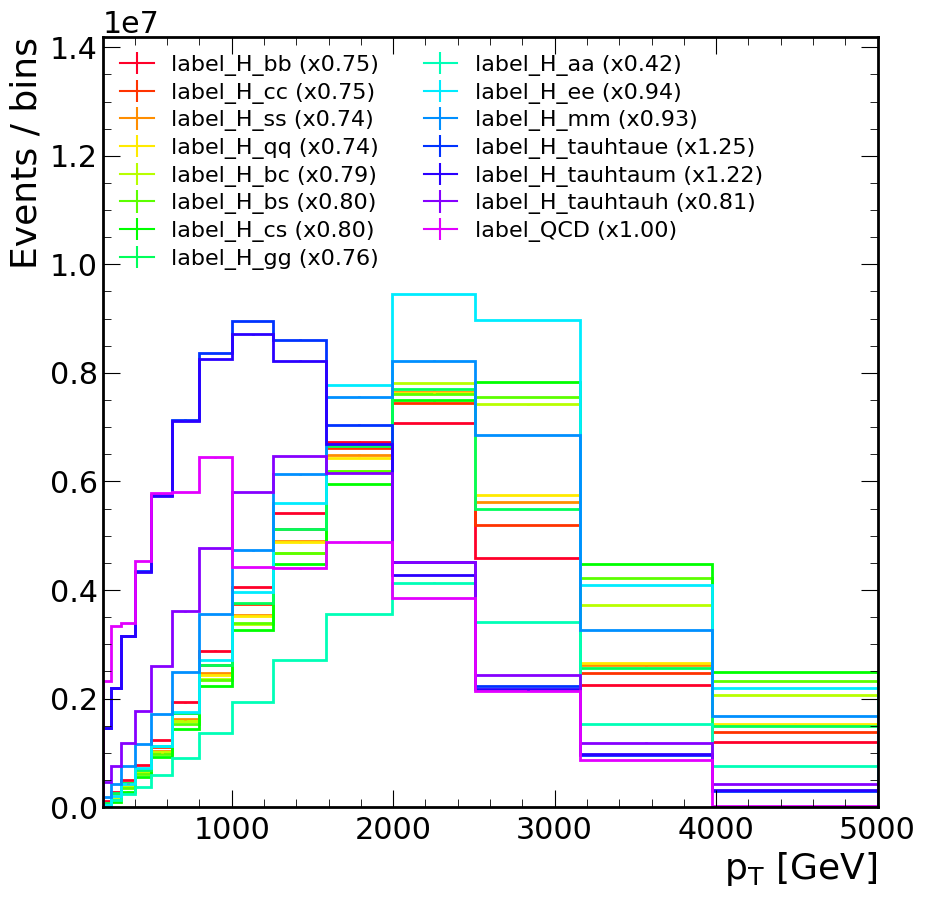

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the foll

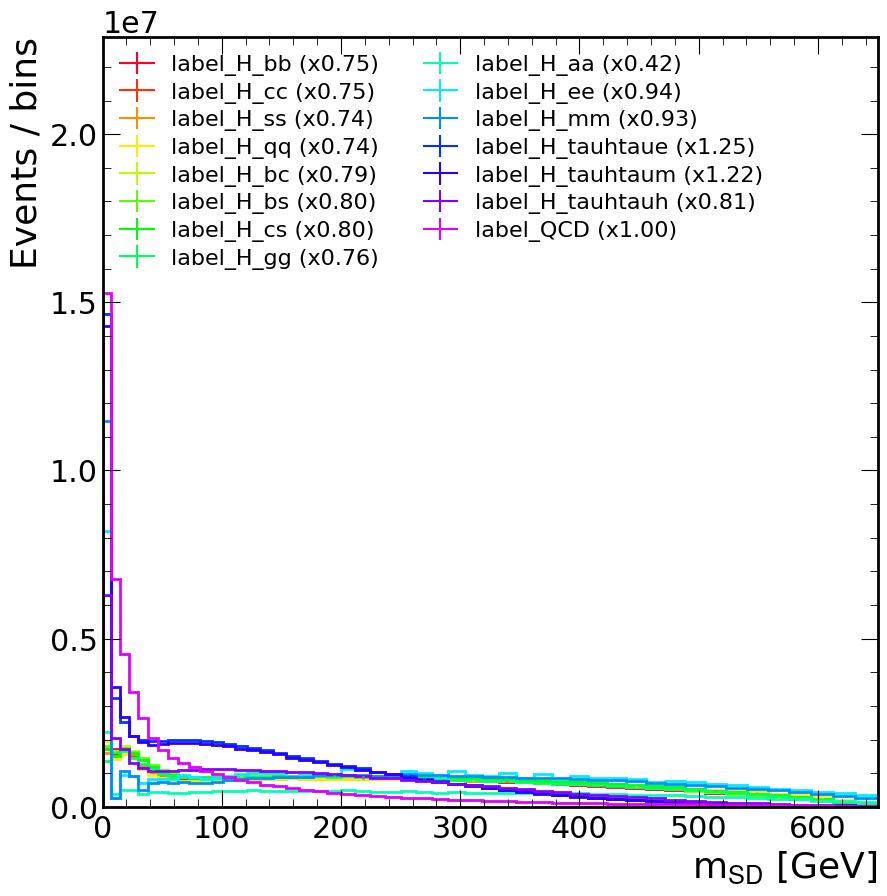

In [24]:
for p in range(2):
    if p == 0:
        nbin=bh.axis.Variable(np.logspace(np.log10(200), np.log10(5000), 15)); xmin=200; xmax=5000; xlabel=r'$p_T$ [GeV]'; axis=1
    elif p == 1:
        nbin=bh.axis.Variable([0, 7.1, 14.5, 22.1, 29.9, 38.0, 46.3, 54.9, 63.7, 72.7, 82.0, 91.5, 101.3, 111.3, 121.5, 132.0, 142.7, 153.7, 164.9, 176.3, 188.0, 199.9, 212.1, 224.5, 237.1, 250.0, 263.1, 276.5, 290.1, 303.9, 318.0, 332.3, 346.9, 361.7, 376.7, 392.0, 407.5, 423.3, 439.3, 455.5, 472.0, 488.7, 505.7, 522.9, 540.3, 558.0, 575.9, 594.1, 612.5, 631.1, 650.0]); xmin=0; xmax=650; xlabel=r'$m_{\mathrm{SD}}$ [GeV]'; axis=0

    hist = bh.Histogram(bh.axis.Regular(nbin, xmin, xmax) if isinstance(nbin, int) else nbin, storage=bh.storage.Weight())

    # rg = range(len(labels))
    # rg = list(range(0, 13)) + [108] # Top
    rg = list(range(13, 27)) + [108] # H->2prong
    # rg = list(range(27, 34)) + [108] # HWW
    # rg = list(range(34, 41)) + [108] # HWxWx
    # rg = list(range(41, 48)) + [108] # HWxWxStar
    # rg = list(range(48, 62)) + [108] # HZZ
    # rg = list(range(62, 70)) + [108] # HZxZx
    # rg = list(range(70, 76)) + [108] # HZxZxStar
    # rg = list(range(76, 90)) + [108] # HZxZxStar
    # rg = list(range(90, 108)) + [108] # HV(aaXX)
    NUM_COLORS = len(rg)
    cm = plt.get_cmap('gist_rainbow')
    mpl.rcParams['axes.prop_cycle'] = cycler(color=[cm(1.*i/NUM_COLORS) for i in range(NUM_COLORS)])

    f, ax = plt.subplots(figsize=(10, 10))
    max = 0
    for i in rg:
        lab = labels[i]
        content = hists[lab].sum(axis=axis)
        content = content / class_weight_default[i]
        yerr = np.sqrt(content)
        content_QCD = hists['label_QCD'].sum(axis=axis) / class_weight_default[labels.index('label_QCD')]
        ratio = content.sum() / content_QCD.sum()
        hep.histplot(content, bins=hist.axes[0].edges, yerr=yerr, label=lab+" (x{:.2f})".format(ratio), ax=ax, histtype='step', linewidth=2)
        # hep.histplot(content, bins=hist.axes[0].edges, yerr=yerr, label=lab)
        max = np.maximum(max, content.max())
    ax.legend(loc='upper left', prop={'size': 16}, ncol=2, labelspacing=0.3, borderpad=0.3)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, max*1.5)
    # if p == 1:
    #     ax.set_ylim(0, 1e7)
    ax.set_xlabel(xlabel, ha='right', x=1.0); ax.set_ylabel('Events / bins', ha='right', y=1.0);

# AK15 GLOpart

In [18]:
# my weights
labels = ['label_Top_bWQQ', 'label_Top_bWQ', 'label_Top_bWev', 'label_Top_bWmv', 'label_Top_bWtauev', 'label_Top_bWtaumv', 'label_Top_bWtauhv', 'label_Top_WQQ', 'label_Top_Wev', 'label_Top_Wmv', 'label_Top_Wtauev', 'label_Top_Wtaumv', 'label_Top_Wtauhv', 'label_H_bb', 'label_H_cc', 'label_H_ss', 'label_H_qq', 'label_H_bc', 'label_H_bs', 'label_H_cs', 'label_H_gg', 'label_H_aa', 'label_H_ee', 'label_H_mm', 'label_H_tauhtaue', 'label_H_tauhtaum', 'label_H_tauhtauh', 'label_H_WW_QQQQ', 'label_H_WW_QQQ', 'label_H_WW_QQev', 'label_H_WW_QQmv', 'label_H_WW_QQtauev', 'label_H_WW_QQtaumv', 'label_H_WW_QQtauhv', 'label_H_WxWx_QQQQ', 'label_H_WxWx_QQQ', 'label_H_WxWx_QQev', 'label_H_WxWx_QQmv', 'label_H_WxWx_QQtauev', 'label_H_WxWx_QQtaumv', 'label_H_WxWx_QQtauhv', 'label_H_WxWxStar_QQQQ', 'label_H_WxWxStar_QQQ', 'label_H_WxWxStar_QQev', 'label_H_WxWxStar_QQmv', 'label_H_WxWxStar_QQtauev', 'label_H_WxWxStar_QQtaumv', 'label_H_WxWxStar_QQtauhv', 'label_H_ZZ_QQQQ', 'label_H_ZZ_QQQ', 'label_H_ZZ_QQee', 'label_H_ZZ_QQmm', 'label_H_ZZ_QQe', 'label_H_ZZ_QQm', 'label_H_ZZ_Qee', 'label_H_ZZ_Qmm', 'label_H_ZZ_QQtauhtaue', 'label_H_ZZ_QQtauhtaum', 'label_H_ZZ_QQtauhtauh', 'label_H_ZZ_Qtauhtaue', 'label_H_ZZ_Qtauhtaum', 'label_H_ZZ_Qtauhtauh', 'label_H_ZxZx_QQQQ', 'label_H_ZxZx_QQQ', 'label_H_ZxZx_QQee', 'label_H_ZxZx_QQmm', 'label_H_ZxZx_QQe', 'label_H_ZxZx_QQm', 'label_H_ZxZx_Qee', 'label_H_ZxZx_Qmm', 'label_H_ZxZx_QQtauhtaue', 'label_H_ZxZx_QQtauhtaum', 'label_H_ZxZx_QQtauhtauh', 'label_H_ZxZx_Qtauhtaue', 'label_H_ZxZx_Qtauhtaum', 'label_H_ZxZx_Qtauhtauh', 'label_H_ZxZxStar_QQQQ', 'label_H_ZxZxStar_QQQ', 'label_H_ZxZxStar_QQee', 'label_H_ZxZxStar_QQmm', 'label_H_ZxZxStar_QQe', 'label_H_ZxZxStar_QQm', 'label_H_ZxZxStar_Qee', 'label_H_ZxZxStar_Qmm', 'label_H_ZxZxStar_QQtauhtaue', 'label_H_ZxZxStar_QQtauhtaum', 'label_H_ZxZxStar_QQtauhtauh', 'label_H_ZxZxStar_Qtauhtaue', 'label_H_ZxZxStar_Qtauhtaum', 'label_H_ZxZxStar_Qtauhtauh', 'label_H_HV_aaQQ', 'label_H_HV_aaee', 'label_H_HV_aamm', 'label_H_HV_aatauhtaue', 'label_H_HV_aatauhtaum', 'label_H_HV_aatauhtauh', 'label_H_HV_aaQ', 'label_H_HV_aae', 'label_H_HV_aam', 'label_H_HV_aataue', 'label_H_HV_aataum', 'label_H_HV_aatauh', 'label_H_HV_aQQ', 'label_H_HV_aee', 'label_H_HV_amm', 'label_H_HV_atauhtaue', 'label_H_HV_atauhtaum', 'label_H_HV_atauhtauh', 'label_QCD']
class_weight = [        0.4, 0.09, 0.12, 0.12, 0.01, 0.01, 0.035,
        0.024, 0.0025, 0.0025, 0.0005, 0.0005, 0.0015,
        0.16, 0.16, 0.16, 0.16, 0.16, 0.16, 0.16, 0.16, 0.06, 0.06, 0.06, 0.04, 0.04, 0.12,
        0.16, 0.04, 0.1, 0.1, 0.015, 0.015, 0.07,
        0.08, 0.02, 0.05, 0.05, 0.0075, 0.0075, 0.035, 
        0.08, 0.02, 0.05, 0.05, 0.0075, 0.0075, 0.035, 
        0.16, 0.04, 0.08, 0.08, 0.012, 0.012, 0.016, 0.016, 0.016, 0.016, 0.048, 0.0008, 0.0008, 0.0024,
        0.08, 0.02, 0.04, 0.04, 0.006, 0.006, 0.008, 0.008, 0.008, 0.008, 0.024, 0.0004, 0.0004, 0.0012,
        0.08, 0.02, 0.04, 0.04, 0.006, 0.006, 0.008, 0.008, 0.008, 0.008, 0.024, 0.0004, 0.0004, 0.0012,
        0.4, 0.08, 0.08, 0.01, 0.01, 0.03, 0.04, 0.04, 0.04, 0.004, 0.004, 0.012, 0.04, 0.006, 0.006, 0.0005, 0.0005, 0.0015,
        1, ]
hists = {}
unweighted_histo_text = '''[2025-11-19 03:47:46,122] INFO: label_Top_bWQQ (unweighted):
 [[ 3022  4507  5898  5555  4901  4570  4641  4794  4922  4768  5015  5022
   5298  5475  5631  6003  5897  5587  5023  4720  3761  3221  2337  1619
   1057   618   309   123    43    18     4     1     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5463  7586  9640  9231  8232  7472  7734  7676  7899  7993  7989  7998
   8011  8284  8368  8833  9160  9321  9551  9563  9240  9065  8238  7688
   6544  5510  4376  3119  2075  1371   722   387   184    79    29     8
      4     1     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 8471 10557 13395 12735 11230 10603 10821 10910 11029 11306 11385 11409
  11596 11573 11720 11915 12369 12230 12821 13300 13743 14539 14730 15021
  15559 14708 13571 12126 10279  8694  7139  5491  4019  2771  1941  1179
    710   345   174    77    34    14     4     2     0     0     0     0
      0     0]
 [11805 13674 17004 16330 14876 14130 14150 14318 14615 14864 14934 15089
  15289 15335 16020 16073 16444 16670 16951 17317 18085 19028 19726 20870
  22180 22889 23049 22521 21358 19980 18249 16617 14641 12600 10755  8936
   7125  5552  4144  2933  2001  1302   792   461   300   129    91    34
     11     8]
 [16248 17717 20929 20127 18690 17763 18355 18547 18846 19152 19432 19834
  19893 20521 20975 21700 21983 22296 22513 22800 23599 24751 25819 27673
  29231 30285 30434 29911 29698 29048 28265 27317 26392 24395 22869 20687
  19006 17118 14872 12868 11040  9260  7548  5947  4619  3295  2469  1699
   1154   735]
 [21074 22341 25692 24198 22474 21883 22754 23135 23220 23688 23944 24482
  25212 25496 26284 27176 28017 28061 28458 29764 29847 31009 32654 34517
  36592 37231 37243 36839 36044 35520 34442 33813 33040 32023 31540 30290
  29403 27772 25944 24270 22524 20809 18762 16667 14712 12323 10577  8752
   7202  5798]
 [25342 26783 30805 28947 26164 25705 26210 27108 28494 28851 28897 29880
  30143 30599 31681 32156 33560 34529 35284 36020 36997 38007 39959 42202
  45137 45946 45578 44461 42919 42279 40867 40097 38641 37383 36434 35414
  34618 33923 32735 31523 30240 29043 27411 25898 24017 21329 19506 17280
  15451 13567]
 [28549 30575 35374 33513 29998 28451 29030 29871 31423 33477 33997 35098
  35402 36112 37163 38067 38773 39293 40262 41606 42709 43895 46290 48709
  52255 53702 53565 52469 50922 49219 47360 46348 44480 42893 41243 40080
  38683 37142 35786 35124 33389 32444 31194 29252 27655 26059 24181 22103
  20256 18988]
 [29958 32149 38193 36979 32868 30957 31580 32068 33305 35029 36604 38528
  39862 40357 41674 42222 43078 43715 44400 45936 46890 48132 50538 53346
  56996 58885 59281 58028 56259 55633 53252 51947 49648 48028 46682 44270
  42783 41325 39283 37701 35648 34184 32101 30096 28237 25859 23688 21603
  19983 18315]
 [29078 29696 37077 39008 35647 32115 31809 32441 33313 34920 35785 37828
  38955 40746 42339 43846 45365 45964 46894 47825 48319 50091 51806 55096
  58943 60596 61118 60129 58957 57669 55887 55182 52697 50901 49079 47165
  45534 43998 41557 39727 37779 36180 33644 31526 28885 25846 23646 20190
  17433 15879]
 [22650 20614 25768 30704 30934 27490 25610 25639 26038 27413 28348 29498
  30826 31968 33440 35129 37374 39040 39865 41284 41865 43757 45058 48238
  52851 54824 56072 55801 55491 54860 53529 52592 50882 49297 47895 46069
  44400 42633 40588 38856 36962 35706 33430 30919 28326 25683 22201 18637
  15208 12997]
 [ 9990  6846  7968 10269 11531 10553  8956  8223  8342  8704  9349 10225
  11123 11935 13453 14642 15865 17543 18680 20526 21609 23093 23890 25923
  29092 32048 34824 37931 40114 41039 41814 42013 41646 40718 40082 39187
  37530 36099 34375 32976 31228 30275 28039 26381 24183 21633 18605 14823
  11152  8735]
 [ 3521  1771  1764  2338  2882  3110  2800  2201  1968  1852  1984  2342
   2677  2995  3503  4107  4644  5411  6028  6904  7783  8407  9467 10228
  11207 11934 12610 13389 14644 16353 18120 20245 22281 23541 24859 25547
  25553 25835 25846 25770 24910 24240 23444 21924 20173 17842 14855 11460
   8041  5816]
 [ 1369   754   631   673   864  1063  1167  1205   970   863   769   853
    823   900  1091  1247  1425  1544  1759  2097  2345  2626  2915  3206
   3606  3986  4347  4663  5002  5215  5580  5628  5846  6080  6647  7283
   8292  9424 10278 11573 12804 13510 14338 14658 14543 13603 11758  9176
   6168  3887]]
[2025-11-19 03:48:06,737] INFO: label_Top_bWQ (unweighted):
 [[ 3700  1135  1016  1251  1524  1825  2509  3025  3625  4258  4682  5158
   5921  6563  7319  7953  8282  8417  7860  7045  5801  4487  3321  2099
   1306   678   332   150    51    16     7     3     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4732  1364  1217  1336  1629  2052  2558  3190  3643  4520  5109  5634
   6464  6967  7574  8243  9015  9964 10296 10519 10655 10310  9408  8196
   6936  5484  4008  2869  1950  1172   686   350   155    69    28     4
      1     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5660  1553  1238  1372  1692  1930  2427  2923  3552  4258  4938  5643
   6344  7061  7529  8029  8680  9141  9581 10212 10840 11276 11484 11496
  10815 10372  9639  8537  7442  6195  4950  3794  2762  1898  1270   798
    467   270   121    56    23    10     1     0     1     0     0     0
      0     0]
 [ 6125  1778  1250  1319  1565  1851  2211  2453  3044  3581  4213  5021
   5520  6284  6861  7373  7953  8434  8811  9001  9242  9658  9955  9775
  10391 10453 10600 10193  9808  9408  8702  7831  7032  6036  5329  4306
   3567  2581  2002  1461   968   659   414   245   144    60    34    11
      7     3]
 [ 6496  2173  1193  1253  1431  1611  1806  2261  2627  3052  3519  4120
   4702  5377  5954  6387  6934  7333  7804  8029  8199  8402  8401  8365
   8279  8266  8414  8313  8269  8073  8067  8020  7652  7266  7085  6318
   5772  5200  4739  4227  3580  3036  2465  2047  1559  1235   889   575
    383   283]
 [ 6244  2614  1161  1114  1256  1402  1597  1804  2284  2456  2925  3230
   3722  4130  4789  5070  5762  6075  6337  6593  6919  7005  6977  6932
   6925  6825  6757  6616  6401  6220  6217  6002  5963  5685  5613  5475
   5272  5191  4840  4658  4465  4094  3781  3537  3120  2836  2472  2147
   1888  1656]
 [ 5341  2950  1373  1058  1052  1175  1399  1525  1727  1995  2283  2612
   2866  3228  3579  3883  4358  4648  4953  5290  5442  5668  5644  5864
   5665  5607  5442  5239  5132  4907  4779  4529  4425  4225  4028  3947
   3822  3710  3648  3455  3437  3331  3289  3197  3052  3023  2764  2730
   2575  2395]
 [ 4027  2625  1602   967   840   921   955  1202  1331  1564  1832  1977
   2239  2297  2745  2951  3168  3458  3645  3826  3932  4236  4384  4415
   4324  4326  4155  4164  3879  3812  3692  3395  3293  3134  3047  2681
   2574  2429  2369  2221  2212  2094  2058  2067  2078  2118  2101  2113
   2119  2059]
 [ 2599  1915  1771   962   734   663   722   853   914  1139  1334  1468
   1617  1769  2004  2104  2363  2460  2580  2733  2795  2909  3042  3115
   3060  3087  3107  2888  2929  2824  2696  2554  2419  2212  2114  1917
   1846  1722  1575  1395  1345  1310  1223  1274  1265  1243  1217  1283
   1242  1271]
 [ 1782  1211  1458  1149   616   522   534   622   670   703   842   968
   1117  1306  1394  1495  1674  1782  1858  1903  2038  2109  2061  2232
   2166  2153  1995  2069  2098  1974  1820  1860  1676  1637  1499  1366
   1255  1200  1054   997   880   837   776   779   729   735   724   755
    751   771]
 [ 1053   612   859   893   665   464   355   404   401   444   526   600
    683   744   828   953  1089  1130  1179  1241  1300  1372  1435  1410
   1376  1396  1320  1458  1317  1279  1319  1206  1153  1050   996   916
    864   768   687   621   602   567   490   473   420   401   417   411
    443   453]
 [  536   299   339   428   490   379   262   212   203   191   240   264
    314   369   365   419   530   512   583   662   728   760   858   813
    878   866   837   772   792   788   743   705   682   612   610   527
    469   412   393   358   317   297   266   226   241   208   203   215
    187   208]
 [  196   120   100   141   183   188   171   140    91    84    80    78
     91   116   129   167   166   187   198   248   248   274   328   354
    368   358   398   410   431   405   433   383   384   356   346   270
    240   241   229   169   147   150   133   109   119   100    84    76
    105   107]
 [   70    31    28    24    36    50    42    68    55    46    24    22
     35    33    37    45    56    38    47    64    72    79    97    85
     88   111   107   143   127   155   155   145   145   157   147   127
    111    97   108    86    71    76    52    35    39    29    35    34
     20    26]]
[2025-11-19 03:48:27,010] INFO: label_Top_bWev (unweighted):
 [[16328  9548  9485  9260  9240  9499  9842 10111 10440 10404 10886 11124
  11305 11735 11921 11641 11079 10203  8653  7173  5694  4117  2668  1616
    899   462   185    69    30     9     3     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [24136 12412 12636 12144 12237 12096 12581 13061 13233 13642 13752 14029
  14206 14066 14300 14363 14732 14667 14136 13372 12266 10856  9281  7618
   6269  4682  3242  2155  1221   735   393   212    78    29    14     4
      2     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [33763 15385 15502 14602 14656 14746 14964 15629 16058 16576 16802 16829
  17194 16878 16880 16703 16740 16570 16528 16481 16347 15861 15358 14344
  13059 11689 10346  8783  7100  5855  4295  3100  2175  1482   798   514
    268   159    68    21    16     3     1     1     0     0     0     0
      0     0]
 [44398 18779 18374 17250 17311 17768 17547 18028 18384 18977 19237 19876
  20151 19736 20032 19286 19094 18816 18424 18233 17715 17819 17717 17498
  16923 16392 15733 14452 13299 12262 10959  9888  8385  7044  5847  4511
   3504  2620  1873  1245   785   497   263   172    82    52    27    10
      4     2]
 [56139 22187 21178 19507 19234 19497 20414 20711 20768 21490 21582 22316
  22475 22412 22691 22079 21969 21261 20982 20078 19518 19181 18469 17932
  17817 17548 17266 16674 16680 16169 15308 14876 13419 12830 11525 10353
   9408  8212  7235  6287  4937  4358  3427  2763  1995  1454   947   665
    409   240]
 [66308 25683 23377 21280 20853 20717 21902 22252 22763 23211 23410 23871
  23978 24395 24432 23853 23649 23484 22438 21913 21270 20810 19589 18925
  18463 17977 17082 16636 16376 15741 15556 15365 15084 14587 14358 13807
  13193 12362 11636 10857  9864  8986  8241  7437  6978  5903  5261  4424
   3725  3020]
 [73442 27562 25084 22556 21767 21473 21834 22635 23438 24493 24360 24896
  25044 24850 25132 24856 24619 24147 23513 23276 22639 21727 20984 19954
  19526 18187 17733 16914 16035 15605 15129 14567 13963 13862 13439 13306
  12889 12731 12552 12360 11994 11749 11331 10462 10208  9514  8947  8480
   8000  7352]
 [75319 27270 24741 22232 21007 20903 21413 21462 21938 22966 23672 24383
  24623 24627 24428 23930 23792 23527 23036 22676 22277 22044 20801 20105
  19358 18397 17658 16968 16155 15203 14518 13594 12964 12568 12145 11561
  11124 10926 10617 10504 10458 10289 10447 10208 10086 10067 10148  9775
   9593  9335]
 [70070 23942 22550 20174 18785 18382 18784 19019 18876 19873 20132 21099
  21832 22228 22465 22055 21819 21486 20978 21046 20304 20061 19663 18853
  18111 17226 16896 16046 15207 14576 13437 12822 12126 11590 10826  9992
   9449  9210  8674  8349  8122  7912  7759  7884  7741  7795  7757  7843
   7856  7902]
 [57662 17492 17103 16061 14585 13833 13785 14171 14256 14739 15175 15687
  15887 16674 17280 17266 17501 17477 17295 17147 17221 16514 16626 16069
  15919 15209 14699 14046 13143 12554 12088 11241 10418  9849  9109  8442
   8019  7376  6883  6463  6145  5841  5657  5580  5409  5279  5260  5193
   5361  5344]
 [37675  9088  8759  8915  8596  7801  7506  7568  7736  8224  8563  9009
   9098  9356  9782  9644 10350 10651 10884 11318 11287 11854 11633 11559
  11216 11235 10791 10643 10422  9650  9250  8863  8340  7618  7051  6403
   6038  5382  4951  4542  4127  3812  3521  3349  3153  3172  2953  2958
   2958  2957]
 [16485  2289  2258  2622  2917  2715  2317  2215  2250  2372  2597  2880
   3109  3299  3548  3811  4085  4175  4390  4707  5004  5509  5957  6039
   6373  6447  6466  6383  6368  6219  5893  5823  5340  5082  4723  4220
   3929  3607  3218  2703  2446  2114  1863  1709  1477  1451  1297  1334
   1243  1248]
 [ 6444   516   486   648   828   924   839   737   671   671   719   797
    773   992  1122  1232  1313  1445  1545  1681  1795  1871  2083  2220
   2383  2558  2702  2836  2922  3029  2946  2974  3001  2782  2709  2491
   2347  2177  1970  1678  1443  1282  1033   934   735   652   569   533
    487   493]
 [ 1871   112   105   123   142   183   198   230   181   200   178   184
    204   237   278   261   343   340   407   425   499   531   531   576
    555   582   607   665   695   759   807   879   854   886   929   850
    870   788   706   638   613   543   425   363   317   256   210   164
    126   134]]
[2025-11-19 03:48:46,358] INFO: label_Top_bWmv (unweighted):
 [[19120 11260 10498  9536  9300  9665 10265 10443 10374 10624 10820 11211
  11434 11727 12178 11754 11544 10412  8806  7435  5638  4195  2735  1663
    888   395   196    77    25     7     1     1     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [27111 14694 14131 12906 12508 12523 12711 13201 13652 13770 14190 14201
  14017 14357 14385 14550 15008 14725 14391 13691 12610 11322  9479  7749
   6363  4635  3291  2112  1274   752   398   206    84    36    11     5
      1     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [36972 18510 17387 15628 15397 15632 15267 15677 16238 16729 17189 17466
  17196 17380 16988 16796 16957 16699 16599 17115 16626 16367 15402 14334
  13266 11779 10449  8780  7198  5846  4504  3218  2166  1431   904   525
    262   162    59    32     8     4     0     0     0     0     0     0
      0     0]
 [47874 22841 20700 18774 18464 17853 17976 18338 18699 19578 19706 20184
  20658 20202 19886 19844 19453 18870 18643 18462 17991 17973 17828 17666
  17326 16557 16011 14979 13660 12599 10958  9717  8360  7033  5795  4534
   3514  2704  1914  1317   803   524   296   194    95    43    21    12
      7     2]
 [59040 27097 23897 21663 21175 20649 20939 21055 20986 21652 22030 22489
  22917 23125 22560 22717 22372 21619 21176 20441 20028 19461 18920 18433
  18362 17737 17797 17305 16838 16572 15463 14908 13868 12840 11985 10561
   9690  8391  7528  6312  5415  4511  3501  2687  2006  1490   995   669
    423   292]
 [67243 31794 26690 23516 23063 22832 22874 22619 22965 23278 23780 24127
  24443 24433 24688 24443 24229 23729 23024 22298 21470 21106 20091 19182
  18813 18212 17629 16870 16795 16539 16169 15841 15452 15046 14646 14069
  13448 12486 11767 11054 10398  9513  8654  7686  7091  6207  5462  4684
   3926  3169]
 [71503 34504 28315 24383 23848 23401 23631 23854 23965 24394 24678 25185
  25318 25071 25394 25044 24951 24300 24033 23541 22842 22227 21109 20309
  19535 18724 18029 17283 16501 15836 15224 14902 14379 13948 13843 13630
  13521 13385 12983 12776 12594 12075 11488 11023 10331 10091  9425  8948
   8092  7555]
 [67755 32736 29187 23198 21917 21627 21877 22464 22773 23322 23692 24106
  24056 24213 24434 23901 24038 23594 23424 22956 22306 21941 21195 20346
  19394 18665 17783 17046 16014 14990 14546 13891 13218 12511 12143 11843
  11258 11142 10836 10658 10571 10617 10513 10348 10485 10307 10363 10207
   9893  9707]
 [58105 24394 27660 21171 18352 17884 18136 18437 18904 19730 20530 20940
  21323 21343 21375 21546 21295 21136 20723 20838 20021 20022 19534 18987
  18331 17645 16675 15792 15261 14220 13612 12818 12000 11376 10781 10108
   9675  9110  8555  8428  8170  7851  8002  7728  7900  7827  7947  8086
   8079  8164]
 [42657 14212 19025 17636 13611 12031 12299 12451 12798 13305 13724 14696
  15209 15719 16038 15895 16459 16417 16367 16048 16180 16151 15926 15565
  15252 14812 14144 13578 13114 12716 11688 11111 10167  9526  8857  8292
   7662  7262  6565  6356  5964  5786  5417  5240  5282  5247  5161  5172
   5073  5177]
 [24870  5569  8262  9768  8269  6467  5655  5728  6019  6445  6788  7107
   7628  7921  8650  9050  9124  9477  9691 10185 10282 10589 10518 10594
  10580 10350 10320  9702  9502  9128  8667  8334  7815  7092  6620  6033
   5468  5096  4641  4149  3795  3590  3295  3095  2915  2845  2761  2762
   2750  2804]
 [10926  1452  2036  2631  2944  2419  1784  1457  1503  1687  1856  1948
   2130  2398  2695  2903  3237  3587  3907  4245  4580  4772  5133  5247
   5365  5617  5645  5788  5788  5559  5405  5125  4959  4646  4430  3866
   3680  3259  2833  2443  2162  1863  1755  1504  1329  1264  1234  1141
   1147  1200]
 [ 4460   379   460   616   772   922   790   571   448   397   434   433
    515   590   720   752   915   988  1128  1324  1375  1524  1685  1815
   1996  2095  2269  2362  2447  2460  2667  2517  2510  2476  2314  2312
   2043  1853  1667  1483  1315  1141   961   796   684   571   508   468
    434   452]
 [ 1158    92    80    90   127   162   170   175   157   122   101    95
    106   109   140   140   181   190   205   219   203   273   308   344
    378   462   467   474   573   576   651   625   647   706   666   678
    636   631   586   560   458   438   376   284   234   220   161   133
    105    88]]
[2025-11-19 03:49:05,277] INFO: label_Top_bWtauev (unweighted):
 [[ 6978  3571  2863  2718  2619  2650  2781  2811  2800  2792  2815  2792
   2796  2809  2890  2725  2633  2300  1978  1518  1301   968   610   391
    210   103    53    18     7     1     1     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 9719  4466  3488  3294  3220  3201  3420  3271  3391  3225  3287  3361
   3181  3229  3205  3021  3007  3063  2962  2743  2565  2304  1980  1606
   1213   921   695   415   284   144    83    41    14     4     1     2
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [12757  5369  4026  3725  3708  3643  3820  3789  3730  3809  3710  3678
   3620  3415  3369  3300  3251  3139  3090  3236  3165  3033  2949  2593
   2492  2190  2012  1618  1392  1120   813   611   419   289   147    89
     58    31    13     2     2     1     1     0     0     0     0     0
      0     0]
 [15272  6439  4524  4120  4220  4179  4145  4118  4230  4114  4050  4089
   3991  3741  3589  3442  3385  3259  3166  3130  3228  3060  2988  2976
   2966  2927  2823  2524  2355  2268  1945  1835  1552  1316  1139   874
    689   530   350   231   190    92    51    27    19    12     4     2
      0     0]
 [16992  7614  4913  4342  4306  4326  4540  4345  4353  4310  4241  4158
   4146  4014  3792  3743  3607  3405  3248  3150  3025  2981  2901  2864
   2889  2876  2958  2753  2754  2706  2707  2555  2412  2267  2080  1934
   1781  1583  1362  1203  1049   819   617   508   376   267   183   139
     62    56]
 [16609  8904  5171  4317  4407  4394  4466  4508  4427  4321  4221  4247
   4148  3927  3879  3813  3632  3413  3232  3126  2820  2941  2707  2674
   2546  2404  2422  2436  2425  2363  2394  2503  2483  2515  2407  2308
   2262  2237  2055  1973  1826  1711  1632  1401  1331  1190  1006   932
    767   603]
 [15151  9274  5631  4237  4090  4020  4049  4149  4163  4205  4161  3929
   3886  3799  3735  3583  3434  3321  3163  3034  2965  2816  2655  2474
   2439  2263  2206  2079  2058  1993  2027  2055  2042  1980  2059  1952
   2021  2114  2085  2048  2066  2046  1931  1828  1864  1704  1614  1668
   1464  1423]
 [11798  8384  5778  3847  3440  3273  3352  3446  3545  3681  3620  3564
   3584  3441  3307  3234  3053  2919  2806  2661  2584  2455  2436  2237
   2145  1989  1932  1825  1764  1703  1598  1570  1493  1552  1517  1501
   1518  1541  1544  1582  1611  1579  1661  1638  1626  1673  1653  1569
   1629  1541]
 [ 8282  6040  5577  3447  2596  2434  2487  2550  2521  2633  2751  2762
   2766  2710  2715  2610  2418  2402  2333  2170  2107  2110  2028  1823
   1784  1655  1583  1439  1488  1284  1253  1227  1131  1089  1058  1051
   1098  1050  1060  1088  1054  1056  1052  1122  1079  1110  1137  1151
   1170  1207]
 [ 4866  3172  3822  2952  1931  1467  1421  1429  1470  1458  1609  1678
   1710  1773  1792  1827  1780  1743  1668  1619  1516  1453  1433  1346
   1338  1219  1160  1023  1037   967   875   873   790   735   673   680
    717   679   635   641   626   607   616   591   663   641   616   685
    644   671]
 [ 2156  1262  1520  1758  1338   838   631   584   605   588   649   719
    748   755   791   877   867   906   982   912   917   926   889   809
    821   745   744   707   621   586   543   507   428   415   388   393
    311   306   323   281   306   286   307   301   310   296   288   295
    310   338]
 [  831   342   429   552   659   524   294   204   152   166   195   188
    234   198   245   270   284   301   370   345   415   400   447   437
    397   375   402   335   326   324   262   250   218   211   180   156
    164   134   139   119   120   104   104   116   101   106   108   120
    126   128]
 [  289   120   112   131   182   179   173   121    64    65    34    55
     61    56    60    81    72    79    87    94    97   113   112   153
    133   127   146   172   127   122   125   122   130    91    90    62
     74    64    52    54    43    33    34    32    34    27    31    39
     36    34]
 [   39    13    12    22    29    22    29    34    22    15    14     7
      8    17     6     3    10     6     9     9     8     8    14    12
     10    20    10    21    23    23    27    17    22    26    15    19
     14    14    10     6    10    11     5     4     5     5     4     3
      3     7]]
[2025-11-19 03:49:24,272] INFO: label_Top_bWtaumv (unweighted):
 [[ 6831  3676  2921  2679  2568  2736  2881  2801  2766  2845  2822  2761
   2751  2820  2824  2683  2621  2368  1949  1594  1241   919   655   356
    191   115    45    24     5     0     1     0     1     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 9422  4510  3565  3250  3237  3150  3335  3348  3302  3268  3187  3300
   3313  3049  3037  3044  3074  3044  2969  2745  2476  2276  1947  1628
   1247   964   687   422   256   133    72    42    15     3     1     3
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [12123  5583  4134  3901  3732  3578  3761  3701  3916  3859  3832  3708
   3416  3282  3266  3299  3230  3221  3130  3134  3148  3086  2865  2641
   2495  2228  1935  1682  1364  1110   831   648   406   298   168   103
     56    31     8     9     4     1     1     0     0     0     0     0
      0     0]
 [14741  6539  4675  4129  4144  4033  4050  4126  4104  4106  4035  4044
   3849  3741  3643  3503  3432  3285  3153  3066  2919  3015  2950  2992
   2988  2844  2750  2695  2327  2244  2025  1748  1544  1238  1095   899
    705   497   341   213   133    91    60    34    16    15     2     0
      1     0]
 [16423  7896  5282  4673  4343  4319  4332  4394  4210  4149  4216  4148
   4004  4040  3854  3633  3522  3328  3201  3179  2890  2950  2932  2874
   2879  2804  2743  2796  2762  2753  2548  2530  2423  2270  2045  1910
   1625  1590  1335  1212  1039   887   684   498   384   275   205   122
     70    44]
 [16469  9372  5207  4513  4291  4207  4196  4116  4160  4168  4236  4058
   4056  3875  3866  3665  3442  3434  3335  3081  2987  2825  2648  2624
   2502  2534  2464  2467  2395  2410  2419  2518  2497  2474  2309  2358
   2197  2165  2104  1922  1797  1729  1568  1495  1339  1135  1055   893
    722   628]
 [14729 10261  5604  4358  3982  3864  3812  3898  3913  3800  3819  3738
   3757  3681  3650  3512  3355  3145  3185  2995  2822  2730  2626  2494
   2302  2218  2222  1989  1997  2047  2030  1974  1947  2000  2076  2074
   2047  2005  2046  2079  2073  2072  1891  1929  1806  1715  1681  1595
   1410  1378]
 [11351  9158  6328  3733  3290  3069  3083  3127  3188  3240  3198  3221
   3244  3284  3084  3005  2944  2860  2754  2733  2527  2422  2339  2230
   2093  1904  1904  1760  1721  1646  1571  1555  1531  1526  1522  1491
   1524  1438  1509  1561  1646  1563  1615  1666  1659  1662  1708  1564
   1585  1561]
 [ 7571  6395  6220  3452  2460  2236  2184  2209  2225  2271  2330  2375
   2478  2411  2486  2288  2308  2250  2196  2146  2109  1935  1867  1825
   1696  1582  1550  1488  1280  1286  1194  1119  1154  1072  1053  1014
    971  1025  1041  1064  1002  1061   982  1075  1105  1078  1083  1178
   1140  1209]
 [ 4264  3236  4296  3353  1892  1292  1220  1213  1191  1268  1304  1348
   1484  1414  1538  1513  1536  1498  1487  1472  1442  1382  1325  1329
   1178  1157  1018   985   918   916   850   788   739   693   675   662
    651   638   620   608   592   594   563   595   615   635   652   675
    633   631]
 [ 1998  1203  1731  2041  1513   796   554   453   489   487   543   581
    561   639   685   659   735   768   809   767   743   763   759   749
    675   704   616   662   592   530   480   461   452   420   391   392
    323   307   311   327   261   292   288   291   307   269   285   280
    275   294]
 [  703   353   456   668   777   552   317   190   154   155   164   175
    187   221   196   239   264   278   279   288   345   350   337   345
    357   334   354   305   271   261   259   250   257   187   199   162
    140   110   108   128   129    99   123    83    96   110    83   107
    110   101]
 [  196    95    95   167   236   251   214   128    69    57    45    35
     40    51    44    50    76    65    58    79    92    79    69    77
    104    91   118   105    90   106   102   103    89    95    87    72
     63    54    45    28    44    46    34    27    31    25    36    34
     26    31]
 [   35    13    22    21    28    27    30    31    15    16    10     1
      7     4     6     5     9     6    11     5    11    11     8     6
     11    15    12    12    13    12    11    21     7    13    15    18
     12     9     7    14     7     4     5     3     4     5     4     3
      4     4]]
[2025-11-19 03:49:44,049] INFO: label_Top_bWtauhv (unweighted):
 [[18363 10961  9203  8532  8836  9046  9290  9629  9706  9536  9815  9698
   9579  9873 10054  9736  9178  8071  7089  5802  4449  3239  2129  1301
    715   371   155    53    22     4     3     0     1     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [26068 13717 11541 10742 10697 10792 11302 11607 11668 11783 11638 11560
  11457 11252 11155 11208 11304 11117 10948 10075  9147  8104  6929  5690
   4561  3439  2461  1620   953   530   287   148    67    20    10     3
      1     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [34047 16895 13552 12787 12609 12521 12759 12965 13440 13631 13576 13439
  13005 12873 12593 12092 12146 11813 11572 11753 11426 11282 10586  9897
   9052  8032  7007  6020  5063  4024  3124  2195  1542   992   613   338
    180   102    47    18     8     4     0     1     0     0     0     0
      0     0]
 [42158 20552 15490 14237 14383 14181 14361 14623 14798 15351 15327 15423
  14829 14378 13870 13512 13017 12735 12200 12041 11783 11630 11681 11354
  11191 10642 10334  9648  8865  8212  7371  6469  5712  4821  3978  3179
   2442  1857  1335   849   617   352   186   123    52    24    10     4
      8     0]
 [48610 24809 17458 15324 15389 15335 15486 15267 15837 15982 16053 16069
  16319 15640 15544 14548 14222 13268 12996 12393 11985 11625 11387 10975
  10876 10955 10616 10480 10349 10070  9864  9247  8622  8299  7636  6814
   6229  5481  4871  4211  3613  3024  2320  1867  1438  1082   705   453
    297   195]
 [50081 28690 18705 15751 15512 15647 16143 16119 16086 16230 16062 16505
  16224 15904 15755 15565 15018 14188 13437 12869 12155 11856 11268 10647
  10459 10109  9614  9493  9548  9355  9232  9443  9239  9044  8820  8854
   8339  8030  7575  7262  6586  6283  5747  5290  4735  4167  3695  3169
   2704  2177]
 [46691 31661 19749 15511 14812 14792 15564 15555 15809 15718 15744 15810
  15394 15266 15143 14889 14725 14484 13638 13039 12463 11892 11264 10530
  10109  9720  9291  8935  8413  8204  8034  7974  7885  7732  7827  7857
   7775  7895  7773  7868  7724  7402  7170  6894  6733  6457  6105  5695
   5364  5032]
 [38325 29957 21559 14575 13182 12765 13077 13337 13895 14327 14271 14231
  13896 13674 13728 13594 13282 12870 12412 12281 11578 11322 10788 10125
   9527  8847  8361  7937  7594  7220  6904  6699  6435  6188  6213  5851
   6104  5937  6099  6027  6152  6263  6325  6315  6426  6338  6263  6214
   6117  6008]
 [27491 21815 21476 13613 10397  9674  9705 10000 10224 10708 11035 11163
  11331 11200 11253 10791 10924 10472 10433 10269 10025  9578  9181  8649
   8503  7978  7530  6967  6418  6066  5726  5498  5196  4882  4693  4389
   4478  4419  4239  4240  4220  4325  4412  4410  4332  4510  4429  4599
   4673  4700]
 [16401 11782 14448 12297  7736  6038  5924  5829  6307  6398  6638  6882
   7228  7430  7599  7724  7940  7652  7506  7582  7261  7236  6926  6794
   6369  6141  5929  5502  5031  4843  4431  4099  3872  3557  3435  3196
   2958  2891  2933  2613  2679  2652  2621  2679  2614  2692  2662  2708
   2725  2731]
 [ 7487  4465  5996  6887  5317  3372  2569  2427  2549  2773  2746  3036
   3201  3300  3620  3710  4102  4081  4311  4307  4509  4378  4378  4172
   4038  3941  3700  3577  3425  3202  2882  2734  2511  2199  2054  1960
   1790  1579  1569  1457  1399  1445  1371  1358  1312  1211  1279  1280
   1308  1319]
 [ 2646  1296  1680  2253  2382  1977  1156   785   707   727   797   931
    955  1018  1171  1194  1362  1453  1621  1770  1773  1903  2008  2041
   2186  2066  1973  1883  1866  1775  1669  1481  1410  1276  1204  1054
    954   814   721   731   589   557   537   545   480   493   498   486
    496   522]
 [  860   419   381   560   721   789   690   437   296   219   220   222
    262   249   302   349   364   428   446   505   542   564   644   687
    714   722   738   762   803   723   681   721   607   628   534   497
    463   441   367   317   258   205   229   180   178   193   157   138
    165   167]
 [  182    60    63    66   107   119   158   133   112    78    39    45
     30    33    46    43    43    51    61    70    61    82    77    87
     95    74   115   109   131   113   112   135   131   118   118   122
    104    94    74    60    56    62    41    46    44    27    26    21
     20    30]]
[2025-11-19 03:50:03,096] INFO: label_Top_WQQ (unweighted):
 [[1985  702  792 1011 1258 1515 1932 2333 2660 2974 3304 3503 3731 4155
  4588 4917 4883 4910 4587 3940 3178 2520 1816 1156  707  368  188   82
    24    7    1    1    1    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2635  881  918 1125 1357 1643 2040 2501 2898 3304 3590 3958 4283 4417
  4929 5077 5440 5768 6146 6199 5840 5828 5176 4685 3901 3010 2291 1588
  1050  657  354  192   76   30    8    7    2    1    0    0    0    0
     0    0    0    0    0    0    0    0]
 [3129  947  935 1142 1439 1659 1954 2380 2657 3104 3486 3805 4188 4455
  4851 5094 5227 5377 5709 5973 6158 6372 6299 6259 6088 5684 5202 4784
  3890 3321 2639 2049 1471 1006  704  369  252  120   60   37   17    7
     3    0    0    0    0    0    0    0]
 [3629 1034  864 1043 1298 1518 1717 2045 2479 2810 3049 3481 3782 4225
  4486 4675 4946 5059 5079 5149 5204 5245 5477 5470 5430 5500 5624 5477
  5269 4908 4559 3985 3738 3168 2708 2238 1805 1337 1070  714  507  310
   184  118   70   38   23    8    4    1]
 [3987 1189  856  964 1141 1354 1632 1805 1996 2323 2666 2980 3215 3622
  3860 4007 4460 4406 4507 4502 4577 4533 4597 4383 4390 4303 4215 4399
  4228 4154 4052 3995 3829 3665 3350 3211 2923 2596 2320 1961 1713 1495
  1264  987  760  586  441  327  200  137]
 [3856 1448  789  795  937 1144 1342 1444 1737 1912 2151 2347 2595 2916
  3217 3375 3676 3596 3682 3834 3739 3688 3683 3720 3453 3395 3255 3204
  3051 3024 2916 2808 2894 2708 2556 2578 2554 2473 2327 2226 2102 2003
  1862 1686 1591 1457 1293 1120  982  790]
 [3263 1525  855  731  772  889 1032 1240 1370 1528 1701 1903 1994 2232
  2399 2610 2646 2853 2940 3057 3052 2978 2979 2963 2896 2752 2664 2483
  2425 2218 2083 1962 1972 1812 1804 1739 1656 1689 1670 1690 1664 1553
  1512 1573 1558 1494 1523 1412 1360 1195]
 [2366 1452  914  611  628  672  742  889 1070 1233 1288 1444 1573 1688
  1832 1949 2019 2120 2132 2267 2273 2240 2421 2163 2115 2016 1966 1883
  1805 1718 1512 1483 1344 1223 1185 1157 1089 1029 1036  979 1001  994
   970 1051 1030 1091 1048 1083 1083 1081]
 [1589 1068  917  555  500  482  557  642  740  841  981 1060 1189 1139
  1347 1401 1469 1594 1571 1605 1613 1580 1667 1574 1501 1491 1401 1448
  1316 1247 1115 1075  918  909  765  702  694  672  637  629  642  586
   596  610  570  653  607  642  654  683]
 [1097  669  744  586  408  376  369  433  497  558  630  714  824  871
   930 1002 1099 1101 1036 1095 1188 1194 1123 1103 1074 1019  993  941
   936  824  832  740  680  633  519  516  503  442  403  387  338  358
   313  362  370  339  380  350  365  392]
 [ 644  328  426  489  375  273  268  265  312  391  364  457  486  586
   621  626  718  756  741  778  741  786  801  767  761  692  678  701
   576  526  504  506  416  409  406  316  294  241  240  228  233  208
   251  190  206  203  220  210  203  225]
 [ 296  140  179  229  268  236  153  149  142  188  203  265  233  259
   292  335  366  404  393  451  448  477  445  439  434  445  433  418
   357  334  285  307  236  228  215  179  176  175  140  142  107  100
   125   88   99   82  117  104  111  102]
 [ 157   75   67   80   83  124  116   86   85   88   77   84   79   98
   103  157  119  149  168  177  205  234  220  228  262  254  204  240
   189  205  187  147  151  115  113   86   86   65   70   57   60   49
    36   43   51   40   41   50   50   46]
 [  43   23   22   19   10   29   37   42   35   22   26   31   31   29
    40   45   40   47   51   55   72   58   68   79   80   97   90   85
    94   91   94   72   63   50   49   53   41   26   30   19   25   17
    14   16   20    9   16   16    9   12]]
[2025-11-19 03:50:22,017] INFO: label_Top_Wev (unweighted):
 [[27643   651   595   704   838  1002  1341  1506  1853  1967  2245  2531
   2763  3029  3315  3333  3224  3003  2607  2322  1711  1221   861   457
    257   119    46    17     8     2     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [26856   607   524   596   652   834   902  1083  1344  1541  1634  1801
   2062  2269  2454  2737  2914  2925  3082  3020  2877  2524  2394  1902
   1586  1160   849   548   324   198   108    39    24    12     6     1
      1     1     0     0     0     0     0     0     0     0     0     0
      0     0]
 [23672   742   453   494   546   575   636   766   822  1045  1102  1240
   1405  1463  1606  1754  1927  2097  2296  2278  2427  2524  2502  2409
   2384  2156  1940  1703  1463  1161   876   670   419   299   169    88
     55    28    14    10     2     3     0     0     0     0     0     0
      0     0]
 [20446   720   420   451   430   457   490   522   591   648   764   785
    843   940  1059  1092  1187  1258  1389  1426  1644  1691  1779  1778
   1869  1968  1866  1891  1725  1668  1527  1381  1250  1030   857   727
    518   357   258   211   130    77    57    41    12     8     8     3
      0     0]
 [16867   829   409   377   363   386   419   422   406   459   438   540
    595   593   637   680   731   724   787   872   933   913   964  1048
   1149  1258  1214  1268  1301  1366  1425  1403  1350  1277  1233  1150
   1088   907   830   741   628   491   413   313   198   206   127    86
     58    35]
 [13370   862   425   304   301   293   316   307   336   326   372   383
    404   372   435   471   507   489   522   528   595   578   632   656
    715   716   735   810   853   847   866   946   903   954   955   978
    998  1029   915   885   806   772   748   678   609   558   479   426
    343   285]
 [10042   849   446   273   248   220   246   230   242   237   281   253
    249   304   284   299   322   370   361   353   375   379   355   395
    427   401   453   449   493   532   502   508   540   559   595   623
    618   675   651   672   719   680   673   657   608   651   604   622
    543   516]
 [ 7061   688   447   217   192   171   166   180   188   193   182   194
    198   214   195   223   217   214   242   224   208   234   245   270
    275   272   270   280   300   301   316   312   322   300   313   325
    331   367   346   367   391   374   381   422   454   430   457   413
    493   509]
 [ 4608   384   400   234   166   134   118   136   113   142   137   151
    128   162   144   127   147   149   168   167   124   180   165   192
    157   164   183   170   197   160   168   176   173   183   188   184
    178   189   183   212   194   222   198   227   234   223   235   274
    259   294]
 [ 2756   246   253   222   126   108    98    99    78    87    85    90
     90    89   102    98    98    87    86   105    83    72   107   114
    105   105   108   101   110    95   124   105    92    78   115   107
    112    94   104    91   100   113   105   138   105   131   113   109
    130   123]
 [ 1476   110    97   122   117    70    62    50    70    47    51    48
     58    54    45    42    64    52    56    52    48    59    64    60
     55    55    52    56    58    54    51    46    68    56    49    45
     62    57    42    53    65    49    49    45    57    62    62    59
     52    64]
 [  658    39    43    40    54    43    43    21    26    30    18    15
     19    18    14    23    24    20    23    21    25    23    26    20
     24    30    35    22    21    26    23    24    22    23    21    24
     20    25    26    21    22    22    20    28    22    22    17    23
     25    21]
 [  248    13    14    11    13    13    21    13     5     7     8    10
      7     9     5     4     7    13     5     6     9     5     8    10
     15    10    11    15    10    12    14    15     8     9     4     8
     11     7    11     5     8     3    11     5     8    11    14    11
      5    14]
 [   51     1     1     0     5     5     5     2     6     2     4     2
      0     3     1     2     1     2     0     1     1     2     2     3
      2     4     3     3     2     5     3     3     4     4     3     6
      2     7     2     1     2     2     5     0     3     1     2     0
      0     1]]
[2025-11-19 03:50:40,728] INFO: label_Top_Wmv (unweighted):
 [[28216   689   686   716   832  1063  1272  1545  1786  2035  2296  2565
   2766  3050  3268  3294  3387  3038  2696  2219  1738  1263   853   490
    262   135    37    31     7     4     2     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [27334   672   562   615   692   790  1007  1169  1303  1516  1689  1905
   2073  2177  2449  2690  2828  3026  3165  3052  2876  2773  2283  1897
   1571  1186   759   479   319   184    92    39    19     9     3     1
      1     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [24236   666   529   500   523   610   697   755   904  1032  1117  1256
   1393  1443  1668  1794  1845  2068  2205  2396  2361  2589  2537  2511
   2412  2122  1961  1753  1415  1133   828   604   385   283   169   101
     68    33    12    10     4     0     0     0     0     0     0     0
      0     0]
 [20822   640   423   434   395   462   498   510   600   597   756   787
    907   908  1006  1103  1136  1296  1323  1430  1572  1590  1677  1919
   1887  1874  1902  1825  1766  1788  1547  1472  1323  1058   924   748
    575   404   298   203   150    81    43    33    17     3     4     2
      1     0]
 [17193   786   421   350   360   361   360   413   396   427   507   549
    573   629   633   673   718   764   847   911   841   957  1066  1065
   1190  1237  1298  1327  1305  1345  1425  1328  1355  1238  1233  1124
   1032   941   786   762   608   505   430   315   245   157   137    95
     55    43]
 [13456   838   396   333   276   289   298   345   300   345   355   379
    382   384   444   427   545   520   551   495   529   610   577   626
    692   737   771   776   790   795   857   911   977   951   967   953
    960   960   926   887   837   763   783   666   632   566   490   394
    342   291]
 [10161   864   393   274   275   237   222   262   230   265   266   274
    279   280   311   286   318   354   375   340   363   388   394   413
    424   445   467   473   466   471   522   533   489   575   642   606
    660   645   656   706   744   688   709   672   622   602   593   586
    567   514]
 [ 6960   654   415   261   202   184   189   171   179   201   216   218
    203   201   227   204   236   200   246   244   267   266   262   253
    268   251   274   300   291   266   313   298   323   318   291   313
    345   310   352   350   403   390   378   434   407   459   473   443
    435   477]
 [ 4485   424   354   226   159   136   123   113   127   114   137   142
    140   123   161   170   136   133   168   151   147   166   167   178
    171   145   144   173   176   162   178   178   173   184   185   195
    158   229   182   210   197   223   241   237   217   236   238   250
    239   251]
 [ 2777   215   248   213   117   114    79   103    86    97    61    88
     86    92    93    78    85    98    95   102   104    98    92   101
    104    86   113   111   110   106   105   100   114    97   105    88
    107    94   104   104   117   123   105   101   128   136   103   108
    128   132]
 [ 1440   122   145   136   123    80    70    66    55    39    40    54
     57    32    44    48    53    50    56    60    52    50    58    50
     69    62    63    50    57    54    55    62    65    57    52    42
     47    45    45    51    47    52    54    57    47    54    47    64
     63    52]
 [  644    51    38    39    54    42    38    19    18    24    28    18
     16    20    19    12    19    20    18    21    23    23    30    27
     19    22    34    27    22    28    21    26    27    25    21    18
     26    18    21    13    26    16    26    23    21    21    21    20
     31    21]
 [  193    18    13    12    21    20    21    10     7    11     9     9
      9     9     9     4     6     4    14     5    10    11    13    10
      9     8     5     5     9    12     8    13    15     9     6    14
     10     8     9     9     8     6     7     6     9     6    13     4
      9    15]
 [   39     8     4     3     5     4     5     4     2     3     1     1
      2     1     1     1     1     2     4     2     2     2     3     3
      2     2     2     2     3     1     4     1     1     2     6     3
      5     1     3     3     4     1     2     1     3     2     0     1
      0     3]]
[2025-11-19 03:50:59,327] INFO: label_Top_Wtauev (unweighted):
 [[2189  181  169  164  168  218  234  257  296  263  328  343  414  426
   475  479  451  452  399  346  277  209  125   80   52   28   11    5
     1    2    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2082  231  161  122  125  158  149  183  171  211  241  258  301  322
   333  401  368  398  399  366  378  316  378  268  219  168   90   69
    50   17   13    9    4    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1801  229  157  132  120  108  149  133  145  167  160  176  198  191
   202  265  280  271  296  321  333  307  307  316  324  301  265  198
   176  148  106   92   64   28   20   13    5    4    2    1    0    0
     0    0    0    0    0    0    0    0]
 [1612  224  153  107  100  102  100  105  110  131   98  132  140  138
   131  156  151  149  195  193  214  222  233  199  244  252  228  258
   242  220  190  179  172  131  104   74   76   40   35   30   14    9
     8    1    5    1    0    2    0    0]
 [1368  257  121  105   96   90  113   78   90   91   87   92   91   91
   104  114  105  127  127  120  121  136  129  145  166  167  162  176
   169  168  158  190  179  181  137  142  145  102  114   91   69   60
    50   50   34   26   20    9    6    8]
 [1073  244   98   79   74   62   80   62   76   70   78   90   60   63
    84   89   98   89   80   92   89   92   90  109   89   85  119  117
   111  147  124  115  130  122  131  136  131  113  122  122  104  102
   104   87   67   82   55   53   36   36]
 [ 762  251  115   81   56   52   65   59   56   47   33   42   49   44
    57   60   47   65   58   55   65   66   49   67   64   72   63   90
    90   61   55   79   74   82   80   78   72   76   83  105   85   84
    62  115   94  104   85   80   58   84]
 [ 521  192  104   70   55   44   34   42   46   41   38   36   39   47
    50   44   37   46   40   45   52   45   32   29   53   31   46   32
    48   39   43   51   50   39   58   44   37   48   48   51   50   55
    60   49   46   42   73   59   56   51]
 [ 285  124  102   43   37   25   31   28   21   26   22   24   34   27
    37   21   28   19   28   13   27   26   26   33   23   30   35   31
    24   33   31   28   32   31   19   18   31   23   26   34   23   34
    25   35   21   43   37   36   24   39]
 [ 151   64   66   46   32   23   17   22   17   22   18   14   17   13
    17   12   25   13   24   16   17   15   21   12   20   11   13   20
    19   20   25   14    9   11   12   16    9    8   16   14   14   17
    19   11   13   13   13   11   17   17]
 [  73   20   33   32   31   12   10    9   11   16   13   12    9   11
    12    6   10    4   10   12    6   10   12    9   10    5    9   15
     5   12    8    8    6   10    7    5   10    7    6    4    7   11
    11    8    8    6    6    9    2    6]
 [  25    7   12    6   11   10   11    8    7    4    4    8    3    3
     8    4    3    4    4    2    3    6    6    5    5    1    1    4
     6    6    5    1    2    8    2    3    2    3    3    6    3    2
     2    3    1    2    0    1    4    2]
 [   5    2    5    4    1    6    5    5    3    3    2    2    1    1
     0    5    3    2    1    0    0    1    0    0    1    1    1    1
     1    1    4    2    1    0    1    2    1    0    1    3    0    2
     0    1    1    1    0    1    0    3]
 [   2    2    0    1    0    0    0    0    1    0    0    2    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    1    1    0    0    1    0    1    0    1    0
     0    0    0    0    0    0    0    0]]
[2025-11-19 03:51:17,908] INFO: label_Top_Wtaumv (unweighted):
 [[2274  197  148  163  155  158  227  241  281  288  314  399  417  441
   477  498  466  484  407  359  238  196  120   70   34   24   11    0
     1    1    1    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [2066  207  127  145  131  142  152  186  198  223  232  245  281  286
   320  350  407  381  467  373  388  342  305  259  190  151  114   83
    62   24   13    8    0    1    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1844  202  122  115   97  116  127  114  134  149  150  162  200  212
   216  246  230  273  272  305  307  326  324  376  323  255  258  225
   181  146  112   69   55   41   19   10    2    2    1    1    0    0
     0    0    0    0    0    0    0    0]
 [1604  217  157  111   93  106   84  119  103   95  122  116  131  168
   146  174  132  167  177  167  199  213  220  232  223  221  230  232
   222  186  190  191  158  120   96   89   68   54   42   21   17   10
     1    1    1    0    0    0    0    0]
 [1335  230  116   87   75   95   91   83   85   85   83   91  101   98
    98  111  117  120  125  116  125  116  142  131  158  161  171  165
   194  182  203  162  181  187  156  130  128  100   91  116   95   60
    56   38   28   17   19    9    9    2]
 [1061  225  134   80   82   84   77   74   70   71   61   62   64   64
    87   65   85   78   72   80   80   80   86   93   95   88   95   97
   100  122  101  124  133  126  114  113  121  133  111  108  103  102
    82   86   70   65   62   46   60   39]
 [ 758  214  105   61   66   44   59   48   58   52   49   51   58   67
    72   51   59   47   66   61   70   63   48   57   51   78   71   73
    66   74   76   69   65   74   79   90   88   86   76   81   83   85
    85   98   85   85   77   75   65   73]
 [ 494  185  111   59   49   46   40   46   41   40   31   34   39   35
    37   49   53   34   35   32   36   44   49   44   38   39   49   34
    46   27   48   40   43   42   49   42   50   44   56   34   49   44
    49   60   46   38   52   59   73   59]
 [ 287   94   94   49   22   30   21   28   28   21   21   19   29   36
    31   32   18   21   29   21   28   26   30   24   24   21   22   18
    28   22   29   23   26   16   28   24   33   28   25   21   17   27
    28   26   25   24   30   21   30   30]
 [ 141   63   75   47   30   23   21   21   11   20   22   13   16   18
    15   15   14   24   19   15   24   21   21   11    8   18   18   23
    15   16   22   14   12   17    8   11   16   13   12    8   11   14
    12   14   14   17   11   13   12   14]
 [  56   28   22   20   25   14   10   11   11    8    9   12    9    7
     7    6    7   12   10    7   13   15    9    9   14    7   11    5
     9    7   12    4    9    5    6    7    4    8    9    1    9    7
     5    8    5    2    8    6   12    9]
 [  22    9    6   13    8    7    5    3    7    2    6    3    3    5
     3    1    4    4    5    4    6    7    4    7    5    3    6    5
     1    2    7    4    4    3    4    3    4    4    3    0    3    3
     3    2    3    2    3    5    2    1]
 [  11    2    0    3    5    2    0    3    1    4    0    1    0    0
     1    2    2    1    0    3    2    2    4    1    2    1    1    0
     4    1    0    0    2    2    1    0    0    1    1    1    3    1
     0    1    2    0    1    1    0    0]
 [   2    0    3    0    0    0    0    1    1    0    1    0    0    0
     0    0    0    0    0    0    0    0    0    1    0    0    0    1
     0    0    0    2    0    1    2    1    0    0    1    0    1    0
     1    0    0    0    0    0    0    1]]
[2025-11-19 03:51:36,387] INFO: label_Top_Wtauhv (unweighted):
 [[9870  720  547  521  572  730  855  925  999 1196 1269 1527 1648 1752
  1871 1899 1923 1824 1626 1338 1028  757  537  322  179   86   32   17
    11    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [9073  644  475  442  480  559  626  684  832  866  929  992 1115 1248
  1364 1443 1534 1626 1755 1687 1538 1459 1289 1066  844  636  445  298
   179   84   53   28   13    7    2    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [7886  698  428  427  378  392  440  495  505  629  640  637  747  784
   814  937 1062 1067 1165 1263 1246 1258 1231 1299 1153 1151 1064  829
   727  546  506  346  211  140   85   60   37   17    9    1    1    1
     0    0    0    0    0    0    0    0]
 [7131  700  373  316  359  329  355  360  359  412  448  471  528  504
   533  601  626  688  697  794  790  847  946  901 1006  967 1003  958
   932  886  855  682  597  489  444  356  280  213  161   95   67   33
    21   17   10    6    1    1    1    0]
 [5817  851  362  319  292  264  303  270  268  309  339  347  364  392
   379  464  438  459  503  496  488  486  588  611  642  623  703  690
   723  699  743  621  730  644  585  604  529  477  459  380  319  266
   213  155  149   93   65   56   20   20]
 [4669  968  363  278  250  215  260  255  225  248  247  233  241  305
   250  282  302  312  300  317  339  316  349  369  356  403  393  406
   401  457  469  506  460  500  516  497  521  536  499  462  444  420
   386  336  309  248  239  246  161  156]
 [3324 1058  388  255  188  210  194  215  167  176  183  199  174  199
   195  186  198  213  211  240  212  230  233  219  262  247  274  267
   239  265  282  301  334  289  329  283  325  338  331  378  382  346
   356  340  308  330  346  324  296  249]
 [2101  860  409  200  164  161  138  131  153  121  149  128  145  142
   138  146  157  150  145  159  140  173  146  159  145  161  178  165
   167  173  152  166  166  184  158  157  148  222  194  211  186  225
   216  203  242  224  214  230  203  224]
 [1207  497  383  201  134  125  117   91   86  106  114  100   85  105
    95  108  124  104  101  102   89   93   93  100   92   95   90   94
   107  106  106   95   86   96  105  100  106  103  111  108   99  107
   116  100  101   99  131  121  130  135]
 [ 624  250  247  216  126   83   77   65   57   59   68   60   58   73
    80   59   58   84   63   60   70   79   58   50   61   61   65   68
    62   71   47   66   49   53   50   56   56   55   61   50   60   57
    59   57   51   59   52   68   67   61]
 [ 291   98  125  126  113   68   44   33   41   28   42   38   34   29
    40   27   31   44   43   23   45   41   34   38   27   35   26   31
    29   32   34   26   21   25   30   20   25   35   30   35   23   38
    29   33   33   27   21   21   39   20]
 [ 100   33   34   41   45   44   25   20   24   10   16   10   12   17
    13    9   19   13   10   17   13   11   13   18   12   23   14   16
    17   11   10   12    9   17   19   11   13   14   13   12   10    7
     9   14    9   13    8   12    6   15]
 [  34   13   11   20   12   16   17    4    5   10    8    3    5   10
     4    5    8    4    9    7    5    9    4    3    5    4    9    6
     4    8   11    9    9    8    6    6    3    5   12    4    2    5
     5    2    4    4    4    4    5    3]
 [  10    0    2    2    5    2    3    0    3    2    0    2    3    2
     1    1    0    1    3    1    1    2    3    0    0    0    1    2
     0    2    2    0    3    3    2    2    2    1    1    2    2    0
     0    3    2    2    1    2    2    1]]
[2025-11-19 03:51:58,537] INFO: label_H_bb (unweighted):
 [[ 3264  2613  1917  1316  1324  1271  1361  1455  1474  1596  1666  1670
   1712  1762  1872  1917  2014  1882  1665  1465  1079   825   556   337
    183    90    33    11     2     2     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 7179  5437  4285  2825  2578  2701  2693  2728  2893  3098  2999  3153
   3099  3143  3312  3309  3479  3588  3448  3332  3206  2852  2514  2089
   1774  1289   921   616   325   182   110    57    23     9     0     1
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [11770  8295  6280  4073  3766  3861  3895  3812  3945  4108  4300  4494
   4444  4304  4458  4592  4662  4736  4860  4993  5026  4962  4962  4408
   4092  3734  3285  2816  2349  1814  1353   961   621   410   244   132
     77    34    17     1     2     2     0     0     0     0     0     0
      0     0]
 [17402 11411  8242  5356  4984  5037  5050  5061  5165  5549  5560  5792
   5728  5770  5989  6139  6224  6411  6365  6421  6357  6575  6469  6517
   6246  6139  6054  5506  5019  4459  4100  3583  3040  2636  2166  1679
   1233   910   637   388   290   163    90    55    27    12     6     0
      0     0]
 [24671 15849 11168  7252  6655  6926  7141  6846  6681  6832  7363  7608
   7658  7600  7878  7927  8290  8304  8522  8372  8467  8508  8425  7918
   8084  7966  7745  7565  7677  7070  6582  6387  5770  5355  4913  4338
   3811  3364  3109  2453  2042  1684  1233  1021   671   511   342   218
    142    98]
 [33524 24134 16071 10174  9164  9186  9210  9352  9097  8925  9178  9393
   9603  9753 10360 10548 10740 10897 10855 10716 10629 10802 10936 10758
  10394  9873  9737  9110  9006  8866  8694  8170  7927  7758  7106  6882
   6527  6156  5516  5086  4573  4244  3621  3124  2708  2203  1829  1558
   1223   944]
 [41954 35876 23359 14616 12404 11855 11640 12012 12297 12435 12415 12641
  12560 12481 12766 13158 13800 13756 13882 13988 13843 13820 14037 13571
  13391 12625 12463 11935 11065 10874 10442  9960  9794  9041  8893  8580
   8082  8009  7407  7071  6752  6190  5716  5361  4597  4076  3944  3218
   2870  2482]
 [47369 47632 36229 20144 16550 15437 15083 14761 15140 15799 16100 15998
  16113 16188 16382 16535 16828 16981 16925 17485 17320 17531 17400 17266
  16688 15890 15036 14476 13976 13286 12602 11919 11458 10821 10119 10047
   9350  8999  8657  8201  7716  7259  7181  6318  5962  5591  5104  4917
   4292  3783]
 [49263 52517 54931 32909 21908 19059 18286 18196 18563 18722 19478 20206
  20417 20374 20976 20730 20604 20601 20432 21193 21378 21404 21137 21201
  20661 19625 19166 18037 17128 16150 15318 14722 13972 13323 12609 11874
  11158 10522  9694  9221  8718  8002  7074  6845  6362  5752  5106  4692
   4308  4170]
 [49024 48302 64018 54934 33546 24268 22226 21829 21553 22047 21871 22514
  23047 23752 24198 24445 24872 24572 24695 24802 25205 25768 25168 24676
  24174 23655 22574 21595 20694 20120 18703 18006 16973 16160 15205 14200
  12992 12157 11835 10917  9890  8999  8264  7272  6688  5676  4812  4152
   3637  3168]
 [41232 34870 48759 58319 49496 31367 22710 20719 20419 20649 20286 21046
  20781 21146 21811 22315 22839 22978 23398 23711 23715 24654 25292 25993
  26320 25892 25356 24426 23974 23028 21887 21048 19733 18376 17683 16535
  15678 14344 13076 11993 11271 10350  9388  8325  7271  6147  4977  3908
   2942  2406]
 [20895 14730 18720 25358 28712 23110 14670  9602  7937  7681  7812  7710
   7712  7764  7923  8096  8244  7987  8023  8123  8407  8803  9703 11453
  14315 17057 19347 21615 22279 22675 22648 22207 21438 20694 19191 18253
  17244 15903 14789 13894 12459 11272 10096  8589  7498  6258  4915  3593
   2256  1655]
 [ 6809  4166  4474  5736  7697  8137  7222  4819  2653  1660  1231  1143
   1089  1041  1007  1078   964   978   921  1133   890   965  1246  1236
   1470  2027  2721  4444  6368  8932 11227 13552 15140 16468 16851 17247
  17019 15949 15382 14502 13335 11770 10374  8891  7543  6013  4823  3282
   1905  1109]
 [ 3273  2221  1841  2095  2737  3414  4163  3931  3159  2051  1316   880
    616   516   582   591   511   467   485   495   481   487   459   507
    451   533   549   645   634   772   916  1327  1968  3091  4590  6151
   7679  9402 11145 12307 12726 12810 12385 11221  9708  7848  6011  3812
   2297  1020]]
[2025-11-19 03:52:18,280] INFO: label_H_cc (unweighted):
 [[ 2139  1538  1401  1013   861   932   948   985  1025  1086  1203  1226
   1284  1316  1406  1545  1494  1399  1296  1168   923   754   466   284
    148    63    23    10     4     1     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5622  3929  3880  2768  2114  2196  2352  2288  2287  2578  2658  2613
   2637  2645  2861  2860  3021  3010  3165  2994  2864  2585  2268  2058
   1561  1155   824   572   340   160    81    42    12     3     3     3
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 9581  6155  6009  4220  3270  3230  3386  3322  3320  3596  3831  3930
   3895  3823  3943  4030  4306  4211  4420  4410  4461  4454  4413  4121
   3950  3507  3064  2604  2142  1691  1375   921   649   383   264   134
     74    22    10     5     0     0     0     0     0     0     0     0
      0     0]
 [14392  8845  8050  5303  4403  4338  4339  4595  4490  4880  5079  5209
   5236  5197  5371  5411  5549  5577  5676  5792  5750  5858  6037  5743
   5986  5873  5371  5071  4815  4452  3821  3431  3064  2484  2020  1589
   1198   883   564   404   257   155    83    30    22    11     2     6
      1     0]
 [20636 12452 10298  7025  5849  5814  6152  6004  5898  6094  6630  6734
   6529  6830  6918  7176  7438  7349  7493  7664  7630  7751  7822  7623
   7417  7399  7291  7118  7023  6786  6499  6130  5787  5090  4869  4237
   3764  3534  2878  2456  2095  1710  1270  1027   731   508   367   199
    110   104]
 [28573 19462 14681  9854  7749  7733  7915  8202  7978  7795  7966  8335
   8598  8645  8747  9062  9415  9565  9687  9888  9671  9883  9997 10129
   9881  9716  9489  8895  8578  8471  8321  8037  7889  7472  7326  6832
   6342  6037  5492  5047  4547  4262  3567  3096  2763  2350  1919  1594
   1181  1022]
 [37154 29942 21529 14042 10822 10307 10105 10403 10918 10643 10830 11083
  10996 10864 11299 11457 12085 12219 12436 12529 12361 12595 12865 12798
  13120 12337 11934 11426 10918 10325 10094  9865  9495  9124  9045  8394
   8134  7927  7544  7357  6540  6351  6089  5457  4978  4491  3959  3451
   3035  2479]
 [44205 40794 32909 19551 14897 13561 13315 13141 13522 13902 14053 14658
  14486 14364 14392 14740 15228 15450 15290 15499 15886 15888 15768 16106
  16291 15393 14761 13781 13576 12858 12326 12081 11234 10403 10352  9939
   9456  8940  8512  8302  7783  7735  7331  6771  6424  6052  5457  4772
   4389  3963]
 [49646 47693 50687 31490 19924 17818 16862 16588 16513 17251 17565 18388
  18448 18630 18963 18918 19196 18779 18612 19309 19535 20200 20086 20019
  19722 19178 18576 17645 16743 15885 15374 14823 13964 13502 12724 12123
  11572 10943 10141  9793  9113  8429  8143  7302  6951  6318  5796  5200
   4514  4241]
 [52366 47694 61986 53361 32350 23375 21695 20701 21122 21431 21589 21709
  22306 23213 23429 24157 24209 23917 23429 23774 24293 24305 24307 23981
  24376 23174 22549 21522 20519 19718 19076 18045 17468 16743 15630 14950
  13904 13246 12430 11759 11096 10343  9255  8430  7667  6860  5740  4863
   4264  3416]
 [48474 38943 52959 61907 51932 33221 24854 22226 22025 22621 22514 22757
  22798 23080 23853 24450 25272 24896 25265 25316 25300 25550 25737 26525
  26603 25612 25429 25027 24118 23120 22271 21842 20596 19554 18386 17580
  16550 15473 14775 13854 12540 11656 10717  9958  8790  7859  6332  5051
   3707  2771]
 [26250 17884 22233 29933 33794 26701 17295 12055 10198 10114 10107 10252
  10276 10253 10357 10344 10818 10792 10849 10773 11017 11288 11963 13213
  15542 18141 20823 22267 23228 23092 22857 23239 22327 21380 20866 19421
  18742 17488 16360 15445 14182 13145 11791 10733  9512  8502  6713  5129
   3431  2140]
 [ 8094  4803  4843  6427  8123  8972  7850  4904  2796  1758  1417  1266
   1194  1119  1112  1019  1047  1019  1107  1096  1065  1140  1294  1259
   1407  2081  2879  4533  6706  9382 11853 14611 16518 17571 18043 18116
  18083 17084 16489 15618 14742 13774 12580 11310  9865  8336  6706  4807
   3023  1687]
 [ 3871  2531  2149  2400  3142  3917  4642  4370  3375  2388  1403   871
    664   656   539   515   533   541   521   526   528   544   506   597
    582   522   546   630   711   793  1065  1441  2221  3310  4753  6524
   8310 10632 12116 13783 14725 15151 14819 13855 12548 10588  8399  5841
   3624  1704]]
[2025-11-19 03:52:37,915] INFO: label_H_ss (unweighted):
 [[ 1742  1133  1051   822   712   723   787   778   846   902   973  1001
   1087  1139  1137  1237  1375  1247  1130  1071   830   628   416   265
    147    75    29     8     3     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4935  3405  3386  2584  1887  1977  2002  2036  2116  2282  2413  2419
   2398  2579  2623  2627  2661  2810  2806  2781  2609  2393  2175  1792
   1529  1071   832   545   283   164    78    49    15     5     4     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 9134  5431  5511  4103  3015  3025  3172  3170  3172  3413  3571  3709
   3632  3547  3598  3651  3826  3970  4010  4108  4263  4315  4227  3997
   3833  3328  2882  2633  2038  1731  1254   903   645   369   214   138
     77    31     8     7     0     3     0     0     0     0     0     0
      0     0]
 [13675  8035  7280  5094  3864  3967  4171  4365  4265  4406  4620  4773
   4808  4833  5008  5015  5142  5202  5356  5448  5549  5591  5597  5494
   5657  5309  5285  4957  4514  4244  3773  3329  2893  2366  2021  1588
   1269   790   578   390   266   125    67    55    13     3     0     1
      2     0]
 [19379 11570  9405  6577  5159  5257  5610  5546  5329  5531  5799  6033
   6300  6363  6384  6446  6773  6914  6922  7149  7212  7232  7214  7314
   7348  7187  7024  6581  6806  6552  6371  6149  5514  4950  4666  4015
   3793  3373  2962  2485  1977  1565  1247  1057   648   483   353   186
    117    69]
 [26220 18885 13414  9406  6949  6989  7279  7393  7254  7107  7265  7828
   7857  8048  8143  8432  8630  9042  9390  9143  9222  9327  9586  9482
   9520  9281  8766  8519  8585  8120  7919  7865  7577  7331  6862  6528
   6170  5795  5324  4860  4585  3971  3603  3339  2811  2424  2053  1616
   1318  1027]
 [33083 29795 20471 13097  9827  9392  9191  9523  9849  9848 10021 10085
  10163 10186 10139 10316 11029 11514 11665 11956 11687 11746 12124 12416
  12314 11842 11774 11310 10501 10135  9872  9503  9280  8738  8604  8322
   7788  7727  7250  7103  6806  6343  5888  5402  4890  4517  4066  3442
   2939  2596]
 [39756 39881 33222 18922 13668 12117 11680 11687 12475 12979 13286 13339
  13209 13184 13296 13651 14022 14389 14373 14745 14760 14806 15129 15510
  15604 15138 14346 13662 13244 12872 12020 11598 11190 10544 10163  9705
   9585  8854  8583  8386  7986  7934  7569  7036  6559  6220  5675  4984
   4656  3917]
 [45030 45621 51763 32163 18810 16299 15338 15097 15171 16094 16078 17003
  17265 17423 17555 17522 18004 18017 17283 17859 18481 18824 18836 19138
  19438 18520 17938 17211 16615 16038 15058 14621 14103 13140 12486 12123
  11601 10801 10695  9831  9454  8734  8347  7619  7307  6706  6179  5456
   4763  4089]
 [49410 45065 63723 57393 33719 22796 20233 19480 19563 20236 20301 20712
  21233 21888 22615 22962 23297 22923 22755 22501 22667 23269 23581 23274
  23224 22436 22229 21464 20261 19739 19026 18423 17163 16343 15824 14789
  13896 13386 12890 11878 11623 11008 10184  9322  8311  7352  6681  5722
   4464  3607]
 [47206 38516 54921 67490 57375 36563 26142 23179 22247 23131 23107 23271
  23469 23600 24540 25650 26221 26323 26291 26600 26104 26390 26063 26571
  26533 25957 25543 24740 24346 23410 22628 21364 20647 19520 18887 18226
  16863 16267 15010 14251 13178 12951 11577 10790  9798  8738  7476  6027
   4345  3143]
 [27636 18891 24649 33238 39018 31585 20542 14117 11689 11464 11567 11797
  11926 11866 12072 12278 12502 12520 12803 12654 13046 12920 13371 14332
  16423 18819 21295 23298 23976 24549 24125 23690 22944 22424 21440 20350
  19519 18404 17553 16452 15265 14162 13304 12156 11206  9842  8200  6420
   4389  2792]
 [ 7873  4672  4804  6471  8243  9487  8123  5236  2932  1807  1438  1314
   1255  1080  1150  1118  1180  1027  1082  1108  1170  1295  1295  1433
   1637  2042  2965  4591  6922  9499 12171 14950 16755 18143 19045 18769
  18895 18184 17313 16413 15673 14882 13673 12956 11804 10044  8333  6241
   3810  2239]
 [ 3758  2432  2303  2559  3079  4092  4788  4810  3693  2584  1509  1026
    785   657   615   608   563   578   581   561   514   531   556   592
    602   636   648   703   712   880  1032  1439  2365  3406  4817  6702
   8950 10739 12697 14259 15864 16355 16205 15561 14868 12843 10701  7568
   4664  2413]]
[2025-11-19 03:52:57,451] INFO: label_H_qq (unweighted):
 [[ 1520  1027   983   762   596   602   659   700   758   744   819   928
    878   957  1054  1070  1188  1131  1045   951   819   600   382   231
    119    55    22     8     6     1     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4600  2991  3320  2484  1764  1919  1934  2032  1972  2070  2187  2365
   2379  2365  2384  2567  2697  2645  2667  2689  2509  2251  1947  1818
   1513  1144   795   504   291   159    52    45    21     7     1     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 8306  5077  5462  4241  2826  2912  3050  3047  3058  3320  3443  3622
   3501  3485  3482  3480  3720  3833  3866  4076  4099  4025  3900  3911
   3619  3380  2937  2622  2139  1641  1156   856   593   340   219   132
     64    38    14    10     0     0     0     0     0     0     0     0
      0     0]
 [12857  7200  7270  5447  3846  3851  4042  4159  4134  4322  4516  4821
   4689  4608  4759  4893  5137  5010  5245  5475  5394  5573  5497  5381
   5486  5368  5157  4854  4722  4259  3681  3271  2702  2433  1927  1480
   1117   818   588   397   227   149    90    36    30     4     3     0
      0     0]
 [18799  9924  9401  7129  5073  5162  5543  5373  5306  5393  5812  6123
   6142  6347  6399  6411  6799  6813  6724  6918  7005  7221  7078  7062
   7073  6964  6957  6901  6818  6499  6251  5947  5437  4967  4567  4076
   3759  3353  2847  2467  2055  1573  1273   910   714   517   306   227
    150    89]
 [26962 15225 13179 10006  6793  7099  7176  7407  7325  7072  7073  7582
   7772  7851  8029  8289  8767  8661  8924  9151  9088  9262  9440  9381
   9583  9195  8812  8517  8548  8194  7999  7963  7626  7469  7249  6739
   6347  5755  5443  4891  4561  4082  3615  3230  2795  2365  2102  1691
   1391   970]
 [36711 23885 19275 13955  9574  9089  9299  9481  9950  9734  9874 10209
   9957 10217 10217 10551 11137 11297 11553 11918 11607 11728 12100 12102
  12472 11877 11613 10935 10434 10225  9889  9534  9225  8905  8809  8248
   8150  7702  7405  7018  6859  6255  6035  5772  4981  4643  4026  3616
   3036  2619]
 [46333 33485 28362 19250 13316 12458 12128 11843 12503 12794 13061 13576
  13219 13104 13302 13306 13819 14398 13953 14384 14817 14801 15019 15470
  15878 15436 14524 14224 13452 12550 12110 11599 11106 10555 10445 10102
   9623  9016  8645  8603  8081  7911  7505  7043  6663  6215  5884  5188
   4543  4045]
 [55383 40959 42945 28927 18261 16026 15530 15219 15312 15972 16382 16879
  17597 17515 17513 17672 18200 17675 17546 17610 18363 18738 19131 19072
  19025 19006 18237 17355 16577 15996 14953 14484 13891 13023 12719 12017
  11513 10821 10283  9784  9393  9067  8479  7838  7572  6875  6678  5819
   5171  4437]
 [64216 44700 54900 47823 29401 22022 20354 19544 19765 19969 20501 20839
  21389 22085 22576 22672 23073 22897 22403 22696 22942 23210 23613 23486
  23130 22807 22202 21317 20608 19729 18813 18120 17279 16416 15835 14962
  14298 13706 12643 12239 11475 10870  9966  9243  8646  7637  7016  5950
   4605  3887]
 [64634 41403 52240 58402 48458 32372 25394 23192 23005 23120 23379 23572
  23634 23945 24634 25425 25997 26209 26030 26477 26329 26162 26407 26254
  26198 25909 25678 24908 24255 24016 22614 22006 20450 19704 18505 17868
  17075 16192 15480 14220 13400 12620 11957 10875  9981  8776  7727  6227
   5029  3417]
 [40408 21704 25062 31494 34213 27394 18955 14199 12246 12161 12527 12306
  12817 12402 12768 12698 13186 13620 13375 13427 13402 13656 13791 15091
  16337 19076 21606 23242 24034 24205 24190 23724 23142 22410 21363 20362
  19904 18370 17309 16063 15358 14206 13445 11970 11242  9870  8657  6900
   4894  2936]
 [11503  5042  4927  6441  8103  8655  7213  4790  2747  1788  1511  1329
   1235  1127  1218  1072  1099  1142  1098  1105  1161  1186  1302  1443
   1668  2026  2890  4441  6971  9604 12654 15013 17335 18451 19165 18747
  18611 17907 17195 16518 15935 14902 14008 12751 11549 10350  8998  6534
   4455  2493]
 [ 5526  2708  2273  2610  3307  3982  4558  4457  3510  2335  1448   938
    696   719   618   556   603   568   559   561   574   547   519   547
    542   504   675   693   782   954  1056  1433  2154  3389  4905  6848
   9056 10940 12598 14466 15903 16641 16623 16080 14823 13437 10913  8074
   5053  2621]]
[2025-11-19 03:53:17,784] INFO: label_H_bc (unweighted):
 [[ 1267   922   643   458   398   413   491   451   446   495   566   537
    611   586   626   595   614   609   572   474   381   264   188    92
     59    20     7     2     2     1     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4362  3073  2384  1545  1569  1442  1535  1665  1645  1675  1628  1781
   1914  1824  1802  1818  1963  1990  2015  1938  1770  1662  1455  1171
    935   687   466   269   176    94    44    22     4     2     1     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 9307  6468  5294  3389  3146  2988  3025  2963  3149  3510  3561  3276
   3289  3375  3433  3560  3481  3617  3784  3733  3818  3750  3418  3336
   2979  2711  2271  1872  1539  1176   871   616   391   240   135    60
     29    19     9     5     0     0     0     1     0     0     0     0
      0     0]
 [14977  9870  8211  5358  4128  4254  4517  4483  4309  4588  4671  4793
   4780  4798  4886  4978  5059  5139  5345  5457  5344  5407  5571  5396
   5211  4794  4694  4312  3704  3298  2916  2587  2029  1756  1351  1063
    816   562   382   240   145    73    44    29     8     7     3     0
      1     0]
 [21477 13511 10656  7003  5517  5777  6227  6081  6104  6111  6149  6047
   6512  6901  7119  6937  6841  6894  7014  7135  6869  6825  6880  6897
   6878  6757  6617  6168  5986  5554  5181  4812  4418  3904  3615  3269
   2729  2312  1998  1667  1393  1044   842   547   415   256   176   119
     82    46]
 [29131 20363 14656  9878  7857  7670  8262  8085  8220  8240  7955  7896
   8288  8697  9119  8913  9043  9013  9158  9259  9181  8937  8961  8889
   8708  8536  8335  7770  7561  7291  6839  6681  6182  5946  5693  5397
   5033  4426  4138  3711  3347  2882  2397  2108  1733  1410  1163   879
    681   520]
 [37517 31783 21437 13848 10677 10407 10874 10878 10717 10669 10902 10516
  10655 10735 10929 10865 11176 11577 11926 12168 11896 11928 11817 11491
  11339 10707 10367  9912  9443  9053  8639  8125  7810  7389  7011  6780
   6603  6214  5664  5430  5107  4543  4303  3659  3179  2811  2412  2025
   1630  1334]
 [43301 42319 32994 18595 14237 13638 13892 13676 14327 14380 13854 14088
  14691 14320 14427 14054 14105 14408 14475 15170 15581 15685 15292 14830
  14317 13521 13037 12439 11902 11548 10660 10181  9731  8862  8623  8037
   7818  7310  6860  6427  6176  5795  5276  4905  4328  3947  3454  2938
   2535  2204]
 [48457 49245 52159 31312 20185 18104 17506 16968 17050 18079 18121 18699
  19713 20327 20179 19289 18893 18739 19182 19485 19709 19994 19810 19269
  18643 17713 16391 15672 14985 13896 13429 12719 11974 11235 10671 10159
   9660  9052  8275  7642  7018  6513  5884  5438  4815  4238  3661  3161
   2721  2337]
 [51133 48860 63793 55921 34982 25644 23046 21803 22139 23303 23268 23487
  23623 24647 25092 24994 24778 24657 24831 25290 25284 25436 24928 24668
  23947 22409 21460 20336 19024 18049 16545 15975 15270 14469 13891 12891
  12156 11396 10548  9768  8955  8148  7065  6164  5469  4504  3638  2936
   2186  1877]
 [53370 44889 60401 73235 63919 42141 31046 26789 26649 27226 27876 28014
  27507 26917 27580 28260 29449 30103 30257 30920 31300 31740 31810 31377
  30069 28897 27167 25645 24344 23239 21958 20835 20012 18499 17488 16193
  15447 14189 13133 12302 11402 10402  9008  7795  6868  5705  4514  3144
   2259  1587]
 [40856 29897 36399 49139 57574 50041 34393 23967 20534 19406 19263 19608
  19531 19359 19267 19455 19815 20554 20259 21154 21876 23324 25244 27847
  30135 31652 32142 30815 29534 28896 26911 25948 24886 23154 21642 20214
  18616 17283 15882 14659 13683 12096 11000  9675  8260  6919  5541  3767
   2455  1401]
 [13664  8438  8978 11674 15140 17308 14997 10317  6220  4211  3631  3368
   3198  3105  3029  3198  3126  3113  3101  3213  3198  3575  3835  4729
   5973  8170 11216 14497 18754 22262 24895 26322 27193 26825 25800 24418
  22942 20857 19367 17563 16039 14444 12675 10948  9224  7354  5848  4016
   2315  1322]
 [ 5860  3811  3357  3774  4878  6081  6950  6837  5423  3616  2225  1452
   1025  1036   887   942   916   822   820   876   872   868   868   934
    972  1063  1147  1329  1753  2360  3300  4816  7108  9641 12668 15002
  17597 18891 19596 20380 19379 17982 16296 14368 12137  9814  7277  5038
   2912  1494]]
[2025-11-19 03:53:36,932] INFO: label_H_bs (unweighted):
 [[ 1317   768   547   375   414   383   439   399   440   476   540   560
    557   587   629   670   659   613   564   521   417   317   233   123
     74    33     7     4     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4301  2852  2245  1443  1309  1469  1543  1576  1520  1668  1826  1808
   1938  1995  2027  2004  2137  2273  2177  2147  1938  1767  1568  1265
   1041   818   531   293   192    82    42    21     7     2     1     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 9240  6279  4831  3225  2668  3085  3116  3020  3036  3021  3227  3287
   3424  3499  3581  3647  3802  3919  3915  3972  3872  3640  3465  3244
   3043  2614  2209  1946  1540  1265   881   627   434   226   149    78
     33    19    11     4     2     0     0     0     0     0     0     0
      0     0]
 [14602  9283  6840  4565  4084  4472  4464  4419  4283  4419  4484  4643
   4819  4899  5054  5166  5291  5509  5421  5358  5342  5333  5131  4916
   4805  4608  4411  3932  3603  3203  2814  2358  1967  1692  1320   995
    705   532   345   224   141    89    36    21     7     3     3     2
      1     0]
 [21026 13306  9597  6695  5765  6081  6079  5929  5958  5944  6115  6456
   6652  6839  7096  6898  7031  7166  7246  7106  7170  6808  6784  6640
   6590  6389  6181  5995  5700  5269  4965  4590  4216  3735  3410  2885
   2555  2291  1856  1571  1255   991   716   528   363   243   182    98
     60    29]
 [28243 20455 14475  9359  7892  7463  7493  8031  7832  7681  7829  8026
   8488  8878  9198  8866  8771  9061  9469  9692  9479  9395  8825  8844
   8974  8805  8525  8008  7687  7357  6926  6533  6100  5561  5320  4949
   4559  4279  3731  3376  2940  2544  2181  1898  1591  1303  1007   724
    602   454]
 [36225 31838 20807 13021 10764  9989  9572 10021 10918 11014 10972 10704
  10824 11222 11506 11355 11384 11521 11960 12635 12944 12927 12464 12218
  11863 11448 10970 10371  9990  9781  9090  8618  8217  7454  7217  6787
   6353  5843  5544  5201  4960  4387  3825  3514  2996  2595  2143  1710
   1351  1059]
 [42789 42139 33162 19138 14901 13664 13052 12767 13877 14782 14919 14663
  14498 14383 14730 14685 14860 14636 14713 15451 15954 16165 15742 15753
  15549 15077 13868 13031 12546 12183 11649 10614 10079  9486  9106  8456
   8143  7610  7139  6512  6226  5676  5122  4625  4173  3662  3172  2630
   2111  1708]
 [48013 47996 51969 32959 21425 18599 17666 16970 17236 17854 17968 18296
  18675 18965 19449 19342 19109 18586 18634 19145 19763 20049 19842 19671
  18881 18137 17304 16158 15559 15103 13993 13268 12766 12041 11416 10636
   9898  9033  8402  7963  7408  6779  6138  5380  4861  4292  3644  2810
   2303  1934]
 [53281 47623 62761 56169 35541 25635 23926 23208 22591 22618 22023 22786
  23230 23958 24461 24920 24945 24781 24319 24275 24858 24697 24276 23785
  22777 21552 20837 19766 18881 18123 17543 16701 15777 15112 14401 13283
  12798 11795 10583  9708  8965  8256  7220  6596  5800  5014  4045  3076
   2136  1634]
 [55661 43381 57704 70122 62760 42391 30793 27225 26394 26502 26687 26995
  27219 27007 27948 28650 29165 29850 30213 29857 29945 29680 29563 28644
  28339 27475 26794 25147 23701 22593 21019 19867 18950 17752 16818 15561
  14382 13463 12657 11771 10821 10144  9287  8035  6998  6071  4887  3618
   2340  1511]
 [44331 30629 36429 49203 59020 53227 37531 26366 21854 20706 20275 20347
  20445 20417 20916 21228 21946 22300 22270 23135 24186 24873 26065 27187
  29366 30979 31691 31359 30571 29090 27388 26034 24774 23493 22161 20752
  19576 18117 16834 15433 13793 12694 11349 10232  8642  7427  5967  4344
   2649  1555]
 [15996 10151 10321 13538 18068 20625 18861 13389  8350  5793  4689  4431
   4258  4124  4032  4184  4116  4290  4289  4467  4318  4756  5145  6008
   7416  9765 13134 17338 21304 25326 27960 29918 30981 30022 29189 27202
  25546 23648 21579 19796 17960 16637 14982 13291 11605  9601  7579  5438
   3282  1682]
 [ 6359  4243  3783  4167  5501  6923  8224  8201  6402  4326  2603  1715
   1370  1160  1079  1003  1068  1074   992  1020   991  1021   988  1130
   1151  1215  1460  1656  2175  2841  4002  5542  8145 11191 14556 17203
  19619 21589 22072 22626 21561 20489 19008 16912 14673 11940  9249  6446
   3797  1883]]
[2025-11-19 03:53:56,341] INFO: label_H_cs (unweighted):
 [[  639   431   331   228   202   184   188   218   237   244   248   229
    293   335   350   399   348   355   341   264   229   179   115    69
     37    21     5     2     1     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2757  1927  1907  1215   985   896   982   963  1046  1163  1051  1100
   1238  1358  1373  1499  1510  1578  1605  1485  1378  1226  1016   871
    742   511   366   251   110    59    31    10     9     0     1     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 7009  4419  4776  3199  2322  2070  2260  2315  2448  2516  2526  2650
   2834  2917  3096  3100  3113  3237  3148  3057  3144  3065  2969  2782
   2466  2145  1855  1498  1272  1050   717   481   311   175    85    56
     21    15     7     1     1     0     0     0     0     0     0     0
      0     0]
 [12411  7430  7353  4920  3678  3544  3616  3876  3972  3960  3930  4092
   4296  4662  4889  4701  4826  4748  4729  4687  4798  4807  4667  4653
   4418  4331  3954  3661  3212  2863  2549  2243  1854  1553  1193   940
    653   438   289   182   114    55    32    20     9     2     4     0
      0     0]
 [18619 11181  9267  6548  5176  5318  5303  5781  5656  5779  5569  5722
   5591  5792  5989  6316  6729  6806  6717  6822  6672  6498  6303  6197
   6064  6049  5764  5572  5276  5055  4562  4368  3914  3406  3215  2796
   2501  2166  1860  1471  1197   973   747   501   378   257   145    89
     67    27]
 [25446 17901 12728  8679  7229  7090  7233  7589  7806  7610  7418  7537
   7471  7539  7603  8197  8879  8951  8849  8976  9168  8954  8691  8534
   8237  7933  7825  7337  7105  6931  6664  6424  6021  5503  5264  4937
   4641  4191  3788  3535  3038  2604  2324  1902  1651  1396  1092   810
    588   485]
 [33668 28529 19205 12049  9579  9851 10064 10119 10468 10473 10027 10284
  10026  9990 10154 10658 11240 11509 11202 11578 12013 12151 11966 11737
  11400 10752 10477  9888  9340  9043  8667  8482  7996  7283  6839  6639
   6137  5947  5518  5217  4657  4269  3964  3560  3202  2708  2334  1957
   1498  1162]
 [40953 39197 31505 18040 12844 12104 12805 13426 13811 13922 13456 13540
  13353 13189 13482 13947 13953 13984 14133 14808 15046 15259 15256 15035
  14666 14452 13750 13078 12546 11686 11389 10900 10338  9753  8961  8337
   7692  7270  6828  6430  6021  5717  5278  4876  4499  3828  3496  2899
   2374  1888]
 [46318 44540 49114 30603 18550 15827 15393 15589 16053 17395 17750 18123
  17684 17423 17453 17396 17834 17972 17988 18213 18403 18721 18414 18389
  18063 17881 17083 16019 15330 14509 13902 13491 12860 12159 11557 10868
  10335  9460  8796  8437  7645  7007  6254  5627  5210  4733  4113  3434
   2740  2139]
 [50644 44105 60023 54083 32244 21907 19982 19882 19489 20341 21258 22626
  23339 23697 23817 23819 23696 23100 22800 22513 22757 23277 23556 22819
  21695 21540 20741 20215 18983 18450 17363 16795 16187 15070 14030 13330
  12688 11805 11354 10743  9971  9083  8252  7179  6326  5511  4737  3691
   2640  1962]
 [53201 41768 57202 68601 60678 39394 28705 25432 24763 25095 24647 25393
  25765 25882 26419 26998 28630 29726 30782 31149 31039 30794 29818 28894
  27137 26051 24705 24306 23415 22333 21417 20378 19254 18116 17423 15841
  14951 14228 13501 12782 11975 11260 10225  9335  7939  6866  5600  4176
   2965  1965]
 [45239 32244 38350 51732 61859 54704 38702 27701 23608 22580 22329 22557
  22683 22541 22708 22449 23080 24238 24889 25820 26521 27555 28449 29328
  30944 31010 31063 30643 29319 28179 26703 25291 24215 22633 21274 20079
  19362 18224 16831 15923 14500 13555 12403 11019  9832  8223  6622  4965
   3324  2045]
 [17589 10870 11353 14828 19423 22467 20249 14192  9325  6816  5629  5273
   5290  5065  5370  5229  5197  5497  5280  5552  5652  5932  6439  7193
   8799 11042 14147 18007 21694 25296 28238 29717 29960 29630 28403 27084
  25436 23784 22444 20908 19660 17688 15712 14462 12695 10963  9070  6643
   4209  2202]
 [ 7070  4637  4007  4536  5863  7435  8477  8437  6677  4508  2777  1804
   1426  1268  1169  1199  1149  1131  1104  1118  1196  1187  1175  1208
   1316  1445  1665  2002  2531  3232  4418  6260  8271 11291 14626 17473
  20374 22515 23787 24372 23669 22364 20234 18709 16305 13636 10862  7833
   4679  2494]]
[2025-11-19 03:54:16,200] INFO: label_H_gg (unweighted):
 [[ 1210  1792  1491  1024   910   761   784   922  1007  1165  1125  1207
   1141  1335  1424  1576  1612  1577  1458  1341  1077   828   508   372
    218   126    49    19     9     3     1     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3831  5307  4410  3235  2615  2063  2058  2071  2488  2759  2743  2598
   2668  2483  2824  3019  3288  3437  3200  3068  2877  2636  2292  1938
   1636  1306   986   606   388   251   132    73    19    12     9     3
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 6270  8073  6595  4879  3961  3355  3114  3088  3295  3502  3503  3434
   3409  3583  3646  4042  4424  4469  4631  4572  4427  4418  4265  3977
   3687  3433  3037  2680  2310  1998  1407  1147   798   506   328   158
     91    48    25     9     2     3     2     0     0     0     0     0
      0     0]
 [ 8873 10514  8266  5787  5178  4479  4406  3987  3977  3918  4264  4304
   4278  4677  5116  5435  5625  5692  5753  5632  5598  5707  5789  5684
   5704  5536  5164  5023  4758  4416  3892  3497  3083  2514  2175  1671
   1376  1034   755   477   335   191   108    81    36    12    12     6
      0     2]
 [13281 15379 12000  7960  6776  6292  6543  6005  5875  5935  5994  6093
   6436  6658  6853  6684  6753  6893  7213  7457  7658  7677  7815  7586
   7324  7420  7110  6911  6821  6454  6312  5826  5256  4987  4574  4237
   3851  3394  2937  2476  2119  1790  1371  1108   819   551   420   267
    198    99]
 [18446 20269 15822 10094  9023  8710  8496  8122  8366  8757  8064  8194
   8336  8284  8835  9013  8694  8838  9148  9888 10211 10386 10318  9945
   9707  9445  8984  8730  8565  8293  7970  7821  7525  7054  6857  6480
   6156  5677  5286  4933  4336  3963  3524  3011  2746  2436  1886  1598
   1270  1000]
 [24811 27153 22298 13895 11486 11428 11325 10755 10809 11533 11144 11420
  11881 11500 11943 12299 12562 12522 12772 13174 13001 13588 13268 12749
  12551 11924 11759 11034 10634 10134  9982  9319  8994  8534  8446  7956
   7505  7289  7271  7057  6424  6373  5678  5092  4783  4326  3896  3099
   2721  2412]
 [31347 35608 31241 19767 17246 15936 14899 14756 14129 14948 14956 15811
  16287 15681 15483 14967 15063 15709 16118 16484 16733 17108 16935 17114
  16187 15150 14284 13348 13056 12751 11923 11697 11106 10429 10029  9763
   9197  8910  8472  8260  7779  7102  7099  6684  6335  5657  4965  4734
   4156  3658]
 [36965 42594 44067 31691 24591 21120 20010 20196 18811 18901 19794 19927
  19918 19459 19552 19954 20034 19859 20310 20647 20562 20889 20400 20159
  19488 18534 17784 17336 16191 15484 14627 14357 13677 12902 12178 11659
  11149 10717  9800  9739  8836  8473  7783  7237  6728  6095  5655  4789
   4209  3902]
 [40886 45895 53664 50424 36888 28703 25410 24602 24638 24933 25015 25048
  24512 24716 24444 24795 24259 24499 25569 26319 26160 25834 25123 24379
  23707 22518 21845 20786 19787 19142 18559 17635 16692 15767 15090 14142
  13648 12611 12047 11326 10687  9832  9175  8308  7601  6622  5776  4268
   3651  3140]
 [39755 41646 48355 57165 54001 41132 32200 28709 27738 26927 25730 26327
  26571 27857 27800 27602 28477 27634 26901 26987 27594 27992 27616 27525
  27185 26601 25371 24818 23942 22524 21944 20452 19656 18824 18171 17079
  16107 14868 14236 12993 12190 11287 10581  9435  8408  7472  6067  4419
   3130  2394]
 [22047 19569 20253 26308 30793 28627 21922 16367 14085 13149 12599 12624
  13086 13285 13063 12877 13716 14224 14107 13303 12586 13378 14828 15866
  17832 20215 22825 23539 24087 23875 23767 22887 22194 21584 20101 18868
  18293 17060 15709 15030 13375 12766 11390 10559  9267  8019  6508  4216
   2568  1779]
 [ 6359  4526  3583  3779  4932  5341  5399  4439  3360  2612  2306  2267
   2209  2045  2081  2010  2135  2112  2103  2249  2326  2378  2552  2913
   3257  3734  4697  6451  8591 11371 13767 15952 17326 18192 18514 17709
  17631 16871 15875 15226 14316 13019 12432 10970  9286  7898  5919  4012
   2156  1121]
 [ 3743  2717  1867  1660  1835  2102  2768  2867  2651  2160  1728  1472
   1262  1222  1216  1150  1133  1179  1134  1178  1168  1174  1241  1157
   1251  1340  1485  1609  1675  1798  2098  2574  3355  4717  6069  7951
   9995 11300 13219 14329 15222 16087 15305 14257 12689 10171  7710  4905
   2496  1049]]
[2025-11-19 03:54:20,851] INFO: label_H_aa (unweighted):
 [[ 1974   440   515   364   357   346   372   388   498   492   526   523
    605   627   718   668   661   648   512   460   392   273   157    98
     49    22     7     2     1     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4185   597   975   858   623   695   676   679   678   756   775   860
    901   925  1023  1063  1198  1160  1190  1082  1049   892   783   621
    489   382   246   191    94    55    22     8     2     1     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5223   680  1538  1318   887   974   933   870   915   917   971  1009
   1008  1091  1181  1198  1290  1283  1442  1446  1528  1585  1516  1453
   1337  1172  1013   882   749   613   453   337   208   142    69    37
     18     9     1     0     1     0     0     0     0     0     0     0
      0     0]
 [ 6404   684  1714  1509  1010  1186  1147  1178  1054  1085  1073  1127
   1095  1174  1195  1223  1313  1366  1346  1489  1514  1599  1747  1783
   1895  1795  1830  1706  1700  1485  1354  1186  1074   902   749   616
    477   337   250   163    99    49    24    15     9     3     1     0
      1     0]
 [ 7089   881  2018  1797  1101  1466  1435  1428  1373  1344  1353  1321
   1301  1320  1347  1378  1426  1520  1615  1563  1706  1760  1785  1873
   1882  2001  2085  2204  2168  2077  2087  2122  1910  1859  1743  1513
   1514  1369  1171  1027   842   688   575   401   313   227   166    97
     72    42]
 [ 8835  1195  2413  2102  1357  1749  1610  1614  1670  1756  1629  1679
   1715  1674  1631  1606  1645  1745  1680  1736  1866  1984  1999  2085
   2095  2098  2210  2162  2320  2347  2370  2436  2402  2333  2438  2427
   2401  2275  2248  2017  1932  1724  1613  1487  1322  1220  1007   896
    775   631]
 [11574  1681  2632  2472  1733  1959  2072  2125  2082  2232  1998  2264
   2302  2304  2374  2170  2102  2050  2045  2158  2188  2278  2328  2269
   2286  2385  2395  2310  2426  2425  2340  2375  2412  2435  2521  2571
   2690  2671  2649  2730  2601  2627  2506  2545  2380  2233  2100  1986
   1873  1654]
 [14443  1979  3109  2854  2020  2279  2316  2371  2420  2415  2446  2663
   2750  2813  3142  2947  2892  3058  2742  2709  2702  2954  2876  2726
   2781  2760  2618  2493  2540  2487  2477  2466  2556  2484  2496  2654
   2690  2645  2550  2605  2562  2717  2793  2729  2790  2711  2764  2771
   2706  2621]
 [18917  2664  3554  3686  2474  2764  2774  2688  2864  2999  2930  3187
   3395  3563  3771  3733  3618  3540  3660  3833  3768  4052  3784  3491
   3526  3608  3294  3053  3235  2923  2960  2778  2668  2814  2650  2714
   2649  2558  2562  2612  2639  2574  2571  2636  2663  2590  2606  2734
   2636  2779]
 [25831  3157  3219  4002  2798  3174  3238  3203  3369  3417  3535  3806
   3970  3947  4247  4350  4475  4329  4548  4600  4854  5322  5051  4875
   4796  5105  4537  4063  3907  3605  3581  3395  3362  3268  3187  2991
   3017  2903  2779  2716  2645  2607  2584  2540  2530  2471  2324  2349
   2336  2293]
 [33299  3624  2731  3394  2743  3216  3241  3467  3416  3524  3705  4114
   4314  4097  4462  4754  4816  4683  4833  4880  5204  5572  5522  5274
   5691  5993  5531  5056  5312  4807  4805  4553  4471  4250  3870  3830
   3525  3426  3332  3130  2975  2939  2753  2688  2604  2423  2299  2199
   2078  2063]
 [29608  2336  1564  1480  1517  2064  2222  2061  1999  2193  2422  2474
   2431  2474  2746  2724  2960  3101  2946  3018  3224  3563  3367  3220
   3562  4086  4397  4723  5239  4796  5196  5401  5085  5212  4877  4755
   4453  4263  4135  3823  3620  3528  3123  2975  2760  2551  2375  2096
   1983  1747]
 [ 9618   360   298   352   328   382   355   210   132   118    97    96
     97    92   103   108    99   107   115   111   127   111   121   145
    140   200   374   701  1307  1774  2585  3106  3404  4035  4201  4584
   4603  4449  4380  4227  3942  3713  3385  3132  2831  2585  2380  2108
   1747  1526]
 [ 3926   115    91    98   121   126   111   113    73    33    22    10
      4     8    10     7     6     6    10     6    11    10    13    12
     15    16    24    26    29    43    67    91   208   388   712  1176
   1668  2152  2496  2945  3275  3234  3334  3184  2942  2761  2306  1882
   1684  1428]]
[2025-11-19 03:54:40,094] INFO: label_H_ee (unweighted):
 [[   953     82    208    160    137    177    191    206    201    201
     208    203    257    244    267    275    312    281    270    261
     251    157     98     49     15      9      7      2      0      0
       0      0      0      0      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0]
 [  2511    136    985    678    416    768    821    879    765    730
     755    800    898    810    887    961   1046   1176   1175   1193
    1070    966    805    626    458    362    256    140     63     41
      16     10      3      1      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0]
 [  4893    163   2035   1348    909   1470   1628   1616   1387   1375
    1312   1362   1578   1513   1542   1696   1713   1866   1836   1966
    1822   1800   1618   1487   1439   1375   1242   1003    827    575
     480    363    233    172     69     24     14      8      6      1
       0      0      0      0      0      0      0      0      0      0]
 [  8371    233   2490   2343   1783   2037   2488   2119   2009   1773
    1686   1923   1925   1921   1907   1945   2085   2126   1947   2124
    2016   2270   2313   2305   2330   2364   2250   2103   2042   1803
    1647   1456   1240   1026    786    637    409    315    230    143
      71     54     32     15      8      2      0      0      2      0]
 [ 12950    297   3387   3227   2595   2200   2834   2763   2424   2065
    1966   2234   2329   2480   2605   2690   2693   2665   2652   2976
    2865   3002   2881   2904   3129   3216   3171   3211   3132   3057
    2948   2828   2598   2212   2067   1893   1727   1624   1250   1099
     944    792    546    404    275    212    106     63     51     34]
 [ 19915    329   4548   3601   2671   2750   2961   3065   3344   2722
    2474   2555   2965   3446   3956   3868   3528   3420   3189   3703
    3472   3850   3671   3458   3758   3897   4003   3842   3889   3752
    3787   3789   3518   3539   3225   3224   2970   2842   2493   2382
    2290   1884   1686   1563   1337   1123    972    779    649    551]
 [ 31133    422   5372   4362   3478   4193   2966   3662   4440   3721
    3348   3644   3936   4051   4524   4121   4408   4687   4185   4669
    4182   5339   5491   5133   5074   5319   5365   4841   5000   4621
    4452   4742   4278   4232   4163   4077   3881   4030   3633   3547
    3414   3213   3208   2957   2619   2368   2181   2094   1734   1658]
 [ 46823    601   5395   5850   4106   4945   5145   3861   5486   4678
    4082   4564   4487   4982   5251   4974   5271   5892   5613   6355
    5855   6981   6953   5811   5512   7211   7014   6063   6612   6039
    5811   5681   5376   5247   4910   4857   4552   4581   4400   4186
    3872   3820   3992   3675   3379   3312   3205   2898   2694   2676]
 [ 68130    984   4161   6622   4161   5051   6524   5239   6207   6198
    5867   6422   5955   6618   6865   6861   7194   7117   7945   7562
    7049   9643   8372   6690   7124   9458   8662   7666   8258   7186
    6848   7260   6156   6423   5685   6007   5490   5468   5102   4961
    4860   4558   4358   4126   4064   3651   3706   3501   3338   3355]
 [ 99276   1963   4672   7479   5840   7028   7024   7246   7863   8021
    7704   6907   8094   8816   9445   9945  10631   8159  10184   9119
   10436  11669  10710   9754   9381  12545  10385   9156  10874   9177
    8515   9215   7720   8672   7342   7736   6934   6999   6464   5991
    6066   5776   5365   5028   4853   4441   4033   3874   3646   3484]
 [122415   3440   6618   7179   6473   8094   7587   8471   9843   9478
    9291   9548  10279  11869  11414  11386  12076   9674  10602  10926
   11835  15034  13534  11060  10068  13719  11830  10795  13807  10637
   10820  11382   9127  10404   9220   9564   8525   8107   7959   7008
    7248   6721   6312   5974   5877   5450   4905   4633   4271   3801]
 [117220   4767   9460   7024   4887   6622   5671   6333   9171   8249
    8416   8729   8891   9571   8856   9084   8761   8007   7569   7647
   10707  11661  10891   9478   9067  12561  11055  10372  14449  11289
   12549  13285  10636  12604  10299  11346  10251   9786   9992   8481
    8687   8025   7193   7068   6610   6062   5696   5087   5026   4236]
 [ 47762   1170   3099   2400   1278   1074    925   1215   1536   1177
     946    827    804    801    717    546    566    553    526    526
     570    646    632    555    488    552    746   1551   3571   4611
    6658   8556   8591  11749   9729  11455  10395  10434  10180   8809
    9051   8748   7964   7833   7275   6818   6108   5785   5035   4568]
 [ 26038     48     39     31     38     28     52     58     35     47
      38     37     27     23     29     34     31     31     13     20
      23     26     32     17     35     31     27     37     58     60
      90    222    485   1128   1994   3182   4466   5520   6678   6968
    8442   9033   8682   8703   8870   8259   7450   7009   6461   5559]]
[2025-11-19 03:54:59,302] INFO: label_H_mm (unweighted):
 [[  6799    657    596    360    217    256    307    324    309    308
     346    393    434    423    429    468    477    435    433    391
     329    254    145     65     33     11      2      1      0      1
       0      0      0      0      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0]
 [ 11275    783   1568    944    581    806    940   1017    908    879
     894    916   1104   1023   1091   1216   1326   1411   1360   1473
    1342   1098    985    756    570    405    304    143     96     57
      18     13      4      1      1      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0]
 [ 18033    838   2653   1756   1160   1701   1761   1689   1636   1614
    1375   1583   1781   1618   1636   1931   1983   2159   2217   2258
    2207   2139   1902   1809   1620   1524   1480   1165    943    764
     543    382    243    155     71     35     16      7      5      0
       1      0      0      0      0      0      0      0      0      0]
 [ 26083    931   3314   2845   1991   2171   2548   2189   2097   1987
    1855   2037   2157   2062   2194   2142   2382   2296   2217   2480
    2379   2592   2703   2534   2798   2707   2569   2429   2302   2238
    1927   1717   1351   1170    960    732    507    351    213    137
      92     71     27     14      8      9      3      0      0      0]
 [ 36764   1096   4523   4109   2753   2562   3068   3001   2527   2189
    2179   2428   2541   2578   2834   2854   2922   2939   2847   3107
    3094   3164   3123   3148   3476   3438   3489   3442   3461   3389
    3300   3088   2861   2594   2428   2197   2076   1764   1483   1216
    1008    860    646    447    321    198    169     86     65     32]
 [ 49381   1303   6356   4947   2553   3166   3355   3290   3363   2874
    2813   2905   3080   3358   3969   4057   3779   3679   3652   4002
    3951   4078   3888   3859   4400   4294   4158   4413   4255   4218
    4256   4047   4069   3952   3824   3597   3447   3065   2911   2779
    2536   2299   2094   1809   1573   1308   1108    995    781    558]
 [ 64473   1650   7742   6041   3087   4814   3408   3673   4330   3789
    3819   3987   4235   4156   4494   4272   4488   4946   4691   5011
    4891   5240   5665   5487   5541   5667   5607   5498   5166   5087
    4887   4822   4835   4570   4525   4563   4432   4243   4017   4011
    3765   3698   3418   3220   2944   2755   2439   2241   2141   1791]
 [ 77691   1762   8328   7197   3427   5406   5265   3932   5288   4530
    4244   4744   4740   4914   5352   5161   5316   5995   6262   6785
    6467   6658   6841   6169   6465   7026   6988   6695   6451   6369
    5767   5971   5729   5496   5305   5074   5130   4987   4746   4507
    4422   4258   4124   4048   3788   3750   3553   3327   3144   2809]
 [ 92769   1932   7725   7173   3161   4997   6416   4847   5368   5421
    5386   5707   5886   5937   6582   6728   6890   7200   7844   7957
    7856   8293   8141   7778   8509   9054   8886   8440   7852   7707
    7269   6931   6749   6323   6418   6034   5903   5913   5330   5194
    4863   4773   4835   4478   4254   4033   4032   3823   3592   3382]
 [107874   1694   7212   7473   3257   5492   6046   5694   5983   6086
    6449   6267   6981   7374   7683   8501   9297   8212   9216   9582
    9420   9259   9621  10099  10451  10996  10440  10208   9793   9802
    9133   8784   8574   8306   7756   7535   7247   6843   6847   6137
    6082   5625   5407   5149   4803   4514   4133   4015   3603   3322]
 [115118   1541   5429   5905   3103   5027   5370   6632   5852   5784
    6257   7034   7443   8526   8183   8360   9484   8806   9007   9993
    9990  10461  11057  10566  10586  10616  11255  11575  11242  11068
   10815  10697  10136   9855   9574   9362   8611   8335   7827   7452
    7083   6780   6369   5682   5656   5074   4782   4329   3943   3273]
 [ 96531    886   3361   3076   1866   2683   3197   4121   3486   3498
    4079   4455   5075   5242   5464   5702   5924   5772   5772   6521
    7474   7110   7411   7921   7924   8482   8896   9661  10294  10599
   10485  10629  10385  10522  10517   9837   9589   9369   9430   8800
    8245   7816   7218   6680   6308   5721   5345   4744   4114   3194]
 [ 45573    305    430    407    285    199    200    251    235    240
     272    308    331    389    345    320    378    396    388    366
     462    529    520    498    545    559    717   1271   2315   3403
    4511   5863   7141   7810   8279   8553   8586   8550   8328   8116
    7659   7583   7204   6829   6476   6064   5450   4820   4140   3169]
 [ 24905    122    105     65     59     35     29     32     24     36
      34     18     26     15     24     36     30     17     18     22
      29     30     42     32     33     26     42     37     52     55
      91    183    398    763   1406   2237   3141   4099   4796   5513
    5980   6421   6771   6646   6633   6390   5979   5437   4474   3432]]
[2025-11-19 03:55:18,971] INFO: label_H_tauhtaue (unweighted):
 [[16792  4726  3943  3952  3995  4090  4080  3913  3756  3779  3638  3736
   3586  3565  3565  3301  3088  2708  2316  1940  1362   971   601   355
    203    75    29    10     2     3     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [24114  6016  5031  5030  5044  5046  4975  5160  5014  4702  4823  4512
   4242  4193  4295  4216  4121  4038  3837  3582  3062  2839  2395  1802
   1396  1059   712   461   259   129    59    24    19     3     2     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [33452  7546  5884  5903  6323  6209  6143  6177  6304  5936  5821  5519
   5308  5118  4823  4743  4524  4437  4597  4404  4223  4114  3794  3415
   3209  2826  2386  2026  1658  1272   887   705   422   237   161    77
     52    20    13     0     2     0     0     0     0     0     0     0
      0     0]
 [45616  8700  6929  6515  7174  7563  7724  7539  7399  7354  7146  6824
   6426  6233  5940  5480  5189  5116  4803  4635  4587  4557  4470  4503
   4463  4067  3853  3468  3162  2936  2482  2203  1883  1577  1245   957
    721   506   321   225   134    79    44    28    10     3     4     0
      0     0]
 [59196 10296  7994  7328  7529  8498  8852  8895  8938  8555  8567  8310
   7840  7848  7067  6782  6533  5912  5573  5191  4952  4997  4562  4454
   4326  4112  4177  4138  4146  3864  3553  3408  3154  2966  2650  2277
   2148  1900  1678  1384  1146   947   665   540   331   232   154    86
     62    36]
 [70481 12844  8783  7973  8135  8575  9025  9781  9679  9951  9758  9898
   9399  9016  8850  8009  7389  7112  6615  6091  5798  5306  5094  4717
   4541  4175  4101  3823  3849  3772  3667  3844  3686  3428  3397  3280
   3144  2927  2716  2596  2416  2069  1919  1771  1490  1359  1124   977
    758   619]
 [79918 15961  9359  7967  8078  8360  8611  9206  9746 10001 10364 10601
  10781 10060 10019  9691  9058  8438  7882  7247  6430  6005  5525  4971
   4816  4501  4108  3786  3581  3566  3332  3249  3340  3221  3182  3146
   3250  2981  3084  3079  3045  2825  2861  2619  2400  2233  2245  2007
   1922  1652]
 [84067 17837 10134  7145  7253  7301  7525  7823  8059  8929  9113  9774
  10360 10405 10639 10696 10122  9658  9173  8477  7721  7291  6365  5815
   5279  4983  4478  4139  3657  3555  3161  3039  2732  2715  2452  2567
   2508  2418  2476  2548  2464  2505  2427  2501  2523  2580  2493  2480
   2284  2266]
 [80287 17152 11982  6364  5618  5678  6000  6002  6163  6435  6712  7297
   7869  8120  8950  9440  9701  9726  9512  9144  8897  8057  7646  6790
   5982  5542  5064  4527  3876  3392  3185  2879  2616  2470  2302  2130
   1861  1773  1787  1736  1727  1761  1708  1748  1823  1755  1819  1845
   1838  1944]
 [66403 11920 11225  6888  4023  3523  3642  3793  3719  3886  3937  4208
   4447  4577  5051  5585  6288  6832  7510  8122  8058  8042  7860  7184
   6749  6098  5494  5034  4543  3910  3357  3112  2749  2175  2113  1942
   1581  1408  1350  1291  1104  1116  1063  1090  1077  1021  1023  1051
   1093  1165]
 [42944  6058  7227  6294  3619  1849  1441  1396  1468  1490  1503  1521
   1596  1559  1741  1897  2018  2316  2867  3358  4032  5008  5407  5625
   5888  5966  5658  5183  4641  4280  3914  3232  2861  2391  2194  1807
   1627  1374  1110   976   879   799   677   623   570   509   569   556
    532   581]
 [20150  2055  3033  3419  3105  1660   712   340   237   243   238   245
    233   254   233   225   274   323   327   432   578   909  1243  1801
   2179  2704  3141  3726  3797  3837  3726  3388  2924  2593  2247  1883
   1650  1422  1096   907   788   630   508   390   401   304   253   253
    208   214]
 [ 8378   733  1019  1470  1594  1427   992   460   161    59    10    34
     23    26    41    29    39    44    38    18    51    32    71   127
    212   264   453   626   849  1101  1366  1576  1832  1888  1881  1717
   1625  1363  1142  1002   726   573   459   338   227   200   153   104
    107    90]
 [ 3008   229   325   421   484   599   539   449   308   144    38    28
     24     4     4    12    14     7     8    14     0     1     7     7
     18    11    12    31    44    55    71   143   192   246   321   465
    529   563   579   583   554   508   406   311   196   144    87    58
     52    38]]
[2025-11-19 03:55:38,463] INFO: label_H_tauhtaum (unweighted):
 [[16146  4993  4015  3762  3925  3934  4119  3916  3631  3767  3478  3468
   3565  3671  3602  3464  3074  2707  2273  1917  1383   955   641   374
    185    84    36     6     5     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [23443  6439  5075  4994  4889  4953  5127  5100  4875  4838  4629  4440
   4240  3979  4216  4144  4147  4045  3851  3335  3052  2679  2302  1913
   1459   984   727   496   292   146    74    37     7     7     2     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [32993  7941  6131  5933  5946  6035  6098  6275  6096  5917  5726  5523
   5302  5106  4999  4654  4597  4494  4486  4378  4311  4108  3882  3405
   3163  2701  2441  1905  1597  1277   945   651   379   229   171    86
     35    25     7     4     0     0     2     0     0     0     0     0
      0     0]
 [44009  9788  7376  6940  7073  7331  7465  7570  7165  7005  7145  6674
   6531  6091  5917  5455  5387  5008  4778  4687  4578  4532  4400  4347
   4200  3927  3759  3542  3208  2771  2500  2249  1855  1567  1201   997
    745   497   346   248   156    66    44    27    14    13     2     0
      0     0]
 [57660 11839  8383  7687  7902  8038  8414  8405  8564  8535  8495  8273
   7862  7569  7120  6552  6295  6018  5520  5369  4813  4574  4562  4441
   4409  4413  4200  4059  4010  3960  3632  3536  3147  2811  2668  2318
   2107  1771  1552  1321  1186   958   651   485   410   286   177    91
     65    24]
 [68638 14659  8916  8062  8067  8425  8793  8997  9521  9760  9750  9721
   9501  9029  8440  8055  7407  6781  6475  5943  5507  5379  4871  4767
   4478  4343  4139  3986  3859  3923  3761  3759  3830  3664  3344  3414
   3203  2933  2861  2572  2297  2131  1838  1706  1489  1349  1188   917
    781   604]
 [78201 18502  9338  7883  7777  7996  8297  8789  9073  9611 10002 10459
  10564 10133  9952  9526  8935  8382  7611  7203  6466  6135  5485  5118
   4687  4368  4034  3751  3540  3443  3408  3120  3335  3131  3183  3017
   3112  3225  3118  2849  2910  2843  2705  2542  2368  2315  2179  2002
   1804  1816]
 [80384 20455 10768  6769  6715  7058  7203  7549  7649  8134  8338  9160
   9629 10149 10187 10187 10025  9441  8801  8302  7292  6877  6303  5836
   5593  4739  4231  3880  3635  3280  3114  2931  2725  2615  2625  2419
   2489  2398  2467  2459  2435  2502  2447  2536  2497  2554  2479  2485
   2443  2231]
 [76157 17855 13316  6142  4979  5022  5277  5439  5506  5751  5976  6559
   6881  7474  8175  8978  9377  9206  9255  9001  8424  7879  7145  6558
   6085  5290  4935  4307  3832  3429  3190  2850  2573  2404  2237  2009
   2018  1765  1803  1717  1675  1675  1648  1716  1736  1715  1898  1863
   1904  1982]
 [63692 11734 12819  7239  3590  2804  2925  3127  3212  3347  3385  3568
   3759  4048  4454  5155  5664  6250  6960  7601  7794  7700  7551  6982
   6477  5793  5356  4807  4439  3907  3549  3060  2774  2285  2086  1773
   1518  1486  1292  1229  1157  1021  1025  1044   955   996  1100  1061
   1078  1075]
 [41990  5630  7464  6584  3548  1554  1087  1068  1090  1127  1164  1225
   1240  1284  1466  1624  1793  2056  2617  3145  3778  4502  5260  5469
   5501  5530  5503  4867  4596  4142  3631  3265  2906  2435  2111  1768
   1407  1306  1139  1022   848   694   685   643   566   568   530   537
    562   596]
 [20639  1997  2974  3399  3121  1660   670   260   200   185   183   208
    190   160   207   220   220   247   273   465   635   861  1147  1611
   2102  2618  3115  3478  3530  3457  3319  3182  2851  2474  2177  1833
   1392  1377  1169   870   755   596   471   417   352   306   290   220
    233   227]
 [ 9501   724  1019  1371  1538  1488   926   501   177    59    34    37
     21    34    23    18    34    26    25    27    26    44    95   152
    217   285   399   587   809  1126  1318  1613  1715  1812  1724  1637
   1569  1318  1186  1102   754   615   492   387   282   186   182   124
     98   110]
 [ 3733   183   321   427   503   560   550   470   271   125    56    26
     14     4     2     8    12     4    16     6     5     8     6     8
      7     6    18    21    44    51    83   127   176   299   373   406
    508   575   623   553   596   584   450   307   254   154   154    70
     62    46]]
[2025-11-19 03:55:58,945] INFO: label_H_tauhtauh (unweighted):
 [[ 12814   5168   4045   3413   3465   3848   4153   4019   4031   4043
    4088   4077   4172   4132   4353   4162   3920   3548   2981   2413
    1837   1317    781    448    248     92     47     18      2      1
       0      0      0      0      0      0      0      0      0      0
       0      0      0      0      0      0      0      0      0      0]
 [ 20221   7639   5876   4984   4823   5263   5379   5805   5777   5603
    5732   5874   5586   5555   5668   5610   5748   5521   5419   4868
    4553   3960   3307   2734   2073   1520    957    560    385    195
     122     59     15      7      4      2      0      0      0      0
       0      0      0      0      0      0      0      0      0      0]
 [ 30006  10245   7647   6397   6441   6573   6888   6991   7422   7503
    7353   7515   7465   7203   7224   7060   7219   6767   6736   6798
    6440   6260   5687   5164   4908   4235   3536   3003   2548   1996
    1406    966    630    350    264    133     61     38      9      4
       2      0      0      0      0      0      0      0      0      0]
 [ 43480  12758   9866   8043   8222   8288   8471   8777   9066   9456
    9403   9542   9401   9146   8955   8969   8535   8363   8155   7820
    7733   7582   7395   7270   6927   6555   6216   5648   5021   4530
    3852   3447   3014   2376   1959   1444   1132    850    525    338
     224    124     83     28     24      1      2      1      0      0]
 [ 61847  16932  12738  10249  10244  10470  10913  11115  11195  11583
   11611  11931  12065  11657  11524  10919  10824  10448   9801   9605
    9105   9030   8458   8223   7815   7777   7462   7294   7023   6773
    6298   5681   5156   4905   4256   3809   3516   2895   2529   2176
    1749   1372   1028    798    539    388    248    189    136     90]
 [ 81956  22757  15559  12513  12508  12333  12971  13464  13814  14031
   14326  14653  14557  14546  14306  13929  13590  12809  12292  11991
   11461  10904  10015   9617   9192   8648   8368   8075   7475   7510
    7334   7090   6728   6576   6243   5680   5538   5173   4668   4260
    3829   3461   3094   2548   2387   1960   1664   1448   1196    921]
 [103325  31358  18890  14475  14432  14243  14641  15193  15791  16468
   16752  17069  17163  17241  17346  17365  17133  16419  15451  14674
   14091  13511  12409  11627  10943  10189   9503   8925   8562   8158
    7577   7317   7164   6516   6602   6435   6255   6050   5854   5506
    5320   4999   4693   4376   4119   3774   3492   3258   3043   2654]
 [119528  39159  23614  15779  15028  15255  15547  15925  16540  16955
   17814  18309  18854  19427  19611  19495  19721  19260  18724  18291
   17239  16344  15245  14037  13109  12239  11363  10319   9486   8872
    8305   7923   7378   6862   6324   6169   5759   5541   5386   5189
    5201   4956   4938   4943   4909   4748   4624   4362   4209   4057]
 [127587  40290  31663  16882  14038  14124  14494  14900  15382  15838
   16429  16856  17746  18155  19055  20089  21206  20910  20980  20755
   20292  19478  18011  16824  16148  14837  13742  12442  11570  10431
    9710   8814   8064   7223   7003   6309   5710   5269   5072   4662
    4512   4094   4010   3914   3834   3857   3875   3714   3818   3882]
 [118754  31629  32550  20265  12291  10629  10708  11128  11435  11929
   11939  12467  12886  13597  13917  15013  16238  17539  18884  19702
   20399  20826  19870  19335  18550  17501  16600  15090  13958  12709
   11291  10255   9400   8267   7704   6631   6175   5372   5028   4394
    3949   3592   3144   3112   2966   2685   2719   2542   2614   2689]
 [ 85579  17323  21568  19003  11355   6361   5275   5165   5433   5737
    5688   5850   5970   6144   6437   6671   6949   7522   8587   9912
   11531  13606  15515  16360  17503  17012  17046  15908  15137  13985
   13264  11826  10574   9441   8742   7495   6791   5819   5059   4253
    3689   3235   2833   2450   2178   1965   1779   1573   1558   1469]
 [ 41599   6080   8451   9511   8652   4897   2072   1103    857    901
     930    828    935    938   1076   1015   1139   1158   1246   1459
    1778   2377   3148   4903   6435   8438  10127  11470  12462  12437
   12358  12040  11212  10265   9333   8172   7266   6478   5440   4877
    4093   3592   2762   2278   1912   1614   1314   1058    871    744]
 [ 17496   1988   2937   4110   4593   4184   2883   1266    493    123
      94     67     55     66     38     89     76     58     55     87
      53    124    175    231    420    722   1188   1782   2702   3827
    4857   5892   6975   7509   7713   7677   7405   6559   5990   5226
    4169   3663   2889   2350   1953   1319    966    830    569    526]
 [  7185    596    996   1384   1700   1843   1785   1480    829    407
     169     51     38     22     22     18      8     14     12     34
       6     11     18     14     20     38     37     69     97    167
     219    405    666    923   1359   1886   2397   2841   3085   3331
    3285   3190   2695   2271   1736   1276    986    632    446    347]]
[2025-11-19 03:56:23,384] INFO: label_H_WW_QQQQ (unweighted):
 [[ 1263  3256  2869  1928  1771  1704  1678  1682  1713  1765  1756  1744
   1849  1924  1984  2082  2105  1982  1944  1782  1468  1084   882   571
    425   271   112    58    12     4     3     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3669  9970  8645  6018  5125  4784  4878  4880  4846  4819  4757  4683
   4607  4359  4484  4485  4568  4585  4558  4424  4213  3949  3376  3082
   2458  1941  1413  1023   696   447   242   140    66    37    11     8
      3     0     2     0     0     0     0     0     0     0     0     0
      0     0]
 [ 6180 15784 13659  9551  8206  7776  7424  7614  7709  7457  7322  7088
   7089  6747  6802  6716  6753  6834  6823  6968  6874  6867  6486  6302
   5938  5163  4733  3935  3355  2800  2119  1637  1268   942   605   394
    255   118    62    24     9     8     1     2     0     0     0     0
      0     0]
 [ 8841 21874 18535 12403 11096 10689 10494 10211  9914 10204 10114 10171
   9843  9634  9638  9517  9639  9560  9736  9761  9671  9570  9441  9356
   8954  8663  8168  7633  6982  6362  5815  5005  4419  3604  3251  2571
   2073  1582  1107   868   616   415   292   190    71    49    27     7
      3     3]
 [12066 29232 24693 16709 14902 14598 14377 14278 14214 13603 13662 14640
  14709 14399 14031 13642 13687 13902 13507 13196 12975 12631 12450 12286
  12138 11692 11227 10777 10218  9883  9439  8993  8524  7435  7079  6216
   5772  4923  4457  3761  3148  2525  2211  1687  1259   914   676   447
    276   215]
 [16985 36581 32682 21903 19718 19334 19683 19755 19226 19060 19143 19579
  19998 19944 19579 18827 19087 18614 18923 18213 17616 16762 16423 16395
  15979 15157 14807 14121 13192 12924 12309 11842 11546 11000 10638 10038
   9398  8752  8241  7659  7048  6218  5555  4935  4342  3713  2984  2402
   2016  1529]
 [22507 43604 42149 30334 26686 25078 25850 26523 27098 26852 26329 26452
  26178 25858 25831 25217 25534 25393 24966 24635 23594 23184 22238 22217
  21297 19992 19145 18336 17295 17056 15807 15239 14311 13972 13624 12767
  12145 11854 11310 10803 10161  9530  9161  8508  7730  7014  6315  5395
   4707  4135]
 [29081 52934 54611 41987 36845 34889 33715 32929 34044 35111 35787 35894
  35263 34569 34391 34127 34007 33496 32584 32311 31843 31030 29870 29261
  28322 27024 25525 23918 22979 21944 20427 19171 18203 17469 16442 15526
  15229 14253 13524 13072 12198 11686 11271 10698 10053  9688  8844  8157
   7183  6482]
 [35834 63377 68970 58798 49969 48206 46365 45270 45171 45851 46282 47243
  46930 46526 46447 46022 46003 44837 43146 42055 41668 40824 39177 38583
  37397 35268 33466 31707 29819 28539 26958 25392 23518 21834 20743 19647
  18480 17080 15911 15251 14166 13315 12466 11822 10949 10195  9408  8527
   7521  7222]
 [41871 70837 79749 81613 70485 61887 60007 59290 58366 58884 58417 58607
  58854 59002 59859 59137 59332 57908 55864 55237 53353 51852 50337 48293
  46872 44107 42539 40104 37332 35818 33766 31757 29293 26926 25670 23986
  22442 20884 18989 17590 16323 14933 13926 12931 11755 10695  9391  8127
   6573  6052]
 [41655 63344 73754 85229 89330 77309 68259 65921 65021 66322 66154 65482
  64251 64560 64452 65289 66135 65965 64764 64386 62988 61757 59809 58131
  56638 53490 51793 48857 46436 44208 41294 38187 35914 33217 31225 28931
  26850 24679 23074 21288 19371 17639 15634 14320 12591 11420  9767  7867
   5929  4709]
 [19962 25961 28539 34723 41400 41570 36355 32281 31149 31655 32601 32469
  33170 32761 33762 34367 35358 36509 37505 38648 40204 40756 41374 43101
  45065 47534 49496 49684 49178 47542 45622 43550 41094 38398 35628 32911
  30695 28639 25779 24161 21797 19921 18012 15965 14037 11715  9665  7271
   4970  3385]
 [ 2349  1485  1412  1591  2030  2553  2991  3249  3417  3723  4057  4521
   4922  5557  6254  6623  7437  8266  8856 10059 11306 12795 14093 15471
  16960 18544 20845 22739 25726 28315 30526 32753 34107 34197 33632 31879
  30255 28286 26492 24406 22216 20869 18312 16191 14260 11736  9218  6389
   3879  2036]
 [ 1269   726   622   584   635   775  1053  1267  1429  1665  1902  2001
   2166  2408  2588  2951  3285  3537  3855  4303  4591  5088  5558  6279
   6941  7653  8454  9289 10254 11164 11933 12940 14040 15315 17020 18716
  20531 21748 23015 23607 24283 23782 22392 20249 18184 15028 11639  7775
   4273  1976]]
[2025-11-19 03:56:42,606] INFO: label_H_WW_QQQ (unweighted):
 [[ 261  260  350  481  633  764  997 1127 1389 1557 1880 2040 2313 2554
  2853 3128 3347 3462 3274 2877 2392 1910 1484 1008  635  384  193   70
    45   12    5    2    2    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 485  460  721  868 1085 1295 1551 1856 2085 2359 2688 3002 3170 3385
  3718 3976 4169 4362 4600 4678 4740 4561 4193 3767 3200 2553 2040 1465
  1034  666  400  227  118   62   24   10    5    1    1    0    0    0
     0    0    0    0    0    0    0    0]
 [ 705  611  798 1016 1311 1455 1771 1972 2243 2548 2863 3218 3483 3894
  3960 4210 4357 4665 4698 4897 5096 5212 5275 5188 5136 4868 4392 3961
  3535 2989 2433 1969 1512 1041  708  477  302  157  102   38   10    6
     4    1    0    0    0    0    0    0]
 [ 843  646  844 1089 1303 1569 1822 2158 2278 2635 2962 3307 3626 3846
  4160 4322 4570 4615 4789 4950 5051 5083 5127 5141 5202 5109 5130 4970
  4803 4676 4304 4015 3465 3089 2672 2246 1837 1502 1076  820  577  369
   250  165  101   40   30   14    4    1]
 [ 976  728  882 1186 1360 1640 1880 2202 2394 2671 2868 3205 3442 3847
  4028 4104 4446 4497 4645 4837 4895 4823 4778 4724 4854 4651 4631 4550
  4615 4485 4467 4284 4117 3885 3761 3404 3112 2769 2462 2226 1776 1593
  1283 1034  785  567  442  306  223  115]
 [1240  805  849 1124 1434 1705 1995 2181 2268 2558 2813 2999 3222 3437
  3641 3871 4093 4159 4429 4402 4448 4482 4413 4446 4445 4272 4219 4137
  4042 3978 3821 3810 3685 3638 3360 3265 3252 3019 2784 2678 2463 2245
  1921 1739 1472 1316 1101  914  801  648]
 [1155  858  919 1150 1370 1580 1779 1984 2227 2422 2710 2857 3020 3211
  3385 3524 3718 3887 3931 4102 4043 4066 4070 3978 4040 3894 3802 3756
  3496 3426 3289 3154 3029 2865 2820 2645 2477 2346 2247 2171 2013 1832
  1708 1594 1520 1366 1279 1214 1045  995]
 [1045  919  898 1022 1279 1455 1691 1852 2069 2323 2584 2640 2849 2834
  3086 3164 3330 3317 3334 3516 3589 3663 3498 3506 3488 3415 3469 3266
  3230 3022 2862 2700 2565 2446 2239 2132 1967 1846 1726 1606 1467 1374
  1245 1099 1050 1051  950  924  942  852]
 [ 873  761  919  917 1157 1347 1547 1715 1822 2064 2191 2349 2440 2597
  2761 2700 2911 3037 3007 3069 3023 3124 3130 2902 2917 2877 2855 2755
  2726 2553 2310 2361 2141 1958 1862 1634 1524 1443 1263 1173 1123  895
   810  759  652  589  544  587  559  572]
 [ 705  573  744  812 1008 1074 1285 1451 1543 1717 1848 2018 2087 2246
  2372 2431 2538 2588 2536 2532 2590 2537 2494 2419 2411 2249 2299 2171
  2131 1978 1963 1829 1852 1637 1516 1386 1248 1082  972  912  797  634
   539  459  366  317  308  320  289  284]
 [ 506  416  539  626  834  909  946 1084 1216 1296 1412 1508 1601 1684
  1839 1868 1985 2012 2031 1997 2051 2021 2031 1878 1914 1956 1796 1706
  1652 1660 1540 1400 1354 1248 1162 1031  968  898  726  649  572  495
   387  316  268  190  166  146  158  144]
 [ 346  216  266  329  413  503  545  624  643  671  771  867  948  978
  1086 1006 1151 1233 1300 1296 1370 1432 1446 1411 1429 1457 1365 1324
  1260 1244 1218 1082 1062  929  818  739  720  692  554  498  427  304
   265  198  170   85  109   71   63   74]
 [ 164  110  104  104  136  154  176  203  253  313  321  325  361  376
   430  469  496  507  583  594  563  616  683  748  764  786  772  853
   797  781  801  755  764  677  630  579  513  446  367  327  293  234
   172  100   89   84   56   42   42   33]
 [  83   57   44   54   45   44   82  101  107  141  130  134  151  153
   179  211  209  227  211  250  242  240  258  320  307  313  366  378
   416  379  439  404  464  424  428  411  337  334  276  269  236  188
   163   90   61   41   27   20   26   17]]
[2025-11-19 03:57:04,248] INFO: label_H_WW_QQev (unweighted):
 [[ 5524  6991  5381  4414  4235  4269  4395  4348  4122  4345  4201  4268
   4414  4422  4464  4457  4317  3844  3402  2854  2325  1753  1159   809
    434   239   112    47    14     2     1     1     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 9825 11959  9264  7669  7265  7057  7141  7077  6903  6909  6648  6709
   6652  6413  6529  6431  6642  6530  6363  6021  5614  4959  4197  3505
   2846  2195  1544  1055   728   460   208   118    44    25    10     3
      1     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [14784 17296 13103 10680 10430 10192 10055  9958  9787  9648  9592  9779
   9269  9253  9003  8816  8892  8694  8542  8371  8439  8160  7631  7016
   6408  5673  4807  4211  3419  2731  2136  1632  1101   732   491   282
    166    76    35    21     6     2     0     0     0     0     0     0
      0     0]
 [21696 23144 17876 14343 14016 13785 13680 13653 13695 13325 13127 13065
  12784 12495 12272 12074 11820 11512 10949 10739 10323 10312  9804  9488
   9300  8815  8224  7556  7075  6380  5540  4880  4180  3517  2767  2160
   1694  1293   894   583   426   264   148    81    44    27    13     2
      1     2]
 [30538 29957 23625 19160 18692 18413 18683 18025 17759 17633 17467 17407
  17268 16937 16341 16038 15606 15177 14717 13830 13252 12666 12089 11675
  11296 10812 10440  9941  9725  9360  8822  8101  7488  6678  6172  5444
   4818  4010  3407  2811  2393  1975  1552  1103   836   575   419   280
    145    99]
 [42151 36495 30833 25167 24324 24009 24089 23860 23469 23210 22889 22443
  22204 21829 21794 20773 20268 19665 18875 18036 16998 16274 15353 14223
  13604 12722 12195 11787 10949 10569 10036  9915  9654  8943  8600  8118
   7608  6915  6351  5832  5220  4649  4013  3640  3001  2663  2224  1783
   1497  1231]
 [57106 43772 38521 32098 31336 30462 30538 30398 29713 30059 29274 29231
  28279 27410 27106 26421 26116 24992 23838 22908 21745 20766 19515 18285
  17039 15655 14789 13786 12976 12187 11592 10716 10338  9760  9392  9074
   8740  8272  8298  7893  7458  6923  6458  6023  5634  5102  4685  4229
   3839  3375]
 [70666 51799 42827 37896 37295 36179 36337 35287 35124 35298 35239 34865
  34229 33140 32987 31760 31293 30214 29429 28169 26227 25187 23737 22211
  20733 19393 17968 16806 15225 14230 12892 12128 11048 10323  9696  9054
   8456  7967  7600  7498  7267  7182  6915  6682  6628  6412  6348  6085
   5940  5686]
 [83571 58843 45123 42142 41372 40473 40344 39700 38795 38728 38450 39266
  38723 38248 37615 36691 36115 34983 33377 32706 31063 29857 28271 26122
  24803 23163 21520 19724 18292 16807 15251 14018 12641 11263 10390  9140
   8386  7761  7029  6691  6353  5907  5581  5389  5459  5367  5280  5536
   5575  5768]
 [89514 58495 43447 40916 41103 40256 39953 39549 39271 38957 38362 38283
  38021 37660 37874 37353 36989 35968 35195 34442 33517 32225 31156 29426
  28114 26358 24650 22711 21129 19507 17900 16145 14582 12818 11447 10242
   8965  7900  6903  6150  5585  5054  4448  4099  4007  3742  3876  3768
   3870  4053]
 [75467 42945 32638 29305 29994 29969 30387 30063 29519 29337 29045 28748
  29098 28831 28482 29073 29296 29259 29559 29535 29474 29135 29063 28305
  27841 26604 25601 24057 22575 21023 19539 17826 15944 14370 12566 11279
   9466  8370  7124  6092  5177  4507  3740  3310  2856  2544  2422  2351
   2348  2403]
 [37308 14253 10824  9831 10198 10710 11354 11568 11561 11694 12292 12258
  12676 12677 12942 13129 13938 14006 14703 15371 16250 17129 18151 18528
  19406 20328 20387 20200 19669 19216 18240 17440 15946 14512 13021 11261
   9884  8378  7158  6055  5138  4218  3300  2575  2101  1563  1395  1234
   1155  1156]
 [12025  1581  1317  1466  1665  1924  2352  2627  2916  3366  3529  3814
   4088  4578  4621  5001  5491  5538  5827  6356  6550  7026  7639  8203
   8986  9590  9883 10871 11164 11872 12347 12203 12006 11430 10722 10025
   9109  8303  7271  6312  5161  4269  3327  2421  1723  1175   855   667
    551   470]
 [ 5631   669   532   506   575   623   672   892  1120  1295  1474  1591
   1719  1771  2013  2118  2231  2246  2401  2550  2487  2667  2664  2909
   3148  3277  3454  3810  4107  4466  4691  5011  5192  5329  5279  5217
   5257  5015  4887  4520  4018  3734  3016  2429  1722  1184   732   460
    317   227]]
[2025-11-19 03:57:24,252] INFO: label_H_WW_QQmv (unweighted):
 [[ 6894  8522  6260  4654  4626  4565  4626  4382  4502  4442  4370  4449
   4375  4559  4681  4476  4413  3995  3596  2949  2278  1741  1217   798
    496   254   107    49    19     3     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [11925 14420 10664  8337  7931  7406  7351  7377  7011  7131  6954  6886
   6898  6576  6766  6695  6808  6706  6502  6135  5667  5201  4369  3578
   3035  2331  1634  1140   693   404   242   116    46    16     6     1
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [17754 21037 14864 11844 11466 10945 10760 10330 10200 10124  9966  9837
   9565  9496  9273  9052  9196  8993  8819  8795  8509  8182  7902  7180
   6529  5895  4951  4475  3549  2707  2119  1642  1161   757   495   279
    165    78    36    22     5     5     1     0     0     0     0     0
      0     0]
 [25582 28392 20301 16472 15867 15339 14779 14250 13952 14335 13801 13788
  13352 12850 12568 12681 11924 11800 11408 10897 10736 10535 10276  9894
   9554  9094  8731  8049  7255  6719  5831  5096  4255  3590  2861  2317
   1833  1274   897   632   365   266   144    91    42    24    14     6
      3     0]
 [35310 38113 27209 22310 21645 20655 20355 19749 19385 18889 18430 18337
  17922 17598 17318 16779 16189 15442 14977 14248 13622 13025 12626 12126
  11711 11409 10733 10639 10039  9678  9033  8470  7825  6869  6349  5710
   5135  4349  3602  3063  2591  1958  1614  1228   908   593   456   288
    181   107]
 [45802 49950 36500 29184 28375 27067 26729 26062 25419 24887 24191 24029
  23421 23185 22533 21993 21260 20209 19279 18627 17366 16566 15449 14962
  13899 13213 12709 12017 11741 11288 10728 10378 10003  9906  8991  8498
   7922  7262  6809  6095  5393  4931  4402  3845  3375  2857  2444  1997
   1633  1297]
 [56425 62129 46801 37700 35957 34624 34358 33041 32075 32025 31172 30973
  29859 28855 28653 27961 27449 26039 24700 23737 22388 21345 20015 18425
  17297 16460 15163 14595 13159 12642 11938 11330 10698 10392 10006  9643
   9401  9123  8705  8380  8116  7460  7067  6517  6019  5552  4953  4665
   4125  3936]
 [61921 68079 55866 44125 41895 40220 39709 39047 38331 38100 37494 36958
  36572 35490 35126 33575 32801 31727 30431 29087 27626 26170 24179 22806
  21534 20141 18480 16908 15607 14536 13455 12550 11395 10543  9920  9320
   8860  8554  8378  7845  7581  7733  7567  7423  7253  7083  6811  6561
   6315  6079]
 [59548 63086 61074 49680 45255 43303 43111 41747 41269 40653 40869 41218
  40266 39868 39504 38491 37616 36512 35298 33841 32211 30669 28785 26842
  25346 23912 22112 20388 18649 17072 15593 14262 12978 11863 10739  9679
   8680  7992  7431  7128  6365  6360  5815  5788  5575  5664  5776  5787
   6128  6168]
 [49115 46289 50960 47330 41551 39134 39506 38625 38451 38411 37874 38365
  37718 37452 37921 37000 37267 36335 35381 34990 33981 33038 31428 29896
  28408 26620 25007 23244 21422 19678 17844 16169 14536 12771 11577 10224
   8879  7701  6796  6170  5700  5030  4620  4225  3926  3824  3775  3913
   3879  3982]
 [30573 22923 27616 29855 29080 26003 25372 25263 25267 25655 25504 25852
  26124 26218 26630 26353 26937 26868 27240 27782 27956 28181 28099 27689
  27274 26219 25535 24014 22511 21026 19161 17544 15872 14170 12369 10838
   9231  7953  6868  5807  5014  4295  3607  3012  2629  2437  2268  2241
   2215  2306]
 [12838  4873  6247  7603  8509  8049  7947  7806  8228  8481  8801  9418
   9564 10009 10597 10957 11451 12069 12907 13632 14380 15381 15949 17062
  17918 18431 19260 19123 18918 18294 17395 16654 15402 13862 12272 10675
   9069  7808  6617  5449  4462  3586  2878  2185  1762  1385  1174  1101
   1065  1010]
 [ 5468   613   753  1044  1447  1733  1731  1832  1949  2071  2302  2588
   2904  3149  3495  3670  3934  4250  4645  4890  5442  5691  6495  6755
   7379  8272  8882  9240  9896 10580 10886 11039 10877 10538  9842  8918
   7898  7056  6050  5122  4294  3379  2505  1801  1316   879   556   464
    438   399]
 [ 2261   182   179   279   381   473   559   625   683   653   750   932
    943  1017  1162  1245  1309  1435  1483  1680  1777  1888  1898  2079
   2205  2383  2608  2853  3204  3235  3630  4049  4087  4155  4099  3920
   3821  3831  3557  3616  3255  2662  2181  1505   994   651   402   210
    125   118]]
[2025-11-19 03:57:43,460] INFO: label_H_WW_QQtauev (unweighted):
 [[ 2888  2451  1944  1735  1657  1687  1587  1553  1538  1500  1443  1396
   1426  1435  1436  1289  1235  1120   892   736   589   438   291   201
     85    56    33    11     3     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4517  3656  2815  2520  2496  2325  2249  2307  2207  2112  2004  1910
   1902  1771  1793  1787  1732  1645  1619  1510  1322  1202   959   828
    654   466   330   240   150    82    48    26    12     2     2     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 6275  4907  3647  3290  3303  3220  3076  3092  2933  2879  2762  2705
   2468  2462  2331  2189  2048  2039  2002  1962  1851  1878  1689  1604
   1407  1215  1019   871   706   559   430   333   178   129    87    44
     31    16     5     3     0     0     0     0     0     0     0     0
      0     0]
 [ 8553  6515  4806  4426  4361  4239  4048  3932  3823  3809  3630  3440
   3388  3170  2923  2835  2577  2517  2367  2245  2159  2081  2037  2039
   1885  1836  1735  1556  1395  1278  1096   920   807   710   588   453
    349   246   165   117    76    41    29    14     5     8     0     0
      0     0]
 [11289  8223  6242  5658  5469  5245  5257  5069  4851  4721  4564  4430
   4272  4022  3860  3562  3384  3196  2871  2785  2486  2427  2348  2146
   2102  2012  2007  1974  1832  1860  1745  1714  1569  1370  1170  1095
    970   880   740   627   490   393   292   236   168   135    81    47
     27    23]
 [13292 10017  7769  6827  6619  6558  6415  6162  6062  5872  5496  5414
   5190  4800  4777  4476  4279  3923  3637  3488  3029  2884  2596  2459
   2352  2168  2062  1996  2002  1881  1884  1878  1788  1769  1721  1617
   1517  1421  1258  1199  1059   954   894   786   736   589   530   419
    351   248]
 [14784 11635  9039  7766  7491  7321  7418  7198  6939  7033  6546  6471
   6246  5952  5658  5421  5168  4816  4488  4084  3761  3494  3111  2958
   2620  2416  2272  2200  1978  1960  1887  1848  1762  1801  1768  1697
   1610  1645  1531  1522  1484  1427  1299  1282  1255  1152  1030   976
    948   870]
 [14354 12194  9635  8024  7764  7538  7426  7212  7332  7322  7230  7116
   6869  6792  6343  6119  6074  5459  5212  4911  4364  4065  3727  3378
   3108  2671  2591  2435  2249  2113  2010  1828  1676  1574  1480  1467
   1377  1349  1207  1298  1264  1285  1341  1262  1340  1266  1262  1266
   1208  1203]
 [12221 10416  8900  7594  7129  6738  6825  6580  6617  6688  6723  6751
   6820  6699  6428  6560  6282  5962  5889  5510  5164  4698  4349  3891
   3636  3264  2948  2672  2496  2245  2047  1912  1844  1557  1406  1279
   1150  1064   937   879   899   820   942   924   917   961  1033  1093
   1057  1112]
 [ 8365  6870  6443  5928  5097  4739  4771  4750  4879  4868  4794  5087
   5013  5277  5398  5344  5375  5179  5332  5219  5023  4913  4516  4210
   4042  3653  3156  2926  2753  2446  2133  1998  1837  1637  1461  1240
   1118   801   697   578   540   541   508   533   537   607   584   574
    620   663]
 [ 3816  2694  2610  2790  2630  2305  2191  2210  2279  2215  2365  2425
   2578  2727  2854  2888  2908  2992  3174  3364  3523  3727  3668  3658
   3595  3431  3191  3094  2886  2575  2430  2186  1942  1671  1495  1188
    929   694   557   432   368   305   284   254   246   297   277   309
    308   277]
 [ 1198   587   564   621   762   656   545   533   537   560   638   662
    741   723   835   847   889  1006  1130  1275  1436  1635  1735  1907
   2113  2277  2311  2348  2279  2304  2191  2080  1940  1714  1515  1248
    953   696   506   332   266   188   159   128   134   107   117   113
    140   127]
 [  486   181   136   149   225   222   196   185   197   171   185   207
    214   228   268   280   279   284   332   338   388   452   514   522
    636   726   886   937  1094  1195  1315  1401  1387  1366  1305  1032
    923   670   505   348   232   158   107    76    71    54    48    46
     45    42]
 [  144    58    28    41    32    56    50    51    40    38    34    51
     43    30    54    66    53    50    63    84    92    79    75    83
     96   129   136   184   195   257   322   378   391   406   454   424
    344   291   282   213   162    92    64    50    35    25    17    15
      6     7]]
[2025-11-19 03:58:02,723] INFO: label_H_WW_QQtaumv (unweighted):
 [[ 3037  2670  2032  1693  1739  1619  1718  1594  1544  1500  1417  1430
   1348  1404  1408  1309  1215  1115   926   750   600   449   283   180
    101    49    25    11     2     0     2     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4487  3877  2818  2502  2354  2292  2320  2209  2093  2086  2020  1873
   1864  1850  1761  1709  1659  1636  1643  1482  1395  1130   983   777
    619   465   331   210   127    92    48    20     9     5     5     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 6379  5086  3794  3462  3301  3151  3148  2970  2910  2902  2780  2731
   2505  2357  2210  2144  2157  2062  1930  1919  1877  1790  1687  1499
   1366  1193  1018   820   742   559   443   326   212   133    74    53
     23    16     7     2     1     1     0     0     0     0     0     0
      0     0]
 [ 8692  6963  4971  4501  4630  4246  4027  3921  3813  3770  3675  3519
   3299  3073  2907  2646  2670  2454  2283  2211  2164  2121  2063  1951
   1873  1837  1710  1546  1449  1278  1137   965   798   694   561   449
    357   247   168   110    63    37    14    18     5     3     2     2
      0     0]
 [10955  9030  6641  5776  5601  5271  5349  5097  4808  4784  4600  4412
   4319  3911  3771  3543  3212  3293  2931  2763  2523  2365  2234  2184
   2112  2095  2036  2036  1938  1826  1732  1631  1529  1408  1336  1100
    962   780   700   613   497   388   316   241   172   148    88    55
     28    20]
 [12943 11577  7920  6992  6648  6414  6484  6168  5864  5780  5556  5434
   5230  4988  4705  4278  4109  3946  3529  3448  3036  2833  2596  2462
   2339  2180  2108  2065  2001  2036  1863  1963  1781  1902  1717  1657
   1547  1430  1343  1201  1093  1003   854   770   705   564   453   417
    379   298]
 [13299 13523  9491  8104  7511  7364  7248  7077  6820  6844  6396  6383
   6250  5899  5554  5477  5007  4828  4388  3975  3651  3438  3128  2832
   2591  2426  2272  2140  2012  1990  1897  1865  1789  1697  1821  1621
   1704  1610  1588  1577  1423  1453  1272  1333  1201  1139  1070   990
    925   865]
 [12246 13615 10686  8362  7820  7326  7321  7047  6845  7088  7118  6760
   6755  6400  6254  6069  5876  5471  5095  4758  4302  4033  3613  3261
   3081  2750  2598  2355  2174  2057  1881  1780  1705  1543  1567  1403
   1330  1275  1256  1278  1256  1275  1308  1265  1359  1284  1329  1313
   1243  1268]
 [ 9782 10670 10544  7665  6613  6375  6308  6150  6083  6087  6382  6307
   6419  6381  6372  6169  6057  5922  5584  5162  4984  4632  4148  3884
   3545  3133  2815  2671  2341  2162  2036  1880  1737  1517  1453  1228
   1120   993   999   923   843   810   857   875   931   990  1037   996
   1072  1046]
 [ 6162  5932  7071  6351  4963  4304  4343  4278  4360  4445  4451  4590
   4710  4785  4927  4997  4977  4949  4957  4901  4806  4699  4404  4130
   3803  3409  3200  2918  2651  2487  2159  1944  1795  1584  1425  1171
    982   794   647   579   540   522   498   526   565   589   553   625
    657   628]
 [ 2837  2080  2786  3216  2562  2069  1933  1893  1938  2097  2010  2150
   2260  2128  2382  2495  2642  2684  2894  2995  3256  3372  3360  3430
   3296  3201  3006  2870  2620  2393  2241  2105  1819  1652  1467  1182
    854   699   493   428   345   293   255   257   272   242   276   271
    288   309]
 [  964   495   594   808   875   684   506   474   504   485   546   583
    595   627   667   701   753   779   950  1068  1244  1475  1642  1765
   1848  2062  2012  2171  2172  2045  2048  1985  1887  1671  1451  1181
    901   618   411   277   210   174   136   113   100    99   116   107
    104    99]
 [  359   132   149   207   296   333   256   192   158   150   158   148
    140   176   207   180   197   206   224   237   265   325   390   497
    553   634   813   890  1048  1095  1229  1260  1303  1220  1154   961
    669   564   366   279   161   116    78    41    44    32    43    42
     33    39]
 [   84    30    32    33    44    65    73    70    61    37    42    28
     31    33    41    29    30    45    42    49    38    43    58    75
     63    71   119   177   196   241   310   370   356   425   359   369
    280   219   208   147   110    69    39    26    10     9     7     5
     10     4]]
[2025-11-19 03:58:22,532] INFO: label_H_WW_QQtauhv (unweighted):
 [[ 6627  7118  5354  4860  4564  4387  4372  4277  4435  4257  4081  4020
   4100  4078  3966  3964  3743  3285  2948  2522  1936  1435   947   600
    369   178    78    35    12     7     3     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [10395 10338  8162  6907  6827  6532  6673  6486  6411  6340  5913  5863
   5715  5582  5581  5562  5550  5293  5077  4880  4389  3853  3247  2667
   2166  1671  1177   779   476   286   155    62    32    19     1     5
      2     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [14920 14444 10720  9506  9351  9041  9184  8948  8798  8644  8406  8290
   7932  7627  7308  7122  7057  6867  6733  6390  6267  6137  5659  5267
   4598  4127  3552  3004  2481  1948  1558  1055   730   518   299   191
    116    46    37    15    12     4     0     0     0     0     0     0
      0     0]
 [20560 19565 14389 12776 12582 12092 12150 11961 11371 11307 11360 11160
  10687 10270  9978  9171  9045  8563  8308  7738  7452  7373  7062  6950
   6633  6374  6035  5330  5005  4287  3867  3292  2849  2362  1937  1512
   1156   848   642   389   281   143    83    59    28    16     5     4
      1     1]
 [27781 26015 18916 16925 16517 16315 15741 15437 15170 14942 14792 14423
  13907 13342 12907 12349 11832 11130 10616 10093  9417  8900  8573  8032
   7889  7331  7212  7002  6618  6458  6137  5705  5258  4751  4322  3788
   3386  2896  2387  2094  1721  1268  1116   750   536   383   315   178
    119    72]
 [34999 33102 24373 21495 20586 20254 20278 19856 19502 18843 18494 17911
  17433 16981 16516 15874 15309 14383 13142 12553 11900 11053 10188  9518
   8811  8453  7996  7633  7198  7152  6874  6673  6360  6278  6260  5835
   5303  4983  4488  4065  3665  3289  3048  2601  2315  1919  1699  1395
   1118   909]
 [41082 40198 30621 26524 25292 24602 24207 23964 23680 23152 22388 21877
  21187 20542 20421 19414 18758 17897 17014 15845 14747 13685 12693 11677
  10868  9787  9375  8602  7864  7415  7071  6748  6592  6369  6358  5925
   5960  5758  5544  5463  5235  4935  4625  4434  3959  3841  3476  3188
   3035  2740]
 [42028 44320 36563 29848 28404 27220 27056 26569 26049 25811 25948 25559
  24473 23966 23624 22742 22006 20864 19827 18715 17454 16706 15166 13957
  12767 11809 10909  9736  8935  8383  7708  7206  6597  6283  5944  5578
   5305  5091  4920  4858  4680  4699  4581  4628  4648  4529  4634  4460
   4329  4169]
 [38529 40282 38986 31797 28380 27061 26827 26484 25954 26346 26148 26461
  25789 25907 25098 24729 23833 23447 21974 21390 20326 19040 17478 16460
  15114 13715 12737 11247 10314  9483  8518  7831  7242  6326  5949  5297
   4910  4324  4154  3816  3569  3502  3482  3501  3590  3629  3683  3797
   3979  4088]
 [29174 28523 30845 29642 24820 22548 22225 22062 21703 21654 21662 21702
  22229 22355 22598 22584 22090 22221 21587 21295 20489 19901 18963 17761
  16547 15626 14008 13008 11733 10624  9448  8640  7748  7138  6175  5380
   4659  4146  3597  3077  2738  2488  2250  2261  2285  2368  2413  2361
   2419  2482]
 [15060 12543 13942 15923 14970 12747 11742 11862 11522 12050 12204 12761
  12663 12819 13343 13718 14184 14457 14940 15324 15692 16112 16182 15563
  15398 14868 14023 13232 12248 11299 10223  9265  8197  7349  6506  5608
   4621  3967  3230  2590  2102  1770  1519  1343  1260  1232  1292  1289
   1308  1381]
 [ 4697  2449  2584  3300  3754  3417  3064  2970  3147  3261  3489  3793
   3874  4216  4445  4721  5117  5440  5860  6526  7153  7916  8559  9151
   9728 10098 10477 10233 10178  9832  9118  8887  8278  7383  6427  5680
   4753  3716  2978  2296  1662  1315   934   721   632   563   554   566
    594   594]
 [ 1766   637   587   750  1004  1101  1141  1030  1000  1084  1099  1162
   1334  1406  1518  1641  1836  1904  1981  2174  2375  2602  2784  3107
   3549  3870  4335  4804  5028  5450  5816  6049  5920  5795  5573  5122
   4419  3799  3079  2388  1642  1236   809   534   350   283   231   218
    216   234]
 [  579   188   161   160   224   260   310   335   301   336   309   329
    301   401   386   421   441   440   472   485   577   648   622   646
    746   788   902  1068  1204  1390  1584  1849  1978  2043  2182  2085
   2102  1994  1751  1580  1240   919   668   405   261   147    70    48
     52    39]]
[2025-11-19 03:58:44,611] INFO: label_H_WxWx_QQQQ (unweighted):
 [[  337   878   869   635   595   585   586   641   635   690   683   711
    641   671   671   651   711   701   727   683   537   445   332   215
    137   109    55    22     7     3     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1033  2743  2692  1981  1866  1868  1751  1784  1726  1754  1813  1790
   1680  1617  1571  1507  1699  1648  1626  1588  1487  1367  1213  1082
    949   732   549   435   293   165   102    62    38    10     4     0
      1     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1898  4688  4145  3294  3292  3137  3057  2925  2857  2920  2947  2850
   2786  2707  2590  2499  2523  2482  2503  2539  2530  2510  2418  2234
   2168  1988  1670  1470  1266  1049   837   659   485   338   244   172
     92    48    24    12     6     1     1     1     0     0     0     0
      0     0]
 [ 2824  6432  5774  4374  4166  4252  4368  4182  4079  4142  4037  4204
   4062  4011  3999  3789  3690  3581  3750  3823  3754  3641  3532  3375
   3218  3359  3051  2819  2634  2443  2211  2012  1815  1580  1244   987
    863   579   517   366   250   190   124    66    34    18     7     6
      2     0]
 [ 3466  8092  7757  5924  5930  5827  6093  5901  5837  5946  5902  5938
   5913  5830  5985  6014  5812  5775  5538  5721  5640  5534  5445  5213
   4975  4625  4519  4317  4125  3961  3786  3685  3470  3168  2913  2605
   2350  2065  1801  1571  1269  1073   865   702   558   389   251   188
    137   103]
 [ 4898 10523 11113  8580  7965  8322  7892  8189  8115  7961  8182  8318
   8199  8207  8169  8171  8444  8334  8206  7904  7496  7675  7586  7234
   6914  6416  6011  5989  5517  5231  5158  5008  4719  4648  4478  4179
   3971  3767  3385  3158  2902  2638  2363  2076  1815  1565  1325  1083
    869   690]
 [ 6746 13458 14929 11791 10541 10602 10413 10870 11105 11211 11041 11230
  11002 10646 10504 10612 10885 10805 10550 10316 10024 10061 10143 10124
   9445  8796  8158  7882  7455  7010  6504  6302  5993  5993  5551  5185
   5161  5047  4805  4497  4420  4126  3800  3563  3315  2898  2585  2262
   1993  1653]
 [ 9072 16612 19286 15921 14593 13839 14103 14020 14259 14706 14541 14814
  14785 14572 14300 14577 14580 14203 14127 13834 13843 13466 13212 12931
  12367 11823 11109 10360  9758  9170  8550  7961  7699  7158  6749  6345
   6056  5681  5505  5139  4981  4652  4675  4396  4200  3970  3702  3398
   2973  2685]
 [10894 19984 23309 20992 18802 18282 18042 18602 18448 18822 18927 19181
  19695 19672 19419 19643 19500 18757 17810 18027 17297 17372 16714 16527
  15648 14675 14231 13449 12609 12174 11221 10391  9653  8986  8256  7967
   7356  6892  6456  5935  5528  5207  4851  4685  4344  4155  3771  3306
   3124  2860]
 [12497 21609 25681 27087 25501 23558 23612 24346 24110 24143 24502 24900
  24936 25280 25669 25598 25437 24994 23710 23203 22762 22106 21454 20404
  19842 18919 17770 16672 16075 14975 14241 13385 12300 11486 10625 10250
   9258  8483  7851  7122  6512  6025  5552  4962  4665  4300  3793  3344
   2792  2497]
 [12182 19256 23573 27551 30614 28545 26825 26681 27244 27744 28015 28374
  28434 28467 28900 28908 29013 28612 27662 27053 26117 25718 24871 24375
  23872 22884 21777 20551 19444 18471 17187 16319 15212 14113 13024 12141
  11208  9880  9307  8483  7316  6901  6179  5652  5034  4514  3854  3072
   2375  1885]
 [ 6159  8283  9580 11430 13998 14488 13681 13128 13279 13574 13978 14323
  14541 14732 14696 14612 15239 15239 16011 16261 17062 17966 18101 18910
  19887 20582 21269 21160 21025 20396 19522 18504 17109 16189 15105 13945
  12813 11868 10603  9539  8924  8021  7028  6256  5437  4879  4006  2886
   2032  1362]
 [  726   430   361   429   523   646   932  1152  1751  2174  2558  2864
   2886  2881  2747  2678  2541  2790  2939  3289  3998  4784  5611  6838
   7943  9165 10104 10951 12059 13283 14192 14868 14941 14739 14463 13826
  12911 11873 10769  9848  8801  8070  6996  5970  5208  4466  3435  2549
   1470   844]
 [  378   228   152   142   166   197   219   336   456   700  1068  1437
   1724  1764  1700  1622  1540  1402  1338  1365  1429  1521  1680  1939
   2389  2842  3505  4240  5030  5648  6250  6921  7603  8132  8441  9113
   9380  9479  9781  9809 10005  9446  8998  8093  7076  5968  4867  3309
   1893   876]]
[2025-11-19 03:59:04,015] INFO: label_H_WxWx_QQQ (unweighted):
 [[  97   89  126  173  233  282  344  411  484  541  623  770  806  999
  1132 1245 1315 1312 1342 1257 1000  780  649  450  278  151  114   34
    16    8    1    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 170  137  257  389  442  532  589  652  771  852  913  984 1160 1271
  1454 1525 1683 1804 1858 1969 1925 1842 1717 1555 1297 1010  845  636
   423  282  179   87   33   20    7    4    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 224  155  310  428  526  596  721  808  890  943 1070 1245 1269 1343
  1519 1608 1722 1854 2048 1972 2104 2221 2157 2223 2211 2075 1939 1754
  1481 1289 1117  868  647  439  332  232  121   85   38   33   12    4
     0    0    1    0    0    0    0    0]
 [ 270  178  304  388  531  706  818  842  974 1045 1098 1215 1358 1463
  1611 1658 1835 1844 2080 1997 2117 2226 2286 2278 2387 2323 2409 2295
  2248 2182 2000 1900 1715 1427 1229  963  870  648  530  399  239  200
   116   76   39   28    9    8    1    2]
 [ 334  202  324  440  576  789  943  986 1083 1110 1196 1297 1376 1576
  1612 1759 1886 1948 2092 2151 2261 2258 2256 2260 2298 2216 2330 2366
  2291 2256 2243 2156 2096 1934 1875 1685 1503 1385 1185 1028  847  726
   645  488  375  270  198  130  106   70]
 [ 378  233  288  406  557  756  884  995 1075 1177 1306 1308 1392 1413
  1586 1626 1719 1840 1938 2024 2109 2079 2084 2144 2236 2094 2092 2152
  2136 2024 1979 1952 1814 1726 1726 1682 1574 1451 1342 1234 1092 1029
   953  805  700  631  529  431  382  320]
 [ 300  234  278  378  511  690  847  966 1076 1116 1204 1332 1246 1371
  1384 1434 1524 1656 1667 1806 1774 1860 1872 1905 1893 1979 1907 1827
  1884 1799 1740 1756 1607 1588 1503 1387 1286 1177 1085 1006  939  853
   799  662  680  651  579  568  463  447]
 [ 243  216  272  328  424  600  698  871  967  957 1058 1048 1149 1218
  1213 1204 1381 1332 1451 1424 1550 1588 1576 1586 1597 1651 1594 1688
  1602 1524 1480 1375 1343 1265 1235 1072  970  881  833  725  695  627
   557  469  423  437  434  415  411  411]
 [ 208  217  256  303  414  487  595  694  760  840  893  985 1061 1078
  1046 1117 1099 1069 1202 1154 1274 1255 1326 1247 1246 1295 1312 1296
  1290 1335 1230 1195 1136 1006  973  887  773  730  601  520  437  423
   296  319  256  252  253  243  249  264]
 [ 172  139  195  276  373  397  544  604  642  738  851  825  881  955
   871  937  871  913  902 1013  967 1066 1070 1147 1077 1155 1110 1081
  1025 1053  963  976  928  813  820  747  648  567  479  390  376  277
   237  199  179  149  125  131  144  149]
 [ 123  115  145  199  290  318  423  456  519  571  667  667  762  704
   673  748  639  684  694  727  811  823  849  835  803  802  825  860
   817  780  823  773  755  696  601  564  488  393  350  308  260  196
   151  120  105   90   80   64   63   78]
 [  95   60   66   97  114  151  168  276  314  343  372  437  465  404
   378  380  358  374  438  400  503  508  615  552  628  633  639  637
   627  616  593  559  594  605  491  436  369  334  299  220  189  138
   110   76   59   58   25   28   24   34]
 [  51   28   19   25   20   33   56   55  114  160  165  200  203  196
   208  128  122  147  141  145  152  208  220  257  318  356  370  402
   388  386  412  421  412  335  312  316  268  204  183  141  103   70
    79   58   38   26   16   24   14   20]
 [  24   19    8   12   13   16   18   18   27   39   74   94   97  108
    91   79   80   65   71   60   71   56   69   87  102  123  135  155
   170  207  222  245  279  242  251  239  252  180  166  126   97   70
    45   31   22   13   10    5    8    4]]
[2025-11-19 03:59:23,605] INFO: label_H_WxWx_QQev (unweighted):
 [[ 1586  2161  1785  1581  1585  1656  1677  1593  1617  1605  1547  1684
   1606  1637  1737  1740  1696  1656  1424  1192   999   720   523   331
    198   104    51    15    13     3     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2739  3777  3052  2640  2776  2719  2643  2820  2709  2599  2609  2640
   2653  2583  2537  2633  2559  2652  2516  2403  2213  2079  1735  1470
   1206   959   626   439   280   183    92    62    29     6     2     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4235  5232  4241  3774  3885  3879  3861  3984  3988  3836  3808  3639
   3754  3670  3538  3599  3575  3537  3401  3485  3314  3223  3095  2833
   2664  2371  2081  1687  1437  1142   885   652   477   358   184   127
     63    27    19     4     5     0     0     0     0     0     0     0
      0     0]
 [ 6027  6855  6060  5219  5375  5573  5417  5486  5390  5384  5176  5243
   5284  5096  4846  4873  4714  4535  4620  4425  4226  4189  4033  3863
   3734  3743  3426  3298  2881  2645  2293  2037  1765  1445  1228   972
    726   532   400   268   167   117    66    33    14    11     9     3
      0     0]
 [ 8608  9182  7911  6964  7339  7384  7557  7577  7300  7331  7305  7236
   7004  6789  6857  6615  6342  6149  5801  5867  5473  5402  5161  4878
   4594  4599  4298  4188  4064  3827  3720  3526  3085  2815  2499  2262
   1935  1685  1420  1260   984   836   622   458   363   268   185   129
     65    55]
 [11901 11314 10529  9276  9544  9709  9953 10295  9847  9856  9851  9718
   9381  9242  9239  8899  8576  8581  7956  7582  7229  7133  6470  6104
   5719  5539  5193  4882  4811  4529  4360  4290  4048  3847  3677  3485
   3182  2880  2686  2374  2073  1910  1604  1456  1203  1044   894   789
    654   502]
 [16268 13843 13128 12231 12212 12449 12777 13102 12891 13157 13106 12625
  12352 12157 11969 11290 11113 10810 10466 10027  9304  9038  8231  7849
   7381  6877  6412  5947  5528  5393  5082  4750  4433  4343  4062  3920
   3636  3584  3313  3201  2972  2847  2587  2485  2255  2079  1879  1739
   1512  1393]
 [20302 16613 15021 14368 14782 14977 15401 15453 15605 15795 15927 15853
  15443 15009 14627 14240 13690 13407 12961 12545 11765 11246 10361  9611
   9002  8471  7916  7288  6696  6349  5942  5384  4965  4600  4306  3946
   3695  3468  3222  3094  2933  2863  2829  2688  2741  2629  2646  2567
   2318  2346]
 [24107 18745 15405 15944 16327 16392 17449 17563 17504 17634 17298 17638
  17669 17375 17162 16641 16305 15732 15227 14854 14204 13480 12860 11521
  10973 10308  9399  8727  8186  7360  6760  6311  5653  5070  4756  4369
   3871  3475  3152  2808  2616  2415  2237  2238  2232  2202  2271  2254
   2387  2351]
 [25190 18715 14829 14464 15709 16442 16433 16912 17066 17232 17055 17308
  17219 16987 16818 16687 16752 16179 16040 15606 15306 14806 14353 13461
  12781 11974 11098 10264  9584  8832  8039  7351  6528  5933  5240  4666
   4200  3641  3046  2675  2393  2054  1831  1716  1669  1580  1586  1597
   1683  1619]
 [20506 13215 10568  9739 10637 11262 12110 12076 12492 12740 12609 12781
  12980 12457 12628 12514 12578 12641 12871 12808 12967 12945 13084 12735
  12651 12179 11833 11105 10101  9669  8969  8190  7292  6622  5848  5012
   4428  3575  3159  2760  2167  1766  1529  1279  1096  1015  1018   954
   1015  1021]
 [ 9330  4142  3381  2972  3191  3431  3980  4258  4700  5116  5216  5361
   5502  5710  5710  5754  5694  5835  6175  6433  6969  7485  7850  8494
   8653  9091  9186  9154  8949  8848  8300  8005  7672  6957  6290  5377
   4686  4049  3248  2682  2104  1589  1267   973   784   600   492   496
    483   517]
 [ 2910   450   334   370   423   476   614   698   984  1180  1561  1648
   1828  1935  2020  2030  2199  2204  2202  2356  2423  2736  2940  3056
   3568  3985  4452  4954  5231  5589  5700  5729  5602  5654  5320  4903
   4572  4022  3371  2749  2286  1734  1229   862   591   404   294   258
    200   203]
 [ 1317   182   158   118   126   142   126   185   269   351   503   644
    753   840   900   791   872   851   889   871   812   861   833   923
    975  1108  1227  1421  1597  1876  2110  2311  2536  2632  2691  2714
   2637  2427  2303  2150  1914  1495  1177   860   566   374   219   120
     65    65]]
[2025-11-19 03:59:43,293] INFO: label_H_WxWx_QQmv (unweighted):
 [[ 1904  2655  1985  1786  1635  1719  1703  1672  1632  1633  1542  1645
   1693  1723  1843  1818  1739  1574  1339  1182   954   738   473   315
    201   100    45    19     5     1     1     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3273  4409  3526  2885  2783  2762  2763  2905  2801  2751  2683  2643
   2724  2665  2729  2620  2739  2601  2532  2424  2352  1974  1766  1492
   1145   941   662   446   308   187    97    49    20     8     3     0
      1     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4901  6289  5013  4202  4239  4148  3920  4033  3945  4104  3828  3830
   3712  3682  3753  3713  3491  3431  3531  3521  3326  3293  3230  3021
   2634  2391  2072  1748  1446  1211   895   656   431   338   208   135
     90    40     9     5     3     4     1     0     0     0     0     0
      0     0]
 [ 7027  8814  6768  5924  5949  6004  5629  5621  5630  5603  5368  5439
   5306  5269  5104  4855  4941  4732  4591  4464  4383  4262  4273  4044
   3767  3643  3599  3261  3041  2696  2482  2172  1740  1522  1202   953
    752   543   402   254   168   110    76    28    27     8     7     4
      0     0]
 [ 9862 11685  9283  8088  8292  8204  8000  7996  7795  7706  7623  7535
   7360  7230  7056  6938  6729  6262  6235  6037  5771  5484  5338  4976
   4891  4642  4462  4419  4258  4060  3743  3523  3279  2818  2765  2324
   2079  1809  1474  1287  1001   852   639   510   354   291   200   112
     88    66]
 [13143 15254 12524 10867 10869 10936 10964 10902 10447 10253 10058 10107
   9813  9743  9634  9164  8945  8746  8244  7787  7461  7187  6712  6165
   5867  5675  5437  5055  4882  4755  4754  4378  4358  4068  3905  3531
   3298  3035  2804  2454  2238  1948  1770  1573  1328  1139   965   765
    673   507]
 [16055 19347 16278 14039 13967 14057 14286 14001 13839 13885 13380 13161
  13085 12646 12185 11985 11806 11270 10737 10326  9747  9368  8677  8068
   7416  6900  6561  6129  5852  5523  5111  4897  4689  4378  4234  4000
   3892  3717  3551  3429  3179  2988  2806  2576  2407  2254  2029  1876
   1723  1581]
 [17930 21506 20029 16627 16768 16718 16628 17091 17247 16551 16540 16261
  15971 15798 15158 14680 14452 13912 13356 12866 12176 11552 10743 10067
   9194  8805  8149  7424  6869  6272  6021  5489  4994  4629  4525  4232
   3945  3722  3324  3379  3257  3179  3078  2966  2924  2868  2896  2662
   2620  2428]
 [17543 20116 21840 18834 18245 17987 18421 18230 18409 18614 18332 18195
  17937 17419 17512 16904 16570 16030 15782 15210 14648 13832 12957 12117
  11321 10335  9689  8876  8119  7464  6860  6365  5704  5199  4730  4285
   3910  3467  3124  2944  2647  2562  2467  2332  2336  2349  2350  2464
   2524  2571]
 [14121 14407 17879 17551 16430 16131 16524 16432 16585 17124 16367 16709
  16834 16706 16372 16236 16334 16133 15618 15735 15136 14993 14340 13661
  12798 12048 11216 10169  9451  8503  7703  7311  6289  5837  5166  4689
   3955  3559  3001  2649  2321  2035  1818  1754  1539  1685  1603  1626
   1652  1703]
 [ 8822  6957  9402 10609 10689 10305 10036 10453 10643 10975 11049 11381
  11439 11305 11440 11583 11692 11735 12133 12304 12592 12602 12620 12469
  12274 11928 11349 10545  9899  9477  8582  7645  7060  6324  5521  4951
   4114  3517  2971  2442  2025  1729  1407  1155  1017   952   967   939
    904   942]
 [ 3587  1431  1924  2330  2709  2687  2793  2993  3426  3989  4232  4425
   4558  4685  4669  4824  4929  5013  5456  5803  6292  6935  7280  7829
   8170  8621  8622  8673  8255  8259  7604  7414  6979  6205  5679  4915
   4290  3633  2897  2367  1791  1443  1108   879   699   601   478   459
    440   465]
 [ 1635   183   191   223   351   404   497   512   691  1020  1260  1490
   1622  1732  1843  1752  1899  1844  1881  2036  2171  2332  2523  2768
   3175  3406  3743  4222  4281  4578  4694  4906  4752  4677  4480  4171
   3806  3351  2797  2352  1812  1368  1006   725   483   346   250   204
    169   183]
 [  646    78    53    51    83    78   140   171   178   240   338   465
    620   642   685   672   730   670   673   605   620   580   600   681
    714   819   933   980  1105  1362  1510  1632  1830  1948  2075  2091
   2093  1884  1710  1564  1408  1128   866   646   443   260   176    84
     63    54]]
[2025-11-19 04:00:02,812] INFO: label_H_WxWx_QQtauev (unweighted):
 [[ 838  864  659  633  632  615  689  684  642  597  572  549  596  597
   571  534  503  426  362  350  220  193  125   66   46   18   15    4
     1    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1296 1156  942  942  930  937  926  900  863  887  837  848  784  762
   717  721  692  700  624  607  574  513  397  339  267  186  130   98
    60   38   20    3    3    3    1    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1914 1593 1345 1323 1280 1332 1277 1236 1197 1241 1170 1138 1104 1007
   978  890  873  818  839  818  777  735  709  631  555  504  450  355
   270  233  160  133   82   49   37   20    9    6    6    0    0    0
     0    0    0    0    0    0    0    0]
 [2525 2204 1689 1655 1762 1784 1674 1764 1589 1612 1570 1537 1488 1274
  1359 1246 1149 1074 1048 1006  911  928  894  795  800  738  650  612
   560  454  394  367  334  244  199  161  148   99   67   39   22   14
     9    3    1    3    1    0    0    0]
 [3556 2763 2262 2200 2251 2308 2269 2206 2247 2152 2130 1990 1974 1766
  1741 1612 1533 1367 1255 1173 1106 1036 1009  926  881  882  821  850
   749  753  692  605  583  547  475  402  373  331  272  215  208  151
   107   83   67   31   26    9   13    6]
 [4258 3368 2805 2692 2748 2855 2740 2806 2765 2702 2588 2529 2427 2288
  2225 2051 1883 1819 1582 1407 1320 1254 1150 1032  950  919  865  778
   756  743  703  682  663  670  646  567  586  498  487  443  408  320
   336  299  264  236  204  165  124  121]
 [4776 4055 3315 3155 3354 3208 3393 3436 3303 3305 3093 3084 2932 2752
  2605 2493 2296 2172 1998 1833 1681 1548 1380 1224 1100 1055  912  888
   760  674  691  656  616  602  587  582  572  586  590  622  534  557
   556  533  497  494  455  377  359  320]
 [4803 4301 3722 3452 3583 3496 3569 3718 3657 3598 3544 3468 3291 3088
  2993 2804 2592 2510 2297 2160 1955 1719 1688 1443 1322 1145 1028  896
   777  713  656  569  513  515  468  474  486  485  445  479  521  537
   497  547  546  567  529  522  541  507]
 [4080 3863 3733 3375 3284 3243 3421 3497 3446 3380 3381 3340 3345 3156
  3067 2864 2763 2695 2456 2387 2184 2082 1822 1652 1436 1225 1077  990
   875  741  601  563  459  378  411  356  346  320  331  319  346  345
   367  384  373  415  390  445  471  487]
 [2907 2472 2666 2639 2415 2372 2398 2434 2529 2553 2491 2503 2504 2556
  2435 2437 2369 2266 2306 2267 2053 2035 1839 1696 1581 1400 1295 1087
   937  734  666  558  454  333  296  231  231  211  204  221  188  182
   219  215  228  260  268  251  300  281]
 [1328 1032 1058 1226 1176 1145 1134 1202 1220 1339 1430 1419 1371 1452
  1363 1448 1451 1583 1544 1568 1587 1485 1549 1441 1398 1339 1229 1006
   926  794  580  545  422  329  243  186  184  146  117  130  135   96
    94  138  106  134  130  120  128  155]
 [ 423  192  196  241  270  266  255  299  411  492  585  646  704  640
   720  683  663  657  688  737  765  838  809  847  907  896  855  829
   729  689  588  502  416  335  255  185  151  111   96   72   75   53
    50   49   33   47   52   48   52   46]
 [ 112   45   42   51   48   54   60   69   93  143  221  253  298  327
   336  322  354  369  313  283  282  278  279  288  293  369  406  357
   416  396  349  341  298  263  231  171  146   93   65   58   31   20
    18   23   16   19   20   20   21   20]
 [  35   12   20    8    7   10    7   14   15   26   27   64   82  108
   103  108   97  104  108   74   56   75   53   46   49   47   63   64
    67   86   85   82   92   95   92   96   66   46   63   40   21   15
     5    3    6    2    3    3    5    2]]
[2025-11-19 04:00:07,231] INFO: label_H_WxWx_QQtaumv (unweighted):
 [[ 831  855  666  636  635  627  633  616  562  548  575  577  565  537
   546  548  499  464  371  319  243  203  134   93   34   24   16    4
     3    4    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1322 1250  975  891  884  942  918  907  900  884  873  805  720  693
   717  707  693  685  649  585  540  469  378  330  259  191  142   78
    53   32   22    7    5    3    1    1    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1842 1664 1254 1293 1293 1295 1264 1227 1202 1199 1130 1120 1038 1014
   956  887  890  850  834  757  724  691  699  653  546  520  394  342
   277  238  159  131   81   55   23   25   14    6    3    3    1    0
     0    0    0    0    0    0    0    0]
 [2612 2346 1736 1703 1773 1696 1717 1747 1623 1641 1617 1538 1416 1345
  1394 1166 1117 1079 1039  970  930  868  903  753  791  771  669  635
   561  477  403  353  296  236  177  157  119   84   66   43   30   12
     9    7    5    3    1    0    0    0]
 [3475 2929 2293 2277 2314 2239 2229 2226 2178 2152 2170 2034 1904 1866
  1766 1625 1527 1349 1206 1225 1075 1007  979  963  931  841  800  797
   718  699  674  594  541  488  460  414  368  317  271  214  186  163
   104   88   63   38   29   15   14    3]
 [4127 3950 3021 2767 2803 2717 2807 2779 2686 2753 2513 2451 2384 2261
  2129 1996 1910 1660 1547 1461 1326 1180 1079 1010  990  868  892  814
   724  754  703  722  657  696  610  606  560  525  499  448  423  364
   342  278  259  210  205  154  142  121]
 [4521 4822 3529 3402 3220 3352 3448 3361 3273 3179 3117 3041 2825 2676
  2581 2435 2269 2107 1953 1764 1616 1497 1339 1135 1165 1017  940  834
   795  710  639  592  586  599  582  641  603  620  575  618  624  593
   528  532  503  456  363  396  367  313]
 [4307 5048 4198 3612 3560 3542 3538 3534 3576 3428 3370 3287 2994 3014
  2856 2768 2635 2467 2250 2106 1912 1729 1537 1432 1266 1125 1011  829
   803  742  651  558  518  493  472  463  472  451  515  517  526  505
   550  552  577  561  539  499  551  461]
 [3446 4044 4182 3486 3347 3228 3231 3222 3152 3238 3055 3136 3163 2866
  2711 2730 2594 2595 2382 2265 2010 1886 1797 1607 1438 1203 1065  966
   842  704  570  473  428  395  371  354  319  320  328  347  334  341
   370  393  356  425  435  446  465  474]
 [2253 2373 2857 2775 2561 2331 2322 2402 2353 2329 2252 2313 2258 2159
  2188 2163 2173 2073 2057 2057 1974 1857 1719 1679 1454 1347 1114  957
   851  709  612  479  423  304  301  232  242  222  181  202  204  187
   202  209  239  243  220  230  243  257]
 [1056  822 1162 1377 1328 1076 1059 1028 1191 1219 1270 1383 1325 1343
  1365 1299 1350 1368 1414 1437 1505 1365 1330 1345 1286 1169 1103 1008
   816  706  567  495  391  291  237  190  168  123  124   99  119   92
    89  112  104  107  130  118  127  126]
 [ 321  165  184  255  300  256  249  278  408  513  595  629  739  721
   671  727  671  707  719  685  733  713  772  790  758  784  713  707
   640  547  516  402  312  286  226  179  110  100   86   65   61   48
    45   36   51   43   53   58   44   52]
 [ 119   58   46   60   62   52   78   73   99  139  202  266  296  344
   381  355  343  381  319  287  325  269  243  262  234  265  300  305
   302  265  280  246  225  192  162  121  103   89   54   34   32   21
    23   10   25   11   14   14   18   16]
 [  32   17    5    8    6   12   16   13   18   24   49   60   93   94
   106   99  100  109   85   78   78   74   61   43   40   41   42   43
    34   69   50   73   48   68   60   60   42   30   25   18   16   14
     9    3    9    2    2    3    0    2]]
[2025-11-19 04:00:11,701] INFO: label_H_WxWx_QQtauhv (unweighted):
 [[ 1838  2171  1740  1662  1685  1696  1677  1684  1650  1570  1646  1549
   1598  1597  1675  1568  1519  1349  1174   958   810   596   407   247
    163    87    42    16     3     1     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2913  3445  2658  2686  2587  2624  2622  2494  2434  2444  2329  2302
   2340  2288  2232  2250  2222  2150  2108  2003  1809  1648  1411  1141
    865   693   503   311   202   126    67    39    20     5     1     2
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4224  4656  3762  3689  3723  3538  3582  3515  3643  3549  3386  3350
   3159  3158  2936  3006  2872  2686  2774  2720  2583  2489  2299  2190
   1979  1728  1455  1271  1014   790   613   468   328   203   141    71
     44    21    11     3     3     1     2     0     0     0     0     0
      0     0]
 [ 5882  6329  4977  4856  4999  4998  4894  4718  4807  4783  4730  4663
   4435  4217  4154  3925  3856  3621  3492  3355  3197  3006  2988  2867
   2769  2549  2482  2278  2045  1850  1618  1344  1160   952   786   652
    447   326   257   147   116    71    37    22     7     5     3     1
      0     0]
 [ 8025  8526  6667  6397  6599  6761  6753  6650  6393  6385  6248  6190
   6076  5823  5663  5392  5169  4700  4464  4189  4084  3813  3492  3473
   3248  3126  3008  2854  2836  2713  2469  2284  1955  1890  1668  1449
   1288  1130   918   767   621   558   387   306   207   148   115    69
     41    31]
 [10507 11008  8959  8291  8604  8706  8834  8701  8541  8340  8028  7952
   7815  7362  7334  7058  6791  6288  5890  5300  5053  4639  4444  4074
   3778  3551  3415  3218  3141  2924  2823  2725  2606  2500  2396  2185
   2118  1841  1710  1570  1405  1282  1149   990   892   730   668   586
    459   365]
 [12406 13534 11200 10346 10450 10437 10752 10824 10601 10478 10237 10072
   9680  9432  9166  8589  8295  7858  7323  7033  6501  5964  5518  4978
   4579  4291  4000  3643  3352  3179  2912  2736  2495  2414  2422  2408
   2237  2221  2178  2053  2011  1960  1851  1720  1653  1556  1403  1386
   1207  1112]
 [13412 15076 13329 12197 11971 11958 12281 12136 12252 12288 12022 11717
  11374 10868 10512 10262  9849  9291  8939  8439  7832  7347  6684  6098
   5572  5234  4680  4226  3856  3519  3079  2892  2616  2396  2201  2036
   1896  1850  1847  1813  1812  1845  1977  1834  1916  1785  2048  1803
   1771  1738]
 [12471 14300 14527 13187 12642 12395 12409 12426 12500 12447 12298 12211
  11866 11457 11297 10893 10667 10305  9877  9556  8846  8530  7705  7210
   6494  6037  5468  4844  4316  3936  3494  3129  2711  2398  2178  1824
   1713  1689  1466  1451  1392  1388  1337  1409  1438  1460  1568  1656
   1723  1722]
 [ 9052 10088 11280 11554 10800 10264 10280 10393 10190 10356 10237  9934
  10042 10136 10004  9656  9561  9432  9389  9196  9046  8640  8121  7601
   7275  6582  6084  5524  4887  4304  3833  3411  2692  2459  2138  1752
   1485  1320  1216  1034   909   922   894   967   902   938  1003  1022
   1084  1123]
 [ 4851  4451  5092  6063  6144  5532  5425  5689  5570  5767  6033  6008
   6104  5943  5805  6089  6230  6418  6612  6579  6742  6869  6962  6678
   6691  6271  6078  5481  4908  4419  4008  3498  2955  2481  2004  1677
   1352  1072   894   760   649   554   581   537   527   511   526   526
    552   548]
 [ 1368   734   895  1141  1330  1230  1261  1404  1729  2070  2269  2525
   2589  2612  2700  2564  2748  2710  2895  3123  3350  3701  3863  4111
   4268  4340  4464  4402  4225  3928  3670  3500  2900  2552  2103  1752
   1341  1066   806   593   531   414   280   243   246   218   236   228
    266   248]
 [  528   157   179   211   215   271   293   332   436   646   788  1030
   1108  1274  1193  1301  1205  1171  1199  1222  1246  1285  1433  1496
   1624  1753  2000  2143  2238  2185  2296  2211  2138  1967  1753  1553
   1218  1035   701   539   384   271   206   140   118   107    96    84
     94   100]
 [  159    75    40    44    46    50    72    75   105   129   195   280
    402   452   436   404   428   393   385   361   315   332   294   271
    302   340   367   410   539   567   650   626   724   721   722   694
    593   530   466   353   269   203   139    76    59    30    22    22
     14    19]]
[2025-11-19 04:00:17,210] INFO: label_H_WxWxStar_QQQQ (unweighted):
 [[  871  2096  1823  1239  1014   940   978   943   941   974  1025   970
   1067  1073  1051  1085  1063  1059  1005   920   834   652   480   346
    195   134    52    35    13     2     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2654  6250  5648  4035  3127  2812  2878  2800  2516  2626  2667  2621
   2539  2535  2483  2562  2603  2607  2495  2444  2218  2136  1896  1613
   1316  1052   780   556   378   232   127    83    32    18     6     1
      1     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4650 10125  8477  5869  5114  4844  4699  4397  4077  4073  4252  4222
   4146  4044  3989  3966  4017  4051  3962  3928  4025  3964  3852  3574
   3355  2915  2641  2164  1914  1439  1236   922   652   512   306   188
    109    66    29    18     5     2     0     1     0     0     0     0
      0     0]
 [ 6658 13796 11130  7494  7312  6763  6626  6183  6005  5996  5973  6062
   5989  5823  5726  5724  5718  5575  5409  5376  5334  5326  5285  5089
   4824  4654  4454  4193  4030  3681  3278  2737  2448  1980  1742  1413
   1144   902   667   453   293   233   146    87    38    26     9    10
      1     1]
 [ 8682 17596 15255 10804  9975  9537  9074  8735  8424  8236  8458  8561
   8397  7896  7931  7736  8253  8150  7714  7422  7359  7084  7097  7011
   6719  6687  6409  5990  5982  5838  5542  5058  4890  4373  3976  3674
   3158  2911  2473  2141  1799  1487  1213   886   723   502   371   251
    177   111]
 [12451 23131 22785 15092 12937 12509 12028 11629 11445 11343 11446 11571
  11153 10896 10577 10727 10892 10966 10670 10549 10130 10203  9885  9513
   8977  8818  8557  8055  7890  7667  7226  6882  6822  6326  6226  5934
   5590  5220  4981  4416  4105  3635  3397  2958  2577  2139  1794  1404
   1197   875]
 [17893 30417 30550 20640 17094 16295 15597 15448 15675 15539 15482 15109
  14662 14140 13983 14082 14556 14301 14364 14244 13611 13583 13226 12988
  12540 11712 11216 10616 10070  9490  9159  8814  8339  7994  7753  7664
   7196  7027  6782  6514  6310  5863  5609  5088  4696  4229  3767  3213
   2806  2299]
 [22879 37401 39151 28544 23533 21705 20805 20607 20451 20730 20541 20934
  20480 19528 19405 18832 19471 19200 18413 18145 17785 17215 17038 16762
  16327 15722 14702 13772 13024 12354 11631 11134 10618 10167  9654  9181
   8912  8463  8028  7762  7289  7124  6826  6419  6257  5848  5486  4716
   4242  3993]
 [27512 44213 48318 39097 30999 28327 27358 26248 25973 26158 26498 26643
  26519 25684 25165 24634 24885 24457 24059 23533 22867 22643 22168 21453
  20926 19615 18815 17625 16382 15957 14825 14453 13398 12782 12146 11417
  10931 10247  9464  8923  8342  7921  7467  7164  6530  6080  5436  5166
   4513  4322]
 [30933 46880 52630 51933 42235 35404 35065 33543 34084 33812 33280 33837
  33779 33650 32796 32561 32616 31812 31027 30628 29995 29378 28443 27441
  26278 24741 23714 22402 21142 20026 18819 18023 16925 16107 15346 14285
  13492 12625 11816 10767  9918  9161  8504  7747  7069  6465  5769  4916
   4055  3629]
 [30106 40726 46687 53733 54261 46161 40577 38997 39088 38867 38350 38585
  38087 37259 37109 36619 37073 36138 35880 35596 34500 34065 33084 31936
  31138 30031 28637 27476 25932 24875 23339 21449 20531 18980 17992 17009
  15966 14761 13502 12641 11378 10437  9439  8667  7580  6700  5828  4612
   3519  2799]
 [15719 17306 19076 22809 26955 26400 22912 19746 19039 19102 19348 19541
  19704 19523 19745 19945 20276 20563 20635 20974 21182 21666 21910 22583
  24615 25828 27565 28011 27813 27157 25908 24599 22867 21971 20580 19157
  17768 16423 15390 14315 12879 11687 10438  9346  8124  7243  5650  4253
   2919  2030]
 [ 2893  1517  1170  1355  1696  2054  2360  2377  2371  2528  2749  2961
   3228  3314  3622  3854  4281  4580  4880  5155  5743  6186  6865  7465
   8257  8999 10098 11642 13414 15278 16794 18249 18922 19571 19456 18706
  17859 16781 15634 14632 13473 12438 11112  9739  8297  6635  5378  3728
   2286  1141]
 [ 1610   923   593   480   583   668   811  1020  1098  1161  1268  1357
   1442  1546  1764  1871  1924  2082  2259  2461  2626  2656  2902  3124
   3441  3734  3979  4228  4804  5187  5527  6162  6968  7849  9111 10472
  11624 12856 13659 14217 14489 14326 13505 12429 10668  9062  7027  4892
   2712  1209]]
[2025-11-19 04:00:22,176] INFO: label_H_WxWxStar_QQQ (unweighted):
 [[ 391  212  264  314  417  497  599  702  882  975 1121 1205 1297 1448
  1515 1738 1796 1814 1766 1595 1304 1031  828  523  361  190  109   43
    15    7    1    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 693  428  476  598  709  914  986 1153 1314 1390 1524 1637 1749 1901
  2029 2170 2290 2388 2384 2491 2623 2359 2150 1918 1576 1344 1017  778
   504  299  198  135   46   17    9    3    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1052  475  609  682  865  998 1127 1303 1388 1581 1675 1862 1965 2070
  2247 2298 2379 2522 2519 2673 2657 2835 2812 2743 2640 2611 2460 2001
  1764 1488 1252 1020  712  560  411  230  139   88   26   19    8    5
     1    0    0    0    0    0    0    0]
 [1392  561  666  715  973 1018 1148 1300 1433 1643 1745 1935 2018 2079
  2235 2232 2412 2425 2492 2542 2681 2525 2658 2737 2780 2727 2734 2710
  2599 2468 2262 2167 1886 1603 1403 1166  940  737  560  402  276  192
   112   65   37   17    9   12    6    1]
 [1662  636  709  828  965 1146 1255 1350 1434 1628 1678 1904 1973 2004
  2213 2296 2256 2395 2457 2467 2463 2622 2599 2541 2472 2538 2527 2552
  2493 2472 2439 2350 2194 2201 2083 1899 1673 1513 1464 1243  959  821
   667  502  447  306  218  185  104   70]
 [1803  854  663  821  931 1110 1314 1374 1433 1556 1736 1705 1848 2004
  2079 2119 2174 2233 2324 2312 2293 2376 2351 2290 2364 2261 2249 2162
  2125 2180 2092 1997 1959 1976 1875 1825 1812 1701 1563 1427 1324 1267
  1085  984  858  705  675  534  469  352]
 [1772 1011  700  741  900 1020 1205 1294 1348 1573 1600 1658 1752 1810
  1818 1909 1995 2089 2079 2100 2176 2150 2120 2118 2121 2025 1972 1874
  1873 1844 1760 1738 1620 1614 1591 1507 1373 1401 1315 1330 1203 1179
  1070 1001  884  837  753  658  622  603]
 [1546 1075  790  760  810  901 1080 1125 1258 1341 1538 1533 1517 1602
  1646 1659 1729 1756 1816 1822 1902 1791 1771 1765 1767 1739 1680 1659
  1539 1586 1494 1513 1352 1338 1294 1193 1092 1037 1013 1010  893  858
   784  744  751  630  581  569  501  560]
 [1271  882  891  727  746  806  883  983 1062 1237 1297 1387 1428 1444
  1444 1461 1516 1555 1498 1569 1492 1528 1506 1569 1502 1421 1458 1376
  1314 1287 1273 1201 1141 1076 1067  959  945  812  744  736  655  610
   524  448  445  396  377  323  340  337]
 [ 957  625  745  763  711  692  807  870  942 1011 1083 1157 1188 1200
  1342 1312 1318 1316 1241 1346 1255 1305 1191 1205 1219 1183 1194 1080
  1089 1109 1011  968  898  921  822  802  682  687  645  548  526  412
   388  365  298  235  212  187  188  162]
 [ 729  363  489  585  609  648  623  656  694  799  869  887  890  930
   927  915 1068 1090 1019 1041  996 1028  995  974  957  975  902  856
   804  836  733  760  705  677  662  575  539  530  502  446  359  321
   275  208  197  147  141  104   86   89]
 [ 442  224  272  298  349  361  381  410  427  462  482  557  524  557
   562  599  644  623  672  670  694  660  726  671  707  705  626  643
   627  610  589  568  543  513  473  468  405  382  358  307  247  235
   210  150  127   80   78   48   42   44]
 [ 227  131   77   87  142  146  173  180  179  215  186  217  249  230
   230  265  253  282  282  296  326  339  350  328  346  394  368  369
   385  398  365  349  347  324  315  279  284  249  249  192  155  164
   149  116   84   78   42   28   22   20]
 [ 118   56   34   39   31   42   58   66   81   95   81  103  102   90
   103  115  121  127  125  141  122  138  165  138  152  167  149  184
   165  180  184  193  190  192  185  211  183  181  192  153  133   97
   101   78   60   48   27   12   14   12]]
[2025-11-19 04:00:28,438] INFO: label_H_WxWxStar_QQev (unweighted):
 [[ 4532  5139  3708  2802  2863  2728  2792  2767  2704  2781  2726  2671
   2669  2756  2845  2605  2516  2407  1934  1738  1353  1054   636   420
    256   130    46    31     8     3     1     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 7837  8686  6325  4803  4474  4495  4504  4361  4324  4294  4257  4161
   4111  3954  3918  3937  4023  3902  3744  3565  3315  2917  2484  2026
   1701  1213   902   606   366   199   130    55    23     8     5     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [11751 12298  8883  6679  6393  6444  6105  6020  6019  5982  6007  5825
   5524  5399  5319  5194  4989  5049  5106  5041  4874  4610  4383  4023
   3730  3166  2871  2363  1957  1544  1201   856   599   394   254   153
     95    44    21     9     6     1     0     0     0     0     0     0
      0     0]
 [17206 15936 11742  9310  8756  8756  8610  8166  7950  7891  7816  7855
   7394  7443  7105  6749  6639  6608  6300  6183  5880  5735  5677  5527
   5358  4972  4715  4282  3962  3544  3090  2744  2344  1972  1555  1210
    929   724   516   317   237   158    74    33    35    11     4     5
      1     0]
 [23819 20332 15406 12357 11718 11652 11567 11189 10759 10498 10251 10426
   9824  9746  9447  9100  8705  8426  8170  7902  7451  7073  6786  6492
   6304  6100  5862  5755  5375  5350  5023  4616  4349  3929  3524  3029
   2730  2309  2072  1717  1392  1140   916   723   511   384   240   169
     98    61]
 [32739 24772 20353 16278 14946 14615 14761 14320 13995 13563 13104 13002
  12735 12241 12093 11680 11444 10887 10425  9894  9428  9027  8557  7920
   7393  7049  6760  6373  6168  5884  5804  5609  5362  5288  5009  4813
   4435  4080  3876  3533  3084  2737  2507  2181  1852  1625  1295  1073
    921   710]
 [44550 29428 25440 20407 18987 17942 18337 18038 17753 17450 16654 16442
  15820 15555 14899 14545 14114 13724 13228 12298 11725 11129 10544  9595
   9333  8462  7888  7352  6955  6660  6325  5863  5819  5568  5375  5263
   5086  4968  4734  4602  4430  4253  3963  3709  3397  3075  2731  2523
   2336  2104]
 [55241 34563 28664 23886 22304 21552 21174 20784 20549 20526 20230 19772
  19239 18605 18136 17590 16801 16516 15812 15140 14372 13601 12679 11785
  11011 10331  9524  8710  7900  7524  6998  6702  6020  5786  5312  5192
   4881  4730  4603  4407  4409  4232  4252  4052  3967  3967  3838  3562
   3511  3340]
 [65250 39153 30367 26912 25364 24193 23708 23345 22703 22308 22389 22123
  21784 21236 20830 19956 19317 18718 18252 17481 16703 15995 15239 13899
  13489 12190 11116 10285  9520  8788  8038  7250  6749  6259  5678  5463
   5001  4497  4331  3932  3893  3760  3621  3403  3311  3353  3262  3201
   3328  3368]
 [69843 39125 28855 26762 25558 24430 23731 23610 23083 22834 22147 22000
  21745 21447 21419 21043 20596 19824 19502 18652 18111 17344 16714 15793
  14830 13960 13149 12195 11083 10270  9353  8586  7749  7066  6427  5692
   5329  4804  4386  4022  3439  3328  3079  2755  2621  2439  2375  2315
   2278  2297]
 [59602 28008 21343 19092 19331 18755 18394 18005 17786 17596 17176 17136
  16823 16673 16543 16315 16404 16277 16023 16390 15881 16047 15771 15085
  14907 14112 13556 12878 12110 11013 10395  9393  8760  7822  6998  6244
   5507  4955  4403  3930  3421  3031  2673  2242  2064  1726  1527  1376
   1427  1433]
 [31821  8855  6819  6144  6336  6734  6950  6680  6811  6835  7164  7255
   7291  7501  7505  7574  7741  7824  7917  8146  8519  8913  9335  9846
  10322 10563 10807 10657 10802 10397 10023  9650  8783  8136  7344  6759
   5986  5216  4695  3928  3361  2773  2334  1950  1573  1235   986   781
    703   675]
 [11907  1047   779   915  1106  1246  1472  1608  1739  1948  2071  2254
   2426  2656  2647  2755  2965  3066  3159  3279  3346  3529  3820  3959
   4160  4553  4832  5309  5671  5953  6363  6705  6712  6493  6382  6143
   5797  5317  4732  4107  3538  2977  2397  1877  1399  1002   709   472
    361   300]
 [ 5539   492   323   311   332   383   492   610   658   740   813   945
    980  1058  1053  1175  1174  1277  1332  1372  1369  1395  1482  1535
   1517  1547  1608  1708  1843  2012  2105  2234  2432  2695  2888  3081
   3118  3315  3365  3357  3098  2818  2391  1975  1484  1093   758   431
    250   163]]
[2025-11-19 04:00:35,958] INFO: label_H_WxWxStar_QQmv (unweighted):
 [[ 5612  6263  4086  3162  2925  2991  2854  2771  2763  2721  2715  2750
   2827  2793  2805  2789  2607  2334  2188  1658  1363  1048   735   438
    266   131    62    22     4     5     1     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 9744 10491  7358  5372  5001  4660  4695  4534  4491  4431  4290  4128
   4096  4257  4166  3990  4116  4071  3891  3673  3439  2911  2571  2184
   1727  1252   957   622   353   233   135    67    25    16     7     4
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [14545 15014 10388  7738  7336  6774  6552  6368  6452  6298  6118  5827
   5806  5743  5399  5311  5255  5357  5231  5101  4889  4761  4490  4186
   3798  3412  2924  2525  2027  1635  1240   872   661   407   266   139
     71    46    20    11     3     0     1     0     0     0     0     0
      0     0]
 [20136 19806 13787 10580 10120  9374  9258  8849  8506  8384  8181  8014
   7921  7613  7284  7037  6983  6751  6485  6228  6284  5957  5897  5758
   5576  5428  5016  4548  4158  3723  3272  2741  2464  2092  1656  1314
   1029   757   478   328   227   126    76    48    27     9     5     1
      1     0]
 [27299 26015 18040 14180 13471 12720 12391 11844 11272 11115 10895 10753
  10489 10066  9993  9370  8898  8625  8336  7984  7707  7426  7041  6812
   6704  6393  6282  6100  5925  5543  5189  4913  4494  4200  3780  3284
   2794  2461  2186  1834  1417  1151   910   708   494   339   252   164
     94    71]
 [35565 33046 23649 18395 17285 16799 15897 15747 15045 14666 13854 13684
  13300 13039 12535 12210 11881 11145 10724 10087  9592  9120  8840  8245
   7783  7186  7100  6758  6501  6236  6195  5988  5683  5543  5182  4991
   4640  4393  4074  3736  3335  2891  2646  2346  2026  1658  1406  1221
    946   749]
 [43452 40390 30168 22988 21485 20298 19748 19254 19084 18593 17790 17188
  16836 15999 15998 15341 14666 14116 13370 12910 12245 11416 10822 10100
   9652  8805  8175  7592  7178  6811  6607  6329  5890  5842  5598  5506
   5494  5301  5170  4999  4813  4599  4178  3896  3569  3162  3061  2631
   2561  2215]
 [48564 44983 36468 27054 24924 23806 23000 22461 22076 21884 21566 20540
  20023 19330 19024 18252 17831 17038 16281 15408 14753 14069 12979 12293
  11293 10449  9594  8992  8106  7653  7176  6745  6288  5867  5664  5302
   5140  5005  4774  4646  4503  4732  4360  4425  4333  4230  4170  3994
   3776  3588]
 [49117 42611 40829 31247 27293 25572 24900 24280 23691 23617 22719 22656
  22172 21931 21232 20545 20370 19401 18521 18295 17019 16120 15500 14129
  13336 12350 11384 10686  9702  8864  8139  7563  6896  6362  5881  5513
   5212  4728  4457  4313  3975  3906  3615  3624  3495  3456  3455  3487
   3546  3506]
 [43996 31569 35663 31589 26592 24212 23618 22902 22377 22338 21789 21603
  21202 21054 21206 20537 20276 19841 19147 18800 18168 17640 16769 15757
  15033 14031 13112 12203 11042 10232  9284  8447  7706  6908  6332  5743
   5232  4912  4264  3973  3514  3422  2944  2716  2528  2432  2320  2352
   2337  2385]
 [30445 16199 19739 20784 19566 16771 15711 15425 15447 15453 15094 15069
  14988 15117 15143 15092 15169 15092 14976 15120 15114 15337 15039 14886
  14439 14142 13615 12623 11767 11131 10149  9470  8627  7579  6941  6149
   5570  4905  4410  3773  3301  3022  2564  2243  1905  1642  1465  1367
   1329  1337]
 [14769  3542  4595  5274  5838  5460  4976  4942  4987  5148  5309  5683
   5715  5776  5966  6059  6473  6521  6931  7175  7332  7786  8353  8850
   9404  9944 10245 10357 10329 10054  9781  9178  8570  7770  7046  6312
   5650  4853  4350  3749  3098  2509  2125  1711  1364  1099   842   691
    630   613]
 [ 6942   526   683   843  1131  1349  1367  1292  1326  1404  1536  1664
   1849  1910  2158  2151  2292  2371  2495  2757  2774  3003  3129  3287
   3531  3931  4283  4561  4980  5433  5666  5968  5954  6026  5912  5624
   5278  4868  4302  3813  3179  2651  2070  1655  1179   791   541   363
    311   288]
 [ 3140   222   213   275   368   482   526   539   545   553   575   572
    615   682   768   786   846   874   853   936   971   956  1031  1069
   1089  1167  1247  1356  1385  1473  1574  1728  1876  2127  2191  2462
   2640  2762  2630  2749  2561  2307  1986  1536  1162   786   479   242
    131    89]]
[2025-11-19 04:00:42,850] INFO: label_H_WxWxStar_QQtauev (unweighted):
 [[2257 1821 1349 1263 1104 1128 1073 1062  977  994  872  871  911  840
   868  784  690  682  578  481  353  281  160   90   56   32   16    4
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [3258 2534 1950 1782 1674 1467 1517 1427 1323 1291 1230 1198 1106 1053
  1055 1070 1050  997  924  886  773  662  529  485  386  244  199  122
    70   44   20   10    5    3    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [4509 3371 2512 2364 2283 2238 1980 1908 1819 1762 1638 1512 1434 1326
  1341 1231 1162 1091 1108 1110 1073  991  956  875  824  705  615  490
   434  307  246  171  118   99   52   25   10    5    3    0    0    0
     0    0    0    0    0    0    0    0]
 [5969 4371 3279 2960 2824 2696 2616 2372 2277 2239 2119 2072 1823 1713
  1568 1492 1456 1323 1339 1280 1270 1232 1112 1129 1119 1095 1038  931
   876  751  691  612  487  425  387  271  215  144   88   49   42   22
    17    3    5    2    2    1    0    0]
 [7432 5542 4127 3742 3527 3441 3277 3125 2933 2833 2639 2532 2373 2181
  2007 1841 1693 1602 1554 1492 1392 1289 1305 1218 1200 1148 1119 1189
  1134 1124  987  953  889  791  720  725  558  497  508  385  305  234
   178  133   96   66   43   30   17   14]
 [8695 6574 4879 4323 4085 3815 3667 3632 3485 3431 3133 3014 2782 2621
  2477 2294 2235 2027 1854 1712 1603 1544 1466 1313 1234 1226 1174 1175
  1150 1100 1053 1110 1078 1010 1016  974  863  900  807  699  642  635
   525  464  425  371  280  264  220  159]
 [9460 7203 5521 4693 4490 4254 4273 4108 3973 3925 3696 3542 3264 3113
  2927 2807 2619 2493 2308 2110 1930 1756 1673 1499 1393 1325 1254 1213
  1147 1066 1072 1034  979 1020  951 1021  990 1001  934  906  868  838
   836  753  724  638  619  589  471  475]
 [9323 7580 5929 4838 4274 4169 4240 4072 4078 3926 3904 3880 3578 3554
  3450 3076 2903 2870 2677 2503 2291 2032 1854 1799 1604 1486 1329 1271
  1134 1114 1092  996  920  871  860  831  814  783  806  814  798  774
   797  725  745  757  802  670  634  725]
 [8290 6694 5608 4632 4181 3886 3787 3799 3648 3565 3638 3640 3673 3523
  3362 3357 3248 2947 2897 2754 2567 2386 2200 2032 1842 1699 1564 1391
  1299 1244 1087 1067  911  889  783  817  758  653  659  577  559  552
   535  519  528  552  530  570  631  638]
 [5890 4416 4314 3930 3216 2853 2793 2903 2742 2767 2781 2874 2870 2866
  2923 2893 2829 2859 2755 2686 2574 2407 2279 2221 2057 1888 1723 1589
  1394 1361 1170 1072 1005  884  835  734  675  572  518  477  424  439
   357  386  349  363  336  350  400  366]
 [2993 1894 1929 2073 1894 1603 1473 1462 1521 1477 1489 1558 1496 1590
  1620 1612 1657 1747 1814 1938 1982 1954 1906 1964 1930 1873 1731 1636
  1557 1484 1258 1215 1055  944  892  772  618  512  480  399  326  310
   260  229  213  187  174  156  177  183]
 [1003  427  384  515  536  491  391  373  374  432  415  447  447  505
   520  568  498  575  585  698  758  841  943  990 1072 1218 1295 1289
  1358 1325 1282 1148 1052 1010  871  759  657  613  481  387  289  278
   189  148  101   97   79   70   71   87]
 [ 444  139  123  111  141  177  184  154  136  142  147  160  156  158
   149  158  193  195  190  196  199  240  277  258  333  344  431  523
   577  610  678  732  820  773  721  732  663  572  511  415  337  269
   185  137   85   59   42   27   26   28]
 [ 128   60   44   36   40   40   44   59   58   43   38   24   41   34
    40   38   54   54   45   42   65   52   64   53   56   76   78   78
   121  113  137  158  173  239  257  268  311  304  294  295  250  230
   167  128   90   46   25   12    9    5]]
[2025-11-19 04:00:50,262] INFO: label_H_WxWxStar_QQtaumv (unweighted):
 [[2196 2050 1412 1194 1205 1167 1053 1018  953  897  893  846  872  861
   806  813  779  698  564  452  295  254  158  104   62   34   14    6
     1    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [3264 2726 2005 1823 1669 1565 1541 1413 1306 1251 1172 1128 1136 1094
   996 1040 1005 1009  912  874  770  722  567  457  376  273  205  137
    78   56   16   14    5    1    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [4567 3634 2737 2443 2273 2137 2028 1922 1802 1792 1551 1528 1355 1295
  1290 1219 1220 1143 1148 1050 1034 1047  978  816  833  666  639  515
   404  339  268  186  123   79   45   23   11    5    3    2    0    0
     0    0    0    0    0    0    0    0]
 [6036 4606 3297 2993 2867 2655 2579 2479 2270 2220 2124 1874 1753 1734
  1562 1500 1441 1338 1292 1257 1233 1225 1163 1109 1168 1000  983  940
   829  789  667  571  564  420  343  283  172  144  111   63   39   22
    12   10    5    2    1    1    0    0]
 [7379 6012 4233 3792 3503 3354 3199 3031 2903 2733 2637 2455 2282 2132
  2027 1840 1776 1533 1512 1469 1365 1228 1269 1254 1218 1184 1182 1164
  1112 1089 1050  998  916  805  720  720  600  510  470  366  319  271
   194  146   90   64   44   39   25    9]
 [8414 7493 4991 4251 4042 3942 3776 3703 3537 3239 3120 2864 2737 2550
  2417 2370 2133 1923 1849 1709 1606 1482 1424 1335 1254 1282 1145 1222
  1156 1131 1089 1079 1097 1047  967  959  936  810  795  756  699  615
   541  483  446  345  324  249  220  148]
 [8668 8390 5704 4763 4417 4288 4035 3911 3829 3809 3492 3445 3275 3086
  2981 2737 2526 2395 2199 2080 1960 1738 1624 1450 1419 1322 1195 1218
  1076 1066 1026 1091  938  965 1000  954 1031  938  888  878  856  892
   818  792  768  676  629  563  548  494]
 [7871 8416 6228 4682 4374 4080 3957 3872 3820 3810 3763 3716 3477 3312
  3202 3098 2963 2737 2469 2400 2209 2071 1828 1659 1532 1444 1328 1201
  1211 1092 1024  977  937  863  886  852  830  829  714  798  798  741
   767  820  774  709  756  763  671  733]
 [6575 6834 6388 4801 3866 3545 3646 3398 3471 3444 3539 3501 3449 3245
  3293 3160 3089 2899 2808 2658 2606 2357 2153 1854 1756 1613 1500 1321
  1282 1184 1073 1025  946  821  830  752  714  666  599  574  541  502
   539  510  525  556  561  547  554  603]
 [4408 4077 4868 4218 3158 2626 2645 2555 2511 2519 2474 2653 2595 2554
  2640 2680 2715 2635 2533 2449 2489 2403 2222 2087 1971 1915 1689 1558
  1402 1265 1202 1097  996  888  794  693  625  586  506  426  452  428
   379  309  337  292  322  331  326  356]
 [2363 1562 2020 2292 1908 1407 1262 1243 1222 1277 1289 1284 1317 1358
  1448 1441 1520 1524 1598 1689 1735 1859 1843 1852 1804 1798 1645 1625
  1503 1396 1225 1145 1003  945  854  706  603  554  477  412  324  301
   237  203  192  187  148  162  177  188]
 [ 869  381  444  606  653  479  407  304  332  325  348  375  364  446
   435  413  488  486  541  584  621  720  845  982  987 1062 1145 1188
  1186 1199 1148 1142 1000  897  800  789  674  512  426  344  265  203
   151  126  123   84   78   66   81   75]
 [ 300  127  140  183  216  244  201  148  128  129  106  134  133  138
   162  114  145  151  144  160  183  181  211  263  276  326  355  481
   503  606  653  701  705  680  718  616  628  507  471  362  288  243
   161   98   71   44   27   41   26   21]
 [ 123   34   44   46   46   69   66   60   60   48   25   28   27   34
    29   34   33   31   36   38   38   40   45   43   50   59   67   77
   100  108  107  151  149  196  222  252  233  293  256  259  227  210
   183  114   78   41   24    9    4    5]]
[2025-11-19 04:00:57,328] INFO: label_H_WxWxStar_QQtauhv (unweighted):
 [[ 4934  5026  3768  3202  2946  2997  2977  2850  2728  2662  2581  2651
   2613  2412  2462  2363  2267  2012  1688  1439  1150   816   554   356
    205   114    51    11    11     1     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 7859  7517  5545  4780  4531  4253  4229  4190  3990  3923  3642  3566
   3590  3332  3240  3160  3162  3140  3013  2795  2517  2241  1925  1520
   1235   939   655   458   269   174    77    43    19     4     5     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [11005 10107  7319  6291  6196  5957  5790  5509  5422  5181  5006  4899
   4618  4465  4281  4020  3980  3852  3771  3671  3510  3329  3378  2984
   2695  2364  2001  1774  1395  1105   862   626   429   279   171   107
     55    23     3     3     0     2     0     0     0     0     0     0
      0     0]
 [15067 13395  9593  8535  8231  7846  7552  7311  7032  6811  6699  6455
   6131  5710  5435  5347  5069  4822  4583  4393  4240  4212  4117  3998
   3721  3562  3383  3122  2941  2589  2303  1899  1727  1419  1096   845
    712   476   358   234   121    85    42    30     7     9     2     2
      3     0]
 [19974 17349 12256 10753 10620 10084  9737  9628  9072  8752  8491  8429
   7876  7674  7073  6792  6400  6134  5566  5321  4967  4879  4627  4488
   4356  4211  3952  3968  3891  3645  3507  3277  3085  2707  2561  2137
   1974  1705  1479  1200  1015   844   599   491   327   255   179   108
     83    40]
 [24734 21885 15875 13441 12881 12529 12216 12057 11455 10962 10525 10310
   9837  9415  9036  8387  8073  7607  7193  6692  6237  5725  5393  5026
   4853  4494  4354  4236  4078  3921  3881  3922  3731  3613  3504  3252
   3171  2891  2694  2477  2334  2034  1798  1595  1401  1217  1002   828
    685   568]
 [28457 26370 19493 16091 15114 14549 14389 14023 13807 13296 12806 12101
  11949 11501 10923 10618  9952  9524  8755  8241  7793  7313  6689  6128
   5652  5234  4947  4597  4424  4196  3880  3784  3565  3590  3475  3544
   3518  3369  3259  3200  3119  2950  2784  2516  2411  2214  2074  1924
   1733  1648]
 [29827 28581 23364 17918 16725 15956 15494 14981 14904 14631 14315 13874
  13480 13006 12615 12180 11570 11041 10304  9906  8995  8722  7761  7234
   6704  6248  5656  5052  4804  4471  4247  3855  3718  3360  3262  3145
   3082  3046  2960  2884  2871  2891  2802  2676  2853  2743  2674  2563
   2569  2370]
 [27572 26683 25224 19518 16885 15969 15555 15007 15004 14538 14566 14395
  14104 13996 13620 13118 12465 12128 11678 11282 10575  9760  9074  8456
   7852  7153  6490  5921  5450  4942  4568  4253  3767  3614  3399  3088
   2938  2668  2505  2480  2343  2255  2193  2136  2140  2080  2158  2272
   2296  2397]
 [22005 18988 20569 19239 15328 13240 13072 12973 12461 12467 12223 12465
  12287 12281 12221 12235 11858 11870 11388 11070 10620 10429  9911  9458
   8495  8192  7532  6764  6252  5641  5177  4714  4243  3937  3511  3114
   2894  2592  2383  2143  1878  1773  1592  1551  1386  1402  1416  1457
   1402  1498]
 [12749  8795  9818 11111 10300  8216  7396  7151  7286  7190  7408  7310
   7517  7564  7944  7910  8066  8002  8138  8363  8394  8701  8472  8338
   8196  7753  7472  7176  6632  5988  5599  5083  4497  4193  3706  3283
   2884  2531  2178  1909  1633  1428  1249  1104   926   827   743   698
    765   778]
 [ 4390  1859  1970  2493  2878  2524  2191  1935  2076  2071  2279  2264
   2423  2545  2657  2805  2945  3140  3222  3410  3665  4012  4244  4710
   5017  5356  5605  5765  5605  5473  5325  5081  4572  4115  3752  3334
   2977  2584  2115  1805  1465  1223   954   765   596   463   373   365
    326   349]
 [ 1759   490   473   633   763   837   803   763   638   699   716   778
    819   874   972   961  1027  1096  1118  1247  1252  1350  1363  1524
   1678  1896  2051  2417  2590  2888  3078  3249  3358  3325  3316  3137
   2907  2636  2272  1889  1556  1251   912   690   515   314   205   139
    154   167]
 [  622   233   156   174   199   227   276   288   250   230   224   238
    302   248   271   263   336   314   307   339   335   360   370   377
    414   435   455   540   547   636   669   809   931  1067  1070  1248
   1426  1460  1472  1434  1344  1124   955   696   471   318   165    95
     47    38]]
[2025-11-19 04:01:06,561] INFO: label_H_ZZ_QQQQ (unweighted):
 [[  703  1673  1526  1049   986  1039   952   982   939   956   974   974
   1018  1086  1066  1111  1100  1072   993   888   734   589   470   307
    215   110    67    22     9     3     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2040  4996  4609  3251  2802  2581  2696  2556  2542  2390  2329  2470
   2360  2531  2481  2347  2504  2370  2430  2328  2174  1963  1812  1696
   1459  1158   891   675   480   271   157    87    44    24    11     2
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3549  8280  7278  5012  4305  4036  4082  4106  3732  3640  3470  3644
   3643  3698  3681  3612  3707  3717  3645  3706  3576  3666  3559  3531
   3498  3339  3058  2700  2345  1956  1438  1186   838   571   405   271
    152    77    37    24     4     5     1     0     0     0     0     0
      0     0]
 [ 4876 10965  9334  6813  5909  5643  5463  5267  4884  4853  4687  4801
   4809  4735  4853  4778  4845  4913  4777  4965  4897  4999  5155  5183
   5634  5671  5454  5323  4863  4385  3937  3693  3139  2649  2211  1859
   1474  1170   851   572   424   315   182   107    49    27    14     6
      8     2]
 [ 6573 14141 12116  8522  7651  7115  7180  6783  6770  6831  6892  6785
   6868  6874  6658  6807  6873  7036  7051  6968  6930  7330  7474  7840
   7775  7879  7886  7614  7447  6944  6610  6261  5962  5362  4874  4530
   4046  3634  3043  2612  2159  1838  1462  1106   852   641   452   291
    216   132]
 [ 9262 17964 16128 11428 10268  9545  9837  9892  9778 10019  9823  9642
   9763  9377  9617  9509  9732  9944 10073 10377 10410 10618 10814 10975
  11250 11243 10768 10165  9708  9488  8819  8650  8069  8086  7464  7190
   6595  6248  5596  5250  4762  4346  3897  3365  2986  2487  2115  1692
   1306  1102]
 [13378 23170 21883 15576 14137 13271 13368 13464 13620 13969 13654 13778
  13487 13433 13410 13283 13817 14073 14195 13882 14351 14165 14521 14958
  15687 15470 15023 14149 13237 12503 11857 11238 10621 10203  9825  9245
   8953  8454  8046  7763  7179  6730  6255  5753  5405  4703  4190  3541
   3089  2660]
 [17672 28867 29652 22082 19888 18603 17895 18358 18314 18877 19513 19364
  18996 18816 18776 18258 18557 18368 18770 18637 18730 19185 19403 19689
  20456 20073 19488 18344 17154 16396 15203 14362 13652 13022 12044 11418
  10820 10132  9674  9013  8610  8161  7777  7306  6883  6378  5908  5373
   4646  4163]
 [21957 35361 37647 31823 26581 24788 24483 24594 24424 24523 25067 24892
  24767 24623 24820 24870 24626 25147 24072 24320 24263 24099 24563 25395
  26185 25799 24687 23751 22415 21089 19498 18626 17536 16611 15422 14434
  13717 12661 11871 11119 10312  9760  9056  8246  7531  6754  6130  5383
   4922  4446]
 [24895 37183 42372 43909 37466 32550 31693 31558 31069 31309 31029 31456
  31522 31364 31682 31075 31405 31349 31403 31111 31289 30941 31561 32547
  33054 32167 31298 29772 27907 26422 25144 23710 21952 20355 19172 18323
  16955 15613 14832 13548 12376 11566 10408  9434  8544  7574  6669  5293
   4292  3764]
 [24799 32429 37887 44521 46648 39770 35130 34035 33199 33778 33645 33356
  33665 33569 33948 34192 34543 34207 34148 34467 35009 35558 36849 38298
  39720 39191 37199 35678 33848 32280 30250 28555 26631 24856 23339 21812
  20442 18399 17426 15766 14299 13196 11873 10338  9409  7850  6758  5166
   3872  2971]
 [13463 14067 15585 18853 22523 22256 19235 16552 16374 16773 17110 17708
  18064 18716 18839 19254 20308 20749 21186 21756 22387 22961 25098 27378
  30583 32852 35584 35911 35519 34525 33336 31691 29812 27868 26165 24706
  23042 21151 19499 17740 16079 14458 12619 11012  9513  7921  6461  4783
   3127  2057]
 [ 3076  1623  1269  1556  1920  2281  2663  2814  2994  3162  3604  3811
   4321  4691  5095  5496  6266  6565  6806  7266  7450  8001  8269  8663
   9429 10323 11851 13854 16178 18712 21197 23290 24162 24810 24635 23948
  22836 21894 20441 19265 17181 15489 13637 11778  9911  8080  6083  4253
   2520  1434]
 [ 1669   925   617   600   712   784  1039  1207  1344  1510  1620  1753
   1864  2184  2283  2438  2683  2940  3210  3392  3757  3994  4099  4230
   4432  4453  4660  4768  4763  5210  5625  6416  7444  9087 10794 12702
  14448 16184 17406 18479 18654 18307 17171 15539 13347 11008  8227  5548
   2989  1437]]
[2025-11-19 04:01:13,531] INFO: label_H_ZZ_QQQ (unweighted):
 [[ 339  191  280  317  434  542  651  815  910  998 1149 1337 1439 1627
  1759 1871 1984 2030 1955 1772 1479 1236  821  592  386  210  108   57
    17    7    1    0    1    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 554  350  438  580  739  902 1001 1180 1302 1491 1655 1811 2001 2051
  2182 2345 2548 2691 2803 2901 2963 2778 2665 2293 1951 1590 1188  916
   599  412  243  124   77   32   10    7    1    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 808  409  492  713  880 1004 1201 1363 1497 1692 1881 1973 2189 2319
  2451 2513 2678 2821 2993 3162 3135 3315 3381 3450 3429 3270 2978 2633
  2205 1928 1618 1254  981  649  399  280  158   87   37   18   13    5
     3    0    0    0    0    0    0    0]
 [ 989  455  552  662  897 1008 1206 1294 1540 1773 1915 2256 2267 2399
  2542 2653 2848 2965 3017 3152 3102 3240 3444 3407 3449 3571 3507 3544
  3238 3105 2948 2667 2432 2019 1807 1387 1134  936  733  494  313  253
   157   97   52   23    7   10    0    0]
 [1328  593  651  783  954 1126 1371 1468 1659 1925 1958 2200 2283 2558
  2654 2760 2897 2973 2989 3009 3023 3165 3217 3275 3219 3159 3113 3322
  3156 3018 3010 2931 2796 2674 2570 2369 2097 1900 1715 1468 1269 1088
   862  680  518  405  289  185  122  114]
 [1596  750  658  779  984 1141 1416 1552 1695 1928 2058 2190 2304 2376
  2484 2587 2742 2796 2732 2924 2912 2897 3005 2958 2874 2795 2798 2753
  2708 2583 2448 2476 2463 2376 2314 2349 2210 2114 1947 1878 1749 1536
  1423 1231 1033  946  833  695  555  469]
 [1599  947  730  836  901 1105 1340 1463 1708 1801 1876 2091 2129 2287
  2283 2432 2552 2571 2503 2659 2695 2663 2598 2622 2627 2529 2542 2394
  2261 2316 2143 1995 2023 1907 1875 1783 1784 1667 1695 1606 1552 1461
  1356 1286 1171 1058  974  779  735  682]
 [1391 1039  795  749  906 1010 1193 1320 1495 1642 1748 1888 1964 2039
  2048 2138 2084 2092 2177 2147 2221 2235 2277 2223 2158 2133 2142 2008
  1940 1860 1782 1691 1612 1548 1493 1436 1397 1343 1264 1230 1157 1044
   987  906  841  762  694  680  646  615]
 [1173  906  831  747  831  965 1011 1180 1298 1419 1612 1664 1696 1779
  1861 1822 1854 1877 1834 1839 1815 1861 1892 1797 1800 1786 1635 1633
  1511 1571 1404 1358 1296 1349 1310 1224 1226 1045 1021  970  853  782
   702  630  532  462  446  404  386  402]
 [ 876  612  789  739  771  809  954 1037 1166 1210 1259 1423 1482 1530
  1632 1668 1578 1575 1575 1528 1572 1576 1440 1505 1362 1347 1340 1405
  1197 1167 1171 1062 1050 1037  985 1007  976  904  824  717  632  571
   479  411  324  277  252  239  237  209]
 [ 701  417  535  594  628  654  687  807  873  924 1019 1097 1146 1142
  1235 1314 1280 1212 1217 1227 1280 1188 1188 1156 1073 1071 1061 1031
   954  909  906  863  864  743  720  690  685  621  596  586  496  413
   359  308  232  167  155  123  102   95]
 [ 437  226  244  335  410  409  454  476  538  534  573  623  697  725
   765  784  865  780  831  867  828  861  829  778  768  818  736  704
   712  648  662  564  580  570  512  494  502  482  420  372  347  268
   244  168  134  101   70   49   54   49]
 [ 221  110   96  110  137  172  179  205  249  259  264  250  314  330
   317  360  381  425  402  446  412  430  429  409  410  409  428  424
   412  421  394  368  402  386  361  360  356  319  294  284  229  221
   149  103   78   50   31   32   33   27]
 [ 105   69   45   47   46   60   65   95  103   94   96  110  129  136
   136  148  161  152  187  180  181  205  193  210  202  216  171  202
   180  174  194  182  197  221  207  189  251  228  207  241  188  152
   141   98   50   43   23   14    9   10]]
[2025-11-19 04:01:21,208] INFO: label_H_ZZ_QQee (unweighted):
 [[  293   503   525   434   345   363   361   387   388   374   408   407
    444   445   526   547   595   594   537   491   410   309   276   176
    103    53    33    15     4     2     1     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [  909  1853  1991  1707  1316  1293  1250  1354  1286  1224  1215  1323
   1174  1258  1285  1383  1386  1482  1488  1396  1268  1128  1070   913
    775   675   483   366   219   152    95    49    21     5     2     2
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1835  3387  3896  3281  2417  2456  2202  2178  2092  2134  2047  1982
   1965  1943  1999  2094  2207  2181  2101  2129  2208  2085  2078  1993
   2056  1950  1764  1572  1351  1123   909   683   485   336   229   148
     85    40    18     7     2     0     0     0     0     0     0     0
      0     0]
 [ 2793  4945  5625  4561  3731  3500  3177  3101  2843  2861  2887  2695
   2598  2702  2850  2819  2944  2889  2853  2860  2903  2938  3023  3335
   3245  3255  3346  3120  2936  2680  2522  2208  2012  1694  1448  1145
    875   682   530   359   238   149   102    54    43    13     7     2
      4     0]
 [ 4476  6806  7941  6276  4822  4643  4506  4319  4263  4018  3765  4004
   4008  4021  3994  4098  4182  4025  3965  4059  4036  4184  4102  4271
   4413  4538  4813  4782  4595  4548  4284  3900  3653  3420  3185  2783
   2559  2253  1932  1676  1475  1205   999   746   619   468   319   197
    140    90]
 [ 6614  8327 10240  8234  6375  6036  6149  5977  5900  5829  5541  5561
   5590  5667  5914  5705  5653  5564  5415  5605  5486  5737  5673  5907
   5990  6322  6701  6524  6353  6093  5729  5579  5211  5136  4843  4696
   4317  4109  3688  3452  3129  2939  2509  2363  2035  1806  1499  1189
   1008   812]
 [10039 10461 12884 10853  8502  8507  8026  8131  8156  8155  7817  7969
   7962  7846  8037  7778  7948  7860  7713  8016  7970  8012  8197  8293
   8535  9040  9106  8551  8476  8122  7560  7352  6869  6619  6555  6233
   5931  5713  5558  5135  5039  4723  4307  3984  3697  3396  3100  2755
   2431  2060]
 [15413 13531 14980 13877 11218 11034 11144 10814 10881 11081 10831 10854
  10720 10893 10814 10689 10558 10539 10479 10791 10567 10944 11011 11025
  11289 12023 12331 11779 11355 10477  9848  9563  9022  8420  8281  7846
   7236  6956  6726  6514  6031  5808  5520  5097  5040  4669  4511  4120
   3697  3304]
 [22363 18970 16273 16348 14173 14546 14649 14072 14290 14430 14419 14441
  14578 14591 14505 14187 14480 14348 14128 13950 14304 14468 14315 14152
  14637 15412 15752 15261 14397 13686 13029 12397 12074 11009 10360  9774
   9027  8642  8166  7699  7279  6804  6296  5906  5578  5266  4952  4649
   4063  3667]
 [32861 26948 19063 18843 18169 18259 18363 18156 18212 18823 18694 18588
  18942 19122 19316 19115 19246 19034 18826 18837 18607 18976 19057 19048
  19283 19791 19961 19451 18545 17766 16647 15919 14809 13811 13260 12374
  11461 10616 10005  9570  8903  8354  7701  7128  6570  5864  5547  5011
   4253  3612]
 [43565 33863 24065 19191 19237 20687 21027 20970 20662 21553 21374 21763
  22023 21902 22613 22576 22969 22499 22560 22112 22560 22258 22632 22708
  23357 23598 24911 24045 23480 22218 20861 20136 18563 17629 16397 15314
  14295 13655 12651 12229 11308 10456  9466  8628  7765  6832  6038  5484
   4661  3605]
 [40930 24968 18450 13179 12444 14297 15446 15884 16106 16155 16267 16363
  16513 17140 17423 17747 18109 18056 18343 18728 18515 18946 19336 19878
  21299 22462 24564 25088 25174 25152 23878 23282 21903 20794 19892 18472
  17613 16574 15321 14421 13184 12527 11274 10117  9166  7972  6923  6077
   4943  3729]
 [15357  2417  2022  1753  1625  2043  2507  2927  3165  3547  3744  4075
   4262  4393  4624  4906  5045  5396  5568  5713  5835  6243  6330  6836
   7339  8129  9365 10703 12677 14488 16137 17653 18365 18827 19071 18710
  18180 17081 16388 15228 14236 13345 12151 11164  9974  8709  7719  6464
   5149  3859]
 [ 7675   646   456   411   469   550   660   842  1083  1252  1381  1623
   1746  1886  1923  2013  2321  2291  2301  2549  2681  2937  2998  2967
   3077  3261  3435  3449  3585  4012  4503  5047  5997  7051  8362  9614
  11002 12124 12973 13786 13935 13790 13637 13119 11849 10960  9721  8071
   6689  4926]]
[2025-11-19 04:01:28,404] INFO: label_H_ZZ_QQmm (unweighted):
 [[  784  1052   770   552   480   418   463   460   415   462   459   424
    468   517   546   623   631   555   527   519   432   330   256   175
    123    63    13    10     6     3     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1819  3227  2842  2236  1629  1592  1482  1494  1426  1414  1374  1272
   1258  1330  1403  1479  1596  1530  1558  1475  1376  1187  1046   905
    826   671   523   370   242   161    88    44    20     8     4     1
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 3355  5777  5063  4069  2953  2939  2701  2503  2355  2363  2280  2144
   2174  2198  2229  2224  2350  2243  2274  2297  2261  2268  2175  2108
   2125  1960  1909  1683  1385  1179   946   733   571   362   240   146
     71    41    15    13     7     2     0     0     0     0     0     0
      0     0]
 [ 5474  9331  7779  6071  4553  4120  4039  3830  3510  3237  3223  3198
   2963  2968  3105  3176  3224  3301  3193  3211  3168  3298  3415  3371
   3523  3470  3524  3528  3075  2951  2622  2349  1983  1726  1461  1231
    878   692   512   361   239   163   107    64    29    19    10     2
      0     2]
 [ 8199 13530 11228  8524  6542  6096  5738  5642  5348  4960  4692  4835
   4785  4690  4718  4675  4662  4638  4499  4523  4589  4673  4476  4718
   4885  4980  5328  5124  5004  4739  4573  4368  3823  3898  3468  3147
   2775  2436  2098  1848  1713  1322   995   789   671   450   316   222
    159   123]
 [11443 18503 15186 11430  8963  8511  8477  8085  7748  7442  7110  6973
   6958  6967  7012  6847  6763  6492  6344  6443  6562  6454  6324  6625
   6767  6895  7275  7007  6752  6687  6350  6057  5809  5674  5272  5057
   4821  4581  4122  3785  3399  3180  2698  2388  2197  1903  1637  1288
   1094   857]
 [15435 24165 20133 15555 12721 12201 11702 11291 10907 10513 10309 10106
   9984 10177 10109  9880  9641  9698  9476  9293  9406  9297  9364  9351
   9698  9988  9903  9456  9032  8580  8104  7903  7539  7282  6998  6726
   6492  6331  5974  5786  5572  5234  4856  4597  4297  3854  3519  3041
   2777  2330]
 [18887 28725 25165 19085 16435 15874 15551 14967 14781 14463 13941 13911
  13575 13945 13595 13360 13525 13510 13396 13221 12887 12965 12731 12860
  13144 13722 13493 12963 12130 11490 10674 10267  9758  9098  8840  8345
   7805  7682  7189  6896  6646  6482  6124  5808  5694  5571  5133  4706
   4340  3859]
 [20557 29541 29011 23169 20058 19438 19154 18593 18346 18427 17924 17837
  17468 17335 17367 17659 17794 17770 17629 17422 17293 17692 17256 16776
  17516 17895 17682 16827 15751 14738 13948 13361 12484 11588 10982 10103
   9589  9007  8752  8073  7584  7374  6883  6451  6102  5847  5384  5139
   4590  4258]
 [20798 24486 27653 25159 22004 21255 21055 20778 20732 20947 20898 20687
  20829 20938 20939 21049 21219 21076 21201 21648 21766 21889 22327 21797
  22403 23000 22416 21157 20103 19054 17823 16839 15593 14662 13859 12978
  11797 10928 10396  9816  9146  8587  7887  7365  6635  6169  5639  5172
   4540  3720]
 [18524 14071 17782 19022 18385 17590 17540 17761 17898 18254 18500 18935
  19179 19694 20028 20404 20693 20410 20870 21313 21730 22860 23422 23894
  25381 26018 26151 25262 24255 23021 22010 20264 19248 17814 16566 15473
  14691 13548 12625 11719 10689 10049  9215  8169  7186  6627  5892  5217
   4245  3346]
 [12784  4424  6060  7118  7930  8229  8249  8601  9136  9229  9880 10167
  10495 11057 11466 11859 12333 12763 12950 13501 13369 14000 14768 16396
  17759 20344 21901 23049 23145 23249 22616 21926 20659 19806 18734 17506
  16423 15138 14035 13058 12136 11113  9968  8879  8083  7102  5966  5078
   3970  2790]
 [ 6479   478   662   940  1231  1504  1657  1779  2048  2227  2505  2800
   3065  3316  3528  3782  4030  4250  4463  4576  4821  4838  4980  5131
   5653  6151  7008  8092  9679 11422 12874 14393 14973 15776 15715 15532
  15498 14329 13649 12698 11827 10629  9720  8678  7555  6532  5615  4774
   3461  2269]
 [ 3630   167   206   290   400   513   651   784   807   841   942  1088
   1211  1323  1418  1551  1644  1686  1789  1950  2051  2102  2163  2359
   2362  2292  2434  2295  2424  2619  2837  3257  3828  4528  5625  6506
   7469  8525  9029  9602  9853  9767  9487  8686  8050  6986  5925  4757
   3594  2180]]
[2025-11-19 04:01:35,549] INFO: label_H_ZZ_QQe (unweighted):
 [[ 162   68   95  121  118  179  235  279  290  341  389  434  492  564
   558  630  593  599  501  459  413  297  221  129   71   62   28   16
     8    1    1    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 361   96  164  227  309  306  405  404  406  516  584  637  683  742
   748  840  907  902  931  961  896  839  725  700  570  448  351  248
   158  123   60   31   12    8    4    2    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 528  139  220  300  368  385  440  502  534  629  585  725  737  831
   834  923  938 1025  997 1105 1127 1161 1159 1109 1130  927  915  806
   653  565  472  353  249  189  116   68   40   11    6   10    3    0
     1    0    1    0    0    0    0    0]
 [ 710  147  231  308  410  433  490  542  630  629  724  801  814  822
   914  917  953 1036 1052 1038 1080 1139 1132 1226 1175 1227 1123 1160
  1102  991  908  852  727  656  534  448  372  258  216  161  104   67
    43   26   14    2    4    1    0    2]
 [ 997  137  221  326  391  496  494  606  670  701  750  823  823  856
   914  962  989  959  999  967 1055 1110 1067 1150 1105 1077 1115 1097
  1091 1048 1021  966  914  869  816  783  723  550  530  468  408  333
   275  244  173  118   83   72   37   32]
 [1174  162  251  309  369  482  537  588  660  710  743  787  805  898
   878  884  939  910  963  935 1032  997  992 1037 1007  976  989  999
   927  987  906  887  815  885  812  736  782  752  720  644  572  524
   495  428  362  319  264  229  173  130]
 [1355  186  254  273  411  439  554  606  658  717  738  741  798  881
   838  894  884  903  894  895  909  913  915  951  883  881  856  818
   774  802  760  717  704  697  674  665  666  607  568  565  555  522
   456  415  351  388  319  318  233  254]
 [1415  172  197  300  387  430  471  558  564  647  704  722  803  738
   833  778  810  789  776  831  756  715  817  827  811  773  764  699
   655  675  626  557  590  546  562  495  483  463  413  421  391  393
   361  334  327  304  254  213  203  236]
 [1355  144  215  221  345  368  424  488  481  544  602  616  653  662
   643  690  716  673  645  681  646  655  631  658  596  636  546  524
   560  513  476  477  448  457  402  418  400  409  346  331  320  302
   289  213  207  165  130  142  153  147]
 [1371   99  136  199  293  312  380  400  461  481  491  532  527  511
   585  596  555  583  557  553  529  553  543  504  537  482  514  476
   441  411  423  358  348  325  307  328  338  324  288  263  237  202
   190  178  131  121   88   88   66   73]
 [1290   98  113  139  210  253  288  332  361  391  403  448  433  429
   489  436  458  433  441  447  446  442  419  412  392  377  367  367
   335  366  304  314  264  277  254  278  249  220  212  207  195  168
   135  121   95   63   57   34   39   43]
 [1160   96   71   96  103  154  216  221  238  268  305  300  306  306
   333  285  301  331  336  300  291  323  321  305  281  294  316  272
   250  246  253  245  229  201  182  190  184  183  150  158  124  115
   102   94   67   50   27   20   30   23]
 [ 765   64   39   30   47   56   88  125  125  144  144  176  154  177
   186  170  194  162  156  180  179  164  168  154  163  152  153  181
   167  146  159  145  144  130  129  157  134  108  114  119   78   72
    73   48   33   26   19   20   14    8]
 [ 406   35   15   16   20   19   26   33   59   51   68   67   55   84
    89   87   80   72   80   77   82   80   73   68   76   69   65   77
    53   59   58   64   65   83   78   87   92   91   88   79   55   60
    49   36   37   29   13   11    9    5]]
[2025-11-19 04:01:42,263] INFO: label_H_ZZ_QQm (unweighted):
 [[ 189   68   97  144  148  198  237  269  312  350  378  452  489  554
   599  630  634  593  576  446  412  320  238  155   92   62   23   11
     4    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 425  114  209  254  289  344  402  460  513  536  617  595  670  716
   758  846  858  950  952  925  950  884  765  665  619  455  370  269
   154   97   57   25   13    9    3    1    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 535  178  236  330  374  406  517  530  566  652  694  709  766  811
   872  902  919 1010 1068 1067 1101 1182 1177 1161 1061 1027  919  858
   683  622  506  388  274  168  138   79   49   21    8   10    9    2
     0    0    0    0    0    0    0    0]
 [ 746  184  277  345  404  436  542  617  630  709  748  771  884  897
   910  954  968 1025 1071 1069 1088 1175 1175 1194 1227 1179 1151 1089
  1013  985  918  858  742  641  534  476  358  291  211  166  125   69
    48   26    9   10    4    1    1    0]
 [ 983  184  282  367  445  550  594  649  663  742  834  870  872  972
   956  952  979 1031  994 1053 1036 1121 1123 1085 1175 1157 1147 1089
  1085 1066 1026  989  965  864  860  768  742  625  513  462  403  341
   282  193  132  121   97   67   46   25]
 [1171  187  269  367  438  537  628  696  692  762  845  828  886  892
   933  957  968  961  896  932  961 1010 1031  998 1038  988  921  941
   940  898  916  891  836  837  774  802  822  741  672  650  590  566
   492  445  373  352  261  209  214  166]
 [1349  199  264  349  427  485  600  626  727  716  749  811  820  888
   950  894  878  936  918  945  961 1001  897  925  887  900  914  879
   874  765  814  734  718  689  683  665  604  621  571  595  565  539
   474  440  406  379  325  297  267  247]
 [1276  157  226  294  397  454  562  608  652  652  728  781  778  752
   813  779  781  804  799  813  843  831  794  782  772  726  722  711
   669  638  623  613  560  584  518  517  458  444  470  430  435  436
   377  348  325  275  262  262  241  202]
 [1189  154  221  271  319  387  478  479  536  603  613  667  719  674
   699  709  694  776  691  614  671  646  664  641  614  627  594  539
   550  532  529  485  437  421  427  430  384  399  330  346  335  302
   240  224  193  167  159  149  143  135]
 [1035  131  199  217  281  333  356  383  466  478  485  540  541  546
   577  569  602  606  589  557  548  509  524  547  533  527  457  410
   420  431  390  396  354  338  384  303  313  340  250  250  230  202
   184  149  129  114   83   96   80   88]
 [ 818   77  124  184  192  256  250  315  320  367  415  411  405  438
   423  406  404  431  401  407  419  425  408  422  426  398  404  342
   311  345  312  277  282  280  260  247  239  199  214  204  182  157
   117   97   71   74   55   38   32   53]
 [ 584   39   59   94  128  138  176  185  198  217  262  228  271  283
   268  308  295  262  303  301  282  272  281  288  265  278  260  237
   261  244  232  216  193  210  177  177  190  154  136  162  133  114
   100   57   52   39   25   28   21   12]
 [ 289   16   21   35   50   70   65   86   83   84   92  103  107  125
   124  133  157  146  146  143  145  134  126  112  131  137  147  146
   138  134  119  146  130  152  136  147  104  112  111   91   91   79
    64   47   35   24   16    9    4    6]
 [ 148    8    6   13   15   23   21   25   28   33   30   36   49   49
    39   54   69   75   57   69   70   57   58   67   70   59   61   49
    58   45   51   46   66   63   77   67   76   67   61   71   62   40
    39   31   25   17   10    8    4    7]]
[2025-11-19 04:01:49,424] INFO: label_H_ZZ_Qee (unweighted):
 [[  50   33   64   71   90  106  138  196  202  261  303  382  383  434
   501  554  563  572  546  522  426  304  249  169   84   62   32   13
     5    1    1    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 115   71  135  132  179  197  260  259  350  387  458  539  503  605
   624  743  796  829  888  861  849  825  748  676  602  472  369  293
   177   99   64   32   18    8    1    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 184   99  130  174  211  258  285  382  392  445  489  541  604  674
   686  810  825  879  896  894  979  973 1093 1005 1062 1054  922  848
   697  605  510  398  270  199  132   78   47   26   15    5    3    0
     0    0    0    0    0    0    0    0]
 [ 257  117  166  210  262  276  342  366  431  475  588  555  663  702
   745  809  859  866  902  896  965 1028 1043 1101 1110 1154 1158 1173
  1138 1028  942  880  764  662  550  496  366  292  201  173  125   74
    37   31   19    9    5    3    0    0]
 [ 349  122  174  203  267  331  375  431  472  531  600  591  656  712
   778  802  795  853  832  909  918  947 1008 1025 1022 1097 1066 1044
  1072 1046 1033  997  948  938  856  832  764  661  585  487  425  367
   286  246  186  148  102   68   47   32]
 [ 472  137  176  238  294  347  411  474  501  546  567  620  682  729
   765  820  805  833  864  814  915  891  994  975  936  919  957  949
   955  927  916  918  860  877  873  796  775  787  717  657  612  618
   605  493  428  397  337  275  209  195]
 [ 552  142  152  215  281  314  369  463  532  533  642  662  652  711
   696  703  745  795  848  823  781  908  817  848  919  865  859  862
   810  814  777  736  728  701  706  743  684  631  657  632  631  631
   550  532  541  448  396  360  310  282]
 [ 665  135  147  182  256  291  374  374  476  506  561  611  637  652
   662  663  711  710  742  746  740  767  695  738  747  736  777  724
   741  658  639  646  610  609  599  563  568  568  534  541  516  448
   495  458  411  376  321  299  272  246]
 [ 689  113  153  165  192  278  310  341  395  448  439  557  581  570
   629  617  633  606  604  589  586  610  570  641  620  646  621  600
   554  547  515  511  529  490  444  420  450  424  428  389  378  375
   372  332  288  263  188  193  172  163]
 [ 627   84  118  148  185  214  239  297  342  366  406  438  426  532
   537  519  525  514  531  551  551  503  524  486  560  524  483  452
   464  462  394  403  415  361  355  366  368  316  350  341  326  260
   289  273  252  212  150  110   92   78]
 [ 540   93  110  120  121  157  234  251  244  299  301  335  337  383
   425  391  440  417  430  432  424  451  460  401  418  388  445  378
   384  372  333  351  291  296  313  301  302  320  260  255  254  209
   212  184  159  149  103   92   45   34]
 [ 427   46   70   72   66  108  140  148  163  189  202  244  222  250
   251  258  266  291  316  302  315  286  294  351  340  311  303  322
   282  282  309  253  251  252  238  220  215  222  192  194  221  197
   162  158   99  106   78   48   37   20]
 [ 264   26   33   28   30   40   65   72   64   85   86  100  118  118
   113  109  139  148  120  143  146  147  153  180  164  167  187  180
   197  198  183  201  166  167  158  155  174  180  152  166  144  122
   129  110   78   78   59   29   24   17]
 [ 143   15   13   15   14    9   15   20   35   29   48   53   42   52
    58   41   52   53   47   62   72   57   61   80   77   83   77   74
    89   86   96   79   98   95   98   93  110  106  122  101   95   92
    79   90   67   43   36   22   21   14]]
[2025-11-19 04:01:56,137] INFO: label_H_ZZ_Qmm (unweighted):
 [[  63   34   63   65   97  110  168  184  192  232  255  331  403  408
   455  540  567  590  545  486  418  354  242  155  101   66   24    8
     5    2    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 113   73  110  134  172  225  256  309  351  395  440  503  562  544
   662  671  789  850  901  863  926  854  789  736  607  482  363  278
   178  109   61   39   15    7    3    2    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 188   97  163  174  200  268  291  359  373  461  520  566  605  684
   729  795  855  868  892  977 1000 1004 1068 1057 1023  979  978  855
   775  593  474  420  299  186  144   86   55   25   15    5    1    0
     0    0    0    0    0    0    0    0]
 [ 245  141  142  205  252  301  372  390  437  491  579  587  697  741
   750  792  820  846  880  919  958 1042  978 1137 1133 1160 1253 1175
  1070 1048  923  837  786  716  540  463  420  299  257  156   91   79
    47   26   15    8    3    1    0    1]
 [ 337  134  178  239  284  359  375  397  516  523  538  647  695  743
   758  786  911  879  895  966  958 1017  952 1049 1128 1151 1042 1112
  1127 1054 1054 1042  968  885  835  776  706  667  576  478  451  394
   301  240  198  153  118   86   58   30]
 [ 498  143  173  259  264  368  449  457  524  481  617  595  704  721
   795  812  880  840  837  883  910  900  991  955  924  991 1026  995
   958  950  931  931  907  898  820  853  782  744  734  730  659  605
   598  481  455  390  356  274  249  186]
 [ 591  156  198  250  304  364  397  476  500  584  574  620  717  717
   720  782  756  849  859  803  796  895  904  899  961  916  901  870
   811  852  780  782  741  692  739  729  682  686  656  705  637  595
   607  561  540  476  393  380  366  293]
 [ 680  170  194  238  276  345  421  464  493  578  584  592  658  649
   735  745  709  706  775  754  745  762  768  791  758  796  760  750
   690  718  658  597  595  588  604  498  518  536  543  520  547  542
   500  415  419  376  327  336  273  281]
 [ 697  129  199  202  284  318  365  415  468  507  520  529  561  553
   602  642  594  627  601  618  641  613  658  586  596  635  623  609
   588  547  575  478  521  473  450  439  451  427  420  430  419  354
   336  347  312  255  217  195  203  144]
 [ 628  112  185  206  213  275  297  299  317  409  432  515  511  507
   528  519  515  566  533  517  503  499  525  450  526  489  497  475
   456  450  422  413  417  416  377  396  350  362  348  312  286  241
   258  233  217  175  129  121  102   86]
 [ 500   65  123  130  174  205  220  256  297  295  324  318  320  407
   404  433  423  377  380  368  399  432  402  413  380  381  371  367
   349  349  318  315  302  287  262  263  266  263  252  244  238  215
   203  160  169  116   77   58   53   59]
 [ 401   36   63   93  113  127  138  150  161  172  178  190  235  216
   239  264  234  282  267  277  266  281  252  272  258  258  266  219
   252  270  239  215  206  203  175  195  194  170  185  161  174  146
   138   98  118   73   65   48   19   13]
 [ 184   11   24   19   33   45   56   73   53   93   73   85  127   89
   110  111  111  108  140  132  150  141  140  149  117  135  147  126
   135  123  131  139  124  109  128   95  111  120  120  110   96  101
    98   67   66   53   35   30   17   10]
 [  99    4    2    8   18   17   13   22   15   39   21   30   19   41
    35   36   39   44   42   58   51   50   39   50   61   52   54   56
    56   62   48   46   46   47   50   63   67   64   57   50   59   57
    62   58   35   30   29   16    5    8]]
[2025-11-19 04:02:03,391] INFO: label_H_ZZ_QQtauhtaue (unweighted):
 [[ 479  766  612  544  520  512  496  494  484  482  475  500  513  540
   535  522  476  465  392  350  275  200  161  103   70   34   12    4
     1    1    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 858 1297 1076  892  821  803  768  808  745  760  720  740  787  765
   775  763  753  766  752  705  697  588  510  426  334  296  219  135
   110   56   39   11    3    5    0    2    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1327 1824 1415 1286 1213 1167 1104 1118 1105 1104 1083 1093 1075 1070
  1063 1037 1046 1073 1050 1036 1004 1011  951  940  830  743  655  574
   486  383  257  200  140   87   62   39   21   14    6    4    2    0
     0    0    0    0    0    0    0    0]
 [1901 2487 2052 1637 1631 1625 1659 1537 1537 1533 1545 1585 1535 1543
  1511 1498 1425 1407 1421 1400 1381 1402 1278 1279 1225 1162 1132 1009
   978  868  785  629  573  487  382  290  251  178  108   82   50   24
    20    9   10    3    2    0    0    0]
 [2661 3302 2729 2286 2269 2245 2230 2149 2145 2123 2106 2119 2228 2090
  2119 2079 1966 1947 1803 1865 1868 1765 1747 1762 1559 1504 1514 1403
  1381 1308 1229 1177  997  942  836  776  654  588  501  428  356  261
   189  162  101   76   54   38   32   23]
 [3637 4070 3466 2981 2990 2970 3029 2892 3032 2881 2890 2884 2898 2759
  2849 2769 2645 2667 2580 2521 2537 2366 2271 2189 1990 1937 1826 1760
  1731 1547 1504 1471 1407 1326 1301 1146 1079 1061  967  865  708  645
   569  486  460  340  350  248  247  173]
 [4853 5093 4456 3971 3860 3726 3784 3947 3798 3810 3885 3757 3785 3691
  3672 3649 3611 3439 3346 3240 3269 3083 3037 2883 2593 2444 2234 2135
  2074 1884 1723 1749 1587 1501 1483 1424 1331 1231 1256 1155 1145 1027
   948  917  788  719  677  603  543  511]
 [6072 5856 5192 4631 4673 4518 4680 4666 4568 4687 4705 4718 4617 4627
  4658 4445 4524 4472 4246 4318 4238 4023 3747 3687 3347 3225 2952 2717
  2350 2358 2155 1981 1890 1672 1620 1499 1455 1393 1282 1185 1230 1085
  1029  949  923  916  903  847  834  818]
 [6561 6404 5899 5410 5131 5126 5042 5157 4999 5008 5366 5279 5312 5248
  5386 5432 5204 5276 5358 5265 5133 5072 4848 4528 4222 4012 3704 3346
  3089 2734 2632 2426 2274 1987 1810 1662 1682 1406 1347 1231 1087  970
  1018  887  814  847  765  833  772  832]
 [6325 5645 5261 5194 5107 4770 4846 4732 4849 4896 4880 4972 5127 5110
  5099 5137 5167 5333 5473 5700 5583 5620 5556 5500 5184 4635 4422 4060
  3697 3483 3194 2757 2601 2402 2123 1901 1748 1552 1390 1237 1114 1025
   815  756  713  636  582  563  560  621]
 [4400 3255 3106 3258 3499 3261 3270 3238 3250 3351 3490 3484 3578 3594
  3796 3569 3857 3696 3846 4170 4409 4858 5171 5329 5412 5176 4917 4581
  4228 3934 3585 3343 3107 2798 2523 2184 2041 1779 1595 1386 1159 1025
   803  666  471  454  376  346  335  360]
 [1787  753  687  785  919 1041  971  960 1039 1049 1211 1300 1265 1443
  1433 1483 1509 1525 1598 1706 1907 1924 2328 2465 2947 3319 3699 3936
  3875 3783 3659 3446 3260 2974 2696 2388 2203 1932 1545 1424 1241  927
   727  542  423  337  239  207  171  196]
 [ 786  221  182  195  234  285  324  327  358  386  399  450  438  513
   518  581  580  553  644  707  702  726  747  773  834  924 1001 1202
  1472 1698 1984 2180 2416 2513 2475 2492 2280 2114 1858 1650 1328 1103
   807  596  387  248  172  103   90   92]
 [ 348  102   69   78   71   84  104  122  123  126  129  124  139  158
   163  176  209  212  203  236  233  238  234  282  234  286  282  302
   262  332  339  422  549  710  837  938 1044 1127 1253 1242 1118  979
   826  599  417  302  155   87   52   31]]
[2025-11-19 04:02:10,193] INFO: label_H_ZZ_QQtauhtaum (unweighted):
 [[ 515  807  650  565  478  529  538  465  485  449  473  511  480  505
   458  507  471  447  393  329  278  207  133  100   68   31   17    5
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 859 1265 1049  911  820  849  747  715  788  779  772  768  738  749
   775  738  776  734  771  625  678  609  488  448  375  294  211  116
    88   52   31   12    4    4    1    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1336 1881 1512 1310 1102 1179 1178 1160 1129 1099 1046 1024 1112 1156
  1070 1043 1023 1080 1003 1026  981 1052  952  833  815  698  631  587
   484  423  268  219  139  103   61   39   18   13    5    1    1    0
     0    0    0    0    0    0    0    0]
 [1928 2642 2054 1816 1705 1659 1653 1436 1449 1631 1549 1581 1491 1490
  1445 1486 1422 1375 1349 1293 1329 1304 1347 1246 1280 1185 1106 1001
   927  774  705  662  559  453  366  281  223  181  117   90   50   24
    25   16    8    2    2    1    0    0]
 [2687 3536 2755 2316 2279 2280 2172 2224 2216 2176 2124 2098 2083 2076
  2074 2067 1991 1892 1875 1865 1794 1791 1772 1703 1596 1543 1459 1392
  1329 1271 1266 1123 1010  884  837  736  656  589  496  393  298  262
   191  162  113   79   50   30   25   12]
 [3681 4609 3546 3210 3025 3053 2977 2974 2915 2874 2902 2870 2924 2793
  2779 2797 2736 2653 2541 2517 2435 2372 2329 2078 2073 2001 1844 1694
  1595 1537 1536 1479 1288 1262 1245 1139 1138  974  914  861  751  703
   599  497  425  345  318  274  219  193]
 [4693 5632 4843 4037 3921 3893 3881 3826 3800 3797 3818 3752 3789 3761
  3699 3582 3556 3534 3343 3275 3135 3070 3057 2822 2641 2495 2352 2203
  2075 1888 1763 1649 1590 1510 1437 1393 1361 1268 1251 1187 1121 1037
   963  899  835  770  634  568  514  476]
 [5209 6527 5820 5013 4801 4710 4610 4661 4421 4630 4777 4668 4593 4580
  4555 4602 4451 4422 4235 4237 4206 4013 3867 3546 3446 3063 2875 2721
  2421 2243 2135 1939 1822 1723 1575 1566 1351 1322 1311 1216 1114 1075
  1097  974  930  943  954  860  820  817]
 [5489 6626 6622 5470 5280 5031 4890 5018 4945 5025 4999 5098 5062 5091
  5104 5159 5168 5268 5204 5149 5136 4880 4764 4526 4161 3844 3610 3358
  3120 2832 2630 2331 2095 1945 1818 1681 1518 1423 1310 1175 1117  980
   947  911  806  776  799  807  793  819]
 [4888 5096 5768 5609 5144 4655 4492 4591 4531 4552 4712 4595 4783 4818
  4849 4999 4969 5141 5295 5451 5529 5617 5483 5280 4885 4603 4270 3991
  3549 3290 3110 2749 2535 2325 2107 1882 1694 1498 1365 1245 1131  946
   831  702  667  558  551  552  595  545]
 [3408 2613 3070 3489 3494 3131 2941 2958 2807 3028 3082 3091 3258 3246
  3378 3419 3440 3609 3676 3766 4238 4633 4892 5116 4950 4929 4776 4337
  4057 3766 3442 3163 2850 2649 2323 2129 1899 1650 1482 1299 1032  927
   820  604  498  395  369  332  331  329]
 [1510  588  708  914 1006 1018  952  901  997 1015 1063 1179 1211 1258
  1319 1391 1440 1471 1434 1555 1624 1847 2082 2361 2722 3109 3397 3390
  3637 3551 3501 3271 2949 2846 2465 2252 1988 1779 1547 1307 1102  891
   687  517  381  298  224  199  176  180]
 [ 728  219  194  244  325  375  379  351  347  353  402  414  451  492
   494  523  562  621  633  631  668  685  683  760  765  837  963 1132
  1372 1609 1832 2025 2171 2254 2235 2242 2047 2015 1630 1413 1172  890
   701  455  355  227  136   92  100   96]
 [ 302   90   78   74   87  127  119  130  122  121  136  126  141  139
   147  164  183  189  206  230  200  211  253  224  203  221  221  245
   239  280  317  362  462  618  697  874  968 1042 1059 1048 1015  823
   685  477  377  212  111   43   41   28]]
[2025-11-19 04:02:17,678] INFO: label_H_ZZ_QQtauhtauh (unweighted):
 [[  619  1034   857   662   692   668   647   628   607   673   635   660
    695   722   676   710   709   660   606   481   394   327   232   159
     86    42    12     3     4     2     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1110  1837  1601  1297  1186  1130  1099  1161  1096  1017  1099  1065
   1108  1052  1119  1127  1133  1158  1076  1080   983   917   823   709
    575   478   361   229   150   110    52    26    12     6     2     1
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1640  2671  2325  1849  1820  1676  1656  1565  1617  1533  1507  1592
   1482  1501  1634  1570  1570  1613  1554  1619  1642  1559  1598  1499
   1370  1207  1077   937   760   658   473   380   256   186   123    74
     47    28     7     5     1     1     1     0     0     0     0     0
      0     0]
 [ 2428  3824  3162  2559  2516  2252  2294  2210  2174  2245  2234  2202
   2232  2172  2215  2177  2208  2187  2071  2185  2172  2172  2167  2149
   2148  1990  1991  1738  1568  1510  1302  1172  1012   809   709   572
    438   348   221   151   103    62    48    24    13     4     6     2
      2     1]
 [ 3502  5001  4106  3367  3287  3260  3277  3088  3091  3142  3091  3162
   3136  3081  3061  2985  3064  2978  2838  3049  2978  2910  2876  2910
   2844  2751  2644  2490  2344  2274  2130  1985  1762  1685  1508  1362
   1210  1008   898   761   591   512   410   304   218   157   125    70
     41    34]
 [ 4872  6353  5658  4458  4361  4379  4501  4354  4264  4232  4217  4292
   4253  4259  4220  4054  4230  4161  4094  4157  4054  4081  4114  3787
   3676  3543  3302  3197  3035  2802  2768  2582  2520  2307  2222  2157
   2082  1897  1677  1512  1372  1233  1048   983   728   682   519   423
    395   282]
 [ 6509  8161  7305  6157  6012  5807  5889  5870  5758  5800  5706  5904
   5750  5630  5779  5593  5606  5579  5546  5534  5391  5589  5352  5236
   4957  4801  4376  4130  3843  3649  3505  3266  3085  2843  2741  2636
   2514  2418  2279  2168  1965  1856  1798  1587  1464  1293  1188  1080
    934   826]
 [ 8318 10011  9199  7850  7765  7399  7446  7556  7308  7393  7439  7511
   7291  7391  7226  7371  7245  7259  7252  7033  6920  7106  6961  6675
   6518  6035  5696  5328  5009  4649  4199  3953  3661  3385  3145  2893
   2749  2614  2426  2329  2206  2127  1949  1878  1842  1635  1605  1521
   1447  1423]
 [ 9633 11163 11081  9914  9320  8795  9009  8858  8882  8961  9029  9200
   8947  8990  9065  8892  9131  8961  9128  9074  8894  8864  8713  8450
   8194  7490  7179  6708  6164  5851  5363  4804  4595  4188  3919  3576
   3276  3017  2792  2554  2358  2185  1982  1828  1690  1605  1481  1445
   1345  1471]
 [10040 10489 11025 11045 10213  9587  9362  9307  9360  9432  9335  9380
   9674  9674  9792  9577  9771  9800  9935 10349 10542 10499 10494 10205
   9894  9233  8883  8187  7720  7159  6378  6018  5447  5139  4854  4232
   3933  3582  3243  2904  2472  2230  1968  1759  1496  1334  1205  1125
   1121  1136]
 [ 7557  6616  7010  7878  8262  7548  7093  6920  6982  7031  7294  7418
   7436  7372  7721  7484  7818  7827  7976  8416  9030  9604 10101 10348
  10803 10309  9916  9339  8778  8178  7625  7147  6507  5909  5484  5124
   4535  4136  3736  3258  2758  2355  1974  1570  1372  1058   913   769
    741   685]
 [ 3277  1587  1677  1993  2424  2307  2251  2235  2349  2579  2622  2887
   2998  3053  3219  3325  3414  3410  3520  3708  3848  3979  4716  5449
   6310  7131  7895  8065  8231  7986  7836  7354  7073  6467  5987  5571
   5012  4458  3862  3379  2979  2470  1967  1630  1252   965   709   565
    450   376]
 [ 1365   361   319   397   544   625   650   669   740   745   788   901
    976  1040  1114  1253  1301  1306  1457  1562  1479  1598  1535  1637
   1802  2017  2243  2705  3238  3878  4356  4850  5187  5435  5555  5387
   5176  4591  4280  3713  3130  2646  2103  1651  1199   826   549   367
    244   215]
 [  621   206   145   143   198   219   263   273   262   314   338   333
    366   382   382   435   488   527   522   565   606   600   597   666
    628   645   674   634   682   762   829  1003  1226  1501  1879  2142
   2636  2917  2991  2992  2963  2748  2305  1904  1418   997   630   315
    182   114]]
[2025-11-19 04:02:24,346] INFO: label_H_ZZ_Qtauhtaue (unweighted):
 [[144  68  78  78  95 126 145 152 147 189 184 160 190 198 252 258 253 234
  238 204 152  96  93  59  29  14   5   2   0   1   1   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [238  77  87 104 115 122 139 185 166 180 191 226 238 228 248 252 251 300
  316 254 259 254 223 208 175 128  94  78  52  30  20   7   1   3   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [296  88 116 137 143 162 165 184 205 198 178 222 215 240 242 268 272 281
  251 256 287 248 283 315 248 224 194 184 133 133 107  67  53  32  23  16
    2   3   0   1   2   0   0   0   0   0   0   0   0   0]
 [432  91 116 124 161 191 188 186 200 238 231 228 248 254 220 257 275 228
  221 240 231 266 235 224 235 230 232 201 180 167 159 132 106 111  88  75
   62  40  26  25  13   8   4   2   2   0   0   1   0   0]
 [448 132 118 123 159 151 179 200 212 206 232 249 217 228 243 218 212 211
  212 199 214 181 183 210 195 188 183 182 172 168 150 161 143 150 135 114
  103  83  72  71  60  44  32  33  19  22  12  12   3   7]
 [444 175 117 121 163 186 171 189 204 192 225 227 238 206 211 208 239 185
  208 175 186 153 163 150 134 151 125 136 127 107  98 125 105 124 104 102
   89  93  78  76  84  76  74  66  53  44  29  38  21  36]
 [421 173 112 116 139 162 168 185 173 173 205 190 196 211 192 170 185 166
  178 177 136 155 148 118 117 107 101 115  82  71  70  79  60  72  75  59
   66  73  59  59  65  75  61  64  74  66  47  54  44  35]
 [307 189 120 101 118 126 164 184 157 160 165 165 156 166 159 169 155 147
  125 155 123 103 114 114  88  98  67  74  57  44  48  43  35  39  41  33
   54  34  40  38  44  52  49  37  39  58  33  43  45  59]
 [253 118 120  95  83 125 101 126 126 130 126 137 148 151 131 128 135 113
  106 100  98  90  88 100  80  65  68  47  64  46  35  34  25  31  25  18
   30  32  17  25  20  21  23  34  14  22  24  23  32  18]
 [177  81  84  92  89  83  86  90  97 107 110 102 107 114 101 101  96  96
   92  97  73  77  79  61  56  46  40  32  35  33  25  20  22  22  20  17
   24  10   7   9   7  13   7  11  12  14  10  11  15  12]
 [104  55  65  66  70  61  61  58  66  72  64  91  57  58  56  75  86  69
   57  61  49  54  49  41  54  31  40  35  39  18  20  25  14  15  16  10
   10   7  13   7  10   6   5   7   5  10   3   4   8   4]
 [ 66  20  22  37  22  27  20  32  39  39  35  34  30  45  44  32  49  33
   45  28  28  37  32  29  38  27  26  22  20  16  13  13   8  10   7   5
    5   4   4   3   4   4   4   3   3   2   3   2   7   1]
 [ 17   9  11   9  10  10  16  15  15  13  12   9  17  12  19  24  15  21
   12  13  23  15  17  12   7  16  12  10   6  10  10   9  12   7   6   7
    3   2   2   1   0   1   0   2   0   1   0   1   1   1]
 [  9   1   5   3   5   2   6   4   2   6   3   3   7  10   4   1   7   6
    5   7   4   2   8   4   8   3   6   5   3   4   0   4   6   2   4   3
    3   6   2   3   0   0   1   0   0   0   0   0   1   0]]
[2025-11-19 04:02:31,031] INFO: label_H_ZZ_Qtauhtaum (unweighted):
 [[127  44  75  84 105 118 119 143 170 170 198 187 219 199 227 241 261 260
  203 187 161 119  62  49  38  11  13   2   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [213  94  94  95  96 129 160 163 183 189 190 211 242 240 267 251 266 276
  328 273 248 249 206 172 170 132  82  63  38  24  14  11   2   0   1   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [290  94 106 139 142 138 152 186 193 216 231 196 225 228 244 255 273 251
  264 268 272 273 274 242 224 189 222 153 137 121  89  77  44  37  31  21
   10   6   4   2   0   0   1   0   0   0   0   0   0   0]
 [400 113 129 108 150 159 186 192 192 226 238 231 214 241 230 254 218 238
  260 207 247 225 243 240 244 259 212 197 154 185 161 126 147 112  79  75
   53  49  24  24  18   9  10   2   3   1   1   0   0   0]
 [449 117 111 122 157 170 187 191 219 215 229 208 232 220 243 232 210 222
  223 210 187 198 177 193 195 194 184 171 159 179 174 137 139 125 120 127
  102  96  89  68  60  53  44  28  20  22  12  10   1   2]
 [471 168 118 117 147 151 169 188 196 199 194 226 205 199 206 213 210 218
  194 167 162 144 179 153 162 126 152 132 112 116 124 114 112 104  91  96
   86  85  84  93  81  78  74  62  49  52  40  34  32  31]
 [438 158  90 108 129 142 175 169 171 168 191 197 180 210 200 164 169 168
  159 143 142 157 141 146 108 102  96  85  94  81  88  75  73  58  68  68
   75  70  75  67  77  43  64  54  58  55  47  52  53  41]
 [330 163 119  96 120 147 137 140 145 137 138 161 170 160 166 132 119 120
  125 120 114  99 123 103  88  82  80  77  71  54  58  47  43  41  51  43
   42  30  33  52  33  38  31  34  49  46  41  35  39  41]
 [227 126 149  99  83 112 117 111 135 138 134 140 117 134 122 133 111 122
  106 108 100  96  80  78  69  72  57  41  52  42  45  40  23  32  36  14
   17  14  25  17  29  21  21  10  29  23  30  26  26  27]
 [173 100 119 109  69  80  82  90  98  81  86  90 109 103  80  80  78  96
   69  72  73  72  54  52  44  57  47  41  32  29  35  19  32  16  20  21
   12  13   5  14  14  14  15  14   6  12  18  11  11  18]
 [113  39  55  91  74  51  58  59  61  56  80  66  63  51  59  62  75  67
   53  63  48  46  48  40  50  39  25  27  14  24  18  21  12   9  12   5
   13   8   6   8   3  10   8   3   5   5   5   8   7   8]
 [ 73  27  28  36  28  44  36  30  30  32  29  28  47  41  27  31  35  35
   25  32  26  31  28  11  24  24  19  19  17  21  14  15   6  11  12   8
    8  10   7   2   7   1   1   3   5   3   3   6   5   2]
 [ 35   7   1  14  20  20  12  14  16  22  14  15  12  18  20  18  24  11
    7  12  16  17  12   9   5  14   8  10  11   5   5   7   8   5  10   4
    5   3   5   1   1   0   0   1   1   2   0   0   1   1]
 [ 12   3   4   3   4   2   5   7   3   7   6   3   3  11   7   3   9   6
    2   4  10   6   5   7   9   6   2   1   1   0   1   2   1   2   2   1
    0   1   2   2   2   0   0   0   0   0   0   1   0   0]]
[2025-11-19 04:02:38,067] INFO: label_H_ZZ_Qtauhtauh (unweighted):
 [[165  74  80 115 128 152 188 192 217 241 251 302 334 340 381 370 424 419
  359 313 234 187 153  86  62  39  19   8   2   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [239  96 125 147 164 193 236 263 278 310 299 362 371 354 413 448 444 503
  471 484 478 431 388 352 284 225 163 127  99  38  27  11   2   4   2   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [352 122 151 149 194 215 254 305 272 328 329 389 382 398 419 431 433 471
  480 518 513 514 502 546 475 437 425 344 294 285 205 135 122  82  45  28
   18  12   2   5   0   0   0   0   0   0   0   0   0   0]
 [436 145 134 173 232 237 304 295 303 330 386 425 403 398 422 467 461 451
  470 480 464 449 491 454 447 467 483 459 398 349 338 323 238 259 216 173
  135  86  60  45  30  29  11   5   5   3   1   0   0   0]
 [497 155 157 190 235 253 310 310 318 365 360 396 430 451 437 436 449 381
  434 409 439 416 373 365 391 370 369 380 365 382 335 330 333 279 246 246
  225 214 188 135 135 121  87  81  55  37  35  20  15   6]
 [562 224 175 183 207 289 298 339 312 328 365 355 365 399 403 357 430 379
  367 411 394 348 343 360 357 351 297 274 288 295 263 252 261 235 244 215
  193 214 184 183 160 157 136 105 103  88  91  80  65  45]
 [534 259 152 157 203 231 283 308 324 345 332 304 327 357 340 346 358 340
  308 321 314 312 300 289 310 286 233 225 232 209 187 184 168 188 193 155
  142 157 159 127 146 144 132 118 115 114  76  91  91  85]
 [429 235 168 168 174 208 226 273 274 270 310 306 291 302 290 301 291 306
  253 288 272 305 280 234 216 198 224 207 168 176 145 164 135 124 130 128
   94  90 109  84 104  83  93  80  88  90  72  87  74  93]
 [337 200 189 161 167 162 200 227 222 243 255 249 236 227 268 245 214 244
  234 185 207 229 198 209 181 164 158 183 131 135 126 119 136 110  93  82
   77  63  64  55  68  41  55  53  34  45  37  44  45  58]
 [286 136 137 161 143 139 156 175 169 156 189 214 196 212 177 181 198 193
  180 170 179 200 153 151 144 115 139 135 106  93  81  78  77  80  61  49
   50  50  42  43  28  34  27  23  21  25  27  19  23  34]
 [184  79  84 105 104  92 110 104  96 111 129 144 180 144 172 127 112 156
  119 127 112 116 108  94 110  92  88 100  85  74  82  57  57  48  56  38
   46  34  31  28  16  25  19  22  16   9  10  15  17  14]
 [103  27  39  50  60  65  52  62  51  61  76  77  95  86  73  86  82  85
   85  79  66  63  79  82  66  73  61  47  50  51  67  35  31  37  34  24
   18  20  24  14  22  11  11  10   4   3   2  10   6   3]
 [ 49  18  16  16  21  25  27  29  33  36  32  37  33  37  48  48  51  40
   33  47  40  39  29  26  25  36  31  25  26  24  21  26  27  15  16  14
   12  13   9  10  11   9   4   8   1   2   5   5   5   2]
 [ 14   9   4   4   5   6   9  15  15  11  14  11  14   9  15  10  25  10
    9  14  18  15  24  12  22  11  12  16   7  10  12   7  15   8   7   9
   10  11   6   5   3   6   3   3   2   0   2   1   0   0]]
[2025-11-19 04:02:46,784] INFO: label_H_ZxZx_QQQQ (unweighted):
 [[  152   362   446   337   341   407   421   413   394   390   373   388
    337   344   378   404   398   374   396   345   276   233   197   108
     78    52    29    20     4     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [  423  1141  1222   981   935   951  1120  1034   972  1012   955   887
    805   765   839   863   874   808   781   818   749   715   651   599
    502   396   321   218   134   100    49    30    12     5     7     2
      1     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [  825  2034  1990  1689  1586  1506  1649  1662  1614  1608  1651  1538
   1376  1320  1326  1259  1294  1270  1247  1243  1236  1218  1214  1176
   1145  1117   950   824   664   534   436   330   294   184   139    86
     59    28    13    11     4     0     1     0     0     0     0     0
      0     0]
 [ 1241  3261  2926  2460  2407  2251  2184  2105  2047  2084  2086  2083
   2152  2067  2008  1952  2043  2009  1869  1894  1787  1795  1856  1749
   1715  1749  1655  1516  1464  1285  1143  1026   901   752   629   542
    411   307   236   178   135    94    49    36    15     8     5     1
      1     1]
 [ 1771  4247  4078  3317  3186  3127  3063  2887  2777  2897  3071  3104
   3127  3152  3075  3160  3047  2984  2875  2759  2678  2638  2497  2448
   2463  2387  2307  2128  2049  1928  1824  1752  1648  1534  1374  1277
   1098  1032   866   761   635   503   451   347   264   199   141   107
     68    43]
 [ 2583  5488  5482  4152  3986  4437  4180  4246  4160  4126  4181  4299
   4233  4235  4277  4340  4180  4176  3859  3995  3830  3824  3694  3506
   3305  3114  3051  2893  2658  2594  2472  2396  2307  2214  2160  2073
   2005  1832  1687  1566  1403  1238  1148   975   866   752   622   496
    408   330]
 [ 3514  6848  7167  5317  5055  5211  5437  5654  5871  5841  5902  5897
   5733  5638  5751  5631  5643  5599  5457  5312  5425  5295  4983  4778
   4668  4339  4142  3960  3651  3396  3258  3212  2886  2767  2770  2633
   2526  2533  2353  2406  2128  2078  1920  1770  1593  1413  1178  1080
   1021   828]
 [ 4232  8147  9094  7578  7221  7051  7214  7229  7477  7629  7525  7583
   7539  7486  7524  7484  7448  7569  7081  7134  6818  6885  6690  6366
   6000  5550  5512  5032  4725  4686  4219  4011  3677  3566  3455  3216
   3102  2938  2797  2613  2451  2354  2225  2277  2065  1947  1702  1608
   1437  1339]
 [ 5140  9103 10895 10720  9981  9935 10056  9881  9818  9984  9659  9487
   9723  9814  9851  9899  9872  9515  9440  9296  8947  8822  8518  8432
   8104  7527  7191  6717  6338  6030  5690  5280  4981  4642  4297  4027
   3735  3455  3156  3035  2773  2611  2516  2308  2139  1977  1760  1604
   1544  1421]
 [ 5996  9976 11999 13510 12705 12279 11844 11841 11957 11985 11813 11506
  11816 11996 12246 12369 12524 12281 12037 11835 11359 10932 10810 10360
  10129  9405  8921  8401  7894  7432  7060  6548  6091  5633  5114  4806
   4345  4150  3801  3400  3175  2851  2565  2374  2168  1902  1754  1524
   1292  1153]
 [ 6003  9415 11259 13369 14366 13442 12810 12514 12502 12528 12511 12861
  12892 12746 12795 12959 13202 13245 13317 13316 12944 12982 12798 12592
  12166 11312 10692 10367  9620  9267  8618  7807  7194  6736  6291  5739
   5388  5002  4389  4030  3691  3284  2943  2580  2313  2028  1629  1351
   1064   870]
 [ 2757  3671  4305  5123  6143  6528  6139  5931  6256  6459  6701  6784
   6561  6531  6249  6279  6472  6632  7024  7463  7957  8558  8957  9339
   9911 10310 10558 10652 10718 10413  9997  9513  8862  8046  7473  7075
   6399  5598  5009  4544  4121  3709  3395  2825  2463  2059  1634  1150
    777   565]
 [  355   223   185   207   259   327   417   620   844  1128  1341  1440
   1453  1500  1443  1428  1345  1327  1472  1644  1967  2335  2888  3444
   3862  4458  4925  5527  6103  6629  6776  7349  7521  7487  7357  6890
   6706  5914  5449  4842  4240  3941  3365  2952  2604  2201  1660  1068
    668   399]
 [  232   106    69    59    85    94   124   180   217   357   565   680
    732   878   890   779   777   713   678   641   710   679   817   964
   1214  1442  1774  2152  2410  2763  3140  3530  3702  3959  4266  4369
   4614  4542  4714  4854  4763  4638  4373  3953  3533  2794  2145  1468
    785   405]]
[2025-11-19 04:02:53,507] INFO: label_H_ZxZx_QQQ (unweighted):
 [[  46   44   73  104  132  145  194  206  275  292  315  390  433  505
   545  652  667  718  682  630  549  436  302  229  157   91   46   27
     7    1    0    1    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [  82   93  138  154  235  276  279  348  385  442  512  534  626  660
   737  803  946  921  975 1017 1076 1006  923  802  694  556  487  305
   203  142   78   47   31    7    5    0    1    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 128   82  142  198  300  319  359  407  460  500  584  603  679  699
   777  811  919  964  987 1104 1105 1209 1200 1288 1135 1123  998  930
   761  701  582  434  298  257  163  123   78   34   25   13    8    1
     1    0    2    0    0    0    0    0]
 [ 144  103  142  191  290  361  444  426  534  508  557  569  678  697
   758  825  936  978 1028 1023 1093 1153 1147 1123 1198 1152 1206 1143
  1084 1102 1066  950  778  727  588  471  443  321  222  191  125   75
    64   43   20   10   10    1    0    0]
 [ 153  105  150  211  297  360  402  480  541  560  595  630  683  697
   774  823  914  912  979 1017 1024 1094 1024 1043 1104 1121 1085 1102
  1080 1144 1008 1047  997  929  894  845  744  638  591  507  423  376
   259  217  161  138  112   75   50   41]
 [ 174  118  138  182  245  326  431  501  534  558  620  667  631  729
   721  785  828  876  909  922  986  987  951 1004 1028 1030 1018 1034
   985 1003  950  887  918  850  840  822  696  661  638  559  503  494
   428  374  271  302  228  210  184  162]
 [ 147  114  147  208  244  339  433  458  520  566  589  640  636  649
   689  721  750  790  803  830  849  894  884  938  944  983  923  897
   871  878  845  820  768  736  718  604  566  560  557  452  408  403
   384  332  313  303  250  237  221  219]
 [ 125  125  134  168  233  307  360  418  450  536  591  597  548  556
   555  569  559  575  609  707  735  718  751  718  744  797  814  805
   792  703  760  681  657  635  619  522  494  445  375  348  314  307
   272  249  234  238  207  221  192  195]
 [ 113   82  124  161  178  253  306  321  422  430  501  495  533  480
   501  524  507  535  566  552  584  578  638  670  622  619  697  650
   618  651  558  582  564  518  474  417  396  330  257  252  213  202
   174  143  127  112   98  118  117  106]
 [  75   71   80  128  163  184  229  297  325  353  368  383  397  396
   424  412  413  425  448  451  445  480  514  489  532  500  526  544
   497  496  468  413  412  367  375  313  284  246  207  163  140  115
   107   87   78   82   75   45   56   75]
 [  55   36   71   89  115  152  203  187  226  277  269  297  301  307
   327  290  334  320  332  352  387  395  402  409  385  374  413  375
   403  391  360  352  328  309  317  252  221  183  172  130   90   91
    62   48   35   40   22   23   27   32]
 [  39   31   29   32   49   84   96  131  130  152  187  191  183  156
   180  171  175  170  185  224  230  263  245  299  302  309  331  311
   313  335  277  263  276  240  228  194  171  131  116  103   68   35
    50   26   23   19   13   12   15   14]
 [  19   14    6   10   17   20   25   36   54   64   84   92   83   91
    84   64   67   62   60   77   80   88  110  131  161  157  193  186
   199  205  192  180  185  169  148  132  140   94   88   75   58   45
    26   27   17   13   10    9   13    5]
 [  12   10    6    1    2    4    6   10   18   20   35   44   53   45
    40   52   41   35   39   21   26   28   29   27   35   57   69   64
    87   95  105  108  100  138  120  118   94   84   79   52   40   29
    22   21   12   13    5    3    1    1]]
[2025-11-19 04:03:00,547] INFO: label_H_ZxZx_QQee (unweighted):
 [[  67  134  154  168  102  121  147  164  144  137  142  165  149  160
   156  176  170  187  174  162  143  110   71   81   41   26   11    7
     3    2    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 224  424  620  557  429  472  506  545  546  512  497  471  432  466
   420  405  422  414  419  418  451  407  339  323  269  220  176  116
    71   63   37   15    5    7    1    1    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 403  864 1138 1049  832  818  947  891  902  815  844  744  761  729
   754  710  677  703  681  760  706  766  691  700  698  632  510  443
   391  328  274  227  155  113   73   49   30   14    6    5    3    1
     1    0    0    0    0    0    0    0]
 [ 685 1281 1736 1535 1255 1269 1160 1316 1231 1254 1277 1227 1119 1166
  1125 1106 1110 1154 1189 1045 1024 1091 1047 1146 1063 1092  981  924
   888  805  751  673  544  555  455  325  302  206  150  121   92   52
    38   21    8   10    5    2    0    1]
 [1038 1909 2528 2020 1674 1723 1762 1804 1760 1736 1798 1807 1666 1745
  1718 1661 1634 1677 1692 1684 1677 1589 1619 1534 1515 1400 1438 1374
  1381 1351 1207 1133 1019  999  939  871  805  685  578  503  400  382
   267  244  169  139   89   75   48   33]
 [1392 2365 3177 2746 2208 2258 2449 2405 2395 2419 2474 2515 2434 2480
  2374 2387 2429 2446 2216 2171 2129 2144 2118 2072 1991 1865 1921 1824
  1655 1714 1664 1533 1436 1412 1351 1324 1268 1197 1034 1026  867  852
   728  643  519  476  452  338  294  226]
 [2243 2914 3953 3502 2957 3141 3328 3437 3422 3618 3599 3510 3506 3376
  3411 3160 3405 3373 3283 3290 3112 3031 3086 2818 2862 2903 2636 2361
  2247 2126 2076 1993 1886 1786 1686 1700 1662 1537 1535 1490 1422 1329
  1249 1142 1064 1022  957  790  695  617]
 [3325 3817 4622 4591 4001 4024 4312 4440 4462 4630 4673 4638 4583 4404
  4495 4606 4561 4561 4426 4385 4260 4244 4005 3955 3761 3646 3527 3361
  3011 2984 2646 2521 2465 2278 2288 2055 2069 1934 1803 1747 1637 1602
  1552 1451 1412 1350 1328 1122 1090 1001]
 [4950 5502 4929 5437 4995 5305 5507 5719 5540 5727 5812 6006 6011 5996
  6003 5886 6034 5917 6001 5987 5660 5637 5406 5266 5070 4838 4568 4485
  4158 3892 3603 3488 3185 2952 2770 2585 2476 2295 2176 2037 1910 1842
  1670 1525 1606 1362 1284 1270 1182 1089]
 [6901 7991 5625 5775 6125 6704 7105 7210 7369 7441 7386 7481 7605 7824
  7994 7642 7774 7634 7602 7464 7231 7112 6879 6808 6579 6294 6088 5712
  5409 5069 4834 4491 4126 3899 3660 3323 3141 2903 2637 2502 2210 2116
  1988 1808 1765 1518 1402 1377 1078  936]
 [8930 9762 7245 5429 6226 7133 7583 7932 8279 8063 8261 8440 8414 8220
  8857 8752 8915 8884 8802 8732 8713 8480 8326 8337 7960 7761 7425 7049
  6706 6319 5806 5546 5212 5014 4550 4213 3765 3534 3343 3005 2732 2469
  2352 2041 1830 1626 1507 1341 1175  874]
 [7558 7683 5999 4142 3979 4811 5456 6033 6095 6177 6429 6583 6757 6718
  6793 6926 6933 7032 6980 6979 7146 7255 7316 7221 7556 7468 7616 7469
  7375 7186 6848 6569 6295 5830 5628 5137 4739 4341 3969 3625 3241 2838
  2746 2333 2021 1965 1708 1411 1207  873]
 [1782  653  545  472  458  465  574  669  888 1131 1362 1471 1443 1499
  1470 1450 1406 1330 1467 1555 1771 2036 2429 2685 3083 3352 3830 4163
  4422 4932 5112 5257 5495 5315 5257 5109 4940 4409 4090 3760 3328 2937
  2851 2523 2144 1917 1696 1461 1130  745]
 [ 675   80   73   63   53   74   99  134  181  242  332  490  584  698
   679  707  678  628  592  565  582  653  611  785  938 1130 1304 1500
  1756 2054 2191 2403 2685 2815 3049 3142 3372 3395 3371 3425 3378 3336
  3033 2954 2768 2504 2304 1850 1588 1060]]
[2025-11-19 04:03:07,786] INFO: label_H_ZxZx_QQmm (unweighted):
 [[ 169  266  240  164  148  117  149  145  144  144  161  139  147  160
   177  180  191  199  166  156  158  127   85   65   34   34   11   10
     0    1    1    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 482  889  827  710  493  517  556  550  558  558  504  504  472  440
   455  455  457  449  444  430  432  407  365  340  274  209  160  119
    89   67   33   21    6    3    0    0    1    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 797 1598 1564 1315  941  908  921 1005  948  946  950  850  775  803
   776  744  721  768  765  761  782  761  707  760  663  647  576  474
   399  349  266  226  153  109   88   52   28   21    5    2    3    1
     0    0    0    0    0    0    0    0]
 [1348 2598 2412 1956 1557 1461 1447 1474 1452 1398 1367 1368 1273 1204
  1207 1212 1132 1174 1173 1140 1073 1110 1160 1142 1150 1156 1088  945
   961  884  815  657  617  489  460  368  269  206  175  120   84   54
    33   26   14   12    8    0    1    0]
 [2004 3958 3495 2758 2254 2287 2298 2139 2190 2070 2197 1953 2019 1886
  1921 1833 1905 1843 1803 1785 1720 1683 1678 1591 1565 1581 1562 1523
  1410 1357 1299 1254 1148 1062  975  932  806  702  613  519  422  351
   311  200  181  147  107   83   45   23]
 [2837 5447 4829 3880 3448 3308 3331 3121 3051 3222 3073 2887 2894 2866
  2780 2768 2735 2677 2622 2526 2450 2361 2288 2182 2154 1997 2007 1926
  1898 1854 1706 1686 1585 1614 1545 1434 1397 1300 1184 1093 1038  910
   784  714  645  605  468  363  291  253]
 [3659 7173 6512 5437 4829 4852 4760 4663 4609 4565 4320 4498 4275 4139
  4046 3934 3989 3882 3729 3692 3646 3451 3332 3255 3196 2808 2783 2543
  2566 2387 2241 2220 2070 1977 1943 1871 1775 1782 1665 1631 1654 1472
  1470 1378 1239 1080  987  861  758  694]
 [4292 8619 8036 6793 6221 6227 6313 6431 6132 6042 5883 5992 5625 5698
  5674 5572 5535 5321 5326 5211 5100 4707 4595 4464 4280 4100 3884 3557
  3374 3173 2915 2822 2608 2481 2413 2303 2162 2070 1984 1974 1810 1751
  1663 1732 1668 1597 1491 1411 1283 1137]
 [4418 8483 8791 7847 7457 7680 7660 7747 7477 7728 7634 7458 7485 7400
  7309 7256 7275 7342 7159 7147 6764 6591 6210 5869 5701 5552 5253 4900
  4466 4241 4012 3672 3433 3306 3044 2735 2670 2448 2248 2198 2020 2030
  1960 1779 1715 1589 1597 1517 1403 1275]
 [3850 6378 7927 7349 7228 7354 7810 7841 8017 8336 8111 8466 8397 8543
  8564 8598 8677 8603 8548 8457 8353 8161 8170 7755 7198 7006 6675 6301
  6107 5526 5095 4751 4425 4112 3829 3463 3194 2978 2742 2532 2333 2199
  2093 1880 1764 1631 1494 1389 1215 1010]
 [2757 3418 4648 5024 5291 5471 5822 6015 6161 6819 6945 6964 7206 7096
  7586 7886 8061 8157 8259 8353 8440 8360 8502 8340 8417 8171 7902 7603
  7094 6719 6227 5865 5510 5005 4503 4158 3921 3602 3191 2912 2613 2412
  2205 1955 1704 1534 1511 1245 1094  861]
 [1455 1026 1472 1740 2031 2250 2438 2687 2924 3205 3342 3517 3665 3740
  3901 3940 4146 4147 4604 4992 5224 5570 5763 5854 6208 6449 6757 6957
  6967 6788 6664 6358 6060 5645 5286 4924 4492 3925 3701 3285 2764 2518
  2282 2034 1812 1681 1448 1220 1013  670]
 [ 640   84   76  122  151  193  229  334  438  598  717  834  839  934
   821  841  825  861  885 1102 1222 1480 1751 2113 2332 2588 2932 3160
  3438 3797 4050 4205 4469 4509 4405 4303 4106 3908 3494 3105 2764 2501
  2208 1959 1727 1514 1291 1015  757  477]
 [ 365   25   25   27   48   44   65   66  111  151  244  321  428  432
   411  422  425  388  388  372  392  396  449  506  569  731  857  958
  1136 1368 1431 1674 1787 1992 2092 2193 2237 2361 2337 2412 2298 2248
  2094 2017 1804 1533 1308 1109  790  502]]
[2025-11-19 04:03:14,729] INFO: label_H_ZxZx_QQe (unweighted):
 [[ 12  11  18  34  30  41  56  76  76  74  99 120 137 154 215 212 204 210
  191 210 167 133 102  62  38  22   8   4   0   1   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 31  20  35  65  62  79  80 108 125 141 159 187 209 245 248 253 328 299
  303 330 319 314 285 279 201 189 136  98  69  46  33  11   8   1   1   1
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 32  31  38  69  78  99 114 123 149 182 170 187 195 233 269 307 287 312
  318 385 360 409 377 391 383 384 312 291 277 225 163 134 100  78  50  26
   22  12   5   1   1   0   0   0   0   0   0   0   0   0]
 [ 38  26  56  69 105 104 144 157 129 173 167 201 223 250 279 322 323 355
  352 409 413 417 435 456 390 443 424 429 404 380 326 300 285 258 203 182
  130  86  72  64  26  42  15  13   9   2   4   0   0   0]
 [ 46  40  47  63  88 124 142 177 169 157 178 239 234 216 278 272 295 359
  356 358 376 408 380 386 381 398 386 390 400 366 346 413 344 338 320 246
  253 221 206 191 154  87 110  82  39  55  32  26  15   5]
 [ 58  31  57  71  88  95 116 160 151 184 188 197 216 221 231 242 294 317
  296 321 355 345 322 333 366 378 365 378 356 347 331 330 345 316 290 291
  286 234 231 227 191 165 134 135 113 104  88  87  64  48]
 [ 56  32  44  57  94  96 145 156 171 201 192 207 212 226 219 232 223 281
  272 286 325 356 301 314 305 356 336 306 304 338 300 309 281 267 221 253
  197 197 186 171 173 160 142 136 119  96  98  78  85  80]
 [ 45  26  40  50  78 100 124 149 131 187 188 162 220 212 223 232 225 252
  246 249 259 264 295 263 305 308 302 284 275 281 233 244 208 230 229 232
  167 140 148 123 105 119 109  92  82  85  75  78  71  61]
 [ 58  24  29  52  82  75  72 107 125 136 133 165 164 197 193 180 195 195
  203 209 178 233 218 239 253 224 242 238 248 220 218 195 212 167 175 163
  137 131 123 101  79  91  78  62  52  44  46  42  42  36]
 [ 42  29  29  27  45  78  91  92 102 110 115 122 134 154 148 152 156 151
  163 163 194 179 190 199 200 199 184 205 168 178 200 173 167 143 150 127
  111  98 102  66  69  59  52  39  29  30  17  24  18  20]
 [ 41  29  20  28  40  47  79  71  82 109  95  97 124 109 109 102 123 145
  134 126 159 165 169 147 137 142 123 181 165 153 163 135 127 121 102 106
   93  89  73  59  52  37  23  18  28  14  12  17  14  26]
 [ 33  24  16  14  17  29  41  37  56  51  78  67  79  83  65  60  70  67
   75  87  79 113 124 126 126 122 103 159 118 135 109 111  96  91  86  75
   64  61  55  52  31  25  27  17  10  13  14   8   8   7]
 [ 17   8   1  10   8  16  13  12  24  24  28  27  27  20  33  21  22  26
   27  22  37  41  50  47  69  45  55  78  73  66  86  76  71  68  76  57
   52  49  32  30  22  25  14  10   6   6   4   3   1   2]
 [  9   2   3   1   1   7   7   4  11   9  13  15  20  15  18  14  12  12
   10  13  13  14  10  13  16  23  29  23  31  38  50  44  44  37  33  44
   40  32  29  32  23   9   9   7   3   8   2   3   2   1]]
[2025-11-19 04:03:21,577] INFO: label_H_ZxZx_QQm (unweighted):
 [[ 14  13  22  28  36  44  57  69  74  78  76 102 132 159 199 202 198 201
  223 192 144 122  99  76  45  19   8   7   7   0   1   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 28  29  46  45  72  64 110  94 116 133 159 180 216 229 244 270 299 299
  324 351 322 335 271 283 211 170 145 118  68  41  33  12   9   3   1   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 27  29  53  53  78  86 112 143 141 159 170 200 214 233 257 266 335 324
  375 392 380 380 419 407 379 359 315 300 251 210 183 152 102  71  44  34
   22   9   8   0   1   0   0   0   0   0   0   0   0   0]
 [ 37  41  44  77  89  93 113 129 155 161 194 204 236 254 250 324 310 367
  371 388 444 414 449 428 424 393 472 416 369 390 350 311 264 251 203 154
  116 112  86  65  47  29  20   9   2   5   2   1   0   0]
 [ 34  40  49  69  82 116 151 145 158 189 187 202 233 269 263 308 329 348
  322 351 394 348 451 397 392 393 448 387 392 417 405 342 354 334 293 292
  290 250 187 166 149 119 104  90  65  43  31  18  19   8]
 [ 52  39  56  78  90 114 154 158 183 196 195 223 216 237 244 274 284 309
  309 330 370 335 359 369 359 381 365 355 349 354 351 369 314 294 310 275
  219 261 259 229 198 157 154 114 124  92  77  66  71  45]
 [ 44  38  48  67  70 113 135 155 173 190 192 197 224 209 230 234 289 291
  299 276 329 317 335 340 346 370 327 307 312 325 344 277 298 302 245 255
  229 229 197 184 176 140 169 131 123 112  98  84  86  73]
 [ 50  42  59  55  77  95 112 153 166 196 178 198 193 219 219 222 229 217
  242 255 236 278 290 290 289 264 306 280 261 253 271 222 248 233 203 203
  191 162 141 135 113 101 113  95  75  83  75  69  58  69]
 [ 36  32  45  50  71  88 114 108 147 157 171 180 158 199 189 215 189 194
  191 233 242 221 214 227 265 259 242 260 242 217 212 223 178 189 184 145
  124 134 125 106  82  70  50  53  51  34  50  52  41  47]
 [ 28  30  34  51  53  75 103 106 113 115 121 135 146 150 132 153 166 173
  153 170 180 210 178 202 204 212 185 210 181 183 178 184 181 134 115 138
  125  97  79  83  60  44  49  42  29  22  27  27  21  27]
 [ 20  22  16  32  36  46  64  75  70  98  84 105 110 114 123 112 115 127
  117 147 165 158 152 157 151 153 154 159 162 136 135 121 154 132 114  87
   93  75  78  64  41  32  31  25  21  18  11  16   7  12]
 [ 11   5   7  16  16  25  38  36  43  45  60  61  58  71  72  58  72  63
   45  79  82 103  99 107 113 109 129  92 112 108  92  93  96  91  89  65
   73  65  52  40  34  27  28  18  13   6   4   5   5   5]
 [  6   1   2   2   1   3   9  11  19  22  30  35  23  27  23  27  21  16
   21  29  22  28  39  31  54  59  48  66  52  61  54  65  60  53  42  41
   53  44  22  28  20  18  10   7   9   8   5   2   5   1]
 [  0   3   4   5   0   3   5   1   5   5   9  14  11   7  15   9  12  12
    5  15   8   6   7  15  10  13  12  28  28  30  38  33  29  36  25  30
   31  24  23  11  11  13   9   3   7   4   1   0   1   0]]
[2025-11-19 04:03:28,188] INFO: label_H_ZxZx_Qee (unweighted):
 [[ 17   3  14  23  22  29  33  48  50  62  61  73  94 117 130 151 171 178
  172 166 138 111  81  79  28  17  16   4   0   1   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 25   8  28  42  55  55  76  90 107  94 113 143 141 139 204 214 238 249
  280 300 306 296 251 234 192 165 125  92  75  39  30  11   8   5   0   0
    0   1   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 50  21  29  66  75  85  90 119 123 128 138 145 154 168 192 243 249 257
  290 335 329 356 360 367 313 369 284 280 237 220 183 143 110  76  54  31
   21   8   1   3   1   1   1   0   0   0   0   0   0   0]
 [ 66  17  40  47  73 102 134 125 133 138 157 196 197 190 243 248 267 250
  285 313 341 314 365 360 369 352 410 404 358 341 341 358 271 234 216 185
  129 119  87  70  35  31  24  13   4   4   1   1   0   2]
 [ 85  18  33  55  70 108 117 129 163 169 188 196 215 219 231 245 281 303
  300 296 354 352 324 388 362 361 397 376 380 399 379 378 327 312 343 277
  261 238 187 193 153 141 111  96  54  50  32  28  17  13]
 [108  11  35  51  83  98 136 134 185 182 185 176 197 203 219 212 235 282
  309 306 286 343 311 332 357 355 353 373 325 333 337 312 333 304 326 280
  278 262 260 220 203 203 177 147 132 108  80  95  71  59]
 [114  15  37  43  60  90 114 151 152 203 190 174 187 226 241 212 259 255
  231 271 268 275 283 273 290 295 299 312 298 294 275 303 276 280 277 268
  247 242 198 212 175 160 148 152 124 122 114  97 106  72]
 [131  20  19  39  63  80 111 124 119 163 186 171 212 207 213 191 206 219
  217 220 236 248 247 279 260 280 275 269 272 260 264 257 255 233 231 215
  194 191 160 129 142 137  99  92 103  86  87  88  68  58]
 [109  16  19  48  49  91  76 125 141 138 161 179 165 173 180 197 179 194
  179 180 193 206 202 243 230 218 220 241 196 216 214 229 202 189 191 180
  170 128 141 108  91  84  70  71  63  45  51  48  41  46]
 [118  13  16  39  43  55  80  94 136 100 115 132 149 148 169 144 130 163
  143 166 136 160 134 171 189 199 189 185 172 174 150 188 172 175 154 129
  147 131  97  85  70  51  67  33  34  33  26  21  26  13]
 [111  17  13  21  14  48  59  93  87 116 119 108 131 116 124 158 119  96
  121 126 110 127 124 155 124 140 136 145 144 134 145 151 133 125 133  86
   83  91  83  71  43  43  40  36  25  22  14  14   7  16]
 [ 80   9   8  16  19  28  39  48  63  77  86  96  88  83 115 100  82  90
   67  76  78 101  83  96 101  94 108 102 109 123 114 103 101 116 115  95
   73  71  56  50  47  43  33  27  11   9   7   9   1   6]
 [ 43   7   3   2   6   7  16  16  21  23  42  50  50  69  67  42  40  43
   33  28  45  39  32  54  48  74  56  77  81  73  87  76  66  69  75  61
   71  50  39  40  30  24  13  13   9  12   8   5   1   3]
 [ 29   3   3   5   0   5   2   2   4   8  18  20  31  26  32  21  29  16
   15  18   7   9  17  11  19  17  14  17  24  25  38  33  42  52  47  42
   51  40  43  30  21  20  15  12  12   2   2   1   0   2]]
[2025-11-19 04:03:35,175] INFO: label_H_ZxZx_Qmm (unweighted):
 [[ 19   5  11  13  26  37  32  31  65  64  66  78  81  94 123 144 160 170
  173 155 140 101  76  49  45  19  18   7   2   3   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 37  14  49  48  50  66  83  86 113  99 111 149 157 175 211 204 206 238
  283 287 298 279 248 229 189 157 143  95  63  40  22  14   6   2   0   1
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 60  13  45  49  85  78 114 124 136 137 163 171 161 207 234 212 272 274
  302 314 376 361 353 352 382 383 301 261 269 223 185 121  93  57  48  30
   23  12   8   2   3   1   0   0   0   0   0   0   0   0]
 [ 73  16  43  57  86 111 125 139 149 155 155 177 175 196 222 252 259 305
  308 342 331 368 364 410 410 445 407 385 385 400 323 310 250 238 204 166
  138 116  83  55  46  38  16  15   5   3   1   0   0   0]
 [ 76  21  31  54  84 131 146 179 180 189 186 199 183 229 242 269 287 279
  334 349 366 379 345 375 376 391 355 418 393 375 380 368 365 333 336 305
  296 239 215 192 148 116  98  84  73  68  39  20  13  18]
 [100  23  38  63  86 104 156 166 171 179 216 214 238 208 253 240 255 297
  277 307 347 336 342 308 314 381 354 340 373 324 377 334 340 303 311 311
  276 243 245 222 218 200 164 162 139 100  82  77  52  42]
 [ 93  32  40  61  85 101 135 158 187 227 205 228 219 238 250 225 240 261
  261 260 304 283 327 311 346 296 274 310 297 318 315 325 280 279 264 281
  241 238 224 227 214 172 166 149 125 113 122  86 101 100]
 [115  19  34  35  90  99 105 136 145 178 200 215 203 223 234 236 248 253
  253 219 279 264 266 280 268 270 266 265 308 241 264 253 228 201 237 216
  214 198 180 149 170 116 101 106 104 104  96  96  78  97]
 [122  15  28  30  65  75 104 109 156 146 174 176 200 226 220 194 212 219
  222 218 212 245 217 236 227 204 243 213 205 259 235 204 185 190 183 176
  191 134 112 119 107  80  76  74  57  49  50  39  43  39]
 [ 77   9  19  22  39  51  70  92 106 105 120 114 130 164 171 161 164 155
  176 159 146 169 157 173 182 202 209 187 180 161 185 151 163 161 151 135
  136 100  87  81  73  70  71  38  47  31  24  32  19  17]
 [ 77  11  13  13  24  43  50  66  63  77  67  90  93  94  91 113  99  97
   95 111 129 133 125 137 140 152 139 153 147 143 132 131 106 119 107  86
  101  79  70  77  46  50  36  26  18  15  14  19  11  15]
 [ 44   6   4   6  11  19  21  28  38  38  47  59  59  68  67  66  44  50
   69  65  51  83  69  87  72  99 104  92  98  93 109  80  75  80  77  78
   73  57  54  41  37  34  26  23  12   7   8   9   6   2]
 [ 31   0   3   6   3   4   6   9   7  18  16  26  28  24  32  25  22  20
   17  27  21  35  22  33  47  42  40  41  40  50  46  52  55  44  54  56
   37  38  34  30  19  11   9  11   8   9   6   2   5   0]
 [ 16   2   1   1   1   0   2   0   3   3   4   5  11  11  11  12  11  11
   15   5   8  11   7   5   5  15  21  11  20  14  16  27  27  21  21  18
   25  22  20  24  14   8  10   5   8   5   1   0   0   1]]
[2025-11-19 04:03:41,874] INFO: label_H_ZxZx_QQtauhtaue (unweighted):
 [[ 126  251  196  176  195  197  189  160  148  193  144  194  168  159
   172  156  149  142  130  102   80   79   53   36   20   15    6    5
     0    1    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 213  377  327  326  297  293  336  297  294  287  256  252  257  249
   272  231  218  238  241  240  190  155  152  138  130   88   69   48
    36   21   13    4    3    2    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 357  541  532  434  489  428  428  421  419  418  451  435  405  372
   385  373  351  331  320  334  336  302  309  265  251  242  188  157
   136  120   91   52   33   29   25   16   11    1    3    0    0    0
     1    0    0    0    0    0    0    0]
 [ 539  778  656  672  598  646  591  610  627  629  625  606  588  577
   529  539  529  463  420  442  439  392  438  403  369  346  326  286
   278  244  220  208  185  146   92   87   61   48   37   23   23   11
     8    3    2    0    2    0    1    0]
 [ 734 1065  920  818  880  904  862  824  847  842  863  808  814  787
   766  712  701  644  638  613  562  532  500  548  482  437  495  411
   420  419  358  317  324  282  238  222  185  170  120   99   86   70
    62   49   29   25   19   17   12    7]
 [ 987 1314 1140 1119 1078 1162 1196 1124 1198 1139 1168 1087 1059 1044
  1011 1068  976  939  900  842  827  783  719  641  601  545  529  524
   460  473  484  453  406  372  395  369  339  308  263  232  202  198
   168  134  156  127  103   85   44   37]
 [1216 1643 1613 1424 1480 1484 1573 1580 1502 1574 1447 1461 1364 1413
  1404 1329 1213 1176 1185 1166 1074 1037  941  840  796  718  686  605
   619  541  514  482  419  413  409  400  356  348  370  367  312  315
   283  281  237  219  202  210  162  155]
 [1470 1920 1838 1819 1822 1813 1899 1870 1894 1889 1894 1916 1807 1826
  1750 1748 1632 1583 1474 1468 1340 1252 1167 1155 1059  917  875  815
   737  709  626  539  554  485  452  431  391  355  329  333  308  326
   283  314  306  321  279  259  301  258]
 [1602 2037 1915 1940 2068 2004 2170 2098 2178 2095 2260 2174 2229 2064
  2154 1954 2073 1931 1944 1751 1736 1571 1476 1429 1333 1224 1056 1000
   898  828  755  648  647  571  478  438  436  371  298  286  298  266
   271  247  252  266  254  269  299  285]
 [1517 1823 1717 1759 1830 1836 1862 1971 1993 2016 1989 2097 1920 2101
  2078 2123 2116 2016 1935 1863 1875 1834 1680 1687 1535 1419 1286 1185
  1079  981  906  750  682  602  532  500  439  376  339  285  257  233
   205  183  167  186  173  189  175  191]
 [ 895  988  895  988 1084 1139 1165 1177 1291 1251 1268 1345 1339 1289
  1344 1380 1408 1505 1477 1555 1566 1581 1661 1580 1586 1489 1466 1303
  1251 1090  981  875  803  714  628  534  434  329  311  259  202  186
   168  103  133  126  122  118  112  100]
 [ 273  165  148  170  208  234  256  288  380  396  400  422  471  413
   432  485  482  484  596  672  752  843  875  977 1001 1085 1127 1107
  1084 1077 1019  922  777  739  673  575  457  369  315  269  191  169
   115   99   88   57   58   50   63   48]
 [  93   27   17   23   30   40   51   55  100  129  155  193  203  196
   177  183  185  189  180  185  217  298  293  358  417  450  440  552
   570  583  632  589  689  596  606  581  512  406  354  321  240  183
   130   95   47   52   41   32   28   22]
 [  32   14    6    4    8    9   12   18   20   21   50   63   56   98
    81   68   72   70   63   62   51   70   61   80   88  101  129  160
   173  166  206  179  222  184  231  211  238  208  220  205  194  132
   138  108   91   49   23   19   11   11]]
[2025-11-19 04:03:48,916] INFO: label_H_ZxZx_QQtauhtaum (unweighted):
 [[ 117  223  226  176  180  204  184  201  138  162  168  150  144  158
   170  163  160  142  111   97   65   62   40   34   23   15   11    4
     2    2    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 241  399  401  316  308  318  292  278  296  278  267  265  268  226
   226  271  265  258  223  219  205  218  173  128  110   87   64   63
    28   21    7    8    4    2    0    1    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 333  583  527  429  429  428  448  415  425  445  427  370  409  379
   364  339  393  343  338  334  303  284  292  297  245  212  204  141
   125  109   71   75   41   29   21   12    9    6    2    0    1    0
     0    0    0    0    0    0    0    0]
 [ 526  879  680  621  653  616  606  608  594  614  541  544  572  520
   548  501  496  506  487  447  415  407  420  363  392  328  318  298
   279  277  252  188  171  165  103   90   66   52   36   31   14    8
     7    4    3    1    1    0    0    0]
 [ 726 1128  948  869  920  852  918  941  875  792  853  808  803  744
   770  725  697  687  644  608  528  529  489  485  457  448  399  411
   390  367  373  328  313  293  271  213  189  166  132  121  113   77
    66   47   33   20   21   10    9    3]
 [ 964 1433 1361 1174 1160 1203 1180 1113 1155 1123 1079 1105 1185 1062
  1038  976  912  916  901  860  776  784  608  589  609  533  540  508
   472  445  436  427  444  392  373  346  349  305  283  220  218  205
   171  142  140  120  103   77   55   49]
 [1221 1889 1692 1531 1566 1631 1589 1553 1499 1562 1491 1535 1476 1438
  1436 1307 1305 1234 1071 1081 1055 1001  920  894  797  671  629  632
   581  587  546  488  496  438  416  401  357  371  346  333  325  313
   299  257  237  225  193  152  178  144]
 [1356 2148 2112 1886 1887 1929 2001 1848 1977 1913 1942 1847 1772 1797
  1731 1710 1680 1560 1474 1454 1356 1210 1208 1061  961  930  854  814
   721  698  609  574  520  486  484  410  386  339  344  362  334  293
   310  309  290  331  282  286  283  281]
 [1301 2099 2218 2174 2123 2102 2213 2220 2154 2148 2133 2101 2034 2050
  2055 1968 1954 1957 1812 1705 1666 1528 1443 1434 1290 1170 1057 1003
   828  781  716  695  637  519  483  447  357  373  346  283  269  277
   239  275  264  241  253  282  278  282]
 [1106 1508 1909 1886 1828 1846 1908 1943 1905 1871 1855 1888 1968 1875
  1958 1917 1946 1949 1913 1931 1822 1728 1721 1576 1467 1360 1281 1192
  1076  981  834  731  690  569  531  442  409  347  319  286  248  213
   211  202  193  155  181  191  186  166]
 [ 650  708  910 1024 1119 1057 1063 1092 1140 1167 1118 1175 1187 1178
  1197 1186 1299 1281 1303 1347 1503 1531 1567 1494 1494 1376 1326 1238
  1145 1096  939  892  753  689  573  495  398  340  280  264  219  160
   164  126  114  122  111  121  105  107]
 [ 212  123  167  199  198  235  239  304  367  386  412  427  414  434
   434  419  455  500  590  626  670  704  797  903  938  918 1032 1011
   999  983  932  893  767  664  574  526  399  351  270  222  178  138
   118   74   72   54   54   52   39   63]
 [  75   19   40   37   39   40   53   58   92  123  149  193  202  186
   213  197  179  177  176  193  224  251  276  334  332  373  438  435
   507  520  544  553  578  557  503  510  445  356  333  259  223  152
   104   78   44   45   27   28   25   22]
 [  23    9    4    8    9    4   13   10   15   27   32   63   78   84
    94   93   93   74   62   59   66   67   42   67   82   79  113  115
   141  159  151  175  178  187  172  199  175  166  198  151  162  113
   105   51   41   24   20   15    6    5]]
[2025-11-19 04:03:55,907] INFO: label_H_ZxZx_QQtauhtauh (unweighted):
 [[ 135  331  297  229  236  262  265  249  246  261  255  229  207  231
   222  222  211  206  199  144  132   98   66   45   33   17    9    7
     1    2    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 287  592  573  440  443  469  459  441  459  460  360  406  368  365
   364  368  350  370  356  379  344  289  265  207  160  144  105   85
    49   41   16   11    3    1    0    1    1    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 464  911  844  661  685  643  670  696  608  674  571  601  618  574
   588  559  585  562  568  508  533  497  495  439  390  368  322  298
   227  226  158   99  104   50   34   25   13    6    5    0    3    0
     0    0    0    0    0    0    0    0]
 [ 672 1255 1041  931  905  983  999  977  868  921  877  897  824  913
   811  836  774  795  764  695  722  691  710  659  605  625  611  519
   421  435  392  329  288  245  189  151  121   97   69   43   31   19
    10    8    2    2    1    1    0    0]
 [ 871 1679 1434 1208 1290 1266 1412 1349 1330 1264 1241 1244 1281 1221
  1226 1153 1181 1092 1002 1019  957  908  941  830  779  788  715  710
   625  659  606  568  538  497  463  428  343  274  248  198  185  152
   110   91   64   47   38   25   16   11]
 [1235 2058 1969 1717 1791 1791 1814 1836 1812 1855 1761 1678 1712 1651
  1629 1700 1507 1540 1438 1436 1369 1294 1205 1160 1077  989  953  883
   894  835  818  759  667  637  681  631  561  548  534  475  388  364
   312  276  220  205  158  130  108   93]
 [1730 2534 2577 2292 2300 2354 2426 2502 2449 2363 2362 2408 2277 2239
  2296 2223 2215 2029 1981 1960 1873 1787 1706 1579 1427 1351 1282 1183
  1080  984  972  912  837  777  783  727  701  680  642  638  569  602
   520  470  443  390  379  338  273  270]
 [2025 3081 3196 2849 2956 3039 3042 2990 3066 3081 3028 3105 3040 2978
  2857 2874 2699 2704 2713 2469 2317 2270 2158 1984 1927 1813 1622 1494
  1378 1308 1210 1163 1054  955  898  798  809  728  680  627  629  565
   560  570  518  541  518  525  453  398]
 [2279 3449 3619 3486 3578 3778 3603 3764 3616 3652 3693 3805 3703 3701
  3511 3422 3453 3296 3190 3108 2922 2864 2727 2540 2505 2162 2064 1973
  1718 1656 1561 1359 1277 1098 1116  910  825  782  742  657  643  592
   510  505  471  456  484  422  517  459]
 [2274 3249 3403 3660 3721 3664 3705 3748 3724 3828 3829 3838 3950 3975
  3911 3812 3859 3856 3693 3619 3479 3450 3284 3065 2899 2717 2500 2364
  2218 2002 1917 1593 1547 1436 1211 1043 1018  858  724  697  609  544
   464  398  409  358  332  349  380  364]
 [1649 2027 2099 2477 2593 2605 2549 2573 2721 2865 2828 2769 2815 2868
  2940 3005 3015 3062 3096 3129 3182 3327 3205 3215 3203 2971 2821 2731
  2494 2298 2101 1812 1665 1574 1374 1214 1096  991  901  691  606  525
   465  392  308  273  244  247  222  221]
 [ 533  389  402  456  504  602  726  740  788  896  931  957  895  850
   971  953  983 1129 1263 1434 1552 1744 1889 2035 2165 2250 2383 2418
  2322 2295 2114 2083 1817 1696 1533 1329 1187 1013  900  751  633  516
   417  321  241  179  146  143  138  110]
 [ 152   36   36   38   69   76   93  153  167  239  306  337  337  326
   348  312  317  316  366  425  436  536  613  772  879  957 1114 1117
  1253 1304 1362 1459 1462 1384 1426 1337 1230 1081  905  835  654  537
   416  341  263  172  112   87   65   60]
 [  65   18   19   18   19   24   22   24   37   68  119  127  169  155
   191  165  164  155  129  125  133  134  163  158  206  213  324  334
   373  407  474  496  519  547  613  570  622  631  640  640  609  547
   457  378  280  181  121   59   27   10]]
[2025-11-19 04:04:02,753] INFO: label_H_ZxZx_Qtauhtaue (unweighted):
 [[ 26  12  20  18  35  46  52  51  52  57  73  60  78  81  76  85 102  88
   77  59  52  49  36  26  13   3   3   3   1   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 24  14  13  32  35  42  41  56  56  66  78  81  78  97  91  90  72 104
   94 104 100  99  85  81  47  44  34  27  13   7   7   6   0   1   1   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 31  17  22  31  36  47  54  50  59  65  65  70  75  71  81  77 102  80
   94 113  95  90  93  90  93  82  64  60  45  48  34  26  18  15  11   7
    6   0   2   1   0   0   0   0   0   0   0   0   0   0]
 [ 31  17  21  35  33  47  42  47  61  47  66  81  68  72  91  71  90  76
   94  84 107  90  76  96  66  98  75  72  59  39  47  37  46  36  32  27
   19  20  15  12   5   6   2   2   3   0   0   1   0   0]
 [ 28  18  17  29  26  46  54  49  56  55  64  61  74  90  78  85  78  80
   94  75  87  77  64  66  65  47  73  59  57  53  60  45  56  52  39  31
   39  31  24  30  19  25  16  15  12   4   2   4   3   1]
 [ 39  20  23  21  29  36  50  51  52  54  67  48  74  70  61  56  86  70
   77  73  65  60  63  62  67  57  47  47  36  50  39  25  28  27  29  33
   35  22  27  26  31  27  30  21   9  19  18  10  10   8]
 [ 25  10  11  20  23  30  34  36  43  45  42  44  67  58  59  51  60  58
   68  54  64  55  55  54  39  49  44  32  43  36  28  30  16  24  23  23
   23  17  14  15  13  19  21  15  22  14  13  16   9  18]
 [ 23  10  16  22  13  26  32  24  39  36  32  36  48  52  45  51  50  61
   46  47  45  44  45  44  44  34  41  37  23  19  21  25  22  16  15  13
   15  13   9  12  18  14  10  13   9  17  16  12  19   9]
 [ 15   8  11   7  22  14  24  19  29  33  25  33  39  34  30  41  34  41
   40  41  48  29  32  36  24  22  22  34  24  24  21  17  11   5   8  12
   15   6   6   5   4  11   5   6   4   4   8   7  12  11]
 [  5   4  11   9   9  15  11  11  17  30  27  19  19  18  19  28  32  26
   37  25  32  20  22  28  21  26  24  26  26  18   4  12  10   4  11   4
    3   6   4   0   5   6   2   6   5   4   4   0   2   3]
 [  8   7   1   4  10   9   4   7  11   8  12   7  11  15  16  13  15  14
   14  21  20  21  22  25  18  19  17  18  19  10   8   7   8   5   5   6
    3   0   0   1   2   1   3   0   2   1   1   0   3   0]
 [  6   2   3   1   2   4   1   4   6   6   8   8   2   5   6   2   5   4
   11  12  11  17  11  16   5   9   7  11   9  12   7   3   4   3   2   3
    2   0   1   2   0   0   2   0   0   1   0   2   1   1]
 [  4   2   2   0   1   1   0   1   1   3   0   5   5   3   2   2   3   2
    3   2   1   3   1   6   5   7   3   4   2   7   2   6   2   4   3   8
    2   2   2   0   0   0   2   1   0   0   0   1   0   0]
 [  0   0   0   0   0   0   0   0   0   0   1   2   2   0   3   0   1   1
    0   0   0   1   0   0   0   0   0   0   2   0   3   5   0   1   1   0
    5   0   1   0   0   0   0   0   0   0   0   0   0   0]]
[2025-11-19 04:04:09,393] INFO: label_H_ZxZx_Qtauhtaum (unweighted):
 [[  8  10  16  27  26  32  34  30  53  71  56  65  72  79  98  94 105  91
   77  61  47  45  38  23  17  13   4   3   2   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 21  14  18  28  28  42  42  50  58  73  61  92  85  97  91  93  96 122
   93  99  90  89  76  89  56  47  34  31  18   8   1   2   0   1   1   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 23  12  17  27  31  45  44  58  52  80  73  57  95  91  87  71  76  83
   88 103  98 111 100 107  87  76  65  61  49  41  41  31  23  15   9   5
    5   0   0   1   0   0   0   0   0   0   0   0   0   0]
 [ 32  10  21  33  46  50  44  43  56  41  59  54  62  89  82  73  82  89
   82  63  89  87  95  84  94  94  92  68  58  69  62  51  37  39  37  25
   19  10  14  17   6   4   4   2   1   1   0   0   0   0]
 [ 29  13  19  30  37  41  51  43  59  55  58  62  68  62  73  77  69  74
   73  67  66  73  68  72  46  62  60  56  71  52  47  49  47  47  34  34
   34  19  32  35  23  16  13  12   9   6   5   3   2   1]
 [ 29   9  12  35  29  32  41  47  48  45  72  57  53  69  57  70  66  58
   77  68  57  57  69  51  44  53  43  41  38  50  28  35  45  49  33  31
   27  35  28  22  19  22  24  20  13  18  17   8  11   8]
 [ 28  13  15  21  34  33  38  37  42  38  55  62  44  63  63  55  62  56
   61  62  47  46  38  52  47  45  43  35  47  22  35  36  27  25  17  16
   21  19  17  11  15  29  15  12  18  15  10  20  11  17]
 [ 33  12  16  16  26  32  26  30  32  44  32  42  46  64  49  29  49  48
   59  56  39  45  38  37  38  36  28  33  20  21  16  22  20  18  15  14
   11  19   4  19  16   5  11  12  10  18  10  10  12  11]
 [ 23   4  13  13  15  19  23  18  25  31  28  24  24  37  40  28  31  37
   32  36  31  28  43  29  27  32  23  31  28  22  18  11   9   8  10  14
    9   0   4   5  10   4  11   8   7   2  12   8   3   6]
 [ 10   6   7  11  14  11  10  11  18  13  23  20  23  38  18  33  30  37
   23  39  25  31  15  24  23  19  16  16  20  12  12  11  14   8   6   2
    6   7   5   5   5   2   1   3   3   3   5   1   2   4]
 [  9   4   5   2   5   5   8   6   9  15  12  18  14  17  10  18  16  19
   15  14  16  11  13  14  15  13  16  14  15   9  14   7  10   8   2   7
    3   0   3   1   0   0   3   3   2   3   0   3   1   2]
 [  1   2   1   1   2   2   2   5   4   5   5   6   6   4   5   4   4   8
    9   3   9   7   8   4  10  11  10   7   3   5   9   3   4   2   6   3
    1   1   3   1   2   1   0   1   2   1   1   1   1   1]
 [  1   1   0   1   0   2   0   3   1   4   1   3   2   1   7   0   0   4
    5   1   2   4   1   4   5   4   3   5   5   5   3   6   6   5   3   0
    0   4   3   1   0   1   0   2   0   0   0   0   0   1]
 [  2   0   0   0   1   0   1   3   1   2   0   1   0   1   0   0   1   1
    0   0   2   1   0   1   0   0   0   1   2   2   0   2   1   0   1   0
    0   1   0   0   0   0   0   0   0   0   0   0   0   0]]
[2025-11-19 04:04:15,902] INFO: label_H_ZxZx_Qtauhtauh (unweighted):
 [[ 20  14  37  38  50  48  57  63  61  94 113 111 125 114 134 151 152 160
  144 122  86  77  56  41  30  11   6   3   0   1   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 19  13  30  44  44  55  72  86  63  91 117 127 115 139 124 145 161 175
  171 172 148 164 155  95 116  87  60  45  21  14  13   5   5   1   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 28  19  32  41  50  59  79  78 105  87 109 106 142 126 160 132 183 171
  172 181 171 183 165 178 164 144 164 123 109  78  79  51  32  28  25  11
    9   5   1   2   1   0   1   0   0   0   0   0   0   0]
 [ 40  16  29  52  50  79  73  62  85  95 109 106 118 127 170 134 157 145
  138 165 184 171 171 157 168 152 168 139 130 121 113 114  96  85  76  49
   51  36  26  22  12   7   3   2   2   2   1   1   0   0]
 [ 36  21  23  43  48  64  71  82  91  96  91 117 108 135 143 134 159 140
  165 150 172 158 150 140 145 136 136 123 141 138 119 102  94  82  80  88
   71  76  46  62  29  29  34  17  16  15  11   7   9   7]
 [ 45  14  17  43  38  49  63  80  87  84  76  93 117 130 111 137 122 115
  145 140 120 147 127 116 129 130 106 104 106  92  81  91  95  88  77  73
   55  57  65  60  44  45  45  38  39  28  32  26  26  21]
 [ 44  22  31  42  37  60  58  57  72  81  91 106  91  89 102 112 127 130
  128 129 101 119 128 101  98  85  89 104  69  71  62  78  58  63  52  57
   58  57  49  33  45  49  41  47  27  43  27  27  22  36]
 [ 35  16  20  36  47  30  45  65  63  64  88  93  82  97  87  80  90 103
   91 121  83 109  91 110  76  74  71  79  73  68  61  59  52  39  43  46
   32  34  32  32  24  25  29  24  26  21  25  27  33  20]
 [ 23  19  19  19  28  39  40  50  42  60  57  85  65  64  91  67  70  66
   82  90  82  72  69  80  86  65  74  75  59  61  60  33  41  36  26  33
   33  23  19  16  17  19  12  14  15  11  18  13  19  13]
 [ 19   8   7  15  23  21  32  34  46  38  33  36  40  52  49  63  47  75
   58  53  66  65  65  50  74  61  43  56  49  40  43  28  27  29  22  13
   16  16   8   9  14   7  11   3   8  10   4   7   9  11]
 [ 16   7   7  11  12  14  14  28  21  18  30  30  21  34  22  34  34  31
   46  40  36  39  45  49  41  29  54  48  29  36  27  25  16  15  16  14
   10  10   9   9   6   9   5   4   6   2   3   3   4   9]
 [ 12   3   0   3   3   8   9   9  16  11  17  17  12  19   9  13  14  11
   10  23  24  17  28  16  28  23  29  32  26  28  14  18  18  15  14   5
    6   4   5   4   5   2   1   3   3   2   3   0   1   1]
 [  7   2   1   3   4   1   4   3  10   7   7   8   6   2   3  11   3   2
    6   2  12   8   7  19   6  10  14  18  17  18  11  17  13  10   4   9
    7   3   5   4   1   3   1   2   0   0   1   0   0   0]
 [  1   1   0   0   0   0   1   2   2   0   3   2   3   3   3   1   3   3
    1   0   1   1   2   0   1   3   2   5   4   5   5   4   3   7   4   5
    7   0   2   5   2   1   1   0   0   1   0   0   0   0]]
[2025-11-19 04:04:23,367] INFO: label_H_ZxZxStar_QQQQ (unweighted):
 [[  439   992   935   704   667   632   660   638   580   594   589   520
    510   533   585   555   556   544   536   492   401   333   251   178
    130    57    29    14     4     2     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1228  2933  2707  2112  1765  1585  1729  1737  1522  1523  1458  1409
   1237  1202  1223  1231  1188  1250  1307  1332  1205  1140  1026   907
    778   556   402   254   169   111    68    50    22    11     3     1
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2324  5117  4249  3350  2634  2438  2556  2702  2465  2397  2325  2189
   2138  1992  1892  2035  1921  1936  1952  2080  2035  1962  1898  1837
   1695  1638  1325  1114   989   810   572   493   392   275   151    98
     46    24    14     8     8     1     1     1     0     0     0     0
      0     0]
 [ 3690  7739  6404  4424  3839  3435  3566  3499  3349  3406  3211  3217
   3065  3156  3098  2960  2897  2686  2721  2788  2724  2873  2802  2797
   2673  2507  2395  2203  2193  1903  1740  1571  1424  1075   903   762
    604   446   296   256   156    84    69    40    17    12     4     5
      1     0]
 [ 5000 10609  8514  5687  5059  4755  4676  4631  4713  4620  4588  4467
   4361  4125  4198  4068  4059  4054  4090  3914  3844  3898  3727  3712
   3481  3498  3406  3268  3029  3007  2765  2630  2453  2277  2094  1861
   1673  1477  1285  1046   889   676   631   478   377   252   187   105
     95    54]
 [ 7000 13892 11756  7802  6523  6611  6340  6389  6213  6170  5915  5897
   5891  5624  5613  5322  5304  5310  5223  5204  5219  5069  5027  4860
   4719  4471  4378  4196  3962  3831  3792  3572  3362  3238  3031  2943
   2805  2670  2474  2255  2022  1861  1593  1478  1250  1051   875   716
    553   474]
 [ 9389 17011 15915 10674  8762  8499  8504  8792  8709  8404  8403  8325
   8001  7867  7743  7542  7356  7496  7339  7215  7081  7284  7206  6891
   6564  6149  5804  5257  4991  4728  4638  4398  4232  4165  3981  3958
   3729  3641  3457  3381  3186  3077  2767  2632  2280  2144  1829  1637
   1512  1244]
 [11417 19364 19607 14215 11924 11209 11010 10788 11140 11144 11033 10877
  10619 10479 10517 10239 10069 10084  9773  9775  9380  9398  9198  9023
   8454  7778  7376  6884  6542  6262  5895  5689  5471  5217  4980  4729
   4429  4160  4005  3860  3650  3526  3362  3059  3152  2810  2608  2394
   2228  1967]
 [13517 22042 23821 20411 17087 16084 15374 14355 13978 14076 14272 13931
  13832 13608 13479 13370 13376 13151 12733 12523 12022 11846 11600 11121
  10423  9914  9519  8947  8456  8016  7568  7246  7026  6468  5977  5539
   5329  5007  4544  4352  3934  3815  3581  3346  3153  2976  2717  2513
   2311  2137]
 [15659 24394 27922 27897 23439 20282 19167 18349 18132 17741 17486 17136
  17271 17093 17273 16990 17228 16537 16241 16066 15536 15082 14524 14007
  13275 12620 12031 11283 10802 10462  9785  8915  8383  7925  7469  7029
   6652  6010  5696  5233  4826  4488  4084  3757  3434  2959  2667  2262
   1947  1704]
 [15007 21151 24511 28290 28645 23590 20121 18748 18662 18647 18838 18533
  17965 17703 17971 17976 17974 18061 17756 17817 17380 17292 16964 16733
  16135 15445 14489 13784 12806 12206 11386 10673 10083  9295  8736  8244
   7697  7272  6552  6069  5465  4814  4679  3947  3608  3117  2612  2055
   1589  1333]
 [ 7540  8405  9218 11091 13165 12648 10304  8949  8449  8413  8792  9220
   9066  9128  9275  9226  9113  9402  9577  9952 10442 10639 10932 11313
  12162 13081 13860 14273 13979 13563 13211 12689 11832 10826 10087  9327
   8808  8065  7369  6691  6193  5542  4931  4220  3764  3114  2422  1821
   1242   937]
 [ 1327   677   566   668   845   999  1112  1154  1202  1234  1309  1415
   1511  1648  1793  1951  2063  2219  2414  2690  2878  3251  3436  3724
   4223  4441  5062  5742  6655  7539  8488  9140  9489  9527  9515  9126
   8918  8292  7404  6945  6185  5815  4962  4312  3530  3030  2370  1649
   1050   561]
 [  766   421   253   213   252   323   443   472   551   597   604   627
    660   727   824   828   964   981  1072  1202  1271  1289  1463  1454
   1658  1744  1967  2094  2351  2500  2686  3030  3313  3751  4443  5018
   5612  6073  6701  6827  6901  6579  6041  5644  4783  3975  3022  2046
   1091   515]]
[2025-11-19 04:04:30,282] INFO: label_H_ZxZxStar_QQQ (unweighted):
 [[ 165  109  134  183  225  258  309  393  419  467  526  602  672  727
   795  875  946  914  899  785  679  538  391  261  172  103   53   36
    13    4    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 378  202  248  286  362  402  506  555  675  740  720  847  889  934
   962 1074 1223 1222 1284 1329 1288 1290 1140  985  821  676  513  397
   265  173   88   52   24   16    4    2    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 515  250  278  361  425  463  581  625  714  791  847  932  979 1020
  1074 1147 1200 1291 1333 1455 1423 1565 1548 1401 1383 1303 1175 1111
   959  770  622  488  357  268  181  109   74   38   19   10    3    4
     0    0    0    0    0    0    0    0]
 [ 648  304  284  383  438  484  605  683  767  761  945  982  998 1079
  1166 1210 1177 1290 1315 1343 1377 1375 1380 1393 1352 1398 1436 1343
  1318 1261 1150 1102  949  848  674  583  451  396  304  206  123   99
    72   39   20   13    5    3    1    0]
 [ 786  333  309  367  476  581  604  690  729  822  861  926 1067 1051
  1098 1175 1185 1215 1278 1234 1249 1257 1299 1202 1317 1190 1227 1211
  1280 1182 1164 1134 1135 1084  953  895  832  742  636  606  486  391
   325  305  253  149  118   85   51   41]
 [ 834  432  347  377  426  502  597  672  780  744  805  865  893  991
   998 1112 1154 1170 1182 1168 1112 1142 1131 1140 1207 1104 1104 1117
  1023 1048  991 1009  979  970  885  918  876  810  801  726  639  594
   528  459  446  354  303  285  219  203]
 [ 772  489  336  366  441  481  593  684  709  707  816  833  888  842
   922  993 1081 1076 1064 1059 1089 1107 1072 1004  986 1000  943 1005
   932  877  878  897  845  766  785  757  715  761  589  606  617  574
   539  488  443  417  340  342  314  258]
 [ 692  497  388  343  376  449  543  559  627  660  686  799  761  793
   848  826  892  880  887  893  927  883  903  883  848  901  816  770
   779  761  784  708  657  622  619  559  518  474  460  436  417  412
   361  323  315  318  289  257  244  266]
 [ 600  374  394  340  337  396  449  501  547  568  560  614  717  680
   730  750  736  756  742  755  702  687  691  719  748  682  715  665
   650  634  671  517  579  519  456  441  409  363  349  322  325  274
   242  203  184  189  186  148  147  159]
 [ 394  279  387  336  338  335  375  400  443  517  494  553  560  587
   585  626  686  622  658  643  556  650  602  632  632  543  609  523
   504  524  481  464  425  442  362  343  342  295  283  263  248  198
   152  140  125   85   96   92   80   94]
 [ 279  182  222  263  286  278  288  335  321  338  381  375  439  434
   452  464  474  486  501  482  478  500  488  456  453  445  448  408
   391  351  374  350  329  299  303  278  270  222  203  184  191  127
   126   83  102   67   72   36   38   30]
 [ 186   72  105  147  133  174  193  174  216  201  240  228  261  257
   275  289  291  273  311  312  317  319  340  334  340  295  336  299
   289  282  279  286  259  232  190  200  174  207  149  125  123   88
    89   57   56   51   28   16   10   25]
 [ 109   53   26   40   53   67   78   71   87   76   83  105  112  106
   113  129  123  134  137  148  131  160  176  176  177  163  201  172
   163  175  170  188  164  165  169  132  131   94  100   83   67   53
    44   29   23   29   19   23    8    7]
 [  47   32   21   11   15   15   28   30   33   36   46   47   32   54
    51   44   65   60   60   57   59   61   62   78   67   81   77   70
    80   60  104  104   86   95  100   89   79  108   76   77   65   46
    36   21   23   15   11   10    7    3]]
[2025-11-19 04:04:37,915] INFO: label_H_ZxZxStar_QQee (unweighted):
 [[  201   338   361   296   205   189   213   270   220   198   234   230
    220   229   264   258   259   233   250   217   193   153   130    65
     69    24    17     4     2     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [  586  1147  1351  1160   785   727   723   816   805   770   729   746
    722   696   652   624   679   676   671   648   588   568   507   401
    391   304   255   153   107    59    45    18    15     2     3     0
      1     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1286  2322  2810  2197  1500  1391  1391  1452  1336  1339  1309  1246
   1174  1193  1132  1095  1082  1148  1118  1140  1153  1060  1107   992
   1012   838   808   685   591   447   354   313   193   121    99    69
     27    15    11     1     2     1     0     0     0     0     0     0
      0     0]
 [ 2002  3462  4231  3158  2237  2096  2092  1944  2034  1963  1829  1858
   1838  1746  1694  1637  1558  1640  1657  1649  1556  1564  1662  1680
   1706  1610  1496  1340  1255  1186  1037   965   773   657   559   469
    322   264   186   138   101    63    38    21     8     6     3     0
      1     0]
 [ 3000  4842  5868  4059  3003  2852  2893  2912  2728  2610  2659  2522
   2473  2492  2394  2304  2308  2284  2293  2316  2186  2307  2318  2368
   2246  2192  2101  2000  1926  1885  1767  1698  1558  1390  1358  1198
   1087   943   854   719   580   520   415   319   241   191   145    84
     63    40]
 [ 4344  6089  7445  5511  4125  3998  3961  4117  3878  3691  3665  3553
   3458  3515  3483  3319  3303  3247  3339  3231  3185  3231  3063  2974
   2883  2709  2750  2556  2404  2360  2286  2170  2238  2067  1989  1921
   1744  1742  1542  1468  1363  1218  1080   955   866   704   618   488
    389   333]
 [ 6616  7407  9254  7406  5609  5233  5298  5353  5047  5024  5122  5018
   4636  4591  4573  4494  4528  4378  4330  4385  4415  4225  4154  3988
   4018  3761  3548  3343  3159  3149  2933  2794  2738  2592  2620  2466
   2360  2307  2166  2107  1931  1927  1834  1715  1566  1378  1361  1191
   1054   836]
 [ 9837  9840 10595  9289  7102  6616  6480  6540  6206  6468  6385  6386
   6311  6132  6118  6039  5815  5655  5633  5773  5718  5606  5600  5374
   5191  4990  4714  4500  4105  4006  3749  3651  3479  3296  3063  2945
   2943  2652  2570  2595  2487  2477  2182  2194  2077  2006  1803  1716
   1588  1401]
 [13856 13661 10773 10751  8588  8548  8389  8403  8093  8273  8366  8490
   8164  8179  7923  7717  7677  7341  7379  7500  7269  7097  6936  6800
   6893  6328  6078  5842  5343  5157  4931  4736  4412  4106  3951  3783
   3570  3304  3197  2932  2786  2697  2501  2470  2252  2160  2038  1970
   1802  1628]
 [19802 19116 13069 11877 10787 10868 10767 10580 10456 10151 10264 10461
  10319 10397 10389 10146 10023  9831  9561  9537  9370  9325  8971  8742
   8518  8168  7686  7176  6928  6634  6360  5986  5664  5159  4804  4518
   4424  4122  3838  3546  3337  3065  2808  2723  2472  2305  2212  1956
   1742  1460]
 [25530 23495 15813 11700 11390 11713 11603 11747 11564 11548 11649 11426
  11543 11419 11817 11788 11630 11600 11508 11638 11314 11033 10747 10758
  10328 10007  9488  9245  8606  8151  7864  7418  6857  6466  5985  5856
   5514  5076  4787  4261  4037  3657  3455  3213  2934  2766  2366  2103
   1692  1344]
 [22321 17374 12037  7946  7330  7776  8205  8746  8665  8539  8500  8486
   8890  8851  8930  9026  9165  9259  9251  9262  9349  9054  9171  9215
   9433  9245  9442  9761  9614  9441  9083  8548  8178  7799  7398  6889
   6489  6189  5688  5139  4818  4388  3933  3673  3434  2996  2561  2132
   1877  1375]
 [ 6582  1462  1151   874   716   859  1010  1245  1357  1438  1428  1552
   1586  1697  1765  1877  1960  2040  2174  2313  2402  2580  2706  2905
   3092  3487  3801  4273  4889  5605  6051  6448  6860  7198  7188  6948
   6616  6310  5817  5368  5246  4883  4265  3898  3493  3070  2643  2237
   1829  1276]
 [ 2872   210   143   132   161   174   238   305   376   434   523   557
    567   637   690   701   717   779   795   895   949   996  1081  1110
   1263  1308  1424  1544  1682  1839  2104  2268  2411  2896  3309  3666
   4015  4416  4687  4896  5087  5025  4838  4704  4259  3850  3397  2890
   2335  1755]]
[2025-11-19 04:04:45,038] INFO: label_H_ZxZxStar_QQmm (unweighted):
 [[  586   674   573   397   284   206   253   289   246   234   245   249
    268   232   288   248   265   262   257   215   198   149   121    66
     50    33    19     5     1     2     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1314  2061  1873  1461   852   823   853   892   842   798   795   753
    743   720   697   745   712   719   728   719   639   567   536   502
    409   343   230   169   101    73    38    18     6     6     1     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 2415  3990  3556  2801  1778  1703  1529  1702  1559  1508  1350  1345
   1363  1273  1242  1167  1205  1203  1196  1270  1220  1158  1173  1148
   1082   967   845   709   665   509   372   291   222   161    95    57
     26    22    11     7     2     2     0     1     0     0     0     0
      0     0]
 [ 3711  6590  5448  3915  2744  2548  2594  2488  2305  2129  2142  2052
   1954  2002  1824  1736  1774  1631  1730  1840  1762  1847  1845  1948
   1766  1774  1597  1445  1373  1281  1162   964   861   687   597   497
    355   306   216   170    86    69    34    26    15    11     2     2
      1     1]
 [ 5621  9622  7678  5383  3958  3770  3710  3630  3411  3183  2986  2702
   2934  2887  2778  2637  2619  2572  2613  2512  2495  2455  2466  2610
   2369  2437  2407  2254  2210  2101  1970  1881  1677  1533  1451  1265
   1118  1037   877   755   663   517   397   338   279   199   149    85
     60    31]
 [ 7922 13192 10242  7322  5856  5529  5368  5207  4798  4821  4426  4136
   4036  4168  3975  3935  3748  3767  3606  3569  3447  3384  3368  3224
   3187  3034  2975  2812  2702  2636  2530  2517  2499  2268  2371  2113
   2040  1838  1779  1710  1503  1403  1215  1030   957   836   653   590
    428   372]
 [10355 17335 13610 10063  8017  7548  7247  6972  6741  6550  6271  5948
   5763  5699  5439  5432  5259  5240  5095  5026  4919  4871  4631  4448
   4366  4074  3892  3751  3548  3414  3238  3093  2974  2875  2966  2860
   2609  2608  2503  2350  2384  2323  2097  1906  1747  1599  1557  1375
   1171  1093]
 [11991 20073 16989 12513 10011  9506  9144  8897  8652  8486  8117  8032
   7822  7552  7531  7372  6856  6810  6810  6562  6491  6476  6257  5944
   5920  5387  5297  4872  4525  4369  4168  3955  3816  3730  3382  3353
   3163  2991  2925  2905  2713  2705  2666  2541  2415  2400  2214  2110
   1900  1642]
 [12729 20378 19408 14664 12098 11510 11102 10660 10323 10532 10278 10079
  10014  9645  9482  9187  9190  9039  8999  8733  8556  8323  8022  7753
   7515  6884  6658  6276  5967  5721  5223  4972  4702  4569  4156  4008
   3801  3593  3356  3251  3000  2915  2759  2567  2619  2467  2460  2281
   2120  1937]
 [11939 16852 17867 15234 12925 11921 11834 11479 11445 11353 11201 11189
  11297 11113 10850 10861 10723 10667 10977 10736 10566 10311 10147  9874
   9326  8805  8614  8007  7475  7208  6856  6242  5912  5505  5102  4871
   4564  4213  3895  3704  3463  3212  2974  2761  2594  2422  2232  2066
   1842  1603]
 [ 9910  9147 11422 11121 10328  9551  9323  9408  9440  9444  9718  9700
   9721  9977 10277 10289 10150 10435 10651 10683 10313 10694 10646 10733
  10491 10162  9875  9519  9100  8491  8038  7438  7221  6639  6099  5818
   5436  5088  4637  4365  4000  3655  3274  3105  2794  2531  2193  1916
   1652  1266]
 [ 6191  2715  3686  4055  4308  4188  4158  4346  4321  4306  4549  4734
   4882  5144  5307  5594  5768  5707  5990  6034  6406  6643  6695  7023
   7438  7875  8324  8724  8645  8747  8471  8192  7803  7300  7078  6447
   6165  5613  5124  4706  4355  3917  3510  3219  2866  2577  2216  1834
   1489  1007]
 [ 2876   277   293   380   477   599   609   671   708   832   910   958
    925  1053  1111  1266  1374  1401  1521  1589  1710  1834  1953  2174
   2352  2525  2871  3274  3856  4309  4848  5319  5613  5769  5768  5826
   5700  5490  5021  4549  4137  3759  3329  2955  2573  2323  2029  1689
   1258   801]
 [ 1571    72   106    97   165   179   232   248   270   259   317   375
    406   414   484   450   533   547   582   635   645   694   695   772
    733   911   926  1002  1119  1309  1410  1432  1600  1854  2135  2499
   2779  3029  3330  3445  3580  3544  3283  3175  2842  2439  2193  1785
   1311   813]]
[2025-11-19 04:04:51,879] INFO: label_H_ZxZxStar_QQe (unweighted):
 [[109  21  41  55  75  72 107 104 143 150 152 200 205 195 260 262 257 258
  249 227 194 129 108  75  47  18   9   4   2   1   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [207  51  80 117 122 130 168 178 226 239 258 271 280 321 333 359 372 381
  420 445 431 353 319 300 236 191 160 120  77  57  20  18   7   4   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [352  62  79 129 188 190 194 209 230 249 308 323 312 345 374 383 424 404
  393 439 486 509 450 468 449 438 371 326 308 246 175 150 106  69  36  30
   19   7   9   3   0   0   0   0   0   0   0   0   0   0]
 [411  71 116 140 167 179 222 228 279 280 280 319 374 373 380 371 411 446
  473 425 442 494 492 434 492 515 486 441 443 417 389 352 299 270 227 189
  147 105  82  67  40  30  23  11   8   0   5   0   0   0]
 [567  79  99 162 152 183 226 262 271 332 316 335 353 360 384 397 387 427
  433 442 469 486 432 465 456 423 405 448 444 436 439 402 366 361 353 348
  300 230 223 209 159 130  98  76  64  41  31  30  17  17]
 [619  82  94 156 174 200 210 267 275 303 323 302 351 327 364 405 408 392
  405 398 439 445 398 397 430 413 364 373 372 355 375 365 342 327 318 314
  319 277 308 215 187 226 163 135 144 105  86  80  63  70]
 [703  74  97 143 180 178 215 246 247 277 277 304 306 300 353 315 352 392
  336 340 397 390 342 350 357 358 333 311 318 295 312 294 271 311 262 240
  249 231 224 227 217 192 169 145 164 173 116 119 114  96]
 [692  57 101 103 135 176 173 191 229 246 275 302 271 277 290 313 295 320
  326 310 283 293 324 299 302 269 283 249 271 249 243 287 226 221 220 173
  194 156 167 164 154 138 136 126 105  96 108  83  97  93]
 [690  64  56 110 152 153 166 190 198 227 238 245 234 260 290 261 265 253
  275 259 241 241 268 252 239 220 241 246 228 223 219 210 176 175 181 162
  168 132 119 125 108 103  82  80  80  69  72  60  62  54]
 [618  63  65  96 115 127 167 154 177 166 179 195 182 206 203 223 206 268
  218 209 222 214 207 222 203 188 196 193 167 163 197 148 160 126 139 122
  108 130  95  89  74  59  59  55  48  29  39  29  30  30]
 [556  40  52  60  83  99 111 120 161 173 144 164 147 147 170 168 192 167
  173 176 166 172 164 151 161 159 148 158 145 134 131 123 128 103 105  99
   95  84  70  79  54  44  47  49  29  22  24  20  17   9]
 [444  38  20  35  43  52  69  81  95 104 104 116 105 106 104  95 108 125
  141 121 112 107 130 126 120 122 128 108 108 103  98  76 103  87 100  90
   64  63  50  54  39  40  33  26  22  14  16  13  10   8]
 [270  21  11  12  14  24  20  33  41  48  51  52  56  57  62  44  44  55
   46  47  59  70  55  63  54  65  73  65  56  78  65  67  67  62  52  47
   34  49  37  35  29  25  29  19  14  11   7   7   4   2]
 [128  11   8  11   5   7   6   6  12  15  15  17  22  21  27  22  14  25
   21  33  27  20  17  20  29  25  24  43  39  22  34  40  29  49  47  39
   33  31  24  19  27  26  29  13  13   7   2   5   6   0]]
[2025-11-19 04:04:59,108] INFO: label_H_ZxZxStar_QQm (unweighted):
 [[100  22  46  52  70  81  91  96 123 144 153 153 201 207 250 263 265 247
  250 204 173 153 104  73  40  23  18   7   1   0   0   1   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [226  57  97 124 115 126 181 186 192 235 248 263 291 348 329 340 368 391
  406 412 385 385 363 307 269 204 142 123  69  45  16  14   4   5   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [328  71 116 128 163 204 219 232 298 250 304 327 298 377 401 404 402 421
  470 460 470 475 451 442 431 426 383 318 242 247 177 153 115 100  51  34
   20  16   7   3   1   0   0   0   0   0   0   0   0   0]
 [460  89 111 146 185 210 202 254 271 280 291 337 362 358 397 372 387 461
  446 474 468 479 527 503 480 474 485 414 471 407 396 378 312 289 221 180
  143 139  73  66  44  29  23  11   8   3   0   0   0   0]
 [589  86 123 161 216 220 258 277 253 307 282 329 352 396 423 376 455 431
  450 412 439 460 488 444 431 478 407 407 439 424 394 373 407 365 336 299
  300 265 217 182 158 136 114  83  78  55  23  25  16  10]
 [653  83 140 170 179 231 252 265 294 307 325 374 343 365 364 383 398 408
  402 422 386 415 460 423 396 406 395 363 385 371 350 341 340 342 358 299
  300 288 295 254 260 202 184 187 153 129 118  84  72  56]
 [712  91 102 147 180 196 243 246 284 302 266 304 325 361 361 352 350 352
  376 403 375 374 345 375 367 329 310 324 333 319 280 318 280 277 262 271
  276 237 219 233 201 187 170 150 133 156 138 114  84  84]
 [653  83  84 125 157 183 194 216 270 256 279 316 306 277 343 309 320 318
  338 332 336 330 341 320 327 287 301 249 288 282 255 257 240 230 205 208
  213 175 179 134 155 144 132 113 102 118 100  93 105  97]
 [598  76  93 107 145 156 180 198 226 233 235 244 262 252 252 298 264 304
  251 282 279 282 227 265 246 240 243 197 219 198 226 181 209 191 163 155
  149 155 125  93 121  87  87  65  85  74  68  70  54  54]
 [470  50  69  81  97 129 145 162 171 177 207 191 209 204 211 204 211 210
  217 215 226 229 198 205 207 199 176 202 181 169 162 155 131 135 144 125
  109  88 110  67  73  69  73  65  51  32  32  33  30  27]
 [403  31  43  68  81  76 109 105 111 127 122 169 144 181 171 150 165 146
  177 149 167 161 149 157 169 164 132 166 157 152 145 112 128 108 109  93
   90 101  82  73  61  45  45  35  28  23  28  19  13  15]
 [259  12  17  34  44  46  59  63  74  75  77  81  89  94  90 108  84 114
  100  92 101 112 124  98 106  96 102 109 104  87  94  98  95  87  73  83
   67  47  53  43  46  33  44  20  19  21   7   5   5   7]
 [128   4   7  12  17  16  14  25  27  32  40  37  36  40  34  42  45  45
   46  30  45  63  51  45  58  49  44  45  69  57  63  64  44  58  50  52
   37  36  37  19  31  21  13  22   8   5   6   3   3   1]
 [ 70   3   3   7   5   5   4   7   9  13   8  13  18  10  13  17  20  22
   12  18  19  31  26  18  22  26  23  32  18  15  34  27  32  22  29  36
   31  19  17  17  19  22  16   9   8   5   7   1   0   1]]
[2025-11-19 04:05:05,961] INFO: label_H_ZxZxStar_Qee (unweighted):
 [[ 33  20  27  39  37  55  60  68  84 103 117 148 168 195 226 226 245 228
  237 198 166 158 106  70  39  20  12   5   1   0   1   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 68  33  53  74  76 123 126 134 137 182 180 223 259 291 281 269 303 344
  376 339 348 358 312 312 227 219 151 101  61  35  27  15   7   2   0   1
    1   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [129  58  83  85 110 158 164 168 192 194 241 277 291 293 307 328 278 345
  367 439 427 428 433 421 382 442 346 356 287 231 164 149 112  69  58  38
   22  12   7   1   1   0   0   0   0   0   0   0   0   0]
 [159  67 109 110 142 163 147 214 223 246 251 278 325 298 345 359 364 345
  381 405 410 432 454 434 462 475 460 436 399 416 338 311 297 267 212 183
  149 133  99  71  51  37  13   5   3   3   3   1   0   0]
 [233  68  83  97 145 183 184 202 213 237 277 276 274 293 352 341 355 380
  395 364 406 409 404 440 414 414 380 434 445 430 412 390 395 364 350 319
  300 254 238 178 173 135 151 102  80  68  32  36  19  19]
 [274  80  77 105 164 157 183 215 239 260 253 249 297 333 325 323 349 372
  358 342 375 394 412 374 369 381 355 384 389 415 312 305 330 358 362 305
  305 310 291 259 246 235 208 185 152 150 115 115  88  59]
 [295  80  99  93 138 167 175 196 237 229 247 254 266 243 241 299 318 308
  341 329 318 342 345 338 348 306 333 341 294 296 313 293 285 276 300 267
  251 240 255 253 241 222 199 207 188 186 161 153 130 100]
 [271  83  82  98 107 123 176 204 186 241 210 269 246 264 262 275 263 292
  305 270 292 289 317 273 288 299 274 250 261 233 259 253 250 238 215 251
  213 225 202 185 185 184 179 162 148 141 131  96  99  86]
 [281  62  65  72  96 119 136 131 158 177 189 220 235 248 208 203 225 259
  235 239 235 245 231 243 222 255 203 224 229 188 216 203 230 199 174 168
  176 159 164 161 134 117 128 107 110  96  73  77  70  63]
 [284  51  52  53  81 101 109 131 142 151 169 173 185 206 195 230 182 211
  191 209 206 198 210 217 199 212 178 174 182 197 189 153 169 147 156 140
  127 145  98 120 115 110  90  81  83  57  63  50  45  37]
 [224  35  41  47  68  98  99  87 103 119 104 147 150 146 165 140 173 172
  183 163 176 182 183 173 174 162 157 164 142 144 138 141 134 101 119 107
  121  99  89  89  85  75  59  63  38  48  44  25  21  13]
 [167  24  23  30  32  41  63  56  65  64  80  90  96  96 107 106 109 116
  109 130 125 124 123 136 128 114 118 125 122 118 107 100  87  99  95  90
   98  75  63  81  67  58  58  36  38  38  31  18  12  11]
 [ 98   7   8   9  10  13  21  24  20  33  33  37  36  50  56  38  54  57
   49  49  51  62  54  65  63  65  66  75  80  66  90  55  64  72  68  60
   62  60  56  53  38  47  32  40  21  20  14  19  10   8]
 [ 64   2   8   7   5   5  11  10  13  15  15  13  14  16  26  28  23  22
   18  17  26  26  21  21  27  24  25  32  29  35  30  47  28  39  47  37
   41  37  42  25  37  36  37  23  18  17  12  12   9   5]]
[2025-11-19 04:05:13,171] INFO: label_H_ZxZxStar_Qmm (unweighted):
 [[ 33  18  41  28  47  48  66  92  81  89 114 139 174 187 170 218 245 263
  207 193 207 132 109  76  39  29  10   9   2   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 63  52  64  76  87 109 119 140 171 154 210 217 215 257 284 310 317 356
  353 364 387 345 315 281 269 220 137 114  61  47  25  14   6   2   1   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 92  53  84 111 117 134 177 159 179 225 269 253 273 291 326 349 340 363
  380 388 407 475 418 469 426 389 385 349 280 260 204 147 119  78  57  23
   32  11   7   4   0   0   0   0   0   0   0   0   0   0]
 [164  57  94 111 149 151 177 199 214 221 263 272 291 311 319 333 375 406
  387 386 452 451 454 465 488 450 452 496 383 408 390 337 288 244 272 181
  144 108  77  53  38  19  17  11   5   4   4   0   2   0]
 [232  86  88 136 152 153 213 199 274 254 266 297 334 301 363 379 386 372
  410 445 413 449 434 385 420 379 404 427 454 440 436 415 403 362 375 364
  314 285 245 221 200 137 132  83  78  58  30  27  19   7]
 [255 100 111 125 137 182 221 218 257 249 265 290 292 293 340 332 354 374
  355 381 395 351 388 392 393 354 381 401 346 362 345 341 376 373 337 338
  299 319 301 276 246 257 219 232 179 147 134 124  77  74]
 [281 122 104 123 159 189 209 236 245 259 248 270 314 309 304 278 309 335
  337 334 343 334 356 338 353 345 308 333 298 294 273 269 328 289 250 299
  311 278 237 237 235 230 215 187 184 160 171 139 119  95]
 [292 101  93 124 167 153 190 223 225 257 246 233 271 270 232 266 309 287
  290 293 283 322 295 269 302 283 293 279 304 283 243 262 209 243 220 208
  233 190 216 181 194 159 144 147 139 134 134 119 102  93]
 [287  81  87 100 119 130 155 159 187 175 202 233 217 237 240 230 247 270
  226 258 249 251 275 250 262 254 210 235 216 233 213 238 215 198 202 180
  182 158 146 133 117 125 127 113  92  87  81  72  66  66]
 [236  64  80  72  85 101 126 133 143 143 168 195 180 214 208 211 199 179
  195 240 195 208 192 219 221 202 207 205 173 189 186 164 155 159 153 136
  140 110 108  95  85  85  73  80  71  63  56  34  43  30]
 [218  24  34  73  80  92  76  80 108 125 118 131 126 139 157 136 158 174
  157 146 163 133 141 148 151 152 140 163 138 128 121 152 134 100 107  94
   98 107  96  88  70  56  61  40  44  42  43  26  19  12]
 [132  16  23  40  41  34  49  52  61  55  71  64  75  92  89  90  98  93
  104 100  87 109  99 101 100  91  93  95  73 104  85  81  88  77  90  85
   77  62  66  51  48  56  41  37  33  24  16  17  15  17]
 [ 80   7  12  10  20  26  17  29  19  28  28  28  21  38  41  46  32  41
   41  37  42  51  40  51  45  33  65  41  55  44  55  66  49  44  55  41
   47  37  45  29  28  30  31  30  19  16  12   5  11   5]
 [ 32   1   2   4   4   8   8   4  11  12  11   7   7  17  12  11  11  20
   16  14  18  14  17  13  12  17  22  18  16  13  16  17  19  22  17  29
   19  21  20  18  19  21  17  17  13  10   8   7   3   1]]
[2025-11-19 04:05:20,154] INFO: label_H_ZxZxStar_QQtauhtaue (unweighted):
 [[ 327  491  384  337  298  323  311  304  260  294  256  247  263  235
   220  275  237  215  165  137  135   91   68   43   23   14    8    1
     2    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 574  831  651  521  493  489  492  473  423  439  413  409  370  378
   390  383  388  355  378  350  292  292  243  200  136  119   96   83
    38   21   14    5    3    0    1    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 845 1212  968  764  718  731  684  624  631  615  617  601  557  585
   550  548  535  501  477  557  497  452  423  437  346  310  286  204
   176  150  114   84   60   40   15   11   14    8    2    2    0    0
     0    0    0    0    0    0    0    0]
 [1267 1663 1256 1078 1080 1007  966  922  911  914  820  882  814  793
   799  716  747  715  653  609  638  590  590  570  519  481  482  476
   409  370  332  276  221  229  173  112   95   74   61   28   25   12
    10    4    2    2    1    0    0    0]
 [1725 2176 1724 1399 1411 1382 1362 1304 1272 1200 1150 1152 1142 1071
  1058  958  927  927  873  894  809  784  751  682  634  613  611  624
   564  619  518  475  462  431  401  325  269  266  224  195  123  106
   111   83   54   35   20   14    9    4]
 [2328 2724 2255 1784 1755 1770 1747 1643 1705 1630 1557 1546 1439 1426
  1421 1275 1353 1247 1214 1126 1026  992  912  847  803  786  734  731
   638  659  642  631  576  587  548  488  518  426  440  350  347  316
   269  212  204  170  140  111   74   73]
 [2977 3296 2819 2380 2242 2224 2194 2205 2153 2067 1971 1945 1968 1861
  1784 1675 1700 1618 1534 1456 1430 1331 1144 1051  992  941  904  899
   797  755  707  718  631  658  624  576  581  564  550  465  483  473
   427  406  368  330  309  255  250  224]
 [3546 3769 3248 2792 2696 2620 2625 2539 2626 2522 2492 2446 2351 2281
  2179 2124 2163 1974 2004 1823 1688 1612 1508 1389 1305 1223 1128 1030
   954  894  775  803  696  646  615  584  573  522  538  468  474  467
   532  434  414  381  445  428  414  371]
 [3975 4000 3556 3168 2921 2888 2867 2797 2739 2703 2700 2826 2678 2788
  2664 2574 2533 2493 2324 2228 2076 1918 1856 1692 1606 1497 1414 1284
  1146 1135 1025  894  852  744  707  659  647  549  505  473  416  445
   401  390  399  392  376  402  406  387]
 [3491 3604 3206 2970 2822 2630 2665 2563 2591 2515 2503 2553 2495 2552
  2548 2516 2494 2481 2461 2431 2396 2319 2162 2021 1921 1790 1724 1474
  1364 1293 1101 1028 1007  899  796  702  660  606  536  464  411  347
   348  306  318  290  286  243  251  244]
 [2399 1888 1722 1882 1845 1677 1696 1604 1591 1617 1641 1696 1686 1715
  1783 1739 1723 1823 1857 1859 1957 1988 2030 2057 2012 1920 1809 1702
  1540 1535 1380 1222 1059 1036  893  817  712  614  531  499  413  345
   298  272  238  203  142  182  151  152]
 [ 840  389  358  413  446  441  405  441  452  458  481  485  539  571
   564  586  625  670  682  793  803  839  996 1055 1226 1351 1369 1425
  1412 1438 1361 1263 1195 1019  919  789  745  649  566  475  378  357
   261  221  181  122  109   72   76   77]
 [ 299   84   62   69   75  104   98  101  136  124  147  146  163  185
   187  202  213  226  209  245  291  324  293  318  379  417  408  525
   599  656  759  821  906  923  895  855  784  741  640  534  459  357
   260  187  141  103   66   46   45   37]
 [ 142   40   28   26   28   30   37   51   57   45   43   52   60   65
    79   67   73   69   72   86   69   75   95  102  109  129  127  114
   137  149  164  182  190  232  272  310  346  391  426  383  403  362
   270  248  163   99   56   36   22   14]]
[2025-11-19 04:05:27,481] INFO: label_H_ZxZxStar_QQtauhtaum (unweighted):
 [[ 352  531  430  321  299  284  282  289  255  272  268  287  234  266
   275  235  243  218  170  178   94  113   57   42   32   13    6    4
     1    1    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 637  908  653  547  504  464  506  480  474  482  412  387  438  361
   391  379  375  377  348  339  292  282  221  198  117  125   91   59
    35   20   13    7    5    1    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 942 1324  896  786  722  684  689  672  680  633  629  628  605  595
   565  498  510  550  525  479  464  410  442  394  384  322  271  206
   188  150  113   92   67   43   21   17   12    4    1    1    1    0
     0    0    0    0    0    0    0    0]
 [1310 1754 1326 1117 1068 1070  983  970  916  944  809  860  798  776
   772  715  679  647  670  634  623  620  642  566  557  554  505  474
   389  375  324  278  201  217  162  137   83   68   49   36   20   12
     8    6    2    1    2    1    0    0]
 [1727 2311 1795 1398 1346 1314 1364 1254 1239 1177 1231 1160 1161 1067
  1076 1060  931  895  884  804  827  762  742  687  652  674  614  611
   581  582  521  477  441  428  372  323  333  239  215  174  137  104
    68   76   57   38   29   14   13    6]
 [2252 3055 2401 1829 1823 1828 1648 1713 1597 1659 1519 1498 1456 1414
  1294 1334 1279 1198 1166 1115 1111  962  883  847  786  775  716  707
   651  654  656  625  648  568  573  503  480  459  412  377  335  276
   258  187  214  181  168  112   85   84]
 [2844 3660 3037 2493 2360 2302 2193 2177 2100 2088 1951 1981 1813 1863
  1780 1628 1687 1664 1470 1441 1405 1234 1213 1104 1002  887  885  847
   800  732  683  647  675  586  592  621  528  559  545  518  495  465
   418  373  377  348  310  248  247  222]
 [3126 4160 3625 2897 2788 2662 2514 2531 2447 2441 2413 2405 2334 2196
  2253 2176 2081 2022 1907 1808 1739 1663 1536 1433 1295 1187 1128 1055
   933  936  867  818  709  678  668  589  598  535  521  496  527  452
   509  424  462  428  430  422  414  411]
 [3072 4133 3908 3302 2979 2918 2851 2726 2761 2633 2718 2675 2563 2509
  2545 2480 2459 2375 2234 2205 2068 1883 1783 1725 1600 1462 1392 1291
  1136 1085  955  884  777  813  674  622  591  560  517  468  455  411
   415  369  368  355  350  380  388  384]
 [2753 3288 3336 3293 2733 2593 2530 2388 2384 2459 2376 2499 2406 2371
  2514 2356 2452 2343 2374 2334 2353 2235 2102 1970 1867 1765 1548 1454
  1337 1292 1163 1022  904  849  747  650  631  578  490  446  401  327
   349  324  281  263  231  278  263  260]
 [1740 1521 1669 1957 1835 1628 1592 1414 1403 1447 1513 1518 1560 1518
  1607 1628 1583 1588 1680 1746 1763 1866 1900 1825 1894 1788 1685 1729
  1494 1344 1266 1207 1074  949  809  803  681  603  548  450  389  344
   264  250  221  168  119  151  134  126]
 [ 681  286  360  387  464  451  429  404  378  411  454  460  494  504
   515  526  547  578  629  681  760  821  867 1017 1106 1191 1355 1326
  1346 1315 1253 1198 1098 1024  904  775  686  585  505  425  360  284
   228  196  157  117   85   76   74   74]
 [ 297   88   68   87  120  157  118  138  110  146  127  149  184  177
   186  194  218  198  211  200  228  266  275  298  333  379  437  474
   554  597  687  730  787  792  813  759  719  644  579  479  369  286
   271  175  117   85   47   49   30   24]
 [ 110   42   22   29   34   40   56   55   62   54   45   55   46   53
    56   56   57   74   62   78   91   88   86   80   98  102   90  117
   129  142  139  166  191  197  254  291  297  374  335  365  308  260
   212  169  132  106   48   32   15   10]]
[2025-11-19 04:05:34,624] INFO: label_H_ZxZxStar_QQtauhtauh (unweighted):
 [[ 375  706  557  465  433  405  401  400  336  355  358  357  345  340
   338  357  325  327  249  216  207  133  106   64   38   13   11    5
     2    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 699 1266 1102  839  775  742  682  707  680  655  636  605  606  573
   592  568  598  586  553  525  475  442  391  276  294  183  127   90
    56   37   23   16    4    2    2    0    1    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1168 1751 1532 1158 1067 1051 1037 1024 1002  971  964  876  840  872
   801  842  856  859  737  802  752  779  755  631  594  500  452  385
   341  239  221  156  104   78   44   27   18    8    3    5    0    0
     0    0    0    0    0    0    0    0]
 [1674 2609 2040 1632 1562 1463 1522 1492 1383 1363 1373 1294 1251 1201
  1071 1199 1116 1165 1100 1079 1005  998  979  971  857  881  844  721
   712  586  568  507  443  354  292  267  183  136  104   60   42   36
    19    8   10    3    2    1    0    0]
 [2330 3488 2769 2089 2064 2084 2042 2013 1868 1831 1766 1786 1802 1711
  1709 1600 1558 1537 1488 1411 1371 1322 1310 1248 1159 1086 1092  979
   965  957  948  816  811  721  670  570  510  456  421  326  258  210
   164  112  102   73   46   28   19   12]
 [3095 4274 3665 2929 2706 2656 2663 2652 2515 2508 2373 2304 2264 2263
  2317 2228 2178 2082 1973 1868 1838 1711 1634 1552 1572 1446 1259 1277
  1165 1139 1140 1062 1121 1031  963  884  888  802  704  685  574  540
   462  412  366  320  241  215  175  124]
 [4098 5308 4752 3791 3507 3378 3382 3310 3305 3275 3226 3166 2978 2960
  2933 2953 2837 2680 2684 2615 2469 2364 2173 1938 1969 1763 1703 1594
  1525 1429 1354 1265 1185 1145 1147 1027 1051  999  964  991  879  879
   803  684  660  562  517  473  418  363]
 [5189 6576 5909 4777 4431 4355 4188 4309 4129 4212 4179 4052 3912 3727
  3682 3575 3536 3450 3306 3258 3042 2995 2761 2594 2509 2305 2166 1930
  1888 1780 1601 1494 1391 1357 1309 1154 1133 1031 1027 1007  977  933
   919  867  793  782  765  741  644  617]
 [5653 7198 6912 5887 5385 5201 5175 4920 4870 4813 4921 4905 4832 4773
  4507 4537 4447 4265 4137 4106 3745 3649 3555 3246 3135 2831 2779 2522
  2332 2155 1993 1881 1757 1624 1435 1365 1303 1192 1069 1022  886  879
   834  753  683  690  663  701  672  706]
 [5731 6412 6786 6699 5835 5216 5141 5158 4868 4930 4996 5074 5008 4900
  4784 4824 4836 4793 4797 4520 4470 4244 4123 3888 3860 3484 3217 2988
  2752 2577 2407 2285 2064 1871 1705 1605 1421 1313 1140 1031  907  877
   762  668  648  608  525  505  484  523]
 [4208 3890 4074 4757 4565 3954 3795 3557 3568 3567 3642 3636 3698 3806
  3842 3818 3942 3857 3865 3815 3912 4028 4148 4148 3943 3948 3811 3467
  3148 3025 2804 2646 2464 2249 2023 1843 1650 1339 1314 1107 1012  837
   740  659  514  458  384  318  323  314]
 [1489  861  840 1003 1213 1168 1097 1099  998 1081 1066 1185 1225 1238
  1313 1339 1324 1414 1521 1606 1721 1893 2084 2259 2461 2741 3032 3124
  3078 3155 2849 2737 2616 2360 2173 1985 1761 1531 1328 1169 1006  845
   699  589  472  343  267  233  210  153]
 [ 560  162  114  153  192  216  259  251  265  284  312  321  315  388
   404  409  430  452  495  561  541  600  698  779  769  845  995 1159
  1298 1517 1648 1880 1976 2014 2000 2010 1918 1658 1523 1324 1051  914
   741  554  442  263  232  140   98   69]
 [ 240   71   63   56   53   81  106  113  112  108  105  130  134  124
   118  151  160  177  172  207  218  201  199  245  232  256  301  289
   311  383  416  437  479  551  684  798  901  998 1036 1077 1045  977
   841  660  527  341  230  107   78   48]]
[2025-11-19 04:05:41,591] INFO: label_H_ZxZxStar_Qtauhtaue (unweighted):
 [[ 70  28  27  38  45  56  64  62  58  79  74  86  94  94  96 105 107 107
   94  77  67  50  32  19  14  11   2   3   1   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 99  38  38  37  62  55  71  75  85  87  92 106  90 107 100  96 115 107
  108 108 107 110  86  79  73  48  38  33  12  18  10   2   1   1   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [120  49  48  62  53  66  69 103  90  97  94  93 121  98  79 111  99 118
  111 109  95 125 107  93  90  94  78  63  62  47  32  31  21  19  11   5
    6   1   1   1   0   1   0   0   0   0   0   0   0   0]
 [146  49  58  67  55  68  74  85  95  78  99  90 113 113  99 108  89  89
   80 111  98 107 105  95  82  72  76  81  84  76  66  63  32  36  35  21
   20  16  19   7  10   3   2   1   1   0   0   0   0   0]
 [190  46  48  59  59  71  81  72  85  93  69  96  80  94 108 107  90  83
   89  89  81  81  69  70  67  73  59  82  57  65  73  61  62  58  48  40
   44  48  27  28  27  22  12  19  12   6   4   6   2   2]
 [183  63  41  38  46  65  78  77  85  83  90  78  96  77  81  78  94  74
   79  59  65  63  58  64  57  57  57  53  38  60  39  48  54  45  42  40
   31  34  31  32  29  26  19  20  21  17  22   9   9  12]
 [147  70  49  43  53  56  76  84  65  66  69  66  76  78  75  76  88  78
   66  62  49  60  48  50  52  48  49  53  38  37  25  28  27  21  33  17
   31  26  32  22  25  20  20  27  21  19  19  19  29  20]
 [113  58  53  40  29  46  61  56  58  63  66  78  52  70  71  45  49  69
   44  47  41  45  32  39  38  34  19  26  20  20  22  24  24  16  16  23
   16  13  24   9  20  16  11  12  13  19  15  15  22  16]
 [ 90  53  46  37  38  42  42  47  60  36  51  49  55  55  53  46  40  46
   41  47  30  33  27  37  26  25  21  20  28  22  11  15   8   8  11   7
   10   6   9  10  13   7   8   8   8  11   9  11   7  13]
 [ 66  35  30  29  30  32  34  39  42  40  28  32  50  36  34  37  37  43
   35  33  25  35  17  24  25  34  19  18   9  12  12  11   6   4   3   2
    4   1   3   7   3   6   3   3   3   7   1   5   5   7]
 [ 63  17  13  25  19  12  20  15  27  24  24  27  29  32  32  26  30  14
   28  23  21  25  20  15  13  16   8  13  14   8  12   7  10   4   4   5
    4   3   1   3   1   2   0   0   1   4   3   0   6   3]
 [ 24   5   7   9  15   7  14   6  13  13   7   9  18  17  19  13   8  13
   10  12  11  20  12  15  15   6  14   9   8   7   4   7   8   1   2   2
    3   1   0   3   1   1   1   0   0   0   0   1   1   1]
 [ 11   3   3   2   1   7   2   4   3  11  10   7   6   7   3   5   5   9
    6   8   6   6   4  11   5   6   6   6   4   7   3   4   3   4   4   0
    4   1   0   1   0   2   0   1   0   0   0   1   0   3]
 [  1   2   2   1   1   0   2   2   1   1   2   0   2   2   2   1   1   5
    2   3   2   1   1   2   0   2   1   1   1   0   1   2   1   0   2   1
    0   0   1   1   0   0   0   0   1   0   0   0   0   0]]
[2025-11-19 04:05:48,905] INFO: label_H_ZxZxStar_Qtauhtaum (unweighted):
 [[ 53  21  37  27  47  53  48  63  72  73  97  66  89  99 113 126 101  98
   75  75  44  50  37  36   9   7   5   1   1   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 87  42  52  32  64  62  73  84  68  83  76  81  89  89 106 105  88 115
  129 115 111  99 103  72  71  56  36  30   9   7   4   6   1   3   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [128  37  45  64  54  71  70  77  71  95  75  94 106 100 100  70 100 105
   87  98 112 113  97  90 102  95  83  74  52  49  41  28  32  12   9   5
    3   2   5   0   0   0   0   0   0   0   0   0   0   0]
 [154  51  67  65  70  70  75  76  67  83  90  99  95  85 105 106  91 102
   84 102 103  86  99  87  85  85 111  82  75  75  61  66  51  43  39  32
   26  16  15   9   9   3   4   0   1   0   0   0   0   0]
 [159  47  63  60  66  77  71  67  95  92 109  90  94  89  91  98  87  89
   88  84  87  66  83  68  66  80  58  65  68  68  59  77  53  50  56  46
   36  37  32  19  29  17  21  12  10   4   7   5   2   2]
 [173  65  43  50  61  69  85  76  72  70  74  71  86  80  83  88  86  82
   77  79  70  66  54  68  57  54  53  52  41  58  40  43  39  40  60  38
   26  42  39  30  30  35  23  20  16  24  11  15  14  13]
 [142  61  52  49  56  66  56  75  77  58  65  47  67  74  82  68  62  66
   53  39  66  47  43  38  53  55  54  31  30  30  27  31  24  34  21  24
   30  45  35  13  25  19  21  23  24  29  20  14  21  14]
 [114  72  49  46  37  44  48  62  49  58  74  57  58  46  63  60  53  52
   51  47  42  42  35  39  48  34  39  40  27  27  18  17  15  12  19  13
   19  14  20  12  20  17  15  16  15  10  14  12  16  19]
 [105  47  55  31  33  38  33  42  60  44  57  43  52  45  46  51  41  49
   50  41  34  46  45  21  29  24  21  18  16  24  10  26  12  14  18   9
   13  10   7   7  14   8  11   6   6   6   4   7  13  10]
 [ 62  27  43  50  27  24  31  42  34  33  26  32  30  26  36  35  34  38
   24  25  25  26  18  24  25  18  18  14  24  12   7   7   6   4   9   5
    6   7   3   3   4   3   2   2   2   5   3   2   7   6]
 [ 43  12  20  23  19  17  21  27  24  16  21  25  31  23  24  29  14  17
   22  26  15  21  13  14  13  15  17   6   9  10   6  10   6   5   2   4
    5   1   2   1   2   1   2   0   4   1   3   2   1   1]
 [ 25   7   8   7   9  14   8  12  12  10  13  10  11   9  10  15  17  15
    5  11   9   7  11   9   8   9  14   9   5  11   4   5   3   3   1   3
    2   2   2   2   1   2   0   0   2   1   1   0   0   1]
 [ 14   1   5   5   3   9   3  12   3   4   7   6   3   6   2   2   6   4
    7   5   7   4   2   5   4   2   4   3   2   2   2   3   2   2   1   2
    0   2   2   1   0   1   0   0   0   1   2   1   1   0]
 [ 10   1   0   3   0   2   3   0   1   2   1   2   1   2   1   2   0   3
    2   3   5   3   1   0   0   3   2   1   0   1   3   0   1   0   0   1
    1   1   0   0   0   0   0   0   1   0   0   0   0   0]]
[2025-11-19 04:05:55,772] INFO: label_H_ZxZxStar_Qtauhtauh (unweighted):
 [[ 66  30  41  50  65  86 103  91 110 102 133 146 141 164 176 183 167 170
  154 130 106  76  59  30  28  12   9   3   2   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [121  46  66  72  88  88 114 104 142 136 139 155 152 183 166 167 216 184
  215 191 174 187 176 133 120  93  69  43  40  21  12   4   6   1   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [189  61  52  82  88 107  99 120 141 144 150 157 171 155 195 173 205 192
  201 208 206 198 210 215 175 169 149 127 112 102  95  67  53  36  21  18
    8   4   3   2   0   0   0   0   0   0   0   0   0   0]
 [206  63  81  76  92 115 125 137 140 152 155 182 161 142 163 192 189 208
  180 183 173 207 187 189 204 186 164 161 138 153 123 137 119  86  83  61
   52  45  38  18  17   9   3   3   3   3   0   0   0   0]
 [232  79  66  84  86 111 126 121 130 173 148 167 162 193 164 153 185 179
  162 156 171 166 159 155 156 151 142 145 128 140 138 147 129 108 113  99
   81  90  75  68  40  39  38  30  21  15  18   9   0   2]
 [217  86  71  82 108 111 101 131 121 132 147 142 157 160 163 145 146 155
  153 149 164 144 160 128 125 132 109 118  97  99  97  99 101  97 106  86
   80  84  80  65  80  58  50  41  32  31  36  31  33  19]
 [194  96  71  93  76  95 104 137 124 124 127 123 134 132 134 159 123 109
  124 141 138 124 108 115 102  81  85  78  83  88  69  73  78  54  68  67
   60  51  51  50  56  43  43  45  44  51  38  38  49  34]
 [146  98  57  59  63  62  87  95 109 121 112 122 103 124 119 123 120 118
  124  88 101 105 108  93  86  91  74  77  60  64  58  60  45  42  40  35
   41  31  32  34  31  34  30  32  32  24  35  38  33  36]
 [133  65  78  65  63  62  67  72  75  83  89  98  78 101  85  80 106  90
   93  98  73  85  80  80  89  63  52  69  42  63  49  57  34  36  31  40
   22  25  30  29  27  19  20  20  14  16  25  23  23  28]
 [ 96  45  61  56  53  58  59  54  61  60  73  78  84  70  76  69  77  68
   62  61  74  69  71  48  49  51  50  54  38  48  36  34  23  32  19  29
   15   9  17  11  13  14  11   9  10  11  10   5  10  12]
 [ 91  26  32  51  52  34  42  35  45  43  41  49  44  52  57  39  49  43
   41  49  56  46  56  43  39  32  46  19  40  37  28  29  20  21  14   7
    9  11  19   9   7   5   3   4   5   5   3   2   2   5]
 [ 45  17  12  27  20  32  26  13  20  18  31  23  21  26  24  26  30  31
   29  25  31  30  30  21  27  28  24  21  19  16  15  17  13  14  19  10
    5   4   4  11   5   4   2   5   4   4   0   1   5   2]
 [ 20   6   5   5   6  13   9   7  11   6   5  16  12  13  10  13  21  15
   10  11  15  17  18  10  12   5  12  14  10   9   9  10  13   8  12   9
    7   8   6   2   2   3   3   1   1   0   1   1   1   0]
 [ 11   2   2   4   2   1   6   5   6   2   6   7   6   3   3   2   4   2
    6   3   2   2   4   1   4   8   6   4   7   7   4   6   7   7   4   2
    7   1   1   1   1   4   2   0   0   0   0   1   0   1]]
[2025-11-19 04:06:04,943] INFO: label_H_HV_aaQQ (unweighted):
 [[ 3848  7975  8532  6885  6153  6233  6052  5736  5654  5328  5102  5041
   4745  4705  4614  4440  4125  3684  3355  2729  2061  1631  1136   712
    409   217   111    31    16     7     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 7049 14430 15564 12799 10843 11003 10647 10334  9421  8888  8359  8176
   7650  7433  7050  6710  6700  6343  6016  5656  5133  4530  3722  3118
   2394  1795  1341   971   607   352   192    77    36    22     6     2
      1     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [10016 19904 21370 17182 14812 14817 15446 14671 14305 13655 13028 12239
  11756 11094 10435  9914  9611  9075  8746  8666  8298  8020  7274  6463
   5934  5195  4286  3671  2874  2252  1726  1339   963   593   408   216
    124    67    26    12     4     0     0     0     0     0     0     0
      0     0]
 [13742 25418 26836 22267 19590 19637 19650 19796 19303 19206 18472 18063
  17397 16396 15539 15047 14091 13533 12622 12049 11623 11156 10628 10043
   9336  8959  8305  7378  6684  5962  5336  4427  3865  3111  2524  2036
   1511  1158   805   602   361   248   158    70    43    20    11     6
      0     0]
 [18836 30498 33283 27771 24394 24734 25132 25443 24876 24995 24360 24361
  23568 23003 22112 21265 20677 19412 18502 17715 16455 15970 14955 14467
  13382 12802 11968 11295 10543  9730  9152  8458  7808  7075  6060  5304
   4773  4010  3461  2917  2398  1899  1587  1112   824   588   393   257
    157    98]
 [26092 35107 40015 34503 30587 30451 31491 31699 31558 31726 31179 31396
  31254 30553 30295 29232 28254 27406 26019 24764 23563 22649 21194 19887
  18903 17490 16206 15310 14330 13606 12998 12160 11443 10512 10001  9273
   8564  7849  6966  6337  5663  4922  4230  3591  3136  2560  2027  1465
   1182   757]
 [36395 38336 46657 40639 36541 37014 37788 38427 38383 38964 38852 38580
  38425 38135 37679 37001 36360 35828 34210 33248 31665 30308 29129 27090
  26062 23854 22354 21147 19504 18204 17073 16218 15247 14245 13571 12621
  11872 11088 10379  9649  9004  8249  7663  6659  6068  5288  4470  3632
   2940  2290]
 [49447 41555 49839 45734 42048 42424 43591 44294 45473 45849 45747 45875
  46027 45487 45394 44559 44184 43211 42200 41296 39684 38443 37045 35202
  33511 31487 29940 27756 25807 24383 22613 21249 19802 18711 17497 16221
  15087 14051 13060 12099 11169 10311  9803  8913  8394  7422  6528  5655
   4727  3704]
 [60924 47352 47511 49213 47251 47503 49041 50544 50972 51866 51967 52742
  52198 52130 52179 51081 51464 50412 49358 48441 47309 45673 44283 42871
  41061 38419 36639 34223 32645 30840 28971 27322 25406 23809 22162 20485
  18764 17561 16189 14805 13552 12280 11089 10456  9264  8237  7281  6265
   5254  4306]
 [72067 54666 43098 48120 49637 49659 51332 52439 53951 54789 55127 56057
  55506 56028 55995 55426 55859 55580 54269 53145 52237 51191 49711 48202
  46276 44261 42027 39925 37869 36273 34331 32799 30539 28617 26865 25148
  23211 21525 19671 18104 16099 14749 13312 11801 10631  9314  8065  6729
   5100  3689]
 [71185 50686 38176 39060 43308 43808 44998 45902 47699 49410 49475 50483
  50462 50409 51545 51465 51862 51328 51472 51053 50535 50452 49214 47753
  47134 45552 44380 43076 41520 40004 38520 36522 34863 32516 30557 28637
  26584 24862 22713 20815 18932 17419 15906 13813 12218 10508  9402  7343
   5477  3297]
 [33836 20057 15443 14513 15905 17305 17495 17672 18670 19494 20914 21621
  21865 22499 23541 24648 25316 26509 26930 28365 29439 30869 32127 32245
  34031 36076 37786 38714 39211 39124 38360 37486 36121 34458 32877 30870
  29072 27197 25175 22930 21097 19048 17297 15082 13712 11794 10185  8257
   5675  3071]
 [ 5103   615   652   723   754   829  1002  1251  1433  1884  2324  2709
   3164  3785  4480  4962  5852  6494  7133  8326  9210 10619 11788 13173
  14777 15983 17389 19145 20697 22830 25021 26447 27891 29003 29419 29232
  27958 26859 25014 23523 21357 19980 18089 16673 14862 12896 10861  8518
   6096  3066]
 [ 1649   242   187   214   227   224   329   400   463   607   699   875
   1041  1234  1517  1708  1913  2103  2461  2688  3012  3491  3968  4301
   4771  5364  6037  6687  7176  7969  8520  9360  9805 10237 11357 12124
  13332 14477 15101 15627 16091 15944 15415 14312 13356 12227 10615  8488
   5954  3080]]
[2025-11-19 04:06:12,948] INFO: label_H_HV_aaee (unweighted):
 [[  435   664   848   676   561   554   516   500   478   508   461   493
    471   502   480   429   433   413   361   314   229   172   110    66
     36    22    11     4     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [  910  1283  1698  1357  1068  1113  1080   970   891   860   807   819
    745   724   730   703   659   665   625   580   526   475   407   291
    248   188   152   100    73    29    24    13     5     1     1     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 1415  1811  2296  1897  1587  1614  1725  1564  1391  1412  1267  1276
   1148  1156  1119  1001   953   981   930   937   819   853   793   735
    680   566   516   413   331   292   205   139   110    78    38    28
      9     7     2     2     2     0     0     0     0     0     0     0
      0     0]
 [ 2261  2104  2940  2433  2017  2105  2311  2080  2065  2026  1895  1739
   1810  1749  1644  1497  1471  1398  1333  1332  1244  1238  1160  1079
   1063  1037   934   818   743   707   603   520   427   379   310   212
    182   113   101    66    41    37    15     4     5     2     2     1
      0     0]
 [ 3373  2508  3515  3038  2587  2670  2804  2697  2703  2623  2649  2659
   2460  2441  2298  2180  2165  2101  1927  1899  1753  1682  1634  1514
   1516  1454  1323  1240  1192  1110  1016   981   926   842   788   663
    594   466   410   354   286   203   186   142   101    73    44    35
     25    16]
 [ 5257  2712  4090  3740  3163  3309  3459  3452  3471  3532  3442  3331
   3444  3225  3291  3045  2953  2960  2794  2793  2592  2472  2314  2239
   2062  1922  1839  1783  1616  1553  1500  1407  1259  1230  1177  1031
    948   910   826   845   663   624   526   460   387   345   263   215
    190   138]
 [ 8170  2610  4451  4271  3849  4016  4028  4168  4089  4149  4178  4265
   4089  4316  4222  4101  3944  3780  3682  3579  3523  3425  3299  3067
   2971  2838  2669  2426  2296  2176  1887  1878  1805  1691  1549  1488
   1385  1405  1211  1198  1060  1068   930   918   789   673   652   575
    428   373]
 [12140  2494  4423  4730  4414  4617  4658  4591  4830  5028  5053  5140
   5095  5117  4885  5034  4945  4768  4671  4591  4508  4392  4223  3829
   3892  3800  3308  3287  3001  2712  2667  2556  2308  2236  2028  1964
   1798  1709  1608  1518  1473  1317  1190  1129  1069  1013   941   816
    735   661]
 [17534  2453  3702  4837  4742  5057  5311  5422  5450  5583  5660  5838
   5908  5881  5951  6018  5820  5545  5585  5472  5346  5525  4988  4877
   4932  4695  4247  3767  3859  3536  3523  3330  2979  2889  2727  2563
   2352  2027  2068  1949  1686  1586  1536  1341  1283  1149  1070   960
    919   777]
 [23339  3384  2837  4147  4640  5245  5499  5773  5814  5998  6040  6285
   6292  6412  6522  6240  6521  6349  6167  6016  6025  6493  5744  5484
   5576  5562  5071  4709  4715  4230  4156  3941  3663  3522  3243  3162
   2804  2551  2539  2229  2127  1865  1798  1678  1511  1342  1219  1081
    965   950]
 [26132  5021  2912  2887  3933  4878  5270  5539  5701  6016  6052  6129
   6100  6167  6290  6427  6209  6111  6186  6239  6101  6345  6150  5768
   5639  5950  5473  5089  5337  4533  4709  4476  4189  4070  3753  3740
   3418  3123  2975  2681  2550  2275  1977  1805  1681  1399  1338  1190
   1054   910]
 [19489  4678  2694  1660  2090  2888  3437  3771  3790  4026  4136  4177
   4258  4306  4247  4283  4386  4378  4355  4456  4512  4606  4707  4579
   4486  4798  4784  4894  5199  4755  4872  4690  4435  4383  4233  4019
   3680  3404  3251  3046  2834  2535  2253  2048  1983  1634  1554  1312
   1183   987]
 [ 3603   289   207   124   146   188   272   324   368   402   466   524
    566   653   731   804   863   986  1084  1274  1317  1476  1576  1807
   2084  2200  2361  2506  2800  3028  3309  3520  3517  3906  3831  3763
   3805  3412  3380  3125  2888  2760  2433  2263  2159  1879  1641  1495
   1271  1094]
 [ 1181     5     8     1     4    11    20    26    52    58   102   146
    159   198   235   287   297   388   385   436   471   518   626   656
    703   767   963   928  1085  1152  1295  1372  1414  1539  1703  1821
   1973  1997  2235  2301  2299  2277  2207  2156  1967  1866  1640  1535
   1266  1208]]
[2025-11-19 04:06:19,824] INFO: label_H_HV_aamm (unweighted):
 [[ 607  861  974  741  636  630  595  555  522  497  524  517  497  507
   505  485  502  399  345  286  224  191  101   68   41   27    8    6
     0    1    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1067 1661 2044 1500 1222 1237 1184 1031  912  898  870  845  895  766
   731  738  701  748  684  610  572  484  423  344  295  235  139   96
    66   33   19    7    3    1    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1637 2366 2944 2109 1687 1784 1795 1604 1528 1386 1419 1288 1208 1179
  1149 1075 1107  999  948  924  893  868  860  744  688  562  492  438
   341  250  207  153  111   73   43   20   17    8    5    1    1    0
     0    0    0    0    0    0    0    0]
 [2310 3188 3912 2877 2277 2430 2393 2336 2286 2137 1968 1926 1861 1767
  1654 1627 1513 1450 1379 1344 1190 1229 1260 1175 1149 1059  971  870
   771  698  622  562  455  376  303  232  169  139   91   65   38   22
    17    8    4    2    1    1    0    0]
 [3327 4353 4844 3747 2951 3056 3247 3170 2949 2978 2799 2721 2558 2646
  2524 2318 2165 2141 1961 1866 1755 1874 1711 1694 1498 1466 1337 1392
  1215 1213 1088 1055  931  828  749  658  541  496  412  362  268  258
   176  146  103   68   51   40   20   11]
 [4384 5444 5794 4809 3822 3925 4041 3916 3868 3701 3665 3702 3641 3535
  3491 3469 3176 3060 2935 2844 2706 2567 2369 2321 2274 2142 1988 1835
  1674 1518 1534 1375 1342 1280 1267 1145 1035  989  888  810  648  642
   533  477  392  329  242  203  179  125]
 [5830 6965 7066 5765 4735 5027 4930 4716 4837 4690 4676 4465 4548 4566
  4553 4282 4220 4100 3860 3846 3767 3549 3454 3103 3134 2883 2611 2406
  2417 2152 2003 1917 1857 1788 1719 1566 1489 1378 1307 1246 1101 1002
   989  863  801  697  621  549  434  378]
 [7043 8176 7809 6739 5267 5887 5994 5714 5623 5746 5692 5589 5432 5571
  5526 5361 5156 5176 5216 4900 4815 4652 4404 4307 4077 3889 3562 3308
  3119 2912 2729 2583 2457 2343 2069 2102 1903 1714 1641 1542 1386 1377
  1224 1138 1117 1044 1022  886  756  624]
 [7846 8884 8328 7180 5709 6210 6480 6637 6532 6518 6345 6370 6536 6562
  6384 6354 6258 6146 6117 5981 5807 5664 5307 5344 5090 4842 4584 4232
  3953 3753 3669 3457 3252 2909 2820 2624 2408 2233 2082 1941 1865 1638
  1528 1456 1368 1260 1062 1011  930  837]
 [7239 8716 7913 6411 5537 5806 6515 6624 6689 6613 6680 6684 6718 6703
  6891 6625 6667 6496 6458 6770 6596 6491 6294 6041 5934 5667 5237 5143
  4691 4613 4412 4168 3881 3750 3419 3097 3030 2662 2568 2357 2135 1898
  1817 1711 1478 1312 1231 1147 1036  811]
 [5555 6651 5981 5115 4282 4344 4947 5101 5537 5450 5688 5731 5864 5905
  5939 5986 6017 6022 5957 6248 6118 6133 6026 5919 5955 5741 5549 5537
  5181 4841 4953 4647 4465 4169 4090 3769 3389 3278 2943 2747 2425 2245
  2064 1793 1664 1506 1403 1188 1053  859]
 [2677 2894 2637 2057 1834 1929 2089 2319 2364 2578 2748 2799 3132 3023
  3322 3402 3485 3510 3613 3841 3994 4040 4110 4308 4225 4275 4638 4641
  4797 4669 4561 4654 4470 4237 4226 3838 3640 3377 3176 2909 2777 2390
  2162 2031 1799 1581 1459 1346 1137  880]
 [ 720   96  106  111   99  116  136  175  201  221  275  353  428  504
   536  639  692  851  914 1010 1086 1258 1431 1655 1781 1885 2083 2262
  2380 2693 2977 3247 3336 3518 3602 3489 3450 3246 3115 2905 2616 2453
  2191 2012 1911 1705 1472 1305 1058  885]
 [ 315    7   13   12   16   30   38   39   45   70   83   99  149  152
   174  213  223  281  309  331  401  411  461  540  629  652  777  783
   908  946 1008 1108 1144 1251 1386 1540 1634 1757 1844 1830 1959 1865
  1813 1750 1659 1536 1385 1255 1019  864]]
[2025-11-19 04:06:26,454] INFO: label_H_HV_aatauhtaue (unweighted):
 [[ 374  565  513  436  421  349  337  298  297  281  246  237  219  241
   199  206  191  183  138   96   67   51   40   21   14   12    2    2
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 589  744  746  597  585  585  521  477  400  421  367  326  315  300
   313  288  286  240  224  188  159  153  136  107   65   56   32   30
    12    5    7    2    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 821  949  908  743  769  668  730  621  627  602  531  483  443  447
   382  391  352  303  324  301  300  252  230  225  164  150  141  141
   100   70   44   41   17   17    6    8    3    2    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1166 1054 1101  924  869  919  929  937  878  846  735  779  713  633
   595  554  501  480  446  435  405  359  335  328  291  274  276  231
   205  188  148  130  100   68   55   47   27   26   16   15    8    4
     0    4    0    0    0    0    0    0]
 [1495 1239 1237 1125 1069 1155 1167 1085 1050 1020 1090  978  861  866
   827  800  699  643  673  579  563  502  431  479  403  391  355  311
   328  276  258  234  201  204  172  131  109   86   76   76   45   34
    34   17   15    7    5    7    2    0]
 [1998 1276 1415 1266 1304 1302 1242 1304 1249 1272 1261 1226 1188 1127
  1102 1040 1043  836  844  762  689  661  660  496  523  476  440  403
   353  378  341  303  294  277  239  203  207  178  155  133  118  112
    76   56   49   48   37   36   16   12]
 [2729 1200 1518 1334 1354 1392 1448 1443 1451 1453 1414 1396 1407 1336
  1356 1249 1192 1157 1054  979  944  865  818  713  668  605  579  531
   507  410  422  363  337  314  305  275  262  229  224  181  172  167
   151  110  111  107  108   64   62   52]
 [3466 1162 1411 1461 1476 1504 1620 1549 1531 1505 1459 1558 1477 1419
  1507 1437 1386 1391 1202 1155 1183 1136  951  896  842  799  751  649
   576  577  519  481  437  397  337  306  287  272  255  197  204  161
   160  158  135  126  110   84  102   96]
 [4010 1127 1124 1256 1369 1454 1544 1533 1522 1558 1486 1486 1547 1485
  1554 1462 1418 1445 1341 1310 1258 1185 1136 1119 1021  929  839  800
   760  681  611  569  519  469  412  357  322  304  241  223  217  175
   152  115  126  105   97  109   79   93]
 [4017 1059  692  870 1034 1135 1214 1303 1288 1331 1319 1295 1297 1290
  1338 1308 1297 1291 1231 1321 1252 1227 1218 1091 1066 1026 1023  879
   856  834  722  656  609  552  466  407  335  321  276  235  199  160
   143  122   83   95   75   60   47   58]
 [2809  610  367  348  545  548  654  698  718  739  708  801  812  789
   866  912  837  898  954  916  953  991  984  933 1024 1037  914  925
   889  841  788  759  667  564  507  519  454  383  316  237  218  160
   157  126   93   57   43   39   39   32]
 [1028  113   78   70   80   98  140  168  165  185  192  229  230  258
   268  319  361  363  381  412  460  511  543  573  593  632  708  691
   719  689  671  737  674  605  541  484  442  396  324  263  229  184
   157   99   70   50   43   30   17   10]
 [ 227    8    6    8    8    8   19   29   24   37   41   63   57   76
    91   82   93  117  137  151  179  168  196  227  232  230  290  276
   294  329  363  372  392  400  394  408  391  376  291  297  227  184
   162  106   84   46   39   15    8    0]
 [  73    4    1    3    3    1    1    3    1   12    8    7   25   22
    18   30   41   26   33   39   42   47   46   63   56   56   84   76
    79   80   82   96   89  112  111  166  116  139  165  166  148  119
   111  114   72   60   28   28    4    7]]
[2025-11-19 04:06:33,182] INFO: label_H_HV_aatauhtaum (unweighted):
 [[ 416  594  523  425  392  381  350  268  279  259  269  237  254  214
   218  215  180  163  145  104   84   51   39   17   12   11    2    0
     1    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 587  850  721  558  565  543  486  478  451  401  379  369  327  313
   294  285  271  265  236  206  186  154  150  119   75   58   20   24
     8    9    2    2    1    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 817 1029  939  741  764  724  671  687  668  565  549  503  482  430
   429  351  353  357  324  276  284  287  232  230  199  167  146  108
    71   67   53   39   24   14    6    1    3    5    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1022 1274 1108  925  934  911  909  869  874  775  802  783  639  618
   587  530  540  464  433  403  393  392  351  349  304  280  250  236
   195  202  130  112  108   72   57   60   36   22   21   11    4    4
     1    1    0    0    0    0    0    0]
 [1275 1392 1286 1082 1126 1092 1118 1088 1048 1113 1027  980  959  889
   775  742  700  681  603  619  539  470  419  436  397  359  345  306
   338  295  250  200  223  187  140  137  132  117   76   49   63   34
    29   11   14   12    5    4    4    0]
 [1692 1513 1535 1260 1301 1337 1348 1253 1287 1275 1259 1189 1152 1084
  1094  982  950  910  851  831  718  682  595  557  554  511  492  409
   364  331  370  338  292  270  248  209  203  182  161  161  100   88
    77   71   64   46   39   20   20   21]
 [2238 1577 1658 1428 1512 1448 1468 1465 1436 1477 1400 1353 1338 1344
  1268 1310 1179 1112 1057  984  901  846  810  723  662  646  574  515
   496  483  398  399  347  303  302  289  255  234  228  187  196  169
   131  132   97   84   80   80   51   50]
 [2626 1561 1531 1436 1557 1474 1529 1576 1521 1633 1598 1495 1492 1478
  1409 1411 1381 1324 1273 1216 1082 1093  933  928  835  777  735  658
   611  550  493  462  439  395  336  322  303  286  225  224  198  174
   162  154  154  114  126  107   93   87]
 [2808 1520 1357 1359 1413 1449 1505 1513 1478 1467 1484 1532 1545 1489
  1479 1474 1401 1377 1340 1289 1252 1242 1079 1032 1008  903  878  807
   778  688  632  585  485  522  407  364  308  291  221  204  188  166
   146  125  120   96  100   93   84  106]
 [2789 1286  926  946 1064 1177 1192 1228 1185 1307 1241 1243 1320 1272
  1216 1323 1271 1289 1233 1267 1205 1260 1177 1130 1070 1009  992  941
   804  856  735  647  613  558  487  473  369  321  277  241  212  169
   124   98   84   76   89   71   64   70]
 [1867  722  450  465  525  578  630  655  681  708  727  734  722  733
   791  804  841  853  880  904  864  921  923  997  900 1018  922  963
   785  805  809  747  684  590  542  486  411  334  287  271  199  165
   135  101  103   64   47   41   33   34]
 [ 696   99   88   76  104   95  115  143  150  164  185  209  241  255
   272  310  312  344  388  410  451  539  463  519  586  561  664  702
   695  731  709  648  617  581  502  474  448  384  347  253  225  171
   156  123   79   46   35   16   18   15]
 [ 172    5    7   15   12   15   25   13   22   36   46   66   59   88
    84   89  112  136  142  124  180  207  201  192  245  239  281  275
   306  350  348  351  358  393  380  363  391  348  324  269  232  183
   146  113   64   59   30   13   11    5]
 [  52    7    9    5    6    4    1    7    4    6    8   10   10   15
    19   37   29   32   42   39   39   51   53   71   67   66   91   65
    68   93   89  108   79   92  123  125  140  115  145  147  125  134
   110   80   63   55   28   19   10    4]]
[2025-11-19 04:06:39,885] INFO: label_H_HV_aatauhtauh (unweighted):
 [[ 452  819  777  599  593  522  502  472  492  419  361  387  423  321
   353  344  285  257  192  196  118   86   64   41   20   17    6    1
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [ 775 1224 1155  924  884  869  792  690  721  648  611  566  552  503
   486  466  448  441  409  346  338  252  206  181  164  103   55   55
    22   17    7    6    2    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1040 1611 1505 1122 1087 1131 1110 1048  982  925  881  744  785  700
   673  625  650  577  568  562  496  435  430  414  320  293  227  206
   153  119   94   62   45   36   16   10    6    1    1    0    0    0
     0    0    0    0    0    0    0    0]
 [1369 1867 1810 1447 1435 1352 1409 1403 1319 1290 1288 1155 1124 1055
   973  882  857  790  780  668  712  624  587  575  588  510  458  437
   342  318  277  220  184  155  128   99   83   70   27   19   11   13
     3    4    1    0    0    0    0    0]
 [1843 2145 2236 1791 1716 1738 1788 1753 1715 1719 1638 1653 1509 1391
  1385 1305 1186 1099 1143 1098  868  864  792  793  762  657  625  662
   617  517  463  473  375  368  314  259  225  187  136  126  103   90
    52   37   32   27   10    9    0    1]
 [2474 2339 2541 2121 2064 2098 2016 2048 2085 2082 2011 2090 1940 1895
  1782 1743 1646 1558 1470 1332 1230 1171 1152 1038  933  861  857  769
   737  663  648  606  569  528  460  431  394  340  303  270  216  169
   187  138  110   84   70   52   28   30]
 [3287 2342 2766 2449 2307 2385 2499 2480 2381 2346 2413 2398 2391 2291
  2234 2188 2094 1984 1896 1801 1678 1582 1472 1375 1249 1208 1091  994
   928  874  835  774  674  672  588  536  557  480  444  433  377  337
   284  247  232  168  156  136  127  117]
 [4436 2518 2731 2522 2549 2524 2632 2667 2678 2785 2614 2655 2717 2660
  2597 2622 2499 2414 2352 2161 2097 2004 1831 1763 1573 1520 1389 1281
  1141 1155 1042  926  900  745  711  623  568  535  523  455  416  354
   330  307  272  274  244  185  184  173]
 [5055 2724 2282 2479 2473 2664 2795 2791 2856 2883 2821 2857 2767 2767
  2778 2786 2718 2622 2529 2580 2433 2258 2090 2010 1924 1753 1777 1598
  1480 1393 1249 1143 1059  952  895  776  759  651  598  583  426  406
   376  327  270  256  233  192  187  137]
 [5495 2772 1790 2068 2251 2312 2491 2470 2606 2594 2650 2713 2616 2612
  2707 2650 2581 2638 2490 2500 2439 2443 2333 2187 2133 2077 1938 1768
  1727 1549 1493 1411 1326 1122 1055  952  833  752  659  594  473  454
   376  318  242  210  202  158  138  128]
 [4343 1873 1064 1033 1221 1393 1473 1556 1654 1761 1779 1794 1739 1807
  1846 1901 1869 1973 1920 1954 2004 2021 2011 2096 2064 1999 1911 1924
  1747 1657 1580 1552 1422 1327 1225 1061  975  857  753  693  586  506
   418  365  277  211  172  117   84   78]
 [1720  333  239  225  231  291  328  377  416  440  487  511  568  563
   647  699  728  773  814  877 1001 1048 1106 1158 1255 1345 1446 1498
  1574 1580 1438 1443 1465 1378 1291 1156 1085  940  858  738  604  532
   456  324  266  204  170  102   58   42]
 [ 415   21   20   29   33   19   34   57   58   76  125   99  149  157
   179  184  243  269  274  310  338  399  458  451  567  569  619  694
   688  773  828  872  951 1035  978  940  940  903  817  755  690  538
   442  346  299  255  166  102   54   18]
 [ 138    8    7    9    8    9    8   11   17   22   22   28   27   42
    44   69   70   61   77   75  100  117  123  134  155  187  168  196
   233  232  253  268  272  266  279  304  343  382  429  404  421  371
   360  335  280  216  144   85   64   30]]
[2025-11-19 04:06:46,797] INFO: label_H_HV_aaQ (unweighted):
 [[1109  408  602  822 1099 1255 1506 1628 1832 1987 2018 2174 2351 2383
  2589 2702 2676 2470 2240 1919 1503 1121  756  519  299  167   84   37
    17    0    1    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1476  468  699  872 1202 1458 1820 1892 2021 2269 2370 2442 2676 2596
  2679 2884 2895 2956 2941 2834 2684 2454 2030 1836 1471 1128  811  570
   404  188  100   66   25   11    4    1    1    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1622  372  605  811 1160 1473 1782 2042 2182 2439 2569 2674 2737 2773
  2955 3073 2886 3072 3078 3123 3091 3012 2962 2956 2661 2463 2160 1836
  1486 1152 1015  667  516  337  210  120   73   24   21   11    3    2
     0    0    0    0    0    0    0    0]
 [1592  333  531  729 1029 1230 1589 1843 2132 2299 2545 2686 2858 2875
  3035 3071 3128 3143 3125 3192 3109 3095 3048 3007 2920 3012 2772 2638
  2434 2293 2085 1779 1552 1323 1055  915  650  484  380  234  173  105
    66   37   20    6    1    3    0    0]
 [1478  337  413  581  835 1081 1314 1559 1855 2082 2277 2456 2732 2895
  2935 3052 3077 3111 3165 3152 3155 3055 2944 2974 2924 2801 2722 2653
  2655 2387 2319 2311 2084 1958 1704 1502 1339 1202  929  803  624  517
   433  291  210  136  106   56   41   33]
 [1312  305  278  467  667  857 1131 1261 1511 1745 1960 2185 2409 2476
  2672 2741 2740 2817 2887 2990 3061 2904 2906 2834 2779 2717 2517 2383
  2368 2367 2203 2085 1990 1876 1832 1641 1514 1410 1315 1108  954  825
   702  619  453  374  306  231  180  147]
 [1101  221  290  357  500  670  804  979 1197 1356 1538 1771 1923 2075
  2250 2317 2455 2557 2539 2653 2638 2640 2650 2623 2513 2498 2356 2415
  2297 2215 2040 1942 1889 1802 1648 1520 1470 1251 1143 1113  860  844
   764  632  503  478  346  298  296  250]
 [ 829  184  196  291  380  457  623  699  905 1030 1196 1272 1564 1573
  1742 1898 1939 2028 2045 2143 2069 2187 2208 2159 2194 2164 2103 2009
  1934 1955 1807 1750 1587 1504 1437 1309 1138 1024  965  854  733  640
   601  485  418  375  286  257  234  213]
 [ 597  108  148  185  262  308  440  527  641  712  913  960 1142 1160
  1225 1362 1452 1587 1593 1662 1726 1759 1701 1723 1781 1638 1728 1594
  1576 1560 1506 1417 1327 1242 1194 1045  998  839  766  727  563  516
   444  362  247  232  188  169  121  148]
 [ 435   87   98  108  173  243  317  355  418  500  544  639  742  776
   952 1008 1057 1066 1195 1236 1276 1290 1361 1300 1333 1258 1275 1268
  1267 1213 1191 1040 1077 1026  881  920  742  688  573  573  462  351
   330  282  213  142   91   83   86   81]
 [ 303   39   66   60  102  121  154  184  276  302  359  427  474  485
   589  634  704  767  808  795  844  862  911  914  923  914  949  894
   894  883  834  836  744  739  642  613  523  499  427  400  366  309
   251  196  135  102   58   52   40   32]
 [ 191   22   26   31   39   57   69  103  107  145  171  194  212  264
   305  353  355  451  446  444  470  532  568  582  537  590  619  655
   598  602  594  564  565  539  504  466  386  398  353  294  253  214
   176  134  106   67   50   25   13   14]
 [  90   11    8   18   15   15   16   24   31   40   60   66  101  121
    98  136  162  157  177  190  208  224  269  316  285  317  359  346
   367  398  383  373  356  351  321  304  299  238  220  208  177  139
   107   96   69   45   23   12    7    3]
 [  43    5    3    4    3    6    7    9   12    9   16   28   21   30
    35   34   43   51   49   68   53   83   84   79  103  123  122  125
   153  168  131  170  154  172  144  153  154  147  132  132   91   96
    59   48   47   18   13   10    4    5]]
[2025-11-19 04:06:54,089] INFO: label_H_HV_aae (unweighted):
 [[ 2829  2322  2255  1988  1935  1785  1603  1514  1453  1481  1433  1370
   1422  1362  1370  1291  1167  1054   878   719   569   401   240   163
     95    40    14     6     1     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4133  3187  3125  2807  2725  2612  2569  2155  2150  1990  1922  1890
   1887  1697  1687  1824  1660  1611  1521  1396  1231  1077   953   754
    575   398   295   180   108    61    34    17     5     1     1     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5398  3695  3760  3391  3446  3363  3509  3328  2918  2722  2640  2513
   2334  2247  2244  2141  2113  2045  1933  1895  1879  1746  1571  1466
   1294  1089   904   814   623   449   360   281   145   113    70    46
     15    11     2     5     0     0     0     0     0     0     0     0
      0     0]
 [ 7362  3959  4353  3918  4139  4106  4130  4089  4079  3815  3595  3401
   3178  2993  2811  2794  2695  2552  2394  2405  2244  2172  2036  1992
   1848  1656  1560  1433  1249  1147  1001   899   755   554   442   307
    263   176   138    67    51    33    13     9     7     3     1     1
      0     0]
 [ 9511  4176  4821  4521  4602  4865  5039  4983  4863  4827  4666  4408
   4101  4007  3772  3690  3465  3145  3061  3057  2801  2602  2593  2405
   2236  2075  1982  1976  1859  1679  1569  1413  1255  1162  1057   901
    748   595   486   409   348   260   197   126   100    75    40    24
     18     8]
 [12464  3901  5201  4895  5065  5205  5370  5643  5532  5529  5499  5437
   5134  5015  4846  4570  4335  4070  3876  3764  3550  3338  3052  2933
   2742  2520  2411  2262  2062  2026  1922  1810  1639  1563  1465  1329
   1173  1069   937   813   647   607   522   419   348   292   272   181
    127   118]
 [16487  3099  5213  5169  5476  5617  5862  5960  6012  6275  6143  6145
   6058  5916  5727  5483  5180  5008  4817  4494  4270  4160  3726  3555
   3475  3077  2929  2729  2468  2373  2169  2060  1938  1747  1727  1544
   1489  1299  1266  1117  1004   925   796   746   659   483   459   398
    352   304]
 [20736  2206  4470  5096  5352  5589  5885  6263  6173  6310  6457  6416
   6419  6313  6315  6129  6040  5783  5355  5337  5013  4700  4522  4102
   3933  3604  3378  3258  3014  2698  2532  2353  2089  1961  1837  1606
   1453  1326  1275  1166  1045   940   917   839   734   697   609   567
    517   488]
 [25134  1519  3086  4368  5113  5333  5655  5821  5936  6110  6041  6318
   6335  6391  6279  6182  6203  5943  5718  5671  5597  5345  5004  4805
   4498  4119  4028  3646  3425  3089  2791  2634  2434  2171  2037  1837
   1578  1511  1256  1097  1011   913   772   726   593   529   487   495
    484   460]
 [26693  1141  1532  2949  3925  4465  4742  4863  5047  4995  5206  5284
   5546  5532  5482  5588  5634  5375  5422  5308  5297  5247  5037  4894
   4712  4441  4305  4007  3605  3675  3279  3041  2622  2547  2305  1994
   1816  1657  1408  1193   977   900   692   658   550   414   384   344
    333   324]
 [21769   831   692  1234  2044  2553  2977  3124  3303  3356  3564  3596
   3644  3643  3857  3930  3927  4145  4001  4169  4142  4137  4102  4171
   4167  4086  4125  3880  3850  3571  3377  3184  2883  2597  2425  2201
   1946  1648  1564  1292  1138   881   719   563   490   377   262   223
    176   189]
 [ 9620   241   206   219   520   728   957  1026  1014  1130  1150  1279
   1393  1420  1582  1622  1738  1820  1931  2123  2152  2271  2404  2656
   2784  2923  3021  2996  3059  2944  2955  2796  2836  2572  2320  2206
   2025  1789  1546  1327  1126   944   743   623   471   328   198   122
    105    74]
 [ 2226    21    17    18    20    47    90   115   146   205   241   294
    330   380   494   487   571   642   658   803   857   887   967  1105
   1128  1249  1403  1465  1565  1717  1698  1773  1790  1818  1747  1712
   1625  1538  1376  1194  1057   881   756   580   402   289   176   105
     46    32]
 [  932     1     5     9     9     6    19    14    21    57    70    70
     92   104   142   133   149   180   169   218   239   243   268   295
    363   405   412   413   476   476   545   581   596   633   662   707
    703   773   745   682   669   620   511   422   350   239   153    81
     35    16]]
[2025-11-19 04:07:01,385] INFO: label_H_HV_aam (unweighted):
 [[ 3240  3022  2496  2151  2020  1915  1710  1513  1559  1489  1495  1483
   1468  1385  1463  1373  1236  1114   861   726   553   391   268   172
     95    39    13     5     1     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 4385  4043  3382  2911  2964  2811  2582  2304  2176  2090  1934  1903
   1830  1814  1822  1803  1705  1625  1573  1389  1277  1096   928   671
    589   417   268   178   112    61    30    13     5     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [ 5761  4712  4232  3636  3496  3498  3653  3461  3048  2855  2687  2640
   2512  2272  2296  2205  2117  2083  2075  1910  1875  1748  1655  1368
   1290  1126   943   784   630   458   346   257   152   105    76    28
     22     5     4     2     0     0     0     0     0     0     0     0
      0     0]
 [ 6857  5540  4997  4380  4238  4287  4420  4245  4243  4015  3637  3437
   3244  3121  3007  2934  2819  2613  2469  2374  2328  2207  2069  1974
   1974  1805  1675  1486  1300  1126  1073   821   749   596   472   389
    233   182   133    68    56    31    21     4     4     1     1     0
      0     0]
 [ 8424  6098  5824  5152  5106  5043  5215  5174  4990  5086  4955  4554
   4285  4185  3885  3696  3541  3424  3182  3013  2871  2759  2531  2416
   2343  2244  1983  2013  1880  1712  1642  1461  1331  1119  1026   933
    774   656   533   469   334   232   191   128   107    77    38    22
     20     8]
 [ 9780  6735  6288  5768  5792  5816  6073  5993  5996  5884  5798  5648
   5472  5175  4973  4724  4360  4180  4046  3861  3654  3398  3197  2921
   2833  2597  2457  2342  2190  2054  1954  1823  1739  1637  1509  1354
   1215  1117   958   861   741   606   507   470   370   280   215   183
    129   112]
 [11451  7254  6636  5897  6242  6410  6395  6425  6461  6640  6482  6389
   6344  6034  6025  5623  5423  5273  4843  4596  4387  4173  3910  3723
   3374  3131  2949  2700  2623  2423  2204  2161  1970  1792  1766  1574
   1457  1393  1212  1141  1037   963   827   718   634   549   438   402
    345   339]
 [12339  7828  6654  5830  6143  6386  6676  6783  6758  6683  6764  6811
   6760  6532  6499  6305  6127  5869  5620  5374  5083  4798  4589  4319
   4122  3768  3562  3237  2986  2843  2572  2290  2238  2023  1826  1681
   1494  1368  1323  1134  1100  1012   896   801   733   692   638   584
    526   482]
 [11445  7571  6136  5384  5562  5609  6195  6329  6297  6467  6483  6510
   6425  6521  6611  6539  6259  6087  5968  5887  5577  5485  5140  4753
   4566  4314  4023  3786  3457  3284  2898  2743  2557  2234  2118  1781
   1686  1488  1311  1087  1003   927   805   717   663   577   555   537
    500   514]
 [ 9457  6890  5069  4320  4284  4317  4693  4940  5138  5303  5303  5524
   5372  5582  5492  5496  5553  5587  5472  5350  5371  5243  5107  5002
   4816  4659  4355  4138  3833  3552  3277  3026  2788  2428  2264  2136
   1813  1609  1423  1227  1060   871   805   580   518   420   387   332
    343   288]
 [ 5865  4559  3235  2490  2490  2509  2624  2632  2963  3228  3223  3257
   3438  3586  3721  3754  3787  3921  3947  3992  4120  4134  4151  4156
   4282  4174  4034  4067  3776  3585  3384  3105  2943  2613  2481  2196
   1969  1728  1496  1264  1087   927   722   528   441   314   304   233
    169   169]
 [ 2282  1097   849   665   679   644   698   767   762   916   932  1123
   1201  1264  1424  1540  1663  1834  1871  1994  2130  2311  2407  2567
   2674  2848  2931  2903  2729  2950  2912  2813  2639  2508  2374  2176
   1946  1697  1458  1267  1031   892   753   556   408   282   179   116
     93    56]
 [  779    37    54    58    88    83   116   106   135   166   213   277
    311   352   448   472   567   616   678   740   797   833   993  1061
   1143  1227  1262  1452  1574  1580  1716  1728  1794  1713  1708  1664
   1588  1539  1322  1196  1021   801   646   510   389   260   168    95
     41    35]
 [  301     6     9     8    18    19    28    41    32    39    45    36
     65    76    92   114   111   162   160   214   231   249   259   257
    321   313   381   409   380   446   463   515   540   596   619   619
    693   675   652   662   626   587   493   418   331   224   116    53
     24    19]]
[2025-11-19 04:07:08,138] INFO: label_H_HV_aataue (unweighted):
 [[ 830  630  580  525  454  395  373  333  306  290  269  253  246  227
   265  222  193  161  129  115   71   67   35   18   12   10    3    0
     0    1    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1176  749  699  663  610  576  578  506  436  390  378  327  325  323
   318  277  277  271  216  215  193  144  117   88   76   45   24   31
    12    8    3    1    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1403  886  792  768  727  730  728  670  596  524  516  499  420  393
   381  372  333  327  327  308  245  250  211  176  182  160  104  101
    82   59   40   18   20    8    6    7    0    1    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1840  870  843  845  885  829  849  807  765  718  696  615  551  483
   446  413  434  366  354  356  329  279  263  247  239  250  217  204
   166  128  130   96   76   68   51   39   26   18   10    5    6    0
     1    1    2    0    0    0    0    0]
 [2292  873  958  874  953  963  989  980  966  825  787  832  744  649
   612  548  522  476  455  428  359  350  341  278  272  270  239  254
   228  238  198  174  141  137  105   83   83   67   55   47   44   37
    15   13   12    3    3    1    1    1]
 [2739  772  896  953  934 1034  990 1045  961  979  984  898  873  798
   758  664  650  613  540  498  476  437  379  351  317  306  282  276
   269  233  234  194  197  189  169  149  148  143  108  100   85   76
    69   58   56   35   43   33   17   15]
 [3375  579  894  920  971  961 1028 1051 1045  969  978 1037  919  924
   866  845  765  686  644  556  582  520  456  416  412  312  331  304
   294  225  231  205  179  179  178  183  152  161  138  128  136  116
   103   89   75   81   80   70   56   49]
 [3964  372  735  860  873  863  980  973  878  970  918  974  920  925
   914  833  789  743  729  694  635  595  541  510  431  386  385  332
   296  279  246  205  171  181  158  129  140  124  101  108  123   99
   120   87  101  110   92   91   91   87]
 [3787  253  444  552  717  719  748  760  771  765  768  771  815  834
   843  790  773  733  737  757  675  644  601  504  476  468  418  386
   334  319  260  253  223  150  150  135  117  110   72   75   81   60
    74   56   77   79   66   76   67   69]
 [3229  138  160  295  362  470  458  517  489  562  519  534  602  543
   595  549  632  570  633  594  595  550  537  528  551  472  411  395
   355  292  298  279  240  166  168  143  104   84   65   61   61   61
    44   42   35   47   42   43   50   49]
 [1721   62   37   84  140  156  187  203  211  229  249  244  310  284
   318  309  357  338  389  385  372  399  410  416  384  422  391  368
   329  327  303  239  194  197  149  124  104   91   71   61   50   22
    17   27    9   15   22   27   15   27]
 [ 478   10   10    9   22   28   26   49   51   50   59   79   92  103
   111  139  139  146  153  158  183  222  206  213  236  246  237  240
   233  227  237  209  188  154  152  137  113   94   70   56   34   24
    20   19   14    4    4    7    5    7]
 [ 141    2    0    3    2    3    2    6    9   11   23   28   25   34
    41   35   35   51   45   61   67   51   77   70   76   98  100   88
   116  116  112  116   98  109   92  102   76   67   60   56   32   29
     8    4    2    3    4    1    0    3]
 [  35    0    0    0    0    0    2    1    2    0    2    1    4    2
     5    5    8   11   13   13    8   14   17   14   17   19   22   21
    17   15   26   26   18   34   15   24   25   35   27   20   16   11
    11    3    1    4    0    2    0    1]]
[2025-11-19 04:07:14,915] INFO: label_H_HV_aataum (unweighted):
 [[ 853  752  582  511  489  401  371  352  318  276  282  247  292  262
   261  240  229  186  135  118   95   56   37   19   12    3    1    1
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1095  930  765  644  657  594  528  467  443  413  399  326  329  311
   271  315  266  281  227  222  191  145  119  117   67   34   36   21
    10    6    5    2    1    0    0    1    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1262 1023  812  765  713  716  705  645  615  547  481  447  445  420
   393  342  315  303  307  264  270  233  229  207  189  139  124  104
    71   49   27   30   19   15    6    1    2    2    0    1    0    0
     0    0    0    0    0    0    0    0]
 [1527 1131  980  840  864  905  909  779  782  666  669  624  545  541
   493  440  404  413  355  323  280  318  314  260  246  228  224  188
   174  147  132   97   86   62   53   41   17   12   11    5    3    3
     0    1    1    0    0    0    0    0]
 [1753 1145 1037 1033  983  964 1014  972  967  864  772  753  695  665
   617  588  523  528  418  435  393  325  317  309  284  275  246  234
   238  220  184  162  143  135  126  119   96   69   66   51   33   23
    17    9   12    7    4    3    2    2]
 [1875 1157 1047  974 1080  977 1020  996 1066  972 1004  921  896  768
   769  672  642  643  553  526  443  428  383  370  370  303  260  239
   245  226  209  214  199  188  159  180  133  142  110  103   92   82
    67   51   45   35   25   24   31   24]
 [2013 1113 1003  974 1052 1006  979 1049 1063 1060 1015  936  979  838
   868  817  763  698  674  626  526  501  474  474  382  374  323  289
   275  243  243  205  202  193  157  157  167  143  138  136  143  123
   109  107   89   74   67   64   61   48]
 [1938 1033  843  790  865  899  873  950  964  956  894  926  902  878
   850  861  775  794  718  635  648  514  558  452  444  389  369  305
   286  267  244  224  185  172  170  143  127  122  106  143  131  116
    98  114  110  121   87   83  100   86]
 [1598  869  652  653  648  633  710  756  734  787  739  749  759  753
   807  738  733  787  735  696  654  625  541  517  490  406  406  356
   337  283  249  239  223  161  153  147  124   94   84  100   76   66
    83   63   67   65   71   80   62   83]
 [1253  615  372  379  402  396  470  471  531  479  520  538  574  544
   580  582  580  577  573  572  610  578  532  517  508  448  419  403
   356  317  283  248  236  176  168  132  116   92   76   69   58   40
    44   44   42   50   36   39   49   37]
 [ 653  270  161  131  168  158  172  197  198  220  219  242  265  264
   342  304  326  344  351  363  386  369  405  405  374  412  359  334
   358  320  295  206  208  190  145  131  112   88   69   53   43   34
    38   18   16   16   26   17   21   14]
 [ 229   36   25   13   24   25   40   27   43   48   56   49   75   96
   122  122  131  139  144  130  162  168  180  210  208  223  232  226
   215  220  222  181  194  146  136  157   99   91   59   49   41   29
    19   21   12    4    6    8    7   10]
 [  83    1    3    5    3   11    6    5   11    8    7   22   21   23
    25   29   51   41   60   49   54   59   76   62   75   72   86   78
    83  100  103  105  107   97   60   83   62   76   50   44   32   20
    14   12    4    3    3    3    1    0]
 [  14    2    1    1    0    1    0    3    0    4    0    1    3    5
    11    9    9    9    7   14    9    8    9    8   14   19   11   20
    16   15   25   18   25   39   30   28   15   21   25   26   17   15
     9    8    5    1    0    0    1    0]]
[2025-11-19 04:07:21,794] INFO: label_H_HV_aatauh (unweighted):
 [[2255 2406 1908 1633 1543 1380 1187 1115 1027  967  946  907  922  847
   869  795  710  557  509  398  317  230  138   72   42   12    8    3
     1    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [3082 2894 2430 2071 2109 1973 1866 1628 1370 1351 1192 1222 1138 1080
  1022  944  940  900  818  754  632  549  420  331  274  182  140   74
    52   21    7    3    2    1    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [3656 3267 2830 2602 2530 2506 2343 2314 2011 1940 1690 1599 1555 1343
  1367 1246 1139 1066 1099 1055  987  861  839  708  588  557  496  345
   275  227  151  100   70   44   20    9    7    1    1    1    2    0
     0    0    0    0    0    0    0    0]
 [4449 3705 3331 2908 2940 2923 2853 2820 2739 2515 2294 2103 2073 1829
  1737 1619 1484 1468 1311 1186 1213 1081 1093  946  971  859  793  748
   670  587  433  370  283  263  175  142  105   67   56   27   16    9
     5    2    3    0    1    0    0    0]
 [5444 3811 3555 3323 3210 3337 3318 3289 3145 3057 2921 2842 2574 2406
  2169 2161 1881 1743 1636 1570 1399 1279 1256 1120 1104 1042  998  928
   868  812  741  711  573  494  428  372  323  282  243  194  134  104
    83   50   35   21   23    5    6    2]
 [6495 3738 3691 3386 3566 3434 3541 3568 3503 3581 3289 3336 2997 2889
  2748 2481 2361 2255 2085 1804 1759 1615 1468 1306 1240 1141 1054 1019
   962  884  825  785  774  702  654  577  531  527  388  350  332  285
   241  183  176  162  127  124   83   75]
 [7869 3342 3611 3460 3582 3634 3678 3663 3749 3694 3575 3552 3480 3265
  3259 3004 2840 2632 2509 2303 2170 1956 1822 1656 1536 1330 1284 1129
  1112 1003  901  853  762  711  619  671  596  544  546  530  455  435
   381  363  332  308  281  216  219  191]
 [8766 2814 3068 3235 3369 3437 3551 3540 3497 3643 3561 3557 3401 3360
  3361 3159 3131 2920 2841 2570 2412 2202 2119 2051 1809 1588 1523 1330
  1230 1063  949  915  806  697  638  552  574  490  488  445  391  420
   361  371  379  373  334  314  319  310]
 [8674 2591 2305 2460 2758 2829 2884 2948 3011 3115 3105 3124 3152 3102
  3055 2931 2933 2939 2804 2723 2604 2412 2355 2149 1961 1899 1708 1462
  1391 1279 1139 1022  858  756  709  594  508  475  396  372  350  297
   275  280  249  269  282  314  267  256]
 [7556 2030 1398 1532 1700 1926 2109 2056 2171 2227 2212 2303 2309 2274
  2362 2408 2315 2480 2388 2333 2297 2268 2127 2146 1907 1906 1824 1660
  1533 1374 1254 1084 1031  817  695  636  485  422  386  324  294  257
   207  183  189  168  171  164  154  170]
 [4722  981  612  658  749  871  894  986 1050 1122 1139 1231 1234 1321
  1398 1382 1370 1419 1471 1601 1614 1672 1701 1682 1677 1752 1650 1587
  1437 1351 1174 1148  994  923  744  659  598  501  358  297  239  191
   164  121  100   83   78   80   76   79]
 [1619  167  169  146  158  148  190  193  248  281  317  376  383  433
   486  551  563  604  707  699  799  865  946  900  941 1012 1037 1085
  1125 1075 1039  997  871  830  717  649  571  462  404  259  249  174
   137   79   71   57   35   36   27   28]
 [ 393   22   22   38   28   28   37   40   44   55   74   88   95  121
   141  164  214  227  232  264  263  308  289  322  373  399  438  448
   533  481  548  535  496  539  520  490  428  393  324  265  226  196
   133   90   52   34   33   10   10    9]
 [ 113    6    6    4   14    9   11   13    3   13   14   11   10   21
    30   39   37   43   53   43   60   62   75   69   82   93   75   94
    92  106  138  140  143  138  155  171  171  148  156  143  139  127
    96   78   71   32   21    7    8    5]]
[2025-11-19 04:07:27,439] INFO: label_H_HV_aQQ (unweighted):
 [[ 837  441  574  874 1125 1467 1765 2094 2346 2527 2750 2982 3105 3214
  3423 3601 3523 3263 2921 2597 2030 1676 1151  699  492  224   94   33
     9    2    3    1    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1174  531  674  925 1333 1590 2166 2365 2674 2830 3098 3360 3600 3420
  3735 3824 3928 4000 3909 3927 3658 3428 2818 2415 2034 1564 1123  803
   508  278  196   99   42   12    3    3    1    1    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1398  508  643  883 1259 1668 1953 2331 2657 2970 3195 3456 3648 3738
  3785 3919 4023 4047 4093 4201 4164 4087 3947 3699 3415 3062 2716 2376
  1987 1616 1230  968  653  475  295  184   99   60   23    8    4    0
     1    1    0    0    0    0    0    0]
 [1439  496  583  822 1121 1505 1809 2137 2415 2809 3113 3328 3417 3790
  3906 4033 3884 4108 4106 4093 3834 4111 3909 3800 3825 3683 3484 3250
  3066 2723 2425 2140 1822 1575 1292 1000  789  567  451  277  185  102
    77   52   25   11    5    2    3    0]
 [1498  520  531  726 1021 1266 1533 1939 2230 2572 2864 3057 3369 3496
  3623 3768 3955 3997 3935 3940 3828 3913 3709 3621 3667 3561 3504 3236
  3135 2864 2870 2658 2481 2147 1953 1701 1581 1225 1080  867  702  561
   427  299  231  155  112   73   34   29]
 [1250  488  476  614  776 1067 1392 1605 1818 2117 2395 2784 2852 3073
  3200 3487 3552 3601 3654 3669 3696 3657 3508 3342 3361 3195 3217 3110
  2873 2761 2540 2545 2354 2156 1988 1878 1626 1467 1229 1070  966  844
   641  541  453  365  277  238  187  157]
 [1106  433  399  456  711  858 1077 1312 1544 1756 1987 2258 2414 2528
  2718 2812 3128 3023 3197 3142 3159 3213 3085 3057 3038 2879 2821 2752
  2697 2521 2370 2202 2086 1912 1698 1598 1455 1270 1179 1106  895  855
   698  563  475  442  363  289  268  256]
 [ 924  349  315  431  520  691  850 1000 1161 1335 1521 1707 1886 2054
  2180 2291 2329 2491 2494 2656 2640 2653 2592 2559 2567 2535 2489 2417
  2238 2081 1941 1914 1783 1703 1467 1350 1153 1006  945  828  656  584
   482  407  363  311  251  256  237  234]
 [ 697  258  248  272  409  504  595  778  884 1031 1182 1401 1430 1571
  1739 1814 1828 1917 1943 1964 1996 2018 2018 2024 1933 1956 1886 1923
  1722 1767 1692 1525 1474 1313 1217 1090  985  861  691  626  497  460
   342  289  238  179  173  127  136  128]
 [ 512  165  161  190  254  366  434  509  646  737  809  956 1021 1133
  1242 1281 1367 1329 1422 1530 1496 1533 1531 1533 1556 1463 1507 1447
  1395 1344 1273 1171 1144 1057  943  894  780  624  548  470  401  295
   213  186  133   97   74   82   68   57]
 [ 395   93   98  107  163  214  283  352  400  469  532  588  625  701
   780  880  896  953  974 1067 1079 1093 1051 1103 1067 1093 1153 1040
   987  976  941  900  801  758  711  677  569  481  422  351  303  269
   186  123  105   70   54   32   23   42]
 [ 194   37   41   57   82   89  110  157  175  192  226  260  313  328
   436  405  467  526  553  602  599  642  709  768  760  733  714  723
   721  688  673  660  582  588  521  465  426  371  317  257  201  168
   142   91   60   37   28   17   17   17]
 [ 106   16    9   23   18   24   44   44   50   65   81   81  128  136
   152  166  209  194  233  288  287  342  366  364  405  395  412  414
   444  448  480  394  408  394  374  304  301  251  210  206  180  100
    79   58   41   29   13   14    7    3]
 [  37    5   10    3    7    3    9    9   12   11   17   29   32   31
    47   53   56   68   80   76   86   94  109  138   98  126  128  155
   161  151  144  152  176  209  196  163  187  150  144  104  101   84
    60   38   27   11   10    2    2    1]]
[2025-11-19 04:07:34,254] INFO: label_H_HV_aee (unweighted):
 [[126  29  24  54  86 113 145 171 229 224 266 252 284 328 348 367 387 344
  306 278 219 152  93  65  39  25   7   2   2   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [183  23  54  87 104 162 197 234 230 277 310 316 341 371 393 399 407 384
  429 470 387 352 317 266 209 167 136  78  57  30  16   9   2   1   1   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [221  27  49  84  93 163 201 249 254 292 348 365 347 367 397 385 471 401
  419 490 471 476 437 468 424 393 328 259 229 199 136 112  69  52  21  12
   10   9   2   0   0   0   0   0   0   0   0   0   0   0]
 [269  30  61  69  92 123 178 219 231 292 314 315 367 398 376 449 425 400
  426 473 434 470 450 438 486 410 437 382 382 354 303 281 218 190 171 124
  102  94  51  46  23  20   5   3   4   1   0   0   0   0]
 [296  18  41  64  92 139 169 196 237 269 295 309 377 347 407 404 438 408
  461 482 461 449 434 420 414 409 426 441 395 394 396 351 317 292 262 254
  214 177 133 128 104  87  68  57  31  35  18  13   3   5]
 [291  16  42  53  70  90 147 167 200 260 263 297 336 340 341 387 389 375
  440 387 397 426 447 387 412 409 398 373 370 397 371 321 315 308 298 268
  238 203 188 166 151 148 133 103  64  65  54  41  29  24]
 [288   6  19  42  57  81 110 147 166 193 207 255 260 286 324 346 351 382
  330 420 392 393 366 404 360 373 332 354 314 305 328 275 252 282 252 230
  225 201 180 165 138 133 110 111  91  84  64  52  48  37]
 [241   6  20  36  49  66  96 106 142 138 164 191 222 238 292 283 285 318
  300 311 321 317 329 323 303 328 297 294 293 267 281 249 240 233 222 179
  216 169 163 129 131  80  89  79  67  61  52  49  46  29]
 [236   4  18  22  49  43  55  85  89 120 120 132 181 165 181 228 226 219
  226 233 259 282 270 278 269 210 237 260 237 231 238 221 199 162 170 150
  148 146 128 127  97  73  56  60  56  49  39  27  22  15]
 [206   1   4  12  27  43  44  72  73  87  90 129 124 130 149 143 183 167
  200 200 203 239 219 192 207 182 196 194 178 199 178 157 190 151 145 142
  128 105 118  86  76  56  43  42  28  21  13   7   6   8]
 [161   0   4   6  13  26  28  47  51  38  67  58  75  88 105 112 100 132
  128 124 126 157 150 145 170 139 139 137 149 144 157 121 116 106 101  98
   98  72  73  56  45  39  40  32  19  17   9   3   4   4]
 [114   6   1   2   7   8  16  17  24  24  36  36  46  45  55  62  57  49
   69  75  94  79  84  94 101  83 108  93  90  87  95  77  82  91  88  99
   74  65  47  75  43  27  27  26  26   9   7   8   2   2]
 [ 54   0   1   0   1   1   0   6   5   9   8  10  12  16  19  19  26  29
   27  25  44  35  41  52  65  54  54  58  65  51  65  61  55  54  36  54
   30  48  30  44  25  26  23  10  10   5   7   0   0   2]
 [ 38   0   0   0   1   2   0   0   2   2   3   0   9   8   5   8   6   8
    9  11   9  17  14  19  13  18  26  16  36  18  25  28  28  27  31  26
   33  21  30  24  29  14  10   9  13   4   1   1   1   2]]
[2025-11-19 04:07:40,789] INFO: label_H_HV_amm (unweighted):
 [[195  34  55  66 112 145 186 194 214 242 259 261 324 328 333 340 328 368
  318 230 214 174 119  67  38  21  16   6   1   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [258  38  55 106 135 169 235 223 276 289 331 339 349 398 377 405 433 448
  406 407 391 374 317 270 206 182 121  72  52  39  14   8   2   4   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [297  47  63  87 132 185 218 244 249 355 335 337 396 386 391 398 420 458
  448 442 461 447 478 448 378 380 348 282 234 190 155  99  67  40  29  19
   10   6   3   0   0   0   0   0   0   0   0   0   0   0]
 [276  42  58  84 101 153 227 263 272 291 336 352 366 404 447 408 463 444
  482 483 451 424 475 431 435 421 424 420 363 375 349 275 255 182 161 131
  101 104  60  34  28  15   9   3   5   0   0   0   0   0]
 [293  31  52  74  92 152 170 206 268 278 325 366 341 386 425 433 435 432
  447 433 487 490 434 424 410 451 431 455 398 374 355 332 321 296 259 242
  211 175 159 128 108  81  64  54  30  32  21  15  11   3]
 [301  26  34  57  81 124 153 157 226 229 254 339 339 338 355 394 418 405
  434 408 408 393 450 433 402 383 387 382 368 328 339 321 323 293 282 261
  243 204 199 179 159 140 110 106  81  66  48  37  31  27]
 [299  19  33  71  76  90 125 132 174 217 226 265 261 358 338 344 363 362
  393 358 380 404 385 370 362 384 372 369 326 343 296 301 275 288 250 244
  232 199 183 166 141 146 107 102  89  64  61  37  39  25]
 [216  21  25  48  62  78  94 123 135 144 199 229 246 233 250 261 313 323
  334 321 319 316 310 315 312 298 319 304 268 299 283 263 250 242 197 201
  200 174 153 136 101 111  89  76  71  81  42  41  46  30]
 [179  13  27  24  40  65  81  86 105 116 129 149 171 166 201 219 260 229
  247 248 273 268 251 246 243 268 266 254 257 231 198 226 199 206 178 150
  145 136 142 126  83  89  69  56  50  48  27  21  24  16]
 [116   8  12  23  22  30  45  53  63  93 118  97 119 131 138 162 144 167
  184 184 173 197 187 196 189 200 187 204 184 169 162 168 174 150 141 125
  121  84 100  67  74  68  50  41  32  27  17  12  12  10]
 [ 89   5   8  16  15  31  27  31  39  49  64  71  67 107  74  97 109 107
  136 107 124 128 142 141 162 140 134 131 150 125 121 113 116  91  93  94
  101  80  67  67  49  48  34  33  26  16  11  11   6   9]
 [ 53   3   2   2   8  10  14  17  16  26  23  34  40  37  47  54  55  54
   90  80  72  81  80 100  79  72  94 105  75 100  76  83  78  57  77  59
   53  50  59  46  42  40  20  14  20   8   6   3   1   2]
 [ 29   2   6   2   5   4   8   9   3   4   7   8  12  27  14  20  22  25
   28  24  35  33  38  42  29  48  65  49  48  53  50  51  53  39  41  50
   48  43  34  32  28  27  14  13   8   6   5   1   2   0]
 [  8   0   1   1   2   0   0   1   0   0   3   2   3   7   8   9   5   7
    8  14  11   9  13  17  13  17  19   9  18  22  21  22  17  24  22  25
   18  19  15  10  17  12  11   6   5   3   5   3   1   0]]
[2025-11-19 04:07:47,337] INFO: label_H_HV_atauhtaue (unweighted):
 [[ 71  31  42  56  80  80  91  95 113  91 107 106  98 109 103 109  99 103
   73  67  48  37  31  15   8   7   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [106  20  32  60  81  90  90 110 130 133 100 113 127 106 107 110 120 105
   99 108  80  69  62  38  34  29  22  15  11   8   2   2   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [113  20  47  62  51  86 110 107 103 109 117 121 116 111  99 113 108  94
  104 103  98  89  75  87  65  70  51  39  41  24  12  19  12   4   3   3
    3   0   0   1   0   0   0   0   0   0   0   0   0   0]
 [116  22  35  46  46  63  87  73  90 108 110 116 106 117 105 109 119 112
   97 101  87  81  74  73  81  62  59  57  35  41  36  32  26  21  16  14
    8   4   4   3   1   0   1   1   0   0   0   0   0   0]
 [ 94  16  18  38  50  58  72  63  80 103  89  93  86  96 100  90  93  92
   90  83  71  72  75  70  74  47  49  51  51  42  46  26  24  29  19  20
   18  16  18   4   5   7   5   2   4   2   1   1   1   0]
 [ 72  14  25  35  49  39  47  72  70  83  79  81  74  86  87  80  92  75
   77  95  75  72  51  54  58  51  46  39  29  32  28  33  18  23  23  22
   17  12  18  12   2  10   9   8  11   9   9   3   0   3]
 [ 78   5  16  27  26  20  40  50  63  58  67  60  76  66  73  76  76  79
   54  49  53  55  51  44  41  44  36  25  31  33  21  18  24  12  17  13
   16  14  11  10   8   6   7  12   4   7   4   8   3   5]
 [ 78   8   8  13  27  27  30  42  35  58  44  56  51  42  40  63  57  56
   56  57  55  37  40  40  47  38  25  28  17  16  21  26  14  14  14   7
    8   6  10   2   9   2   7   7   2   6   2   3   1   3]
 [ 49   4   5   5  13  21  12  28  26  32  28  41  44  48  45  41  31  56
   38  29  35  39  30  31  24  26  28  24  20  16  11  19  13   9   4   5
    5   4   3   1   2   3   2   1   2   3   4   3   2   1]
 [ 39   2   2   5   5   8  12  16  16  16  23  27  21  23  31  29  30  25
   28  28  29  23  31  31  26  17  13  18  17  16  14  11   8   6   9   5
    1   2   4   1   1   1   1   1   2   1   1   4   1   0]
 [ 24   1   1   2   3   2   4   6   7  16   8  11  18  12  10  17   9  16
   16  14   7  13  17  19  16  11  12  13  11  13  11   3   7   4   4   1
    3   1   1   0   0   2   4   1   2   1   2   1   1   1]
 [ 13   1   1   0   2   3   1   5   2   6   5   6   1   6   1   8   8   8
    9  15   5  10  14   9   6  17   4   7   3   8   4   2   7   2   5   1
    1   4   2   0   0   0   0   0   0   0   0   0   0   0]
 [  2   1   0   0   0   1   1   0   3   2   2   0   3   3   1   1   4   4
    5   6   2   1   5   3   3   3   3   5   0   1   2   5   3   1   5   1
    1   3   2   0   0   0   1   0   0   0   0   0   0   0]
 [  1   0   0   1   0   1   0   0   1   1   0   0   0   0   0   0   1   0
    1   1   1   1   0   1   0   3   0   0   0   2   0   2   1   2   0   1
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]]
[2025-11-19 04:07:53,904] INFO: label_H_HV_atauhtaum (unweighted):
 [[ 89  30  54  57  85  89  91  91  91  97 103 102 104 104 105 102 104 103
   70  56  58  43  25  15  10   3   6   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [105  22  50  69  66  87  90 117 117 103 113  97 101 107  93 115 117  83
  104  88  97  74  60  48  35  22  21  16   8   7   0   2   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 90  18  27  50  70  79  94  89 116 104 132 114 113 100 118 104 106  96
  106  84  88  92  78  96  67  47  67  38  34  26  20  22   5   6   4   2
    0   0   2   0   0   0   0   0   0   0   0   0   0   0]
 [111  20  24  45  55  62  93  89 101 104 114 116  92 110 114 117 111 106
  100  89  78  82  64  63  61  82  70  55  53  49  37  23  28  21  17  26
    7   9   5   1   2   0   1   1   1   1   0   0   0   0]
 [ 92  21  26  47  48  54  69  61  92  99 108  93 106  97  92 109  79  93
   74  70  62  81  57  56  64  56  45  43  41  40  27  31  32  23  24  17
   14  14  17  12   7  10   8   4   3   1   0   0   0   1]
 [ 85   8  16  29  35  40  58  54  68  75  70  79  76  90  85  75  82  80
   74  83  68  71  39  56  63  38  56  32  45  30  39  23  29  20  21  24
   18   9   9  13   6  13  10   7   8   3   8   5   2   3]
 [ 67  13  13  15  27  39  42  56  55  55  59  76  80  60  71  58  63  74
   69  60  71  37  55  58  44  49  37  36  27  16  29  26  23  18  13  12
   17  10   8   6   5   4   5   9   5   8   8   5   2   5]
 [ 66   7  11  14  25  21  27  27  37  44  60  58  37  53  67  43  64  33
   50  55  47  54  48  36  32  21  36  28  20  24  17  17  17   9   9   6
   10  14   4   6   4   3   4   4   1   4   5   3   2   7]
 [ 40   6   4   8  12  16  23  20  28  38  37  37  33  39  40  42  34  48
   39  39  43  38  38  25  25  21  31  36  17   7  15   9   9   8   7   7
    7   5   4   1   2   1   1   5   1   1   2   1   4   2]
 [ 23   4   6   9  11   7  17  11  14  19  31  22  21  28  32  30  25  27
   37  29  26  34  27  21  24  17  21  14  10  17   6  10   7  13   4   5
    3   6   1   0   3   1   4   1   1   1   1   1   1   2]
 [ 18   2   4   2   2   3   6   4   7   8   7  14   8   5   9  12  18  17
   26  20  14  22  17  18  18  13  13  13  12  15   8  10   9   6   3   2
    2   3   3   0   0   2   0   0   0   0   0   0   0   0]
 [  7   0   0   1   1   0   3   4   0   3   5   8   5   9   8   1   5  11
   17  10   7   8  11  11   6   5   9   8   9  11   6   4   2   5   4   0
    0   2   2   3   0   1   0   0   0   0   0   0   0   1]
 [  6   0   0   1   0   0   0   0   1   1   0   1   2   1   4   1   1   1
    0   1   2   2   4   2   4   4   4   6   7   2   3   9   0   3   3   0
    0   0   0   0   0   0   1   1   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0   0
    1   1   0   0   0   0   1   0   0   0   2   0   0   2   1   2   0   0
    0   1   0   0   1   0   0   0   1   0   0   0   0   0]]
[2025-11-19 04:07:56,486] INFO: label_H_HV_atauhtauh (unweighted):
 [[ 95  36  50  94 109 127 135 160 135 175 165 166 157 213 206 220 194 159
  167 118 111  58  55  27  11   9   3   4   1   1   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 93  30  64  80  95 112 148 173 157 184 175 202 185 210 200 203 213 197
  193 181 187 156 127  92  77  58  42  39  15   9   3   6   1   0   1   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [123  42  63  79 109 110 159 155 154 196 182 192 225 219 209 232 188 203
  196 207 188 189 169 149 149 116 100  95  70  69  44  23  22  14   8   4
    2   4   1   0   0   0   0   0   0   0   0   0   0   0]
 [153  27  34  64  71 126 128 134 149 202 190 211 211 182 216 195 186 199
  198 181 165 162 159 152 151 123 138 104 114 104  84  82  55  52  40  31
   19  21  13   5   3   2   1   0   1   0   0   0   0   0]
 [128  25  29  59  65  78 116 129 162 160 183 188 186 196 182 187 178 184
  164 173 190 150 162 141 124 160 119 125 103  94  86  85  58  71  67  52
   38  34  28  25  22  14  14  10   5   4   6   2   1   0]
 [120  27  20  45  48  83  88  80 119 139 142 134 167 172 168 187 181 167
  142 169 141 144 145 135  96  97 103  87 103  75  87  85  52  68  52  43
   45  40  35  25  30  21  16  13  12   7  12   5   5   5]
 [107  16  20  35  44  42  74  85 108 123 106 114 126 126 139 138 137 134
  137 144 155 127 120 119  99  96  92  84  68  63  82  65  45  43  41  42
   32  24  21  23  25  16  19  22  12  11  13   6   9   6]
 [ 87  16   6  23  32  50  48  54  74  81  86  75  99 117 112  98 125 112
  107 109 115  96 108  91  91 102  79  66  70  66  54  54  48  35  32  24
   23  20  14  15  15  13  14  12   7  12  12   3  12  11]
 [ 51   7   7  18  17  28  37  44  46  58  68  77  57  79  72  76  84  78
   64  85  75  79  72  82  65  65  70  67  54  52  52  43  30  29  28  27
   27  24  15  17  10  12   6  10   8   4   6  10   4   1]
 [ 61   7   6  13  14  15  18  26  26  39  42  52  60  60  49  62  55  55
   48  62  55  74  61  49  64  62  48  44  50  35  37  27  27  26  18  28
   15  14   8   8   7   8   3   4   4   1   6   1   4   2]
 [ 26   4   4   4   4  10   9  18  19  11  20  27  36  26  26  26  37  43
   31  48  50  45  43  37  34  30  34  19  23  43  25  16  23  19  13  11
   11   8   4   3   6   2   3   4   1   1   0   0   2   1]
 [ 18   1   2   2   1   3   2   4   5   7  13   7  14  11  20  10  19  19
   15  25  17  22  27  33  24  25  23  24  19  24  19  14  11  15   9  13
    8   3   6   2   2   0   1   2   2   0   1   0   0   1]
 [  8   0   0   1   0   2   2   0   3   3   2   7   2   7   5   4   7  10
    8   7  10  12   9  13   8  17   6  14   6  15   7   9  14   6   5   8
    4   4   3   2   2   2   0   0   0   0   0   0   0   0]
 [  2   0   0   0   1   0   1   0   0   0   0   0   0   0   3   1   2   1
    3   1   2   5   2   3   2   2   3   2   5   1   2   4   3   4   0   1
    2   5   0   1   0   0   0   0   1   0   0   0   0   0]]
[2025-11-19 04:08:12,692] INFO: label_QCD (unweighted):
 [[ 745390  272974  160672  119077   99452   88166   82920   77582   73640
    72623   71787   70851   71104   69889   67470   61611   54256   45499
    36092   27994   20300   13501    8380    4626    2261    1058     442
      176      45      18       4       2       0       0       0       0
        0       0       0       0       0       0       0       0       0
        0       0       0       0       0]
 [1046083  348990  207406  156988  129556  110544  100787   93448   86764
    82092   78192   76127   73792   71665   71202   70186   69093   66086
    60635   54155   46476   38915   31139   24339   18080   12929    8678
     5135    2891    1481     712     342     147      50      12       4
        3       0       0       0       0       0       0       0       0
        0       0       0       0       0]
 [1107815  324092  184508  142890  120699  102843   92027   85123   79463
    75932   71060   68479   65552   63942   63350   61509   61656   60822
    59738   59756   57020   53860   48607   43396   37719   32190   26873
    21681   17212   12810    9188    6275    3891    2333    1262     668
      356     150      61      38       8       5       2       0       0
        0       0       0       0       0]
 [1229952  391296  206566  157208  133591  115048  102379   92186   84472
    79765   74971   71525   67779   64547   61868   59891   58654   57245
    55654   55416   55065   54412   53949   52808   50744   47775   44253
    40130   35713   31410   27085   23492   19217   15395   12458    9512
     7029    4836    3129    1964    1156     661     356     191      91
       46      22       8       6       3]
 [1711726  599993  280801  208264  176041  153207  136361  121794  110019
   102507   95614   91842   86933   82556   79283   75730   73001   69675
    67848   66538   65130   64272   63084   61363   61537   61172   61115
    59916   56929   54815   51101   47568   42856   38355   34438   30097
    26378   22340   18893   15338   12424    9945    7420    5363    3812
     2441    1651    1043     619     411]
 [1721984  725511  313785  214228  175990  153375  138023  124466  112661
   103915   96125   90109   85055   81477   78377   75805   72543   69680
    66798   64316   62774   61358   59912   58171   57572   56909   56381
    55647   54974   54740   54441   53987   52839   50705   48716   45952
    43541   40472   37026   33465   30076   27074   23761   20553   18094
    15261   12544   10443    8304    6575]
 [1648557  806329  358045  212014  165867  140122  126200  113266  104886
    96897   87960   83071   77459   72332   69545   66884   64375   61952
    60048   58347   55950   54438   52630   51401   50358   48862   48320
    46971   46442   45786   45837   44857   45006   44483   44180   43858
    43384   42790   40906   39888   38235   36612   34047   31402   29036
    26742   24514   22334   19817   17764]
 [ 894029  498894  302854  143079  100907   81975   71319   64310   58659
    54657   51186   47471   44178   41603   39634   37202   35990   34344
    33088   32669   31186   30548   29863   28728   27892   27484   26860
    26482   25694   25483   25065   24873   23920   24067   23869   23646
    23721   23087   22886   23100   22827   23018   22511   22625   22120
    21088   20734   19981   18725   17839]
 [1074623  628965  606524  306944  164385  124987  104093   90929   82424
    76817   71603   67120   63022   58314   55389   50923   48850   46315
    44398   42693   40805   39374   37992   36810   35711   34439   34124
    32988   32170   31152   30124   29665   28654   28099   27398   27099
    26208   26056   25413   25015   24685   24321   23673   23459   23346
    23207   23017   22586   22324   21826]
 [ 776591  407935  505987  403407  199230  110266   86388   73527   64824
    59181   54023   50561   47580   44828   42917   40050   37823   35856
    33797   32261   30700   29416   28566   27247   26463   25513   25354
    24335   24007   22928   22614   22257   21489   21089   20980   20217
    19879   19318   19032   18498   18232   17822   17462   17305   17155
    16630   16307   16397   15804   15692]
 [ 555177  273696  350928  421367  346688  187094  100044   72066   61238
    55704   50221   46361   42908   40261   37692   35830   34729   32985
    31012   29459   27871   26685   25209   24164   23176   22333   21668
    20743   20100   19499   18978   18523   18077   17581   17211   17072
    16650   16020   15600   15236   14999   14679   14252   14168   13558
    13105   13172   12873   12579   12254]
 [ 293796  126420  146591  195080  212509  166350   96511   52373   35447
    29079   25974   24206   21836   20362   19365   17992   17423   16328
    15738   14928   14051   13541   12729   12056   11532   11041   10630
    10332    9516    9439    9111    8755    8607    8511    8340    7941
     7915    7773    7451    7504    7380    7171    7138    6923    6698
     6562    6420    6420    6141    6103]
 [  83641   34882   34255   45200   57231   61829   51237   31243   17699
    10920    8429    7632    6886    6496    6041    5521    5237    5049
     4617    4590    4309    4152    3895    3742    3554    3419    3196
     3070    2945    2822    2694    2572    2474    2375    2359    2267
     2203    2167    2053    1986    1871    1847    1811    1836    1757
     1762    1831    1721    1700    1664]
 [   1866     656     561     632     908    1091    1118    1002     730
      459     264     172     118     133     104     107      99     116
       84      92      90      98      71      66      72      65      63
       56      56      61      49      47      36      49      45      34
       42      45      33      49      40      34      38      34      37
       38      29      21      32      38]]
'''

In [25]:
import re
r = re.compile('\d+')
lines = unweighted_histo_text.splitlines()
lines_unit, il = [], 1
for i, lab in enumerate(labels):
    while il < len(lines) and 'INFO:' not in lines[il]:
        lines_unit.append(lines[il])
        il += 1
    hists[lab] = np.array([int(e) for e in re.findall(r, ';'.join(lines_unit))]).reshape((14, 50))
    lines_unit = []
    il += 1

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the foll

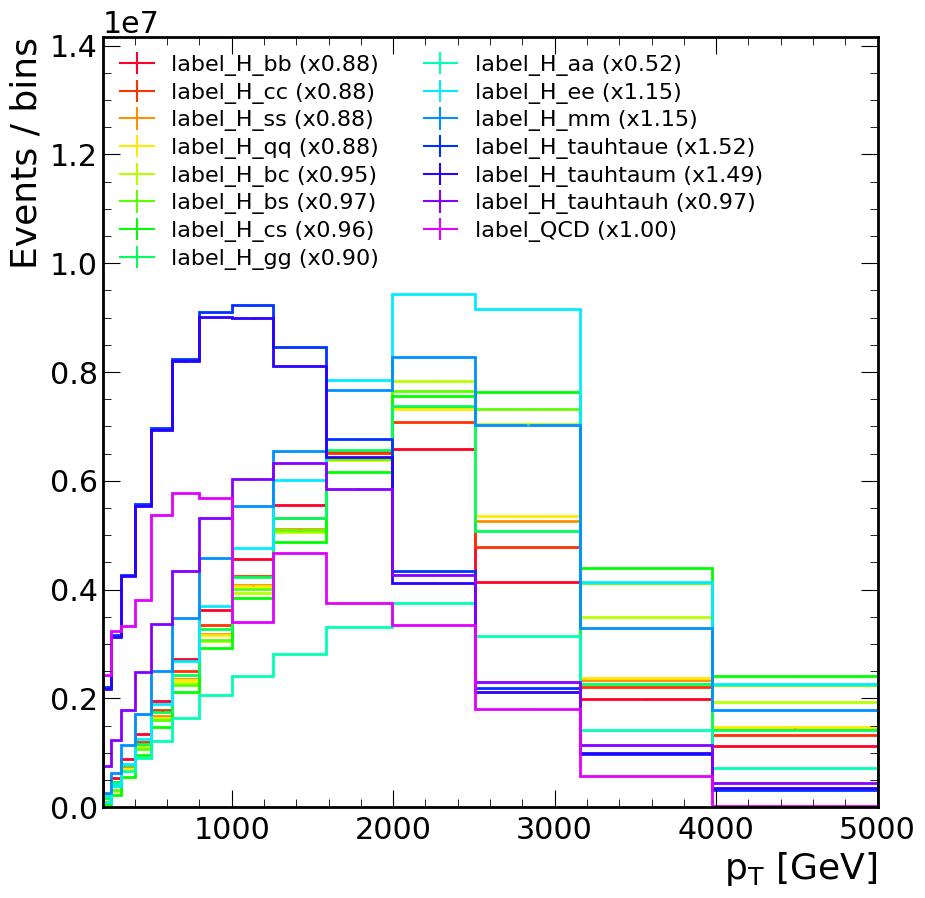

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the foll

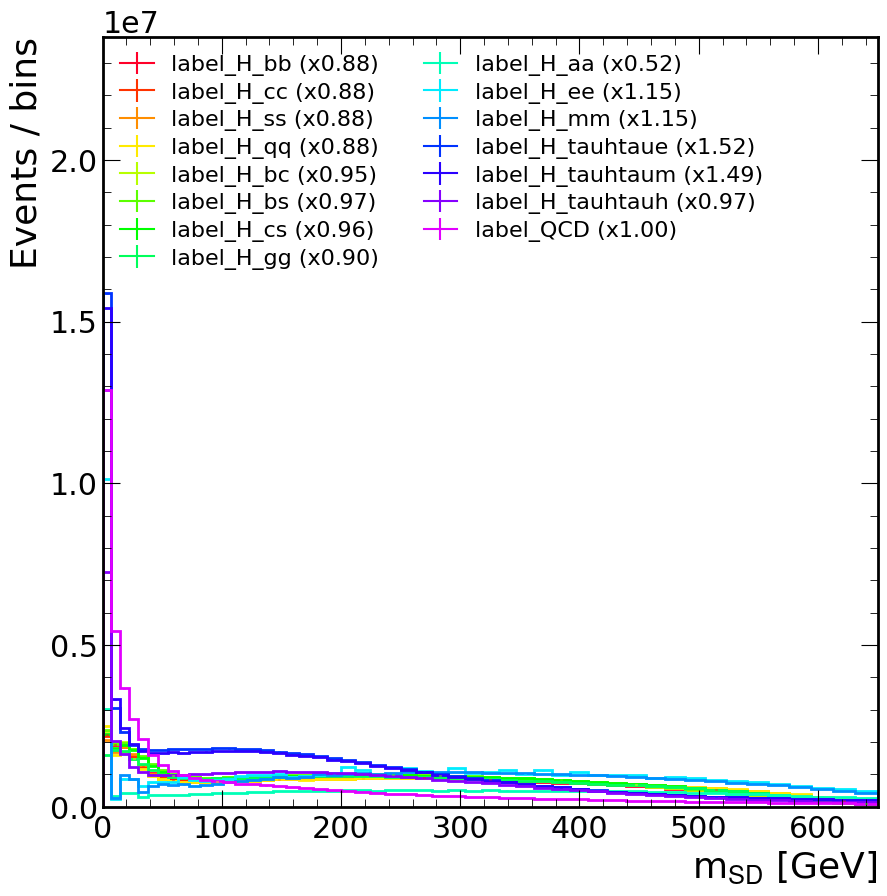

In [26]:
for p in range(2):
    if p == 0:
        nbin=bh.axis.Variable(np.logspace(np.log10(200), np.log10(5000), 15)); xmin=200; xmax=5000; xlabel=r'$p_T$ [GeV]'; axis=1
    elif p == 1:
        nbin=bh.axis.Variable([0, 7.1, 14.5, 22.1, 29.9, 38.0, 46.3, 54.9, 63.7, 72.7, 82.0, 91.5, 101.3, 111.3, 121.5, 132.0, 142.7, 153.7, 164.9, 176.3, 188.0, 199.9, 212.1, 224.5, 237.1, 250.0, 263.1, 276.5, 290.1, 303.9, 318.0, 332.3, 346.9, 361.7, 376.7, 392.0, 407.5, 423.3, 439.3, 455.5, 472.0, 488.7, 505.7, 522.9, 540.3, 558.0, 575.9, 594.1, 612.5, 631.1, 650.0]); xmin=0; xmax=650; xlabel=r'$m_{\mathrm{SD}}$ [GeV]'; axis=0

    hist = bh.Histogram(bh.axis.Regular(nbin, xmin, xmax) if isinstance(nbin, int) else nbin, storage=bh.storage.Weight())

    # rg = range(len(labels))
    # rg = list(range(0, 13)) + [108] # Top
    rg = list(range(13, 27)) + [108] # H->2prong
    # rg = list(range(27, 34)) + [108] # HWW
    # rg = list(range(34, 41)) + [108] # HWxWx
    # rg = list(range(41, 48)) + [108] # HWxWxStar
    # rg = list(range(48, 62)) + [108] # HZZ
    # rg = list(range(62, 70)) + [108] # HZxZx
    # rg = list(range(70, 76)) + [108] # HZxZxStar
    # rg = list(range(76, 90)) + [108] # HZxZxStar
    # rg = list(range(90, 108)) + [108] # HV(aaXX)
    NUM_COLORS = len(rg)
    cm = plt.get_cmap('gist_rainbow')
    mpl.rcParams['axes.prop_cycle'] = cycler(color=[cm(1.*i/NUM_COLORS) for i in range(NUM_COLORS)])

    f, ax = plt.subplots(figsize=(10, 10))
    max = 0
    for i in rg:
        lab = labels[i]
        content = hists[lab].sum(axis=axis)
        content = content / class_weight[i]
        yerr = np.sqrt(content)
        # get always ratio of integral to last entry
        content_QCD = hists['label_QCD'].sum(axis=axis) / class_weight[labels.index('label_QCD')]
        ratio = content.sum() / content_QCD.sum()
        hep.histplot(content, bins=hist.axes[0].edges, yerr=yerr, label=lab+" (x{:.2f})".format(ratio), ax=ax, histtype='step', linewidth=2)
        max = np.maximum(max, content.max())
    ax.legend(loc='upper left', prop={'size': 16}, ncol=2, labelspacing=0.3, borderpad=0.3)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, max*1.5)
    # if p == 1:
    #     ax.set_ylim(0, 1e7)
    ax.set_xlabel(xlabel, ha='right', x=1.0); ax.set_ylabel('Events / bins', ha='right', y=1.0);